# KNHANES 2021–2024 임상 v19 집계 재현

이 노트북은 동결된 v19 OOF 원결과의 집계를 재현한다. 이후 감사 진단과 사후 비교는 별도 보충으로 표시하며 기존 44개 사전 대조를 바꾸지 않는다. 집계 JSON만 내장하고 원자료·개인별 예측·fold 인덱스는 포함하지 않는다.

In [1]:
import json, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
R=json.loads('{"version":"clinical_factorial_v19","scope":"KNHANES 2021-2024, ages 19-39, noninvasive current metabolic abnormality screening","n":4068,"years":{"2021":1039,"2022":1013,"2023":1010,"2024":1006},"labels":["high_glucose","high_blood_pressure","high_triglyceride","low_hdl"],"targets":["HE_glu","HE_sbp","HE_dbp","HE_TG","HE_HDL_st2"],"test_views":["clean","missing20_0","missing20_1","missing20_2","missing10","missing30","missing40","body_missing","behavior_missing","BMI_noise10","BMI_noise25","WC_noise10","WC_noise25"],"primary_condition":"EPF@basic_clean_native","interpretation":{"seed_mean":"Mean of three separately fitted seed metrics; predictions are not ensembled. LR and Ridge are seedless and repeated only to align paired comparisons.","factorial":"Fixed primary backbone configuration across eight conditions. OFAT and interactions are conditional effects, not evidence of independent optimality in each condition. No condition is selected by test performance.","LR_four_arms":"LR is separately fitted and C-selected on clean validation for basic/engineered x clean/paired20. The four-arm comparison and paired contrasts are prespecified; no test-best LR condition is selected.","calibration":"Common four-label monotone calibration precedes bounded any-event gamma. Gamma does not alter component probabilities or component AP. A positive component slope preserves ranking only within one fold and its fitted calibrator; a zero slope can create ties. Fold-specific calibrators can change cross-fold ranking and pooled OOF AP. Gamma can change between-person independent-risk ranking and any-event AP; neither change alone is evidence of EPF-specific structure.","screening":"90%/95% cutoffs selected independently for raw q0 and adjusted q on separate threshold role, fixed before test. Held-out ROC specificity at matched sensitivity is descriptive only.","outcome":"Four metabolic flags can co-occur; measured labs and blood pressure are targets only, not input features.","prior_exploration":"Same KNHANES 2021-2024 cohort and missingness masks were explored in v16/v18; this is a follow-up exploratory analysis, not independent validation."},"contrasts":{"primary_EPF_vs_MLP":{"coefficients":{"EPF@basic_clean_native":1,"MLP@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":-0.002656774511236082,"ci95":[-0.011400320283215378,0.0055725824400763395],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0005125800399908564,"ci95":[-0.0011330536249603306,0.00010425907477583944],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.007167920530172789,"ci95":[-0.015847603203167335,0.002013096233218379],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0063377942604890825,"ci95":[-0.014965597113774487,0.002299256710938399],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.00163248615929526,"ci95":[-0.003190086330374267,1.5788261331079652e-05],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0011841419398027101,"ci95":[-0.0019607301500175647,0.003107649660918476],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.01865094352461616,"ci95":[-0.04124085303066853,0.01648288547029178],"valid_replicates":2000}}},"primary_EPF_vs_LR":{"coefficients":{"EPF@basic_clean_native":1,"LR@basic_clean":-1},"metrics":{"component_macro_ap_difference":{"estimate":-0.01040992863465412,"ci95":[-0.0205556460969761,-0.0004327624438229865],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00019544946940161512,"ci95":[-0.0011174500906498941,0.0007380151170778698],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.006011287591846659,"ci95":[-0.015218858688271853,0.0034689887482891478],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.007561294461395196,"ci95":[-0.016479462588474627,0.0016320669841501216],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0005134819666469115,"ci95":[-0.0024164279139827667,0.0013749358222277016],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.004103967751196816,"ci95":[-0.004601334785243141,0.0061279090304181515],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.001341727073763288,"ci95":[-0.031584835988441494,0.02545843913639981],"valid_replicates":2000}}},"primary_EPF_vs_field_only":{"coefficients":{"EPF@basic_clean_native":1,"EPF_field_only@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0036238856704562394,"ci95":[-0.0006612424296047456,0.00785549391545972],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00023740135644395588,"ci95":[-7.245996718891756e-05,0.0005632539461773806],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0007983177182177004,"ci95":[-0.004775094674235064,0.003199798331592785],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0005480609674568537,"ci95":[-0.004769585616454339,0.003515353822871941],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-5.672565913600325e-05,"ci95":[-0.0008180848399298126,0.0007231040614889643],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.000490373149915348,"ci95":[-0.0013861396344755682,0.0014377090259768649],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.007348937492750396,"ci95":[-0.0047035481901052285,0.02257640606027181],"valid_replicates":2000}}},"factor/LR/basis/clean":{"coefficients":{"LR@engineered_clean":1,"LR@basic_clean":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0022031644962782204,"ci95":[-0.0037261813769205038,0.007821910225544923],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0007524611790336172,"ci95":[0.0001942490174169989,0.0013168074171933163],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.003062481386925109,"ci95":[-0.0030438177204212325,0.008888101163695549],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0021705194006707007,"ci95":[-0.004411987096202296,0.008464785690898481],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0023720335852754626,"ci95":[0.0007789052284632884,0.003909468672132393],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0009785991865936868,"ci95":[-0.0011659293903939821,0.0026369862171138],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.0157333514158835,"ci95":[-0.018676250241136297,0.053021358098483656],"valid_replicates":2000}}},"factor/LR/basis/paired20":{"coefficients":{"LR@engineered_paired20":1,"LR@basic_paired20":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.001906380984864231,"ci95":[-0.003941575465162872,0.007658912994170853],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0007267724174021967,"ci95":[0.00018554301794762273,0.0012606896475721788],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.004206666033611972,"ci95":[-0.0017204383053412182,0.010101804177948542],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.003846728999031268,"ci95":[-0.002292064757519266,0.01011509223531559],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0023435669843871743,"ci95":[0.0008535907377612006,0.0038352570031163383],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0010742479401912412,"ci95":[-0.0011800692763289935,0.0027361246219432776],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.025543374310744382,"ci95":[-0.01569731285878517,0.05260147349435195],"valid_replicates":2000}}},"factor/LR/augmentation/basic":{"coefficients":{"LR@basic_paired20":1,"LR@basic_clean":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0003890367848192189,"ci95":[-0.0036325192341019968,0.004085959265314403],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00018095709720546138,"ci95":[-0.0005421489307028376,0.00018074920215625364],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.005110122528954042,"ci95":[-0.009371778657737143,-0.0007970457985695075],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.005446106369483283,"ci95":[-0.009888676381044037,-0.0011618477184630457],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0018551995649298825,"ci95":[-0.0028030617889085903,-0.000904784119801695],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.00022659861791611904,"ci95":[-0.0012169749102574974,0.0014943656983403136],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.021108806513787548,"ci95":[-0.04909484566715357,0.005324812218552092],"valid_replicates":2000}}},"factor/LR/augmentation/engineered":{"coefficients":{"LR@engineered_paired20":1,"LR@engineered_clean":-1},"metrics":{"component_macro_ap_difference":{"estimate":9.225327340522949e-05,"ci95":[-0.004793575606050622,0.004350265282964345],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0002066458588368819,"ci95":[-0.0006228011941453844,0.00018433743106689588],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.003965937882267179,"ci95":[-0.008617214828432414,0.0006009321997074406],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.003769896771122716,"ci95":[-0.008667883901887394,0.0007819242191153974],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0018836661658181708,"ci95":[-0.002909245236331969,-0.0008615632673801754],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.00032224737151367346,"ci95":[-0.001126246369525222,0.001613540397085489],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.011298783618926667,"ci95":[-0.04935707512685815,0.012390112375403026],"valid_replicates":2000}}},"interaction/LR/basis_x_augmentation":{"coefficients":{"LR@engineered_paired20":1,"LR@engineered_clean":-1,"LR@basic_paired20":-1,"LR@basic_clean":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0002967835114139894,"ci95":[-0.003001737484991762,0.0023644816310806893],"valid_replicates":2000},"component_brier_improvement":{"estimate":-2.568876163142053e-05,"ci95":[-0.00018894903769224418,0.00013274652970175733],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0011441846466868633,"ci95":[-0.0010743906639750888,0.0033060867280620765],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0016762095983605674,"ci95":[-0.0007332633904724827,0.0038853704628701775],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-2.846660088828834e-05,"ci95":[-0.00038551048298886905,0.0003273326986497495],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":9.564875359755441e-05,"ci95":[-0.0004956384712245556,0.0005857075275748521],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.009810022894860881,"ci95":[-0.031086911497439165,0.033149654123315414],"valid_replicates":2000}}},"factor/EPF/basis/clean/native":{"coefficients":{"EPF@engineered_clean_native":1,"EPF@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0026148680286724457,"ci95":[-0.003759005056421895,0.010118522113278587],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0004889382603952969,"ci95":[-3.778445140401564e-05,0.0009931250688550912],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.007990603309794175,"ci95":[0.0011456677618917666,0.014698313971750053],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.007543614808083077,"ci95":[0.0008813152679866016,0.014055275321220598],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0013025946935658061,"ci95":[-0.00014078269517145067,0.0027117044189365197],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0005542221077870025,"ci95":[-0.0022327952923678167,0.0014837441668852287],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.002689877186810352,"ci95":[-0.02421480429519443,0.023728240233346774],"valid_replicates":2000}}},"factor/EPF/basis/clean/linear_anchor":{"coefficients":{"EPF@engineered_clean_linear_anchor":1,"EPF@basic_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0063721480356954685,"ci95":[0.0007365021392313945,0.011460606925916002],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0007433250241979245,"ci95":[0.0002228070596948767,0.0012246408363179668],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0031936758149052613,"ci95":[-0.0020188934505106617,0.008561601443196355],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0023926169836292477,"ci95":[-0.0027873436411229914,0.007522507962325689],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0019138852405955198,"ci95":[0.000659049968279666,0.0031558971907035428],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.001973957803587653,"ci95":[-0.0018144305658158205,0.0034893013356260497],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.004279516422710294,"ci95":[-0.013328762184300428,0.03312191547889212],"valid_replicates":2000}}},"factor/EPF/basis/paired20/native":{"coefficients":{"EPF@engineered_paired20_native":1,"EPF@basic_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.000868092245118357,"ci95":[-0.0056701108431806545,0.008070423609643248],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0005303784226623198,"ci95":[4.721604823547805e-05,0.0010290295812073608],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.006879188130884839,"ci95":[0.0003668821354194108,0.013206225004338221],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.008917260591620013,"ci95":[0.002537432605632653,0.014856756788150523],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0021111933915267667,"ci95":[0.000788439773448342,0.0034051681631151534],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.00402622926067241,"ci95":[-0.003884078858103734,0.005587793082703696],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.010682840062993082,"ci95":[-0.010588068869969321,0.02661742179058275],"valid_replicates":2000}}},"factor/EPF/basis/paired20/linear_anchor":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@basic_paired20_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.006384494776462857,"ci95":[-0.00024344077411247856,0.012223702876240148],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0008610097816929285,"ci95":[0.0003075262979893006,0.0013967209133837865],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.005409816207604612,"ci95":[-0.001345305599369928,0.012094267381520819],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0040438155600672765,"ci95":[-0.002624322228532286,0.010524381174986875],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0019464025283484343,"ci95":[0.0006660769617601876,0.003157424377063044],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.002531501555431746,"ci95":[-0.002425926455626392,0.003928304395079508],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.0038185102198854404,"ci95":[-0.01653186890460764,0.031905896965382534],"valid_replicates":2000}}},"factor/EPF/augmentation/basic/native":{"coefficients":{"EPF@basic_paired20_native":1,"EPF@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0029191596328476677,"ci95":[-0.0027342695906997978,0.007940594280818794],"valid_replicates":2000},"component_brier_improvement":{"estimate":2.0414501445312205e-05,"ci95":[-0.00036179372811324104,0.00038643067637413443],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.001376855563340329,"ci95":[-0.006213390935873336,0.0036364768789850024],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0025235597537781596,"ci95":[-0.007427745357686077,0.0025782038932535773],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0009620420611458069,"ci95":[-0.00214509268923672,8.244003053241484e-05],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.004181815853097229,"ci95":[-0.00565301418965713,0.0042943504120113345],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.01202106196753816,"ci95":[-0.028311474222915984,0.005686961450302967],"valid_replicates":2000}}},"factor/EPF/augmentation/basic/linear_anchor":{"coefficients":{"EPF@basic_paired20_linear_anchor":1,"EPF@basic_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0002119698294255623,"ci95":[-0.005298074169681179,0.004389920554176631],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00035220181066765444,"ci95":[-0.0008038284467153728,7.80303813728219e-05],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.00628900275459543,"ci95":[-0.01171210192716093,-0.0008527833310941514],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0058165055216408135,"ci95":[-0.011857878512446626,-0.00010771357718364519],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0017627180164443146,"ci95":[-0.002797607868658473,-0.0007468103813223292],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0002397134837093598,"ci95":[-0.001163104287047706,0.0015625999540104004],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.0049203551915300014,"ci95":[-0.028845592892008654,0.015758894157449393],"valid_replicates":2000}}},"factor/EPF/augmentation/engineered/native":{"coefficients":{"EPF@engineered_paired20_native":1,"EPF@engineered_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.001172383849293579,"ci95":[-0.0035629555408207823,0.005856039370284704],"valid_replicates":2000},"component_brier_improvement":{"estimate":6.185466371233517e-05,"ci95":[-0.00029535750843674225,0.00040473482467128457],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0024882707422496653,"ci95":[-0.007835250730871362,0.00276646466280988],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.001149913970241223,"ci95":[-0.00641830947645923,0.0040161506421672565],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.00015344336318484642,"ci95":[-0.0012442544585703145,0.0008889598184371266],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0003986355153621831,"ci95":[-0.001096172544981845,0.001681707114385533],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.00402809909135543,"ci95":[-0.0220705452225983,0.016992178077370558],"valid_replicates":2000}}},"factor/EPF/augmentation/engineered/linear_anchor":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@engineered_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":-0.00019962308865817402,"ci95":[-0.005605703531685656,0.0045259304662699455],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00023451705317265037,"ci95":[-0.0006767283478174863,0.0001740842005221147],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.004072862361896079,"ci95":[-0.009089309331662998,0.0007755485875377246],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.004165306945202785,"ci95":[-0.009130433401733768,0.0005113069833465721],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0017302007286914,"ci95":[-0.002803109168924125,-0.0007232199312368282],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0007972572355534526,"ci95":[-0.00123120752709693,0.0020937975115626548],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.0053813613943548555,"ci95":[-0.031951421661540816,0.015437957391993627],"valid_replicates":2000}}},"factor/EPF/initialization/basic/clean":{"coefficients":{"EPF@basic_clean_linear_anchor":1,"EPF@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.008518055510447153,"ci95":[0.0010716558055623548,0.01698063768311125],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0006073292890419746,"ci95":[-7.176362124092784e-05,0.0013093696506334869],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.008415461220245946,"ci95":[0.0009588867422621078,0.015537929978109774],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.009270001126128413,"ci95":[0.0022118966812974374,0.01643681636720756],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0014595040973550688,"ci95":[-5.507807342588696e-05,0.003005583432046891],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.004804490188865393,"ci95":[-0.006317374670326343,0.005098329236579467],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.012788936421951003,"ci95":[-0.009858648430525854,0.03621102745139861],"valid_replicates":2000}}},"factor/EPF/initialization/basic/paired20":{"coefficients":{"EPF@basic_paired20_linear_anchor":1,"EPF@basic_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.005386926048173923,"ci95":[-0.003444196251816127,0.015464453478438816],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00023471297692900794,"ci95":[-0.0006061655808006879,0.0010497766039379666],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.003503314028990845,"ci95":[-0.005501665652809762,0.012268111858828043],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.005977055358265759,"ci95":[-0.003489721991634273,0.015107772452553838],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0006588281420565612,"ci95":[-0.0009851707501714892,0.0023107354323688508],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0003829608520588036,"ci95":[-0.0021306244967471853,0.001494829023837313],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.01988964319795916,"ci95":[-0.0056782928645264805,0.04097269823791423],"valid_replicates":2000}}},"factor/EPF/initialization/engineered/clean":{"coefficients":{"EPF@engineered_clean_linear_anchor":1,"EPF@engineered_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.012275335517470176,"ci95":[0.004797561989294856,0.02027126373328683],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0008617160528446022,"ci95":[0.00018528654390319692,0.0015516651889548557],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0036185337253570315,"ci95":[-0.003841726914958277,0.011173675183760301],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.004119003301674584,"ci95":[-0.002878098717620206,0.011673699482071602],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0020707946443847824,"ci95":[0.00045480100631094256,0.0036847362370536],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.002276310277490737,"ci95":[-0.004166163514711434,0.003073506729337114],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.014378575657850945,"ci95":[-0.008155356681519444,0.054869647444386056],"valid_replicates":2000}}},"factor/EPF/initialization/engineered/paired20":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@engineered_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.010903328579518423,"ci95":[0.0027401299471685263,0.019196691682087354],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0005653443359596166,"ci95":[-0.00011733635406921891,0.0012658422735266535],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0020339421057106177,"ci95":[-0.005756124318341124,0.009791655496108045],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0011036103267130226,"ci95":[-0.006804781529640222,0.009057385862286382],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0004940372788782288,"ci95":[-0.0011819539444246096,0.0021496216472969543],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0018776885572994676,"ci95":[-0.003789395702050642,0.002714395809401033],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.01302531335485152,"ci95":[-0.011436055410022992,0.04562863701172633],"valid_replicates":2000}}},"interaction/EPF/basis_x_augmentation/native":{"coefficients":{"EPF@engineered_paired20_native":1,"EPF@engineered_clean_native":-1,"EPF@basic_paired20_native":-1,"EPF@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0017467757835540887,"ci95":[-0.00701055311889673,0.003903947226060205],"valid_replicates":2000},"component_brier_improvement":{"estimate":4.144016226702296e-05,"ci95":[-0.0003225338308371278,0.0004201974957407678],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0011114151789093363,"ci95":[-0.006599763333712899,0.00415096606396402],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0013736457835369364,"ci95":[-0.00425116352015148,0.006668290192746703],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0008085986979609605,"ci95":[-0.00020909937489337478,0.001842187353272697],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.004580451368459412,"ci95":[-0.004628848296472527,0.005918379436901614],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.00799296287618273,"ci95":[-0.013813194806603448,0.032428939064666006],"valid_replicates":2000}}},"interaction/EPF/basis_x_augmentation/linear_anchor":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@engineered_clean_linear_anchor":-1,"EPF@basic_paired20_linear_anchor":-1,"EPF@basic_clean_linear_anchor":1},"metrics":{"component_macro_ap_difference":{"estimate":1.2346740767388287e-05,"ci95":[-0.0039858155802483435,0.0035502174392790546],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00011768475749500407,"ci95":[-0.0001905054722124596,0.00041659619267666914],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0022161403926993506,"ci95":[-0.0017360558502955896,0.006070732883025798],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0016511985764380288,"ci95":[-0.0025236941500506316,0.005966593335599178],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":3.2517287752914514e-05,"ci95":[-0.0005671464333238715,0.0006320912538774466],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0005575437518440928,"ci95":[-0.0008569162670387482,0.001243003249328844],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.00046100620282485405,"ci95":[-0.02398321585941341,0.019503896770628967],"valid_replicates":2000}}},"interaction/EPF/basis_x_initialization/clean":{"coefficients":{"EPF@engineered_clean_linear_anchor":1,"EPF@engineered_clean_native":-1,"EPF@basic_clean_linear_anchor":-1,"EPF@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":0.0037572800070230228,"ci95":[-0.003918868296444197,0.01022142109450745],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0002543867638026276,"ci95":[-0.0002935050818461241,0.0007901871555948815],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.004796927494888914,"ci95":[-0.011317226665588037,0.0016918179685565388],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.005150997824453829,"ci95":[-0.01157872038365535,0.0013465280312369243],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0006112905470297136,"ci95":[-0.0008532144577700927,0.002100375417578815],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0025281799113746556,"ci95":[-0.0027032874755092634,0.004457749900746542],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.0015896392358999423,"ci95":[-0.01846366466730257,0.03861963173466423],"valid_replicates":2000}}},"interaction/EPF/basis_x_initialization/paired20":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@engineered_paired20_native":-1,"EPF@basic_paired20_linear_anchor":-1,"EPF@basic_paired20_native":1},"metrics":{"component_macro_ap_difference":{"estimate":0.0055164025313445,"ci95":[-0.003123920566819945,0.013040207099646277],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0003306313590306087,"ci95":[-0.0002704753490445948,0.0009024411131735518],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0014693719232802271,"ci95":[-0.009161288458457355,0.006413051055949203],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.004873445031552737,"ci95":[-0.012525824003644817,0.0028280131762743184],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.00016479086317833236,"ci95":[-0.0016894706117014469,0.0012961318689958773],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.001494727705240664,"ci95":[-0.0031606630104929795,0.0027160913377316425],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.006864329843107642,"ci95":[-0.027781338553492557,0.028946029022409756],"valid_replicates":2000}}},"interaction/EPF/augmentation_x_initialization/basic":{"coefficients":{"EPF@basic_paired20_linear_anchor":1,"EPF@basic_paired20_native":-1,"EPF@basic_clean_linear_anchor":-1,"EPF@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.00313112946227323,"ci95":[-0.009004648549480519,0.002941837747030884],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00037261631211296664,"ci95":[-0.0008302934985321839,6.642184050477157e-05],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.004912147191255101,"ci95":[-0.011011013195056731,0.0010766244044085728],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.003292945767862654,"ci95":[-0.009900579068136402,0.0031009728989228073],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0008006759552985077,"ci95":[-0.0019428054546987157,0.0003862420213224096],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.004421529336806589,"ci95":[-0.004583649135738922,0.005697788096132011],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.007100706776008159,"ci95":[-0.02052609506076825,0.03072720617768104],"valid_replicates":2000}}},"interaction/EPF/augmentation_x_initialization/engineered":{"coefficients":{"EPF@engineered_paired20_linear_anchor":1,"EPF@engineered_paired20_native":-1,"EPF@engineered_clean_linear_anchor":-1,"EPF@engineered_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.001372006937951753,"ci95":[-0.005812546832911337,0.0028719349842135215],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00029637171688498554,"ci95":[-0.000636405542059687,3.570083207861913e-05],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0015845916196464138,"ci95":[-0.006097563411067,0.0025246172710515755],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0030153929749615616,"ci95":[-0.007349910046967384,0.0010484596036044382],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0015767573655065537,"ci95":[-0.002418566511840093,-0.0007552098830712384],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0003986217201912695,"ci95":[-0.001166552012489787,0.001485384020111839],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.001353262302999425,"ci95":[-0.03214135043713145,0.02139516825546739],"valid_replicates":2000}}},"factor/MLP/basis/clean/native":{"coefficients":{"MLP@engineered_clean_native":1,"MLP@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0009220188389031381,"ci95":[-0.006360022586027242,0.0077246617777676305],"valid_replicates":2000},"component_brier_improvement":{"estimate":-4.57720190549793e-06,"ci95":[-0.0005602500490302111,0.0005188061876589558],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":1.877183531040494e-05,"ci95":[-0.00740235909356691,0.0081731933193338],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0002651280863300576,"ci95":[-0.007660429843807387,0.007743401049289786],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0003917465377516194,"ci95":[-0.0009789105990707348,0.0018277771528814406],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0031038407780343384,"ci95":[-0.0044810008112589105,0.0032736629720767174],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.03608410547798857,"ci95":[-0.058196917358432645,0.0026836970877135917],"valid_replicates":2000}}},"factor/MLP/basis/clean/linear_anchor":{"coefficients":{"MLP@engineered_clean_linear_anchor":1,"MLP@basic_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.003825928552928737,"ci95":[-0.0013621364423120647,0.009151216342246905],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0006788248737098351,"ci95":[0.00016717138609157468,0.0011942266542114832],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.003686636696349499,"ci95":[-0.0019551593121663047,0.009225660154055087],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.003437494030117061,"ci95":[-0.002420678064729834,0.008892050560013944],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0018593913642034332,"ci95":[0.00048712241187854195,0.003211955200864686],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-2.485772075743256e-05,"ci95":[-0.001503357319408538,0.0015371728486912593],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.000490620766073202,"ci95":[-0.024187754002202758,0.0373438430879707],"valid_replicates":2000}}},"factor/MLP/basis/paired20/native":{"coefficients":{"MLP@engineered_paired20_native":1,"MLP@basic_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0005257751727851812,"ci95":[-0.006187212480357716,0.0065017079351015195],"valid_replicates":2000},"component_brier_improvement":{"estimate":1.7387783166664117e-05,"ci95":[-0.00045974197152741993,0.0004806955698737066],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.001176003416541116,"ci95":[-0.0052947337858449016,0.00810331941035036],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0010561905491329737,"ci95":[-0.005428711325292987,0.008195530889126675],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0003384385380301447,"ci95":[-0.0009627743648352206,0.0016633732159303692],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0015112520629730827,"ci95":[-0.0027302614202629224,0.0020666029748400297],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.03598558731082918,"ci95":[-0.05776516658689833,0.002079264222657704],"valid_replicates":2000}}},"factor/MLP/basis/paired20/linear_anchor":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@basic_paired20_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.004101223803488319,"ci95":[-0.001491913586608741,0.009550265071581117],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.000697516355120123,"ci95":[0.00019609242803337175,0.00120495619274411],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.004627821034537627,"ci95":[-0.0011159133131096203,0.01012417839729426],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.004979990343816798,"ci95":[-0.0011818038236176636,0.010779069564902797],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0018308739830515952,"ci95":[0.0004067531773649248,0.0032120020244964086],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0003874958738016021,"ci95":[-0.0018089992845545173,0.0014148003704616053],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.01240892180687403,"ci95":[-0.016302025249199006,0.03120981447848934],"valid_replicates":2000}}},"factor/MLP/augmentation/basic/native":{"coefficients":{"MLP@basic_paired20_native":1,"MLP@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.003139167575800572,"ci95":[-0.0012880368114272234,0.007587670828576124],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00016652146679066449,"ci95":[-0.00014171959697879924,0.0004830411953849911],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0004237306786190054,"ci95":[-0.004620334399458503,0.003820379767075555],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0009255532609770967,"ci95":[-0.00511527527635765,0.0032499783924547763],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0005407947493344389,"ci95":[-0.0014219341649321948,0.00029317156673372923],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0005430551138910188,"ci95":[-0.0011540147894730127,0.001677407638266083],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.009537340108018655,"ci95":[-0.031604939761146277,0.008941674563249149],"valid_replicates":2000}}},"factor/MLP/augmentation/basic/linear_anchor":{"coefficients":{"MLP@basic_paired20_linear_anchor":1,"MLP@basic_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0006047137181269258,"ci95":[-0.003593181553919586,0.004318050695339352],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0001342595861857504,"ci95":[-0.000519039150527182,0.000242416295398449],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.00445889040435965,"ci95":[-0.008825345260227057,9.883454946138378e-05],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.004842070275100863,"ci95":[-0.009579612546959345,-0.00014987556329490066],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0016446984668252174,"ci95":[-0.0026562599503377133,-0.000621658731305361],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0006318619561058326,"ci95":[-0.0012149597025745433,0.001897092809801583],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.01799957601748947,"ci95":[-0.03269665161483226,0.010181558984631594],"valid_replicates":2000}}},"factor/MLP/augmentation/engineered/native":{"coefficients":{"MLP@engineered_paired20_native":1,"MLP@engineered_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0027429239096826152,"ci95":[-0.0025236347324374088,0.0079127697162262],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00018848645186282653,"ci95":[-0.0001848737235631448,0.0005543707533563244],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0007335009026117056,"ci95":[-0.004312099943301753,0.005323747134140068],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.00039576537448593463,"ci95":[-0.004640459546815548,0.004928948159788287],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0005941027490559136,"ci95":[-0.001777244024584585,0.0005164659138981929],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0021356438289522744,"ci95":[-0.0022053109137612735,0.003507972187245395],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.009438821940859266,"ci95":[-0.0330323943236354,0.015506481507574815],"valid_replicates":2000}}},"factor/MLP/augmentation/engineered/linear_anchor":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@engineered_clean_linear_anchor":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0008800089686865076,"ci95":[-0.004120082577982331,0.005056263685861946],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00011556810477546253,"ci95":[-0.0005299617273040555,0.0002833392749179655],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.003517706066171522,"ci95":[-0.008242047759022583,0.0012609699851846205],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0032995739614011255,"ci95":[-0.00829172694068478,0.0014562629285848816],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0016732158479770554,"ci95":[-0.002714483548603619,-0.0006802665542199393],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.00026922380306166303,"ci95":[-0.0011281303092511594,0.0015413127182004067],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.006081274976688644,"ci95":[-0.03646531385051398,0.012337077680548253],"valid_replicates":2000}}},"factor/MLP/initialization/basic/clean":{"coefficients":{"MLP@basic_clean_linear_anchor":1,"MLP@basic_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.006239313043075068,"ci95":[-0.0024867935353512865,0.015497369906864207],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00016952539899012242,"ci95":[-0.0008751334034840894,0.0005842161374405766],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.0015445375202480793,"ci95":[-0.009319540425834499,0.00642265155797446],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-4.791068158815914e-05,"ci95":[-0.007603608604129031,0.007550344217206388],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0006318661082755084,"ci95":[-0.002141821466552985,0.0009984391854197512],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0018195912743129879,"ci95":[-0.0037079673539845747,0.002197479349464907],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.007701021893738447,"ci95":[-0.03436716242341533,0.023537606589385297],"valid_replicates":2000}}},"factor/MLP/initialization/basic/paired20":{"coefficients":{"MLP@basic_paired20_linear_anchor":1,"MLP@basic_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.0037048591854014212,"ci95":[-0.005549303901529602,0.01289688161303458],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0004703064519665373,"ci95":[-0.0011233622750946005,0.00020654409088834657],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.005579697245988724,"ci95":[-0.012908248680622802,0.0028499007136341585],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.003964427695711925,"ci95":[-0.010876759418093193,0.003816392309231914],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0017357698257662868,"ci95":[-0.0031361197969596807,-0.00020302166705737896],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.001730784432098174,"ci95":[-0.0034904526338706133,0.002192507791290432],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.016163257803209263,"ci95":[-0.036682152963023254,0.021072328476363582],"valid_replicates":2000}}},"factor/MLP/initialization/engineered/clean":{"coefficients":{"MLP@engineered_clean_linear_anchor":1,"MLP@engineered_clean_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.009143222757100666,"ci95":[0.0006224910551922495,0.018563567367534787],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0005138766766252106,"ci95":[-0.00020969507709571144,0.001265963992227391],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.0021233273407910147,"ci95":[-0.0068416904881022315,0.010209408826193127],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0036547114348589593,"ci95":[-0.004358253952132629,0.010460731307774354],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0008357787181763054,"ci95":[-0.0005427780106500447,0.002358397605419638],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.001259391782963918,"ci95":[-0.0015073287164056497,0.003130256091233533],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.028873704350323326,"ci95":[-0.001742263838457929,0.06301122689943978],"valid_replicates":2000}}},"factor/MLP/initialization/engineered/paired20":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@engineered_paired20_native":-1},"metrics":{"component_macro_ap_difference":{"estimate":0.007280307816104559,"ci95":[-0.001987027521685161,0.016673148762834846],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00020982211998692157,"ci95":[-0.0004958112239289786,0.0009074469938697216],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.002127879627992213,"ci95":[-0.011413324190921198,0.006284829937176106],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-4.0627901028100766e-05,"ci95":[-0.008629073887340601,0.0077437273831670985],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.00024333438074483627,"ci95":[-0.0017443401916458954,0.0013267148843875028],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0006070282429266934,"ci95":[-0.0023403220657220187,0.001389808512287585],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.03223125131449395,"ci95":[-0.004279096823361491,0.059911195974504894],"valid_replicates":2000}}},"interaction/MLP/basis_x_augmentation/native":{"coefficients":{"MLP@engineered_paired20_native":1,"MLP@engineered_clean_native":-1,"MLP@basic_paired20_native":-1,"MLP@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0003962436661179569,"ci95":[-0.0050782037504386035,0.004329697451494853],"valid_replicates":2000},"component_brier_improvement":{"estimate":2.1964985072162047e-05,"ci95":[-0.0002488150040241714,0.00028859498714013925],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.001157231581230711,"ci95":[-0.0027317111791148483,0.0048536150886328054],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0013213186354630313,"ci95":[-0.0025087132515840493,0.005052729911587159],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-5.330799972147471e-05,"ci95":[-0.0009022425082541953,0.0007501228329295233],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0015925887150612557,"ci95":[-0.0015698467120189227,0.0026893014819776143],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":9.851816715938932e-05,"ci95":[-0.027550427861307118,0.02937047128944605],"valid_replicates":2000}}},"interaction/MLP/basis_x_augmentation/linear_anchor":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@engineered_clean_linear_anchor":-1,"MLP@basic_paired20_linear_anchor":-1,"MLP@basic_clean_linear_anchor":1},"metrics":{"component_macro_ap_difference":{"estimate":0.0002752952505595818,"ci95":[-0.002361853087272453,0.002616594630387055],"valid_replicates":2000},"component_brier_improvement":{"estimate":1.869148141028787e-05,"ci95":[-0.00015259543967895383,0.0001788495236259256],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.000941184338188128,"ci95":[-0.0013229774030289686,0.0031436071114063807],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0015424963136997372,"ci95":[-0.0009669466268212245,0.003917797110289166],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-2.8517381151837995e-05,"ci95":[-0.0004364242079016985,0.0003848967072214861],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.00036263815304416955,"ci95":[-0.0008788798338638131,0.000598472688423159],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.011918301040800827,"ci95":[-0.026939884014345127,0.02749238702049211],"valid_replicates":2000}}},"interaction/MLP/basis_x_initialization/clean":{"coefficients":{"MLP@engineered_clean_linear_anchor":1,"MLP@engineered_clean_native":-1,"MLP@basic_clean_linear_anchor":-1,"MLP@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":0.0029039097140255987,"ci95":[-0.004494652135236482,0.010327565449641814],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0006834020756153331,"ci95":[0.00016835556486666584,0.0011779714063574586],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.003667864861039094,"ci95":[-0.003083850465385593,0.009600218126789985],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0037026221164471185,"ci95":[-0.0031544693197789603,0.009793694663004856],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0014676448264518138,"ci95":[0.00023810777368976494,0.0026230838226855785],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.003078983057276906,"ci95":[-0.0030207704414005844,0.0044555631389228975],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.03657472624406177,"ci95":[0.0011633268441914536,0.06902865253650127],"valid_replicates":2000}}},"interaction/MLP/basis_x_initialization/paired20":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@engineered_paired20_native":-1,"MLP@basic_paired20_linear_anchor":-1,"MLP@basic_paired20_native":1},"metrics":{"component_macro_ap_difference":{"estimate":0.0035754486307031375,"ci95":[-0.003597036992811317,0.010470875924829204],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0006801285719534589,"ci95":[0.0001507493048957434,0.0011677318387580378],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":0.003451817617996511,"ci95":[-0.0031782299144815424,0.009172835612949322],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.003923799794683824,"ci95":[-0.0027386898015260342,0.00974432498854931],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0014924354450214505,"ci95":[0.00014665213413027486,0.0027683443861620327],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":0.0011237561891714806,"ci95":[-0.001725059877237542,0.0025874461708468776],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.04839450911770321,"ci95":[0.002890307159059997,0.06804562561787661],"valid_replicates":2000}}},"interaction/MLP/augmentation_x_initialization/basic":{"coefficients":{"MLP@basic_paired20_linear_anchor":1,"MLP@basic_paired20_native":-1,"MLP@basic_clean_linear_anchor":-1,"MLP@basic_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0025344538576736464,"ci95":[-0.006741491358215536,0.001226189038883072],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0003007810529764149,"ci95":[-0.0006125157511128566,7.000777042649355e-06],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.004035159725740645,"ci95":[-0.007895477540637536,-8.323482002823453e-05],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.003916517014123766,"ci95":[-0.008037763504754191,0.00034424778759985426],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0011039037174907784,"ci95":[-0.0019447664957632296,-0.0003004453585734168],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":8.880684221481382e-05,"ci95":[-0.0008968594977393332,0.001261236100576865],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":-0.008462235909470817,"ci95":[-0.027062568796722343,0.023728551438748424],"valid_replicates":2000}}},"interaction/MLP/augmentation_x_initialization/engineered":{"coefficients":{"MLP@engineered_paired20_linear_anchor":1,"MLP@engineered_paired20_native":-1,"MLP@engineered_clean_linear_anchor":-1,"MLP@engineered_clean_native":1},"metrics":{"component_macro_ap_difference":{"estimate":-0.0018629149409961077,"ci95":[-0.007244453816118,0.0024353301465077047],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.00030405455663828906,"ci95":[-0.0006708194242615925,4.5264026115498116e-05],"valid_replicates":2000},"raw_any_ap_difference":{"estimate":-0.004251206968783228,"ci95":[-0.008459609805690233,0.00011076044717755938],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.00369533933588706,"ci95":[-0.008139614566600294,0.0008023643174246526],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0010791130989211417,"ci95":[-0.002044370088715356,-7.128706703853135e-05],"valid_replicates":2000},"adjusted_any_gap_abs_improvement":{"estimate":-0.0018664200258906114,"ci95":[-0.002953317259545978,0.0018054905787377618],"valid_replicates":2000},"matched95_specificity_difference":{"estimate":0.0033575469641706213,"ci95":[-0.03501794690475313,0.028978312779926896],"valid_replicates":2000}}}},"uncertainty":{"replicates_requested":2000,"survey":{"full_frame_psus":768,"domain_psus":699,"strata":108,"singleton_strata":0,"method":"n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"},"scope":"Paired full-frame PSU bootstrap of fixed OOF predictions, conditional on fitted models","limitations":"No full retraining uncertainty, multiplicity correction, external cohort, or independent confirmation","reuse":"Follow-up exploratory study reusing KNHANES 2021-2024 cohort, missingness masks, and prior v16/v18 exploration","contrast_design":"Primary and factorial OFAT/interaction contrasts were fixed before test analysis. Neural factorial arms keep their selected base configuration and do not establish independent per-arm optimality. Each LR basis/augmentation arm selects C separately on clean validation; no test-based selection."},"models":{"EPF@basic_clean_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.34686037892501725,"macro_brier":0.1076048905424133,"macro_nll":0.3522625411144706,"per_label":[{"ap":0.34786553930112335,"auc":0.7815997482253646,"brier":0.097709998305774,"nll":0.3245709603876275,"observed_rate":0.12882212778159,"predicted_mean":0.12794949490615742,"mean_risk_gap":-0.0008726328754325626,"absolute_mean_risk_gap":0.0010756502319163401},{"ap":0.25221262103238384,"auc":0.7417241097869077,"brier":0.08465873095310657,"nll":0.29508334021645904,"observed_rate":0.10103151922765924,"predicted_mean":0.11983315919882342,"mean_risk_gap":0.018801639971164175,"absolute_mean_risk_gap":0.018801639971164175},{"ap":0.4272181747536883,"auc":0.7947239570398433,"brier":0.12621616380908537,"nll":0.39564735206788354,"observed_rate":0.18656404964936124,"predicted_mean":0.18633203475696428,"mean_risk_gap":-0.0002320148923969645,"absolute_mean_risk_gap":0.0007685480580529961},{"ap":0.36014518061287343,"auc":0.7428267751748351,"brier":0.12183466910168726,"nll":0.39374851178591214,"observed_rate":0.1638444509303705,"predicted_mean":0.16754702176655187,"mean_risk_gap":0.0037025708361813348,"absolute_mean_risk_gap":0.0037025708361813348}]},"raw_any":{"ap":0.6865783509706774,"auc":0.7840152532838293,"brier":0.1829757290858202,"nll":0.5466807832853431,"observed_rate":0.3799226528155136,"predicted_mean":0.4290340727672383,"mean_risk_gap":0.049111419951724765,"absolute_mean_risk_gap":0.049111419951724765},"adjusted_any":{"ap":0.6815705353097,"auc":0.7824490592806289,"brier":0.18097363783647072,"nll":0.5413419498134587,"observed_rate":0.3799226528155136,"predicted_mean":0.38769608940973677,"mean_risk_gap":0.007773436594223175,"absolute_mean_risk_gap":0.007773436594223175}},"missing20":{"components":{"macro_ap":0.292565856317676,"macro_brier":0.11445668368514829,"macro_nll":0.37662575311109203,"per_label":[{"ap":0.28396478542445136,"auc":0.7295835237605941,"brier":0.10374742538214506,"nll":0.3466254325848968,"observed_rate":0.12882212778159,"predicted_mean":0.13727870821859436,"mean_risk_gap":0.008456580437004374,"absolute_mean_risk_gap":0.011459158794077108},{"ap":0.21317433058035995,"auc":0.6966070622754233,"brier":0.08807048828129935,"nll":0.3094603069756088,"observed_rate":0.10103151922765924,"predicted_mean":0.12688357626450764,"mean_risk_gap":0.025852057036848414,"absolute_mean_risk_gap":0.025852057036848414},{"ap":0.36978445561790796,"auc":0.7299231623493667,"brier":0.13621277123216335,"nll":0.42962996306830725,"observed_rate":0.18656404964936124,"predicted_mean":0.1845615614253274,"mean_risk_gap":-0.0020024882240338407,"absolute_mean_risk_gap":0.009641406592960557},{"ap":0.30333985364798477,"auc":0.6789365338775676,"brier":0.12979604984498538,"nll":0.4207873098155551,"observed_rate":0.1638444509303705,"predicted_mean":0.18390265096542546,"mean_risk_gap":0.02005820003505499,"absolute_mean_risk_gap":0.02005820003505499}]},"raw_any":{"ap":0.6102561385204517,"auc":0.717573685968598,"brier":0.21096719975150469,"nll":0.6103183493667235,"observed_rate":0.3799226528155136,"predicted_mean":0.4605519712877623,"mean_risk_gap":0.08062931847224873,"absolute_mean_risk_gap":0.08062931847224873},"adjusted_any":{"ap":0.6016223527526159,"auc":0.7139881489313603,"brier":0.20602683887641368,"nll":0.5981333576010238,"observed_rate":0.3799226528155136,"predicted_mean":0.415661874810072,"mean_risk_gap":0.035739221994558444,"absolute_mean_risk_gap":0.035739221994558444}},"stress":{"missing10":{"components":{"macro_ap":0.3211543848433452,"macro_brier":0.11101960841047272,"macro_nll":0.36467531864853325,"per_label":[{"ap":0.32819228827678476,"auc":0.7629664985429886,"brier":0.09979834877061718,"nll":0.33309326737101747,"observed_rate":0.12882212778159,"predicted_mean":0.13204696901964372,"mean_risk_gap":0.0032248412380537403,"absolute_mean_risk_gap":0.004698855014756216},{"ap":0.23494437106614777,"auc":0.7232011518228498,"brier":0.08607252169021352,"nll":0.3009103310804698,"observed_rate":0.10103151922765924,"predicted_mean":0.12345737960564963,"mean_risk_gap":0.02242586037799039,"absolute_mean_risk_gap":0.02242586037799039},{"ap":0.3907781500082715,"auc":0.7625044917800522,"brier":0.13197446638095645,"nll":0.41472603828398275,"observed_rate":0.18656404964936124,"predicted_mean":0.18603192487539852,"mean_risk_gap":-0.0005321247739627222,"absolute_mean_risk_gap":0.004786190121261885},{"ap":0.330702730022177,"auc":0.7030586159537641,"brier":0.1262330968001037,"nll":0.4099716378586633,"observed_rate":0.1638444509303705,"predicted_mean":0.17549857270657973,"mean_risk_gap":0.011654121776209198,"absolute_mean_risk_gap":0.011654121776209198}]},"raw_any":{"ap":0.6476529370436239,"auc":0.752385028994284,"brier":0.1968927083281268,"nll":0.5787145960650941,"observed_rate":0.3799226528155136,"predicted_mean":0.4453491309285371,"mean_risk_gap":0.06542647811302353,"absolute_mean_risk_gap":0.06542647811302353},"adjusted_any":{"ap":0.6418000931063057,"auc":0.750153189810883,"brier":0.19340523740460158,"nll":0.5696682733298274,"observed_rate":0.3799226528155136,"predicted_mean":0.40204611853877026,"mean_risk_gap":0.022123465723256724,"absolute_mean_risk_gap":0.022123465723256724}},"missing30":{"components":{"macro_ap":0.26769842175441977,"macro_brier":0.1178028828473916,"macro_nll":0.38861613787889854,"per_label":[{"ap":0.24815292184624807,"auc":0.6895904743181136,"brier":0.1078829599287789,"nll":0.3628167836787148,"observed_rate":0.12882212778159,"predicted_mean":0.145516319946466,"mean_risk_gap":0.016694192164876016,"absolute_mean_risk_gap":0.02003823657458544},{"ap":0.18508769475205367,"auc":0.6681908946349108,"brier":0.09090654129273258,"nll":0.31950859076375254,"observed_rate":0.10103151922765924,"predicted_mean":0.13350365035384462,"mean_risk_gap":0.032472131126185376,"absolute_mean_risk_gap":0.032472131126185376},{"ap":0.3497103470998772,"auc":0.7028811374905582,"brier":0.13960397311049041,"nll":0.441295533894432,"observed_rate":0.18656404964936124,"predicted_mean":0.1867874774431435,"mean_risk_gap":0.00022342779378226965,"absolute_mean_risk_gap":0.012463536143239482},{"ap":0.2878427233195,"auc":0.6509094344435892,"brier":0.13281805705756453,"nll":0.4308436431786949,"observed_rate":0.1638444509303705,"predicted_mean":0.19268525101851286,"mean_risk_gap":0.02884080008814237,"absolute_mean_risk_gap":0.02884080008814237}]},"raw_any":{"ap":0.5783635873907802,"auc":0.688171191112502,"brier":0.22370101681703278,"nll":0.6391515384275831,"observed_rate":0.3799226528155136,"predicted_mean":0.48031878217696483,"mean_risk_gap":0.10039612936145133,"absolute_mean_risk_gap":0.10039612936145133},"adjusted_any":{"ap":0.5683989828708845,"auc":0.6836878985467408,"brier":0.21670813458040147,"nll":0.6225299930330326,"observed_rate":0.3799226528155136,"predicted_mean":0.43356659756843435,"mean_risk_gap":0.05364394475292076,"absolute_mean_risk_gap":0.05364394475292076}},"missing40":{"components":{"macro_ap":0.235284774762299,"macro_brier":0.12218688712136323,"macro_nll":0.4026804088868148,"per_label":[{"ap":0.22174282919950117,"auc":0.6580293717967729,"brier":0.11181366994532656,"nll":0.37627997462417867,"observed_rate":0.12882212778159,"predicted_mean":0.15623367569847826,"mean_risk_gap":0.027411547916888268,"absolute_mean_risk_gap":0.030381447574525156},{"ap":0.1815316201347559,"auc":0.6496707158045548,"brier":0.09212964679829545,"nll":0.3257618464340197,"observed_rate":0.10103151922765924,"predicted_mean":0.14098302710789565,"mean_risk_gap":0.03995150788023641,"absolute_mean_risk_gap":0.03995150788023641},{"ap":0.301072192770338,"auc":0.6622412423764653,"brier":0.1451159306849057,"nll":0.4590758547461558,"observed_rate":0.18656404964936124,"predicted_mean":0.19041997571607436,"mean_risk_gap":0.0038559260667131077,"absolute_mean_risk_gap":0.014466703946256562},{"ap":0.23679245694460094,"auc":0.606861926362542,"brier":0.13968830105692523,"nll":0.44960395974290507,"observed_rate":0.1638444509303705,"predicted_mean":0.2079635816715293,"mean_risk_gap":0.04411913074115881,"absolute_mean_risk_gap":0.04411913074115881}]},"raw_any":{"ap":0.5250423669779817,"auc":0.6392927708982176,"brier":0.24402101460865888,"nll":0.6852430951576758,"observed_rate":0.3799226528155136,"predicted_mean":0.5047210019198495,"mean_risk_gap":0.12479834910433589,"absolute_mean_risk_gap":0.12479834910433589},"adjusted_any":{"ap":0.5188942605545522,"auc":0.6338284309141371,"brier":0.23400032009231453,"nll":0.6610169004562391,"observed_rate":0.3799226528155136,"predicted_mean":0.45592133207282065,"mean_risk_gap":0.07599867925730708,"absolute_mean_risk_gap":0.07599867925730708}},"body_missing":{"components":{"macro_ap":0.2155749737913483,"macro_brier":0.12119027471832204,"macro_nll":0.40486409316295296,"per_label":[{"ap":0.20924752783191772,"auc":0.640007126710693,"brier":0.10967622597714566,"nll":0.3760684724358434,"observed_rate":0.12882212778159,"predicted_mean":0.10589662097701778,"mean_risk_gap":-0.022925506804572213,"absolute_mean_risk_gap":0.022925506804572213},{"ap":0.16442611966978085,"auc":0.6350891738201518,"brier":0.09006764291911795,"nll":0.32099930115247083,"observed_rate":0.10103151922765924,"predicted_mean":0.10954985616680053,"mean_risk_gap":0.008518336939141294,"absolute_mean_risk_gap":0.008518336939141294},{"ap":0.2785215260048099,"auc":0.631870187915618,"brier":0.14788147722203526,"nll":0.4708523833938781,"observed_rate":0.18656404964936124,"predicted_mean":0.1568773289556613,"mean_risk_gap":-0.029686720693699948,"absolute_mean_risk_gap":0.029686720693699948},{"ap":0.21010472165888483,"auc":0.5836732948730502,"brier":0.13713575275498927,"nll":0.4515362156696196,"observed_rate":0.1638444509303705,"predicted_mean":0.14273408139044605,"mean_risk_gap":-0.021110369539924446,"absolute_mean_risk_gap":0.021110369539924446}]},"raw_any":{"ap":0.4661202348388504,"auc":0.598850502672079,"brier":0.23503937290376645,"nll":0.6638713317095664,"observed_rate":0.3799226528155136,"predicted_mean":0.4111654995932807,"mean_risk_gap":0.03124284677776708,"absolute_mean_risk_gap":0.03124284677776708},"adjusted_any":{"ap":0.46211729100945087,"auc":0.595564986677736,"brier":0.23373119047389293,"nll":0.6621039064695501,"observed_rate":0.3799226528155136,"predicted_mean":0.36851781335942996,"mean_risk_gap":-0.011404839456083652,"absolute_mean_risk_gap":0.012558488811021618}},"behavior_missing":{"components":{"macro_ap":0.2915239964038616,"macro_brier":0.11812088779924745,"macro_nll":0.38631629533574635,"per_label":[{"ap":0.27593698247866455,"auc":0.728658628979848,"brier":0.10876527476745838,"nll":0.36108435160372393,"observed_rate":0.12882212778159,"predicted_mean":0.16903125857528833,"mean_risk_gap":0.04020913079369832,"absolute_mean_risk_gap":0.05521293291458581},{"ap":0.17560939921927687,"auc":0.6778352770801659,"brier":0.09023757804074756,"nll":0.31656403372916614,"observed_rate":0.10103151922765924,"predicted_mean":0.12851821190309354,"mean_risk_gap":0.027486692675434316,"absolute_mean_risk_gap":0.031961239258932884},{"ap":0.4049368764044146,"auc":0.7633942853700071,"brier":0.13494604301131422,"nll":0.4239993065270588,"observed_rate":0.18656404964936124,"predicted_mean":0.18105757124880886,"mean_risk_gap":-0.005506478400552364,"absolute_mean_risk_gap":0.038865170953526644},{"ap":0.30961272751309027,"auc":0.7058727883531467,"brier":0.1385346553774696,"nll":0.4436174894830363,"observed_rate":0.1638444509303705,"predicted_mean":0.26705511191150505,"mean_risk_gap":0.10321066098113459,"absolute_mean_risk_gap":0.10321066098113459}]},"raw_any":{"ap":0.6457018190937464,"auc":0.7597405194488367,"brier":0.21733488770090795,"nll":0.625992452083445,"observed_rate":0.3799226528155136,"predicted_mean":0.5313738811201715,"mean_risk_gap":0.15145122830465782,"absolute_mean_risk_gap":0.15145122830465782},"adjusted_any":{"ap":0.6347289141643152,"auc":0.7540393455145186,"brier":0.20609034672061463,"nll":0.5994032144388234,"observed_rate":0.3799226528155136,"predicted_mean":0.4846764578041333,"mean_risk_gap":0.10475380498861975,"absolute_mean_risk_gap":0.10475380498861975}},"BMI_noise10":{"components":{"macro_ap":0.3466396712052051,"macro_brier":0.10760656355713416,"macro_nll":0.35228037543863516,"per_label":[{"ap":0.3463586120496849,"auc":0.7811137923560931,"brier":0.09780745296064687,"nll":0.3248743640683753,"observed_rate":0.12882212778159,"predicted_mean":0.127961510749559,"mean_risk_gap":-0.0008606170320309969,"absolute_mean_risk_gap":0.0010957386642975926},{"ap":0.2524314775256154,"auc":0.7423549004378205,"brier":0.08461375852392335,"nll":0.29489628198778717,"observed_rate":0.10103151922765924,"predicted_mean":0.11984525746057954,"mean_risk_gap":0.018813738232920308,"absolute_mean_risk_gap":0.018813738232920308},{"ap":0.42712424197673826,"auc":0.7948542993887936,"brier":0.12618990035837008,"nll":0.39554923175668466,"observed_rate":0.18656404964936124,"predicted_mean":0.18630978218756908,"mean_risk_gap":-0.000254267461792181,"absolute_mean_risk_gap":0.000755818752118026},{"ap":0.36064435326878197,"auc":0.742743927741304,"brier":0.12181514238559639,"nll":0.3938016239416937,"observed_rate":0.1638444509303705,"predicted_mean":0.16754419004150453,"mean_risk_gap":0.0036997391111340447,"absolute_mean_risk_gap":0.0036997391111340447}]},"raw_any":{"ap":0.6867281112229949,"auc":0.7838922994787523,"brier":0.18300712607930694,"nll":0.5468107390990122,"observed_rate":0.3799226528155136,"predicted_mean":0.4290334127430046,"mean_risk_gap":0.049110759927491,"absolute_mean_risk_gap":0.049110759927491},"adjusted_any":{"ap":0.6818156219899771,"auc":0.782376270560893,"brier":0.18100159077698674,"nll":0.5414620703919639,"observed_rate":0.3799226528155136,"predicted_mean":0.38769965299016357,"mean_risk_gap":0.007777000174649977,"absolute_mean_risk_gap":0.007777000174649977}},"BMI_noise25":{"components":{"macro_ap":0.34650483468953563,"macro_brier":0.10762799146889064,"macro_nll":0.35236267380508995,"per_label":[{"ap":0.34732170276546065,"auc":0.780946523809547,"brier":0.09779123303287796,"nll":0.3248475313866972,"observed_rate":0.12882212778159,"predicted_mean":0.12804150581552973,"mean_risk_gap":-0.0007806219660602595,"absolute_mean_risk_gap":0.0010465090364737324},{"ap":0.2524070667327052,"auc":0.7413830127793425,"brier":0.08464825142661765,"nll":0.2951863719397238,"observed_rate":0.10103151922765924,"predicted_mean":0.11986661755182808,"mean_risk_gap":0.018835098324168825,"absolute_mean_risk_gap":0.018835098324168825},{"ap":0.42694457868942265,"auc":0.7949646207366604,"brier":0.12619776809255942,"nll":0.3955412025980647,"observed_rate":0.18656404964936124,"predicted_mean":0.18621671937720372,"mean_risk_gap":-0.0003473302721575348,"absolute_mean_risk_gap":0.0006281625984540887},{"ap":0.35934599057055383,"auc":0.7426836457334159,"brier":0.12187471332350756,"nll":0.39387558929587413,"observed_rate":0.1638444509303705,"predicted_mean":0.16747862776886727,"mean_risk_gap":0.0036341768384967887,"absolute_mean_risk_gap":0.0036341768384967887}]},"raw_any":{"ap":0.6861981107754631,"auc":0.7840735789023691,"brier":0.1829532969038433,"nll":0.5466595908991251,"observed_rate":0.3799226528155136,"predicted_mean":0.4289120781491094,"mean_risk_gap":0.04898942533359587,"absolute_mean_risk_gap":0.04898942533359587},"adjusted_any":{"ap":0.681468037721013,"auc":0.7824830760874444,"brier":0.1809614201953468,"nll":0.54131352053603,"observed_rate":0.3799226528155136,"predicted_mean":0.38757896105407935,"mean_risk_gap":0.007656308238565761,"absolute_mean_risk_gap":0.007656308238565761}},"WC_noise10":{"components":{"macro_ap":0.34584517040226137,"macro_brier":0.10767166158633196,"macro_nll":0.35263645904165913,"per_label":[{"ap":0.34736240520041733,"auc":0.7810646534745275,"brier":0.09771551714460659,"nll":0.3248211792331523,"observed_rate":0.12882212778159,"predicted_mean":0.1279718172150462,"mean_risk_gap":-0.0008503105665438141,"absolute_mean_risk_gap":0.0012234924476843823},{"ap":0.25005624385427216,"auc":0.7408293036027086,"brier":0.08477754644424722,"nll":0.2955110770408082,"observed_rate":0.10103151922765924,"predicted_mean":0.11982527918532297,"mean_risk_gap":0.018793759957663737,"absolute_mean_risk_gap":0.018793759957663737},{"ap":0.4262511348153028,"auc":0.7943559325627964,"brier":0.12627576541885452,"nll":0.3961325487417295,"observed_rate":0.18656404964936124,"predicted_mean":0.18626863220734605,"mean_risk_gap":-0.0002954174420151945,"absolute_mean_risk_gap":0.0007718607817600495},{"ap":0.35971089773905324,"auc":0.7415587719998052,"brier":0.12191781733761953,"nll":0.3940810311509466,"observed_rate":0.1638444509303705,"predicted_mean":0.16760435899285972,"mean_risk_gap":0.003759908062489196,"absolute_mean_risk_gap":0.003759908062489196}]},"raw_any":{"ap":0.6855083786992232,"auc":0.7828967396938843,"brier":0.18338792700379722,"nll":0.547775216194598,"observed_rate":0.3799226528155136,"predicted_mean":0.4288283104908804,"mean_risk_gap":0.048905657675366844,"absolute_mean_risk_gap":0.048905657675366844},"adjusted_any":{"ap":0.6804140323887511,"auc":0.7813114524977566,"brier":0.18134273953123362,"nll":0.5423732884595255,"observed_rate":0.3799226528155136,"predicted_mean":0.3875405333568365,"mean_risk_gap":0.007617880541322934,"absolute_mean_risk_gap":0.007617880541322934}},"WC_noise25":{"components":{"macro_ap":0.3413187192649074,"macro_brier":0.10832567871384317,"macro_nll":0.35500641171724995,"per_label":[{"ap":0.34304661270851566,"auc":0.7747854954906305,"brier":0.09837578148944083,"nll":0.3282708414163057,"observed_rate":0.12882212778159,"predicted_mean":0.12859131030968526,"mean_risk_gap":-0.0002308174719047503,"absolute_mean_risk_gap":0.001054564984332429},{"ap":0.2526204229115512,"auc":0.7437381620896043,"brier":0.08469451452420575,"nll":0.2947007927192817,"observed_rate":0.10103151922765924,"predicted_mean":0.12028074498305082,"mean_risk_gap":0.019249225755391567,"absolute_mean_risk_gap":0.019249225755391567},{"ap":0.4188412228743829,"auc":0.7894484650277613,"brier":0.12724563665986346,"nll":0.3990669385972938,"observed_rate":0.18656404964936124,"predicted_mean":0.1864359949932756,"mean_risk_gap":-0.0001280546560856466,"absolute_mean_risk_gap":0.0004875604464272913},{"ap":0.3507666185651799,"auc":0.7340383164868675,"brier":0.12298678218186264,"nll":0.3979870741361186,"observed_rate":0.1638444509303705,"predicted_mean":0.1679638308203545,"mean_risk_gap":0.004119379889983972,"absolute_mean_risk_gap":0.004119379889983972}]},"raw_any":{"ap":0.6804510346083886,"auc":0.7778738717505503,"brier":0.1854191186262727,"nll":0.5538563681165677,"observed_rate":0.3799226528155136,"predicted_mean":0.42847065789343386,"mean_risk_gap":0.048548005077920266,"absolute_mean_risk_gap":0.048548005077920266},"adjusted_any":{"ap":0.6766441526802335,"auc":0.776289404323145,"brier":0.18308049317950845,"nll":0.5477525933588884,"observed_rate":0.3799226528155136,"predicted_mean":0.38726719953491157,"mean_risk_gap":0.007344546719397975,"absolute_mean_risk_gap":0.007344546719397975}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8742096058852861,"specificity":0.4630653508946359,"referral_rate":0.6650730454134298},"missing20":{"sensitivity":0.9081205491995349,"specificity":0.29476004919773746,"referral_rate":0.7823188859501531}},"0.95":{"clean":{"sensitivity":0.9300440352987005,"specificity":0.3175501670657657,"referral_rate":0.7765164791182834},"missing20":{"sensitivity":0.9639220466933934,"specificity":0.16480989373280494,"referral_rate":0.8840982865760051}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8738487066389148,"specificity":0.4665848456829575,"referral_rate":0.6627535726225773},"missing20":{"sensitivity":0.9079436835639443,"specificity":0.2975341035222987,"referral_rate":0.780531562442168}},"0.95":{"clean":{"sensitivity":0.9299645224584228,"specificity":0.32075390516448693,"referral_rate":0.7744997049677435},"missing20":{"sensitivity":0.9636801743001199,"specificity":0.16606700145776365,"referral_rate":0.8832268897514923}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4157104119756088,"referral_rate":0.7042351252636432,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2671813734365501,"referral_rate":0.8153307501015807,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.41315662619302335,"referral_rate":0.7058186699769863,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2681192096268619,"referral_rate":0.8147492191245986,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3469819906263063,"macro_brier":0.10755131608069568,"macro_nll":0.3516870311409233,"per_label":[{"ap":0.3575736257562915,"auc":0.7853736039957677,"brier":0.09700867802071321,"nll":0.32230601372029904,"observed_rate":0.12882212778159,"predicted_mean":0.1276572555477164,"mean_risk_gap":-0.0011648722338735984,"absolute_mean_risk_gap":0.0011648722338735984},{"ap":0.24879062826059545,"auc":0.7461292027034019,"brier":0.08437423160532806,"nll":0.29337379691294047,"observed_rate":0.10103151922765924,"predicted_mean":0.11927167568033378,"mean_risk_gap":0.018240156452674544,"absolute_mean_risk_gap":0.018240156452674544},{"ap":0.4204497545209578,"auc":0.7922136075807158,"brier":0.12684933966356243,"nll":0.39729286792796825,"observed_rate":0.18656404964936124,"predicted_mean":0.18696644287796307,"mean_risk_gap":0.0004023932286018328,"absolute_mean_risk_gap":0.0004023932286018328},{"ap":0.36111395396738055,"auc":0.7419976801042636,"brier":0.121973015033179,"nll":0.39377544600248554,"observed_rate":0.1638444509303705,"predicted_mean":0.16814973481404782,"mean_risk_gap":0.004305283883677319,"absolute_mean_risk_gap":0.004305283883677319}]},"raw_any":{"ap":0.6882191777406103,"auc":0.7833626578384201,"brier":0.18328779042884374,"nll":0.5470206591606129,"observed_rate":0.3799226528155136,"predicted_mean":0.4302952683805701,"mean_risk_gap":0.05037261556505651,"absolute_mean_risk_gap":0.05037261556505651},"adjusted_any":{"ap":0.6826146016457578,"auc":0.7821638048814443,"brier":0.18104870462453646,"nll":0.5413828615847208,"observed_rate":0.3799226528155136,"predicted_mean":0.38856191915585764,"mean_risk_gap":0.008639266340344065,"absolute_mean_risk_gap":0.008639266340344065}},{"seed":43,"components":{"macro_ap":0.35035614652960606,"macro_brier":0.10737967657060628,"macro_nll":0.3518942588838823,"per_label":[{"ap":0.3531566903424952,"auc":0.7778464161716754,"brier":0.09776790491596091,"nll":0.32543935741408725,"observed_rate":0.12882212778159,"predicted_mean":0.12706457535444024,"mean_risk_gap":-0.0017575524271497556,"absolute_mean_risk_gap":0.0017575524271497556},{"ap":0.251865306999556,"auc":0.7366265839514895,"brier":0.08514078533206557,"nll":0.29740182604875487,"observed_rate":0.10103151922765924,"predicted_mean":0.11983138680717977,"mean_risk_gap":0.018799867579520527,"absolute_mean_risk_gap":0.018799867579520527},{"ap":0.4284634311750747,"auc":0.7974354271820155,"brier":0.1256918010968334,"nll":0.3940725453009987,"observed_rate":0.18656404964936124,"predicted_mean":0.1850632052236863,"mean_risk_gap":-0.001500844425674941,"absolute_mean_risk_gap":0.001500844425674941},{"ap":0.3679391576012983,"auc":0.7500053396129489,"brier":0.1209182149375652,"nll":0.3906633067716885,"observed_rate":0.1638444509303705,"predicted_mean":0.16778993766931036,"mean_risk_gap":0.003945486738939852,"absolute_mean_risk_gap":0.003945486738939852}]},"raw_any":{"ap":0.6856672191033238,"auc":0.786771647001786,"brier":0.18194115194923954,"nll":0.5445147852727004,"observed_rate":0.3799226528155136,"predicted_mean":0.42850184104700006,"mean_risk_gap":0.04857918823148649,"absolute_mean_risk_gap":0.04857918823148649},"adjusted_any":{"ap":0.6814388723421462,"auc":0.7850077852159464,"brier":0.18008590577589295,"nll":0.53919122496121,"observed_rate":0.3799226528155136,"predicted_mean":0.38540384552818746,"mean_risk_gap":0.005481192712673888,"absolute_mean_risk_gap":0.005481192712673888}},{"seed":44,"components":{"macro_ap":0.3432429996191393,"macro_brier":0.10788367897593797,"macro_nll":0.353206333318606,"per_label":[{"ap":0.33286630180458326,"auc":0.7815792245086507,"brier":0.09835341198064791,"nll":0.3259675100284963,"observed_rate":0.12882212778159,"predicted_mean":0.12912665381631566,"mean_risk_gap":0.0003045260347256662,"absolute_mean_risk_gap":0.0003045260347256662},{"ap":0.25598192783700013,"auc":0.7424165427058317,"brier":0.0844611759219261,"nll":0.2944743976876817,"observed_rate":0.10103151922765924,"predicted_mean":0.1203964151089567,"mean_risk_gap":0.01936489588129746,"absolute_mean_risk_gap":0.01936489588129746},{"ap":0.43274133856503244,"auc":0.7945228363567988,"brier":0.12610735066686027,"nll":0.39557664297468365,"observed_rate":0.18656404964936124,"predicted_mean":0.18696645616924346,"mean_risk_gap":0.00040240651988221465,"absolute_mean_risk_gap":0.00040240651988221465},{"ap":0.3513824302699412,"auc":0.7364773058072929,"brier":0.12261277733431757,"nll":0.39680678258356245,"observed_rate":0.1638444509303705,"predicted_mean":0.16670139281629734,"mean_risk_gap":0.0028569418859268336,"absolute_mean_risk_gap":0.0028569418859268336}]},"raw_any":{"ap":0.6858486560680982,"auc":0.7819114550112819,"brier":0.1836982448793773,"nll":0.548506905422716,"observed_rate":0.3799226528155136,"predicted_mean":0.42830510887414486,"mean_risk_gap":0.048382456058631285,"absolute_mean_risk_gap":0.048382456058631285},"adjusted_any":{"ap":0.6806581319411964,"auc":0.780175587744496,"brier":0.18178630310898286,"nll":0.5434517628944455,"observed_rate":0.3799226528155136,"predicted_mean":0.38912250354516514,"mean_risk_gap":0.00919985072965157,"absolute_mean_risk_gap":0.00919985072965157}}]},"calibration_role":{"units":15,"gamma_mean":-0.20217170101767865,"gamma_min":-0.3243442393058885,"gamma_max":-0.0864623104041171,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.554122623290426,"mean_independent_weighted_bce":0.5609045718129939,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4280075795961934,"mean_risk_gap":0.03641664368142896,"brier":0.18871041058160587,"nll":0.5609045718129939},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38710418554021675,"mean_risk_gap":-0.004486750374547725,"brier":0.18630601014330012,"nll":0.5541226232904263},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833970740419878,"mean_risk_gap":-1.6810713728184397e-07,"brier":0.09624977265708318,"nll":0.3202047891198971},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976390997677933,"mean_risk_gap":1.0096053556507556e-06,"brier":0.09400749505934201,"nll":0.3152687586623502},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660452414907872,"mean_risk_gap":-1.0009648256185481e-07,"brier":0.12832882201611856,"nll":0.4040158118851948},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632374840253863,"mean_risk_gap":-3.634385181601936e-07,"brier":0.12329813640488159,"nll":0.39392534944407664}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":235.12955140000122,"fit_seconds_mean":15.675303426666748,"trainable_parameters_min":4043,"trainable_parameters_max":16267,"initial_model_selected_units":0,"selected_epoch_min":18,"selected_epoch_median":26.0,"selected_epoch_max":37,"completed_epoch_mean":59.13333333333333,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":8166,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.8266336003060615,"linear_skip_rms_mean":0.3487709378847692,"field_or_mlp_readout_rms_mean":2.6547664262600525,"event_rate_mean":0.2910924861828486,"field_energy_mean":0.029533054400235414,"plastic_norm_mean":0.09565743034084638,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@basic_clean_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.34951715343625334,"macro_brier":0.10709231050242246,"macro_nll":0.3502604633496489,"per_label":[{"ap":0.3450128061057134,"auc":0.7860842076844698,"brier":0.09722375624153339,"nll":0.3228600701593736,"observed_rate":0.12882212778159,"predicted_mean":0.12925148314810966,"mean_risk_gap":0.00042935536651965883,"absolute_mean_risk_gap":0.0005983753097893544},{"ap":0.25043502316674965,"auc":0.7507546741887725,"brier":0.0846479430490616,"nll":0.29300314249510984,"observed_rate":0.10103151922765924,"predicted_mean":0.11996455702411117,"mean_risk_gap":0.018933037796451932,"absolute_mean_risk_gap":0.018933037796451932},{"ap":0.43687753989630623,"auc":0.7987148028006911,"brier":0.12529384932069826,"nll":0.39322533623154426,"observed_rate":0.18656404964936124,"predicted_mean":0.18705283027991407,"mean_risk_gap":0.0004887806305528449,"absolute_mean_risk_gap":0.0005011185303312552},{"ap":0.36574324457624413,"auc":0.7459866714960158,"brier":0.12120369339839658,"nll":0.3919533045125679,"observed_rate":0.1638444509303705,"predicted_mean":0.16653142612247648,"mean_risk_gap":0.002686975192105969,"absolute_mean_risk_gap":0.002686975192105969}]},"raw_any":{"ap":0.6937462715008499,"auc":0.7874267206897007,"brier":0.18067447591902408,"nll":0.5427892823486737,"observed_rate":0.3799226528155136,"predicted_mean":0.42673662276782864,"mean_risk_gap":0.04681396995231509,"absolute_mean_risk_gap":0.04681396995231509},"adjusted_any":{"ap":0.6879083295701891,"auc":0.7853504148739288,"brier":0.17934115167717546,"nll":0.5381906948595803,"observed_rate":0.3799226528155136,"predicted_mean":0.3888802313495394,"mean_risk_gap":0.008957578534025864,"absolute_mean_risk_gap":0.008957578534025864}},"missing20":{"components":{"macro_ap":0.3085406618387985,"macro_brier":0.11244764461962051,"macro_nll":0.3687436345613373,"per_label":[{"ap":0.30241857582179305,"auc":0.7563592767790142,"brier":0.10159780080886319,"nll":0.33791149985429175,"observed_rate":0.12882212778159,"predicted_mean":0.12938348118944293,"mean_risk_gap":0.0005613534078529402,"absolute_mean_risk_gap":0.002567864217032992},{"ap":0.221754596951892,"auc":0.7224416252572933,"brier":0.08667722331790685,"nll":0.30193845446176515,"observed_rate":0.10103151922765924,"predicted_mean":0.11810986204885619,"mean_risk_gap":0.01707834282119695,"absolute_mean_risk_gap":0.01707834282119695},{"ap":0.3919024701786634,"auc":0.7528673080248615,"brier":0.13452930342913794,"nll":0.42387102740854554,"observed_rate":0.18656404964936124,"predicted_mean":0.1638068627929254,"mean_risk_gap":-0.022757186856435838,"absolute_mean_risk_gap":0.022757186856435838},{"ap":0.3180870044028457,"auc":0.7025417959840898,"brier":0.12698625092257407,"nll":0.4112535565207466,"observed_rate":0.1638444509303705,"predicted_mean":0.16899013388133724,"mean_risk_gap":0.00514568295096675,"absolute_mean_risk_gap":0.00514568295096675}]},"raw_any":{"ap":0.6402028827562425,"auc":0.745599730989536,"brier":0.19695324485213256,"nll":0.5812947272479653,"observed_rate":0.3799226528155136,"predicted_mean":0.4255800843846644,"mean_risk_gap":0.04565743156915075,"absolute_mean_risk_gap":0.04565743156915075},"adjusted_any":{"ap":0.6352458540868839,"auc":0.7434516087447673,"brier":0.1956557650793718,"nll":0.5759798538350792,"observed_rate":0.3799226528155136,"predicted_mean":0.3861413972459873,"mean_risk_gap":0.006218744430473729,"absolute_mean_risk_gap":0.006218744430473729}},"stress":{"missing10":{"components":{"macro_ap":0.3322163258804054,"macro_brier":0.10963362188530545,"macro_nll":0.3592845206473802,"per_label":[{"ap":0.33404866753753804,"auc":0.7753451807725288,"brier":0.09872608749702871,"nll":0.32835935972358604,"observed_rate":0.12882212778159,"predicted_mean":0.12906298700653687,"mean_risk_gap":0.00024085922494690437,"absolute_mean_risk_gap":0.0010622157331166653},{"ap":0.2330568690135748,"auc":0.7422584968047897,"brier":0.08542481642505843,"nll":0.2961487628018756,"observed_rate":0.10103151922765924,"predicted_mean":0.11942006466842832,"mean_risk_gap":0.01838854544076908,"absolute_mean_risk_gap":0.01838854544076908},{"ap":0.4206127229594059,"auc":0.7781805795275751,"brier":0.12944663527233902,"nll":0.4071586938602747,"observed_rate":0.18656404964936124,"predicted_mean":0.17523287954199496,"mean_risk_gap":-0.011331170107366293,"absolute_mean_risk_gap":0.011331170107366293},{"ap":0.3411470440111029,"auc":0.7117804204407504,"brier":0.12493694834679565,"nll":0.40547126620378443,"observed_rate":0.1638444509303705,"predicted_mean":0.16752174026184843,"mean_risk_gap":0.0036772893314779287,"absolute_mean_risk_gap":0.0036772893314779287}]},"raw_any":{"ap":0.6701739249485593,"auc":0.7662095279249982,"brier":0.18874415267482947,"nll":0.5618046493485266,"observed_rate":0.3799226528155136,"predicted_mean":0.4266233048726637,"mean_risk_gap":0.04670065205715013,"absolute_mean_risk_gap":0.04670065205715013},"adjusted_any":{"ap":0.6660131474581235,"auc":0.764063515598488,"brier":0.18736262035393522,"nll":0.556819347499929,"observed_rate":0.3799226528155136,"predicted_mean":0.38779764020988594,"mean_risk_gap":0.007874987394372349,"absolute_mean_risk_gap":0.007874987394372349}},"missing30":{"components":{"macro_ap":0.2937695730401532,"macro_brier":0.11436267581834936,"macro_nll":0.37690608078336724,"per_label":[{"ap":0.2781135187539503,"auc":0.7253736781159642,"brier":0.10396953070886165,"nll":0.34843193789088606,"observed_rate":0.12882212778159,"predicted_mean":0.1302174287636714,"mean_risk_gap":0.0013953009820814137,"absolute_mean_risk_gap":0.0032076074681298417},{"ap":0.19228765153909722,"auc":0.7020977480705213,"brier":0.08843719730410422,"nll":0.3083334564485758,"observed_rate":0.10103151922765924,"predicted_mean":0.11735283107697846,"mean_risk_gap":0.016321311849319217,"absolute_mean_risk_gap":0.016321311849319217},{"ap":0.3881110167901245,"auc":0.7296592503848398,"brier":0.13701959409669143,"nll":0.4347238453229944,"observed_rate":0.18656404964936124,"predicted_mean":0.15421450224360136,"mean_risk_gap":-0.03234954740575987,"absolute_mean_risk_gap":0.03234954740575987},{"ap":0.3165661050774409,"auc":0.6823609079200535,"brier":0.12802438116374007,"nll":0.41613508347101263,"observed_rate":0.1638444509303705,"predicted_mean":0.17056047668859117,"mean_risk_gap":0.006716025758220677,"absolute_mean_risk_gap":0.006716025758220677}]},"raw_any":{"ap":0.6253217914756566,"auc":0.7272087580107914,"brier":0.20240768922409946,"nll":0.59215979353544,"observed_rate":0.3799226528155136,"predicted_mean":0.42717744296292115,"mean_risk_gap":0.04725479014740761,"absolute_mean_risk_gap":0.04725479014740761},"adjusted_any":{"ap":0.6197184922477614,"auc":0.7251170630483124,"brier":0.20083670661697348,"nll":0.5872275810712207,"observed_rate":0.3799226528155136,"predicted_mean":0.3869398938698485,"mean_risk_gap":0.007017241054334951,"absolute_mean_risk_gap":0.007017241054334951}},"missing40":{"components":{"macro_ap":0.2675430022661099,"macro_brier":0.11754035369759337,"macro_nll":0.3875809832000619,"per_label":[{"ap":0.2647698817611543,"auc":0.7104467015280788,"brier":0.10546045528772781,"nll":0.3542083079216136,"observed_rate":0.12882212778159,"predicted_mean":0.13585613603889488,"mean_risk_gap":0.007034008257304862,"absolute_mean_risk_gap":0.007034008257304862},{"ap":0.21256735197013607,"auc":0.6941851782338669,"brier":0.08737928608378805,"nll":0.3074345924848974,"observed_rate":0.10103151922765924,"predicted_mean":0.11984373045710557,"mean_risk_gap":0.018812211229446343,"absolute_mean_risk_gap":0.018812211229446343},{"ap":0.3333751318522702,"auc":0.6906925046568301,"brier":0.14327314750145775,"nll":0.455454848171764,"observed_rate":0.18656404964936124,"predicted_mean":0.1487962413506006,"mean_risk_gap":-0.03776780829876064,"absolute_mean_risk_gap":0.03776780829876064},{"ap":0.25945964348087913,"auc":0.6417638973381551,"brier":0.1340485259173999,"nll":0.4332261842219727,"observed_rate":0.1638444509303705,"predicted_mean":0.17567312425716144,"mean_risk_gap":0.011828673326790967,"absolute_mean_risk_gap":0.011828673326790967}]},"raw_any":{"ap":0.5745764624751383,"auc":0.6869248457883881,"brier":0.21544949330611407,"nll":0.6232996641747182,"observed_rate":0.3799226528155136,"predicted_mean":0.43556947326783524,"mean_risk_gap":0.05564682045232161,"absolute_mean_risk_gap":0.05564682045232161},"adjusted_any":{"ap":0.572360358145595,"auc":0.6835330117633802,"brier":0.2128538532647721,"nll":0.6149999296120869,"observed_rate":0.3799226528155136,"predicted_mean":0.394240754298459,"mean_risk_gap":0.014318101482945414,"absolute_mean_risk_gap":0.014318101482945414}},"body_missing":{"components":{"macro_ap":0.22905008029227925,"macro_brier":0.12215112633490678,"macro_nll":0.409099016791804,"per_label":[{"ap":0.22748776703490134,"auc":0.6658149397608217,"brier":0.11083412075825749,"nll":0.3823664406273044,"observed_rate":0.12882212778159,"predicted_mean":0.07651169679046042,"mean_risk_gap":-0.052310430991129565,"absolute_mean_risk_gap":0.052310430991129565},{"ap":0.17537346694938347,"auc":0.6575419296785232,"brier":0.08885871993121015,"nll":0.31611067597876324,"observed_rate":0.10103151922765924,"predicted_mean":0.09297531600094862,"mean_risk_gap":-0.008056203226710607,"absolute_mean_risk_gap":0.013979458173749812},{"ap":0.2981043132963131,"auc":0.6550507649986391,"brier":0.1502331394069909,"nll":0.48092773007774364,"observed_rate":0.18656404964936124,"predicted_mean":0.11676958102351868,"mean_risk_gap":-0.06979446862584256,"absolute_mean_risk_gap":0.06979446862584256},{"ap":0.21523477388851905,"auc":0.6018665519673887,"brier":0.13867852524316857,"nll":0.45699122048340435,"observed_rate":0.1638444509303705,"predicted_mean":0.104489796623546,"mean_risk_gap":-0.05935465430682452,"absolute_mean_risk_gap":0.05935465430682452}]},"raw_any":{"ap":0.49551257543133936,"auc":0.6255830973443556,"brier":0.22798467500173972,"nll":0.6484213910746487,"observed_rate":0.3799226528155136,"predicted_mean":0.3306749931653635,"mean_risk_gap":-0.0492476596501501,"absolute_mean_risk_gap":0.0492476596501501},"adjusted_any":{"ap":0.49194655023561595,"auc":0.6235778217647899,"brier":0.23302534652341464,"nll":0.660589492363668,"observed_rate":0.3799226528155136,"predicted_mean":0.29638982886519405,"mean_risk_gap":-0.08353282395031952,"absolute_mean_risk_gap":0.08353282395031952}},"behavior_missing":{"components":{"macro_ap":0.30157521925435,"macro_brier":0.12364852995882457,"macro_nll":0.39613320006575764,"per_label":[{"ap":0.2911673406729481,"auc":0.7524960450743631,"brier":0.11359694191549007,"nll":0.3696392550967574,"observed_rate":0.12882212778159,"predicted_mean":0.21437753758914227,"mean_risk_gap":0.08555540980755227,"absolute_mean_risk_gap":0.08555540980755227},{"ap":0.20608895196383617,"auc":0.7181848713948252,"brier":0.09913987767795525,"nll":0.3347555001055193,"observed_rate":0.10103151922765924,"predicted_mean":0.1831037345406382,"mean_risk_gap":0.08207221531297895,"absolute_mean_risk_gap":0.08207221531297895},{"ap":0.41625312484579774,"auc":0.7708952703044921,"brier":0.130831459052089,"nll":0.41105266708296284,"observed_rate":0.18656404964936124,"predicted_mean":0.1908627954227736,"mean_risk_gap":0.004298745773412327,"absolute_mean_risk_gap":0.015315563108321661},{"ap":0.29279145953481783,"auc":0.6967101526881431,"brier":0.15102584118976387,"nll":0.46908537797779104,"observed_rate":0.1638444509303705,"predicted_mean":0.2829295839910984,"mean_risk_gap":0.11908513306072795,"absolute_mean_risk_gap":0.11908513306072795}]},"raw_any":{"ap":0.6582375113796803,"auc":0.764835035425557,"brier":0.22385492367740412,"nll":0.6588626835875394,"observed_rate":0.3799226528155136,"predicted_mean":0.5668782942386402,"mean_risk_gap":0.1869556414231266,"absolute_mean_risk_gap":0.1869556414231266},"adjusted_any":{"ap":0.6473042384718807,"auc":0.7614950126758441,"brier":0.21039054215892347,"nll":0.617170843819383,"observed_rate":0.3799226528155136,"predicted_mean":0.5234937557640927,"mean_risk_gap":0.14357110294857914,"absolute_mean_risk_gap":0.14357110294857914}},"BMI_noise10":{"components":{"macro_ap":0.34953759707066007,"macro_brier":0.10709898387417284,"macro_nll":0.3503063632877317,"per_label":[{"ap":0.3452412128733906,"auc":0.7858797300268406,"brier":0.09724496343905635,"nll":0.322963818802298,"observed_rate":0.12882212778159,"predicted_mean":0.12924439230984094,"mean_risk_gap":0.00042226452825093,"absolute_mean_risk_gap":0.0005932718556094599},{"ap":0.25033421218254787,"auc":0.7506497674226807,"brier":0.08464966443393705,"nll":0.29302624013280826,"observed_rate":0.10103151922765924,"predicted_mean":0.11995807726644668,"mean_risk_gap":0.018926558038787438,"absolute_mean_risk_gap":0.018926558038787438},{"ap":0.4367106524394693,"auc":0.7986001857562718,"brier":0.12530406605219382,"nll":0.3932622589150414,"observed_rate":0.18656404964936124,"predicted_mean":0.18705985785206655,"mean_risk_gap":0.0004958082027053112,"absolute_mean_risk_gap":0.0005182607755308081},{"ap":0.3658643107872323,"auc":0.7459680218089234,"brier":0.12119724157150417,"nll":0.39197313530077893,"observed_rate":0.1638444509303705,"predicted_mean":0.1665513165707311,"mean_risk_gap":0.002706865640360582,"absolute_mean_risk_gap":0.002706865640360582}]},"raw_any":{"ap":0.6938564281913067,"auc":0.7872414267357039,"brier":0.18072183247222218,"nll":0.5429103818517126,"observed_rate":0.3799226528155136,"predicted_mean":0.4267535527435374,"mean_risk_gap":0.04683089992802383,"absolute_mean_risk_gap":0.04683089992802383},"adjusted_any":{"ap":0.6879151598306783,"auc":0.7851604772210039,"brier":0.17938266201258093,"nll":0.5383111248572189,"observed_rate":0.3799226528155136,"predicted_mean":0.3888946549034827,"mean_risk_gap":0.008972002087969147,"absolute_mean_risk_gap":0.008972002087969147}},"BMI_noise25":{"components":{"macro_ap":0.3489981113805752,"macro_brier":0.10712401304774605,"macro_nll":0.35031486621203173,"per_label":[{"ap":0.3448629097480263,"auc":0.7860089004618196,"brier":0.0972252246397678,"nll":0.32293399143062107,"observed_rate":0.12882212778159,"predicted_mean":0.1293837177253835,"mean_risk_gap":0.0005615899437935076,"absolute_mean_risk_gap":0.0006440194156140296},{"ap":0.24924488783208223,"auc":0.7512246758710631,"brier":0.08469096380118028,"nll":0.29298717462141904,"observed_rate":0.10103151922765924,"predicted_mean":0.12009769281774213,"mean_risk_gap":0.01906617359008288,"absolute_mean_risk_gap":0.01906617359008288},{"ap":0.43622427743853365,"auc":0.7984447930431678,"brier":0.12534888082709292,"nll":0.3933663502931188,"observed_rate":0.18656404964936124,"predicted_mean":0.18708983487455713,"mean_risk_gap":0.0005257852251958998,"absolute_mean_risk_gap":0.0005257852251958998},{"ap":0.3656603705036587,"auc":0.746190799361098,"brier":0.12123098292294315,"nll":0.3919719485029682,"observed_rate":0.1638444509303705,"predicted_mean":0.16660178651944002,"mean_risk_gap":0.0027573355890695337,"absolute_mean_risk_gap":0.0027573355890695337}]},"raw_any":{"ap":0.6937022836338929,"auc":0.7874331190644503,"brier":0.18062441581776764,"nll":0.5427285092535841,"observed_rate":0.3799226528155136,"predicted_mean":0.42690941195517723,"mean_risk_gap":0.04698675913966366,"absolute_mean_risk_gap":0.04698675913966366},"adjusted_any":{"ap":0.6881241335216383,"auc":0.7853723608155767,"brier":0.17927940494304026,"nll":0.538082527254239,"observed_rate":0.3799226528155136,"predicted_mean":0.3890395415796333,"mean_risk_gap":0.009116888764119683,"absolute_mean_risk_gap":0.009116888764119683}},"WC_noise10":{"components":{"macro_ap":0.3491290966022966,"macro_brier":0.10713052567550578,"macro_nll":0.3504882868833783,"per_label":[{"ap":0.3448742739908694,"auc":0.7856888069094738,"brier":0.09721954757106614,"nll":0.3229738028251996,"observed_rate":0.12882212778159,"predicted_mean":0.12917853752220296,"mean_risk_gap":0.0003564097406129618,"absolute_mean_risk_gap":0.0005666138797073006},{"ap":0.24923305052099687,"auc":0.7500276377349038,"brier":0.08474946333034718,"nll":0.2932898868010135,"observed_rate":0.10103151922765924,"predicted_mean":0.11991112107073781,"mean_risk_gap":0.01887960184307857,"absolute_mean_risk_gap":0.01887960184307857},{"ap":0.4359882621218772,"auc":0.7980905631836156,"brier":0.12540405754510994,"nll":0.39364833058472976,"observed_rate":0.18656404964936124,"predicted_mean":0.1869288451448866,"mean_risk_gap":0.00036479549552535334,"absolute_mean_risk_gap":0.0004497293131640416},{"ap":0.3664207997754428,"auc":0.7450798560126325,"brier":0.12114903425549982,"nll":0.3920411273225701,"observed_rate":0.1638444509303705,"predicted_mean":0.16645103699501618,"mean_risk_gap":0.002606586064645681,"absolute_mean_risk_gap":0.002606586064645681}]},"raw_any":{"ap":0.6929421473012206,"auc":0.7862673635642391,"brier":0.1810204185647598,"nll":0.543617023300048,"observed_rate":0.3799226528155136,"predicted_mean":0.42644358353973794,"mean_risk_gap":0.04652093072422434,"absolute_mean_risk_gap":0.04652093072422434},"adjusted_any":{"ap":0.6871081245149363,"auc":0.7842431857381419,"brier":0.1796786621010846,"nll":0.5390407636639886,"observed_rate":0.3799226528155136,"predicted_mean":0.38862028233765306,"mean_risk_gap":0.008697629522139557,"absolute_mean_risk_gap":0.008697629522139557}},"WC_noise25":{"components":{"macro_ap":0.3444312603697437,"macro_brier":0.10772803932571369,"macro_nll":0.35247370325095645,"per_label":[{"ap":0.3409088754602559,"auc":0.7812929529123428,"brier":0.09764501857627415,"nll":0.32499038547528636,"observed_rate":0.12882212778159,"predicted_mean":0.1299039435818733,"mean_risk_gap":0.0010818158002832978,"absolute_mean_risk_gap":0.0010818158002832978},{"ap":0.2515963522836519,"auc":0.7517197104735948,"brier":0.084664661729013,"nll":0.29282721505840253,"observed_rate":0.10103151922765924,"predicted_mean":0.12060167703370388,"mean_risk_gap":0.019570157806044642,"absolute_mean_risk_gap":0.019570157806044642},{"ap":0.43080175390641634,"auc":0.7941106455734198,"brier":0.1262180099875028,"nll":0.39604582030403224,"observed_rate":0.18656404964936124,"predicted_mean":0.18766113720542435,"mean_risk_gap":0.0010970875560631181,"absolute_mean_risk_gap":0.0010970875560631181},{"ap":0.35441805982865066,"auc":0.7372142201332951,"brier":0.12238446701006489,"nll":0.3960313921661049,"observed_rate":0.1638444509303705,"predicted_mean":0.1675544662193437,"mean_risk_gap":0.0037100152889731806,"absolute_mean_risk_gap":0.0037100152889731806}]},"raw_any":{"ap":0.6882332958952837,"auc":0.7819881071915527,"brier":0.18240934514620685,"nll":0.5476410087123135,"observed_rate":0.3799226528155136,"predicted_mean":0.4274973002519567,"mean_risk_gap":0.04757464743644313,"absolute_mean_risk_gap":0.04757464743644313},"adjusted_any":{"ap":0.68302093507805,"auc":0.7798071952317991,"brier":0.1808140359968539,"nll":0.5424014106163311,"observed_rate":0.3799226528155136,"predicted_mean":0.38965586102304955,"mean_risk_gap":0.009733208207535982,"absolute_mean_risk_gap":0.009733208207535982}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8723761377316501,"specificity":0.48258028840229117,"referral_rate":0.6522756986484298},"missing20":{"sensitivity":0.9042944710547629,"specificity":0.3312046021977224,"referral_rate":0.758266830447957}},"0.95":{"clean":{"sensitivity":0.9280340262882616,"specificity":0.3244228695343132,"referral_rate":0.7714912240481692},"missing20":{"sensitivity":0.9659049085444694,"specificity":0.16239723663368177,"referral_rate":0.8863476547243226}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8710596009535657,"specificity":0.48614434952672675,"referral_rate":0.6495655229359274},"missing20":{"sensitivity":0.9039709918394683,"specificity":0.33454513105476036,"referral_rate":0.7560725470944862}},"0.95":{"clean":{"sensitivity":0.9271580592047982,"specificity":0.3303813478461591,"referral_rate":0.7674637068851751},"missing20":{"sensitivity":0.9653360336103182,"specificity":0.16536036865562287,"referral_rate":0.884294155206697}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4207749768081941,"referral_rate":0.7010947033376098,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.275672901514354,"referral_rate":0.8100653458975535,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.41475913964523414,"referral_rate":0.7048249876867119,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2867701531514781,"referral_rate":0.8031841915413669,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35599763805803564,"macro_brier":0.10662306759039397,"macro_nll":0.3484261386666463,"per_label":[{"ap":0.35079557110540194,"auc":0.7874293984128413,"brier":0.09697909970072485,"nll":0.3221593788807731,"observed_rate":0.12882212778159,"predicted_mean":0.12947127632404531,"mean_risk_gap":0.0006491485424553189,"absolute_mean_risk_gap":0.0006491485424553189},{"ap":0.26460339712537945,"auc":0.7586885538425486,"brier":0.08398736692971588,"nll":0.29029158274960903,"observed_rate":0.10103151922765924,"predicted_mean":0.12005616849705707,"mean_risk_gap":0.019024649269397828,"absolute_mean_risk_gap":0.019024649269397828},{"ap":0.4414134366640557,"auc":0.8001950404398019,"brier":0.12484741946136228,"nll":0.3915315525064821,"observed_rate":0.18656404964936124,"predicted_mean":0.18729798802527162,"mean_risk_gap":0.0007339383759103757,"absolute_mean_risk_gap":0.0007339383759103757},{"ap":0.3671781473373054,"auc":0.75044023871188,"brier":0.12067838426977283,"nll":0.3897220405297208,"observed_rate":0.1638444509303705,"predicted_mean":0.1670588592201069,"mean_risk_gap":0.0032144082897364035,"absolute_mean_risk_gap":0.0032144082897364035}]},"raw_any":{"ap":0.6940231807736057,"auc":0.789346173918768,"brier":0.18010643460279274,"nll":0.5415843715274882,"observed_rate":0.3799226528155136,"predicted_mean":0.4251166435874275,"mean_risk_gap":0.04519399077191394,"absolute_mean_risk_gap":0.04519399077191394},"adjusted_any":{"ap":0.689293448944617,"auc":0.7876586225037518,"brier":0.17865597548620069,"nll":0.5363372304203803,"observed_rate":0.3799226528155136,"predicted_mean":0.386861286422772,"mean_risk_gap":0.006938633607258438,"absolute_mean_risk_gap":0.006938633607258438}},{"seed":43,"components":{"macro_ap":0.3405393288257921,"macro_brier":0.10771679166415132,"macro_nll":0.3524133095132243,"per_label":[{"ap":0.326304658119295,"auc":0.7804431426844304,"brier":0.09822041122458791,"nll":0.32617817632172813,"observed_rate":0.12882212778159,"predicted_mean":0.1297145752535982,"mean_risk_gap":0.000892447472008201,"absolute_mean_risk_gap":0.000892447472008201},{"ap":0.24142545777976104,"auc":0.7461360096960401,"brier":0.08514834822501224,"nll":0.29480892701564443,"observed_rate":0.10103151922765924,"predicted_mean":0.11976167187538429,"mean_risk_gap":0.018730152647725054,"absolute_mean_risk_gap":0.018730152647725054},{"ap":0.431537236737277,"auc":0.7991050437195283,"brier":0.12560507708668758,"nll":0.39415508353501694,"observed_rate":0.18656404964936124,"predicted_mean":0.18654554279969363,"mean_risk_gap":-1.850684966761551e-05,"absolute_mean_risk_gap":1.850684966761551e-05},{"ap":0.36288996266683543,"auc":0.7400686173885381,"brier":0.12189333012031753,"nll":0.39451105118050767,"observed_rate":0.1638444509303705,"predicted_mean":0.1654583240288915,"mean_risk_gap":0.0016138730985209848,"absolute_mean_risk_gap":0.0016138730985209848}]},"raw_any":{"ap":0.6908732538361539,"auc":0.7859089724310333,"brier":0.18102808239763982,"nll":0.5439799792987986,"observed_rate":0.3799226528155136,"predicted_mean":0.42793984866963897,"mean_risk_gap":0.048017195854125394,"absolute_mean_risk_gap":0.048017195854125394},"adjusted_any":{"ap":0.6853250228436985,"auc":0.7834429704643913,"brier":0.17972161718483895,"nll":0.5396460960862007,"observed_rate":0.3799226528155136,"predicted_mean":0.3901831586122406,"mean_risk_gap":0.010260505796727049,"absolute_mean_risk_gap":0.010260505796727049}},{"seed":44,"components":{"macro_ap":0.35201449342493235,"macro_brier":0.1069370722527221,"macro_nll":0.3499419418690762,"per_label":[{"ap":0.35793818909244335,"auc":0.7903800819561377,"brier":0.09647175779928735,"nll":0.32024265527561974,"observed_rate":0.12882212778159,"predicted_mean":0.12856859786668545,"mean_risk_gap":-0.00025352991490454335,"absolute_mean_risk_gap":0.00025352991490454335},{"ap":0.24527621459510857,"auc":0.7474394590277287,"brier":0.08480811399245672,"nll":0.29390891772007605,"observed_rate":0.10103151922765924,"predicted_mean":0.12007583069989215,"mean_risk_gap":0.019044311472232914,"absolute_mean_risk_gap":0.019044311472232914},{"ap":0.43768194628758594,"auc":0.7968443242427429,"brier":0.12542905141404492,"nll":0.3939893726531338,"observed_rate":0.18656404964936124,"predicted_mean":0.18731496001477702,"mean_risk_gap":0.0007509103654157745,"absolute_mean_risk_gap":0.0007509103654157745},{"ap":0.36716162372459166,"auc":0.7474511583876293,"brier":0.12103936580509937,"nll":0.39162682182747516,"observed_rate":0.1638444509303705,"predicted_mean":0.16707709511843102,"mean_risk_gap":0.0032326441880605183,"absolute_mean_risk_gap":0.0032326441880605183}]},"raw_any":{"ap":0.6963423798927899,"auc":0.7870250157193003,"brier":0.18088891075663968,"nll":0.5428034962197342,"observed_rate":0.3799226528155136,"predicted_mean":0.4271533760464195,"mean_risk_gap":0.047230723230905935,"absolute_mean_risk_gap":0.047230723230905935},"adjusted_any":{"ap":0.6891065169222521,"auc":0.7849496516536432,"brier":0.1796458623604868,"nll":0.5385887580721598,"observed_rate":0.3799226528155136,"predicted_mean":0.3895962490136057,"mean_risk_gap":0.009673596198092105,"absolute_mean_risk_gap":0.009673596198092105}}]},"calibration_role":{"units":15,"gamma_mean":-0.18778033324155607,"gamma_min":-0.3031895678225286,"gamma_max":-0.07642974488258891,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5542013763219671,"mean_independent_weighted_bce":0.5605852545141847,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42571583301228416,"mean_risk_gap":0.034124897097519605,"brier":0.18814303069665125,"nll":0.5605852545141847},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3881827464175435,"mean_risk_gap":-0.003408189497220963,"brier":0.18635205309922442,"nll":0.5542013763219672},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833939325106863,"mean_risk_gap":-4.822602674398047e-07,"brier":0.09635825629510779,"nll":0.32079651280044635},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976401646161432,"mean_risk_gap":1.1160901906503985e-06,"brier":0.09372390109583356,"nll":0.31521452900176866},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660437255838686,"mean_risk_gap":-2.5168717442773196e-07,"brier":0.1274400913269014,"nll":0.40105903457381004},{"observed_rate":0.16632411184105678,"predicted_mean":0.1663235966328204,"mean_risk_gap":-5.152082363698204e-07,"brier":0.12374453601925964,"nll":0.39472455085287955}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":16.094564399998035,"fit_seconds_mean":1.072970959999869,"trainable_parameters_min":4264,"trainable_parameters_max":4264,"initial_model_selected_units":0,"selected_epoch_min":11,"selected_epoch_median":25.0,"selected_epoch_max":77,"completed_epoch_mean":63.86666666666667,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":4790,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.4860740199932825,"linear_skip_rms_mean":0.6355209155834723,"field_or_mlp_readout_rms_mean":1.931700951296381,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@basic_clean_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35537843443546463,"macro_brier":0.1069975612533713,"macro_nll":0.3493308916314359,"per_label":[{"ap":0.35820554015353306,"auc":0.790752564992737,"brier":0.0967752503058613,"nll":0.3209199152348778,"observed_rate":0.12882212778159,"predicted_mean":0.1290666577328274,"mean_risk_gap":0.000244529951237434,"absolute_mean_risk_gap":0.000244529951237434},{"ap":0.2604929431500797,"auc":0.7567574597030458,"brier":0.0841945153059329,"nll":0.2907514564024411,"observed_rate":0.10103151922765924,"predicted_mean":0.12078551897544239,"mean_risk_gap":0.019753999747783153,"absolute_mean_risk_gap":0.019753999747783153},{"ap":0.430592477239032,"auc":0.79709079051911,"brier":0.12632777344819335,"nll":0.39563872276372375,"observed_rate":0.18656404964936124,"predicted_mean":0.18837549241108523,"mean_risk_gap":0.0018114427617239859,"absolute_mean_risk_gap":0.0018114427617239859},{"ap":0.37222277719921365,"auc":0.7541810901908826,"brier":0.12069270595349772,"nll":0.3900134721247008,"observed_rate":0.1638444509303705,"predicted_mean":0.16884860740280885,"mean_risk_gap":0.0050041564724383385,"absolute_mean_risk_gap":0.0050041564724383385}]},"raw_any":{"ap":0.6949938121909233,"auc":0.7878308045856043,"brier":0.18149555091932335,"nll":0.5444512487091322,"observed_rate":0.3799226528155136,"predicted_mean":0.4341256289358329,"mean_risk_gap":0.05420297612031938,"absolute_mean_risk_gap":0.05420297612031938},"adjusted_any":{"ap":0.6908405364358282,"auc":0.7861422384234875,"brier":0.1795141337391157,"nll":0.5381151758910242,"observed_rate":0.3799226528155136,"predicted_mean":0.3925005795986021,"mean_risk_gap":0.012577926783088536,"absolute_mean_risk_gap":0.012577926783088536}},"missing20":{"components":{"macro_ap":0.3148519936983525,"macro_brier":0.11223285075625461,"macro_nll":0.3685327034769159,"per_label":[{"ap":0.3142869666860034,"auc":0.7596632758797356,"brier":0.10098915475702948,"nll":0.33571469728403086,"observed_rate":0.12882212778159,"predicted_mean":0.12306704981282218,"mean_risk_gap":-0.0057550779687678315,"absolute_mean_risk_gap":0.0057550779687678315},{"ap":0.24256382614223065,"auc":0.7368130303168757,"brier":0.08473338937899957,"nll":0.2951528310081556,"observed_rate":0.10103151922765924,"predicted_mean":0.11083318630994872,"mean_risk_gap":0.009801667082289488,"absolute_mean_risk_gap":0.009801667082289488},{"ap":0.3767677442768287,"auc":0.7326831206956238,"brier":0.13667359493721093,"nll":0.4317230954134979,"observed_rate":0.18656404964936124,"predicted_mean":0.16391076978443025,"mean_risk_gap":-0.022653279864930983,"absolute_mean_risk_gap":0.022653279864930983},{"ap":0.32578943768834717,"auc":0.6993213089932573,"brier":0.12653526395177853,"nll":0.4115401902019793,"observed_rate":0.1638444509303705,"predicted_mean":0.16985479222385302,"mean_risk_gap":0.006010341293482509,"absolute_mean_risk_gap":0.006010341293482509}]},"raw_any":{"ap":0.640813459287041,"auc":0.7397349856353932,"brier":0.19738629256797363,"nll":0.580380212772437,"observed_rate":0.3799226528155136,"predicted_mean":0.4256401506130026,"mean_risk_gap":0.04571749779748899,"absolute_mean_risk_gap":0.04571749779748899},"adjusted_any":{"ap":0.6352267655701936,"auc":0.736160561027866,"brier":0.19666315928410708,"nll":0.5771580981687313,"observed_rate":0.3799226528155136,"predicted_mean":0.3836670066119551,"mean_risk_gap":0.003744353796441477,"absolute_mean_risk_gap":0.00389032045282755}},"stress":{"missing10":{"components":{"macro_ap":0.3405578498919611,"macro_brier":0.10940724126366423,"macro_nll":0.3590028586007425,"per_label":[{"ap":0.3473518030264476,"auc":0.7781000775584405,"brier":0.0981336854437908,"nll":0.3267965436012295,"observed_rate":0.12882212778159,"predicted_mean":0.1254367547199564,"mean_risk_gap":-0.0033853730616335794,"absolute_mean_risk_gap":0.0033853730616335794},{"ap":0.2633770158216939,"auc":0.7541060974062299,"brier":0.0834828447509937,"nll":0.2897828665679102,"observed_rate":0.10103151922765924,"predicted_mean":0.11603795574046843,"mean_risk_gap":0.015006436512809196,"absolute_mean_risk_gap":0.015006436512809196},{"ap":0.3999392554146158,"auc":0.7628743212740668,"brier":0.1321529561670137,"nll":0.4168883894946777,"observed_rate":0.18656404964936124,"predicted_mean":0.1763259827137794,"mean_risk_gap":-0.010238066935581871,"absolute_mean_risk_gap":0.010238066935581871},{"ap":0.351563325305087,"auc":0.7207302090333197,"brier":0.12385947869285878,"nll":0.40254363473915244,"observed_rate":0.1638444509303705,"predicted_mean":0.1690431099504778,"mean_risk_gap":0.005198659020107299,"absolute_mean_risk_gap":0.005198659020107299}]},"raw_any":{"ap":0.6689381313445857,"auc":0.7635764546384171,"brier":0.18970519806675856,"nll":0.5631282960110277,"observed_rate":0.3799226528155136,"predicted_mean":0.42980789507426387,"mean_risk_gap":0.049885242258750295,"absolute_mean_risk_gap":0.049885242258750295},"adjusted_any":{"ap":0.6639617917887205,"auc":0.7614123371969715,"brier":0.18828241471560828,"nll":0.5582411656284264,"observed_rate":0.3799226528155136,"predicted_mean":0.38792984867173547,"mean_risk_gap":0.008007195856221894,"absolute_mean_risk_gap":0.008007195856221894}},"missing30":{"components":{"macro_ap":0.302495399367511,"macro_brier":0.11371697725105685,"macro_nll":0.3750096923079149,"per_label":[{"ap":0.2859250324668052,"auc":0.7317365870271991,"brier":0.10348787719719475,"nll":0.34643740621899716,"observed_rate":0.12882212778159,"predicted_mean":0.12059148072566493,"mean_risk_gap":-0.008230647055925059,"absolute_mean_risk_gap":0.008230647055925059},{"ap":0.22195370623170596,"auc":0.7301266194864803,"brier":0.08569620065384792,"nll":0.29790172841016355,"observed_rate":0.10103151922765924,"predicted_mean":0.10656571925089812,"mean_risk_gap":0.0055342000232388765,"absolute_mean_risk_gap":0.0055342000232388765},{"ap":0.3816387970618719,"auc":0.7185770334848604,"brier":0.1378251956651295,"nll":0.438616045261047,"observed_rate":0.18656404964936124,"predicted_mean":0.15348462543591132,"mean_risk_gap":-0.03307942421344994,"absolute_mean_risk_gap":0.03307942421344994},{"ap":0.32046406170966096,"auc":0.6766782641148282,"brier":0.1278586354880553,"nll":0.4170835893414521,"observed_rate":0.1638444509303705,"predicted_mean":0.17048411769230784,"mean_risk_gap":0.0066396667619373255,"absolute_mean_risk_gap":0.0066396667619373255}]},"raw_any":{"ap":0.6233353108158486,"auc":0.720628796154901,"brier":0.20275168795840479,"nll":0.5917005486697687,"observed_rate":0.3799226528155136,"predicted_mean":0.4223751689836241,"mean_risk_gap":0.0424525161681105,"absolute_mean_risk_gap":0.0424525161681105},"adjusted_any":{"ap":0.6163284796211852,"auc":0.7155516528859319,"brier":0.2024362646869966,"nll":0.5902086192314274,"observed_rate":0.3799226528155136,"predicted_mean":0.3802939970802323,"mean_risk_gap":0.0003713442647187241,"absolute_mean_risk_gap":0.0024760258055484172}},"missing40":{"components":{"macro_ap":0.2773965624801507,"macro_brier":0.11655630579796668,"macro_nll":0.3838934093480344,"per_label":[{"ap":0.2767558182399666,"auc":0.7275032678968317,"brier":0.10419143668132962,"nll":0.348395523561465,"observed_rate":0.12882212778159,"predicted_mean":0.12170796687345882,"mean_risk_gap":-0.007114160908131176,"absolute_mean_risk_gap":0.007114160908131176},{"ap":0.2427087106030775,"auc":0.7258649528453311,"brier":0.08443224969237613,"nll":0.29624941385989106,"observed_rate":0.10103151922765924,"predicted_mean":0.1039378157075475,"mean_risk_gap":0.0029062964798882616,"absolute_mean_risk_gap":0.0029062964798882616},{"ap":0.318636212056434,"auc":0.6768055928575084,"brier":0.14528799790497213,"nll":0.4619274965243149,"observed_rate":0.18656404964936124,"predicted_mean":0.1475825105716078,"mean_risk_gap":-0.038981539077753445,"absolute_mean_risk_gap":0.038981539077753445},{"ap":0.2714855090211248,"auc":0.6448829064380904,"brier":0.1323135389131889,"nll":0.4290012034464666,"observed_rate":0.1638444509303705,"predicted_mean":0.17628070765719775,"mean_risk_gap":0.012436256726827244,"absolute_mean_risk_gap":0.012436256726827244}]},"raw_any":{"ap":0.5733977755865879,"auc":0.6881341677068953,"brier":0.2131564044284148,"nll":0.6163272150133682,"observed_rate":0.3799226528155136,"predicted_mean":0.42656585383338097,"mean_risk_gap":0.04664320101786736,"absolute_mean_risk_gap":0.04664320101786736},"adjusted_any":{"ap":0.56605082278044,"auc":0.679986882676329,"brier":0.21271774813830624,"nll":0.6135708904880428,"observed_rate":0.3799226528155136,"predicted_mean":0.38384660455383335,"mean_risk_gap":0.00392395173831972,"absolute_mean_risk_gap":0.00392395173831972}},"body_missing":{"components":{"macro_ap":0.23624936271832805,"macro_brier":0.12013757803205634,"macro_nll":0.39902084173806224,"per_label":[{"ap":0.2299200436929528,"auc":0.6826453330066816,"brier":0.10945336010311961,"nll":0.3727576142633964,"observed_rate":0.12882212778159,"predicted_mean":0.08534977911194641,"mean_risk_gap":-0.04347234866964358,"absolute_mean_risk_gap":0.04347234866964358},{"ap":0.19530329455143403,"auc":0.6880285035324937,"brier":0.08698447581480374,"nll":0.3067049708358491,"observed_rate":0.10103151922765924,"predicted_mean":0.10226214030501452,"mean_risk_gap":0.0012306210773552761,"absolute_mean_risk_gap":0.0012306210773552761},{"ap":0.2994825092804087,"auc":0.6704447956715539,"brier":0.1475183690440424,"nll":0.4671913949598012,"observed_rate":0.18656404964936124,"predicted_mean":0.13192549034806697,"mean_risk_gap":-0.05463855930129428,"absolute_mean_risk_gap":0.05463855930129428},{"ap":0.22029160334851658,"auc":0.5901389075373339,"brier":0.13659410716625964,"nll":0.44942938689320205,"observed_rate":0.1638444509303705,"predicted_mean":0.1280885093843689,"mean_risk_gap":-0.03575594154600162,"absolute_mean_risk_gap":0.03575594154600162}]},"raw_any":{"ap":0.5088219541042718,"auc":0.6308876262664088,"brier":0.2234980024418872,"nll":0.6380870466237692,"observed_rate":0.3799226528155136,"predicted_mean":0.37579783336069544,"mean_risk_gap":-0.004124819454818148,"absolute_mean_risk_gap":0.005642500839482201},"adjusted_any":{"ap":0.5025359273018936,"auc":0.6240014220826416,"brier":0.2266768208140424,"nll":0.6452141299722672,"observed_rate":0.3799226528155136,"predicted_mean":0.3349193770978834,"mean_risk_gap":-0.04500327571763013,"absolute_mean_risk_gap":0.04500327571763013}},"behavior_missing":{"components":{"macro_ap":0.34028261030335455,"macro_brier":0.11084608234785025,"macro_nll":0.36137525744265653,"per_label":[{"ap":0.3424044019060634,"auc":0.7859978835767555,"brier":0.09870481707557155,"nll":0.328001283234223,"observed_rate":0.12882212778159,"predicted_mean":0.15822222577033015,"mean_risk_gap":0.02940009798874015,"absolute_mean_risk_gap":0.02940009798874015},{"ap":0.2566847072203135,"auc":0.7543285009973938,"brier":0.08354850617100638,"nll":0.2896713755845662,"observed_rate":0.10103151922765924,"predicted_mean":0.11222875977359008,"mean_risk_gap":0.011197240545930834,"absolute_mean_risk_gap":0.011197240545930834},{"ap":0.4340479513800853,"auc":0.7866760287172329,"brier":0.12784353047578192,"nll":0.40164662060700157,"observed_rate":0.18656404964936124,"predicted_mean":0.169908015806534,"mean_risk_gap":-0.016656033842827267,"absolute_mean_risk_gap":0.016656033842827267},{"ap":0.327993380706956,"auc":0.7284077525907415,"brier":0.13328747566904112,"nll":0.42618175034483535,"observed_rate":0.1638444509303705,"predicted_mean":0.24442333620696433,"mean_risk_gap":0.0805788852765938,"absolute_mean_risk_gap":0.0805788852765938}]},"raw_any":{"ap":0.6888033330385847,"auc":0.7875456731284117,"brier":0.19009419679909287,"nll":0.566562130117885,"observed_rate":0.3799226528155136,"predicted_mean":0.48461691092249964,"mean_risk_gap":0.10469425810698611,"absolute_mean_risk_gap":0.10469425810698611},"adjusted_any":{"ap":0.6816322378484608,"auc":0.7839880088003989,"brier":0.18456565245030573,"nll":0.5515951802969598,"observed_rate":0.3799226528155136,"predicted_mean":0.44111566141481734,"mean_risk_gap":0.061193008599303766,"absolute_mean_risk_gap":0.061193008599303766}},"BMI_noise10":{"components":{"macro_ap":0.35512864619918977,"macro_brier":0.1070275563013504,"macro_nll":0.3494414481540255,"per_label":[{"ap":0.35821449396783844,"auc":0.7905026713918769,"brier":0.09680875578296637,"nll":0.3210372555070379,"observed_rate":0.12882212778159,"predicted_mean":0.12905351360417386,"mean_risk_gap":0.000231385822583872,"absolute_mean_risk_gap":0.000231385822583872},{"ap":0.26076542463763247,"auc":0.7565366254692373,"brier":0.08416529624606366,"nll":0.29075509295208635,"observed_rate":0.10103151922765924,"predicted_mean":0.12076243053737014,"mean_risk_gap":0.01973091130971091,"absolute_mean_risk_gap":0.01973091130971091},{"ap":0.4296866840335664,"auc":0.7966774063509909,"brier":0.12644090638373795,"nll":0.39594385255348236,"observed_rate":0.18656404964936124,"predicted_mean":0.1883863519265848,"mean_risk_gap":0.0018223022772235382,"absolute_mean_risk_gap":0.0018223022772235382},{"ap":0.3718479821577218,"auc":0.7542477006939278,"brier":0.12069526679263369,"nll":0.39002959160349554,"observed_rate":0.1638444509303705,"predicted_mean":0.16881694774093922,"mean_risk_gap":0.004972496810568688,"absolute_mean_risk_gap":0.004972496810568688}]},"raw_any":{"ap":0.6943996878077755,"auc":0.7876107034033272,"brier":0.18159783634354343,"nll":0.5447654528361574,"observed_rate":0.3799226528155136,"predicted_mean":0.4340712079582251,"mean_risk_gap":0.05414855514271155,"absolute_mean_risk_gap":0.05414855514271155},"adjusted_any":{"ap":0.6902735324033472,"auc":0.7858833702832272,"brier":0.17960893355416432,"nll":0.538386679493111,"observed_rate":0.3799226528155136,"predicted_mean":0.39245819846541136,"mean_risk_gap":0.012535545649897803,"absolute_mean_risk_gap":0.012535545649897803}},"BMI_noise25":{"components":{"macro_ap":0.3555086926242767,"macro_brier":0.10701404222320414,"macro_nll":0.3493018672337415,"per_label":[{"ap":0.3576590882603447,"auc":0.7903181233872582,"brier":0.0968520310536952,"nll":0.32114301741545176,"observed_rate":0.12882212778159,"predicted_mean":0.12912712202200696,"mean_risk_gap":0.00030499424041697626,"absolute_mean_risk_gap":0.00030499424041697626},{"ap":0.26110810587441696,"auc":0.75801503505537,"brier":0.08412744098817983,"nll":0.2903566834916014,"observed_rate":0.10103151922765924,"predicted_mean":0.12074609906425353,"mean_risk_gap":0.019714579836594276,"absolute_mean_risk_gap":0.019714579836594276},{"ap":0.4301749864577184,"auc":0.7967351422727414,"brier":0.12641519219487982,"nll":0.3957566864788098,"observed_rate":0.18656404964936124,"predicted_mean":0.18838670274498845,"mean_risk_gap":0.0018226530956271803,"absolute_mean_risk_gap":0.0018226530956271803},{"ap":0.3730925899046264,"auc":0.7540719772576834,"brier":0.12066150465606167,"nll":0.3899510815491028,"observed_rate":0.1638444509303705,"predicted_mean":0.16872605909478508,"mean_risk_gap":0.004881608164414575,"absolute_mean_risk_gap":0.004881608164414575}]},"raw_any":{"ap":0.6947709819928525,"auc":0.7878470718296616,"brier":0.18147201536216498,"nll":0.5444824881934219,"observed_rate":0.3799226528155136,"predicted_mean":0.43403513084970063,"mean_risk_gap":0.05411247803418712,"absolute_mean_risk_gap":0.05411247803418712},"adjusted_any":{"ap":0.6905493130233827,"auc":0.7860858220175976,"brier":0.1795395832472216,"nll":0.5382158610015353,"observed_rate":0.3799226528155136,"predicted_mean":0.39247304735747424,"mean_risk_gap":0.012550394541960663,"absolute_mean_risk_gap":0.012550394541960663}},"WC_noise10":{"components":{"macro_ap":0.35480828460999,"macro_brier":0.10707348153773451,"macro_nll":0.3496291465937844,"per_label":[{"ap":0.3578010420573352,"auc":0.7904900987209235,"brier":0.09686268106901319,"nll":0.3211674430778636,"observed_rate":0.12882212778159,"predicted_mean":0.1290977201580378,"mean_risk_gap":0.0002755923764478178,"absolute_mean_risk_gap":0.0002755923764478178},{"ap":0.2588476377706827,"auc":0.7560549321127715,"brier":0.08429011183679853,"nll":0.2911214579603315,"observed_rate":0.10103151922765924,"predicted_mean":0.12079657782475405,"mean_risk_gap":0.01976505859709481,"absolute_mean_risk_gap":0.01976505859709481},{"ap":0.4289439919042566,"auc":0.7964230303237891,"brier":0.12648833342854762,"nll":0.3962191027392909,"observed_rate":0.18656404964936124,"predicted_mean":0.18841742472590503,"mean_risk_gap":0.001853375076543771,"absolute_mean_risk_gap":0.001853375076543771},{"ap":0.3736404667076853,"auc":0.7530611619983381,"brier":0.12065279981657862,"nll":0.3900085825976516,"observed_rate":0.1638444509303705,"predicted_mean":0.16894942959406148,"mean_risk_gap":0.005104978663690983,"absolute_mean_risk_gap":0.005104978663690983}]},"raw_any":{"ap":0.6940946755835539,"auc":0.7864303800717939,"brier":0.1819511278707088,"nll":0.5454315357058834,"observed_rate":0.3799226528155136,"predicted_mean":0.43392122995872984,"mean_risk_gap":0.05399857714321624,"absolute_mean_risk_gap":0.05399857714321624},"adjusted_any":{"ap":0.690114537317856,"auc":0.7847255951179689,"brier":0.17993635514153697,"nll":0.5390985231945845,"observed_rate":0.3799226528155136,"predicted_mean":0.3923452030525632,"mean_risk_gap":0.012422550237049615,"absolute_mean_risk_gap":0.012422550237049615}},"WC_noise25":{"components":{"macro_ap":0.3462966355192922,"macro_brier":0.10817627735203773,"macro_nll":0.3531140419040935,"per_label":[{"ap":0.35194503917907866,"auc":0.783831874538988,"brier":0.09753859713601058,"nll":0.32433870865210496,"observed_rate":0.12882212778159,"predicted_mean":0.12983483835736606,"mean_risk_gap":0.0010127105757760657,"absolute_mean_risk_gap":0.0010127105757760657},{"ap":0.25963377949091,"auc":0.7582637035726615,"brier":0.0843681367707199,"nll":0.2910690971820811,"observed_rate":0.10103151922765924,"predicted_mean":0.12140392131000048,"mean_risk_gap":0.020372402082341232,"absolute_mean_risk_gap":0.020372402082341232},{"ap":0.4163075653145789,"auc":0.7895976091426956,"brier":0.12839829573737416,"nll":0.4009116406778919,"observed_rate":0.18656404964936124,"predicted_mean":0.18946251877808154,"mean_risk_gap":0.0028984691287203177,"absolute_mean_risk_gap":0.0028984691287203177},{"ap":0.35730015809260124,"auc":0.7426542087209663,"brier":0.12240007976404632,"nll":0.39613672110429626,"observed_rate":0.1638444509303705,"predicted_mean":0.16981652176872217,"mean_risk_gap":0.005972070838351652,"absolute_mean_risk_gap":0.005972070838351652}]},"raw_any":{"ap":0.6833870793000235,"auc":0.7799026750797137,"brier":0.18464036903866443,"nll":0.5540883475014101,"observed_rate":0.3799226528155136,"predicted_mean":0.43391006827179934,"mean_risk_gap":0.05398741545628575,"absolute_mean_risk_gap":0.05398741545628575},"adjusted_any":{"ap":0.6798787399516474,"auc":0.7780681414405057,"brier":0.18240315252882386,"nll":0.5464642195166448,"observed_rate":0.3799226528155136,"predicted_mean":0.3925331827736715,"mean_risk_gap":0.012610529958157923,"absolute_mean_risk_gap":0.012610529958157923}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8723391688233706,"specificity":0.4794994704532522,"referral_rate":0.654171998743723},"missing20":{"sensitivity":0.8928252922717697,"specificity":0.3569700281646634,"referral_rate":0.7379328726364477}},"0.95":{"clean":{"sensitivity":0.9267280256742522,"specificity":0.33231968687419466,"referral_rate":0.7660984072830019},"missing20":{"sensitivity":0.9560612092403136,"specificity":0.2048571803874989,"referral_rate":0.8562793610867001}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8701567098520538,"specificity":0.4860009655281317,"referral_rate":0.6493114033229149},"missing20":{"sensitivity":0.890938873719701,"specificity":0.3608085585392987,"referral_rate":0.7348359937640344}},"0.95":{"clean":{"sensitivity":0.926632378630906,"specificity":0.33602447424653503,"referral_rate":0.7637648140788365},"missing20":{"sensitivity":0.9552121176957704,"specificity":0.20588146515560168,"referral_rate":0.8553216361928474}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40967161688948517,"referral_rate":0.7079796453008375,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.28492005250538305,"referral_rate":0.8043313970420218,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.41060749028309385,"referral_rate":0.7073993314096281,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2809081460488129,"referral_rate":0.8068190893547641,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3564547191407711,"macro_brier":0.10688732730459008,"macro_nll":0.34911901647063237,"per_label":[{"ap":0.3611088208657032,"auc":0.7912268405497658,"brier":0.09655419326288646,"nll":0.32039137482074265,"observed_rate":0.12882212778159,"predicted_mean":0.12904722378920347,"mean_risk_gap":0.00022509600761347337,"absolute_mean_risk_gap":0.00022509600761347337},{"ap":0.259736896905025,"auc":0.7562045417839821,"brier":0.08430899139448675,"nll":0.29104350431111686,"observed_rate":0.10103151922765924,"predicted_mean":0.12045636228796523,"mean_risk_gap":0.019424843060305994,"absolute_mean_risk_gap":0.019424843060305994},{"ap":0.4308652204680343,"auc":0.7979041669649461,"brier":0.12605318937647506,"nll":0.39458592030327383,"observed_rate":0.18656404964936124,"predicted_mean":0.18853615583132458,"mean_risk_gap":0.0019721061819633345,"absolute_mean_risk_gap":0.0019721061819633345},{"ap":0.37410793832432165,"auc":0.7527469572805205,"brier":0.12063293518451199,"nll":0.39045526644739625,"observed_rate":0.1638444509303705,"predicted_mean":0.1686977739679026,"mean_risk_gap":0.004853323037532081,"absolute_mean_risk_gap":0.004853323037532081}]},"raw_any":{"ap":0.696173916481602,"auc":0.7879484293885017,"brier":0.18133565568700177,"nll":0.5436371278434411,"observed_rate":0.3799226528155136,"predicted_mean":0.43375051041037266,"mean_risk_gap":0.053827857594859085,"absolute_mean_risk_gap":0.053827857594859085},"adjusted_any":{"ap":0.6923156330161973,"auc":0.7862213490985173,"brier":0.17934550332196014,"nll":0.53749816976312,"observed_rate":0.3799226528155136,"predicted_mean":0.3923320665031175,"mean_risk_gap":0.012409413687603954,"absolute_mean_risk_gap":0.012409413687603954}},{"seed":43,"components":{"macro_ap":0.3526097844332069,"macro_brier":0.10736724746380852,"macro_nll":0.35021272459494546,"per_label":[{"ap":0.35764891562905676,"auc":0.7908421473681961,"brier":0.09692488144580177,"nll":0.3212555787487381,"observed_rate":0.12882212778159,"predicted_mean":0.1291472031647731,"mean_risk_gap":0.00032507538318310436,"absolute_mean_risk_gap":0.00032507538318310436},{"ap":0.2573607701378094,"auc":0.7550657587735455,"brier":0.08437021503230954,"nll":0.2915005332277884,"observed_rate":0.10103151922765924,"predicted_mean":0.12120326710585401,"mean_risk_gap":0.02017174787819477,"absolute_mean_risk_gap":0.02017174787819477},{"ap":0.42282125049354236,"auc":0.7948081098158176,"brier":0.1274186108061341,"nll":0.39823913369257846,"observed_rate":0.18656404964936124,"predicted_mean":0.1886603719211027,"mean_risk_gap":0.0020963222717414465,"absolute_mean_risk_gap":0.0020963222717414465},{"ap":0.37260820147241935,"auc":0.7557477822072025,"brier":0.12075528257098868,"nll":0.38985565271067685,"observed_rate":0.1638444509303705,"predicted_mean":0.1694912882497234,"mean_risk_gap":0.005646837319352893,"absolute_mean_risk_gap":0.005646837319352893}]},"raw_any":{"ap":0.6927113929401209,"auc":0.7889595416571986,"brier":0.18136885693506558,"nll":0.545416138623296,"observed_rate":0.3799226528155136,"predicted_mean":0.43537066266031016,"mean_risk_gap":0.055448009844796586,"absolute_mean_risk_gap":0.055448009844796586},"adjusted_any":{"ap":0.6889959988878787,"auc":0.7872836750701042,"brier":0.17947755740679386,"nll":0.5386362877364248,"observed_rate":0.3799226528155136,"predicted_mean":0.393337480195407,"mean_risk_gap":0.013414827379893413,"absolute_mean_risk_gap":0.013414827379893413}},{"seed":44,"components":{"macro_ap":0.3570707997324158,"macro_brier":0.10673810899171535,"macro_nll":0.3486609338287297,"per_label":[{"ap":0.3558588839658393,"auc":0.7901887070602491,"brier":0.09684667620889564,"nll":0.32111279213515265,"observed_rate":0.12882212778159,"predicted_mean":0.12900554624450572,"mean_risk_gap":0.00018341846291572428,"absolute_mean_risk_gap":0.00018341846291572428},{"ap":0.2643811624074047,"auc":0.7590020785516098,"brier":0.08390433949100241,"nll":0.2897103316684179,"observed_rate":0.10103151922765924,"predicted_mean":0.12069692753250794,"mean_risk_gap":0.019665408304848697,"absolute_mean_risk_gap":0.019665408304848697},{"ap":0.43809096075551934,"auc":0.7985600947765664,"brier":0.12551152016197084,"nll":0.39409111429531896,"observed_rate":0.18656404964936124,"predicted_mean":0.18792994948082842,"mean_risk_gap":0.0013658998314671766,"absolute_mean_risk_gap":0.0013658998314671766},{"ap":0.36995219180089994,"auc":0.7540485310849249,"brier":0.12068990010499246,"nll":0.38972949721602923,"observed_rate":0.1638444509303705,"predicted_mean":0.16835675999080055,"mean_risk_gap":0.004512309060430042,"absolute_mean_risk_gap":0.004512309060430042}]},"raw_any":{"ap":0.6960961271510472,"auc":0.7865844427111126,"brier":0.1817821401359027,"nll":0.5443004796606596,"observed_rate":0.3799226528155136,"predicted_mean":0.43325571373681604,"mean_risk_gap":0.053333060921302466,"absolute_mean_risk_gap":0.053333060921302466},"adjusted_any":{"ap":0.6912099774034086,"auc":0.7849216911018411,"brier":0.1797193404885931,"nll":0.5382110701735278,"observed_rate":0.3799226528155136,"predicted_mean":0.3918321920972818,"mean_risk_gap":0.011909539281768244,"absolute_mean_risk_gap":0.011909539281768244}}]},"calibration_role":{"units":15,"gamma_mean":-0.2102933162822654,"gamma_min":-0.3056371384635131,"gamma_max":-0.09828209192315729,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5521141381419505,"mean_independent_weighted_bce":0.5596640400484533,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.43108225391957333,"mean_risk_gap":0.03949131800480881,"brier":0.18754781149651564,"nll":0.5596640400484532},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38957900102941256,"mean_risk_gap":-0.0020119348853519254,"brier":0.18562301537899503,"nll":0.5521141381419505},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.1283398480693276,"mean_risk_gap":-2.7442008452653138e-08,"brier":0.09628628692821559,"nll":0.3190594613003348},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976507131105435,"mean_risk_gap":2.170939630682008e-06,"brier":0.09128418161374445,"nll":0.30687580601929354},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660436516815018,"mean_risk_gap":-2.5907741108555096e-07,"brier":0.1274884554636417,"nll":0.40180172655572016},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632457244258195,"mean_risk_gap":4.6060152519104374e-07,"brier":0.12409722099483142,"nll":0.3940282326400873}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":174.18376090000038,"fit_seconds_mean":11.612250726666693,"trainable_parameters_min":4043,"trainable_parameters_max":16267,"initial_model_selected_units":1,"selected_epoch_min":0,"selected_epoch_median":11.0,"selected_epoch_max":18,"completed_epoch_mean":43.266666666666666,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5964,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.637390052896261,"linear_skip_rms_mean":2.5039732533119023,"field_or_mlp_readout_rms_mean":0.2665981528040742,"event_rate_mean":0.18335955813527108,"field_energy_mean":0.018823031196370722,"plastic_norm_mean":0.06280305134132505,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@basic_clean_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3557564664793285,"macro_brier":0.10726183590141258,"macro_nll":0.3499530332620831,"per_label":[{"ap":0.36125512956502864,"auc":0.7917043381686213,"brier":0.09665657874802434,"nll":0.3204467558778166,"observed_rate":0.12882212778159,"predicted_mean":0.12931917610988433,"mean_risk_gap":0.0004970483282943361,"absolute_mean_risk_gap":0.0004970483282943361},{"ap":0.26149201311093895,"auc":0.7566922900583668,"brier":0.08432558875082323,"nll":0.29092507555811037,"observed_rate":0.10103151922765924,"predicted_mean":0.12042066568607934,"mean_risk_gap":0.019389146458420103,"absolute_mean_risk_gap":0.019389146458420103},{"ap":0.42903721068626127,"auc":0.7958553858614436,"brier":0.12691220397143796,"nll":0.3975643135172107,"observed_rate":0.18656404964936124,"predicted_mean":0.18778446882259422,"mean_risk_gap":0.0012204191732329746,"absolute_mean_risk_gap":0.0012204191732329746},{"ap":0.37124151255508503,"auc":0.7545004905542166,"brier":0.12115297213536479,"nll":0.390875988095195,"observed_rate":0.1638444509303705,"predicted_mean":0.16770120018120224,"mean_risk_gap":0.003856749250831737,"absolute_mean_risk_gap":0.003856749250831737}]},"raw_any":{"ap":0.6922017339806019,"auc":0.7874013196368986,"brier":0.18153645824620668,"nll":0.5460334090798584,"observed_rate":0.3799226528155136,"predicted_mean":0.43291891840707425,"mean_risk_gap":0.05299626559156064,"absolute_mean_risk_gap":0.05299626559156064},"adjusted_any":{"ap":0.6878604188886008,"auc":0.785465556153436,"brier":0.17997301778545102,"nll":0.5395689533560164,"observed_rate":0.3799226528155136,"predicted_mean":0.39069982262385244,"mean_risk_gap":0.010777169808338871,"absolute_mean_risk_gap":0.010777169808338871}},"missing20":{"components":{"macro_ap":0.3134960085233799,"macro_brier":0.11268641365186961,"macro_nll":0.37041034266129763,"per_label":[{"ap":0.31247089989613686,"auc":0.7567703215383652,"brier":0.10117565710828716,"nll":0.33646311622183284,"observed_rate":0.12882212778159,"predicted_mean":0.12830734855604936,"mean_risk_gap":-0.0005147792255406563,"absolute_mean_risk_gap":0.001439737543622921},{"ap":0.24121723922937457,"auc":0.7330404107537328,"brier":0.08525526120342225,"nll":0.29693353846589304,"observed_rate":0.10103151922765924,"predicted_mean":0.1133424457844875,"mean_risk_gap":0.01231092655682828,"absolute_mean_risk_gap":0.01231092655682828},{"ap":0.3759542176855446,"auc":0.7290638270505012,"brier":0.13738604393789633,"nll":0.43478902745267045,"observed_rate":0.18656404964936124,"predicted_mean":0.16328185024446407,"mean_risk_gap":-0.02328219940489719,"absolute_mean_risk_gap":0.02328219940489719},{"ap":0.32434167728246366,"auc":0.6946981061450517,"brier":0.1269286923578727,"nll":0.4134556885047943,"observed_rate":0.1638444509303705,"predicted_mean":0.16798351482400736,"mean_risk_gap":0.004139063893636851,"absolute_mean_risk_gap":0.004139063893636851}]},"raw_any":{"ap":0.6376054073796255,"auc":0.7370611140052492,"brier":0.198438776712494,"nll":0.5838956789484512,"observed_rate":0.3799226528155136,"predicted_mean":0.42856083931321415,"mean_risk_gap":0.04863818649770056,"absolute_mean_risk_gap":0.04863818649770056},"adjusted_any":{"ap":0.6312122899815665,"auc":0.7329616046938466,"brier":0.19767220060804266,"nll":0.5799387420294412,"observed_rate":0.3799226528155136,"predicted_mean":0.38581323698481035,"mean_risk_gap":0.0058905841692968065,"absolute_mean_risk_gap":0.0058905841692968065}},"stress":{"missing10":{"components":{"macro_ap":0.3378595529351143,"macro_brier":0.10990557418325876,"macro_nll":0.3607387847506585,"per_label":[{"ap":0.34671653312398343,"auc":0.7785285465097626,"brier":0.09810263202719005,"nll":0.3266101759912717,"observed_rate":0.12882212778159,"predicted_mean":0.1281933951073593,"mean_risk_gap":-0.0006287326742306643,"absolute_mean_risk_gap":0.0007686700763249824},{"ap":0.2588462388642499,"auc":0.7518169910807142,"brier":0.08404657181508253,"nll":0.29134850829792075,"observed_rate":0.10103151922765924,"predicted_mean":0.1170849490866563,"mean_risk_gap":0.016053429858997072,"absolute_mean_risk_gap":0.016053429858997072},{"ap":0.3992544270334581,"auc":0.7591302351803608,"brier":0.13287949106125727,"nll":0.42015376678351785,"observed_rate":0.18656404964936124,"predicted_mean":0.17594934614697477,"mean_risk_gap":-0.010614703502386488,"absolute_mean_risk_gap":0.010614703502386488},{"ap":0.34662101271876605,"auc":0.7172735449989643,"brier":0.12459360182950523,"nll":0.4048426879299239,"observed_rate":0.1638444509303705,"predicted_mean":0.1676170955292482,"mean_risk_gap":0.003772644598877689,"absolute_mean_risk_gap":0.003772644598877689}]},"raw_any":{"ap":0.6653126129603945,"auc":0.7620013175906161,"brier":0.1904008979325318,"nll":0.5664425273352891,"observed_rate":0.3799226528155136,"predicted_mean":0.43068916558472276,"mean_risk_gap":0.05076651276920922,"absolute_mean_risk_gap":0.05076651276920922},"adjusted_any":{"ap":0.6605590756133927,"auc":0.7594940910322657,"brier":0.1891485353091599,"nll":0.560864722328809,"observed_rate":0.3799226528155136,"predicted_mean":0.38816720158686274,"mean_risk_gap":0.008244548771349225,"absolute_mean_risk_gap":0.008244548771349225}},"missing30":{"components":{"macro_ap":0.29898362015907337,"macro_brier":0.11429985539184373,"macro_nll":0.3774062054488552,"per_label":[{"ap":0.2814440700123438,"auc":0.7248551203966148,"brier":0.10397551902855595,"nll":0.3482054133124799,"observed_rate":0.12882212778159,"predicted_mean":0.12786409488530845,"mean_risk_gap":-0.0009580328962815465,"absolute_mean_risk_gap":0.001575703209555801},{"ap":0.22052869872330313,"auc":0.7270933994411329,"brier":0.08604276720277516,"nll":0.2992048395817728,"observed_rate":0.10103151922765924,"predicted_mean":0.1097435738835665,"mean_risk_gap":0.008712054655907265,"absolute_mean_risk_gap":0.008712054655907265},{"ap":0.3782317780693792,"auc":0.7103536521502262,"brier":0.13883392735702713,"nll":0.4432156682240596,"observed_rate":0.18656404964936124,"predicted_mean":0.15186386060009294,"mean_risk_gap":-0.0347001890492683,"absolute_mean_risk_gap":0.0347001890492683},{"ap":0.3157299338312671,"auc":0.6707733937157855,"brier":0.1283472079790167,"nll":0.4189989006771088,"observed_rate":0.1638444509303705,"predicted_mean":0.16769671290000607,"mean_risk_gap":0.003852261969635553,"absolute_mean_risk_gap":0.004321517351210234}]},"raw_any":{"ap":0.6206737935631589,"auc":0.7162555877200135,"brier":0.2039856042601573,"nll":0.5946495327662016,"observed_rate":0.3799226528155136,"predicted_mean":0.4262526354134275,"mean_risk_gap":0.04632998259791397,"absolute_mean_risk_gap":0.04632998259791397},"adjusted_any":{"ap":0.6131168126555884,"auc":0.7106967207286644,"brier":0.20350699570460448,"nll":0.5926521031944124,"observed_rate":0.3799226528155136,"predicted_mean":0.3834049312794565,"mean_risk_gap":0.0034822784639429636,"absolute_mean_risk_gap":0.004367643475266081}},"missing40":{"components":{"macro_ap":0.27598763782869024,"macro_brier":0.11709951353624182,"macro_nll":0.38689804083158424,"per_label":[{"ap":0.2741927942251719,"auc":0.7198618024034928,"brier":0.1046551988437286,"nll":0.3501410930629894,"observed_rate":0.12882212778159,"predicted_mean":0.13190072746859052,"mean_risk_gap":0.003078599687000546,"absolute_mean_risk_gap":0.003078599687000546},{"ap":0.24105673595386326,"auc":0.7199389531745894,"brier":0.08481617371187905,"nll":0.2982711168563566,"observed_rate":0.10103151922765924,"predicted_mean":0.10910556348265192,"mean_risk_gap":0.008074044254992668,"absolute_mean_risk_gap":0.008074044254992668},{"ap":0.3184081567645061,"auc":0.6679894251439024,"brier":0.14604828141782236,"nll":0.4669641993524607,"observed_rate":0.18656404964936124,"predicted_mean":0.14615598279665326,"mean_risk_gap":-0.04040806685270799,"absolute_mean_risk_gap":0.04040806685270799},{"ap":0.2702928643712195,"auc":0.6358684605561065,"brier":0.13287840017153715,"nll":0.43221575405453017,"observed_rate":0.1638444509303705,"predicted_mean":0.17206997983405556,"mean_risk_gap":0.008225528903685053,"absolute_mean_risk_gap":0.008225528903685053}]},"raw_any":{"ap":0.5698162346612001,"auc":0.6830937504909699,"brier":0.21459696516527893,"nll":0.6208913594337441,"observed_rate":0.3799226528155136,"predicted_mean":0.43199544471220835,"mean_risk_gap":0.05207279189669484,"absolute_mean_risk_gap":0.05207279189669484},"adjusted_any":{"ap":0.5625266134014305,"auc":0.6742585323360322,"brier":0.21384979177772215,"nll":0.6167268276347898,"observed_rate":0.3799226528155136,"predicted_mean":0.38843020066415407,"mean_risk_gap":0.008507547848640495,"absolute_mean_risk_gap":0.008507547848640495}},"body_missing":{"components":{"macro_ap":0.23231476288595324,"macro_brier":0.12059788387857322,"macro_nll":0.4007485691429373,"per_label":[{"ap":0.22715095338708155,"auc":0.6816793893540073,"brier":0.10939096301452968,"nll":0.37226168003878907,"observed_rate":0.12882212778159,"predicted_mean":0.0865970442123381,"mean_risk_gap":-0.0422250835692519,"absolute_mean_risk_gap":0.0422250835692519},{"ap":0.1933694231190651,"auc":0.6868245257910107,"brier":0.08737104775970504,"nll":0.3078781223756257,"observed_rate":0.10103151922765924,"predicted_mean":0.10950123977791486,"mean_risk_gap":0.008469720550255619,"absolute_mean_risk_gap":0.008469720550255619},{"ap":0.29414666945784407,"auc":0.6682560863250918,"brier":0.1483445532568479,"nll":0.47027494245037554,"observed_rate":0.18656404964936124,"predicted_mean":0.127326614213203,"mean_risk_gap":-0.059237435436158246,"absolute_mean_risk_gap":0.059237435436158246},{"ap":0.2145920055798222,"auc":0.5887786309870704,"brier":0.1372849714832102,"nll":0.45257953170695914,"observed_rate":0.1638444509303705,"predicted_mean":0.12149820730571222,"mean_risk_gap":-0.042346243624658275,"absolute_mean_risk_gap":0.042346243624658275}]},"raw_any":{"ap":0.5072044309380558,"auc":0.6323519699120433,"brier":0.22338622910757858,"nll":0.637707833599299,"observed_rate":0.3799226528155136,"predicted_mean":0.3738381097633585,"mean_risk_gap":-0.006084543052155074,"absolute_mean_risk_gap":0.006084543052155074},"adjusted_any":{"ap":0.501796743332267,"auc":0.6256896995649734,"brier":0.22673110390243853,"nll":0.6451552275766455,"observed_rate":0.3799226528155136,"predicted_mean":0.3320684885993438,"mean_risk_gap":-0.0478541642161698,"absolute_mean_risk_gap":0.0478541642161698}},"behavior_missing":{"components":{"macro_ap":0.3342089347352004,"macro_brier":0.11244462802986908,"macro_nll":0.36665348232586936,"per_label":[{"ap":0.3338745508835577,"auc":0.7735352212670136,"brier":0.10253110092551936,"nll":0.34039131311579723,"observed_rate":0.12882212778159,"predicted_mean":0.18103238412094025,"mean_risk_gap":0.05221025633935026,"absolute_mean_risk_gap":0.05221025633935026},{"ap":0.252122626295718,"auc":0.7496698232232081,"brier":0.08478155066357894,"nll":0.29333011098361284,"observed_rate":0.10103151922765924,"predicted_mean":0.12110100752871855,"mean_risk_gap":0.020069488301059302,"absolute_mean_risk_gap":0.020069488301059302},{"ap":0.4215046966182226,"auc":0.7810006106627428,"brier":0.12898633140997032,"nll":0.4045489084806757,"observed_rate":0.18656404964936124,"predicted_mean":0.18111993731092543,"mean_risk_gap":-0.005444112338435818,"absolute_mean_risk_gap":0.005444112338435818},{"ap":0.3293338651433033,"auc":0.723768738702996,"brier":0.13347952912040775,"nll":0.4283435967233917,"observed_rate":0.1638444509303705,"predicted_mean":0.2426690832074155,"mean_risk_gap":0.07882463227704499,"absolute_mean_risk_gap":0.07882463227704499}]},"raw_any":{"ap":0.6852913824578181,"auc":0.7860674280421666,"brier":0.19528998328243907,"nll":0.5820857724292839,"observed_rate":0.3799226528155136,"predicted_mean":0.5044750789097955,"mean_risk_gap":0.12455242609428192,"absolute_mean_risk_gap":0.12455242609428192},"adjusted_any":{"ap":0.6762800018298112,"auc":0.7815777759984597,"brier":0.18821051284904552,"nll":0.5616829403363003,"observed_rate":0.3799226528155136,"predicted_mean":0.4593513738148372,"mean_risk_gap":0.07942872099932369,"absolute_mean_risk_gap":0.07942872099932369}},"BMI_noise10":{"components":{"macro_ap":0.3555398187774003,"macro_brier":0.10727960821680181,"macro_nll":0.35001421400362726,"per_label":[{"ap":0.3608334765065327,"auc":0.7914236499247655,"brier":0.09669134554463031,"nll":0.3205772544343984,"observed_rate":0.12882212778159,"predicted_mean":0.1292966804412606,"mean_risk_gap":0.0004745526596706129,"absolute_mean_risk_gap":0.0004745526596706129},{"ap":0.2617764481009194,"auc":0.7565645499502409,"brier":0.08430071536811601,"nll":0.29093015463102634,"observed_rate":0.10103151922765924,"predicted_mean":0.12040864805425043,"mean_risk_gap":0.01937712882659119,"absolute_mean_risk_gap":0.01937712882659119},{"ap":0.42827831274950307,"auc":0.795751005115427,"brier":0.12697601588649657,"nll":0.3976984796931859,"observed_rate":0.18656404964936124,"predicted_mean":0.18782076215229956,"mean_risk_gap":0.001256712502938323,"absolute_mean_risk_gap":0.001256712502938323},{"ap":0.3712710377526461,"auc":0.7545851009169094,"brier":0.12115035606796437,"nll":0.3908509672558984,"observed_rate":0.1638444509303705,"predicted_mean":0.1676686841835298,"mean_risk_gap":0.0038242332531593093,"absolute_mean_risk_gap":0.0038242332531593093}]},"raw_any":{"ap":0.6918086373351704,"auc":0.7873576532377907,"brier":0.18155832787145557,"nll":0.5461302523120862,"observed_rate":0.3799226528155136,"predicted_mean":0.4328884425988468,"mean_risk_gap":0.05296578978333322,"absolute_mean_risk_gap":0.05296578978333322},"adjusted_any":{"ap":0.6874913975186793,"auc":0.7854459417664459,"brier":0.17999814035605166,"nll":0.5396411286447157,"observed_rate":0.3799226528155136,"predicted_mean":0.39068552731396866,"mean_risk_gap":0.010762874498455088,"absolute_mean_risk_gap":0.010762874498455088}},"BMI_noise25":{"components":{"macro_ap":0.35568386078500674,"macro_brier":0.10730431527148282,"macro_nll":0.35000182974897215,"per_label":[{"ap":0.36011384793097295,"auc":0.7913081040259454,"brier":0.0967253163450152,"nll":0.320658309493711,"observed_rate":0.12882212778159,"predicted_mean":0.12934200606379853,"mean_risk_gap":0.0005198782822085449,"absolute_mean_risk_gap":0.0005198782822085449},{"ap":0.26251935583546765,"auc":0.7582703360720741,"brier":0.08424791595132108,"nll":0.29047768101913296,"observed_rate":0.10103151922765924,"predicted_mean":0.12037092367269371,"mean_risk_gap":0.019339404445034482,"absolute_mean_risk_gap":0.019339404445034482},{"ap":0.42866462010423384,"auc":0.7952727974171042,"brier":0.12710270492520567,"nll":0.39797244464532255,"observed_rate":0.18656404964936124,"predicted_mean":0.18789141465543535,"mean_risk_gap":0.0013273650060741198,"absolute_mean_risk_gap":0.0013273650060741198},{"ap":0.3714376192693525,"auc":0.7544400934591092,"brier":0.12114132386438935,"nll":0.3908988838377221,"observed_rate":0.1638444509303705,"predicted_mean":0.1676477812725755,"mean_risk_gap":0.0038033303422049893,"absolute_mean_risk_gap":0.0038033303422049893}]},"raw_any":{"ap":0.6917803132213286,"auc":0.787291571575694,"brier":0.1815621388731111,"nll":0.5462234273274413,"observed_rate":0.3799226528155136,"predicted_mean":0.4329483437523625,"mean_risk_gap":0.05302569093684902,"absolute_mean_risk_gap":0.05302569093684902},"adjusted_any":{"ap":0.6875749722287758,"auc":0.7853405202918372,"brier":0.18004560089244678,"nll":0.5398122775960095,"observed_rate":0.3799226528155136,"predicted_mean":0.39080356765186325,"mean_risk_gap":0.01088091483634962,"absolute_mean_risk_gap":0.01088091483634962}},"WC_noise10":{"components":{"macro_ap":0.3550143855116528,"macro_brier":0.10736315772723397,"macro_nll":0.35028262323488574,"per_label":[{"ap":0.36055415834886007,"auc":0.7913841203847992,"brier":0.09673642819905527,"nll":0.32064633836841244,"observed_rate":0.12882212778159,"predicted_mean":0.1293799595678002,"mean_risk_gap":0.0005578317862102075,"absolute_mean_risk_gap":0.0005578317862102075},{"ap":0.26096920898335063,"auc":0.7562836362432909,"brier":0.08441500896107605,"nll":0.2912545356042881,"observed_rate":0.10103151922765924,"predicted_mean":0.12044144116803264,"mean_risk_gap":0.01940992194037339,"absolute_mean_risk_gap":0.01940992194037339},{"ap":0.42663663250807854,"auc":0.7952327903395772,"brier":0.12718642483864792,"nll":0.39825573083380666,"observed_rate":0.18656404964936124,"predicted_mean":0.1879047567496089,"mean_risk_gap":0.0013407071002476494,"absolute_mean_risk_gap":0.0013407071002476494},{"ap":0.37189754220632204,"auc":0.7528627750075035,"brier":0.12111476891015666,"nll":0.39097388813303574,"observed_rate":0.1638444509303705,"predicted_mean":0.16783223400631267,"mean_risk_gap":0.003987783075942192,"absolute_mean_risk_gap":0.003987783075942192}]},"raw_any":{"ap":0.690877913083928,"auc":0.7858719013286302,"brier":0.1820395822036411,"nll":0.5470695977018244,"observed_rate":0.3799226528155136,"predicted_mean":0.4327637899677348,"mean_risk_gap":0.052841137152221274,"absolute_mean_risk_gap":0.052841137152221274},"adjusted_any":{"ap":0.6868880420888943,"auc":0.7840520368206801,"brier":0.18044584755734053,"nll":0.5406324356783735,"observed_rate":0.3799226528155136,"predicted_mean":0.39060604913986957,"mean_risk_gap":0.010683396324356017,"absolute_mean_risk_gap":0.010683396324356017}},"WC_noise25":{"components":{"macro_ap":0.3463192172708587,"macro_brier":0.1084945962751116,"macro_nll":0.35373368698964,"per_label":[{"ap":0.3545884595511268,"auc":0.7850127710044011,"brier":0.09750444643441715,"nll":0.3237749113346509,"observed_rate":0.12882212778159,"predicted_mean":0.1301477914421532,"mean_risk_gap":0.0013256636605631829,"absolute_mean_risk_gap":0.0013256636605631829},{"ap":0.2615383506622105,"auc":0.7582080584757313,"brier":0.0845514319560879,"nll":0.2913729475615842,"observed_rate":0.10103151922765924,"predicted_mean":0.1210137337019435,"mean_risk_gap":0.019982214474284266,"absolute_mean_risk_gap":0.019982214474284266},{"ap":0.41407042793645293,"auc":0.7885886357844935,"brier":0.1290609462490969,"nll":0.403072770903973,"observed_rate":0.18656404964936124,"predicted_mean":0.18929151605258207,"mean_risk_gap":0.0027274664032208205,"absolute_mean_risk_gap":0.0027274664032208205},{"ap":0.3550796309336446,"auc":0.7424167325499623,"brier":0.1228615604608444,"nll":0.396714118158352,"observed_rate":0.1638444509303705,"predicted_mean":0.16891059881767156,"mean_risk_gap":0.005066147887301077,"absolute_mean_risk_gap":0.005066147887301077}]},"raw_any":{"ap":0.6806583795696305,"auc":0.7792548637255371,"brier":0.18464167240991344,"nll":0.5553854785530875,"observed_rate":0.3799226528155136,"predicted_mean":0.43315261874962907,"mean_risk_gap":0.05322996593411548,"absolute_mean_risk_gap":0.05322996593411548},"adjusted_any":{"ap":0.676724223365278,"auc":0.777234769164901,"brier":0.1828107537217032,"nll":0.5475680544837835,"observed_rate":0.3799226528155136,"predicted_mean":0.3911781822863099,"mean_risk_gap":0.011255529470796388,"absolute_mean_risk_gap":0.011255529470796388}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.87097805719465,"specificity":0.4792795158348316,"referral_rate":0.6537912704792527},"missing20":{"sensitivity":0.898020175719865,"specificity":0.33737182404749044,"referral_rate":0.7520589289556721}},"0.95":{"clean":{"sensitivity":0.9225999472458346,"specificity":0.3449412098672913,"referral_rate":0.7567037362804597},"missing20":{"sensitivity":0.9557698663718271,"specificity":0.20243982655774248,"referral_rate":0.8576676196811874}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8702704522282046,"specificity":0.47933586117132626,"referral_rate":0.6534874968564753},"missing20":{"sensitivity":0.8988388291918218,"specificity":0.3372672352097552,"referral_rate":0.7524348071235224}},"0.95":{"clean":{"sensitivity":0.9241019395561666,"specificity":0.34543350451971927,"referral_rate":0.7569691164213989},"missing20":{"sensitivity":0.9571470028717736,"specificity":0.20326670094545152,"referral_rate":0.8576780989567508}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4106042596055568,"referral_rate":0.7074013346795849,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27279807013247104,"referral_rate":0.8118479637144342,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4177712835124841,"referral_rate":0.7029572255081695,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27906913125773963,"referral_rate":0.807959420767846,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35604817061026095,"macro_brier":0.10724125789417696,"macro_nll":0.34981741704665736,"per_label":[{"ap":0.3606577670253065,"auc":0.7916512758707573,"brier":0.09668329749116916,"nll":0.32056806300324014,"observed_rate":0.12882212778159,"predicted_mean":0.1296205606842124,"mean_risk_gap":0.0007984329026224091,"absolute_mean_risk_gap":0.0007984329026224091},{"ap":0.264539256820868,"auc":0.7581451836525773,"brier":0.08411588131282449,"nll":0.2902044361404971,"observed_rate":0.10103151922765924,"predicted_mean":0.12053225359547229,"mean_risk_gap":0.01950073436781305,"absolute_mean_risk_gap":0.01950073436781305},{"ap":0.42760942762393317,"auc":0.7954264855145582,"brier":0.12705536968109052,"nll":0.39789238606177113,"observed_rate":0.18656404964936124,"predicted_mean":0.18827598601442008,"mean_risk_gap":0.0017119363650588415,"absolute_mean_risk_gap":0.0017119363650588415},{"ap":0.3713862309709361,"auc":0.7554798050438372,"brier":0.12111048309162363,"nll":0.3906047829811211,"observed_rate":0.1638444509303705,"predicted_mean":0.16813412100865788,"mean_risk_gap":0.004289670078287372,"absolute_mean_risk_gap":0.004289670078287372}]},"raw_any":{"ap":0.6925869305403252,"auc":0.7875012558691349,"brier":0.1815161954505166,"nll":0.5460368150831604,"observed_rate":0.3799226528155136,"predicted_mean":0.43326006925601784,"mean_risk_gap":0.05333741644050427,"absolute_mean_risk_gap":0.05333741644050427},"adjusted_any":{"ap":0.688249780218042,"auc":0.7855454284396057,"brier":0.1799175955905476,"nll":0.5394784238349143,"observed_rate":0.3799226528155136,"predicted_mean":0.390837338546693,"mean_risk_gap":0.01091468573117943,"absolute_mean_risk_gap":0.01091468573117943}},{"seed":43,"components":{"macro_ap":0.35491760828312996,"macro_brier":0.10733179195864165,"macro_nll":0.35009027946178256,"per_label":[{"ap":0.36234931616723837,"auc":0.7915740861405761,"brier":0.09660594518980405,"nll":0.32041860825651586,"observed_rate":0.12882212778159,"predicted_mean":0.12908804432406226,"mean_risk_gap":0.0002659165424722665,"absolute_mean_risk_gap":0.0002659165424722665},{"ap":0.2589353511676349,"auc":0.7568126371686377,"brier":0.08452094152629072,"nll":0.2912675497411197,"observed_rate":0.10103151922765924,"predicted_mean":0.12035235860596448,"mean_risk_gap":0.01932083937830524,"absolute_mean_risk_gap":0.01932083937830524},{"ap":0.4287035813032466,"auc":0.7959903828762558,"brier":0.1269561491146601,"nll":0.3974676542901323,"observed_rate":0.18656404964936124,"predicted_mean":0.1876580784370993,"mean_risk_gap":0.0010940287877380661,"absolute_mean_risk_gap":0.0010940287877380661},{"ap":0.3696821844944001,"auc":0.7534442224211084,"brier":0.12124413200381169,"nll":0.3912073055593624,"observed_rate":0.1638444509303705,"predicted_mean":0.1672967051476656,"mean_risk_gap":0.0034522542172950865,"absolute_mean_risk_gap":0.0034522542172950865}]},"raw_any":{"ap":0.690867896801804,"auc":0.7872096417264819,"brier":0.18168494349101366,"nll":0.5463963350363878,"observed_rate":0.3799226528155136,"predicted_mean":0.43270973245003846,"mean_risk_gap":0.05278707963452489,"absolute_mean_risk_gap":0.05278707963452489},"adjusted_any":{"ap":0.6862078811326544,"auc":0.7852297906502014,"brier":0.18014379555394502,"nll":0.5399612399429455,"observed_rate":0.3799226528155136,"predicted_mean":0.3906413822111662,"mean_risk_gap":0.010718729395652604,"absolute_mean_risk_gap":0.010718729395652604}},{"seed":44,"components":{"macro_ap":0.3563036205445946,"macro_brier":0.10721245785141914,"macro_nll":0.34995140327780955,"per_label":[{"ap":0.3607583055025412,"auc":0.7918876524945306,"brier":0.09668049356309984,"nll":0.32035359637369376,"observed_rate":0.12882212778159,"predicted_mean":0.12924892332137833,"mean_risk_gap":0.00042679553978833273,"absolute_mean_risk_gap":0.00042679553978833273},{"ap":0.26100143134431397,"auc":0.7551190493538857,"brier":0.08433994341335446,"nll":0.2913032407927142,"observed_rate":0.10103151922765924,"predicted_mean":0.12037738485680126,"mean_risk_gap":0.01934586562914202,"absolute_mean_risk_gap":0.01934586562914202},{"ap":0.4307986231316042,"auc":0.7961492891935166,"brier":0.12672509311856323,"nll":0.39733290019972867,"observed_rate":0.18656404964936124,"predicted_mean":0.18741934201626326,"mean_risk_gap":0.0008552923669020163,"absolute_mean_risk_gap":0.0008552923669020163},{"ap":0.37265612219991895,"auc":0.7545774441977047,"brier":0.12110430131065901,"nll":0.3908158757451015,"observed_rate":0.1638444509303705,"predicted_mean":0.16767277438728326,"mean_risk_gap":0.0038283234569127522,"absolute_mean_risk_gap":0.0038283234569127522}]},"raw_any":{"ap":0.6931503745996765,"auc":0.787493061315079,"brier":0.1814082357970898,"nll":0.5456670771200273,"observed_rate":0.3799226528155136,"predicted_mean":0.43278695351516633,"mean_risk_gap":0.052864300699652755,"absolute_mean_risk_gap":0.052864300699652755},"adjusted_any":{"ap":0.6891235953151058,"auc":0.785621449370501,"brier":0.17985766221186036,"nll":0.5392671962901893,"observed_rate":0.3799226528155136,"predicted_mean":0.39062074711369815,"mean_risk_gap":0.01069809429818458,"absolute_mean_risk_gap":0.01069809429818458}}]},"calibration_role":{"units":15,"gamma_mean":-0.2147870946596194,"gamma_min":-0.30995900299462514,"gamma_max":-0.09775477702901211,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5562217258588753,"mean_independent_weighted_bce":0.5644247573455583,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.43124546142230086,"mean_risk_gap":0.03965452550753636,"brier":0.18874462390698327,"nll":0.5644247573455584},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38896787116498005,"mean_risk_gap":-0.0026230647497843948,"brier":0.18711023175113456,"nll":0.5562217258588753},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12834016046659177,"mean_risk_gap":2.849552557017872e-07,"brier":0.09680367691507694,"nll":0.32060865755373075},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976453240778547,"mean_risk_gap":1.6320363617973918e-06,"brier":0.0907349771537275,"nll":0.3058405444403205},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660378284720366,"mean_risk_gap":-8.413983575650263e-07,"brier":0.12790375040650007,"nll":0.4021222584632067},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632412868816854,"mean_risk_gap":1.6847111777851254e-08,"brier":0.12455947308707488,"nll":0.39509473522384736}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":11.303872499999216,"fit_seconds_mean":0.7535914999999477,"trainable_parameters_min":4264,"trainable_parameters_max":4264,"initial_model_selected_units":1,"selected_epoch_min":0,"selected_epoch_median":12.0,"selected_epoch_max":20,"completed_epoch_mean":44.06666666666667,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":3305,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.6552081248388006,"linear_skip_rms_mean":2.516130371481343,"field_or_mlp_readout_rms_mean":0.22112414971250738,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@basic_paired20_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.349779538557865,"macro_brier":0.10758447604096799,"macro_nll":0.35282150877503055,"per_label":[{"ap":0.3478019452471308,"auc":0.7781245629994856,"brier":0.09792486426324438,"nll":0.325942066784211,"observed_rate":0.12882212778159,"predicted_mean":0.12870711560974635,"mean_risk_gap":-0.00011501217184364809,"absolute_mean_risk_gap":0.0007081577448456999},{"ap":0.25963739667515817,"auc":0.7434246688675369,"brier":0.08405067104124463,"nll":0.2943634057027045,"observed_rate":0.10103151922765924,"predicted_mean":0.12071935187282938,"mean_risk_gap":0.019687832645170142,"absolute_mean_risk_gap":0.019687832645170142},{"ap":0.42790724333749686,"auc":0.7946453514541006,"brier":0.12630547110473492,"nll":0.39571855367637815,"observed_rate":0.18656404964936124,"predicted_mean":0.18779610392842974,"mean_risk_gap":0.00123205427906851,"absolute_mean_risk_gap":0.0012414781874929466},{"ap":0.36377156897167406,"auc":0.7386848131402101,"brier":0.12205689775464801,"nll":0.3952620089368286,"observed_rate":0.1638444509303705,"predicted_mean":0.1682339104045182,"mean_risk_gap":0.004389459474147733,"absolute_mean_risk_gap":0.004389459474147733}]},"raw_any":{"ap":0.6852014954073367,"auc":0.78218784716057,"brier":0.18394453688538162,"nll":0.5488253949469778,"observed_rate":0.3799226528155136,"predicted_mean":0.4311651642745102,"mean_risk_gap":0.051242511458996574,"absolute_mean_risk_gap":0.051242511458996574},"adjusted_any":{"ap":0.6790469755559215,"auc":0.7800343535688429,"brier":0.18193567989761653,"nll":0.5438062050507778,"observed_rate":0.3799226528155136,"predicted_mean":0.3918779052628339,"mean_risk_gap":0.011955252447320375,"absolute_mean_risk_gap":0.011955252447320375}},"missing20":{"components":{"macro_ap":0.32837280848993367,"macro_brier":0.11008467127412079,"macro_nll":0.361634506365381,"per_label":[{"ap":0.3285464605133994,"auc":0.7672112981141265,"brier":0.09948621288919288,"nll":0.3310215067043256,"observed_rate":0.12882212778159,"predicted_mean":0.12760788572315415,"mean_risk_gap":-0.0012142420584358407,"absolute_mean_risk_gap":0.001620278876178583},{"ap":0.24501653574744248,"auc":0.7343797090618662,"brier":0.0850284852213454,"nll":0.2974826252670813,"observed_rate":0.10103151922765924,"predicted_mean":0.12255380659917774,"mean_risk_gap":0.021522287371518498,"absolute_mean_risk_gap":0.021522287371518498},{"ap":0.40870250178861767,"auc":0.7726869242970762,"brier":0.13009147188022435,"nll":0.4090270190575124,"observed_rate":0.18656404964936124,"predicted_mean":0.1912168993388096,"mean_risk_gap":0.004652849689448337,"absolute_mean_risk_gap":0.004652849689448337},{"ap":0.33122573591027504,"auc":0.7050581200417699,"brier":0.12573251510572053,"nll":0.4090068744326048,"observed_rate":0.1638444509303705,"predicted_mean":0.16366180461798174,"mean_risk_gap":-0.00018264631238878694,"absolute_mean_risk_gap":0.0035580378092524905}]},"raw_any":{"ap":0.6586251192912186,"auc":0.7580993435125252,"brier":0.19382456690021593,"nll":0.571452886786537,"observed_rate":0.3799226528155136,"predicted_mean":0.4406922036251697,"mean_risk_gap":0.06076955080965615,"absolute_mean_risk_gap":0.06076955080965615},"adjusted_any":{"ap":0.6513680836997232,"auc":0.7552791058419053,"brier":0.1913555451379833,"nll":0.565445329857781,"observed_rate":0.3799226528155136,"predicted_mean":0.4001683498383286,"mean_risk_gap":0.020245697022815028,"absolute_mean_risk_gap":0.020245697022815028}},"stress":{"missing10":{"components":{"macro_ap":0.3394584116303647,"macro_brier":0.1090169206311728,"macro_nll":0.35816279236392606,"per_label":[{"ap":0.34471700429472385,"auc":0.7702462426157131,"brier":0.09853217484352648,"nll":0.3290429880348697,"observed_rate":0.12882212778159,"predicted_mean":0.12838142002844435,"mean_risk_gap":-0.00044070775314565086,"absolute_mean_risk_gap":0.0008732518175725013},{"ap":0.24980471479687996,"auc":0.7348868141447836,"brier":0.08482737416119919,"nll":0.2971137908990799,"observed_rate":0.10103151922765924,"predicted_mean":0.12224397261022486,"mean_risk_gap":0.021212453382565638,"absolute_mean_risk_gap":0.021212453382565638},{"ap":0.41410706859139906,"auc":0.783596803534968,"brier":0.128539725778583,"nll":0.40349373754812606,"observed_rate":0.18656404964936124,"predicted_mean":0.18986016033351036,"mean_risk_gap":0.0032961106841491172,"absolute_mean_risk_gap":0.0032961106841491172},{"ap":0.3492048588384558,"auc":0.7181337456954524,"brier":0.1241684077413825,"nll":0.40300065297362875,"observed_rate":0.1638444509303705,"predicted_mean":0.16641656061624435,"mean_risk_gap":0.0025721096858738377,"absolute_mean_risk_gap":0.002859581406659789}]},"raw_any":{"ap":0.6685777655117717,"auc":0.7665451497645014,"brier":0.19039843352063715,"nll":0.5635450942117035,"observed_rate":0.3799226528155136,"predicted_mean":0.43713374369258234,"mean_risk_gap":0.05721109087706877,"absolute_mean_risk_gap":0.05721109087706877},"adjusted_any":{"ap":0.6626522935828062,"auc":0.7644656043768642,"brier":0.1878059953685265,"nll":0.557347238879619,"observed_rate":0.3799226528155136,"predicted_mean":0.39704723377466,"mean_risk_gap":0.017124580959146447,"absolute_mean_risk_gap":0.017124580959146447}},"missing30":{"components":{"macro_ap":0.30573342091384087,"macro_brier":0.11253233773102474,"macro_nll":0.36972353525483276,"per_label":[{"ap":0.3001330270297536,"auc":0.7432863104948192,"brier":0.10213247161634927,"nll":0.3413143825352654,"observed_rate":0.12882212778159,"predicted_mean":0.12734979012168998,"mean_risk_gap":-0.0014723376599000092,"absolute_mean_risk_gap":0.001563963663021838},{"ap":0.23670945139387797,"auc":0.7245554751052988,"brier":0.08583897092663835,"nll":0.3002988102554936,"observed_rate":0.10103151922765924,"predicted_mean":0.12454940308941047,"mean_risk_gap":0.023517883861751226,"absolute_mean_risk_gap":0.023517883861751226},{"ap":0.38043675551866535,"auc":0.7513283375576995,"brier":0.13383371665282837,"nll":0.4200161775486468,"observed_rate":0.18656404964936124,"predicted_mean":0.19398017999133252,"mean_risk_gap":0.007416130341971278,"absolute_mean_risk_gap":0.007416130341971278},{"ap":0.30565444971306654,"auc":0.6834995087119387,"brier":0.128324191728283,"nll":0.4172647706799255,"observed_rate":0.1638444509303705,"predicted_mean":0.1614653595408069,"mean_risk_gap":-0.0023790913895635943,"absolute_mean_risk_gap":0.005398598139100643}]},"raw_any":{"ap":0.6267619416170153,"auc":0.738011173567263,"brier":0.2020024531353619,"nll":0.590989050973892,"observed_rate":0.3799226528155136,"predicted_mean":0.44547319201552055,"mean_risk_gap":0.06555053920000696,"absolute_mean_risk_gap":0.06555053920000696},"adjusted_any":{"ap":0.6188095100227542,"auc":0.7348283779756842,"brier":0.19913829175971898,"nll":0.5837347175901804,"observed_rate":0.3799226528155136,"predicted_mean":0.40457587670331724,"mean_risk_gap":0.024653223887803683,"absolute_mean_risk_gap":0.024653223887803683}},"missing40":{"components":{"macro_ap":0.2889370737495627,"macro_brier":0.11405122726104346,"macro_nll":0.37576597403919676,"per_label":[{"ap":0.30031744967543433,"auc":0.7396479853852531,"brier":0.10182355711707441,"nll":0.3418598364190653,"observed_rate":0.12882212778159,"predicted_mean":0.1264764409172893,"mean_risk_gap":-0.0023456868643006723,"absolute_mean_risk_gap":0.0023456868643006723},{"ap":0.20271118023533571,"auc":0.7126667548290025,"brier":0.08746936980648662,"nll":0.3054560743489908,"observed_rate":0.10103151922765924,"predicted_mean":0.1239138813757451,"mean_risk_gap":0.02288236214808587,"absolute_mean_risk_gap":0.02288236214808587},{"ap":0.36132044109566475,"auc":0.7336416387167463,"brier":0.13651258898925608,"nll":0.42929630558096615,"observed_rate":0.18656404964936124,"predicted_mean":0.19511455183034335,"mean_risk_gap":0.008550502180982134,"absolute_mean_risk_gap":0.008550502180982134},{"ap":0.2913992239918158,"auc":0.6545638404468413,"brier":0.1303993931313567,"nll":0.42645167980776494,"observed_rate":0.1638444509303705,"predicted_mean":0.16102808828094042,"mean_risk_gap":-0.002816362649430082,"absolute_mean_risk_gap":0.007283072471956216}]},"raw_any":{"ap":0.6101583827799723,"auc":0.7170660943388346,"brier":0.20864814978755428,"nll":0.6056491278771708,"observed_rate":0.3799226528155136,"predicted_mean":0.4501837610943756,"mean_risk_gap":0.07026110827886202,"absolute_mean_risk_gap":0.07026110827886202},"adjusted_any":{"ap":0.6025240137523767,"auc":0.7135785502278459,"brier":0.20517235569158235,"nll":0.5976377908582339,"observed_rate":0.3799226528155136,"predicted_mean":0.4085558118736185,"mean_risk_gap":0.028633159058104873,"absolute_mean_risk_gap":0.028633159058104873}},"body_missing":{"components":{"macro_ap":0.23691898565421202,"macro_brier":0.11869634126656796,"macro_nll":0.3935863581778533,"per_label":[{"ap":0.23847254401128173,"auc":0.6736641809344676,"brier":0.10706337402973441,"nll":0.363091631335404,"observed_rate":0.12882212778159,"predicted_mean":0.1212203124324553,"mean_risk_gap":-0.007601815349134691,"absolute_mean_risk_gap":0.009226809989644105},{"ap":0.18879439769530726,"auc":0.6691888837793002,"brier":0.08846828681473574,"nll":0.3140380919619222,"observed_rate":0.10103151922765924,"predicted_mean":0.12541410621034846,"mean_risk_gap":0.02438258698268923,"absolute_mean_risk_gap":0.02438258698268923},{"ap":0.3070720415808503,"auc":0.6702689764410956,"brier":0.1435939398880758,"nll":0.4550114142882699,"observed_rate":0.18656404964936124,"predicted_mean":0.19222273928119846,"mean_risk_gap":0.0056586896318372255,"absolute_mean_risk_gap":0.0056586896318372255},{"ap":0.2133369593294089,"auc":0.5937562265242627,"brier":0.1356597643337258,"nll":0.4422042951258169,"observed_rate":0.1638444509303705,"predicted_mean":0.1568690225870928,"mean_risk_gap":-0.006975428343277727,"absolute_mean_risk_gap":0.007055921510476293}]},"raw_any":{"ap":0.5057642509573677,"auc":0.6332657267029904,"brier":0.23156391784698513,"nll":0.6557439167195063,"observed_rate":0.3799226528155136,"predicted_mean":0.465021600722837,"mean_risk_gap":0.0850989479073234,"absolute_mean_risk_gap":0.0850989479073234},"adjusted_any":{"ap":0.49945443226602854,"auc":0.6285746262891787,"brier":0.22663009201998174,"nll":0.6449877713965592,"observed_rate":0.3799226528155136,"predicted_mean":0.4198998024365581,"mean_risk_gap":0.03997714962104452,"absolute_mean_risk_gap":0.03997714962104452}},"behavior_missing":{"components":{"macro_ap":0.33045354070283744,"macro_brier":0.10946674115026543,"macro_nll":0.3585492948346906,"per_label":[{"ap":0.33428126767923816,"auc":0.7841521548902352,"brier":0.09880657293517274,"nll":0.32684584498248276,"observed_rate":0.12882212778159,"predicted_mean":0.12579607714617216,"mean_risk_gap":-0.0030260506354178366,"absolute_mean_risk_gap":0.017916404238110476},{"ap":0.23757792469625283,"auc":0.7436310129008339,"brier":0.08416086223244103,"nll":0.2932752620049199,"observed_rate":0.10103151922765924,"predicted_mean":0.10068510712615882,"mean_risk_gap":-0.0003464121015004142,"absolute_mean_risk_gap":0.008560920222285787},{"ap":0.4242857494345545,"auc":0.7866162558713846,"brier":0.12891246493479194,"nll":0.40437055992616244,"observed_rate":0.18656404964936124,"predicted_mean":0.17515667787280575,"mean_risk_gap":-0.011407371776555477,"absolute_mean_risk_gap":0.02898538729974508},{"ap":0.3256692210013044,"auc":0.7119270996305295,"brier":0.125987064498656,"nll":0.40970551242519715,"observed_rate":0.1638444509303705,"predicted_mean":0.1785993566169363,"mean_risk_gap":0.01475490568656578,"absolute_mean_risk_gap":0.01475490568656578}]},"raw_any":{"ap":0.675132234944036,"auc":0.7791965757987143,"brier":0.1855477693091744,"nll":0.553569472390754,"observed_rate":0.3799226528155136,"predicted_mean":0.42221110039544235,"mean_risk_gap":0.042288447579928834,"absolute_mean_risk_gap":0.04522712670372633},"adjusted_any":{"ap":0.6699601538947152,"auc":0.7774954602319296,"brier":0.18413547734843205,"nll":0.550207702925034,"observed_rate":0.3799226528155136,"predicted_mean":0.38345662370436623,"mean_risk_gap":0.003533970888852711,"absolute_mean_risk_gap":0.02830385267014962}},"BMI_noise10":{"components":{"macro_ap":0.35015687418653224,"macro_brier":0.10759978584278947,"macro_nll":0.3530031820984469,"per_label":[{"ap":0.34767038700318037,"auc":0.7773606341105824,"brier":0.09797735390367272,"nll":0.326286368504298,"observed_rate":0.12882212778159,"predicted_mean":0.1286798217862151,"mean_risk_gap":-0.0001423059953748936,"absolute_mean_risk_gap":0.0006658757597731435},{"ap":0.2602690939352097,"auc":0.7429188553231398,"brier":0.0840492111662985,"nll":0.29443798956049827,"observed_rate":0.10103151922765924,"predicted_mean":0.12067859012370523,"mean_risk_gap":0.01964707089604599,"absolute_mean_risk_gap":0.01964707089604599},{"ap":0.4286042468978171,"auc":0.7944492793799492,"brier":0.12629241301294045,"nll":0.39582073713263727,"observed_rate":0.18656404964936124,"predicted_mean":0.1877816862951258,"mean_risk_gap":0.0012176366457645287,"absolute_mean_risk_gap":0.0012176366457645287},{"ap":0.36408376890992183,"auc":0.7383625932221737,"brier":0.12208016528824624,"nll":0.39546763319635403,"observed_rate":0.1638444509303705,"predicted_mean":0.1682835152700711,"mean_risk_gap":0.004439064339700612,"absolute_mean_risk_gap":0.004439064339700612}]},"raw_any":{"ap":0.6848795303125309,"auc":0.7815380107226245,"brier":0.18418736068315975,"nll":0.5494724586223011,"observed_rate":0.3799226528155136,"predicted_mean":0.4311719664127631,"mean_risk_gap":0.051249313597249525,"absolute_mean_risk_gap":0.051249313597249525},"adjusted_any":{"ap":0.678891019526843,"auc":0.7793989106137492,"brier":0.18214875112372295,"nll":0.5444219123158912,"observed_rate":0.3799226528155136,"predicted_mean":0.39189059113406427,"mean_risk_gap":0.011967938318550753,"absolute_mean_risk_gap":0.011967938318550753}},"BMI_noise25":{"components":{"macro_ap":0.3479596509439575,"macro_brier":0.1076596605692911,"macro_nll":0.3531310221907893,"per_label":[{"ap":0.3456840243071316,"auc":0.7774224664205516,"brier":0.09799206374656759,"nll":0.3263305456948631,"observed_rate":0.12882212778159,"predicted_mean":0.1289316421504725,"mean_risk_gap":0.00010951436888254062,"absolute_mean_risk_gap":0.0006044234311950725},{"ap":0.25763138020306603,"auc":0.7439394227110526,"brier":0.08410661233868127,"nll":0.29447716376563626,"observed_rate":0.10103151922765924,"predicted_mean":0.12086228392874414,"mean_risk_gap":0.019830764701084885,"absolute_mean_risk_gap":0.019830764701084885},{"ap":0.42645911543322246,"auc":0.7944003939934952,"brier":0.12637562346111242,"nll":0.3959632142298047,"observed_rate":0.18656404964936124,"predicted_mean":0.1878558275447848,"mean_risk_gap":0.0012917778954235348,"absolute_mean_risk_gap":0.0012917778954235348},{"ap":0.3620640838324098,"auc":0.7380474899244239,"brier":0.12216434273080314,"nll":0.3957531650728529,"observed_rate":0.1638444509303705,"predicted_mean":0.16839783165783062,"mean_risk_gap":0.004553380727460125,"absolute_mean_risk_gap":0.004553380727460125}]},"raw_any":{"ap":0.6841734688792713,"auc":0.7817133670096927,"brier":0.18410669756815534,"nll":0.5494952500441247,"observed_rate":0.3799226528155136,"predicted_mean":0.43114383229208686,"mean_risk_gap":0.051221179476573286,"absolute_mean_risk_gap":0.051221179476573286},"adjusted_any":{"ap":0.6786036688374358,"auc":0.7796474416352818,"brier":0.18204956582797868,"nll":0.5443296521095123,"observed_rate":0.3799226528155136,"predicted_mean":0.39189774936763505,"mean_risk_gap":0.011975096552121478,"absolute_mean_risk_gap":0.011975096552121478}},"WC_noise10":{"components":{"macro_ap":0.3501049481765426,"macro_brier":0.10756449326627154,"macro_nll":0.35294701155989583,"per_label":[{"ap":0.3491061711674625,"auc":0.7776626748540986,"brier":0.09784964636966766,"nll":0.32602879719031413,"observed_rate":0.12882212778159,"predicted_mean":0.128733894025054,"mean_risk_gap":-8.823375653597514e-05,"absolute_mean_risk_gap":0.0007174555427385357},{"ap":0.25844507288608515,"auc":0.7428160820316814,"brier":0.0841040611367886,"nll":0.2945300093995294,"observed_rate":0.10103151922765924,"predicted_mean":0.12070041289251897,"mean_risk_gap":0.019668893664859716,"absolute_mean_risk_gap":0.019668893664859716},{"ap":0.42816060514959875,"auc":0.7946741449058248,"brier":0.12626394977774394,"nll":0.39588788341356546,"observed_rate":0.18656404964936124,"predicted_mean":0.18770520064367283,"mean_risk_gap":0.0011411509943116127,"absolute_mean_risk_gap":0.001171678901798238},{"ap":0.3647079435030242,"auc":0.7383546743106564,"brier":0.12204031578088596,"nll":0.39534135623617445,"observed_rate":0.1638444509303705,"predicted_mean":0.16820975056073265,"mean_risk_gap":0.004365299630362159,"absolute_mean_risk_gap":0.004365299630362159}]},"raw_any":{"ap":0.6847978527191533,"auc":0.7814151377381426,"brier":0.1841918252340414,"nll":0.5495241260286896,"observed_rate":0.3799226528155136,"predicted_mean":0.43091199427939486,"mean_risk_gap":0.05098934146388131,"absolute_mean_risk_gap":0.05098934146388131},"adjusted_any":{"ap":0.6788679879269438,"auc":0.7793064548248703,"brier":0.1821524103289248,"nll":0.5444826867925044,"observed_rate":0.3799226528155136,"predicted_mean":0.3916781059192953,"mean_risk_gap":0.011755453103781732,"absolute_mean_risk_gap":0.011755453103781732}},"WC_noise25":{"components":{"macro_ap":0.3451934674939721,"macro_brier":0.10804922452854544,"macro_nll":0.3546221488394013,"per_label":[{"ap":0.3450286949876428,"auc":0.7731238140057387,"brier":0.09835082044637315,"nll":0.32864149822068767,"observed_rate":0.12882212778159,"predicted_mean":0.1292488610876299,"mean_risk_gap":0.00042673330603990034,"absolute_mean_risk_gap":0.0006998031807561034},{"ap":0.2577917326074251,"auc":0.7455337141310426,"brier":0.08408757464309603,"nll":0.29398962741246454,"observed_rate":0.10103151922765924,"predicted_mean":0.12088810057856465,"mean_risk_gap":0.01985658135090541,"absolute_mean_risk_gap":0.01985658135090541},{"ap":0.41996916664054,"auc":0.7915888369061675,"brier":0.12702730312623223,"nll":0.39787953221390326,"observed_rate":0.18656404964936124,"predicted_mean":0.18787492390786945,"mean_risk_gap":0.001310874258508223,"absolute_mean_risk_gap":0.001310874258508223},{"ap":0.3579842757402804,"auc":0.7334836624060664,"brier":0.12273119989848036,"nll":0.39797793751054966,"observed_rate":0.1638444509303705,"predicted_mean":0.16858345675816958,"mean_risk_gap":0.004739005827799088,"absolute_mean_risk_gap":0.004739005827799088}]},"raw_any":{"ap":0.6805409085427794,"auc":0.7788966566314439,"brier":0.1851893551058061,"nll":0.5532879012471468,"observed_rate":0.3799226528155136,"predicted_mean":0.4308685058900151,"mean_risk_gap":0.050945853074501536,"absolute_mean_risk_gap":0.050945853074501536},"adjusted_any":{"ap":0.6757757551203433,"auc":0.7768445025237266,"brier":0.18298613086736282,"nll":0.5477323369239663,"observed_rate":0.3799226528155136,"predicted_mean":0.39168260914003145,"mean_risk_gap":0.01175995632451791,"absolute_mean_risk_gap":0.01175995632451791}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8690002916985456,"specificity":0.46822850112034936,"referral_rate":0.6598923564531786},"missing20":{"sensitivity":0.8904933160701027,"specificity":0.3820181615907538,"referral_rate":0.7215151219248345}},"0.95":{"clean":{"sensitivity":0.9320288819664383,"specificity":0.3188460464771512,"referral_rate":0.7764670218620395},"missing20":{"sensitivity":0.950228024013992,"specificity":0.22908911720853947,"referral_rate":0.8390375267800189}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.869723990382928,"specificity":0.4670311692810068,"referral_rate":0.6609097443278271},"missing20":{"sensitivity":0.8924602912303219,"specificity":0.3789543241391808,"referral_rate":0.724162236544903}},"0.95":{"clean":{"sensitivity":0.930794790251991,"specificity":0.32073250297263356,"referral_rate":0.7748284135247715},"missing20":{"sensitivity":0.9508173079034206,"specificity":0.2301295858071787,"referral_rate":0.838616238070079}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4003888002020444,"referral_rate":0.7137357096467856,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.259724472042714,"referral_rate":0.8199546057360869,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4035926799082496,"referral_rate":0.7117490564178637,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.25609814765932376,"referral_rate":0.8222032073397699,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3520112026110724,"macro_brier":0.10739854270902428,"macro_nll":0.3516776340027305,"per_label":[{"ap":0.3594553498276092,"auc":0.7828676519689288,"brier":0.09706607908933057,"nll":0.3231558500213541,"observed_rate":0.12882212778159,"predicted_mean":0.12854255734176956,"mean_risk_gap":-0.00027957043982043683,"absolute_mean_risk_gap":0.00027957043982043683},{"ap":0.25384123334305064,"auc":0.7497212459909168,"brier":0.08394003329475781,"nll":0.29253914924253843,"observed_rate":0.10103151922765924,"predicted_mean":0.12027118040374678,"mean_risk_gap":0.01923966117608754,"absolute_mean_risk_gap":0.01923966117608754},{"ap":0.42564890320250137,"auc":0.7917215031331062,"brier":0.12686628328567162,"nll":0.3973475943879519,"observed_rate":0.18656404964936124,"predicted_mean":0.18879772320885657,"mean_risk_gap":0.0022336735594953305,"absolute_mean_risk_gap":0.0022336735594953305},{"ap":0.3690993240711283,"auc":0.7418750858638745,"brier":0.12172177516633714,"nll":0.3936679423590776,"observed_rate":0.1638444509303705,"predicted_mean":0.1682508733038018,"mean_risk_gap":0.004406422373431307,"absolute_mean_risk_gap":0.004406422373431307}]},"raw_any":{"ap":0.6892973046883628,"auc":0.7811760813815171,"brier":0.18443712904979861,"nll":0.5489103106618494,"observed_rate":0.3799226528155136,"predicted_mean":0.43167952645839397,"mean_risk_gap":0.0517568736428804,"absolute_mean_risk_gap":0.0517568736428804},"adjusted_any":{"ap":0.6839269147920514,"auc":0.7794925453536069,"brier":0.1819832720681838,"nll":0.5433026497995107,"observed_rate":0.3799226528155136,"predicted_mean":0.39229565666279714,"mean_risk_gap":0.01237300384728357,"absolute_mean_risk_gap":0.01237300384728357}},{"seed":43,"components":{"macro_ap":0.3502585385413364,"macro_brier":0.10743566446628998,"macro_nll":0.3524135250738344,"per_label":[{"ap":0.3441973386686832,"auc":0.7771003287962569,"brier":0.09826209180850731,"nll":0.32664687049829105,"observed_rate":0.12882212778159,"predicted_mean":0.1278669433463764,"mean_risk_gap":-0.0009551844352135852,"absolute_mean_risk_gap":0.0009551844352135852},{"ap":0.26513218110632125,"auc":0.739320184989533,"brier":0.08399587992702466,"nll":0.29569086282464796,"observed_rate":0.10103151922765924,"predicted_mean":0.12041683703885042,"mean_risk_gap":0.019385317811191183,"absolute_mean_risk_gap":0.019385317811191183},{"ap":0.42656905470158063,"auc":0.7989483435978063,"brier":0.1257950306309921,"nll":0.3939817466839021,"observed_rate":0.18656404964936124,"predicted_mean":0.18654991378672459,"mean_risk_gap":-1.4135862636655006e-05,"absolute_mean_risk_gap":1.4135862636655006e-05},{"ap":0.3651355796887605,"auc":0.7431211786034465,"brier":0.12168965549863582,"nll":0.3933346202884963,"observed_rate":0.1638444509303705,"predicted_mean":0.16919708939528563,"mean_risk_gap":0.005352638464915127,"absolute_mean_risk_gap":0.005352638464915127}]},"raw_any":{"ap":0.6816743935070468,"auc":0.7871241564781418,"brier":0.18209344276633405,"nll":0.5455003373310804,"observed_rate":0.3799226528155136,"predicted_mean":0.43176623566508654,"mean_risk_gap":0.05184358284957297,"absolute_mean_risk_gap":0.05184358284957297},"adjusted_any":{"ap":0.6750040661125495,"auc":0.7844635083348558,"brier":0.18055746397567968,"nll":0.5409779252192068,"observed_rate":0.3799226528155136,"predicted_mean":0.3906111103933196,"mean_risk_gap":0.01068845757780601,"absolute_mean_risk_gap":0.01068845757780601}},{"seed":44,"components":{"macro_ap":0.3470688745211862,"macro_brier":0.1079192209475897,"macro_nll":0.3543733672485268,"per_label":[{"ap":0.33975314724510014,"auc":0.7744057082332712,"brier":0.09844642189189527,"nll":0.3280234798329878,"observed_rate":0.12882212778159,"predicted_mean":0.12971184614109307,"mean_risk_gap":0.0008897183595030778,"absolute_mean_risk_gap":0.0008897183595030778},{"ap":0.2599387755761026,"auc":0.7412325756221609,"brier":0.08421609990195138,"nll":0.294860205040927,"observed_rate":0.10103151922765924,"predicted_mean":0.12147003817589094,"mean_risk_gap":0.020438518948231704,"absolute_mean_risk_gap":0.020438518948231704},{"ap":0.43150377210840846,"auc":0.7932662076313893,"brier":0.12625509939754107,"nll":0.3958263199572804,"observed_rate":0.18656404964936124,"predicted_mean":0.1880406747897081,"mean_risk_gap":0.0014766251403468544,"absolute_mean_risk_gap":0.0014766251403468544},{"ap":0.35707980315513355,"auc":0.7310581749533089,"brier":0.12275926259897108,"nll":0.39878346416291205,"observed_rate":0.1638444509303705,"predicted_mean":0.16725376851446727,"mean_risk_gap":0.003409317584096766,"absolute_mean_risk_gap":0.003409317584096766}]},"raw_any":{"ap":0.6846327880266001,"auc":0.7782633036220508,"brier":0.18530303884001223,"nll":0.5520655368480037,"observed_rate":0.3799226528155136,"predicted_mean":0.4300497307000499,"mean_risk_gap":0.05012707788453635,"absolute_mean_risk_gap":0.05012707788453635},"adjusted_any":{"ap":0.678209945763164,"auc":0.7761470070180663,"brier":0.18326630364898616,"nll":0.5471380401336157,"observed_rate":0.3799226528155136,"predicted_mean":0.3927269487323851,"mean_risk_gap":0.012804295916871544,"absolute_mean_risk_gap":0.012804295916871544}}]},"calibration_role":{"units":15,"gamma_mean":-0.1882523548425998,"gamma_min":-0.32872239190257896,"gamma_max":-0.06417165094195591,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5537865185917727,"mean_independent_weighted_bce":0.5598198706284884,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42757771611363526,"mean_risk_gap":0.03598678019887077,"brier":0.18860351612918197,"nll":0.5598198706284883},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38892566861478417,"mean_risk_gap":-0.0026652672999802674,"brier":0.1862099961424664,"nll":0.5537865185917727},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12834020425219006,"mean_risk_gap":3.287408539572508e-07,"brier":0.09659417579198953,"nll":0.320500561628353},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976316647790476,"mean_risk_gap":2.661064810903039e-07,"brier":0.09505998728118385,"nll":0.32053945964549596},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660413369868792,"mean_risk_gap":-4.905468733717999e-07,"brier":0.12795871913636672,"nll":0.40291010837302044},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632360980834796,"mean_risk_gap":-5.020327088082569e-07,"brier":0.12336104743978876,"nll":0.39477827492818834}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":240.51099609999983,"fit_seconds_mean":16.034066406666657,"trainable_parameters_min":4043,"trainable_parameters_max":16267,"initial_model_selected_units":0,"selected_epoch_min":19,"selected_epoch_median":28.0,"selected_epoch_max":38,"completed_epoch_mean":59.93333333333333,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":8281,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.8666729711799857,"linear_skip_rms_mean":0.34208004861615393,"field_or_mlp_readout_rms_mean":2.6963598498774584,"event_rate_mean":0.2866039159397284,"field_energy_mean":0.02895054596786698,"plastic_norm_mean":0.0964749852195382,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@basic_paired20_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3526563210120541,"macro_brier":0.10692578903563178,"macro_nll":0.34993419063351294,"per_label":[{"ap":0.3445948640692331,"auc":0.7862062524923003,"brier":0.09723381326085064,"nll":0.32297915425274654,"observed_rate":0.12882212778159,"predicted_mean":0.12881860862418068,"mean_risk_gap":-3.5191574093244396e-06,"absolute_mean_risk_gap":0.00036574358415037794},{"ap":0.2583007044757804,"auc":0.7527648926328725,"brier":0.08395639508844681,"nll":0.2915487887172979,"observed_rate":0.10103151922765924,"predicted_mean":0.1197176038119248,"mean_risk_gap":0.01868608458426556,"absolute_mean_risk_gap":0.01868608458426556},{"ap":0.43744262778471316,"auc":0.7970057161589653,"brier":0.12546507114683084,"nll":0.39404969114858607,"observed_rate":0.18656404964936124,"predicted_mean":0.18701639672226347,"mean_risk_gap":0.00045234707290226866,"absolute_mean_risk_gap":0.0009480519983701974},{"ap":0.37028708771848956,"auc":0.7473689225502286,"brier":0.12104787664639882,"nll":0.39115912841542116,"observed_rate":0.1638444509303705,"predicted_mean":0.16641722244139576,"mean_risk_gap":0.0025727715110252423,"absolute_mean_risk_gap":0.0025727715110252423}]},"raw_any":{"ap":0.6933225408222311,"auc":0.7859852129484457,"brier":0.18114960102561814,"nll":0.5438785817337336,"observed_rate":0.3799226528155136,"predicted_mean":0.4260366129506052,"mean_risk_gap":0.046113960135091614,"absolute_mean_risk_gap":0.046113960135091614},"adjusted_any":{"ap":0.6869827763092117,"auc":0.7836121217009184,"brier":0.17988194642650993,"nll":0.539505642291607,"observed_rate":0.3799226528155136,"predicted_mean":0.3883371762356484,"mean_risk_gap":0.00841452342013486,"absolute_mean_risk_gap":0.00841452342013486}},"missing20":{"components":{"macro_ap":0.3370562893469975,"macro_brier":0.10908081634473328,"macro_nll":0.35795214512850726,"per_label":[{"ap":0.3292478299144914,"auc":0.7748199487228327,"brier":0.09894086377723248,"nll":0.3288262568324679,"observed_rate":0.12882212778159,"predicted_mean":0.126488413178662,"mean_risk_gap":-0.002333714602927998,"absolute_mean_risk_gap":0.0024969661740974003},{"ap":0.2448135462402355,"auc":0.7396772080683154,"brier":0.0851610257149979,"nll":0.29648354189593873,"observed_rate":0.10103151922765924,"predicted_mean":0.12148126492945842,"mean_risk_gap":0.02044974570179918,"absolute_mean_risk_gap":0.02044974570179918},{"ap":0.4215422717314114,"auc":0.7792545579305781,"brier":0.12863426236965314,"nll":0.40528059090493346,"observed_rate":0.18656404964936124,"predicted_mean":0.18831104071095078,"mean_risk_gap":0.0017469910615895393,"absolute_mean_risk_gap":0.002020446890099315},{"ap":0.3526215095018518,"auc":0.7221674279402429,"brier":0.12358711351704971,"nll":0.40121819088068894,"observed_rate":0.1638444509303705,"predicted_mean":0.16271353369337,"mean_risk_gap":-0.0011309172370004962,"absolute_mean_risk_gap":0.001361202624088552}]},"raw_any":{"ap":0.6683821790945711,"auc":0.7646269571050498,"brier":0.19000833870743133,"nll":0.5642317894066138,"observed_rate":0.3799226528155136,"predicted_mean":0.43498014093801707,"mean_risk_gap":0.055057488122503516,"absolute_mean_risk_gap":0.055057488122503516},"adjusted_any":{"ap":0.6627614483781985,"auc":0.7618891258793945,"brier":0.18826747488779347,"nll":0.5589877372704622,"observed_rate":0.3799226528155136,"predicted_mean":0.39526689762740064,"mean_risk_gap":0.01534424481188704,"absolute_mean_risk_gap":0.01534424481188704}},"stress":{"missing10":{"components":{"macro_ap":0.34618134130235684,"macro_brier":0.10809244932377075,"macro_nll":0.35433665416797355,"per_label":[{"ap":0.3395809063523299,"auc":0.7791891316114984,"brier":0.0979309264629138,"nll":0.3261019982287333,"observed_rate":0.12882212778159,"predicted_mean":0.12821667273664641,"mean_risk_gap":-0.0006054550449435814,"absolute_mean_risk_gap":0.0010385438710463675},{"ap":0.25419954578427045,"auc":0.7470703820298189,"brier":0.08447822388196273,"nll":0.2939334373254349,"observed_rate":0.10103151922765924,"predicted_mean":0.12163804677754027,"mean_risk_gap":0.020606527549881033,"absolute_mean_risk_gap":0.020606527549881033},{"ap":0.43300772214489536,"auc":0.7899283409950847,"brier":0.12697960346644213,"nll":0.39894077538244366,"observed_rate":0.18656404964936124,"predicted_mean":0.18840612086769729,"mean_risk_gap":0.0018420712183360444,"absolute_mean_risk_gap":0.0018420712183360444},{"ap":0.3579371909279317,"auc":0.7293468494214949,"brier":0.12298104348376432,"nll":0.39837040573528254,"observed_rate":0.1638444509303705,"predicted_mean":0.16529994183509375,"mean_risk_gap":0.0014554909047232352,"absolute_mean_risk_gap":0.0014554909047232352}]},"raw_any":{"ap":0.6820186985243808,"auc":0.7732149467307524,"brier":0.1865605141538982,"nll":0.5559754410642079,"observed_rate":0.3799226528155136,"predicted_mean":0.43232023575822964,"mean_risk_gap":0.05239758294271607,"absolute_mean_risk_gap":0.05239758294271607},"adjusted_any":{"ap":0.6752678335739292,"auc":0.7708557514206452,"brier":0.1847537326079811,"nll":0.5507327167675959,"observed_rate":0.3799226528155136,"predicted_mean":0.3934671632899874,"mean_risk_gap":0.013544510474473859,"absolute_mean_risk_gap":0.013544510474473859}},"missing30":{"components":{"macro_ap":0.31902134858148196,"macro_brier":0.11083275818163997,"macro_nll":0.3639285882620653,"per_label":[{"ap":0.3041766069915457,"auc":0.7525123973219653,"brier":0.10126152330027076,"nll":0.3380340938492852,"observed_rate":0.12882212778159,"predicted_mean":0.12381089247606235,"mean_risk_gap":-0.005011235305527652,"absolute_mean_risk_gap":0.005011235305527652},{"ap":0.2341050029023861,"auc":0.737233118519185,"brier":0.08560187690397075,"nll":0.2975930024112063,"observed_rate":0.10103151922765924,"predicted_mean":0.12076189280963144,"mean_risk_gap":0.019730373581972202,"absolute_mean_risk_gap":0.019730373581972202},{"ap":0.41193743112421427,"auc":0.7684891944595594,"brier":0.13047839301699876,"nll":0.41145083348762324,"observed_rate":0.18656404964936124,"predicted_mean":0.18771870155490186,"mean_risk_gap":0.0011546519055405935,"absolute_mean_risk_gap":0.002019369584947047},{"ap":0.3258663533077819,"auc":0.7048036376327184,"brier":0.12598923950531968,"nll":0.4086364233001467,"observed_rate":0.1638444509303705,"predicted_mean":0.1590525275662532,"mean_risk_gap":-0.004791923364117295,"absolute_mean_risk_gap":0.004791923364117295}]},"raw_any":{"ap":0.6489239294991566,"auc":0.7527284084504976,"brier":0.19481355914653986,"nll":0.5753295738037097,"observed_rate":0.3799226528155136,"predicted_mean":0.4351137684334132,"mean_risk_gap":0.05519111561789958,"absolute_mean_risk_gap":0.05519111561789958},"adjusted_any":{"ap":0.6417245372265077,"auc":0.749687813417096,"brier":0.1932496771933335,"nll":0.5703869974133081,"observed_rate":0.3799226528155136,"predicted_mean":0.39484697311495714,"mean_risk_gap":0.014924320299443627,"absolute_mean_risk_gap":0.014924320299443627}},"missing40":{"components":{"macro_ap":0.3068876286327377,"macro_brier":0.11217084076987893,"macro_nll":0.369062402042752,"per_label":[{"ap":0.31132413425127,"auc":0.750338780484013,"brier":0.10055899862938074,"nll":0.33785672666063804,"observed_rate":0.12882212778159,"predicted_mean":0.12184431751592888,"mean_risk_gap":-0.006977810265661119,"absolute_mean_risk_gap":0.006977810265661119},{"ap":0.20943079169945963,"auc":0.7317079685144879,"brier":0.08684908385794537,"nll":0.3010780890979095,"observed_rate":0.10103151922765924,"predicted_mean":0.11845056251182995,"mean_risk_gap":0.017419043284170713,"absolute_mean_risk_gap":0.017419043284170713},{"ap":0.3895595214772696,"auc":0.7466109939892833,"brier":0.13380205005147727,"nll":0.4225584598527487,"observed_rate":0.18656404964936124,"predicted_mean":0.18687108955203316,"mean_risk_gap":0.00030703990267194614,"absolute_mean_risk_gap":0.0027256106517460723},{"ap":0.31723606710295166,"auc":0.6856348872689683,"brier":0.12747323054071233,"nll":0.4147563325597116,"observed_rate":0.1638444509303705,"predicted_mean":0.15511085642847508,"mean_risk_gap":-0.008733594501895417,"absolute_mean_risk_gap":0.008733594501895417}]},"raw_any":{"ap":0.6323010893512182,"auc":0.730464911706359,"brier":0.20072519833186728,"nll":0.5886463536961547,"observed_rate":0.3799226528155136,"predicted_mean":0.4339092305848847,"mean_risk_gap":0.05398657776937112,"absolute_mean_risk_gap":0.05398657776937112},"adjusted_any":{"ap":0.6257074660612466,"auc":0.7270327434364149,"brier":0.1990875540012945,"nll":0.5843149595785538,"observed_rate":0.3799226528155136,"predicted_mean":0.3932933589151486,"mean_risk_gap":0.013370706099635013,"absolute_mean_risk_gap":0.013370706099635013}},"body_missing":{"components":{"macro_ap":0.25063446540998724,"macro_brier":0.11755788497049947,"macro_nll":0.38853144315810134,"per_label":[{"ap":0.2414389525048337,"auc":0.689861835733477,"brier":0.10684278768825524,"nll":0.36067451869057865,"observed_rate":0.12882212778159,"predicted_mean":0.12201786278896214,"mean_risk_gap":-0.006804264992627855,"absolute_mean_risk_gap":0.007327853357445051},{"ap":0.19285195494850638,"auc":0.687430312927965,"brier":0.08850308833965614,"nll":0.3116658213311883,"observed_rate":0.10103151922765924,"predicted_mean":0.12432383503080541,"mean_risk_gap":0.023292315803146172,"absolute_mean_risk_gap":0.023292315803146172},{"ap":0.34283479480642337,"auc":0.6965488937403915,"brier":0.14015928134295327,"nll":0.44477607434042304,"observed_rate":0.18656404964936124,"predicted_mean":0.1929714563404382,"mean_risk_gap":0.00640740669107696,"absolute_mean_risk_gap":0.00640740669107696},{"ap":0.22541215938018574,"auc":0.6189588925366651,"brier":0.1347263825111333,"nll":0.4370093582702153,"observed_rate":0.1638444509303705,"predicted_mean":0.14645225913683102,"mean_risk_gap":-0.017392191793539496,"absolute_mean_risk_gap":0.017392191793539496}]},"raw_any":{"ap":0.532787369636838,"auc":0.6516631462463346,"brier":0.2256668340605967,"nll":0.6438064824386346,"observed_rate":0.3799226528155136,"predicted_mean":0.45381158465416344,"mean_risk_gap":0.07388893183864986,"absolute_mean_risk_gap":0.07388893183864986},"adjusted_any":{"ap":0.5290010569613183,"auc":0.6480167670036482,"brier":0.22165997594663253,"nll":0.6342941453860514,"observed_rate":0.3799226528155136,"predicted_mean":0.4106860347417361,"mean_risk_gap":0.03076338192622256,"absolute_mean_risk_gap":0.03076338192622256}},"behavior_missing":{"components":{"macro_ap":0.3402922785399589,"macro_brier":0.1082176162802017,"macro_nll":0.3540599350655523,"per_label":[{"ap":0.3357641047802738,"auc":0.7834867499759905,"brier":0.09780278452247265,"nll":0.3243545574150561,"observed_rate":0.12882212778159,"predicted_mean":0.12799232573295433,"mean_risk_gap":-0.0008298020486356741,"absolute_mean_risk_gap":0.003426452077829318},{"ap":0.253703517988668,"auc":0.756482095559603,"brier":0.08394750920922751,"nll":0.29191607263649705,"observed_rate":0.10103151922765924,"predicted_mean":0.1245887034071252,"mean_risk_gap":0.023557184179465975,"absolute_mean_risk_gap":0.023557184179465975},{"ap":0.43248236841944215,"auc":0.7917247920086171,"brier":0.1268066268580682,"nll":0.39765682948516073,"observed_rate":0.18656404964936124,"predicted_mean":0.17976776639202163,"mean_risk_gap":-0.006796283257339599,"absolute_mean_risk_gap":0.008317911757112412},{"ap":0.3392191229714517,"auc":0.7238860310817959,"brier":0.12431354453103839,"nll":0.4023122807254955,"observed_rate":0.1638444509303705,"predicted_mean":0.16209015198654317,"mean_risk_gap":-0.0017542989438273648,"absolute_mean_risk_gap":0.009221768496901919}]},"raw_any":{"ap":0.6843626985667152,"auc":0.7836051920785202,"brier":0.18193045802832045,"nll":0.5456731003880925,"observed_rate":0.3799226528155136,"predicted_mean":0.42469465524028055,"mean_risk_gap":0.04477200242476694,"absolute_mean_risk_gap":0.04477200242476694},"adjusted_any":{"ap":0.6781091750173021,"auc":0.7813363472325854,"brier":0.18086701852486609,"nll":0.5420827410018635,"observed_rate":0.3799226528155136,"predicted_mean":0.3843172020992207,"mean_risk_gap":0.0043945492837071205,"absolute_mean_risk_gap":0.006113683069474425}},"BMI_noise10":{"components":{"macro_ap":0.35241545047579176,"macro_brier":0.1069414213045367,"macro_nll":0.35002336449782706,"per_label":[{"ap":0.34403783389934733,"auc":0.7858314777526839,"brier":0.0972723513557482,"nll":0.3231446745917961,"observed_rate":0.12882212778159,"predicted_mean":0.12883188827691786,"mean_risk_gap":9.760495327859608e-06,"absolute_mean_risk_gap":0.0003683433326487351},{"ap":0.2574926821112303,"auc":0.752310921561877,"brier":0.08401234837798442,"nll":0.2917261351894655,"observed_rate":0.10103151922765924,"predicted_mean":0.11971754135629371,"mean_risk_gap":0.018686022128634478,"absolute_mean_risk_gap":0.018686022128634478},{"ap":0.4379427083225427,"auc":0.7969242432260916,"brier":0.12545409636517105,"nll":0.39405941196009103,"observed_rate":0.18656404964936124,"predicted_mean":0.18704586223353062,"mean_risk_gap":0.00048181258416939615,"absolute_mean_risk_gap":0.0009717480992585495},{"ap":0.37018857757004686,"auc":0.7473200256309264,"brier":0.1210268891192431,"nll":0.3911632362499556,"observed_rate":0.1638444509303705,"predicted_mean":0.16647738043174934,"mean_risk_gap":0.0026329295013788425,"absolute_mean_risk_gap":0.0026329295013788425}]},"raw_any":{"ap":0.6934816236395868,"auc":0.7855850072896112,"brier":0.18121772741634648,"nll":0.5440449455873207,"observed_rate":0.3799226528155136,"predicted_mean":0.4261030275482058,"mean_risk_gap":0.046180374732692174,"absolute_mean_risk_gap":0.046180374732692174},"adjusted_any":{"ap":0.6871581798961741,"auc":0.7833302770729768,"brier":0.17993491998815525,"nll":0.5396680606861551,"observed_rate":0.3799226528155136,"predicted_mean":0.38839631889138565,"mean_risk_gap":0.00847366607587204,"absolute_mean_risk_gap":0.00847366607587204}},"BMI_noise25":{"components":{"macro_ap":0.35159056017033113,"macro_brier":0.10699730750146176,"macro_nll":0.35011324060611776,"per_label":[{"ap":0.3439177381842278,"auc":0.7853912469991678,"brier":0.09724915873013663,"nll":0.3232514316684316,"observed_rate":0.12882212778159,"predicted_mean":0.1292350878918573,"mean_risk_gap":0.0004129601102673223,"absolute_mean_risk_gap":0.0004938425795486997},{"ap":0.2563044002216387,"auc":0.7535092395877924,"brier":0.08409710831079542,"nll":0.2916966230762135,"observed_rate":0.10103151922765924,"predicted_mean":0.12012216650890432,"mean_risk_gap":0.019090647281245095,"absolute_mean_risk_gap":0.019090647281245095},{"ap":0.43745257376413343,"auc":0.7967139018280468,"brier":0.12550954291921068,"nll":0.3941899182617182,"observed_rate":0.18656404964936124,"predicted_mean":0.18726210324154458,"mean_risk_gap":0.000698053592183325,"absolute_mean_risk_gap":0.0010278925343255307},{"ap":0.3686875285113245,"auc":0.7475024526071804,"brier":0.12113342004570438,"nll":0.3913149894181079,"observed_rate":0.1638444509303705,"predicted_mean":0.16680032277047405,"mean_risk_gap":0.0029558718401035133,"absolute_mean_risk_gap":0.0029558718401035133}]},"raw_any":{"ap":0.6931057273199924,"auc":0.7859150902655406,"brier":0.18115798950387674,"nll":0.5439610547733479,"observed_rate":0.3799226528155136,"predicted_mean":0.4266212335203239,"mean_risk_gap":0.04669858070481031,"absolute_mean_risk_gap":0.04669858070481031},"adjusted_any":{"ap":0.6871938770157023,"auc":0.783500369225893,"brier":0.1798278513161529,"nll":0.5394134219966312,"observed_rate":0.3799226528155136,"predicted_mean":0.3888836333564048,"mean_risk_gap":0.008960980540891264,"absolute_mean_risk_gap":0.008960980540891264}},"WC_noise10":{"components":{"macro_ap":0.35238042485694415,"macro_brier":0.10694786359723463,"macro_nll":0.3500847894018788,"per_label":[{"ap":0.344847353814595,"auc":0.7857856757529141,"brier":0.09722509375321603,"nll":0.3230504874896323,"observed_rate":0.12882212778159,"predicted_mean":0.12878469708717744,"mean_risk_gap":-3.7430694412569444e-05,"absolute_mean_risk_gap":0.0003469564150802018},{"ap":0.25763155907380386,"auc":0.7524260941782438,"brier":0.08400134410960176,"nll":0.2916474267643217,"observed_rate":0.10103151922765924,"predicted_mean":0.11969619773631847,"mean_risk_gap":0.01866467850865923,"absolute_mean_risk_gap":0.01866467850865923},{"ap":0.43676864047608116,"auc":0.7965747701816541,"brier":0.12555437728088176,"nll":0.39435492010373996,"observed_rate":0.18656404964936124,"predicted_mean":0.18693925691811697,"mean_risk_gap":0.00037520726875571914,"absolute_mean_risk_gap":0.0009390785293928542},{"ap":0.37027414606329656,"auc":0.7463468130670318,"brier":0.12101063924523892,"nll":0.3912863232498212,"observed_rate":0.1638444509303705,"predicted_mean":0.1663711204955028,"mean_risk_gap":0.0025266695651322744,"absolute_mean_risk_gap":0.0025266695651322744}]},"raw_any":{"ap":0.69259006518855,"auc":0.7850540342590238,"brier":0.18142759430692915,"nll":0.5445328585546737,"observed_rate":0.3799226528155136,"predicted_mean":0.4258704989208826,"mean_risk_gap":0.04594784610536895,"absolute_mean_risk_gap":0.04594784610536895},"adjusted_any":{"ap":0.6863504002175315,"auc":0.7826987704753517,"brier":0.18014337115327575,"nll":0.5401532736120279,"observed_rate":0.3799226528155136,"predicted_mean":0.3881903384746666,"mean_risk_gap":0.00826768565915309,"absolute_mean_risk_gap":0.00826768565915309}},"WC_noise25":{"components":{"macro_ap":0.34895180221134187,"macro_brier":0.10736197644684019,"macro_nll":0.3514254010581837,"per_label":[{"ap":0.342132844284826,"auc":0.7826781603522986,"brier":0.09751038214585904,"nll":0.3244134088441612,"observed_rate":0.12882212778159,"predicted_mean":0.12937387050957116,"mean_risk_gap":0.0005517427279811693,"absolute_mean_risk_gap":0.0005745633354323487},{"ap":0.2588852779647615,"auc":0.7545663795829745,"brier":0.08392419023905262,"nll":0.2912105548018811,"observed_rate":0.10103151922765924,"predicted_mean":0.12021336912021903,"mean_risk_gap":0.0191818498925598,"absolute_mean_risk_gap":0.0191818498925598},{"ap":0.4324426890502353,"auc":0.7943386400243103,"brier":0.12601168650066522,"nll":0.3957698252480462,"observed_rate":0.18656404964936124,"predicted_mean":0.18745022073827852,"mean_risk_gap":0.0008861710889172721,"absolute_mean_risk_gap":0.0010368821630795295},{"ap":0.3623463975455447,"auc":0.7405278507113134,"brier":0.12200164690178385,"nll":0.39430781533864634,"observed_rate":0.1638444509303705,"predicted_mean":0.16724486685938356,"mean_risk_gap":0.00340041592901306,"absolute_mean_risk_gap":0.00340041592901306}]},"raw_any":{"ap":0.6891480378852101,"auc":0.7822747663784414,"brier":0.18216345807065618,"nll":0.5470170822048072,"observed_rate":0.3799226528155136,"predicted_mean":0.42684275844800806,"mean_risk_gap":0.04692010563249449,"absolute_mean_risk_gap":0.04692010563249449},"adjusted_any":{"ap":0.6839938155446466,"auc":0.7799437235230439,"brier":0.1807082123106416,"nll":0.5421773983363436,"observed_rate":0.3799226528155136,"predicted_mean":0.3891095329100139,"mean_risk_gap":0.009186880094500305,"absolute_mean_risk_gap":0.009186880094500305}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8789110983866024,"specificity":0.4605643779076161,"referral_rate":0.6684100456118934},"missing20":{"sensitivity":0.9123850586502531,"specificity":0.3383411513650386,"referral_rate":0.7569154154743507}},"0.95":{"clean":{"sensitivity":0.9353599443000982,"specificity":0.31162241855188616,"referral_rate":0.7822117759414837},"missing20":{"sensitivity":0.9620580308413693,"specificity":0.19512706430979568,"referral_rate":0.864591114023094}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8814509825126168,"specificity":0.4565543058676331,"referral_rate":0.6718615599594641},"missing20":{"sensitivity":0.913413381436034,"specificity":0.33506055207004115,"referral_rate":0.7593403239030925}},"0.95":{"clean":{"sensitivity":0.9333802165065835,"specificity":0.3211237914289789,"referral_rate":0.7755680464180807},"missing20":{"sensitivity":0.9604728132375244,"specificity":0.20091117529727545,"referral_rate":0.8604022577488143}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.41359909287976365,"referral_rate":0.7055443064076548,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2724081259503653,"referral_rate":0.8120897592684244,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4065662174857387,"referral_rate":0.7099052331250608,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2772328130434594,"referral_rate":0.8090980800947434,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35664961330439876,"macro_brier":0.10669273964031738,"macro_nll":0.34903230690989095,"per_label":[{"ap":0.35027181692812437,"auc":0.7876902544361447,"brier":0.09705838650849748,"nll":0.322449901215599,"observed_rate":0.12882212778159,"predicted_mean":0.12921770570823674,"mean_risk_gap":0.00039557792664673963,"absolute_mean_risk_gap":0.00039557792664673963},{"ap":0.26605062630690524,"auc":0.758085100612098,"brier":0.08367265675936855,"nll":0.29032980299905886,"observed_rate":0.10103151922765924,"predicted_mean":0.11992475668822461,"mean_risk_gap":0.01889323746056537,"absolute_mean_risk_gap":0.01889323746056537},{"ap":0.4406254582956763,"auc":0.7980397781845265,"brier":0.12524802290919407,"nll":0.3932812967121914,"observed_rate":0.18656404964936124,"predicted_mean":0.1879836747498011,"mean_risk_gap":0.0014196251004398586,"absolute_mean_risk_gap":0.0014196251004398586},{"ap":0.3696505516868891,"auc":0.7498173252016715,"brier":0.12079189238420938,"nll":0.3900682267127144,"observed_rate":0.1638444509303705,"predicted_mean":0.16679679629570027,"mean_risk_gap":0.0029523453653297616,"absolute_mean_risk_gap":0.0029523453653297616}]},"raw_any":{"ap":0.6926614871970147,"auc":0.7869843964183,"brier":0.18079503778615225,"nll":0.5437528397981105,"observed_rate":0.3799226528155136,"predicted_mean":0.42457130054456016,"mean_risk_gap":0.04464864772904659,"absolute_mean_risk_gap":0.04464864772904659},"adjusted_any":{"ap":0.6868073858343204,"auc":0.7846134946932796,"brier":0.17960796422919517,"nll":0.5389556537241552,"observed_rate":0.3799226528155136,"predicted_mean":0.38615733884515074,"mean_risk_gap":0.006234686029637171,"absolute_mean_risk_gap":0.006234686029637171}},{"seed":43,"components":{"macro_ap":0.3480099596207862,"macro_brier":0.10713089024972144,"macro_nll":0.35056619691914936,"per_label":[{"ap":0.3288071066574439,"auc":0.782980576539017,"brier":0.09784076998697372,"nll":0.3248651523030417,"observed_rate":0.12882212778159,"predicted_mean":0.12896988649505484,"mean_risk_gap":0.0001477587134648406,"absolute_mean_risk_gap":0.0001477587134648406},{"ap":0.255622703561687,"auc":0.7502358399777639,"brier":0.08415560737116831,"nll":0.29209567236873046,"observed_rate":0.10103151922765924,"predicted_mean":0.11945612790992713,"mean_risk_gap":0.01842460868226789,"absolute_mean_risk_gap":0.01842460868226789},{"ap":0.43431988413757705,"auc":0.7976935406609763,"brier":0.12546929902072426,"nll":0.3940308702915971,"observed_rate":0.18656404964936124,"predicted_mean":0.18582049226115935,"mean_risk_gap":-0.0007435573882018931,"absolute_mean_risk_gap":0.0007435573882018931},{"ap":0.37329014412643685,"auc":0.7469190349788859,"brier":0.1210578846200195,"nll":0.3912730927132282,"observed_rate":0.1638444509303705,"predicted_mean":0.16552081157889517,"mean_risk_gap":0.0016763606485246663,"absolute_mean_risk_gap":0.0016763606485246663}]},"raw_any":{"ap":0.6930388869164165,"auc":0.7858994747735815,"brier":0.18123191926099116,"nll":0.5437345564450617,"observed_rate":0.3799226528155136,"predicted_mean":0.42669996569673685,"mean_risk_gap":0.046777312881223276,"absolute_mean_risk_gap":0.046777312881223276},"adjusted_any":{"ap":0.6861854639525286,"auc":0.7833784162031164,"brier":0.1798388244046125,"nll":0.5394782933212199,"observed_rate":0.3799226528155136,"predicted_mean":0.38935602186267215,"mean_risk_gap":0.00943336904715858,"absolute_mean_risk_gap":0.00943336904715858}},{"seed":44,"components":{"macro_ap":0.35330939011097723,"macro_brier":0.10695373721685653,"macro_nll":0.3502040680714985,"per_label":[{"ap":0.354705668622131,"auc":0.7879479265017386,"brier":0.09680228328708076,"nll":0.321622409239599,"observed_rate":0.12882212778159,"predicted_mean":0.12826823366925044,"mean_risk_gap":-0.0005538941123395535,"absolute_mean_risk_gap":0.0005538941123395535},{"ap":0.25322878355874906,"auc":0.7499737373087558,"brier":0.08404092113480356,"nll":0.29222089078410446,"observed_rate":0.10103151922765924,"predicted_mean":0.11977192683762267,"mean_risk_gap":0.018740407609963428,"absolute_mean_risk_gap":0.018740407609963428},{"ap":0.43738254092088613,"auc":0.7952838296313928,"brier":0.1256778915105742,"nll":0.3948369064419698,"observed_rate":0.18656404964936124,"predicted_mean":0.18724502315583008,"mean_risk_gap":0.0006809735064688405,"absolute_mean_risk_gap":0.0006809735064688405},{"ap":0.36792056734214257,"auc":0.7453704074701283,"brier":0.12129385293496756,"nll":0.39213606582032084,"observed_rate":0.1638444509303705,"predicted_mean":0.1669340594495918,"mean_risk_gap":0.0030896085192212985,"absolute_mean_risk_gap":0.0030896085192212985}]},"raw_any":{"ap":0.6942672483532621,"auc":0.7850717676534558,"brier":0.181421846029711,"nll":0.5441483489580284,"observed_rate":0.3799226528155136,"predicted_mean":0.42683857261051855,"mean_risk_gap":0.04691591979500498,"absolute_mean_risk_gap":0.04691591979500498},"adjusted_any":{"ap":0.6879554791407864,"auc":0.7828444542063593,"brier":0.18019905064572217,"nll":0.5400829798294461,"observed_rate":0.3799226528155136,"predicted_mean":0.3894981679991224,"mean_risk_gap":0.00957551518360883,"absolute_mean_risk_gap":0.00957551518360883}}]},"calibration_role":{"units":15,"gamma_mean":-0.18737329629647165,"gamma_min":-0.2917288292390048,"gamma_max":-0.07356518488582484,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5528764991840307,"mean_independent_weighted_bce":0.5593490799268995,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42475331461987315,"mean_risk_gap":0.03316237870510872,"brier":0.18740166723044568,"nll":0.5593490799268995},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3875866256662307,"mean_risk_gap":-0.0040043102485337045,"brier":0.18558052168378344,"nll":0.5528764991840307},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833994496020676,"mean_risk_gap":6.94488706802036e-08,"brier":0.09616627842046509,"nll":0.31941820588741554},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976306834993337,"mean_risk_gap":1.6797850969178334e-07,"brier":0.09383104724034386,"nll":0.3163524044552127},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660504742297893,"mean_risk_gap":4.2317741767439187e-07,"brier":0.1274935845842557,"nll":0.400864079139408},{"observed_rate":0.16632411184105678,"predicted_mean":0.1663237506597332,"mean_risk_gap":-3.611813235493422e-07,"brier":0.12236739528902323,"nll":0.39119106529271713}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":17.764149800002542,"fit_seconds_mean":1.1842766533335027,"trainable_parameters_min":4264,"trainable_parameters_max":4264,"initial_model_selected_units":0,"selected_epoch_min":17,"selected_epoch_median":23.0,"selected_epoch_max":103,"completed_epoch_mean":67.93333333333334,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5095,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.508957410714869,"linear_skip_rms_mean":0.6366148661891529,"field_or_mlp_readout_rms_mean":1.9545787503045562,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@basic_paired20_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3551664646060389,"macro_brier":0.10734976306403898,"macro_nll":0.350532840507924,"per_label":[{"ap":0.36403489102435493,"auc":0.789637276656646,"brier":0.09657609269173321,"nll":0.3208683780280253,"observed_rate":0.12882212778159,"predicted_mean":0.1294516747478656,"mean_risk_gap":0.0006295469662755959,"absolute_mean_risk_gap":0.0006295469662755959},{"ap":0.26437695417379126,"auc":0.7601500208992825,"brier":0.08383709156067165,"nll":0.28907493098020504,"observed_rate":0.10103151922765924,"predicted_mean":0.12052479823861346,"mean_risk_gap":0.019493279010954236,"absolute_mean_risk_gap":0.019493279010954236},{"ap":0.42202703257300883,"auc":0.7917796167080965,"brier":0.12763860117115802,"nll":0.3996526131189945,"observed_rate":0.18656404964936124,"predicted_mean":0.1885165542138547,"mean_risk_gap":0.0019525045644934458,"absolute_mean_risk_gap":0.0019525045644934458},{"ap":0.3702269806530009,"auc":0.7477394384236465,"brier":0.121347266832593,"nll":0.3925354399044711,"observed_rate":0.1638444509303705,"predicted_mean":0.16803415977467226,"mean_risk_gap":0.004189708844301736,"absolute_mean_risk_gap":0.004189708844301736}]},"raw_any":{"ap":0.6887048094363276,"auc":0.7825656833516986,"brier":0.18330139231665601,"nll":0.5491898067537443,"observed_rate":0.3799226528155136,"predicted_mean":0.43304645767886013,"mean_risk_gap":0.05312380486334656,"absolute_mean_risk_gap":0.05312380486334656},"adjusted_any":{"ap":0.6850240309141872,"auc":0.7809607559834468,"brier":0.18127685175556,"nll":0.5425029330073908,"observed_rate":0.3799226528155136,"predicted_mean":0.39226086611489275,"mean_risk_gap":0.012338213299379194,"absolute_mean_risk_gap":0.012338213299379194}},"missing20":{"components":{"macro_ap":0.3351731608218172,"macro_brier":0.10972357674472116,"macro_nll":0.3596476526906269,"per_label":[{"ap":0.335731294993568,"auc":0.77433862046819,"brier":0.09898115538889922,"nll":0.32915963237829765,"observed_rate":0.12882212778159,"predicted_mean":0.12632019937420585,"mean_risk_gap":-0.0025019284073841855,"absolute_mean_risk_gap":0.002532087079819752},{"ap":0.2559880296781578,"auc":0.7485101889821117,"brier":0.08438473817588142,"nll":0.2929495834989289,"observed_rate":0.10103151922765924,"predicted_mean":0.12296011143400519,"mean_risk_gap":0.021928592206345958,"absolute_mean_risk_gap":0.021928592206345958},{"ap":0.4029609400332329,"auc":0.7690576638427252,"brier":0.1311966549197026,"nll":0.41233412598745006,"observed_rate":0.18656404964936124,"predicted_mean":0.18820620409194497,"mean_risk_gap":0.0016421544425837512,"absolute_mean_risk_gap":0.0018321918357944815},{"ap":0.34601237858231004,"auc":0.7177110221925289,"brier":0.12433175849440145,"nll":0.40414726889783076,"observed_rate":0.1638444509303705,"predicted_mean":0.16303335121587306,"mean_risk_gap":-0.0008110997144974368,"absolute_mean_risk_gap":0.0009642573153149462}]},"raw_any":{"ap":0.6607314102905456,"auc":0.760396008916362,"brier":0.19321307005233412,"nll":0.572012813318578,"observed_rate":0.3799226528155136,"predicted_mean":0.44431922447951133,"mean_risk_gap":0.06439657166399779,"absolute_mean_risk_gap":0.06439657166399779},"adjusted_any":{"ap":0.6560246581481808,"auc":0.7574056089884234,"brier":0.1908313672154375,"nll":0.5650394871206734,"observed_rate":0.3799226528155136,"predicted_mean":0.4008518341344768,"mean_risk_gap":0.020929181318963277,"absolute_mean_risk_gap":0.020929181318963277}},"stress":{"missing10":{"components":{"macro_ap":0.34584489961381387,"macro_brier":0.10860477847036316,"macro_nll":0.3554803017140927,"per_label":[{"ap":0.34859870240272933,"auc":0.7808167442942606,"brier":0.09776612916339096,"nll":0.3254949969169465,"observed_rate":0.12882212778159,"predicted_mean":0.12714241332397816,"mean_risk_gap":-0.0016797144576118361,"absolute_mean_risk_gap":0.0016797144576118361},{"ap":0.27092170879153604,"auc":0.7577964173913015,"brier":0.08334307967777155,"nll":0.2892988167156097,"observed_rate":0.10103151922765924,"predicted_mean":0.12193475901903493,"mean_risk_gap":0.02090323979137569,"absolute_mean_risk_gap":0.02090323979137569},{"ap":0.4135481001502295,"auc":0.7812087680687027,"brier":0.12949777106930607,"nll":0.40624741814318116,"observed_rate":0.18656404964936124,"predicted_mean":0.18812125035740876,"mean_risk_gap":0.0015572007080475088,"absolute_mean_risk_gap":0.0015572007080475088},{"ap":0.3503110871107604,"auc":0.7253587611961422,"brier":0.12381213397098419,"nll":0.4008799750806336,"observed_rate":0.1638444509303705,"predicted_mean":0.16556842173124459,"mean_risk_gap":0.0017239708008740806,"absolute_mean_risk_gap":0.0017239708008740806}]},"raw_any":{"ap":0.6760732769764323,"auc":0.7690068373933089,"brier":0.18900338252695245,"nll":0.5614364349879709,"observed_rate":0.3799226528155136,"predicted_mean":0.4388355921301499,"mean_risk_gap":0.058912939314636335,"absolute_mean_risk_gap":0.058912939314636335},"adjusted_any":{"ap":0.6720283188901893,"auc":0.7669398610461186,"brier":0.18665787033543438,"nll":0.554825461989418,"observed_rate":0.3799226528155136,"predicted_mean":0.3966753361931941,"mean_risk_gap":0.0167526833776806,"absolute_mean_risk_gap":0.0167526833776806}},"missing30":{"components":{"macro_ap":0.3209112670600573,"macro_brier":0.11120162706586101,"macro_nll":0.3651077302441581,"per_label":[{"ap":0.3137531823157971,"auc":0.7510541400897847,"brier":0.1011437149979577,"nll":0.3381964077426074,"observed_rate":0.12882212778159,"predicted_mean":0.12473616172623346,"mean_risk_gap":-0.004085966055356531,"absolute_mean_risk_gap":0.004085966055356531},{"ap":0.23756968513906784,"auc":0.7459978912112216,"brier":0.0852763344270576,"nll":0.2953311546323271,"observed_rate":0.10103151922765924,"predicted_mean":0.1251657890076874,"mean_risk_gap":0.02413426978002817,"absolute_mean_risk_gap":0.02413426978002817},{"ap":0.4001190224425996,"auc":0.7575179981556627,"brier":0.13237251540521422,"nll":0.4171561011230264,"observed_rate":0.18656404964936124,"predicted_mean":0.18859358944848248,"mean_risk_gap":0.002029539799121266,"absolute_mean_risk_gap":0.002029539799121266},{"ap":0.3322031783427645,"auc":0.7005115990738262,"brier":0.12601394343321456,"nll":0.4097472574786713,"observed_rate":0.1638444509303705,"predicted_mean":0.1605881813218481,"mean_risk_gap":-0.0032562696085224143,"absolute_mean_risk_gap":0.0032562696085224143}]},"raw_any":{"ap":0.6503010341785549,"auc":0.7491035630295043,"brier":0.19801789675881007,"nll":0.5811843966901223,"observed_rate":0.3799226528155136,"predicted_mean":0.44923018804304843,"mean_risk_gap":0.06930753522753481,"absolute_mean_risk_gap":0.06930753522753481},"adjusted_any":{"ap":0.6435252862021064,"auc":0.7454904605103859,"brier":0.19528010444070668,"nll":0.5744896705991059,"observed_rate":0.3799226528155136,"predicted_mean":0.40463378627999336,"mean_risk_gap":0.0247111334644798,"absolute_mean_risk_gap":0.0247111334644798}},"missing40":{"components":{"macro_ap":0.30434401305802167,"macro_brier":0.11277774484970227,"macro_nll":0.37050913938261254,"per_label":[{"ap":0.30596267892680545,"auc":0.7525874715308366,"brier":0.10142450177220719,"nll":0.338722964865487,"observed_rate":0.12882212778159,"predicted_mean":0.1253365330640589,"mean_risk_gap":-0.0034855947175310895,"absolute_mean_risk_gap":0.0034855947175310895},{"ap":0.23059556017615557,"auc":0.7419667898149326,"brier":0.08558184419715568,"nll":0.29764103128842456,"observed_rate":0.10103151922765924,"predicted_mean":0.12704933389868955,"mean_risk_gap":0.026017814671030325,"absolute_mean_risk_gap":0.026017814671030325},{"ap":0.36795872812848174,"auc":0.7380506746906889,"brier":0.13611826774349423,"nll":0.42891659192128023,"observed_rate":0.18656404964936124,"predicted_mean":0.18944944653405027,"mean_risk_gap":0.002885396884689038,"absolute_mean_risk_gap":0.002885396884689038},{"ap":0.31285908500064397,"auc":0.6826019798149945,"brier":0.12798636568595192,"nll":0.4167559694552583,"observed_rate":0.1638444509303705,"predicted_mean":0.1585612922053728,"mean_risk_gap":-0.005283158724997711,"absolute_mean_risk_gap":0.005283158724997711}]},"raw_any":{"ap":0.6222134603666036,"auc":0.7286278042180081,"brier":0.20518368685207652,"nll":0.5984283737647337,"observed_rate":0.3799226528155136,"predicted_mean":0.45502736299810315,"mean_risk_gap":0.07510471018258953,"absolute_mean_risk_gap":0.07510471018258953},"adjusted_any":{"ap":0.6164052662421775,"auc":0.7245992050128535,"brier":0.20177419610654732,"nll":0.5900024595617882,"observed_rate":0.3799226528155136,"predicted_mean":0.4088814699994825,"mean_risk_gap":0.02895881718396896,"absolute_mean_risk_gap":0.02895881718396896}},"body_missing":{"components":{"macro_ap":0.24548185311997783,"macro_brier":0.11779661073056791,"macro_nll":0.3889765571442654,"per_label":[{"ap":0.23781825505579923,"auc":0.6844850108791647,"brier":0.10691426552352949,"nll":0.36130664554567554,"observed_rate":0.12882212778159,"predicted_mean":0.11970281184324644,"mean_risk_gap":-0.009119315938343558,"absolute_mean_risk_gap":0.009119315938343558},{"ap":0.19972115494532136,"auc":0.6983171640164638,"brier":0.08782772095185881,"nll":0.3085270804007463,"observed_rate":0.10103151922765924,"predicted_mean":0.1258850596945557,"mean_risk_gap":0.02485354046689647,"absolute_mean_risk_gap":0.02485354046689647},{"ap":0.3175634352183167,"auc":0.6898822093820586,"brier":0.14203987363049744,"nll":0.44930714079193,"observed_rate":0.18656404964936124,"predicted_mean":0.18902560951982128,"mean_risk_gap":0.002461559870460067,"absolute_mean_risk_gap":0.004087041295207862},{"ap":0.22682456726047398,"auc":0.6159839162104168,"brier":0.13440458281638593,"nll":0.4367653618387095,"observed_rate":0.1638444509303705,"predicted_mean":0.1546186678561764,"mean_risk_gap":-0.00922578307419412,"absolute_mean_risk_gap":0.00922578307419412}]},"raw_any":{"ap":0.524164608147061,"auc":0.6465362248641595,"brier":0.2278694464993405,"nll":0.647592837232377,"observed_rate":0.3799226528155136,"predicted_mean":0.46482045877661604,"mean_risk_gap":0.08489780596110247,"absolute_mean_risk_gap":0.08489780596110247},"adjusted_any":{"ap":0.5185369580389654,"auc":0.6393484665850383,"brier":0.2232957609140244,"nll":0.637576591095251,"observed_rate":0.3799226528155136,"predicted_mean":0.41716049241680575,"mean_risk_gap":0.03723783960129218,"absolute_mean_risk_gap":0.03723783960129218}},"behavior_missing":{"components":{"macro_ap":0.34055122579896097,"macro_brier":0.10917815328782503,"macro_nll":0.35705501590291444,"per_label":[{"ap":0.3470684905707461,"auc":0.7886665668132712,"brier":0.09770726397229944,"nll":0.3240351320148021,"observed_rate":0.12882212778159,"predicted_mean":0.14387251722756134,"mean_risk_gap":0.015050389445971332,"absolute_mean_risk_gap":0.015050389445971332},{"ap":0.2661863104208853,"auc":0.7636059850669933,"brier":0.08511391226165481,"nll":0.2938987511056766,"observed_rate":0.10103151922765924,"predicted_mean":0.14211802105661395,"mean_risk_gap":0.04108650182895469,"absolute_mean_risk_gap":0.04108650182895469},{"ap":0.4209388307207933,"auc":0.7881204419187299,"brier":0.12808077902179493,"nll":0.4012492181316584,"observed_rate":0.18656404964936124,"predicted_mean":0.18052476944198734,"mean_risk_gap":-0.006039280207373904,"absolute_mean_risk_gap":0.006039280207373904},{"ap":0.3280112714834193,"auc":0.7095444698702037,"brier":0.1258106578955509,"nll":0.40903696235952053,"observed_rate":0.1638444509303705,"predicted_mean":0.16579983585408298,"mean_risk_gap":0.001955384923712481,"absolute_mean_risk_gap":0.004300977081499143}]},"raw_any":{"ap":0.6815997564812338,"auc":0.78121073008833,"brier":0.18583125815754709,"nll":0.5567307436692936,"observed_rate":0.3799226528155136,"predicted_mean":0.4469141147368829,"mean_risk_gap":0.06699146192136934,"absolute_mean_risk_gap":0.06699146192136934},"adjusted_any":{"ap":0.6787417825977484,"auc":0.7798905085919886,"brier":0.1824494614555537,"nll":0.546356915985183,"observed_rate":0.3799226528155136,"predicted_mean":0.4014864320906659,"mean_risk_gap":0.02156377927515235,"absolute_mean_risk_gap":0.02156377927515235}},"BMI_noise10":{"components":{"macro_ap":0.35510699704915155,"macro_brier":0.10737823189401308,"macro_nll":0.35068397274982654,"per_label":[{"ap":0.3638463909663978,"auc":0.7889880116206971,"brier":0.09663191053723337,"nll":0.32109768829606183,"observed_rate":0.12882212778159,"predicted_mean":0.12939450514238163,"mean_risk_gap":0.0005723773607916224,"absolute_mean_risk_gap":0.0005723773607916224},{"ap":0.2645520735426831,"auc":0.7598188606332386,"brier":0.08387322799731046,"nll":0.2892162854770568,"observed_rate":0.10103151922765924,"predicted_mean":0.12041703269735869,"mean_risk_gap":0.01938551346969944,"absolute_mean_risk_gap":0.01938551346969944},{"ap":0.4220357778881207,"auc":0.7915964733090267,"brier":0.12765495951155315,"nll":0.39974466219734256,"observed_rate":0.18656404964936124,"predicted_mean":0.1884483607800497,"mean_risk_gap":0.0018843111306884781,"absolute_mean_risk_gap":0.0018843111306884781},{"ap":0.3699937457994047,"auc":0.7477405736892999,"brier":0.12135282952995535,"nll":0.3926772550288451,"observed_rate":0.1638444509303705,"predicted_mean":0.16801153162346408,"mean_risk_gap":0.004167080693093582,"absolute_mean_risk_gap":0.004167080693093582}]},"raw_any":{"ap":0.6884683859136386,"auc":0.7820286477676586,"brier":0.18345109893830283,"nll":0.5495568286796804,"observed_rate":0.3799226528155136,"predicted_mean":0.4329940165895875,"mean_risk_gap":0.053071363774073954,"absolute_mean_risk_gap":0.053071363774073954},"adjusted_any":{"ap":0.6849659158081723,"auc":0.780429814115001,"brier":0.1814072143068414,"nll":0.5429126470377027,"observed_rate":0.3799226528155136,"predicted_mean":0.3922113326155729,"mean_risk_gap":0.012288679800059266,"absolute_mean_risk_gap":0.012288679800059266}},"BMI_noise25":{"components":{"macro_ap":0.3537975323297089,"macro_brier":0.10746912955326636,"macro_nll":0.3508513665470519,"per_label":[{"ap":0.3623547373278519,"auc":0.7886411550285182,"brier":0.09669358090988027,"nll":0.32126223905203594,"observed_rate":0.12882212778159,"predicted_mean":0.1296955380630887,"mean_risk_gap":0.0008734102814986952,"absolute_mean_risk_gap":0.0008734102814986952},{"ap":0.2625320044057942,"auc":0.7611121447984739,"brier":0.08398596471052543,"nll":0.2891432825653602,"observed_rate":0.10103151922765924,"predicted_mean":0.12072572711961481,"mean_risk_gap":0.01969420789195556,"absolute_mean_risk_gap":0.01969420789195556},{"ap":0.42205307331967185,"auc":0.7916512837101765,"brier":0.1276562406223567,"nll":0.39979708979842093,"observed_rate":0.18656404964936124,"predicted_mean":0.18855922190302324,"mean_risk_gap":0.0019951722536620067,"absolute_mean_risk_gap":0.0019951722536620067},{"ap":0.36825031426551763,"auc":0.746647803525048,"brier":0.12154073197030306,"nll":0.3932028547723905,"observed_rate":0.1638444509303705,"predicted_mean":0.16809416619969034,"mean_risk_gap":0.004249715269319822,"absolute_mean_risk_gap":0.004249715269319822}]},"raw_any":{"ap":0.6881144078854939,"auc":0.7822733372996833,"brier":0.1833776787738485,"nll":0.5497294772154185,"observed_rate":0.3799226528155136,"predicted_mean":0.43295365220096077,"mean_risk_gap":0.05303099938544723,"absolute_mean_risk_gap":0.05303099938544723},"adjusted_any":{"ap":0.6845845681046528,"auc":0.7806446306690735,"brier":0.1813342403261945,"nll":0.5428971564606432,"observed_rate":0.3799226528155136,"predicted_mean":0.39221839430996713,"mean_risk_gap":0.01229574149445358,"absolute_mean_risk_gap":0.01229574149445358}},"WC_noise10":{"components":{"macro_ap":0.35511274413975197,"macro_brier":0.10739244250184038,"macro_nll":0.3506980807013278,"per_label":[{"ap":0.3637433497071534,"auc":0.7894831567353937,"brier":0.09662234050005834,"nll":0.3210001382488727,"observed_rate":0.12882212778159,"predicted_mean":0.1294544610347709,"mean_risk_gap":0.0006323332531808964,"absolute_mean_risk_gap":0.0006323332531808964},{"ap":0.263695307624852,"auc":0.7597291120622015,"brier":0.08390169074101829,"nll":0.2893262963979476,"observed_rate":0.10103151922765924,"predicted_mean":0.12053003633941566,"mean_risk_gap":0.019498517111756413,"absolute_mean_risk_gap":0.019498517111756413},{"ap":0.42188095485283394,"auc":0.7914568885106069,"brier":0.12774428397171708,"nll":0.39992911618380705,"observed_rate":0.18656404964936124,"predicted_mean":0.18851967372428782,"mean_risk_gap":0.0019556240749266005,"absolute_mean_risk_gap":0.0019556240749266005},{"ap":0.3711313643741689,"auc":0.7468534332426358,"brier":0.12130145479456783,"nll":0.39253677197468395,"observed_rate":0.1638444509303705,"predicted_mean":0.1680126617403128,"mean_risk_gap":0.004168210809942285,"absolute_mean_risk_gap":0.004168210809942285}]},"raw_any":{"ap":0.6884649637547146,"auc":0.7819067850574437,"brier":0.18352164040185015,"nll":0.5495519351203445,"observed_rate":0.3799226528155136,"predicted_mean":0.43290153505609846,"mean_risk_gap":0.05297888224058487,"absolute_mean_risk_gap":0.05297888224058487},"adjusted_any":{"ap":0.6850521333294015,"auc":0.7802845658720847,"brier":0.18147159037131497,"nll":0.542891497271171,"observed_rate":0.3799226528155136,"predicted_mean":0.3921504406922289,"mean_risk_gap":0.012227787876715265,"absolute_mean_risk_gap":0.012227787876715265}},"WC_noise25":{"components":{"macro_ap":0.3501059986101604,"macro_brier":0.1079082812334488,"macro_nll":0.3523999954800348,"per_label":[{"ap":0.3587530115715616,"auc":0.7854105442088164,"brier":0.09707122367173969,"nll":0.323101790247355,"observed_rate":0.12882212778159,"predicted_mean":0.12981560296571812,"mean_risk_gap":0.000993475184128123,"absolute_mean_risk_gap":0.000993475184128123},{"ap":0.263982666143187,"auc":0.7616375827490849,"brier":0.08386926572001946,"nll":0.28896814853895736,"observed_rate":0.10103151922765924,"predicted_mean":0.12065398155928271,"mean_risk_gap":0.019622462331623475,"absolute_mean_risk_gap":0.019622462331623475},{"ap":0.4160378131418611,"auc":0.788574678688172,"brier":0.12847473679638075,"nll":0.4018619851921672,"observed_rate":0.18656404964936124,"predicted_mean":0.18868623948009974,"mean_risk_gap":0.0021221898307385114,"absolute_mean_risk_gap":0.0021221898307385114},{"ap":0.361650503584032,"auc":0.741959385178748,"brier":0.12221789874565536,"nll":0.39566805794165977,"observed_rate":0.1638444509303705,"predicted_mean":0.16823066972995585,"mean_risk_gap":0.004386218799585349,"absolute_mean_risk_gap":0.004386218799585349}]},"raw_any":{"ap":0.6838172854230972,"auc":0.7794380910722477,"brier":0.1844611983341262,"nll":0.5535162249547592,"observed_rate":0.3799226528155136,"predicted_mean":0.4326335510453858,"mean_risk_gap":0.05271089822987226,"absolute_mean_risk_gap":0.05271089822987226},"adjusted_any":{"ap":0.6808233480558875,"auc":0.7778828235091142,"brier":0.18234769743967197,"nll":0.5462149257068817,"observed_rate":0.3799226528155136,"predicted_mean":0.39196253305290246,"mean_risk_gap":0.012039880237388945,"absolute_mean_risk_gap":0.012039880237388945}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8838167913003948,"specificity":0.4401175539636582,"referral_rate":0.6829524418271175},"missing20":{"sensitivity":0.9159893194410547,"specificity":0.3256887716391518,"referral_rate":0.7661302098514297}},"0.95":{"clean":{"sensitivity":0.933310688177515,"specificity":0.30950312725803236,"referral_rate":0.7827473416424974},"missing20":{"sensitivity":0.9610791701906756,"specificity":0.19429127736662885,"referral_rate":0.864737475238476}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8840533861151925,"specificity":0.44179184269736105,"referral_rate":0.6820041410403824},"missing20":{"sensitivity":0.9172432426235306,"specificity":0.325961185720116,"referral_rate":0.7664376858726829}},"0.95":{"clean":{"sensitivity":0.9303826101510487,"specificity":0.31575127200374004,"referral_rate":0.7777605654522884},"missing20":{"sensitivity":0.9597638185507117,"specificity":0.20076180582220246,"referral_rate":0.8602255152344218}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.39572560906225185,"referral_rate":0.7166272488381624,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27006720065920364,"referral_rate":0.813541314012925,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.39642779662243727,"referral_rate":0.7161918382386168,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2759877908572829,"referral_rate":0.8098700901491335,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.357212866282454,"macro_brier":0.10717661601805485,"macro_nll":0.35005649585370324,"per_label":[{"ap":0.3652536451369315,"auc":0.7896685565599745,"brier":0.0964720556268931,"nll":0.3206576685512665,"observed_rate":0.12882212778159,"predicted_mean":0.129355675076734,"mean_risk_gap":0.0005335472951440157,"absolute_mean_risk_gap":0.0005335472951440157},{"ap":0.26623204710364023,"auc":0.7619705550881934,"brier":0.08370179978258589,"nll":0.2883687840608541,"observed_rate":0.10103151922765924,"predicted_mean":0.1203343946471838,"mean_risk_gap":0.019302875419524565,"absolute_mean_risk_gap":0.019302875419524565},{"ap":0.42620434780257554,"auc":0.7927534885705949,"brier":0.1271887492347281,"nll":0.39856368541788717,"observed_rate":0.18656404964936124,"predicted_mean":0.18822350055720086,"mean_risk_gap":0.0016594509078396158,"absolute_mean_risk_gap":0.0016594509078396158},{"ap":0.37116142508666883,"auc":0.7472458198194677,"brier":0.12134385942801233,"nll":0.3926358453848052,"observed_rate":0.1638444509303705,"predicted_mean":0.16775144082140162,"mean_risk_gap":0.00390698989103111,"absolute_mean_risk_gap":0.00390698989103111}]},"raw_any":{"ap":0.6902497858906627,"auc":0.7832676165216093,"brier":0.18294002607598228,"nll":0.5479697144785086,"observed_rate":0.3799226528155136,"predicted_mean":0.4325588035639888,"mean_risk_gap":0.05263615074847522,"absolute_mean_risk_gap":0.05263615074847522},"adjusted_any":{"ap":0.6865951245950159,"auc":0.7816485428597668,"brier":0.18091286032417897,"nll":0.5414737643184773,"observed_rate":0.3799226528155136,"predicted_mean":0.39155530486756335,"mean_risk_gap":0.011632652052049774,"absolute_mean_risk_gap":0.011632652052049774}},{"seed":43,"components":{"macro_ap":0.35459228228172174,"macro_brier":0.1074421756876886,"macro_nll":0.3506658853031221,"per_label":[{"ap":0.36522460542873014,"auc":0.7904300240627165,"brier":0.09652930988866293,"nll":0.32053944842775794,"observed_rate":0.12882212778159,"predicted_mean":0.12909184378031519,"mean_risk_gap":0.0002697159987251896,"absolute_mean_risk_gap":0.0002697159987251896},{"ap":0.262688754850379,"auc":0.7587217763123051,"brier":0.08396021077429228,"nll":0.28973336200414856,"observed_rate":0.10103151922765924,"predicted_mean":0.12042130737653337,"mean_risk_gap":0.019389788148874126,"absolute_mean_risk_gap":0.019389788148874126},{"ap":0.4180741190567022,"auc":0.7910349884055958,"brier":0.12810760252550635,"nll":0.4006794676542639,"observed_rate":0.18656404964936124,"predicted_mean":0.1883324590421153,"mean_risk_gap":0.00176840939275405,"absolute_mean_risk_gap":0.00176840939275405},{"ap":0.3723816497910757,"auc":0.7488655114769864,"brier":0.12117157956229284,"nll":0.39171126312631793,"observed_rate":0.1638444509303705,"predicted_mean":0.1678549712844088,"mean_risk_gap":0.004010520354038288,"absolute_mean_risk_gap":0.004010520354038288}]},"raw_any":{"ap":0.6875641392728826,"auc":0.7832515714927437,"brier":0.1831156265957205,"nll":0.5491774536839639,"observed_rate":0.3799226528155136,"predicted_mean":0.4331578669046378,"mean_risk_gap":0.05323521408912424,"absolute_mean_risk_gap":0.05323521408912424},"adjusted_any":{"ap":0.6839843151414743,"auc":0.7815469408895058,"brier":0.181254409573232,"nll":0.5425294537843653,"observed_rate":0.3799226528155136,"predicted_mean":0.39200398600028347,"mean_risk_gap":0.012081333184769893,"absolute_mean_risk_gap":0.012081333184769893}},{"seed":44,"components":{"macro_ap":0.35369424525394105,"macro_brier":0.10743049748637348,"macro_nll":0.35087614036694664,"per_label":[{"ap":0.36162642250740307,"auc":0.7888132493472468,"brier":0.09672691255964362,"nll":0.32140801710505146,"observed_rate":0.12882212778159,"predicted_mean":0.12990750538654758,"mean_risk_gap":0.0010853776049575825,"absolute_mean_risk_gap":0.0010853776049575825},{"ap":0.2642100605673546,"auc":0.759757731297349,"brier":0.08384926412513678,"nll":0.28912264687561257,"observed_rate":0.10103151922765924,"predicted_mean":0.12081869269212325,"mean_risk_gap":0.019787173464464014,"absolute_mean_risk_gap":0.019787173464464014},{"ap":0.42180263085974856,"auc":0.7915503731480985,"brier":0.12761945175323963,"nll":0.3997146862848323,"observed_rate":0.18656404964936124,"predicted_mean":0.1889937030422479,"mean_risk_gap":0.0024296533928866715,"absolute_mean_risk_gap":0.0024296533928866715},{"ap":0.3671378670812582,"auc":0.7471069839744856,"brier":0.12152636150747387,"nll":0.3932592112022902,"observed_rate":0.1638444509303705,"predicted_mean":0.1684960672182063,"mean_risk_gap":0.004651616287835808,"absolute_mean_risk_gap":0.004651616287835808}]},"raw_any":{"ap":0.6883005031454374,"auc":0.7811778620407428,"brier":0.18384852427826523,"nll":0.5504222520987603,"observed_rate":0.3799226528155136,"predicted_mean":0.4334227025679538,"mean_risk_gap":0.053500049752440215,"absolute_mean_risk_gap":0.053500049752440215},"adjusted_any":{"ap":0.6844926530060714,"auc":0.7796867842010677,"brier":0.181663285369269,"nll":0.5435055809193302,"observed_rate":0.3799226528155136,"predicted_mean":0.3932233074768315,"mean_risk_gap":0.013300654661317912,"absolute_mean_risk_gap":0.013300654661317912}}]},"calibration_role":{"units":15,"gamma_mean":-0.20499015688631841,"gamma_min":-0.3166384950397027,"gamma_max":-0.08828263075524177,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5540379209039953,"mean_independent_weighted_bce":0.5613668338834216,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4301443980151195,"mean_risk_gap":0.03855346210035499,"brier":0.18793273886388678,"nll":0.5613668338834213},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38964075798052084,"mean_risk_gap":-0.0019501779342437056,"brier":0.18613341872047473,"nll":0.5540379209039953},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833826938975504,"mean_risk_gap":-1.6061215810288705e-06,"brier":0.09642088412106282,"nll":0.3192518255863358},{"observed_rate":0.11976290037142365,"predicted_mean":0.1197656918570876,"mean_risk_gap":2.791485663939756e-06,"brier":0.09120691909846,"nll":0.3070467329382872},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660356215635965,"mean_risk_gap":-1.062089201551523e-06,"brier":0.12739753991949446,"nll":0.40207456153563126},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632448680985126,"mean_risk_gap":3.7496879442174463e-07,"brier":0.12413185160149522,"nll":0.3951558000943897}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":164.38673730000164,"fit_seconds_mean":10.95911582000011,"trainable_parameters_min":4043,"trainable_parameters_max":16267,"initial_model_selected_units":3,"selected_epoch_min":0,"selected_epoch_median":6.0,"selected_epoch_max":18,"completed_epoch_mean":41.333333333333336,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5700,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.6093352328697472,"linear_skip_rms_mean":2.5167644620563285,"field_or_mlp_readout_rms_mean":0.1989458402628527,"event_rate_mean":0.1734899473687013,"field_energy_mean":0.01804564593670269,"plastic_norm_mean":0.057785958610475065,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@basic_paired20_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35636118019745533,"macro_brier":0.1073960954875983,"macro_nll":0.35057330606283377,"per_label":[{"ap":0.36597894457616537,"auc":0.7899737150354627,"brier":0.09642500214789491,"nll":0.32041554491362273,"observed_rate":0.12882212778159,"predicted_mean":0.12914424584546463,"mean_risk_gap":0.00032211806387463793,"absolute_mean_risk_gap":0.00032211806387463793},{"ap":0.2643495637255555,"auc":0.7592477301646646,"brier":0.08399064662254878,"nll":0.2894471452968944,"observed_rate":0.10103151922765924,"predicted_mean":0.11990572621090079,"mean_risk_gap":0.018874206983241545,"absolute_mean_risk_gap":0.018874206983241545},{"ap":0.4229421297404506,"auc":0.7907394195984215,"brier":0.12787726937723318,"nll":0.4005012933358174,"observed_rate":0.18656404964936124,"predicted_mean":0.18791052118074905,"mean_risk_gap":0.00134647153138782,"absolute_mean_risk_gap":0.00134647153138782},{"ap":0.37217408274765007,"auc":0.7507034734119832,"brier":0.12129146380271638,"nll":0.3919292407050004,"observed_rate":0.1638444509303705,"predicted_mean":0.1671030055015825,"mean_risk_gap":0.003258554571211982,"absolute_mean_risk_gap":0.003258554571211982}]},"raw_any":{"ap":0.6877428435762423,"auc":0.7822167200087043,"brier":0.1833112276460729,"nll":0.5496196449028639,"observed_rate":0.3799226528155136,"predicted_mean":0.4319095400911324,"mean_risk_gap":0.05198688727561882,"absolute_mean_risk_gap":0.05198688727561882},"adjusted_any":{"ap":0.6830183486134999,"auc":0.7803436461249137,"brier":0.18161771625227618,"nll":0.5433904294037519,"observed_rate":0.3799226528155136,"predicted_mean":0.39006796066774657,"mean_risk_gap":0.010145307852232999,"absolute_mean_risk_gap":0.010145307852232999}},"missing20":{"components":{"macro_ap":0.3364554369415509,"macro_brier":0.1097046275489116,"macro_nll":0.3596395387443362,"per_label":[{"ap":0.3374540031724551,"auc":0.774638324224047,"brier":0.09886121140250366,"nll":0.32884524310247365,"observed_rate":0.12882212778159,"predicted_mean":0.12725897939824465,"mean_risk_gap":-0.001563148383345342,"absolute_mean_risk_gap":0.001765270495771511},{"ap":0.2523064095479567,"auc":0.7459912664630897,"brier":0.08484555045815026,"nll":0.29413907186988414,"observed_rate":0.10103151922765924,"predicted_mean":0.12398822734253646,"mean_risk_gap":0.022956708114877225,"absolute_mean_risk_gap":0.022956708114877225},{"ap":0.4061616963803166,"auc":0.7698814960757806,"brier":0.1309849106495149,"nll":0.412009638977716,"observed_rate":0.18656404964936124,"predicted_mean":0.18933181611526317,"mean_risk_gap":0.0027677664659019638,"absolute_mean_risk_gap":0.0027677664659019638},{"ap":0.3498996386654752,"auc":0.7201354637745823,"brier":0.12412683768547764,"nll":0.4035642010272711,"observed_rate":0.1638444509303705,"predicted_mean":0.16341051252542368,"mean_risk_gap":-0.000433938404946824,"absolute_mean_risk_gap":0.00083653717852964}]},"raw_any":{"ap":0.6607478322870326,"auc":0.7600554237822812,"brier":0.19358167170856358,"nll":0.5731158637301679,"observed_rate":0.3799226528155136,"predicted_mean":0.44649948486859636,"mean_risk_gap":0.0665768320530828,"absolute_mean_risk_gap":0.0665768320530828},"adjusted_any":{"ap":0.6550178136293026,"auc":0.7568843659424923,"brier":0.19108883533281404,"nll":0.565754335467504,"observed_rate":0.3799226528155136,"predicted_mean":0.401496845860216,"mean_risk_gap":0.021574193044702435,"absolute_mean_risk_gap":0.021574193044702435}},"stress":{"missing10":{"components":{"macro_ap":0.34512563809819935,"macro_brier":0.10870461469175674,"macro_nll":0.35564347496294274,"per_label":[{"ap":0.3501718155577343,"auc":0.7814393120637853,"brier":0.09763678009164385,"nll":0.32500087212629286,"observed_rate":0.12882212778159,"predicted_mean":0.1276208051738771,"mean_risk_gap":-0.0012013226077128754,"absolute_mean_risk_gap":0.0012013226077128754},{"ap":0.2649695961894793,"auc":0.7547992191876713,"brier":0.0838922783877009,"nll":0.29075598751023185,"observed_rate":0.10103151922765924,"predicted_mean":0.12216395172920669,"mean_risk_gap":0.021132432501547446,"absolute_mean_risk_gap":0.021132432501547446},{"ap":0.4122057921720121,"auc":0.7806946445685888,"brier":0.1297254846917479,"nll":0.40677453641731215,"observed_rate":0.18656404964936124,"predicted_mean":0.18864634036368688,"mean_risk_gap":0.002082290714325613,"absolute_mean_risk_gap":0.002082290714325613},{"ap":0.3531553484735719,"auc":0.7283721800752389,"brier":0.12356391559593437,"nll":0.400042503797934,"observed_rate":0.1638444509303705,"predicted_mean":0.16523717126272608,"mean_risk_gap":0.0013927203323555644,"absolute_mean_risk_gap":0.0013927203323555644}]},"raw_any":{"ap":0.6735317702032871,"auc":0.7683585142022671,"brier":0.1893711523326962,"nll":0.5626932068047136,"observed_rate":0.3799226528155136,"predicted_mean":0.43945441449278144,"mean_risk_gap":0.05953176167726787,"absolute_mean_risk_gap":0.05953176167726787},"adjusted_any":{"ap":0.6689503002660308,"auc":0.7661552700857354,"brier":0.18710893646345497,"nll":0.5559680346814736,"observed_rate":0.3799226528155136,"predicted_mean":0.39604883214229814,"mean_risk_gap":0.016126179326784562,"absolute_mean_risk_gap":0.016126179326784562}},"missing30":{"components":{"macro_ap":0.31953473019169804,"macro_brier":0.11129386281329484,"macro_nll":0.365178350210853,"per_label":[{"ap":0.3117244383911142,"auc":0.7512189602108297,"brier":0.10122652398856591,"nll":0.3381664529773583,"observed_rate":0.12882212778159,"predicted_mean":0.1258748733090471,"mean_risk_gap":-0.002947254472542918,"absolute_mean_risk_gap":0.002947254472542918},{"ap":0.237106989676264,"auc":0.7474919980486802,"brier":0.08540273748674383,"nll":0.2952973687018514,"observed_rate":0.10103151922765924,"predicted_mean":0.12639919810597225,"mean_risk_gap":0.025367678878313,"absolute_mean_risk_gap":0.025367678878313},{"ap":0.3974655004234515,"auc":0.7575450761135173,"brier":0.13252612539954825,"nll":0.417612933847675,"observed_rate":0.18656404964936124,"predicted_mean":0.19105407370211955,"mean_risk_gap":0.004490024052758289,"absolute_mean_risk_gap":0.004490024052758289},{"ap":0.3318419922759624,"auc":0.7010234274866999,"brier":0.12602006437832136,"nll":0.40963664531652705,"observed_rate":0.1638444509303705,"predicted_mean":0.16179446977584247,"mean_risk_gap":-0.0020499811545280446,"absolute_mean_risk_gap":0.0020499811545280446}]},"raw_any":{"ap":0.6486879691339312,"auc":0.7489027466114654,"brier":0.1986516695334164,"nll":0.5829423904967026,"observed_rate":0.3799226528155136,"predicted_mean":0.45323055569634757,"mean_risk_gap":0.07330790288083396,"absolute_mean_risk_gap":0.07330790288083396},"adjusted_any":{"ap":0.641624832018903,"auc":0.745114396017887,"brier":0.19562420103524114,"nll":0.575377478063394,"observed_rate":0.3799226528155136,"predicted_mean":0.40686068509928863,"mean_risk_gap":0.02693803228377502,"absolute_mean_risk_gap":0.02693803228377502}},"missing40":{"components":{"macro_ap":0.3054543626396493,"macro_brier":0.11285111961576892,"macro_nll":0.37072042227971064,"per_label":[{"ap":0.3126858587684341,"auc":0.7527797405219802,"brier":0.10104083110522806,"nll":0.3379540857620358,"observed_rate":0.12882212778159,"predicted_mean":0.12743310398436267,"mean_risk_gap":-0.0013890237972273383,"absolute_mean_risk_gap":0.0013890237972273383},{"ap":0.22927416833880523,"auc":0.7398051173517421,"brier":0.08604972954258566,"nll":0.2989701847929474,"observed_rate":0.10103151922765924,"predicted_mean":0.12950669971418768,"mean_risk_gap":0.028475180486528445,"absolute_mean_risk_gap":0.028475180486528445},{"ap":0.36924729830645603,"auc":0.7379302160136006,"brier":0.13601079561503995,"nll":0.428795566153848,"observed_rate":0.18656404964936124,"predicted_mean":0.19339453815026245,"mean_risk_gap":0.006830488500901223,"absolute_mean_risk_gap":0.006830488500901223},{"ap":0.3106101251449018,"auc":0.6814491039297758,"brier":0.12830312220022191,"nll":0.4171618524100113,"observed_rate":0.1638444509303705,"predicted_mean":0.16046376048120709,"mean_risk_gap":-0.0033806904491634295,"absolute_mean_risk_gap":0.0033806904491634295}]},"raw_any":{"ap":0.6200294910494123,"auc":0.7271742917426037,"brier":0.20656614243123808,"nll":0.6017442623892582,"observed_rate":0.3799226528155136,"predicted_mean":0.46112595273107626,"mean_risk_gap":0.0812032999155627,"absolute_mean_risk_gap":0.0812032999155627},"adjusted_any":{"ap":0.6140357673617318,"auc":0.7234355716296553,"brier":0.2024994233711911,"nll":0.591749313865401,"observed_rate":0.3799226528155136,"predicted_mean":0.4130375586955603,"mean_risk_gap":0.03311490588004673,"absolute_mean_risk_gap":0.03311490588004673}},"body_missing":{"components":{"macro_ap":0.24358809716878813,"macro_brier":0.11787693365079073,"macro_nll":0.38894941300160707,"per_label":[{"ap":0.2346747747960867,"auc":0.6839966327021924,"brier":0.10698009884848608,"nll":0.36123059168077815,"observed_rate":0.12882212778159,"predicted_mean":0.12452085461604961,"mean_risk_gap":-0.004301273165540377,"absolute_mean_risk_gap":0.004301273165540377},{"ap":0.19711312442427306,"auc":0.697231968330183,"brier":0.08840975285671589,"nll":0.3098668558324229,"observed_rate":0.10103151922765924,"predicted_mean":0.12876784543615152,"mean_risk_gap":0.027736326208492302,"absolute_mean_risk_gap":0.027736326208492302},{"ap":0.3189472257524113,"auc":0.6936365191172195,"brier":0.14169310483512623,"nll":0.4481723858955949,"observed_rate":0.18656404964936124,"predicted_mean":0.1920821673271663,"mean_risk_gap":0.005518117677805061,"absolute_mean_risk_gap":0.005518117677805061},{"ap":0.22361726370238136,"auc":0.6156163639659941,"brier":0.13442477806283473,"nll":0.43652781859763223,"observed_rate":0.1638444509303705,"predicted_mean":0.1561226894171228,"mean_risk_gap":-0.007721761513247725,"absolute_mean_risk_gap":0.007721761513247725}]},"raw_any":{"ap":0.5232584940077843,"auc":0.6480028435106081,"brier":0.22892583463351945,"nll":0.6500573016901359,"observed_rate":0.3799226528155136,"predicted_mean":0.47247118399699567,"mean_risk_gap":0.09254853118148204,"absolute_mean_risk_gap":0.09254853118148204},"adjusted_any":{"ap":0.5170825622217109,"auc":0.6415132502892589,"brier":0.22347705000605259,"nll":0.638067155958601,"observed_rate":0.3799226528155136,"predicted_mean":0.4225246002966477,"mean_risk_gap":0.04260194748113413,"absolute_mean_risk_gap":0.04260194748113413}},"behavior_missing":{"components":{"macro_ap":0.3439094025716301,"macro_brier":0.10911562379654234,"macro_nll":0.3567946272245796,"per_label":[{"ap":0.3494931285716443,"auc":0.7886074452663348,"brier":0.09764197769148013,"nll":0.3241803132516035,"observed_rate":0.12882212778159,"predicted_mean":0.1467752772057731,"mean_risk_gap":0.017953149424183096,"absolute_mean_risk_gap":0.017953149424183096},{"ap":0.2695663611031364,"auc":0.764933710877985,"brier":0.08527498764170195,"nll":0.2943042151606073,"observed_rate":0.10103151922765924,"predicted_mean":0.14451410789206762,"mean_risk_gap":0.043482588664408385,"absolute_mean_risk_gap":0.043482588664408385},{"ap":0.4251279977181646,"auc":0.7892975033674836,"brier":0.12786965659154229,"nll":0.40084652065283316,"observed_rate":0.18656404964936124,"predicted_mean":0.1870828739689641,"mean_risk_gap":0.000518824319602836,"absolute_mean_risk_gap":0.0038072124662675475},{"ap":0.3314501228935751,"auc":0.7127286077048094,"brier":0.125675873261445,"nll":0.40784745983327436,"observed_rate":0.1638444509303705,"predicted_mean":0.16620142648722613,"mean_risk_gap":0.002356975556855619,"absolute_mean_risk_gap":0.006044355392056351}]},"raw_any":{"ap":0.682938911162636,"auc":0.7824285462927908,"brier":0.1861256858600178,"nll":0.5581555336559547,"observed_rate":0.3799226528155136,"predicted_mean":0.45289525772572814,"mean_risk_gap":0.07297260491021455,"absolute_mean_risk_gap":0.07297260491021455},"adjusted_any":{"ap":0.6796984311126923,"auc":0.7810830076144454,"brier":0.18223844320596072,"nll":0.5459182458344283,"observed_rate":0.3799226528155136,"predicted_mean":0.40541022633821777,"mean_risk_gap":0.025487573522704237,"absolute_mean_risk_gap":0.025487573522704237}},"BMI_noise10":{"components":{"macro_ap":0.35611548996719183,"macro_brier":0.10742042120703295,"macro_nll":0.3507026820323342,"per_label":[{"ap":0.3651292979840472,"auc":0.7893546492636236,"brier":0.09647997441707938,"nll":0.32064756132078415,"observed_rate":0.12882212778159,"predicted_mean":0.1290964440306725,"mean_risk_gap":0.0002743162490825013,"absolute_mean_risk_gap":0.0002743162490825013},{"ap":0.2637430842402088,"auc":0.758889607613253,"brier":0.08405197514935002,"nll":0.2896260868711605,"observed_rate":0.10103151922765924,"predicted_mean":0.11981392060650516,"mean_risk_gap":0.01878240137884592,"absolute_mean_risk_gap":0.01878240137884592},{"ap":0.42315980342867415,"auc":0.7906401866149163,"brier":0.1278657804373713,"nll":0.4005124904604802,"observed_rate":0.18656404964936124,"predicted_mean":0.18787193051939965,"mean_risk_gap":0.0013078808700383953,"absolute_mean_risk_gap":0.0013078808700383953},{"ap":0.3724297742158371,"auc":0.7507247386684828,"brier":0.12128395482433117,"nll":0.3920245894769116,"observed_rate":0.1638444509303705,"predicted_mean":0.16708293185811351,"mean_risk_gap":0.0032384809277430002,"absolute_mean_risk_gap":0.0032384809277430002}]},"raw_any":{"ap":0.6878709219588309,"auc":0.7818201937770226,"brier":0.18341608592461214,"nll":0.5498650489294313,"observed_rate":0.3799226528155136,"predicted_mean":0.4318691131471897,"mean_risk_gap":0.051946460331676124,"absolute_mean_risk_gap":0.051946460331676124},"adjusted_any":{"ap":0.6831187675859013,"auc":0.7799099355096798,"brier":0.18170648548431526,"nll":0.5436838075349981,"observed_rate":0.3799226528155136,"predicted_mean":0.39003136799145,"mean_risk_gap":0.010108715175936422,"absolute_mean_risk_gap":0.010108715175936422}},"BMI_noise25":{"components":{"macro_ap":0.3546720572174822,"macro_brier":0.10751391273858323,"macro_nll":0.350887849747441,"per_label":[{"ap":0.36383800043878683,"auc":0.7890527459197849,"brier":0.09654860803117653,"nll":0.3208257384603717,"observed_rate":0.12882212778159,"predicted_mean":0.12936590660158775,"mean_risk_gap":0.0005437788199977589,"absolute_mean_risk_gap":0.0005437788199977589},{"ap":0.2621802140882949,"auc":0.7603255384237823,"brier":0.08414240280628582,"nll":0.28950983909202854,"observed_rate":0.10103151922765924,"predicted_mean":0.12008101839961376,"mean_risk_gap":0.019049499171954507,"absolute_mean_risk_gap":0.019049499171954507},{"ap":0.4221255996185757,"auc":0.7905670779271342,"brier":0.12790678456015825,"nll":0.4007539332501721,"observed_rate":0.18656404964936124,"predicted_mean":0.1879499545110803,"mean_risk_gap":0.00138590486171906,"absolute_mean_risk_gap":0.00138590486171906},{"ap":0.3705444147242714,"auc":0.7496114656511993,"brier":0.12145785555671225,"nll":0.39246188818719147,"observed_rate":0.1638444509303705,"predicted_mean":0.16715070933396078,"mean_risk_gap":0.0033062584035902787,"absolute_mean_risk_gap":0.0033062584035902787}]},"raw_any":{"ap":0.68723176991551,"auc":0.7818549743400172,"brier":0.18340951853840695,"nll":0.5501256737774604,"observed_rate":0.3799226528155136,"predicted_mean":0.4318524163062152,"mean_risk_gap":0.05192976349070161,"absolute_mean_risk_gap":0.05192976349070161},"adjusted_any":{"ap":0.6827315120155236,"auc":0.7799891276216647,"brier":0.1816912023496322,"nll":0.543796115191776,"observed_rate":0.3799226528155136,"predicted_mean":0.39005550786066284,"mean_risk_gap":0.010132855045149288,"absolute_mean_risk_gap":0.010132855045149288}},"WC_noise10":{"components":{"macro_ap":0.35572748554543443,"macro_brier":0.10744712741126489,"macro_nll":0.3507650653447893,"per_label":[{"ap":0.36559330330887674,"auc":0.7897341564752526,"brier":0.09647150118310051,"nll":0.3205632863996577,"observed_rate":0.12882212778159,"predicted_mean":0.12917467184239598,"mean_risk_gap":0.00035254406080598155,"absolute_mean_risk_gap":0.00035254406080598155},{"ap":0.2634402484404168,"auc":0.7589389762921014,"brier":0.08405689174246782,"nll":0.28967756505659986,"observed_rate":0.10103151922765924,"predicted_mean":0.11990521258471853,"mean_risk_gap":0.018873693357059292,"absolute_mean_risk_gap":0.018873693357059292},{"ap":0.4213119314932277,"auc":0.7904170560868394,"brier":0.12800850084909846,"nll":0.4008276833781023,"observed_rate":0.18656404964936124,"predicted_mean":0.18792976171120623,"mean_risk_gap":0.0013657120618450018,"absolute_mean_risk_gap":0.0013657120618450018},{"ap":0.37256445893921647,"auc":0.7497493495214895,"brier":0.12125161587039278,"nll":0.39199172654479747,"observed_rate":0.1638444509303705,"predicted_mean":0.16709909551004365,"mean_risk_gap":0.003254644579673144,"absolute_mean_risk_gap":0.003254644579673144}]},"raw_any":{"ap":0.6871350743146852,"auc":0.7814811587744585,"brier":0.1835806514239329,"nll":0.5501533741309016,"observed_rate":0.3799226528155136,"predicted_mean":0.43180885948050457,"mean_risk_gap":0.051886206664990976,"absolute_mean_risk_gap":0.051886206664990976},"adjusted_any":{"ap":0.68271091292321,"auc":0.7795989664714819,"brier":0.18187068766991574,"nll":0.5439497716595727,"observed_rate":0.3799226528155136,"predicted_mean":0.389999166581398,"mean_risk_gap":0.01007651376588442,"absolute_mean_risk_gap":0.01007651376588442}},"WC_noise25":{"components":{"macro_ap":0.35141867398671933,"macro_brier":0.10791401879377154,"macro_nll":0.352232128336657,"per_label":[{"ap":0.36060969813208005,"auc":0.7862038516980391,"brier":0.09691507130223387,"nll":0.32243729328343096,"observed_rate":0.12882212778159,"predicted_mean":0.12946672897974257,"mean_risk_gap":0.0006446011981525538,"absolute_mean_risk_gap":0.0006446011981525538},{"ap":0.26457980721402186,"auc":0.7605457984875986,"brier":0.08401538834840677,"nll":0.28935152336783604,"observed_rate":0.10103151922765924,"predicted_mean":0.12003220228037015,"mean_risk_gap":0.01900068305271092,"absolute_mean_risk_gap":0.01900068305271092},{"ap":0.4166603515627663,"auc":0.7879637940135394,"brier":0.12865916741345285,"nll":0.4026030318308414,"observed_rate":0.18656404964936124,"predicted_mean":0.18826658632927765,"mean_risk_gap":0.0017025366799164332,"absolute_mean_risk_gap":0.0017025366799164332},{"ap":0.36382483903800916,"auc":0.7454819179234549,"brier":0.12206644811099265,"nll":0.3945366648645197,"observed_rate":0.1638444509303705,"predicted_mean":0.16735764095983363,"mean_risk_gap":0.003513190029463098,"absolute_mean_risk_gap":0.003513190029463098}]},"raw_any":{"ap":0.6836533566275765,"auc":0.7792308526057096,"brier":0.18436690803942704,"nll":0.553256428035828,"observed_rate":0.3799226528155136,"predicted_mean":0.4317990844328234,"mean_risk_gap":0.051876431617309836,"absolute_mean_risk_gap":0.051876431617309836},"adjusted_any":{"ap":0.6793339009837057,"auc":0.7773770242745129,"brier":0.18256625495933623,"nll":0.5465049509328822,"observed_rate":0.3799226528155136,"predicted_mean":0.390036664465417,"mean_risk_gap":0.010114011649903479,"absolute_mean_risk_gap":0.010114011649903479}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8774725871191961,"specificity":0.44418909699362796,"referral_rate":0.6780174633436219},"missing20":{"sensitivity":0.9157745976244145,"specificity":0.3191706395883877,"referral_rate":0.7700903781998703}},"0.95":{"clean":{"sensitivity":0.9309441041234648,"specificity":0.30538681657258215,"referral_rate":0.7844006537605929},"missing20":{"sensitivity":0.96202821108328,"specificity":0.18589013716824446,"referral_rate":0.8703073940995638}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8776933453500736,"specificity":0.4449870414942423,"referral_rate":0.6776065470871865},"missing20":{"sensitivity":0.9159750729956669,"specificity":0.3209770937531277,"referral_rate":0.7690464020284584}},"0.95":{"clean":{"sensitivity":0.9282972582072547,"specificity":0.32157342380326187,"referral_rate":0.7733581085669954},"missing20":{"sensitivity":0.9591948172229644,"specificity":0.1993163963729146,"referral_rate":0.8609056043974385}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40873877972940287,"referral_rate":0.7085580764924164,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26277839769511974,"referral_rate":0.8180609356190446,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40109203969109847,"referral_rate":0.7132996467699777,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26106955524025016,"referral_rate":0.8191205501152162,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3563201983364833,"macro_brier":0.10738109563227215,"macro_nll":0.35055773434957205,"per_label":[{"ap":0.36371402469580555,"auc":0.7889149703827583,"brier":0.09655424285586482,"nll":0.32098518570135504,"observed_rate":0.12882212778159,"predicted_mean":0.12927276046884698,"mean_risk_gap":0.0004506326872569799,"absolute_mean_risk_gap":0.0004506326872569799},{"ap":0.2670881099267833,"auc":0.7595649975992467,"brier":0.083850372789957,"nll":0.2891079462774268,"observed_rate":0.10103151922765924,"predicted_mean":0.11982233162869267,"mean_risk_gap":0.018790812401033433,"absolute_mean_risk_gap":0.018790812401033433},{"ap":0.42200569853507286,"auc":0.7904234889335727,"brier":0.12792003745912522,"nll":0.40060648115028163,"observed_rate":0.18656404964936124,"predicted_mean":0.18843740158833616,"mean_risk_gap":0.001873351938974921,"absolute_mean_risk_gap":0.001873351938974921},{"ap":0.3724729601882718,"auc":0.7521536017075617,"brier":0.12119972942414155,"nll":0.39153132426922466,"observed_rate":0.1638444509303705,"predicted_mean":0.16746831328428924,"mean_risk_gap":0.003623862353918733,"absolute_mean_risk_gap":0.003623862353918733}]},"raw_any":{"ap":0.6875967646322314,"auc":0.781960274706867,"brier":0.183422313121077,"nll":0.5498636766666681,"observed_rate":0.3799226528155136,"predicted_mean":0.43233618016206443,"mean_risk_gap":0.05241352734655086,"absolute_mean_risk_gap":0.05241352734655086},"adjusted_any":{"ap":0.6829396374893806,"auc":0.7800196589581896,"brier":0.18168441526958745,"nll":0.5435542804596354,"observed_rate":0.3799226528155136,"predicted_mean":0.38987207016697845,"mean_risk_gap":0.009949417351464873,"absolute_mean_risk_gap":0.009949417351464873}},{"seed":43,"components":{"macro_ap":0.35491178675582424,"macro_brier":0.10751379386487167,"macro_nll":0.3508304994858661,"per_label":[{"ap":0.365998241223466,"auc":0.7903150831852886,"brier":0.09640239606466999,"nll":0.32032412174901415,"observed_rate":0.12882212778159,"predicted_mean":0.1290130041114557,"mean_risk_gap":0.0001908763298656968,"absolute_mean_risk_gap":0.0001908763298656968},{"ap":0.26117980846003347,"auc":0.7587955114336682,"brier":0.08418080650796818,"nll":0.2898544908532522,"observed_rate":0.10103151922765924,"predicted_mean":0.11976523974995405,"mean_risk_gap":0.018733720522294814,"absolute_mean_risk_gap":0.018733720522294814},{"ap":0.42213492523762564,"auc":0.7909118648835247,"brier":0.1280169181702004,"nll":0.40062908739734243,"observed_rate":0.18656404964936124,"predicted_mean":0.18778078134665863,"mean_risk_gap":0.0012167316972973852,"absolute_mean_risk_gap":0.0012167316972973852},{"ap":0.3703341721021719,"auc":0.7489921155167436,"brier":0.12145505471664815,"nll":0.3925142979438555,"observed_rate":0.1638444509303705,"predicted_mean":0.166878513063763,"mean_risk_gap":0.0030340621333924955,"absolute_mean_risk_gap":0.0030340621333924955}]},"raw_any":{"ap":0.6864885804610855,"auc":0.7821388395224744,"brier":0.183487079148664,"nll":0.5500753961495205,"observed_rate":0.3799226528155136,"predicted_mean":0.43229598259475693,"mean_risk_gap":0.05237332977924336,"absolute_mean_risk_gap":0.05237332977924336},"adjusted_any":{"ap":0.6813415501536207,"auc":0.7802505294215318,"brier":0.1818215149516772,"nll":0.5438913628572382,"observed_rate":0.3799226528155136,"predicted_mean":0.3902192564106469,"mean_risk_gap":0.010296603595133347,"absolute_mean_risk_gap":0.010296603595133347}},{"seed":44,"components":{"macro_ap":0.35785155550005854,"macro_brier":0.10729339696565111,"macro_nll":0.3503316843530631,"per_label":[{"ap":0.3682245678092244,"auc":0.7906910915383412,"brier":0.09631836752314996,"nll":0.31993732729049906,"observed_rate":0.12882212778159,"predicted_mean":0.12914697295609123,"mean_risk_gap":0.00032484517450123707,"absolute_mean_risk_gap":0.00032484517450123707},{"ap":0.2647807727898498,"auc":0.7593826814610791,"brier":0.08394076056972118,"nll":0.2893789987600043,"observed_rate":0.10103151922765924,"predicted_mean":0.12012960725405562,"mean_risk_gap":0.019098088026396384,"absolute_mean_risk_gap":0.019098088026396384},{"ap":0.42468576544865344,"auc":0.7908829049781669,"brier":0.12769485250237392,"nll":0.40026831145982816,"observed_rate":0.18656404964936124,"predicted_mean":0.1875133806072524,"mean_risk_gap":0.0009493309578911535,"absolute_mean_risk_gap":0.0009493309578911535},{"ap":0.37371511595250656,"auc":0.7509647030116442,"brier":0.12121960726735942,"nll":0.391742099901921,"observed_rate":0.1638444509303705,"predicted_mean":0.16696219015669522,"mean_risk_gap":0.0031177392263247172,"absolute_mean_risk_gap":0.0031177392263247172}]},"raw_any":{"ap":0.6891431856354097,"auc":0.7825510457967717,"brier":0.18302429066847772,"nll":0.5489198618924028,"observed_rate":0.3799226528155136,"predicted_mean":0.4310964575165758,"mean_risk_gap":0.05117380470106225,"absolute_mean_risk_gap":0.05117380470106225},"adjusted_any":{"ap":0.6847738581974984,"auc":0.7807607499950194,"brier":0.18134721853556393,"nll":0.5427256448943822,"observed_rate":0.3799226528155136,"predicted_mean":0.39011255542561435,"mean_risk_gap":0.010189902610100776,"absolute_mean_risk_gap":0.010189902610100776}}]},"calibration_role":{"units":15,"gamma_mean":-0.21145649041800485,"gamma_min":-0.30778700542274523,"gamma_max":-0.07467964239927333,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5569720860608451,"mean_independent_weighted_bce":0.5649971733489091,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4298749261417007,"mean_risk_gap":0.03828399022693622,"brier":0.18886730222258588,"nll":0.564997173348909},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3882856247080456,"mean_risk_gap":-0.0033053112067189085,"brier":0.1871785560616937,"nll":0.5569720860608453},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12834023120266655,"mean_risk_gap":3.5569133047252954e-07,"brier":0.09684388786730176,"nll":0.32066125278603846},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976333196974985,"mean_risk_gap":4.315983261847049e-07,"brier":0.0904986771049878,"nll":0.3055627359005612},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660320296780455,"mean_risk_gap":-1.4212777567024216e-06,"brier":0.12756351139914643,"nll":0.40177601913512767},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632390019499138,"mean_risk_gap":-2.1164606538263502e-07,"brier":0.1245647024343376,"nll":0.39626707792442023}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":11.695546699998431,"fit_seconds_mean":0.7797031133332287,"trainable_parameters_min":4264,"trainable_parameters_max":4264,"initial_model_selected_units":2,"selected_epoch_min":0,"selected_epoch_median":12.0,"selected_epoch_max":23,"completed_epoch_mean":44.8,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":3360,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.70200597016115,"linear_skip_rms_mean":2.527920463415352,"field_or_mlp_readout_rms_mean":0.25240713288037503,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@engineered_clean_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.34947524695368976,"macro_brier":0.10711595228201802,"macro_nll":0.35111328796913227,"per_label":[{"ap":0.35613505729843475,"auc":0.7894307494876923,"brier":0.09676122162008698,"nll":0.32129765684376377,"observed_rate":0.12882212778159,"predicted_mean":0.12787115428280557,"mean_risk_gap":-0.0009509734987844335,"absolute_mean_risk_gap":0.0009509734987844335},{"ap":0.2489692665375963,"auc":0.7397686475115117,"brier":0.08478685217490521,"nll":0.2959126016219423,"observed_rate":0.10103151922765924,"predicted_mean":0.11999701465024076,"mean_risk_gap":0.018965495422581528,"absolute_mean_risk_gap":0.018965495422581528},{"ap":0.44495652097956845,"auc":0.80384617611749,"brier":0.12382062521238069,"nll":0.38871352691465444,"observed_rate":0.18656404964936124,"predicted_mean":0.18659114214713146,"mean_risk_gap":2.7092497770229523e-05,"absolute_mean_risk_gap":0.0007204840790744257},{"ap":0.3478401429991596,"auc":0.7334982296328926,"brier":0.12309511012069917,"nll":0.39852936649616866,"observed_rate":0.1638444509303705,"predicted_mean":0.16838896193888978,"mean_risk_gap":0.004544511008519279,"absolute_mean_risk_gap":0.004544511008519279}]},"raw_any":{"ap":0.6945689542804715,"auc":0.786087645898819,"brier":0.18163965722572284,"nll":0.5432227497540525,"observed_rate":0.3799226528155136,"predicted_mean":0.4290701597906923,"mean_risk_gap":0.0491475069751787,"absolute_mean_risk_gap":0.0491475069751787},"adjusted_any":{"ap":0.6891141501177828,"auc":0.7844384866604033,"brier":0.17967104314290497,"nll":0.5384679099113087,"observed_rate":0.3799226528155136,"predicted_mean":0.38825031151752376,"mean_risk_gap":0.008327658702010169,"absolute_mean_risk_gap":0.008327658702010169}},"missing20":{"components":{"macro_ap":0.29766427544121604,"macro_brier":0.11373905615897249,"macro_nll":0.37577046609467873,"per_label":[{"ap":0.2994485665454685,"auc":0.7392774278304697,"brier":0.10217371437623624,"nll":0.342417469663344,"observed_rate":0.12882212778159,"predicted_mean":0.12618043920669952,"mean_risk_gap":-0.0026416885748904734,"absolute_mean_risk_gap":0.005268547181564009},{"ap":0.21575556143599092,"auc":0.6957955040427668,"brier":0.08724748127019946,"nll":0.3080890589502321,"observed_rate":0.10103151922765924,"predicted_mean":0.12021357979446451,"mean_risk_gap":0.019182060566805274,"absolute_mean_risk_gap":0.019182060566805274},{"ap":0.3817772412766503,"auc":0.728670926084802,"brier":0.13547067074962243,"nll":0.429448965885603,"observed_rate":0.18656404964936124,"predicted_mean":0.17626526482903848,"mean_risk_gap":-0.010298784820322739,"absolute_mean_risk_gap":0.010298784820322739},{"ap":0.2936757325067545,"auc":0.6672682639994383,"brier":0.13006435823983187,"nll":0.4231263698795359,"observed_rate":0.1638444509303705,"predicted_mean":0.17783155378320795,"mean_risk_gap":0.013987102852837476,"absolute_mean_risk_gap":0.013987102852837476}]},"raw_any":{"ap":0.6220543385544013,"auc":0.7195429160734145,"brier":0.20601202684897857,"nll":0.5992154624037085,"observed_rate":0.3799226528155136,"predicted_mean":0.4428074661710754,"mean_risk_gap":0.0628848133555618,"absolute_mean_risk_gap":0.0628848133555618},"adjusted_any":{"ap":0.6149141964378471,"auc":0.7161348257053632,"brier":0.20306026122470236,"nll":0.5922030407213085,"observed_rate":0.3799226528155136,"predicted_mean":0.3996346777696437,"mean_risk_gap":0.019712024954130103,"absolute_mean_risk_gap":0.019712024954130103}},"stress":{"missing10":{"components":{"macro_ap":0.3270590081730706,"macro_brier":0.11032815264224366,"macro_nll":0.3636047231344455,"per_label":[{"ap":0.33769378781332665,"auc":0.765027709703892,"brier":0.09896582901549415,"nll":0.3316979624891873,"observed_rate":0.12882212778159,"predicted_mean":0.1268902428003951,"mean_risk_gap":-0.0019318849811949073,"absolute_mean_risk_gap":0.002984696338269671},{"ap":0.23216395338696935,"auc":0.7251106243138562,"brier":0.08594909913200492,"nll":0.30081380589153334,"observed_rate":0.10103151922765924,"predicted_mean":0.12083177065123522,"mean_risk_gap":0.01980025142357598,"absolute_mean_risk_gap":0.01980025142357598},{"ap":0.4134918973753374,"auc":0.7693833319188655,"brier":0.12975979301507853,"nll":0.4097679695228624,"observed_rate":0.18656404964936124,"predicted_mean":0.18174433069199378,"mean_risk_gap":-0.004819718957367482,"absolute_mean_risk_gap":0.004819718957367482},{"ap":0.32488639411664905,"auc":0.6966215014966712,"brier":0.1266378894063971,"nll":0.41213915463419903,"observed_rate":0.1638444509303705,"predicted_mean":0.17330769106673394,"mean_risk_gap":0.009463240136363441,"absolute_mean_risk_gap":0.009463240136363441}]},"raw_any":{"ap":0.6607789720524405,"auc":0.7534914343055973,"brier":0.1941535422708419,"nll":0.5721985564901648,"observed_rate":0.3799226528155136,"predicted_mean":0.43666014248774215,"mean_risk_gap":0.056737489672228546,"absolute_mean_risk_gap":0.056737489672228546},"adjusted_any":{"ap":0.6548672029700062,"auc":0.7509746848100877,"brier":0.19160587992133285,"nll":0.566138197815607,"observed_rate":0.3799226528155136,"predicted_mean":0.3945080346831322,"mean_risk_gap":0.014585381867618652,"absolute_mean_risk_gap":0.014585381867618652}},"missing30":{"components":{"macro_ap":0.28020851594912927,"macro_brier":0.11619519996936704,"macro_nll":0.386184734610975,"per_label":[{"ap":0.26859394082580096,"auc":0.6938297092404948,"brier":0.10537386219435252,"nll":0.3573588185779892,"observed_rate":0.12882212778159,"predicted_mean":0.12753539646005296,"mean_risk_gap":-0.0012867313215370324,"absolute_mean_risk_gap":0.008317200649838088},{"ap":0.188704134629605,"auc":0.6656953859034892,"brier":0.0891774950156442,"nll":0.3162526755285446,"observed_rate":0.10103151922765924,"predicted_mean":0.12188039958541604,"mean_risk_gap":0.020848880357756793,"absolute_mean_risk_gap":0.020848880357756793},{"ap":0.3638507534238206,"auc":0.6931364318145431,"brier":0.13903040844593614,"nll":0.4427190890401948,"observed_rate":0.18656404964936124,"predicted_mean":0.1749250533802711,"mean_risk_gap":-0.011638996269090133,"absolute_mean_risk_gap":0.013027302100525384},{"ap":0.2996852349172906,"auc":0.6459637562060146,"brier":0.13119903422153525,"nll":0.42840835529717164,"observed_rate":0.1638444509303705,"predicted_mean":0.18480384997782914,"mean_risk_gap":0.020959399047458638,"absolute_mean_risk_gap":0.020959399047458638}]},"raw_any":{"ap":0.5983166445779514,"auc":0.6845668949798288,"brier":0.21656831545218172,"nll":0.6211744687258561,"observed_rate":0.3799226528155136,"predicted_mean":0.4550596216860912,"mean_risk_gap":0.07513696887057769,"absolute_mean_risk_gap":0.07513696887057769},"adjusted_any":{"ap":0.5886488782316727,"auc":0.6807266782159057,"brier":0.2124576208420718,"nll":0.6126560522798091,"observed_rate":0.3799226528155136,"predicted_mean":0.4104526826628543,"mean_risk_gap":0.03053002984734075,"absolute_mean_risk_gap":0.03053002984734075}},"missing40":{"components":{"macro_ap":0.23886111029977156,"macro_brier":0.120565652491277,"macro_nll":0.3996434134936055,"per_label":[{"ap":0.24538337411799005,"auc":0.6726880259509845,"brier":0.10740413310662637,"nll":0.3651136431694439,"observed_rate":0.12882212778159,"predicted_mean":0.1330979467990522,"mean_risk_gap":0.004275819017462217,"absolute_mean_risk_gap":0.012426363332606933},{"ap":0.18403709046306793,"auc":0.6491058779078769,"brier":0.08973103307093357,"nll":0.3196641555568475,"observed_rate":0.10103151922765924,"predicted_mean":0.12656576933958782,"mean_risk_gap":0.025534250111928586,"absolute_mean_risk_gap":0.025534250111928586},{"ap":0.2932323184020081,"auc":0.641212663233295,"brier":0.14693719796368013,"nll":0.46573972954810444,"observed_rate":0.18656404964936124,"predicted_mean":0.17797046377740008,"mean_risk_gap":-0.008593585871961148,"absolute_mean_risk_gap":0.015200342820773002},{"ap":0.2327916582160201,"auc":0.5898137669617846,"brier":0.138190245823868,"nll":0.4480561257000261,"observed_rate":0.1638444509303705,"predicted_mean":0.19313238165515909,"mean_risk_gap":0.02928793072478857,"absolute_mean_risk_gap":0.02928793072478857}]},"raw_any":{"ap":0.5274023390754135,"auc":0.6342266987362405,"brier":0.23440415307654935,"nll":0.6622021270009238,"observed_rate":0.3799226528155136,"predicted_mean":0.472203257896366,"mean_risk_gap":0.09228060508085247,"absolute_mean_risk_gap":0.09228060508085247},"adjusted_any":{"ap":0.5222632108812395,"auc":0.6286713450406061,"brier":0.22823731926656224,"nll":0.6479764507274252,"observed_rate":0.3799226528155136,"predicted_mean":0.4258514389867665,"mean_risk_gap":0.045928786171252935,"absolute_mean_risk_gap":0.045928786171252935}},"body_missing":{"components":{"macro_ap":0.2123030509095906,"macro_brier":0.12255352921656183,"macro_nll":0.4126008536913046,"per_label":[{"ap":0.22412368024384186,"auc":0.6477834960468442,"brier":0.1102610299933263,"nll":0.38101417359679246,"observed_rate":0.12882212778159,"predicted_mean":0.08873236206379327,"mean_risk_gap":-0.04008976571779672,"absolute_mean_risk_gap":0.04008976571779672},{"ap":0.15829876361437803,"auc":0.6181661936645529,"brier":0.09009081764966886,"nll":0.32309165752663,"observed_rate":0.10103151922765924,"predicted_mean":0.09702912111126567,"mean_risk_gap":-0.004002398116393566,"absolute_mean_risk_gap":0.013277903600956334},{"ap":0.27154284033701864,"auc":0.6287840346790585,"brier":0.15042115039795131,"nll":0.48145552990753443,"observed_rate":0.18656404964936124,"predicted_mean":0.13073092888135063,"mean_risk_gap":-0.055833120768010634,"absolute_mean_risk_gap":0.055833120768010634},{"ap":0.19524691944312403,"auc":0.5542084127927014,"brier":0.13944111882530094,"nll":0.4648420537342613,"observed_rate":0.1638444509303705,"predicted_mean":0.11904053187533532,"mean_risk_gap":-0.04480391905503517,"absolute_mean_risk_gap":0.04480391905503517}]},"raw_any":{"ap":0.46830437852059426,"auc":0.5928166205611983,"brier":0.23400974322038906,"nll":0.6626224763800757,"observed_rate":0.3799226528155136,"predicted_mean":0.35867381089161116,"mean_risk_gap":-0.0212488419239024,"absolute_mean_risk_gap":0.02534708934938103},"adjusted_any":{"ap":0.4630244743442204,"auc":0.5892124347376986,"brier":0.23681059195597567,"nll":0.6707936616861692,"observed_rate":0.3799226528155136,"predicted_mean":0.31998110750663494,"mean_risk_gap":-0.059941545308878665,"absolute_mean_risk_gap":0.059941545308878665}},"behavior_missing":{"components":{"macro_ap":0.30052829034798395,"macro_brier":0.11679249852992306,"macro_nll":0.3820587493326862,"per_label":[{"ap":0.28854751566604103,"auc":0.7382842244634457,"brier":0.10455134576470977,"nll":0.3483488202253968,"observed_rate":0.12882212778159,"predicted_mean":0.15740492919529026,"mean_risk_gap":0.02858280141370025,"absolute_mean_risk_gap":0.02858280141370025},{"ap":0.19898697308583457,"auc":0.6968398633460756,"brier":0.0929376945989789,"nll":0.32364600416028555,"observed_rate":0.10103151922765924,"predicted_mean":0.153172730794508,"mean_risk_gap":0.052141211566848755,"absolute_mean_risk_gap":0.052141211566848755},{"ap":0.42164194760318563,"auc":0.7703456547183513,"brier":0.13032322372782817,"nll":0.4115240413029306,"observed_rate":0.18656404964936124,"predicted_mean":0.1932542139084326,"mean_risk_gap":0.006690164259071356,"absolute_mean_risk_gap":0.014190506800631811},{"ap":0.29293672503687473,"auc":0.6921224741790827,"brier":0.1393577300281754,"nll":0.444716131642132,"observed_rate":0.1638444509303705,"predicted_mean":0.2592753641418706,"mean_risk_gap":0.0954309132115001,"absolute_mean_risk_gap":0.0954309132115001}]},"raw_any":{"ap":0.652582380267515,"auc":0.7569351593124688,"brier":0.2159979489123737,"nll":0.6234037477400564,"observed_rate":0.3799226528155136,"predicted_mean":0.5345258655125547,"mean_risk_gap":0.15460321269704108,"absolute_mean_risk_gap":0.15460321269704108},"adjusted_any":{"ap":0.64393407860037,"auc":0.7516944699994447,"brier":0.2051175690026733,"nll":0.5971705825838832,"observed_rate":0.3799226528155136,"predicted_mean":0.48758362363655916,"mean_risk_gap":0.10766097082104559,"absolute_mean_risk_gap":0.10766097082104559}},"BMI_noise10":{"components":{"macro_ap":0.3491904101060464,"macro_brier":0.10713820581439824,"macro_nll":0.3512397596276746,"per_label":[{"ap":0.35514302163726813,"auc":0.788790764274404,"brier":0.09683529554465951,"nll":0.3216082672663037,"observed_rate":0.12882212778159,"predicted_mean":0.12787129383181714,"mean_risk_gap":-0.0009508339497728835,"absolute_mean_risk_gap":0.0009508339497728835},{"ap":0.24941242614109008,"auc":0.7395339324402648,"brier":0.0847898417246523,"nll":0.2959803077179888,"observed_rate":0.10103151922765924,"predicted_mean":0.12000079058339924,"mean_risk_gap":0.018969271355740003,"absolute_mean_risk_gap":0.018969271355740003},{"ap":0.4449865413303204,"auc":0.8039075123793752,"brier":0.12378954219777764,"nll":0.3886725177415295,"observed_rate":0.18656404964936124,"predicted_mean":0.18656519931168472,"mean_risk_gap":1.1496623234796832e-06,"absolute_mean_risk_gap":0.0006893974848639906},{"ap":0.34721965131550697,"auc":0.7332863776235689,"brier":0.12313814379050347,"nll":0.39869794578487666,"observed_rate":0.1638444509303705,"predicted_mean":0.1683240723172008,"mean_risk_gap":0.004479621386830307,"absolute_mean_risk_gap":0.004479621386830307}]},"raw_any":{"ap":0.6945879125407982,"auc":0.785875493104153,"brier":0.18173348760661945,"nll":0.5434234682137061,"observed_rate":0.3799226528155136,"predicted_mean":0.4289856875740332,"mean_risk_gap":0.04906303475851962,"absolute_mean_risk_gap":0.04906303475851962},"adjusted_any":{"ap":0.6889196419740672,"auc":0.7841816471376744,"brier":0.17976836664375695,"nll":0.5386956064317483,"observed_rate":0.3799226528155136,"predicted_mean":0.38819991690565797,"mean_risk_gap":0.008277264090144398,"absolute_mean_risk_gap":0.008277264090144398}},"BMI_noise25":{"components":{"macro_ap":0.34929213574494594,"macro_brier":0.10719864389335422,"macro_nll":0.35134667888093746,"per_label":[{"ap":0.35561773140010877,"auc":0.7891526675874073,"brier":0.09682098349330041,"nll":0.32135497433738675,"observed_rate":0.12882212778159,"predicted_mean":0.1279670092035155,"mean_risk_gap":-0.0008551185780744838,"absolute_mean_risk_gap":0.0008551185780744838},{"ap":0.25031095226759087,"auc":0.7399400776596238,"brier":0.08475670397420641,"nll":0.2958938942687215,"observed_rate":0.10103151922765924,"predicted_mean":0.1200986577883771,"mean_risk_gap":0.01906713856071787,"absolute_mean_risk_gap":0.01906713856071787},{"ap":0.4431769384581243,"auc":0.8022695061638973,"brier":0.12414901296630783,"nll":0.3896664380442691,"observed_rate":0.18656404964936124,"predicted_mean":0.18657707666955417,"mean_risk_gap":1.3027020192966457e-05,"absolute_mean_risk_gap":0.000782593681062288},{"ap":0.3480629208539601,"auc":0.733858272087188,"brier":0.12306787513960221,"nll":0.39847140887337246,"observed_rate":0.1638444509303705,"predicted_mean":0.16829620589956082,"mean_risk_gap":0.004451754969190304,"absolute_mean_risk_gap":0.004451754969190304}]},"raw_any":{"ap":0.6933953474454279,"auc":0.7852479927570865,"brier":0.1820102851422941,"nll":0.5441100080629758,"observed_rate":0.3799226528155136,"predicted_mean":0.4288298766982575,"mean_risk_gap":0.048907223882743954,"absolute_mean_risk_gap":0.048907223882743954},"adjusted_any":{"ap":0.6876602035438931,"auc":0.7835445288771409,"brier":0.18002978868030514,"nll":0.5393371269371464,"observed_rate":0.3799226528155136,"predicted_mean":0.38806046407907885,"mean_risk_gap":0.008137811263565276,"absolute_mean_risk_gap":0.008137811263565276}},"WC_noise10":{"components":{"macro_ap":0.3488088641894314,"macro_brier":0.10719776337022764,"macro_nll":0.3515651649248774,"per_label":[{"ap":0.3552167749469761,"auc":0.7881387485306712,"brier":0.09685723374348026,"nll":0.3218276623895108,"observed_rate":0.12882212778159,"predicted_mean":0.12790235747884557,"mean_risk_gap":-0.0009197703027444271,"absolute_mean_risk_gap":0.0009197703027444271},{"ap":0.24727387644043572,"auc":0.738667641947703,"brier":0.0849169423637221,"nll":0.29640372163735723,"observed_rate":0.10103151922765924,"predicted_mean":0.11998974225083252,"mean_risk_gap":0.01895822302317329,"absolute_mean_risk_gap":0.01895822302317329},{"ap":0.44311746491356163,"auc":0.8025050129298904,"brier":0.12402742923358621,"nll":0.38964842485541223,"observed_rate":0.18656404964936124,"predicted_mean":0.18651499628810572,"mean_risk_gap":-4.9053361255528095e-05,"absolute_mean_risk_gap":0.0006924201748532329},{"ap":0.3496273404567525,"auc":0.733094155038414,"brier":0.12298944814012204,"nll":0.39838085081722885,"observed_rate":0.1638444509303705,"predicted_mean":0.16830127334077116,"mean_risk_gap":0.004456822410400639,"absolute_mean_risk_gap":0.004456822410400639}]},"raw_any":{"ap":0.6934927706312631,"auc":0.7845165799617039,"brier":0.18218196238419074,"nll":0.5445819769170336,"observed_rate":0.3799226528155136,"predicted_mean":0.42874223217998214,"mean_risk_gap":0.04881957936446855,"absolute_mean_risk_gap":0.04881957936446855},"adjusted_any":{"ap":0.687593375344417,"auc":0.7828469408431994,"brier":0.18017288647025886,"nll":0.5397856712065451,"observed_rate":0.3799226528155136,"predicted_mean":0.3879798683423668,"mean_risk_gap":0.00805721552685329,"absolute_mean_risk_gap":0.00805721552685329}},"WC_noise25":{"components":{"macro_ap":0.34044464425766446,"macro_brier":0.10818301749863828,"macro_nll":0.35475356551510373,"per_label":[{"ap":0.34815814040751675,"auc":0.7808443578438421,"brier":0.09761367402161931,"nll":0.325533198877233,"observed_rate":0.12882212778159,"predicted_mean":0.12864997101506268,"mean_risk_gap":-0.00017215676652732048,"absolute_mean_risk_gap":0.0005587680527008679},{"ap":0.24939449278205572,"auc":0.7416290120179981,"brier":0.08481981289609797,"nll":0.29552705148013203,"observed_rate":0.10103151922765924,"predicted_mean":0.12035088739057313,"mean_risk_gap":0.019319368162913884,"absolute_mean_risk_gap":0.019319368162913884},{"ap":0.4283145432274513,"auc":0.7946271625282572,"brier":0.12582370171460946,"nll":0.39484669176156695,"observed_rate":0.18656404964936124,"predicted_mean":0.18725601996633556,"mean_risk_gap":0.0006919703169742941,"absolute_mean_risk_gap":0.0007014777623778982},{"ap":0.33591140061363384,"auc":0.7238017205991051,"brier":0.12447488136222636,"nll":0.4031073199414832,"observed_rate":0.1638444509303705,"predicted_mean":0.16885430700435058,"mean_risk_gap":0.005009856073980089,"absolute_mean_risk_gap":0.005009856073980089}]},"raw_any":{"ap":0.683890314436947,"auc":0.778520267259278,"brier":0.1847323750389331,"nll":0.5516626741115402,"observed_rate":0.3799226528155136,"predicted_mean":0.4287358352147432,"mean_risk_gap":0.048813182399229604,"absolute_mean_risk_gap":0.048813182399229604},"adjusted_any":{"ap":0.6791471637630035,"auc":0.7768023169214855,"brier":0.18244785511489722,"nll":0.5460149983878305,"observed_rate":0.3799226528155136,"predicted_mean":0.3881327565870776,"mean_risk_gap":0.00821010377156404,"absolute_mean_risk_gap":0.00821010377156404}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8845705928760458,"specificity":0.444821936631375,"referral_rate":0.6803217469966968},"missing20":{"sensitivity":0.9186745814395074,"specificity":0.26479124226706163,"referral_rate":0.8049115801765215}},"0.95":{"clean":{"sensitivity":0.9303956492738745,"specificity":0.31495290018391153,"referral_rate":0.7782605715905287},"missing20":{"sensitivity":0.9634234701931459,"specificity":0.15011085476597413,"referral_rate":0.8930234071581135}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8830848255231821,"specificity":0.44806265674223855,"referral_rate":0.6777477731932183},"missing20":{"sensitivity":0.9168956182747776,"specificity":0.268102006859176,"referral_rate":0.8021827816462855}},"0.95":{"clean":{"sensitivity":0.9310327088832139,"specificity":0.31450334601905744,"referral_rate":0.7787813633212691},"missing20":{"sensitivity":0.9635381385792888,"specificity":0.14996524695576124,"referral_rate":0.893157260380257}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40731525184481,"referral_rate":0.7094407738867379,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27074891496890313,"referral_rate":0.8131185984122289,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4006591198955,"referral_rate":0.7135680905283759,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2708090868136723,"referral_rate":0.8130812872143491,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35317463358601064,"macro_brier":0.10677634975821391,"macro_nll":0.35012632466773935,"per_label":[{"ap":0.36549985926062845,"auc":0.7902033225124618,"brier":0.09607593498503221,"nll":0.32027589380506777,"observed_rate":0.12882212778159,"predicted_mean":0.1283575111249392,"mean_risk_gap":-0.00046461665665079033,"absolute_mean_risk_gap":0.00046461665665079033},{"ap":0.24645608760038096,"auc":0.7412676656623902,"brier":0.08498197013217841,"nll":0.2959983241489289,"observed_rate":0.10103151922765924,"predicted_mean":0.11871820945824041,"mean_risk_gap":0.01768669023058117,"absolute_mean_risk_gap":0.01768669023058117},{"ap":0.4398276269821549,"auc":0.8031854267464168,"brier":0.12412981283157803,"nll":0.3894428025382555,"observed_rate":0.18656404964936124,"predicted_mean":0.18587619329788146,"mean_risk_gap":-0.0006878563514797764,"absolute_mean_risk_gap":0.0006878563514797764},{"ap":0.3609149605008784,"auc":0.7424076380771376,"brier":0.12191768108406703,"nll":0.3947882781787054,"observed_rate":0.1638444509303705,"predicted_mean":0.1677761803377381,"mean_risk_gap":0.003931729407367607,"absolute_mean_risk_gap":0.003931729407367607}]},"raw_any":{"ap":0.6973546119350638,"auc":0.7878045061455418,"brier":0.18082906942860885,"nll":0.5410440600693707,"observed_rate":0.3799226528155136,"predicted_mean":0.4277765671419685,"mean_risk_gap":0.047853914326454916,"absolute_mean_risk_gap":0.047853914326454916},"adjusted_any":{"ap":0.6910223986106218,"auc":0.7859772537017805,"brier":0.1789943166718969,"nll":0.5367444972837212,"observed_rate":0.3799226528155136,"predicted_mean":0.3861412328838422,"mean_risk_gap":0.00621858006832865,"absolute_mean_risk_gap":0.00621858006832865}},{"seed":43,"components":{"macro_ap":0.34500762320276185,"macro_brier":0.10754817994651855,"macro_nll":0.3522132086793998,"per_label":[{"ap":0.35221054790339124,"auc":0.7901407526307621,"brier":0.09704018302043538,"nll":0.32123632847329575,"observed_rate":0.12882212778159,"predicted_mean":0.12835640999310244,"mean_risk_gap":-0.0004657177884875574,"absolute_mean_risk_gap":0.0004657177884875574},{"ap":0.24765758919567402,"auc":0.7408533516060685,"brier":0.08469198513612744,"nll":0.29556887214295346,"observed_rate":0.10103151922765924,"predicted_mean":0.12129774245907757,"mean_risk_gap":0.02026622323141833,"absolute_mean_risk_gap":0.02026622323141833},{"ap":0.44588430474778157,"auc":0.8047544751099953,"brier":0.12377016965844392,"nll":0.388321400942764,"observed_rate":0.18656404964936124,"predicted_mean":0.18768541451462822,"mean_risk_gap":0.0011213648652669828,"absolute_mean_risk_gap":0.0011213648652669828},{"ap":0.33427805096420043,"auc":0.7202563504806477,"brier":0.12469038197106748,"nll":0.40372623315858597,"observed_rate":0.1638444509303705,"predicted_mean":0.1706993376550602,"mean_risk_gap":0.006854886724689702,"absolute_mean_risk_gap":0.006854886724689702}]},"raw_any":{"ap":0.692216669261857,"auc":0.7872744477806825,"brier":0.1816579247560974,"nll":0.5433211934388389,"observed_rate":0.3799226528155136,"predicted_mean":0.4304251336641122,"mean_risk_gap":0.05050248084859865,"absolute_mean_risk_gap":0.05050248084859865},"adjusted_any":{"ap":0.6869529160433305,"auc":0.785581747491322,"brier":0.179658965719929,"nll":0.5381624160474163,"observed_rate":0.3799226528155136,"predicted_mean":0.392120373412596,"mean_risk_gap":0.012197720597082407,"absolute_mean_risk_gap":0.012197720597082407}},{"seed":44,"components":{"macro_ap":0.3502434840722968,"macro_brier":0.10702332714132155,"macro_nll":0.35100033056025765,"per_label":[{"ap":0.3506947647312845,"auc":0.7879481733198533,"brier":0.09716754685479331,"nll":0.32238074825292773,"observed_rate":0.12882212778159,"predicted_mean":0.12689954173037504,"mean_risk_gap":-0.0019225860512149529,"absolute_mean_risk_gap":0.0019225860512149529},{"ap":0.2527941228167338,"auc":0.7371849252660765,"brier":0.08468660125640975,"nll":0.2961706085739444,"observed_rate":0.10103151922765924,"predicted_mean":0.11997509203340433,"mean_risk_gap":0.018943572805745088,"absolute_mean_risk_gap":0.018943572805745088},{"ap":0.4491576312087688,"auc":0.8035986264960578,"brier":0.12356189314712013,"nll":0.3883763772629438,"observed_rate":0.18656404964936124,"predicted_mean":0.18621181862888472,"mean_risk_gap":-0.0003522310204765178,"absolute_mean_risk_gap":0.0003522310204765178},{"ap":0.34832741753240015,"auc":0.737830700340892,"brier":0.12267726730696299,"nll":0.3970735881512147,"observed_rate":0.1638444509303705,"predicted_mean":0.16669136782387103,"mean_risk_gap":0.0028469168935005285,"absolute_mean_risk_gap":0.0028469168935005285}]},"raw_any":{"ap":0.6941355816444941,"auc":0.7831839837702325,"brier":0.18243197749246223,"nll":0.5453029957539479,"observed_rate":0.3799226528155136,"predicted_mean":0.4290087785659961,"mean_risk_gap":0.049086125750482545,"absolute_mean_risk_gap":0.049086125750482545},"adjusted_any":{"ap":0.6893671356993961,"auc":0.7817564587881074,"brier":0.18035984703688898,"nll":0.5404968164027882,"observed_rate":0.3799226528155136,"predicted_mean":0.386489328256133,"mean_risk_gap":0.006566675440619452,"absolute_mean_risk_gap":0.006566675440619452}}]},"calibration_role":{"units":15,"gamma_mean":-0.1990159086108959,"gamma_min":-0.3192809350828003,"gamma_max":-0.06343579857969261,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5559078825380404,"mean_independent_weighted_bce":0.5624004643946889,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4274272940029251,"mean_risk_gap":0.03583635808816066,"brier":0.18921566030476558,"nll":0.5624004643946889},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.387107379678664,"mean_risk_gap":-0.004483556236100583,"brier":0.18664964244660373,"nll":0.5559078825380404},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.1283393739576707,"mean_risk_gap":-5.015536653866596e-07,"brier":0.09585740308190067,"nll":0.3197881351840041},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976288557371499,"mean_risk_gap":-1.4797708652869445e-08,"brier":0.0934047332148073,"nll":0.31650223334244815},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660411436625848,"mean_risk_gap":-5.098793028364875e-07,"brier":0.12729055844255113,"nll":0.4001942861490935},{"observed_rate":0.16632411184105678,"predicted_mean":0.1663231344179784,"mean_risk_gap":-9.77423078335482e-07,"brier":0.12490766264987435,"nll":0.40047737707826087}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":240.24838679999766,"fit_seconds_mean":16.016559119999844,"trainable_parameters_min":4491,"trainable_parameters_max":17099,"initial_model_selected_units":0,"selected_epoch_min":15,"selected_epoch_median":26.0,"selected_epoch_max":40,"completed_epoch_mean":60.266666666666666,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":8334,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.7356706780565205,"linear_skip_rms_mean":0.44478404002469146,"field_or_mlp_readout_rms_mean":2.4745364181187757,"event_rate_mean":0.29131854449709255,"field_energy_mean":0.03911092666288217,"plastic_norm_mean":0.09470016974955797,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@engineered_clean_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3504391722751566,"macro_brier":0.10709688770432794,"macro_nll":0.35122149695626015,"per_label":[{"ap":0.35013138403508326,"auc":0.7841876407105554,"brier":0.09717487368787812,"nll":0.32319452562810763,"observed_rate":0.12882212778159,"predicted_mean":0.1306548713339251,"mean_risk_gap":0.0018327435523351014,"absolute_mean_risk_gap":0.0018327435523351014},{"ap":0.2541383368069477,"auc":0.7432781982402226,"brier":0.08451191528179725,"nll":0.29440416400308156,"observed_rate":0.10103151922765924,"predicted_mean":0.12156429346455107,"mean_risk_gap":0.020532774236891847,"absolute_mean_risk_gap":0.020532774236891847},{"ap":0.4453386723244403,"auc":0.8022454607799103,"brier":0.12419204515217001,"nll":0.39050807951796496,"observed_rate":0.18656404964936124,"predicted_mean":0.18840282008043152,"mean_risk_gap":0.0018387704310702802,"absolute_mean_risk_gap":0.0018387704310702802},{"ap":0.35214829593415525,"auc":0.735768436128315,"brier":0.12250871669546633,"nll":0.3967792186758865,"observed_rate":0.1638444509303705,"predicted_mean":0.1671978639526607,"mean_risk_gap":0.0033534130222901784,"absolute_mean_risk_gap":0.0033534130222901784}]},"raw_any":{"ap":0.6937650433361605,"auc":0.7880021971183808,"brier":0.18049040235737782,"nll":0.5426834451148143,"observed_rate":0.3799226528155136,"predicted_mean":0.42917917146180445,"mean_risk_gap":0.049256518646290826,"absolute_mean_risk_gap":0.049256518646290826},"adjusted_any":{"ap":0.6876432014838593,"auc":0.7856896866580946,"brier":0.17894940513942384,"nll":0.538133617006511,"observed_rate":0.3799226528155136,"predicted_mean":0.3919840721275738,"mean_risk_gap":0.012061419312060229,"absolute_mean_risk_gap":0.012061419312060229}},"missing20":{"components":{"macro_ap":0.3062406115239231,"macro_brier":0.11276079101716749,"macro_nll":0.3710754103635345,"per_label":[{"ap":0.306821043686766,"auc":0.7533642784192415,"brier":0.10135069589061214,"nll":0.33807932720807493,"observed_rate":0.12882212778159,"predicted_mean":0.128606455708198,"mean_risk_gap":-0.00021567207339196544,"absolute_mean_risk_gap":0.0012942317630124716},{"ap":0.22737598692009556,"auc":0.7102187100711419,"brier":0.08599828687892495,"nll":0.3023300658800989,"observed_rate":0.10103151922765924,"predicted_mean":0.11113329781372171,"mean_risk_gap":0.010101778586062461,"absolute_mean_risk_gap":0.010101778586062461},{"ap":0.384212608674657,"auc":0.7432580222870457,"brier":0.1356600917258189,"nll":0.4292951607622608,"observed_rate":0.18656404964936124,"predicted_mean":0.16264270581387924,"mean_risk_gap":-0.023921343835481983,"absolute_mean_risk_gap":0.023921343835481983},{"ap":0.3065528068141739,"auc":0.6935043694178037,"brier":0.12803408957331394,"nll":0.4145970876037031,"observed_rate":0.1638444509303705,"predicted_mean":0.17036147012036562,"mean_risk_gap":0.006517019189995104,"absolute_mean_risk_gap":0.006517019189995104}]},"raw_any":{"ap":0.637027305495246,"auc":0.7432635801489036,"brier":0.1977939802015909,"nll":0.5829076490428867,"observed_rate":0.3799226528155136,"predicted_mean":0.42064126226266113,"mean_risk_gap":0.04071860944714758,"absolute_mean_risk_gap":0.04071860944714758},"adjusted_any":{"ap":0.6326963141175016,"auc":0.7411682674404165,"brier":0.19654022680123176,"nll":0.5782482630672943,"observed_rate":0.3799226528155136,"predicted_mean":0.3828470664402917,"mean_risk_gap":0.002924413624778176,"absolute_mean_risk_gap":0.003446563542029762}},"stress":{"missing10":{"components":{"macro_ap":0.32882955631201627,"macro_brier":0.1098414049535988,"macro_nll":0.36110939754826066,"per_label":[{"ap":0.32939500002854377,"auc":0.7703688437204669,"brier":0.09892282095293808,"nll":0.3298499883873036,"observed_rate":0.12882212778159,"predicted_mean":0.12895544251135851,"mean_risk_gap":0.00013331472976852812,"absolute_mean_risk_gap":0.000740104269677124},{"ap":0.24301056782169125,"auc":0.7354076860798989,"brier":0.08456193070548852,"nll":0.2955139434260475,"observed_rate":0.10103151922765924,"predicted_mean":0.11552337163842315,"mean_risk_gap":0.014491852410763914,"absolute_mean_risk_gap":0.014491852410763914},{"ap":0.41531882395178044,"auc":0.7725956685776444,"brier":0.12981492701712713,"nll":0.4097797329698902,"observed_rate":0.18656404964936124,"predicted_mean":0.17502804268730718,"mean_risk_gap":-0.011536006962054082,"absolute_mean_risk_gap":0.011536006962054082},{"ap":0.3275938334460496,"auc":0.7018562749326657,"brier":0.12606594113884154,"nll":0.40929392540980153,"observed_rate":0.1638444509303705,"predicted_mean":0.16836508879256318,"mean_risk_gap":0.004520637862192663,"absolute_mean_risk_gap":0.004520637862192663}]},"raw_any":{"ap":0.6675014509863053,"auc":0.7643049136417804,"brier":0.18923108040340267,"nll":0.5629905260325153,"observed_rate":0.3799226528155136,"predicted_mean":0.42432776560164287,"mean_risk_gap":0.044405112786129276,"absolute_mean_risk_gap":0.044405112786129276},"adjusted_any":{"ap":0.6629786971110602,"auc":0.7620678010830849,"brier":0.1877960724310027,"nll":0.5583395838942206,"observed_rate":0.3799226528155136,"predicted_mean":0.38674124715987174,"mean_risk_gap":0.0068185943443581825,"absolute_mean_risk_gap":0.0068185943443581825}},"missing30":{"components":{"macro_ap":0.28947615256416204,"macro_brier":0.11493980294053019,"macro_nll":0.3804746719016033,"per_label":[{"ap":0.2822630047241749,"auc":0.7180463798998442,"brier":0.10403312593647744,"nll":0.3504387601393815,"observed_rate":0.12882212778159,"predicted_mean":0.12841509874958923,"mean_risk_gap":-0.00040702903200076634,"absolute_mean_risk_gap":0.001286203646643715},{"ap":0.1878142358878991,"auc":0.6841700876357528,"brier":0.08839226886515661,"nll":0.3108569633182711,"observed_rate":0.10103151922765924,"predicted_mean":0.10654174620084877,"mean_risk_gap":0.0055102269731895455,"absolute_mean_risk_gap":0.007597406585643146},{"ap":0.3809917316799822,"auc":0.7153903359995861,"brier":0.13851815550665736,"nll":0.4424117684473064,"observed_rate":0.18656404964936124,"predicted_mean":0.15102544808804597,"mean_risk_gap":-0.03553860156131527,"absolute_mean_risk_gap":0.03553860156131527},{"ap":0.30683563796459173,"auc":0.678077017534282,"brier":0.12881566145382936,"nll":0.4181911957014539,"observed_rate":0.1638444509303705,"predicted_mean":0.17249141274580979,"mean_risk_gap":0.0086469618154393,"absolute_mean_risk_gap":0.0086469618154393}]},"raw_any":{"ap":0.6223379468592672,"auc":0.7241630949311642,"brier":0.20347266855189808,"nll":0.5938746185301854,"observed_rate":0.3799226528155136,"predicted_mean":0.41848970607226715,"mean_risk_gap":0.03856705325675356,"absolute_mean_risk_gap":0.03856705325675356},"adjusted_any":{"ap":0.6170661925185529,"auc":0.7230214454971723,"brier":0.20203037415726255,"nll":0.5897724543233488,"observed_rate":0.3799226528155136,"predicted_mean":0.3803994258331104,"mean_risk_gap":0.0004767730175968543,"absolute_mean_risk_gap":0.0014267055287460566}},"missing40":{"components":{"macro_ap":0.25333319779497204,"macro_brier":0.11940424097520658,"macro_nll":0.3947453222834252,"per_label":[{"ap":0.2574925476348529,"auc":0.7002862794997711,"brier":0.10649719878721235,"nll":0.358298181089189,"observed_rate":0.12882212778159,"predicted_mean":0.13362661844546567,"mean_risk_gap":0.004804490663875699,"absolute_mean_risk_gap":0.004804490663875699},{"ap":0.20115487332095808,"auc":0.6617549046158304,"brier":0.08804414178098408,"nll":0.3128752232405351,"observed_rate":0.10103151922765924,"predicted_mean":0.1066881964165639,"mean_risk_gap":0.00565667718890465,"absolute_mean_risk_gap":0.00986789441959047},{"ap":0.31290192549655826,"auc":0.6677579771832399,"brier":0.14681347678960896,"nll":0.46890939701205453,"observed_rate":0.18656404964936124,"predicted_mean":0.14645242191754315,"mean_risk_gap":-0.04011162773181809,"absolute_mean_risk_gap":0.04011162773181809},{"ap":0.2417834447275189,"auc":0.6287633559734372,"brier":0.13626214654302093,"nll":0.4388984877919222,"observed_rate":0.1638444509303705,"predicted_mean":0.17939813657003825,"mean_risk_gap":0.015553685639667747,"absolute_mean_risk_gap":0.015553685639667747}]},"raw_any":{"ap":0.5526409585514322,"auc":0.6726945762237029,"brier":0.2207094521782477,"nll":0.6351553654907357,"observed_rate":0.3799226528155136,"predicted_mean":0.42616766927922384,"mean_risk_gap":0.04624501646371032,"absolute_mean_risk_gap":0.04624501646371032},"adjusted_any":{"ap":0.5521695058465578,"auc":0.6703799014397179,"brier":0.2178859661967463,"nll":0.6264513800042382,"observed_rate":0.3799226528155136,"predicted_mean":0.38753756512107856,"mean_risk_gap":0.007614912305564918,"absolute_mean_risk_gap":0.007614912305564918}},"body_missing":{"components":{"macro_ap":0.2203807963609892,"macro_brier":0.12373565157745738,"macro_nll":0.4187017611494392,"per_label":[{"ap":0.23543805771956638,"auc":0.6616266435896332,"brier":0.11107422982867016,"nll":0.38746252499299766,"observed_rate":0.12882212778159,"predicted_mean":0.0714418176755404,"mean_risk_gap":-0.05738031010604958,"absolute_mean_risk_gap":0.05738031010604958},{"ap":0.16172857343640543,"auc":0.6139115428651313,"brier":0.0899645953224697,"nll":0.32414913473125395,"observed_rate":0.10103151922765924,"predicted_mean":0.07547688722592061,"mean_risk_gap":-0.02555463200173863,"absolute_mean_risk_gap":0.02555463200173863},{"ap":0.2757120848755869,"auc":0.6292882690524135,"brier":0.15423749833336256,"nll":0.5003562349495064,"observed_rate":0.18656404964936124,"predicted_mean":0.10500208616733181,"mean_risk_gap":-0.08156196348202943,"absolute_mean_risk_gap":0.08156196348202943},{"ap":0.20864446941239814,"auc":0.5791246533659997,"brier":0.1396662828253271,"nll":0.46283914992399877,"observed_rate":0.1638444509303705,"predicted_mean":0.10363389150231327,"mean_risk_gap":-0.060210559428057246,"absolute_mean_risk_gap":0.060210559428057246}]},"raw_any":{"ap":0.4940553967425165,"auc":0.6177153000169192,"brier":0.23265598685899902,"nll":0.6599443277414441,"observed_rate":0.3799226528155136,"predicted_mean":0.30451508335413524,"mean_risk_gap":-0.07540756946137832,"absolute_mean_risk_gap":0.07540756946137832},"adjusted_any":{"ap":0.4932619109870675,"auc":0.6150255882769529,"brier":0.23826766176238048,"nll":0.674551307122834,"observed_rate":0.3799226528155136,"predicted_mean":0.2727871426096033,"mean_risk_gap":-0.10713551020591024,"absolute_mean_risk_gap":0.10713551020591024}},"behavior_missing":{"components":{"macro_ap":0.2976134227818064,"macro_brier":0.12250502273220394,"macro_nll":0.39440359919253937,"per_label":[{"ap":0.2994008138493857,"auc":0.7526468791090789,"brier":0.1129775330712735,"nll":0.37008218736859905,"observed_rate":0.12882212778159,"predicted_mean":0.2200879125221049,"mean_risk_gap":0.0912657847405149,"absolute_mean_risk_gap":0.0912657847405149},{"ap":0.19701168662472926,"auc":0.699390443503853,"brier":0.09498870626878621,"nll":0.32687064635565494,"observed_rate":0.10103151922765924,"predicted_mean":0.16135673829168748,"mean_risk_gap":0.06032521906402822,"absolute_mean_risk_gap":0.06032521906402822},{"ap":0.4182945242532797,"auc":0.7752315194605797,"brier":0.12969153957127155,"nll":0.40793437459087817,"observed_rate":0.18656404964936124,"predicted_mean":0.19382493832925127,"mean_risk_gap":0.007260888679890026,"absolute_mean_risk_gap":0.011325858699560903},{"ap":0.275746666399831,"auc":0.6878772839502075,"brier":0.15236231201748449,"nll":0.4727271884550251,"observed_rate":0.1638444509303705,"predicted_mean":0.28287746554770254,"mean_risk_gap":0.11903301461733203,"absolute_mean_risk_gap":0.11903301461733203}]},"raw_any":{"ap":0.6465595727915693,"auc":0.758020208514469,"brier":0.22758113826856952,"nll":0.6629433598880546,"observed_rate":0.3799226528155136,"predicted_mean":0.568841649653713,"mean_risk_gap":0.18891899683819938,"absolute_mean_risk_gap":0.18891899683819938},"adjusted_any":{"ap":0.6389172578391097,"auc":0.7557228191617414,"brier":0.21355105307376096,"nll":0.6218727166952781,"observed_rate":0.3799226528155136,"predicted_mean":0.5268939852891249,"mean_risk_gap":0.1469713324736113,"absolute_mean_risk_gap":0.1469713324736113}},"BMI_noise10":{"components":{"macro_ap":0.350342008294031,"macro_brier":0.10709964903418352,"macro_nll":0.3512660489069079,"per_label":[{"ap":0.35015862149351035,"auc":0.7839792069161479,"brier":0.0971744932383382,"nll":0.3232557383780091,"observed_rate":0.12882212778159,"predicted_mean":0.13064070825237137,"mean_risk_gap":0.0018185804707813447,"absolute_mean_risk_gap":0.0018185804707813447},{"ap":0.25468633485867587,"auc":0.743167268326704,"brier":0.08445900087503677,"nll":0.29432848027685254,"observed_rate":0.10103151922765924,"predicted_mean":0.12153292943713968,"mean_risk_gap":0.020501410209480448,"absolute_mean_risk_gap":0.020501410209480448},{"ap":0.4449563260271259,"auc":0.8021723333069625,"brier":0.12421303868364038,"nll":0.3905572376307867,"observed_rate":0.18656404964936124,"predicted_mean":0.18834778914057163,"mean_risk_gap":0.0017837394912103937,"absolute_mean_risk_gap":0.0017837394912103937},{"ap":0.3515667507968117,"auc":0.7355310848971511,"brier":0.12255206333971881,"nll":0.3969227393419829,"observed_rate":0.1638444509303705,"predicted_mean":0.16722500741831037,"mean_risk_gap":0.0033805564879398433,"absolute_mean_risk_gap":0.0033805564879398433}]},"raw_any":{"ap":0.6936332709407527,"auc":0.7877527099420872,"brier":0.18052137044050634,"nll":0.5427820551285487,"observed_rate":0.3799226528155136,"predicted_mean":0.42914055152131336,"mean_risk_gap":0.049217898705799755,"absolute_mean_risk_gap":0.049217898705799755},"adjusted_any":{"ap":0.6875830380539547,"auc":0.7855346046572459,"brier":0.17897765516269568,"nll":0.5382238464885069,"observed_rate":0.3799226528155136,"predicted_mean":0.3919536569089705,"mean_risk_gap":0.012031004093456884,"absolute_mean_risk_gap":0.012031004093456884}},"BMI_noise25":{"components":{"macro_ap":0.35037525137447134,"macro_brier":0.10713528589467058,"macro_nll":0.3512978203746206,"per_label":[{"ap":0.35126547704391625,"auc":0.7841077173210499,"brier":0.09712712669139717,"nll":0.32316040786093936,"observed_rate":0.12882212778159,"predicted_mean":0.13069243521800641,"mean_risk_gap":0.0018703074364163907,"absolute_mean_risk_gap":0.0018703074364163907},{"ap":0.25367496561988245,"auc":0.7445754829616028,"brier":0.08447082478433703,"nll":0.29410410339384774,"observed_rate":0.10103151922765924,"predicted_mean":0.12155077902187113,"mean_risk_gap":0.020519259794211906,"absolute_mean_risk_gap":0.020519259794211906},{"ap":0.44389215363845874,"auc":0.8014349766552645,"brier":0.1244285195039699,"nll":0.39112540681949515,"observed_rate":0.18656404964936124,"predicted_mean":0.1881081512031814,"mean_risk_gap":0.0015441015538201857,"absolute_mean_risk_gap":0.0015441015538201857},{"ap":0.35266840919562786,"auc":0.7358725838104164,"brier":0.12251467259897829,"nll":0.3968013634242,"observed_rate":0.1638444509303705,"predicted_mean":0.16735366610908517,"mean_risk_gap":0.0035092151787146733,"absolute_mean_risk_gap":0.0035092151787146733}]},"raw_any":{"ap":0.6935915497289059,"auc":0.7875025948865836,"brier":0.1806667937426877,"nll":0.5430333851790121,"observed_rate":0.3799226528155136,"predicted_mean":0.4292387280650513,"mean_risk_gap":0.049316075249537704,"absolute_mean_risk_gap":0.049316075249537704},"adjusted_any":{"ap":0.6871864850247255,"auc":0.785167963008501,"brier":0.17913606849707997,"nll":0.5385323467570249,"observed_rate":0.3799226528155136,"predicted_mean":0.39203523534300366,"mean_risk_gap":0.012112582527490109,"absolute_mean_risk_gap":0.012112582527490109}},"WC_noise10":{"components":{"macro_ap":0.35013874134130685,"macro_brier":0.10715788900023653,"macro_nll":0.3515983753970538,"per_label":[{"ap":0.34928691420630287,"auc":0.7833054141282897,"brier":0.09721735855539304,"nll":0.3235067620437016,"observed_rate":0.12882212778159,"predicted_mean":0.13064968041385427,"mean_risk_gap":0.0018275526322642972,"absolute_mean_risk_gap":0.0018275526322642972},{"ap":0.25250368948234864,"auc":0.7425807726147345,"brier":0.08459403021580475,"nll":0.29471537796957503,"observed_rate":0.10103151922765924,"predicted_mean":0.12149426004251844,"mean_risk_gap":0.02046274081485921,"absolute_mean_risk_gap":0.02046274081485921},{"ap":0.44552067185827604,"auc":0.8011434796605125,"brier":0.12435161687050407,"nll":0.39122949951614255,"observed_rate":0.18656404964936124,"predicted_mean":0.18821080068573312,"mean_risk_gap":0.0016467510363718612,"absolute_mean_risk_gap":0.0016467510363718612},{"ap":0.3532436898183,"auc":0.7346093466645858,"brier":0.12246855035924425,"nll":0.3969418620587959,"observed_rate":0.1638444509303705,"predicted_mean":0.16711235643143918,"mean_risk_gap":0.0032679055010686464,"absolute_mean_risk_gap":0.0032679055010686464}]},"raw_any":{"ap":0.6927833194291075,"auc":0.7865770214150021,"brier":0.18095318881926192,"nll":0.5438038575252779,"observed_rate":0.3799226528155136,"predicted_mean":0.42879177656137507,"mean_risk_gap":0.04886912374586148,"absolute_mean_risk_gap":0.04886912374586148},"adjusted_any":{"ap":0.6866096163387058,"auc":0.7843039060646185,"brier":0.17938127752853938,"nll":0.539223910958941,"observed_rate":0.3799226528155136,"predicted_mean":0.3916296181605805,"mean_risk_gap":0.011706965345066914,"absolute_mean_risk_gap":0.011706965345066914}},"WC_noise25":{"components":{"macro_ap":0.34293347761140264,"macro_brier":0.10796309658663446,"macro_nll":0.3541266636708129,"per_label":[{"ap":0.3442583253318752,"auc":0.7787170515531726,"brier":0.09774540395651116,"nll":0.325695669017208,"observed_rate":0.12882212778159,"predicted_mean":0.1314482950613939,"mean_risk_gap":0.0026261672798039057,"absolute_mean_risk_gap":0.0026261672798039057},{"ap":0.25569516536391895,"auc":0.7451269314750618,"brier":0.08447587650900597,"nll":0.29398447056845806,"observed_rate":0.10103151922765924,"predicted_mean":0.12191809798819092,"mean_risk_gap":0.02088657876053168,"absolute_mean_risk_gap":0.02088657876053168},{"ap":0.43249869979231165,"auc":0.7950773079408441,"brier":0.1258153380729803,"nll":0.39546684276304583,"observed_rate":0.18656404964936124,"predicted_mean":0.18925861590275916,"mean_risk_gap":0.002694566253397923,"absolute_mean_risk_gap":0.002694566253397923},{"ap":0.3392817199575046,"auc":0.725696722957179,"brier":0.12381576780804038,"nll":0.4013596723345397,"observed_rate":0.1638444509303705,"predicted_mean":0.16841039502897157,"mean_risk_gap":0.00456594409860106,"absolute_mean_risk_gap":0.00456594409860106}]},"raw_any":{"ap":0.6844633573399698,"auc":0.7810783670257884,"brier":0.18282847245010103,"nll":0.5494133742220074,"observed_rate":0.3799226528155136,"predicted_mean":0.429890878328039,"mean_risk_gap":0.04996822551252542,"absolute_mean_risk_gap":0.04996822551252542},"adjusted_any":{"ap":0.6789547530416301,"auc":0.7786337611271871,"brier":0.1810206388995822,"nll":0.5440360149580278,"observed_rate":0.3799226528155136,"predicted_mean":0.3927612276956178,"mean_risk_gap":0.012838574880104203,"absolute_mean_risk_gap":0.012838574880104203}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8713056446437045,"specificity":0.4828348129909768,"referral_rate":0.6517111691428914},"missing20":{"sensitivity":0.8923921898547577,"specificity":0.3405963490836841,"referral_rate":0.7479212747054194}},"0.95":{"clean":{"sensitivity":0.9347882151250996,"specificity":0.31815840394304357,"referral_rate":0.7779417465940406},"missing20":{"sensitivity":0.9656448271184132,"specificity":0.15677886119491985,"referral_rate":0.8897326712365413}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8717371991602283,"specificity":0.4851491803366379,"referral_rate":0.6504400397155357},"missing20":{"sensitivity":0.8913108026084804,"specificity":0.34155456214148994,"referral_rate":0.746916264983171}},"0.95":{"clean":{"sensitivity":0.9333294216794791,"specificity":0.3218758142543377,"referral_rate":0.775082435994047},"missing20":{"sensitivity":0.9647699067557909,"specificity":0.16029803914419982,"referral_rate":0.8872181066443119}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40871681143408933,"referral_rate":0.7085716985346966,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.25729881667406057,"referral_rate":0.8214586996822653,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40242609097725096,"referral_rate":0.712472431787452,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2506860476734895,"referral_rate":0.8255591279416832,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35179578504605047,"macro_brier":0.10714990214246659,"macro_nll":0.35157330321227753,"per_label":[{"ap":0.34825836311877256,"auc":0.7810974598519701,"brier":0.09756165640909417,"nll":0.32468417082756185,"observed_rate":0.12882212778159,"predicted_mean":0.13100988657874502,"mean_risk_gap":0.0021877587971550205,"absolute_mean_risk_gap":0.0021877587971550205},{"ap":0.2598558358741664,"auc":0.7443970815518042,"brier":0.08456521116000264,"nll":0.2944427336374061,"observed_rate":0.10103151922765924,"predicted_mean":0.12224267910636637,"mean_risk_gap":0.021211159878707128,"absolute_mean_risk_gap":0.021211159878707128},{"ap":0.449006211011734,"auc":0.8024667131473825,"brier":0.1239250883005225,"nll":0.39005100358273215,"observed_rate":0.18656404964936124,"predicted_mean":0.18930524945020163,"mean_risk_gap":0.0027411998008403937,"absolute_mean_risk_gap":0.0027411998008403937},{"ap":0.35006273017952905,"auc":0.7364848766397654,"brier":0.12254765270024705,"nll":0.3971153048014103,"observed_rate":0.1638444509303705,"predicted_mean":0.16796041669343215,"mean_risk_gap":0.004115965763061641,"absolute_mean_risk_gap":0.004115965763061641}]},"raw_any":{"ap":0.6936422903767314,"auc":0.7852301398416153,"brier":0.18129798378937537,"nll":0.5447248392373549,"observed_rate":0.3799226528155136,"predicted_mean":0.4306445916902408,"mean_risk_gap":0.0507219388747272,"absolute_mean_risk_gap":0.0507219388747272},"adjusted_any":{"ap":0.6874633422651284,"auc":0.7832722521782722,"brier":0.17953244742343286,"nll":0.5395816374908198,"observed_rate":0.3799226528155136,"predicted_mean":0.39305876263603623,"mean_risk_gap":0.013136109820522657,"absolute_mean_risk_gap":0.013136109820522657}},{"seed":43,"components":{"macro_ap":0.3494823789013493,"macro_brier":0.1071662530359158,"macro_nll":0.35111156588618375,"per_label":[{"ap":0.35373556280793694,"auc":0.7872730747580072,"brier":0.09686738720143755,"nll":0.3218063266186747,"observed_rate":0.12882212778159,"predicted_mean":0.13030529481625996,"mean_risk_gap":0.0014831670346699688,"absolute_mean_risk_gap":0.0014831670346699688},{"ap":0.244672391401719,"auc":0.7423325889831167,"brier":0.08501780401398164,"nll":0.2954987815357565,"observed_rate":0.10103151922765924,"predicted_mean":0.12006707879467857,"mean_risk_gap":0.019035559567019328,"absolute_mean_risk_gap":0.019035559567019328},{"ap":0.44324587458538645,"auc":0.8016963657361466,"brier":0.12438045176537381,"nll":0.39102257695289316,"observed_rate":0.18656404964936124,"predicted_mean":0.18721688039390352,"mean_risk_gap":0.0006528307445422821,"absolute_mean_risk_gap":0.0006528307445422821},{"ap":0.3562756868103547,"auc":0.7368867238300835,"brier":0.1223993691628702,"nll":0.3961185784374107,"observed_rate":0.1638444509303705,"predicted_mean":0.16697149539645442,"mean_risk_gap":0.003127044466083917,"absolute_mean_risk_gap":0.003127044466083917}]},"raw_any":{"ap":0.6928389507549879,"auc":0.788764271335618,"brier":0.18055865769489993,"nll":0.5424754704898972,"observed_rate":0.3799226528155136,"predicted_mean":0.42706142041755174,"mean_risk_gap":0.04713876760203817,"absolute_mean_risk_gap":0.04713876760203817},"adjusted_any":{"ap":0.68670441092658,"auc":0.7861555108465501,"brier":0.17913889101925884,"nll":0.5381202559181979,"observed_rate":0.3799226528155136,"predicted_mean":0.3896277902347158,"mean_risk_gap":0.009705137419202203,"absolute_mean_risk_gap":0.009705137419202203}},{"seed":44,"components":{"macro_ap":0.35003935287807003,"macro_brier":0.10697450793460142,"macro_nll":0.3509796217703191,"per_label":[{"ap":0.3484002261785402,"auc":0.7841923875216887,"brier":0.09709557745310267,"nll":0.32309307943808635,"observed_rate":0.12882212778159,"predicted_mean":0.1306494326067703,"mean_risk_gap":0.0018273048251803148,"absolute_mean_risk_gap":0.0018273048251803148},{"ap":0.2578867831449576,"auc":0.7431049241857468,"brier":0.08395273067140747,"nll":0.29327097683608205,"observed_rate":0.10103151922765924,"predicted_mean":0.12238312249260833,"mean_risk_gap":0.021351603264949087,"absolute_mean_risk_gap":0.021351603264949087},{"ap":0.4437639313762004,"auc":0.8025733034562021,"brier":0.12427059539061375,"nll":0.3904506580182696,"observed_rate":0.18656404964936124,"predicted_mean":0.1886863303971894,"mean_risk_gap":0.0021222807478281647,"absolute_mean_risk_gap":0.0021222807478281647},{"ap":0.35010647081258184,"auc":0.7339337079150963,"brier":0.12257912822328178,"nll":0.3971037727888384,"observed_rate":0.1638444509303705,"predicted_mean":0.16666167976809548,"mean_risk_gap":0.0028172288377249777,"absolute_mean_risk_gap":0.0028172288377249777}]},"raw_any":{"ap":0.6948138888767623,"auc":0.790012180177909,"brier":0.17961456558785813,"nll":0.540850025617191,"observed_rate":0.3799226528155136,"predicted_mean":0.4298315022776207,"mean_risk_gap":0.04990884946210711,"absolute_mean_risk_gap":0.04990884946210711},"adjusted_any":{"ap":0.6887618512598693,"auc":0.7876412969494615,"brier":0.17817687697557985,"nll":0.5366989576105153,"observed_rate":0.3799226528155136,"predicted_mean":0.3932656635119694,"mean_risk_gap":0.013343010696455826,"absolute_mean_risk_gap":0.013343010696455826}}]},"calibration_role":{"units":15,"gamma_mean":-0.18332875039894497,"gamma_min":-0.294230028983646,"gamma_max":-0.03939834737985754,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.554420134512629,"mean_independent_weighted_bce":0.5604194418036106,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4263819929062026,"mean_risk_gap":0.034791056991438134,"brier":0.18841212815748,"nll":0.5604194418036105},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38969582899967026,"mean_risk_gap":-0.0018951069150942579,"brier":0.1865382658141791,"nll":0.554420134512629},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833916753728014,"mean_risk_gap":-7.079740559153465e-07,"brier":0.09694665691159442,"nll":0.32071056518433516},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976390909489645,"mean_risk_gap":1.0087234727840232e-06,"brier":0.09316689777252352,"nll":0.31585184549900125},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660558260379398,"mean_risk_gap":9.58358232720317e-07,"brier":0.12712018315485957,"nll":0.39874004951298997},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632527456885557,"mean_risk_gap":1.1627277987850496e-06,"brier":0.1261065903148162,"nll":0.402537573136996}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":15.836747399999695,"fit_seconds_mean":1.0557831599999796,"trainable_parameters_min":5352,"trainable_parameters_max":5352,"initial_model_selected_units":0,"selected_epoch_min":11,"selected_epoch_median":25.0,"selected_epoch_max":67,"completed_epoch_mean":61.4,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":4605,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.4680624471838835,"linear_skip_rms_mean":0.6266464526567853,"field_or_mlp_readout_rms_mean":1.9005207802234747,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@engineered_clean_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.36175058247115993,"macro_brier":0.10625423622917339,"macro_nll":0.3471755315204957,"per_label":[{"ap":0.36354758065302706,"auc":0.7952977285514852,"brier":0.09634179994826703,"nll":0.31893874018385066,"observed_rate":0.12882212778159,"predicted_mean":0.13008953351688904,"mean_risk_gap":0.0012674057352990524,"absolute_mean_risk_gap":0.0012674057352990524},{"ap":0.2694430432012436,"auc":0.7566293687330411,"brier":0.08371039620697922,"nll":0.29034973161652083,"observed_rate":0.10103151922765924,"predicted_mean":0.12074704637258388,"mean_risk_gap":0.019715527144924635,"absolute_mean_risk_gap":0.019715527144924635},{"ap":0.4441783920320443,"auc":0.8054717316614189,"brier":0.1242028087949052,"nll":0.38919993339403963,"observed_rate":0.18656404964936124,"predicted_mean":0.18934321358604456,"mean_risk_gap":0.0027791639366833154,"absolute_mean_risk_gap":0.0027791639366833154},{"ap":0.3698333139983247,"auc":0.7550353793813392,"brier":0.12076193996654216,"nll":0.3902137208875716,"observed_rate":0.1638444509303705,"predicted_mean":0.16886409616657552,"mean_risk_gap":0.0050196452362050266,"absolute_mean_risk_gap":0.0050196452362050266}]},"raw_any":{"ap":0.6981874880058289,"auc":0.7918602059903339,"brier":0.17937803468206218,"nll":0.540273825284672,"observed_rate":0.3799226528155136,"predicted_mean":0.4314131833819775,"mean_risk_gap":0.05149053056646393,"absolute_mean_risk_gap":0.05149053056646393},"adjusted_any":{"ap":0.6932331534194572,"auc":0.7903847840915228,"brier":0.17760024849852016,"nll":0.5342410229582796,"observed_rate":0.3799226528155136,"predicted_mean":0.3905266217950145,"mean_risk_gap":0.010603968979500908,"absolute_mean_risk_gap":0.010603968979500908}},"missing20":{"components":{"macro_ap":0.32019600734553216,"macro_brier":0.11185791814142482,"macro_nll":0.36794935266813816,"per_label":[{"ap":0.32235376918927205,"auc":0.7674643487358135,"brier":0.10028776972618164,"nll":0.333061682196989,"observed_rate":0.12882212778159,"predicted_mean":0.12164698714475028,"mean_risk_gap":-0.007175140636839724,"absolute_mean_risk_gap":0.007175140636839724},{"ap":0.24594758017334836,"auc":0.7329704996006052,"brier":0.08466447012577767,"nll":0.2960547056093674,"observed_rate":0.10103151922765924,"predicted_mean":0.10445431934111854,"mean_risk_gap":0.003422800113459304,"absolute_mean_risk_gap":0.003422800113459304},{"ap":0.3863382382968343,"auc":0.7355493857295223,"brier":0.13591404135817844,"nll":0.43068171987475573,"observed_rate":0.18656404964936124,"predicted_mean":0.16240999817572746,"mean_risk_gap":-0.0241540514736338,"absolute_mean_risk_gap":0.0241540514736338},{"ap":0.3261444417226742,"auc":0.7026638545851338,"brier":0.12656539135556147,"nll":0.41199930299144055,"observed_rate":0.1638444509303705,"predicted_mean":0.16959270889323932,"mean_risk_gap":0.005748257962868819,"absolute_mean_risk_gap":0.005748257962868819}]},"raw_any":{"ap":0.646000006117527,"auc":0.7438399043865125,"brier":0.19582405240022416,"nll":0.5772667516529064,"observed_rate":0.3799226528155136,"predicted_mean":0.4166987597120144,"mean_risk_gap":0.03677610689650079,"absolute_mean_risk_gap":0.03677610689650079},"adjusted_any":{"ap":0.6404659672079571,"auc":0.7407846498668444,"brier":0.19566270500888766,"nll":0.5753741855179562,"observed_rate":0.3799226528155136,"predicted_mean":0.37600612498042996,"mean_risk_gap":-0.003916527835083592,"absolute_mean_risk_gap":0.003916527835083592}},"stress":{"missing10":{"components":{"macro_ap":0.34621515924433766,"macro_brier":0.10881595774588924,"macro_nll":0.35727673988740966,"per_label":[{"ap":0.3516614072375657,"auc":0.7837109686419712,"brier":0.09772012950167708,"nll":0.324661411058162,"observed_rate":0.12882212778159,"predicted_mean":0.1252295728077987,"mean_risk_gap":-0.0035925549737913045,"absolute_mean_risk_gap":0.0035925549737913045},{"ap":0.27131564469061414,"auc":0.753319067630564,"brier":0.08308288934010542,"nll":0.2894240103154393,"observed_rate":0.10103151922765924,"predicted_mean":0.11238969512343187,"mean_risk_gap":0.01135817589577263,"absolute_mean_risk_gap":0.01135817589577263},{"ap":0.4111918430567691,"auc":0.7703608239553082,"brier":0.13055336106262908,"nll":0.41224132638132954,"observed_rate":0.18656404964936124,"predicted_mean":0.17582265874364453,"mean_risk_gap":-0.010741390905716722,"absolute_mean_risk_gap":0.010741390905716722},{"ap":0.3506917419924018,"auc":0.7236715530784418,"brier":0.1239074510791454,"nll":0.40278021179470774,"observed_rate":0.1638444509303705,"predicted_mean":0.16927318266966782,"mean_risk_gap":0.005428731739297292,"absolute_mean_risk_gap":0.005428731739297292}]},"raw_any":{"ap":0.6738071209303466,"auc":0.7690746105522518,"brier":0.1875024597915249,"nll":0.5588939650102621,"observed_rate":0.3799226528155136,"predicted_mean":0.4240972623806208,"mean_risk_gap":0.04417460956510727,"absolute_mean_risk_gap":0.04417460956510727},"adjusted_any":{"ap":0.6693066665937647,"auc":0.7672204712030172,"brier":0.1865024788647852,"nll":0.5547028987222345,"observed_rate":0.3799226528155136,"predicted_mean":0.38330991272981607,"mean_risk_gap":0.0033872599143024797,"absolute_mean_risk_gap":0.0033872599143024797}},"missing30":{"components":{"macro_ap":0.3086616725480385,"macro_brier":0.11341577230819144,"macro_nll":0.37491586940929783,"per_label":[{"ap":0.29739162963880467,"auc":0.7359795832389212,"brier":0.10286948047588636,"nll":0.3446900163641944,"observed_rate":0.12882212778159,"predicted_mean":0.11760420837109405,"mean_risk_gap":-0.011217919410495936,"absolute_mean_risk_gap":0.011217919410495936},{"ap":0.22250961743514983,"auc":0.7234623287045828,"brier":0.0859002426318732,"nll":0.30013397069764375,"observed_rate":0.10103151922765924,"predicted_mean":0.09694287339652302,"mean_risk_gap":-0.004088645831136217,"absolute_mean_risk_gap":0.004088645831136217},{"ap":0.3884906530929418,"auc":0.7202789643325683,"brier":0.13764113782948706,"nll":0.4395458381357286,"observed_rate":0.18656404964936124,"predicted_mean":0.15073443613429044,"mean_risk_gap":-0.035829613515070795,"absolute_mean_risk_gap":0.035829613515070795},{"ap":0.32625479002525776,"auc":0.6841205188712167,"brier":0.1272522282955192,"nll":0.4152936524396246,"observed_rate":0.1638444509303705,"predicted_mean":0.16990599589055164,"mean_risk_gap":0.006061544960181131,"absolute_mean_risk_gap":0.006061544960181131}]},"raw_any":{"ap":0.6297047746440477,"auc":0.724749300361394,"brier":0.20105952057835152,"nll":0.5876377657400197,"observed_rate":0.3799226528155136,"predicted_mean":0.4102079507146488,"mean_risk_gap":0.0302852978991352,"absolute_mean_risk_gap":0.0302852978991352},"adjusted_any":{"ap":0.6238712221947086,"auc":0.720753466962108,"brier":0.2015071778296866,"nll":0.5878949270912098,"observed_rate":0.3799226528155136,"predicted_mean":0.36963782837111814,"mean_risk_gap":-0.010284824444395435,"absolute_mean_risk_gap":0.010284824444395435}},"missing40":{"components":{"macro_ap":0.2811902756812101,"macro_brier":0.11654751962411204,"macro_nll":0.38457425583526006,"per_label":[{"ap":0.28713054252419573,"auc":0.7357668431063455,"brier":0.10353157684398373,"nll":0.346272735770669,"observed_rate":0.12882212778159,"predicted_mean":0.11801145195399738,"mean_risk_gap":-0.010810675827592611,"absolute_mean_risk_gap":0.010810675827592611},{"ap":0.24085723341857282,"auc":0.7233533602752121,"brier":0.08475722422826613,"nll":0.29748027525146264,"observed_rate":0.10103151922765924,"predicted_mean":0.09308656414217899,"mean_risk_gap":-0.007944955085480246,"absolute_mean_risk_gap":0.007944955085480246},{"ap":0.32421832932238576,"auc":0.6707883584435478,"brier":0.14557037235299475,"nll":0.4647902926325393,"observed_rate":0.18656404964936124,"predicted_mean":0.1441597180834501,"mean_risk_gap":-0.04240433156591115,"absolute_mean_risk_gap":0.04240433156591115},{"ap":0.272554997459686,"auc":0.6447814898070681,"brier":0.1323309050712036,"nll":0.4297537196863694,"observed_rate":0.1638444509303705,"predicted_mean":0.17392653187547888,"mean_risk_gap":0.010082080945108374,"absolute_mean_risk_gap":0.010082080945108374}]},"raw_any":{"ap":0.5730445944144326,"auc":0.6884901266299369,"brier":0.21282427930033168,"nll":0.6167065427210349,"observed_rate":0.3799226528155136,"predicted_mean":0.41189764319537253,"mean_risk_gap":0.03197499037985899,"absolute_mean_risk_gap":0.03197499037985899},"adjusted_any":{"ap":0.5672804980253877,"auc":0.6818855645823078,"brier":0.21327007239218007,"nll":0.615640083260806,"observed_rate":0.3799226528155136,"predicted_mean":0.371051896459004,"mean_risk_gap":-0.008870756356509598,"absolute_mean_risk_gap":0.008870756356509598}},"body_missing":{"components":{"macro_ap":0.23774919893462645,"macro_brier":0.12062484046471163,"macro_nll":0.4010759380312543,"per_label":[{"ap":0.2373933994412177,"auc":0.6839563968495345,"brier":0.1092732862595998,"nll":0.3723300663852524,"observed_rate":0.12882212778159,"predicted_mean":0.08459255628715356,"mean_risk_gap":-0.044229571494436425,"absolute_mean_risk_gap":0.044229571494436425},{"ap":0.19187475037974164,"auc":0.6793665836561086,"brier":0.08765182974733925,"nll":0.3098994898396225,"observed_rate":0.10103151922765924,"predicted_mean":0.08537426734034903,"mean_risk_gap":-0.01565725188731022,"absolute_mean_risk_gap":0.01565725188731022},{"ap":0.30162398601654844,"auc":0.6651199443044932,"brier":0.14894130046708515,"nll":0.47223767239082465,"observed_rate":0.18656404964936124,"predicted_mean":0.12740245132244113,"mean_risk_gap":-0.05916159832692012,"absolute_mean_risk_gap":0.05916159832692012},{"ap":0.22010465990099806,"auc":0.593263805364013,"brier":0.13663294538482243,"nll":0.44983652350931763,"observed_rate":0.1638444509303705,"predicted_mean":0.1259330286413015,"mean_risk_gap":-0.03791142228906903,"absolute_mean_risk_gap":0.03791142228906903}]},"raw_any":{"ap":0.512764875384035,"auc":0.6284946401606741,"brier":0.22463309633465375,"nll":0.6406962969051134,"observed_rate":0.3799226528155136,"predicted_mean":0.3600171749430561,"mean_risk_gap":-0.019905477872457555,"absolute_mean_risk_gap":0.019905477872457555},"adjusted_any":{"ap":0.5067641007056447,"auc":0.6215290006562116,"brier":0.2289678092518079,"nll":0.6502974228015345,"observed_rate":0.3799226528155136,"predicted_mean":0.3199420897703886,"mean_risk_gap":-0.05998056304512497,"absolute_mean_risk_gap":0.05998056304512497}},"behavior_missing":{"components":{"macro_ap":0.34715780696047416,"macro_brier":0.10919738461979094,"macro_nll":0.3558348231850417,"per_label":[{"ap":0.3507248122636777,"auc":0.7900734999888036,"brier":0.09779289081237098,"nll":0.3243404754097006,"observed_rate":0.12882212778159,"predicted_mean":0.1529594494290326,"mean_risk_gap":0.024137321647442617,"absolute_mean_risk_gap":0.024137321647442617},{"ap":0.26463874483663385,"auc":0.7557197889432569,"brier":0.08321526093124078,"nll":0.28924225343258797,"observed_rate":0.10103151922765924,"predicted_mean":0.11329776677727647,"mean_risk_gap":0.012266247549617226,"absolute_mean_risk_gap":0.012266247549617226},{"ap":0.4432632859868228,"auc":0.8006185488379808,"brier":0.12543094181718176,"nll":0.3923674687799226,"observed_rate":0.18656404964936124,"predicted_mean":0.1726329698060557,"mean_risk_gap":-0.013931079843305568,"absolute_mean_risk_gap":0.013931079843305568},{"ap":0.3300043847547625,"auc":0.7361149949511409,"brier":0.13035044491837022,"nll":0.4173890951179559,"observed_rate":0.1638444509303705,"predicted_mean":0.22983019888152464,"mean_risk_gap":0.06598574795115415,"absolute_mean_risk_gap":0.06598574795115415}]},"raw_any":{"ap":0.6919956238029991,"auc":0.791100935423574,"brier":0.1849457333537797,"nll":0.5558549893471093,"observed_rate":0.3799226528155136,"predicted_mean":0.46835309873919445,"mean_risk_gap":0.08843044592368092,"absolute_mean_risk_gap":0.08843044592368092},"adjusted_any":{"ap":0.6849535418994153,"auc":0.788198183610597,"brier":0.1807399367727057,"nll":0.5432681782878478,"observed_rate":0.3799226528155136,"predicted_mean":0.4263871775989303,"mean_risk_gap":0.04646452478341673,"absolute_mean_risk_gap":0.04646452478341673}},"BMI_noise10":{"components":{"macro_ap":0.36159978729700964,"macro_brier":0.10625830129216611,"macro_nll":0.3471951734134547,"per_label":[{"ap":0.36276092144114297,"auc":0.7950524799624533,"brier":0.09639469646898811,"nll":0.31909751125696806,"observed_rate":0.12882212778159,"predicted_mean":0.1300705584990182,"mean_risk_gap":0.001248430717428195,"absolute_mean_risk_gap":0.001248430717428195},{"ap":0.26960446825329504,"auc":0.7565146164121588,"brier":0.08368537740915767,"nll":0.29034779571199154,"observed_rate":0.10103151922765924,"predicted_mean":0.12073583107076773,"mean_risk_gap":0.019704311843108484,"absolute_mean_risk_gap":0.019704311843108484},{"ap":0.4439651705233561,"auc":0.8055024334199028,"brier":0.12420674331323922,"nll":0.3891629776133662,"observed_rate":0.18656404964936124,"predicted_mean":0.18927979401868678,"mean_risk_gap":0.0027157443693255345,"absolute_mean_risk_gap":0.0027157443693255345},{"ap":0.37006858897024464,"auc":0.7551213629487646,"brier":0.12074638797727939,"nll":0.3901724090714929,"observed_rate":0.1638444509303705,"predicted_mean":0.16883642182110079,"mean_risk_gap":0.004991970890730261,"absolute_mean_risk_gap":0.004991970890730261}]},"raw_any":{"ap":0.6981601475068443,"auc":0.791753943554201,"brier":0.17939053447538802,"nll":0.5403519918303787,"observed_rate":0.3799226528155136,"predicted_mean":0.4313283132240561,"mean_risk_gap":0.05140566040854253,"absolute_mean_risk_gap":0.05140566040854253},"adjusted_any":{"ap":0.6932444654188722,"auc":0.7903386686473528,"brier":0.17761201271503627,"nll":0.5343087525837734,"observed_rate":0.3799226528155136,"predicted_mean":0.3904575762417073,"mean_risk_gap":0.01053492342619372,"absolute_mean_risk_gap":0.01053492342619372}},"BMI_noise25":{"components":{"macro_ap":0.3617333597468127,"macro_brier":0.10633682786763464,"macro_nll":0.34737847225534707,"per_label":[{"ap":0.36339967983884697,"auc":0.7949982849588597,"brier":0.09639218357074025,"nll":0.31910311759632753,"observed_rate":0.12882212778159,"predicted_mean":0.12999141726194538,"mean_risk_gap":0.0011692894803553937,"absolute_mean_risk_gap":0.0011692894803553937},{"ap":0.2706755258005931,"auc":0.7581322463614882,"brier":0.08359325514490717,"nll":0.2898581438797448,"observed_rate":0.10103151922765924,"predicted_mean":0.1206385273062388,"mean_risk_gap":0.019607008078579544,"absolute_mean_risk_gap":0.019607008078579544},{"ap":0.44230712989526927,"auc":0.8040339712113719,"brier":0.124583396428657,"nll":0.39023862115293645,"observed_rate":0.18656404964936124,"predicted_mean":0.1889567697001271,"mean_risk_gap":0.0023927200507658695,"absolute_mean_risk_gap":0.0023927200507658695},{"ap":0.3705511034525418,"auc":0.7547607086687621,"brier":0.1207784763262341,"nll":0.39031400639237956,"observed_rate":0.1638444509303705,"predicted_mean":0.16866541003032434,"mean_risk_gap":0.004820959099953855,"absolute_mean_risk_gap":0.004820959099953855}]},"raw_any":{"ap":0.6974869975985203,"auc":0.7912726375697888,"brier":0.17956066306728338,"nll":0.5407572605006213,"observed_rate":0.3799226528155136,"predicted_mean":0.4310586824410385,"mean_risk_gap":0.0511360296255249,"absolute_mean_risk_gap":0.0511360296255249},"adjusted_any":{"ap":0.6923552908812493,"auc":0.7897053084911927,"brier":0.17788200380072947,"nll":0.5349505056122409,"observed_rate":0.3799226528155136,"predicted_mean":0.39025100685133124,"mean_risk_gap":0.010328354035817703,"absolute_mean_risk_gap":0.010328354035817703}},"WC_noise10":{"components":{"macro_ap":0.360879427774206,"macro_brier":0.10638143040674837,"macro_nll":0.3476443748888233,"per_label":[{"ap":0.3630594194562568,"auc":0.7947263966571912,"brier":0.09642136492735158,"nll":0.3191869355208725,"observed_rate":0.12882212778159,"predicted_mean":0.1301092673515922,"mean_risk_gap":0.0012871395700022048,"absolute_mean_risk_gap":0.0012871395700022048},{"ap":0.2677655031396828,"auc":0.7559410174050102,"brier":0.08384561832719188,"nll":0.2907750367814631,"observed_rate":0.10103151922765924,"predicted_mean":0.12080641084364553,"mean_risk_gap":0.019774891615986293,"absolute_mean_risk_gap":0.019774891615986293},{"ap":0.4423723767051564,"auc":0.804002297925022,"brier":0.12449166125035227,"nll":0.39016758320493866,"observed_rate":0.18656404964936124,"predicted_mean":0.18921669669544192,"mean_risk_gap":0.002652647046080666,"absolute_mean_risk_gap":0.002652647046080666},{"ap":0.370320411795728,"auc":0.7536585972195224,"brier":0.12076707712209785,"nll":0.39044794404801886,"observed_rate":0.1638444509303705,"predicted_mean":0.16882231880730578,"mean_risk_gap":0.004977867876935281,"absolute_mean_risk_gap":0.004977867876935281}]},"raw_any":{"ap":0.6972623614371097,"auc":0.7902727675098307,"brier":0.1799432320678056,"nll":0.5414950236286072,"observed_rate":0.3799226528155136,"predicted_mean":0.4310363206862265,"mean_risk_gap":0.0511136678707129,"absolute_mean_risk_gap":0.0511136678707129},"adjusted_any":{"ap":0.6921998784593972,"auc":0.7888627477235101,"brier":0.17812978479666217,"nll":0.5354847129508463,"observed_rate":0.3799226528155136,"predicted_mean":0.39018938096482847,"mean_risk_gap":0.010266728149314877,"absolute_mean_risk_gap":0.010266728149314877}},"WC_noise25":{"components":{"macro_ap":0.35124992415882916,"macro_brier":0.10752648579627161,"macro_nll":0.35109285180890143,"per_label":[{"ap":0.35565017189971787,"auc":0.7885299466701577,"brier":0.097168750563168,"nll":0.32221526294680664,"observed_rate":0.12882212778159,"predicted_mean":0.1310138469717469,"mean_risk_gap":0.002191719190156899,"absolute_mean_risk_gap":0.002191719190156899},{"ap":0.2681108441359681,"auc":0.7592008551127525,"brier":0.08392913105349072,"nll":0.2904094807087468,"observed_rate":0.10103151922765924,"predicted_mean":0.12142351115601058,"mean_risk_gap":0.02039199192835134,"absolute_mean_risk_gap":0.02039199192835134},{"ap":0.4284839171260451,"auc":0.7973622113891515,"brier":0.12639616516701838,"nll":0.39518588108645325,"observed_rate":0.18656404964936124,"predicted_mean":0.19011187116839565,"mean_risk_gap":0.0035478215190343867,"absolute_mean_risk_gap":0.0035478215190343867},{"ap":0.3527547634735857,"auc":0.7428559888248856,"brier":0.12261189640140929,"nll":0.3965607824935992,"observed_rate":0.1638444509303705,"predicted_mean":0.16968127417574874,"mean_risk_gap":0.0058368232453782365,"absolute_mean_risk_gap":0.0058368232453782365}]},"raw_any":{"ap":0.6857537674406949,"auc":0.7834851776640234,"brier":0.1826026647940555,"nll":0.549887864913538,"observed_rate":0.3799226528155136,"predicted_mean":0.4313905559223998,"mean_risk_gap":0.05146790310688618,"absolute_mean_risk_gap":0.05146790310688618},"adjusted_any":{"ap":0.6819402168109066,"auc":0.7818586103291233,"brier":0.1805901280248953,"nll":0.542591907597748,"observed_rate":0.3799226528155136,"predicted_mean":0.39074115778392765,"mean_risk_gap":0.010818504968414022,"absolute_mean_risk_gap":0.010818504968414022}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8646121004648828,"specificity":0.4989007911558006,"referral_rate":0.6392059909613678},"missing20":{"sensitivity":0.891974370465427,"specificity":0.3532707268949298,"referral_rate":0.7399034410842158}},"0.95":{"clean":{"sensitivity":0.9211777168209521,"specificity":0.3524790944577829,"referral_rate":0.7514893272442684},"missing20":{"sensitivity":0.9514639568853044,"specificity":0.21295572415814992,"referral_rate":0.84951103723896}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8630698876252069,"specificity":0.5081948301758451,"referral_rate":0.6328570463079336},"missing20":{"sensitivity":0.8876360637334414,"specificity":0.3617402863042231,"referral_rate":0.7330034381515366}},"0.95":{"clean":{"sensitivity":0.9211281321987865,"specificity":0.35499675935112923,"referral_rate":0.7499093419549109},"missing20":{"sensitivity":0.9526595840057919,"specificity":0.21542044021023582,"referral_rate":0.8484369684752132}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.41856692777849736,"referral_rate":0.7024638645223975,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2958575045091091,"referral_rate":0.7975493308185937,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.416905315598572,"referral_rate":0.703494192594975,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2851876624715232,"referral_rate":0.8041654581641375,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.36446711443796037,"macro_brier":0.10601213255567839,"macro_nll":0.34668327525426346,"per_label":[{"ap":0.3659111547364324,"auc":0.7948483007843281,"brier":0.09623556149420016,"nll":0.31897465315864215,"observed_rate":0.12882212778159,"predicted_mean":0.1301332247784208,"mean_risk_gap":0.0013110969968307962,"absolute_mean_risk_gap":0.0013110969968307962},{"ap":0.2715674881520549,"auc":0.7570636550926042,"brier":0.08350628995847792,"nll":0.28978551670454367,"observed_rate":0.10103151922765924,"predicted_mean":0.12048822937410997,"mean_risk_gap":0.01945671014645073,"absolute_mean_risk_gap":0.01945671014645073},{"ap":0.4484409372739859,"auc":0.8067251311766717,"brier":0.1237040373248815,"nll":0.3880345288399733,"observed_rate":0.18656404964936124,"predicted_mean":0.18975176398751614,"mean_risk_gap":0.003187714338154901,"absolute_mean_risk_gap":0.003187714338154901},{"ap":0.37194887758936823,"auc":0.7551221235305474,"brier":0.120602641445154,"nll":0.3899384023138948,"observed_rate":0.1638444509303705,"predicted_mean":0.16864263601788382,"mean_risk_gap":0.0047981850875133125,"absolute_mean_risk_gap":0.0047981850875133125}]},"raw_any":{"ap":0.7012517167173546,"auc":0.7920892619957935,"brier":0.17916957979382306,"nll":0.5393178050089414,"observed_rate":0.3799226528155136,"predicted_mean":0.43190409676729025,"mean_risk_gap":0.051981443951776674,"absolute_mean_risk_gap":0.051981443951776674},"adjusted_any":{"ap":0.6959663623113039,"auc":0.7904994763573169,"brier":0.17739786097673044,"nll":0.5335451499745262,"observed_rate":0.3799226528155136,"predicted_mean":0.3912028016296357,"mean_risk_gap":0.011280148814122148,"absolute_mean_risk_gap":0.011280148814122148}},{"seed":43,"components":{"macro_ap":0.3590564859706022,"macro_brier":0.10651414734022452,"macro_nll":0.34781968924429785,"per_label":[{"ap":0.3606234302546594,"auc":0.7943876273027957,"brier":0.09655076478588392,"nll":0.3194806675196678,"observed_rate":0.12882212778159,"predicted_mean":0.13017907962118172,"mean_risk_gap":0.0013569518395917246,"absolute_mean_risk_gap":0.0013569518395917246},{"ap":0.26684290760267515,"auc":0.7565119800875388,"brier":0.08390368248921573,"nll":0.29077496166089173,"observed_rate":0.10103151922765924,"predicted_mean":0.12115286069220033,"mean_risk_gap":0.020121341464541087,"absolute_mean_risk_gap":0.020121341464541087},{"ap":0.4419106148603844,"auc":0.8047556990938809,"brier":0.12459793908999804,"nll":0.3902495063136798,"observed_rate":0.18656404964936124,"predicted_mean":0.18952801684662945,"mean_risk_gap":0.0029639671972682136,"absolute_mean_risk_gap":0.0029639671972682136},{"ap":0.3668489911646897,"auc":0.7542052149681373,"brier":0.12100420299580042,"nll":0.390773621482952,"observed_rate":0.1638444509303705,"predicted_mean":0.16927738656392308,"mean_risk_gap":0.005432935633552571,"absolute_mean_risk_gap":0.005432935633552571}]},"raw_any":{"ap":0.6952799954062941,"auc":0.7915868339037774,"brier":0.1796405282142886,"nll":0.5415247968149319,"observed_rate":0.3799226528155136,"predicted_mean":0.43143711789885786,"mean_risk_gap":0.051514465083344285,"absolute_mean_risk_gap":0.051514465083344285},"adjusted_any":{"ap":0.690631903570959,"auc":0.7901854589732329,"brier":0.17783633631632637,"nll":0.5351070463252355,"observed_rate":0.3799226528155136,"predicted_mean":0.3902324896688256,"mean_risk_gap":0.010309836853312049,"absolute_mean_risk_gap":0.010309836853312049}},{"seed":44,"components":{"macro_ap":0.36172814700491723,"macro_brier":0.10623642879161728,"macro_nll":0.34702363006292575,"per_label":[{"ap":0.3641081569679895,"auc":0.7966572575673321,"brier":0.096239073564717,"nll":0.3183608998732422,"observed_rate":0.12882212778159,"predicted_mean":0.12995629615106463,"mean_risk_gap":0.0011341683694746363,"absolute_mean_risk_gap":0.0011341683694746363},{"ap":0.26991873384900095,"auc":0.75631247101898,"brier":0.083721216173244,"nll":0.29048871648412705,"observed_rate":0.10103151922765924,"predicted_mean":0.12060004905144132,"mean_risk_gap":0.019568529823782085,"absolute_mean_risk_gap":0.019568529823782085},{"ap":0.4421836239617625,"auc":0.8049343647137045,"brier":0.124306449969836,"nll":0.3893157650284657,"observed_rate":0.18656404964936124,"predicted_mean":0.18874985992398807,"mean_risk_gap":0.0021858102746268315,"absolute_mean_risk_gap":0.0021858102746268315},{"ap":0.37070207324091603,"auc":0.755778799645333,"brier":0.12067897545867208,"nll":0.38992913886586805,"observed_rate":0.1638444509303705,"predicted_mean":0.1686722659179197,"mean_risk_gap":0.004827814987549195,"absolute_mean_risk_gap":0.004827814987549195}]},"raw_any":{"ap":0.6980307518938376,"auc":0.7919045220714309,"brier":0.17932399603807495,"nll":0.5399788740301428,"observed_rate":0.3799226528155136,"predicted_mean":0.4308983354797844,"mean_risk_gap":0.05097568266427083,"absolute_mean_risk_gap":0.05097568266427083},"adjusted_any":{"ap":0.6931011943761087,"auc":0.790469416944019,"brier":0.17756654820250362,"nll":0.534070872575077,"observed_rate":0.3799226528155136,"predicted_mean":0.3901445740865821,"mean_risk_gap":0.010221921271068524,"absolute_mean_risk_gap":0.010221921271068524}}]},"calibration_role":{"units":15,"gamma_mean":-0.20845897063083313,"gamma_min":-0.30228450386775013,"gamma_max":-0.10105957919038053,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5526033590495326,"mean_independent_weighted_bce":0.5596995897408588,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.428576753705973,"mean_risk_gap":0.036985817791208526,"brier":0.18749466500714265,"nll":0.5596995897408589},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38797200491632977,"mean_risk_gap":-0.003618930998434707,"brier":0.18565523842869983,"nll":0.5526033590495327},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833968742621008,"mean_risk_gap":-1.8808512598963064e-07,"brier":0.09655242295872561,"nll":0.31865904804494793},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976379210915668,"mean_risk_gap":8.917377329840474e-07,"brier":0.09099270903005692,"nll":0.3070218708328962},{"observed_rate":0.1866046242455613,"predicted_mean":0.1866037887185342,"mean_risk_gap":-8.355270270765658e-07,"brier":0.12674882872294818,"nll":0.3973366511048468},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632398115778055,"mean_risk_gap":-1.3068327625783323e-07,"brier":0.12380624917679768,"nll":0.3941757041494042}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":154.28316050000012,"fit_seconds_mean":10.285544033333341,"trainable_parameters_min":4491,"trainable_parameters_max":17099,"initial_model_selected_units":3,"selected_epoch_min":0,"selected_epoch_median":6.0,"selected_epoch_max":14,"completed_epoch_mean":40.333333333333336,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5569,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.5640934428078586,"linear_skip_rms_mean":2.5087206497048995,"field_or_mlp_readout_rms_mean":0.11477244247204714,"event_rate_mean":0.16535192603866258,"field_energy_mean":0.02385207430149118,"plastic_norm_mean":0.05746717794487874,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@engineered_clean_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35958239503225714,"macro_brier":0.10658301102770273,"macro_nll":0.34817711496858506,"per_label":[{"ap":0.3602976572877112,"auc":0.7948110775620106,"brier":0.09649273830296268,"nll":0.3193855823813803,"observed_rate":0.12882212778159,"predicted_mean":0.1299630324174563,"mean_risk_gap":0.0011409046358662929,"absolute_mean_risk_gap":0.0011409046358662929},{"ap":0.26889679214157564,"auc":0.7559169190914884,"brier":0.08390353331902685,"nll":0.2909441218681812,"observed_rate":0.10103151922765924,"predicted_mean":0.12106715094884372,"mean_risk_gap":0.020035631721184485,"absolute_mean_risk_gap":0.020035631721184485},{"ap":0.4393470385925145,"auc":0.803687535216424,"brier":0.12497020099145972,"nll":0.39147665192225284,"observed_rate":0.18656404964936124,"predicted_mean":0.18976040987208687,"mean_risk_gap":0.0031963602227256436,"absolute_mean_risk_gap":0.0031963602227256436},{"ap":0.369788092107227,"auc":0.7547565925717702,"brier":0.12096557149736169,"nll":0.39090210370252576,"observed_rate":0.1638444509303705,"predicted_mean":0.16886267727577806,"mean_risk_gap":0.00501822634540756,"absolute_mean_risk_gap":0.00501822634540756}]},"raw_any":{"ap":0.6958883706769518,"auc":0.7909590776433161,"brier":0.1797576248532198,"nll":0.5423030456185596,"observed_rate":0.3799226528155136,"predicted_mean":0.4313202484823324,"mean_risk_gap":0.05139759566681884,"absolute_mean_risk_gap":0.05139759566681884},"adjusted_any":{"ap":0.6912979129187177,"auc":0.7893773862205125,"brier":0.17811362642124753,"nll":0.5359356366460365,"observed_rate":0.3799226528155136,"predicted_mean":0.39072468034460983,"mean_risk_gap":0.010802027529096278,"absolute_mean_risk_gap":0.010802027529096278}},"missing20":{"components":{"macro_ap":0.31801610241897005,"macro_brier":0.1121703710474222,"macro_nll":0.36899100359347975,"per_label":[{"ap":0.32047985597881595,"auc":0.766207771092239,"brier":0.10048162774864611,"nll":0.333720412892528,"observed_rate":0.12882212778159,"predicted_mean":0.12291677215426833,"mean_risk_gap":-0.005905355627321676,"absolute_mean_risk_gap":0.005905355627321676},{"ap":0.244501641937499,"auc":0.7319178032360297,"brier":0.08492266787173439,"nll":0.29681525881093007,"observed_rate":0.10103151922765924,"predicted_mean":0.10595313397724615,"mean_risk_gap":0.004921614749586908,"absolute_mean_risk_gap":0.004921614749586908},{"ap":0.38113637940004597,"auc":0.7341587330458565,"brier":0.13656636434630737,"nll":0.4326029127202687,"observed_rate":0.18656404964936124,"predicted_mean":0.16336814869838256,"mean_risk_gap":-0.023195900950978676,"absolute_mean_risk_gap":0.023195900950978676},{"ap":0.3259465323595192,"auc":0.7008427978367503,"brier":0.12671082422300095,"nll":0.41282542995019206,"observed_rate":0.1638444509303705,"predicted_mean":0.1688529769057175,"mean_risk_gap":0.005008525975346956,"absolute_mean_risk_gap":0.005008525975346956}]},"raw_any":{"ap":0.6429098644067697,"auc":0.7424112738772217,"brier":0.19637485279385508,"nll":0.5796320631058784,"observed_rate":0.3799226528155136,"predicted_mean":0.4175034398920008,"mean_risk_gap":0.03758078707648724,"absolute_mean_risk_gap":0.03758078707648724},"adjusted_any":{"ap":0.6374892479100264,"auc":0.7393408736793297,"brier":0.19616978751228342,"nll":0.5770411786543173,"observed_rate":0.3799226528155136,"predicted_mean":0.3770914205711241,"mean_risk_gap":-0.002831232244389482,"absolute_mean_risk_gap":0.002831232244389482}},"stress":{"missing10":{"components":{"macro_ap":0.3438190160449124,"macro_brier":0.10914784318172216,"macro_nll":0.3583434495360369,"per_label":[{"ap":0.3489765009010702,"auc":0.7830786878706307,"brier":0.09787309488252223,"nll":0.32515267709483614,"observed_rate":0.12882212778159,"predicted_mean":0.12575737677267387,"mean_risk_gap":-0.0030647510089161036,"absolute_mean_risk_gap":0.0030647510089161036},{"ap":0.2692847864207355,"auc":0.7521940057550113,"brier":0.08336290301032008,"nll":0.2902477014624599,"observed_rate":0.10103151922765924,"predicted_mean":0.11334951707385714,"mean_risk_gap":0.012317997846197882,"absolute_mean_risk_gap":0.012317997846197882},{"ap":0.4065138234972621,"auc":0.7687823042101797,"brier":0.13128138183783933,"nll":0.4144917838577437,"observed_rate":0.18656404964936124,"predicted_mean":0.176661125131646,"mean_risk_gap":-0.009902924517715248,"absolute_mean_risk_gap":0.009902924517715248},{"ap":0.35050095336058157,"auc":0.7229199306414209,"brier":0.12407399299620699,"nll":0.40348163572910795,"observed_rate":0.1638444509303705,"predicted_mean":0.16884466580999993,"mean_risk_gap":0.005000214879629428,"absolute_mean_risk_gap":0.005000214879629428}]},"raw_any":{"ap":0.6716708173725513,"auc":0.7681429593402253,"brier":0.18796726738834077,"nll":0.5608706528646339,"observed_rate":0.3799226528155136,"predicted_mean":0.4244093995753048,"mean_risk_gap":0.04448674675979127,"absolute_mean_risk_gap":0.04448674675979127},"adjusted_any":{"ap":0.6672678586397197,"auc":0.7661879127498462,"brier":0.18701664461633452,"nll":0.5562504170669567,"observed_rate":0.3799226528155136,"predicted_mean":0.3839183061806188,"mean_risk_gap":0.0039956533651051935,"absolute_mean_risk_gap":0.0039956533651051935}},"missing30":{"components":{"macro_ap":0.3075449542321823,"macro_brier":0.11354443925078078,"macro_nll":0.3755079390553843,"per_label":[{"ap":0.2948643862755548,"auc":0.7345466927206536,"brier":0.10302144877888435,"nll":0.34522794837925613,"observed_rate":0.12882212778159,"predicted_mean":0.11928102876916707,"mean_risk_gap":-0.009541099012422921,"absolute_mean_risk_gap":0.009541099012422921},{"ap":0.22220969094505327,"auc":0.7224107426607839,"brier":0.08603136240845767,"nll":0.300560680192203,"observed_rate":0.10103151922765924,"predicted_mean":0.09852110815918518,"mean_risk_gap":-0.002510411068474073,"absolute_mean_risk_gap":0.002510411068474073},{"ap":0.38757305054291047,"auc":0.7184985995473859,"brier":0.13772169868538642,"nll":0.4402643548302383,"observed_rate":0.18656404964936124,"predicted_mean":0.15111868037822973,"mean_risk_gap":-0.03544536927113152,"absolute_mean_risk_gap":0.03544536927113152},{"ap":0.32553268916521066,"auc":0.6820525286180209,"brier":0.12740324713039466,"nll":0.4159787728198399,"observed_rate":0.1638444509303705,"predicted_mean":0.1683206313799748,"mean_risk_gap":0.004476180449604304,"absolute_mean_risk_gap":0.004476180449604304}]},"raw_any":{"ap":0.6286481545626097,"auc":0.7229154129559551,"brier":0.2015560529158639,"nll":0.5886912493763742,"observed_rate":0.3799226528155136,"predicted_mean":0.4108670451143508,"mean_risk_gap":0.030944392298837203,"absolute_mean_risk_gap":0.030944392298837203},"adjusted_any":{"ap":0.6231112548721217,"auc":0.7189368104575443,"brier":0.2019249704384164,"nll":0.5888253843609542,"observed_rate":0.3799226528155136,"predicted_mean":0.3705287711637902,"mean_risk_gap":-0.00939388165172339,"absolute_mean_risk_gap":0.00939388165172339}},"missing40":{"components":{"macro_ap":0.28015152066016796,"macro_brier":0.11676938255308593,"macro_nll":0.3854713551251157,"per_label":[{"ap":0.28282638635629126,"auc":0.7316547003615211,"brier":0.10389627057281754,"nll":0.3475164698694035,"observed_rate":0.12882212778159,"predicted_mean":0.12056650844716647,"mean_risk_gap":-0.008255619334423531,"absolute_mean_risk_gap":0.008255619334423531},{"ap":0.24312331787692384,"auc":0.7210363592173562,"brier":0.08470674563127427,"nll":0.297648566415441,"observed_rate":0.10103151922765924,"predicted_mean":0.09530190831746209,"mean_risk_gap":-0.005729610910197154,"absolute_mean_risk_gap":0.005729610910197154},{"ap":0.3222945794248689,"auc":0.6690784807484195,"brier":0.1459361890197293,"nll":0.4659561108205343,"observed_rate":0.18656404964936124,"predicted_mean":0.14514548626064905,"mean_risk_gap":-0.041418563388712214,"absolute_mean_risk_gap":0.041418563388712214},{"ap":0.2723617989825878,"auc":0.6426327729808095,"brier":0.1325383249885225,"nll":0.4307642733950841,"observed_rate":0.1638444509303705,"predicted_mean":0.1723464766299665,"mean_risk_gap":0.008502025699596016,"absolute_mean_risk_gap":0.008502025699596016}]},"raw_any":{"ap":0.5717632134605707,"auc":0.6868157992050278,"brier":0.21320732696192465,"nll":0.6179556701722434,"observed_rate":0.3799226528155136,"predicted_mean":0.4133288674600717,"mean_risk_gap":0.03340621464455815,"absolute_mean_risk_gap":0.03340621464455815},"adjusted_any":{"ap":0.5667916096067576,"auc":0.68048571250674,"brier":0.2135298104627408,"nll":0.6164182033225548,"observed_rate":0.3799226528155136,"predicted_mean":0.3726610247489193,"mean_risk_gap":-0.007261628066594268,"absolute_mean_risk_gap":0.007261628066594268}},"body_missing":{"components":{"macro_ap":0.23416294695079398,"macro_brier":0.12088944382049215,"macro_nll":0.4023914082042804,"per_label":[{"ap":0.2346878056053682,"auc":0.6842498876553229,"brier":0.109436335198412,"nll":0.37295286938411865,"observed_rate":0.12882212778159,"predicted_mean":0.0838224535418195,"mean_risk_gap":-0.0449996742397705,"absolute_mean_risk_gap":0.0449996742397705},{"ap":0.1874320556475664,"auc":0.6763826240202567,"brier":0.08771705069010073,"nll":0.3101021623209229,"observed_rate":0.10103151922765924,"predicted_mean":0.08881279649319869,"mean_risk_gap":-0.01221872273446054,"absolute_mean_risk_gap":0.01221872273446054},{"ap":0.29596695672012013,"auc":0.6604576256869764,"brier":0.14945039649563727,"nll":0.47460756684142974,"observed_rate":0.18656404964936124,"predicted_mean":0.12473427836629791,"mean_risk_gap":-0.06182977128306333,"absolute_mean_risk_gap":0.06182977128306333},{"ap":0.21856496983012116,"auc":0.5895690792538218,"brier":0.1369539928978186,"nll":0.4519030342706504,"observed_rate":0.1638444509303705,"predicted_mean":0.12360549205158837,"mean_risk_gap":-0.04023895887878215,"absolute_mean_risk_gap":0.04023895887878215}]},"raw_any":{"ap":0.5096698202717211,"auc":0.626258687248038,"brier":0.22486141500651977,"nll":0.6411684123045994,"observed_rate":0.3799226528155136,"predicted_mean":0.3580015998111216,"mean_risk_gap":-0.021921053004391955,"absolute_mean_risk_gap":0.021921053004391955},"adjusted_any":{"ap":0.5045738501571421,"auc":0.6203399737939286,"brier":0.22916685777235735,"nll":0.6508093217451361,"observed_rate":0.3799226528155136,"predicted_mean":0.3183368753341562,"mean_risk_gap":-0.06158577748135733,"absolute_mean_risk_gap":0.06158577748135733}},"behavior_missing":{"components":{"macro_ap":0.34363372735999914,"macro_brier":0.11003190630498967,"macro_nll":0.35831252060051305,"per_label":[{"ap":0.34595402109041223,"auc":0.7863693921734097,"brier":0.09888237748240776,"nll":0.327832796739464,"observed_rate":0.12882212778159,"predicted_mean":0.15902224242938368,"mean_risk_gap":0.03020011464779368,"absolute_mean_risk_gap":0.03020011464779368},{"ap":0.26227150122527587,"auc":0.7530748804044456,"brier":0.08372574667541365,"nll":0.2908667867842908,"observed_rate":0.10103151922765924,"predicted_mean":0.11524614119357751,"mean_risk_gap":0.014214621965918278,"absolute_mean_risk_gap":0.014214621965918278},{"ap":0.43586374471736306,"auc":0.7985909466836195,"brier":0.12602116077939404,"nll":0.3941993535207651,"observed_rate":0.18656404964936124,"predicted_mean":0.17698344323143153,"mean_risk_gap":-0.00958060641792971,"absolute_mean_risk_gap":0.00958060641792971},{"ap":0.33044564240694557,"auc":0.7351845687789318,"brier":0.13149834028274324,"nll":0.42035114535753215,"observed_rate":0.1638444509303705,"predicted_mean":0.23346692542302327,"mean_risk_gap":0.0696224744926528,"absolute_mean_risk_gap":0.0696224744926528}]},"raw_any":{"ap":0.6890257204457182,"auc":0.7893027342954447,"brier":0.18704843810643398,"nll":0.5624726759519024,"observed_rate":0.3799226528155136,"predicted_mean":0.4754668053312976,"mean_risk_gap":0.09554415251578403,"absolute_mean_risk_gap":0.09554415251578403},"adjusted_any":{"ap":0.6818305735362186,"auc":0.7860085739808782,"brier":0.18244302044448402,"nll":0.5479381115207823,"observed_rate":0.3799226528155136,"predicted_mean":0.43376031332916415,"mean_risk_gap":0.0538376605136506,"absolute_mean_risk_gap":0.0538376605136506}},"BMI_noise10":{"components":{"macro_ap":0.3594936188353595,"macro_brier":0.1065884486375925,"macro_nll":0.3481983945284362,"per_label":[{"ap":0.3596039287983775,"auc":0.7946328504156316,"brier":0.09653293974212783,"nll":0.3195041937071364,"observed_rate":0.12882212778159,"predicted_mean":0.12995403787565432,"mean_risk_gap":0.0011319100940643534,"absolute_mean_risk_gap":0.0011319100940643534},{"ap":0.26960885935931167,"auc":0.755919828489345,"brier":0.08386100034720718,"nll":0.2908919685505384,"observed_rate":0.10103151922765924,"predicted_mean":0.12107977675083087,"mean_risk_gap":0.020048257523171634,"absolute_mean_risk_gap":0.020048257523171634},{"ap":0.4391647565769206,"auc":0.8036917462254302,"brier":0.12499716380746173,"nll":0.39150941199082406,"observed_rate":0.18656404964936124,"predicted_mean":0.18972307500493304,"mean_risk_gap":0.003159025355571804,"absolute_mean_risk_gap":0.003159025355571804},{"ap":0.36959693060682824,"auc":0.7547830311341232,"brier":0.12096269065357323,"nll":0.39088800386524597,"observed_rate":0.1638444509303705,"predicted_mean":0.16884360684631183,"mean_risk_gap":0.004999155915941328,"absolute_mean_risk_gap":0.004999155915941328}]},"raw_any":{"ap":0.6958645375497822,"auc":0.7908795444483788,"brier":0.17977737631637036,"nll":0.5423783007392248,"observed_rate":0.3799226528155136,"predicted_mean":0.4312692015613166,"mean_risk_gap":0.05134654874580304,"absolute_mean_risk_gap":0.05134654874580304},"adjusted_any":{"ap":0.6912856470286348,"auc":0.7893168756228084,"brier":0.17812536503947693,"nll":0.5359835276162901,"observed_rate":0.3799226528155136,"predicted_mean":0.39068256244497057,"mean_risk_gap":0.01075990962945698,"absolute_mean_risk_gap":0.01075990962945698}},"BMI_noise25":{"components":{"macro_ap":0.3596694658012687,"macro_brier":0.10667895527759093,"macro_nll":0.3484261058100315,"per_label":[{"ap":0.36050498469901476,"auc":0.7946062060027844,"brier":0.09656964045189452,"nll":0.31960065964566153,"observed_rate":0.12882212778159,"predicted_mean":0.1298950606653556,"mean_risk_gap":0.0010729328837656056,"absolute_mean_risk_gap":0.0010729328837656056},{"ap":0.27022086501835135,"auc":0.7572205607580488,"brier":0.08382851473186677,"nll":0.2905934111177051,"observed_rate":0.10103151922765924,"predicted_mean":0.12098440219138412,"mean_risk_gap":0.019952882963724883,"absolute_mean_risk_gap":0.019952882963724883},{"ap":0.4379724067495158,"auc":0.8023055676259832,"brier":0.1253254188986519,"nll":0.3924451390559744,"observed_rate":0.18656404964936124,"predicted_mean":0.18947049893706358,"mean_risk_gap":0.0029064492877023305,"absolute_mean_risk_gap":0.0029064492877023305},{"ap":0.3699796067381929,"auc":0.7544066316454456,"brier":0.1209922470279506,"nll":0.3910652134207848,"observed_rate":0.1638444509303705,"predicted_mean":0.16872241076800706,"mean_risk_gap":0.004877959837636521,"absolute_mean_risk_gap":0.004877959837636521}]},"raw_any":{"ap":0.695315716222347,"auc":0.7903657483896955,"brier":0.1799668676302566,"nll":0.5428708162886647,"observed_rate":0.3799226528155136,"predicted_mean":0.4310561790854353,"mean_risk_gap":0.051133526269921736,"absolute_mean_risk_gap":0.051133526269921736},"adjusted_any":{"ap":0.6904988730797061,"auc":0.7886659799104897,"brier":0.17839954604303662,"nll":0.5366275551188102,"observed_rate":0.3799226528155136,"predicted_mean":0.3905211389849674,"mean_risk_gap":0.010598486169453821,"absolute_mean_risk_gap":0.010598486169453821}},"WC_noise10":{"components":{"macro_ap":0.3585818209622443,"macro_brier":0.10671566103428742,"macro_nll":0.34864524267419966,"per_label":[{"ap":0.36021788749984296,"auc":0.7943598312338679,"brier":0.09659184402245284,"nll":0.3196775407342278,"observed_rate":0.12882212778159,"predicted_mean":0.1300072555300524,"mean_risk_gap":0.0011851277484623928,"absolute_mean_risk_gap":0.0011851277484623928},{"ap":0.2672015880421785,"auc":0.7554152721699537,"brier":0.08404062217725944,"nll":0.291357871862909,"observed_rate":0.10103151922765924,"predicted_mean":0.12113057640037728,"mean_risk_gap":0.020099057172718027,"absolute_mean_risk_gap":0.020099057172718027},{"ap":0.43735991605730223,"auc":0.8023254131074095,"brier":0.12524238322058984,"nll":0.39235828065765843,"observed_rate":0.18656404964936124,"predicted_mean":0.18967363080377095,"mean_risk_gap":0.0031095811544096983,"absolute_mean_risk_gap":0.0031095811544096983},{"ap":0.3695478922496535,"auc":0.7530339994493079,"brier":0.12098779471684755,"nll":0.39118727744200316,"observed_rate":0.1638444509303705,"predicted_mean":0.1688241244639236,"mean_risk_gap":0.004979673533553108,"absolute_mean_risk_gap":0.004979673533553108}]},"raw_any":{"ap":0.6950383101155871,"auc":0.7893633973300839,"brier":0.180307734991494,"nll":0.5434464118963623,"observed_rate":0.3799226528155136,"predicted_mean":0.4309534496143697,"mean_risk_gap":0.051030796798856116,"absolute_mean_risk_gap":0.051030796798856116},"adjusted_any":{"ap":0.6904111461555775,"auc":0.7879059483026598,"brier":0.1786318008212273,"nll":0.5371168648542028,"observed_rate":0.3799226528155136,"predicted_mean":0.3904016435049839,"mean_risk_gap":0.010478990689470316,"absolute_mean_risk_gap":0.010478990689470316}},"WC_noise25":{"components":{"macro_ap":0.34966150301536114,"macro_brier":0.10793245753280005,"macro_nll":0.3522751808579225,"per_label":[{"ap":0.35430215411647853,"auc":0.7882895039158235,"brier":0.0973754209928304,"nll":0.32271267245947294,"observed_rate":0.12882212778159,"predicted_mean":0.130984299149521,"mean_risk_gap":0.0021621713679310004,"absolute_mean_risk_gap":0.0021621713679310004},{"ap":0.2678908587614672,"auc":0.7584971674227727,"brier":0.08414555862478629,"nll":0.29111819211458784,"observed_rate":0.10103151922765924,"predicted_mean":0.12189570857767322,"mean_risk_gap":0.020864189350013985,"absolute_mean_risk_gap":0.020864189350013985},{"ap":0.42392963545814477,"auc":0.7955190355773634,"brier":0.12729029425524901,"nll":0.39770210801549327,"observed_rate":0.18656404964936124,"predicted_mean":0.19073518650613264,"mean_risk_gap":0.004171136856771386,"absolute_mean_risk_gap":0.004171136856771386},{"ap":0.3525233637253542,"auc":0.7419316045544148,"brier":0.12291855625833453,"nll":0.39756775084213564,"observed_rate":0.1638444509303705,"predicted_mean":0.1697989609065754,"mean_risk_gap":0.005954509976204882,"absolute_mean_risk_gap":0.005954509976204882}]},"raw_any":{"ap":0.6832408648807476,"auc":0.7824035408890978,"brier":0.18301397308928216,"nll":0.5524646224934672,"observed_rate":0.3799226528155136,"predicted_mean":0.43139996945886727,"mean_risk_gap":0.05147731664335372,"absolute_mean_risk_gap":0.05147731664335372},"adjusted_any":{"ap":0.6792786729567316,"auc":0.7807406762001282,"brier":0.18114444263849164,"nll":0.5445890413153266,"observed_rate":0.3799226528155136,"predicted_mean":0.39104848246930574,"mean_risk_gap":0.011125829653792182,"absolute_mean_risk_gap":0.011125829653792182}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8637343448600024,"specificity":0.49606352418303495,"referral_rate":0.6406318367011646},"missing20":{"sensitivity":0.8885244774998635,"specificity":0.35658289923334535,"referral_rate":0.7365389455597868}},"0.95":{"clean":{"sensitivity":0.9284244227040142,"specificity":0.3364940390377351,"referral_rate":0.7641544857269955},"missing20":{"sensitivity":0.9542742013847926,"specificity":0.20515798175615166,"referral_rate":0.8554139162069249}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8622786015966811,"specificity":0.5037544156757215,"referral_rate":0.6353098192644765},"missing20":{"sensitivity":0.8862929427371511,"specificity":0.36144549253766595,"referral_rate":0.732675950996307}},"0.95":{"clean":{"sensitivity":0.9263362188722558,"specificity":0.33977173736826044,"referral_rate":0.7613287033019511},"missing20":{"sensitivity":0.9540064762690528,"specificity":0.20521327862488978,"referral_rate":0.8552779130350529}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.42052739015461366,"referral_rate":0.7012482262129603,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2878762392514518,"referral_rate":0.8024983326067376,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4198625856347212,"referral_rate":0.7016604564360516,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27955975202381284,"referral_rate":0.8076551979447455,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35958026255515757,"macro_brier":0.1065963659741502,"macro_nll":0.3481977417454314,"per_label":[{"ap":0.3607721326658164,"auc":0.7951766669119364,"brier":0.09648047723092301,"nll":0.31925484902371193,"observed_rate":0.12882212778159,"predicted_mean":0.13007863660891072,"mean_risk_gap":0.0012565088273207292,"absolute_mean_risk_gap":0.0012565088273207292},{"ap":0.26967779863778873,"auc":0.7559918340713964,"brier":0.08385082594121404,"nll":0.2908245955273767,"observed_rate":0.10103151922765924,"predicted_mean":0.12105202316216997,"mean_risk_gap":0.020020503934510728,"absolute_mean_risk_gap":0.020020503934510728},{"ap":0.4384603313739251,"auc":0.8034634446357435,"brier":0.12506362205697605,"nll":0.3916873490778323,"observed_rate":0.18656404964936124,"predicted_mean":0.18999284677349704,"mean_risk_gap":0.003428797124135796,"absolute_mean_risk_gap":0.003428797124135796},{"ap":0.3694107875431001,"auc":0.7545487733235307,"brier":0.1209905386674877,"nll":0.3910241733528045,"observed_rate":0.1638444509303705,"predicted_mean":0.16884217259581802,"mean_risk_gap":0.004997721665447513,"absolute_mean_risk_gap":0.004997721665447513}]},"raw_any":{"ap":0.6956467018059216,"auc":0.7910859441481768,"brier":0.17972018721691205,"nll":0.5423540161700879,"observed_rate":0.3799226528155136,"predicted_mean":0.4314705450019058,"mean_risk_gap":0.05154789218639222,"absolute_mean_risk_gap":0.05154789218639222},"adjusted_any":{"ap":0.6909751612923997,"auc":0.7894788553340775,"brier":0.17807359504794523,"nll":0.5359751194077598,"observed_rate":0.3799226528155136,"predicted_mean":0.39093693083136627,"mean_risk_gap":0.011014278015852697,"absolute_mean_risk_gap":0.011014278015852697}},{"seed":43,"components":{"macro_ap":0.3583444711119055,"macro_brier":0.10670776064918333,"macro_nll":0.34859985367056656,"per_label":[{"ap":0.35822783931361707,"auc":0.7938805890761256,"brier":0.0965991341746278,"nll":0.31983949253782784,"observed_rate":0.12882212778159,"predicted_mean":0.1300160038927085,"mean_risk_gap":0.0011938761111185137,"absolute_mean_risk_gap":0.0011938761111185137},{"ap":0.267350073319461,"auc":0.7549777859164268,"brier":0.08406003151269263,"nll":0.2914251642057698,"observed_rate":0.10103151922765924,"predicted_mean":0.12113298070938022,"mean_risk_gap":0.020101461481720984,"absolute_mean_risk_gap":0.020101461481720984},{"ap":0.4387957467329955,"auc":0.8034654228575396,"brier":0.12506516654480115,"nll":0.39171671429735017,"observed_rate":0.18656404964936124,"predicted_mean":0.18975103173099897,"mean_risk_gap":0.0031869820816377292,"absolute_mean_risk_gap":0.0031869820816377292},{"ap":0.36900422508154834,"auc":0.7537790109102478,"brier":0.12110671036461176,"nll":0.3914180436413185,"observed_rate":0.1638444509303705,"predicted_mean":0.1688837407376076,"mean_risk_gap":0.005039289807237085,"absolute_mean_risk_gap":0.005039289807237085}]},"raw_any":{"ap":0.6950173556237417,"auc":0.7902694018213139,"brier":0.180076855590193,"nll":0.5431405543048289,"observed_rate":0.3799226528155136,"predicted_mean":0.4316865738650194,"mean_risk_gap":0.051763921049505834,"absolute_mean_risk_gap":0.051763921049505834},"adjusted_any":{"ap":0.6905483636147397,"auc":0.7886013711206884,"brier":0.17843114710067792,"nll":0.5367078656761017,"observed_rate":0.3799226528155136,"predicted_mean":0.3906745430651497,"mean_risk_gap":0.010751890249636131,"absolute_mean_risk_gap":0.010751890249636131}},{"seed":44,"components":{"macro_ap":0.36082245142970826,"macro_brier":0.10644490645977468,"macro_nll":0.3477337494897572,"per_label":[{"ap":0.36189299988370005,"auc":0.7953759766979696,"brier":0.09639860350333725,"nll":0.3190624055826013,"observed_rate":0.12882212778159,"predicted_mean":0.12979445675074963,"mean_risk_gap":0.000972328969159636,"absolute_mean_risk_gap":0.000972328969159636},{"ap":0.2696625044674773,"auc":0.7567811372866421,"brier":0.08379974250317393,"nll":0.2905826058713971,"observed_rate":0.10103151922765924,"predicted_mean":0.12101644897498098,"mean_risk_gap":0.019984929747321745,"absolute_mean_risk_gap":0.019984929747321745},{"ap":0.4407850376706231,"auc":0.8041337381559889,"brier":0.12478181437260191,"nll":0.3910258923915762,"observed_rate":0.18656404964936124,"predicted_mean":0.18953735111176465,"mean_risk_gap":0.002973301462403405,"absolute_mean_risk_gap":0.002973301462403405},{"ap":0.3709492636970327,"auc":0.7559419934815321,"brier":0.1207994654599856,"nll":0.39026409411345425,"observed_rate":0.1638444509303705,"predicted_mean":0.1688621184939086,"mean_risk_gap":0.005017667563538081,"absolute_mean_risk_gap":0.005017667563538081}]},"raw_any":{"ap":0.6970010546011918,"auc":0.7915218869604573,"brier":0.17947583175255438,"nll":0.5414145663807619,"observed_rate":0.3799226528155136,"predicted_mean":0.43080362658007204,"mean_risk_gap":0.05088097376455847,"absolute_mean_risk_gap":0.05088097376455847},"adjusted_any":{"ap":0.6923702138490136,"auc":0.7900519322067714,"brier":0.1778361371151195,"nll":0.5351239248542481,"observed_rate":0.3799226528155136,"predicted_mean":0.3905625671373136,"mean_risk_gap":0.010639914321800004,"absolute_mean_risk_gap":0.010639914321800004}}]},"calibration_role":{"units":15,"gamma_mean":-0.2073874388361373,"gamma_min":-0.3035811461255995,"gamma_max":-0.0963449178278537,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5531012902779594,"mean_independent_weighted_bce":0.5604212003497876,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42876304298928897,"mean_risk_gap":0.03717210707452438,"brier":0.18748753974463192,"nll":0.5604212003497876},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3883382488143362,"mean_risk_gap":-0.0032526871004283048,"brier":0.18582717265882429,"nll":0.5531012902779594},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833947076585958,"mean_risk_gap":-4.04745476486242e-07,"brier":0.09675846221339851,"nll":0.31937557231810026},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976340692253999,"mean_risk_gap":5.0655111632029e-07,"brier":0.09068845689582831,"nll":0.3064006684988937},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660322558404777,"mean_risk_gap":-1.3986615134927346e-06,"brier":0.12665056094203433,"nll":0.3973928657259102},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632425897753403,"mean_risk_gap":1.471364772169063e-07,"brier":0.12405960992253431,"nll":0.39479965013449264}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":9.996575399999983,"fit_seconds_mean":0.6664383599999989,"trainable_parameters_min":5352,"trainable_parameters_max":5352,"initial_model_selected_units":3,"selected_epoch_min":0,"selected_epoch_median":2.0,"selected_epoch_max":10,"completed_epoch_mean":40.0,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":3000,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.5469007796345617,"linear_skip_rms_mean":2.5155479033750505,"field_or_mlp_readout_rms_mean":0.0762499904511447,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@engineered_paired20_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3506476308029834,"macro_brier":0.10705409761830566,"macro_nll":0.3513455306273376,"per_label":[{"ap":0.35180717650397897,"auc":0.785950476606546,"brier":0.09707648889483118,"nll":0.32288248040376893,"observed_rate":0.12882212778159,"predicted_mean":0.12814623698723324,"mean_risk_gap":-0.0006758907943567686,"absolute_mean_risk_gap":0.0007252097102411944},{"ap":0.2503001222837274,"auc":0.7407385956280002,"brier":0.08446177701212128,"nll":0.2953532019657881,"observed_rate":0.10103151922765924,"predicted_mean":0.12025914263332389,"mean_risk_gap":0.019227623405664664,"absolute_mean_risk_gap":0.019227623405664664},{"ap":0.44694563678198507,"auc":0.8019595593714562,"brier":0.1239663333606964,"nll":0.3897474903624929,"observed_rate":0.18656404964936124,"predicted_mean":0.18674804047275462,"mean_risk_gap":0.0001839908233933485,"absolute_mean_risk_gap":0.0006023119734663943},{"ap":0.35353758764224213,"auc":0.7351794572821281,"brier":0.1227117912055738,"nll":0.3973989497773001,"observed_rate":0.1638444509303705,"predicted_mean":0.16721663103224157,"mean_risk_gap":0.003372180101871051,"absolute_mean_risk_gap":0.003372180101871051}]},"raw_any":{"ap":0.6920806835382217,"auc":0.7852531762001164,"brier":0.18195545507116884,"nll":0.5443781261984318,"observed_rate":0.3799226528155136,"predicted_mean":0.4291093982823888,"mean_risk_gap":0.04918674546687527,"absolute_mean_risk_gap":0.04918674546687527},"adjusted_any":{"ap":0.6879642361475419,"auc":0.7838762273640268,"brier":0.17982448650608976,"nll":0.5391742618763732,"observed_rate":0.3799226528155136,"predicted_mean":0.3878516760021615,"mean_risk_gap":0.007929023186647954,"absolute_mean_risk_gap":0.007929023186647954}},"missing20":{"components":{"macro_ap":0.3319907862613503,"macro_brier":0.10972816697867253,"macro_nll":0.36081786782278913,"per_label":[{"ap":0.33648121009515475,"auc":0.7741733170791315,"brier":0.0987457586123599,"nll":0.3286258989535688,"observed_rate":0.12882212778159,"predicted_mean":0.12937121951037514,"mean_risk_gap":0.0005490917287851387,"absolute_mean_risk_gap":0.0024782737676662886},{"ap":0.240367422026857,"auc":0.7286357093698927,"brier":0.08567295213478685,"nll":0.2997433160570575,"observed_rate":0.10103151922765924,"predicted_mean":0.1240064783881108,"mean_risk_gap":0.02297495916045157,"absolute_mean_risk_gap":0.02297495916045157},{"ap":0.4226979433434184,"auc":0.7779498764126485,"brier":0.1285695940129531,"nll":0.40565715629002447,"observed_rate":0.18656404964936124,"predicted_mean":0.1885317101913093,"mean_risk_gap":0.001967660541948046,"absolute_mean_risk_gap":0.0053143615481418644},{"ap":0.32841656957997134,"auc":0.7038608262781217,"brier":0.12592436315459024,"nll":0.40924509999050573,"observed_rate":0.1638444509303705,"predicted_mean":0.16772370838188114,"mean_risk_gap":0.0038792574515106345,"absolute_mean_risk_gap":0.003972859379877036}]},"raw_any":{"ap":0.6685914174142586,"auc":0.7630932193178656,"brier":0.1913603357561185,"nll":0.5669156565059137,"observed_rate":0.3799226528155136,"predicted_mean":0.4412889515776111,"mean_risk_gap":0.06136629876209746,"absolute_mean_risk_gap":0.06136629876209746},"adjusted_any":{"ap":0.6633706196377909,"auc":0.7608306946046022,"brier":0.1886936162774954,"nll":0.5600846862877098,"observed_rate":0.3799226528155136,"predicted_mean":0.39809764786696245,"mean_risk_gap":0.018174995051448914,"absolute_mean_risk_gap":0.018174995051448914}},"stress":{"missing10":{"components":{"macro_ap":0.34029516525414055,"macro_brier":0.10853103602657632,"macro_nll":0.35649583663202433,"per_label":[{"ap":0.3473476115460667,"auc":0.7767884434348611,"brier":0.09790403437611299,"nll":0.3268954966608155,"observed_rate":0.12882212778159,"predicted_mean":0.1293171563310804,"mean_risk_gap":0.0004950285494904061,"absolute_mean_risk_gap":0.0016728906913795472},{"ap":0.24062025160884506,"auc":0.7370256052788009,"brier":0.08527660679251736,"nll":0.2974279287004799,"observed_rate":0.10103151922765924,"predicted_mean":0.12345616376994643,"mean_risk_gap":0.0224246445422872,"absolute_mean_risk_gap":0.0224246445422872},{"ap":0.4335877972463771,"auc":0.7920613341530506,"brier":0.12627974447124868,"nll":0.3970994898071425,"observed_rate":0.18656404964936124,"predicted_mean":0.1885439772650632,"mean_risk_gap":0.001979927615701945,"absolute_mean_risk_gap":0.0024274703010467116},{"ap":0.3396250006152734,"auc":0.7149289599374772,"brier":0.12466375846642629,"nll":0.4045604313596594,"observed_rate":0.1638444509303705,"predicted_mean":0.1676831979871147,"mean_risk_gap":0.0038387470567442052,"absolute_mean_risk_gap":0.0038387470567442052}]},"raw_any":{"ap":0.6762158564445895,"auc":0.7707495117988349,"brier":0.1879942632441547,"nll":0.5588300529361825,"observed_rate":0.3799226528155136,"predicted_mean":0.43609780938728565,"mean_risk_gap":0.05617515657177206,"absolute_mean_risk_gap":0.05617515657177206},"adjusted_any":{"ap":0.6713333653473855,"auc":0.7689912052460216,"brier":0.1853696835313914,"nll":0.5521915876814624,"observed_rate":0.3799226528155136,"predicted_mean":0.39382917365817427,"mean_risk_gap":0.013906520842660716,"absolute_mean_risk_gap":0.013906520842660716}},"missing30":{"components":{"macro_ap":0.3160991616414306,"macro_brier":0.11145643937596207,"macro_nll":0.36662704030586096,"per_label":[{"ap":0.3103225370544436,"auc":0.753959619330168,"brier":0.10105137704866383,"nll":0.33751738221768424,"observed_rate":0.12882212778159,"predicted_mean":0.1284303123002113,"mean_risk_gap":-0.00039181548137869987,"absolute_mean_risk_gap":0.003438415581956719},{"ap":0.23209846906721868,"auc":0.7238239072387911,"brier":0.08626415637006139,"nll":0.30183047061436763,"observed_rate":0.10103151922765924,"predicted_mean":0.12479503377283564,"mean_risk_gap":0.023763514545176414,"absolute_mean_risk_gap":0.023763514545176414},{"ap":0.40428848403757683,"auc":0.7647140569175997,"brier":0.1312675362176855,"nll":0.41360719180942923,"observed_rate":0.18656404964936124,"predicted_mean":0.18954718085320185,"mean_risk_gap":0.002983131203840602,"absolute_mean_risk_gap":0.007939770935051845},{"ap":0.3176871564064832,"auc":0.6911470377982362,"brier":0.1272426878674376,"nll":0.41355311658196264,"observed_rate":0.1638444509303705,"predicted_mean":0.1683155615973375,"mean_risk_gap":0.004471110666966964,"absolute_mean_risk_gap":0.004541704453800939}]},"raw_any":{"ap":0.64607018156273,"auc":0.7480475844483281,"brier":0.19761002114925144,"nll":0.5817031556483925,"observed_rate":0.3799226528155136,"predicted_mean":0.44593460028257853,"mean_risk_gap":0.06601194746706496,"absolute_mean_risk_gap":0.06601194746706496},"adjusted_any":{"ap":0.6394187788472901,"auc":0.7449434972836868,"brier":0.1947870874346952,"nll":0.5742083660962077,"observed_rate":0.3799226528155136,"predicted_mean":0.40200675138866143,"mean_risk_gap":0.022084098573147914,"absolute_mean_risk_gap":0.022084098573147914}},"missing40":{"components":{"macro_ap":0.29537419815793925,"macro_brier":0.1138409997894685,"macro_nll":0.37549239021989217,"per_label":[{"ap":0.3157163676777899,"auc":0.7465675780100449,"brier":0.10087002230004398,"nll":0.33961177215301624,"observed_rate":0.12882212778159,"predicted_mean":0.1286255937466862,"mean_risk_gap":-0.00019653403490380952,"absolute_mean_risk_gap":0.004416520052745935},{"ap":0.1984446646839966,"auc":0.7091249727917553,"brier":0.08879628044853394,"nll":0.3090392003081163,"observed_rate":0.10103151922765924,"predicted_mean":0.12474872019642987,"mean_risk_gap":0.023717200968770617,"absolute_mean_risk_gap":0.023717200968770617},{"ap":0.3709024224192839,"auc":0.7377453477993116,"brier":0.1356305129834276,"nll":0.42825878344659385,"observed_rate":0.18656404964936124,"predicted_mean":0.19051400195414406,"mean_risk_gap":0.003949952304782826,"absolute_mean_risk_gap":0.010255837262525824},{"ap":0.29643333785068676,"auc":0.6529521531718819,"brier":0.1300671834258685,"nll":0.42505980497184215,"observed_rate":0.1638444509303705,"predicted_mean":0.1679121964034476,"mean_risk_gap":0.004067745473077117,"absolute_mean_risk_gap":0.0051500077354178775}]},"raw_any":{"ap":0.6247004859174612,"auc":0.7215384777588957,"brier":0.20570282888792182,"nll":0.6002693475160639,"observed_rate":0.3799226528155136,"predicted_mean":0.45082422817484974,"mean_risk_gap":0.07090157535933621,"absolute_mean_risk_gap":0.07090157535933621},"adjusted_any":{"ap":0.6186205919059142,"auc":0.7182699838897425,"brier":0.20216349718991936,"nll":0.5914674863838066,"observed_rate":0.3799226528155136,"predicted_mean":0.40611293439697976,"mean_risk_gap":0.02619028158146619,"absolute_mean_risk_gap":0.02619028158146619}},"body_missing":{"components":{"macro_ap":0.24014320497338104,"macro_brier":0.118629452934835,"macro_nll":0.3942206793586785,"per_label":[{"ap":0.24516622827504128,"auc":0.6858493327156604,"brier":0.1064684140837307,"nll":0.3606065153520255,"observed_rate":0.12882212778159,"predicted_mean":0.12127982868182967,"mean_risk_gap":-0.007542299099760323,"absolute_mean_risk_gap":0.009609667219321142},{"ap":0.1870562539171344,"auc":0.6530159306224398,"brier":0.08896459808449704,"nll":0.3168007722227187,"observed_rate":0.10103151922765924,"predicted_mean":0.12479915853527183,"mean_risk_gap":0.023767639307612592,"absolute_mean_risk_gap":0.023767639307612592},{"ap":0.32322885496850806,"auc":0.6811540881316205,"brier":0.14217772653509808,"nll":0.4514680664864776,"observed_rate":0.18656404964936124,"predicted_mean":0.18781447177674634,"mean_risk_gap":0.001250422127385085,"absolute_mean_risk_gap":0.007074574748864628},{"ap":0.2051214827328404,"auc":0.5761504385824765,"brier":0.13690707303601418,"nll":0.4480073633734924,"observed_rate":0.1638444509303705,"predicted_mean":0.13531070082505034,"mean_risk_gap":-0.028533750105320183,"absolute_mean_risk_gap":0.028533750105320183}]},"raw_any":{"ap":0.517211262973225,"auc":0.6351579992768573,"brier":0.2280316870597767,"nll":0.6486590055670965,"observed_rate":0.3799226528155136,"predicted_mean":0.4458457333404316,"mean_risk_gap":0.06592308052491806,"absolute_mean_risk_gap":0.06592308052491806},"adjusted_any":{"ap":0.511407023758606,"auc":0.6314959146582918,"brier":0.2244076394434873,"nll":0.6407961246647474,"observed_rate":0.3799226528155136,"predicted_mean":0.39863015463345913,"mean_risk_gap":0.018707501817945543,"absolute_mean_risk_gap":0.018707501817945543}},"behavior_missing":{"components":{"macro_ap":0.3351348781663786,"macro_brier":0.10936287961899127,"macro_nll":0.35848490463978294,"per_label":[{"ap":0.33879159456148616,"auc":0.7810473448788731,"brier":0.09859590139372544,"nll":0.3275467737223632,"observed_rate":0.12882212778159,"predicted_mean":0.1241219135488764,"mean_risk_gap":-0.004700214232713593,"absolute_mean_risk_gap":0.015008277022963984},{"ap":0.24389201637409372,"auc":0.7446862277939023,"brier":0.0854798509092981,"nll":0.2977127101623301,"observed_rate":0.10103151922765924,"predicted_mean":0.12605534756520148,"mean_risk_gap":0.02502382833754223,"absolute_mean_risk_gap":0.02502382833754223},{"ap":0.4396214892082068,"auc":0.7948928521546857,"brier":0.1258197941970485,"nll":0.3955623995374782,"observed_rate":0.18656404964936124,"predicted_mean":0.1802089702226237,"mean_risk_gap":-0.006355079426737566,"absolute_mean_risk_gap":0.008141190548651247},{"ap":0.31823441252172785,"auc":0.7082110693685393,"brier":0.12755597197589308,"nll":0.4131177351369604,"observed_rate":0.1638444509303705,"predicted_mean":0.18599937649954043,"mean_risk_gap":0.022154925569169915,"absolute_mean_risk_gap":0.024968752419423933}]},"raw_any":{"ap":0.6792458909555897,"auc":0.7817506608303999,"brier":0.18482189642650018,"nll":0.5530350813396069,"observed_rate":0.3799226528155136,"predicted_mean":0.44219221838014744,"mean_risk_gap":0.062269565564633846,"absolute_mean_risk_gap":0.062269565564633846},"adjusted_any":{"ap":0.6753489049375124,"auc":0.779663134962871,"brier":0.1823602209158435,"nll":0.54619621731118,"observed_rate":0.3799226528155136,"predicted_mean":0.39993309919397807,"mean_risk_gap":0.02001044637846448,"absolute_mean_risk_gap":0.02001044637846448}},"BMI_noise10":{"components":{"macro_ap":0.35060547729367114,"macro_brier":0.1070586470447868,"macro_nll":0.3514748150430865,"per_label":[{"ap":0.35136531399533083,"auc":0.7851485017471402,"brier":0.09713245588366692,"nll":0.3232191916391864,"observed_rate":0.12882212778159,"predicted_mean":0.128175027918047,"mean_risk_gap":-0.0006470998635430084,"absolute_mean_risk_gap":0.0007710662573275073},{"ap":0.25052592120945105,"auc":0.7410248574574553,"brier":0.08445535567614654,"nll":0.2953023305845108,"observed_rate":0.10103151922765924,"predicted_mean":0.12019463021245126,"mean_risk_gap":0.019163110984792033,"absolute_mean_risk_gap":0.019163110984792033},{"ap":0.4469715245141213,"auc":0.8017638509185304,"brier":0.12394215600624144,"nll":0.38984602053382034,"observed_rate":0.18656404964936124,"predicted_mean":0.18676860835475814,"mean_risk_gap":0.00020455870539690113,"absolute_mean_risk_gap":0.0006030131615245293},{"ap":0.35355914945578126,"auc":0.7348321231452362,"brier":0.12270462061309236,"nll":0.39753171741482846,"observed_rate":0.1638444509303705,"predicted_mean":0.16718889250267235,"mean_risk_gap":0.0033444415723018575,"absolute_mean_risk_gap":0.0033444415723018575}]},"raw_any":{"ap":0.6922155951857493,"auc":0.7848543074333896,"brier":0.18206283237506468,"nll":0.5447019177146358,"observed_rate":0.3799226528155136,"predicted_mean":0.4291276677224323,"mean_risk_gap":0.04920501490691879,"absolute_mean_risk_gap":0.04920501490691879},"adjusted_any":{"ap":0.6879054711916889,"auc":0.7834522905719957,"brier":0.17990710486728234,"nll":0.5395083907009995,"observed_rate":0.3799226528155136,"predicted_mean":0.38787729771216384,"mean_risk_gap":0.007954644896650246,"absolute_mean_risk_gap":0.007954644896650246}},"BMI_noise25":{"components":{"macro_ap":0.3499689835416349,"macro_brier":0.10711587801434974,"macro_nll":0.3515615988797527,"per_label":[{"ap":0.3501304627049279,"auc":0.785339551155983,"brier":0.09713529244742623,"nll":0.3231899465611841,"observed_rate":0.12882212778159,"predicted_mean":0.12879644979314434,"mean_risk_gap":-2.5677988445660382e-05,"absolute_mean_risk_gap":0.0004727597642320373},{"ap":0.25091264078630054,"auc":0.7418578179166117,"brier":0.08447176497519072,"nll":0.2952216935341914,"observed_rate":0.10103151922765924,"predicted_mean":0.12095570056653136,"mean_risk_gap":0.019924181338872114,"absolute_mean_risk_gap":0.019924181338872114},{"ap":0.44598351589926827,"auc":0.8009832780040038,"brier":0.12409867196706008,"nll":0.3902586376860171,"observed_rate":0.18656404964936124,"predicted_mean":0.1871257221086218,"mean_risk_gap":0.0005616724592605685,"absolute_mean_risk_gap":0.0007667445964607741},{"ap":0.352849314776043,"auc":0.7354371530349814,"brier":0.12275778266772198,"nll":0.3975761177376183,"observed_rate":0.1638444509303705,"predicted_mean":0.16772620498389976,"mean_risk_gap":0.0038817540535292425,"absolute_mean_risk_gap":0.0038817540535292425}]},"raw_any":{"ap":0.6916598895191669,"auc":0.7849854504025032,"brier":0.18212726442467408,"nll":0.5448610252510718,"observed_rate":0.3799226528155136,"predicted_mean":0.42992659683355927,"mean_risk_gap":0.05000394401804573,"absolute_mean_risk_gap":0.05000394401804573},"adjusted_any":{"ap":0.6873386608262809,"auc":0.7835039500435781,"brier":0.17988667090814445,"nll":0.5394022909541053,"observed_rate":0.3799226528155136,"predicted_mean":0.38863218645402386,"mean_risk_gap":0.008709533638510328,"absolute_mean_risk_gap":0.008709533638510328}},"WC_noise10":{"components":{"macro_ap":0.3507314343292843,"macro_brier":0.10707843212360424,"macro_nll":0.3515984975457534,"per_label":[{"ap":0.3526567194273324,"auc":0.7849806417131203,"brier":0.09704417654376028,"nll":0.3231718013992991,"observed_rate":0.12882212778159,"predicted_mean":0.12826203685123636,"mean_risk_gap":-0.000560090930353622,"absolute_mean_risk_gap":0.0008000612329346531},{"ap":0.24890456765108415,"auc":0.7404000269136018,"brier":0.08452305191131482,"nll":0.29550320458527696,"observed_rate":0.10103151922765924,"predicted_mean":0.12025746496179306,"mean_risk_gap":0.019225945734133817,"absolute_mean_risk_gap":0.019225945734133817},{"ap":0.4464608534567985,"auc":0.8008308193740666,"brier":0.12413691505980418,"nll":0.3905124473999882,"observed_rate":0.18656404964936124,"predicted_mean":0.18674131895012755,"mean_risk_gap":0.00017726930076628067,"absolute_mean_risk_gap":0.000582084903799777},{"ap":0.35490359678192235,"auc":0.7350650194538652,"brier":0.12260958497953767,"nll":0.3972065367984494,"observed_rate":0.1638444509303705,"predicted_mean":0.16711641042420378,"mean_risk_gap":0.0032719594938332985,"absolute_mean_risk_gap":0.0032719594938332985}]},"raw_any":{"ap":0.6920350246754313,"auc":0.7843080295153767,"brier":0.18224748539429467,"nll":0.5450367963777615,"observed_rate":0.3799226528155136,"predicted_mean":0.4289824486044922,"mean_risk_gap":0.049059795788978566,"absolute_mean_risk_gap":0.049059795788978566},"adjusted_any":{"ap":0.6875175937887056,"auc":0.7829277776837676,"brier":0.18010341022960416,"nll":0.5398908876230175,"observed_rate":0.3799226528155136,"predicted_mean":0.38775772190986046,"mean_risk_gap":0.007835069094346872,"absolute_mean_risk_gap":0.007835069094346872}},"WC_noise25":{"components":{"macro_ap":0.34445869770484255,"macro_brier":0.1076686663874748,"macro_nll":0.35352896105246495,"per_label":[{"ap":0.34626105363775467,"auc":0.7805597206839092,"brier":0.0975589849499719,"nll":0.32568032863653024,"observed_rate":0.12882212778159,"predicted_mean":0.12927195761928126,"mean_risk_gap":0.0004498298376912809,"absolute_mean_risk_gap":0.000755119360714133},{"ap":0.24848607960060579,"auc":0.7429747161218468,"brier":0.08455414055173305,"nll":0.29501949066314415,"observed_rate":0.10103151922765924,"predicted_mean":0.12085073697663179,"mean_risk_gap":0.01981921774897255,"absolute_mean_risk_gap":0.01981921774897255},{"ap":0.43641454343773783,"auc":0.7969815083761,"brier":0.12503489117115535,"nll":0.39314593422640615,"observed_rate":0.18656404964936124,"predicted_mean":0.18755864908589223,"mean_risk_gap":0.000994599436531,"absolute_mean_risk_gap":0.000994599436531},{"ap":0.346673114143272,"auc":0.7290270933398867,"brier":0.12352664887703886,"nll":0.4002700906837792,"observed_rate":0.1638444509303705,"predicted_mean":0.16783847844182442,"mean_risk_gap":0.003994027511453928,"absolute_mean_risk_gap":0.003994027511453928}]},"raw_any":{"ap":0.6863610249746549,"auc":0.7811532363579489,"brier":0.1835272361708579,"nll":0.5492495013196824,"observed_rate":0.3799226528155136,"predicted_mean":0.4297966814382382,"mean_risk_gap":0.049874028622724664,"absolute_mean_risk_gap":0.049874028622724664},"adjusted_any":{"ap":0.6827654400361282,"auc":0.7797884970733596,"brier":0.1811160859363955,"nll":0.5433215881433121,"observed_rate":0.3799226528155136,"predicted_mean":0.3885719542409867,"mean_risk_gap":0.0086493014254731,"absolute_mean_risk_gap":0.0086493014254731}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8862592867072374,"specificity":0.44170600854559444,"referral_rate":0.6828954364582848},"missing20":{"sensitivity":0.9134400009153444,"specificity":0.3269920869255725,"referral_rate":0.7643535097089214}},"0.95":{"clean":{"sensitivity":0.9334334240193202,"specificity":0.307498066458749,"referral_rate":0.7840372645504748},"missing20":{"sensitivity":0.9589385589996939,"specificity":0.1938814281255798,"referral_rate":0.8641783467862871}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8857027265293979,"specificity":0.44042781271882353,"referral_rate":0.6834765669165148},"missing20":{"sensitivity":0.9148880480568037,"specificity":0.3259350711074997,"referral_rate":0.7655590871847091}},"0.95":{"clean":{"sensitivity":0.9342465986278752,"specificity":0.30614831356759215,"referral_rate":0.7851831591970625},"missing20":{"sensitivity":0.9593060047777856,"specificity":0.1923834392377032,"referral_rate":0.8652468167367718}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.39612799299822804,"referral_rate":0.7163777396745927,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26675375610596525,"referral_rate":0.81559590592154,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40779364520277867,"referral_rate":0.709144133002418,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26678098772231684,"referral_rate":0.815579020213113,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3577616047059341,"macro_brier":0.10657070946648492,"macro_nll":0.3500175587239554,"per_label":[{"ap":0.3609621031190037,"auc":0.7879079167879732,"brier":0.09630511739734766,"nll":0.32142417132114287,"observed_rate":0.12882212778159,"predicted_mean":0.12889610615541663,"mean_risk_gap":7.397837382663863e-05,"absolute_mean_risk_gap":7.397837382663863e-05},{"ap":0.2586699502280265,"auc":0.7440401832581135,"brier":0.0839563719751557,"nll":0.29350582985735907,"observed_rate":0.10103151922765924,"predicted_mean":0.11975171831925048,"mean_risk_gap":0.01872019909159124,"absolute_mean_risk_gap":0.01872019909159124},{"ap":0.4451209546065105,"auc":0.8006851407917184,"brier":0.1242163114583499,"nll":0.39077421821096564,"observed_rate":0.18656404964936124,"predicted_mean":0.1860283611516178,"mean_risk_gap":-0.0005356884977434362,"absolute_mean_risk_gap":0.0005356884977434362},{"ap":0.36629341087019573,"auc":0.739843035231523,"brier":0.12180503703508642,"nll":0.3943660155063539,"observed_rate":0.1638444509303705,"predicted_mean":0.16737850270883514,"mean_risk_gap":0.0035340517784646364,"absolute_mean_risk_gap":0.0035340517784646364}]},"raw_any":{"ap":0.6982298057683514,"auc":0.7878088431151489,"brier":0.18055315743570993,"nll":0.5405443435750517,"observed_rate":0.3799226528155136,"predicted_mean":0.4275201452169464,"mean_risk_gap":0.04759749240143285,"absolute_mean_risk_gap":0.04759749240143285},"adjusted_any":{"ap":0.6942114651441109,"auc":0.7864134575512911,"brier":0.17857021114694976,"nll":0.5358558454709021,"observed_rate":0.3799226528155136,"predicted_mean":0.3867970751498392,"mean_risk_gap":0.006874422334325614,"absolute_mean_risk_gap":0.006874422334325614}},{"seed":43,"components":{"macro_ap":0.3458811543331799,"macro_brier":0.10746286880816436,"macro_nll":0.3524251026118762,"per_label":[{"ap":0.34998732502601904,"auc":0.7861692161348377,"brier":0.09732762219826471,"nll":0.3230144664990327,"observed_rate":0.12882212778159,"predicted_mean":0.1279463172183618,"mean_risk_gap":-0.000875810563228191,"absolute_mean_risk_gap":0.000875810563228191},{"ap":0.24267953446393598,"auc":0.7402681887127147,"brier":0.08491144542479259,"nll":0.29665535649363295,"observed_rate":0.10103151922765924,"predicted_mean":0.12083927743995093,"mean_risk_gap":0.019807758212291693,"absolute_mean_risk_gap":0.019807758212291693},{"ap":0.4468040259969295,"auc":0.8030247774219139,"brier":0.1238174102645874,"nll":0.3891435814195342,"observed_rate":0.18656404964936124,"predicted_mean":0.18774350384465086,"mean_risk_gap":0.0011794541952896143,"absolute_mean_risk_gap":0.0011794541952896143},{"ap":0.3440537318458352,"auc":0.7268457842932583,"brier":0.12379499734501276,"nll":0.4008870060353052,"observed_rate":0.1638444509303705,"predicted_mean":0.16839339336059211,"mean_risk_gap":0.004548942430221609,"absolute_mean_risk_gap":0.004548942430221609}]},"raw_any":{"ap":0.6900813044705796,"auc":0.7863114287245505,"brier":0.18192222951771214,"nll":0.5443707421658368,"observed_rate":0.3799226528155136,"predicted_mean":0.4295850203888267,"mean_risk_gap":0.049662367573313104,"absolute_mean_risk_gap":0.049662367573313104},"adjusted_any":{"ap":0.6858659057465526,"auc":0.7847884205327591,"brier":0.17983872802197612,"nll":0.5389587695205728,"observed_rate":0.3799226528155136,"predicted_mean":0.39054340353211,"mean_risk_gap":0.010620750716596405,"absolute_mean_risk_gap":0.010620750716596405}},{"seed":44,"components":{"macro_ap":0.3483001333698361,"macro_brier":0.10712871458026772,"macro_nll":0.35159393054618093,"per_label":[{"ap":0.34447210136691414,"auc":0.7837742968968273,"brier":0.09759672708888117,"nll":0.32420880339113123,"observed_rate":0.12882212778159,"predicted_mean":0.12759628758792124,"mean_risk_gap":-0.0012258401936687535,"absolute_mean_risk_gap":0.0012258401936687535},{"ap":0.24955088215921964,"auc":0.7379074149131721,"brier":0.0845175136364156,"nll":0.2958984195463724,"observed_rate":0.10103151922765924,"predicted_mean":0.1201864321407703,"mean_risk_gap":0.019154912913111055,"absolute_mean_risk_gap":0.019154912913111055},{"ap":0.4489119297425153,"auc":0.8021687599007362,"brier":0.12386527835915193,"nll":0.38932467145697885,"observed_rate":0.18656404964936124,"predicted_mean":0.1864722564219951,"mean_risk_gap":-9.17932273661326e-05,"absolute_mean_risk_gap":9.17932273661326e-05},{"ap":0.35026562021069535,"auc":0.7388495523216029,"brier":0.1225353392366222,"nll":0.39694382779024123,"observed_rate":0.1638444509303705,"predicted_mean":0.1658779970272974,"mean_risk_gap":0.002033546096926908,"absolute_mean_risk_gap":0.002033546096926908}]},"raw_any":{"ap":0.6879309403757342,"auc":0.78163925676065,"brier":0.18339097826008446,"nll":0.548219292854407,"observed_rate":0.3799226528155136,"predicted_mean":0.43022302924139344,"mean_risk_gap":0.05030037642587987,"absolute_mean_risk_gap":0.05030037642587987},"adjusted_any":{"ap":0.6838153375519618,"auc":0.7804268040080304,"brier":0.18106452034934342,"nll":0.5427081706376446,"observed_rate":0.3799226528155136,"predicted_mean":0.3862145493245354,"mean_risk_gap":0.006291896509021844,"absolute_mean_risk_gap":0.006291896509021844}}]},"calibration_role":{"units":15,"gamma_mean":-0.19919064865364652,"gamma_min":-0.30082059918993465,"gamma_max":-0.08669436637577645,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5544932683642475,"mean_independent_weighted_bce":0.5608449875607243,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4266373889327146,"mean_risk_gap":0.03504645301795008,"brier":0.1883534022559792,"nll":0.5608449875607243},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38592059457707983,"mean_risk_gap":-0.00567034133768467,"brier":0.1859108110464796,"nll":0.5544932683642475},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833927989504235,"mean_risk_gap":-5.95616293703564e-07,"brier":0.09581485905357841,"nll":0.3194154542476405},{"observed_rate":0.11976290037142365,"predicted_mean":0.1197644430286811,"mean_risk_gap":1.5426572574241589e-06,"brier":0.09393973841258108,"nll":0.3188427149000511},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660542494493118,"mean_risk_gap":8.006993699238852e-07,"brier":0.12740876315112676,"nll":0.40014895716859117},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632294702489622,"mean_risk_gap":-1.1648161605685529e-06,"brier":0.12427595265560652,"nll":0.39821149046356447}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":235.97665269999925,"fit_seconds_mean":15.731776846666616,"trainable_parameters_min":4491,"trainable_parameters_max":17099,"initial_model_selected_units":0,"selected_epoch_min":15,"selected_epoch_median":26.0,"selected_epoch_max":54,"completed_epoch_mean":61.13333333333333,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":8472,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.763213754481849,"linear_skip_rms_mean":0.4365455290269273,"field_or_mlp_readout_rms_mean":2.5057208502407082,"event_rate_mean":0.2916522035996119,"field_energy_mean":0.038465190989275776,"plastic_norm_mean":0.09425284011910359,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@engineered_paired20_native":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35318209618483914,"macro_brier":0.1069084012524651,"macro_nll":0.3504972137140734,"per_label":[{"ap":0.34929428754688185,"auc":0.7845447177154975,"brier":0.0970869901631517,"nll":0.3230896346206959,"observed_rate":0.12882212778159,"predicted_mean":0.1294346639093859,"mean_risk_gap":0.0006125361277959188,"absolute_mean_risk_gap":0.0006125361277959188},{"ap":0.2566950818868448,"auc":0.7454937525689619,"brier":0.08427882592711078,"nll":0.29352700981038654,"observed_rate":0.10103151922765924,"predicted_mean":0.12025966732425535,"mean_risk_gap":0.019228148096596093,"absolute_mean_risk_gap":0.019228148096596093},{"ap":0.4417858197309903,"auc":0.7989956632597299,"brier":0.12469958265076682,"nll":0.39187347849624604,"observed_rate":0.18656404964936124,"predicted_mean":0.18725077063675524,"mean_risk_gap":0.0006867209873940294,"absolute_mean_risk_gap":0.0006867209873940294},{"ap":0.36495319557463973,"auc":0.7423614314399781,"brier":0.12156820626883115,"nll":0.39349873192896495,"observed_rate":0.1638444509303705,"predicted_mean":0.16594844876062734,"mean_risk_gap":0.002103997830256841,"absolute_mean_risk_gap":0.002103997830256841}]},"raw_any":{"ap":0.6944985442387724,"auc":0.786190383846802,"brier":0.18107232482423072,"nll":0.5432754649431552,"observed_rate":0.3799226528155136,"predicted_mean":0.4272796956958265,"mean_risk_gap":0.047357042880312984,"absolute_mean_risk_gap":0.047357042880312984},"adjusted_any":{"ap":0.6880389668583451,"auc":0.7838769853290186,"brier":0.17954350788847975,"nll":0.539052887678923,"observed_rate":0.3799226528155136,"predicted_mean":0.3898484282986215,"mean_risk_gap":0.009925775483107949,"absolute_mean_risk_gap":0.009925775483107949}},"missing20":{"components":{"macro_ap":0.3333737159202949,"macro_brier":0.10930892295502534,"macro_nll":0.3589661175819302,"per_label":[{"ap":0.3313190228196822,"auc":0.7746716477104246,"brier":0.09868776450797519,"nll":0.328326522374161,"observed_rate":0.12882212778159,"predicted_mean":0.1274478602710947,"mean_risk_gap":-0.0013742675104953096,"absolute_mean_risk_gap":0.001526876827326656},{"ap":0.236963009228339,"auc":0.7312810912505232,"brier":0.08596809645314786,"nll":0.29934840408353747,"observed_rate":0.10103151922765924,"predicted_mean":0.12232500635430434,"mean_risk_gap":0.0212934871266451,"absolute_mean_risk_gap":0.0212934871266451},{"ap":0.4193692119133697,"auc":0.7784369876192287,"brier":0.12848161267749253,"nll":0.40493287933567246,"observed_rate":0.18656404964936124,"predicted_mean":0.18764737841255805,"mean_risk_gap":0.0010833287631968089,"absolute_mean_risk_gap":0.0010834275076393822},{"ap":0.34584361971978883,"auc":0.7169329262902163,"brier":0.12409821818148575,"nll":0.40325666453434955,"observed_rate":0.1638444509303705,"predicted_mean":0.16437785250717746,"mean_risk_gap":0.0005334015768069337,"absolute_mean_risk_gap":0.001340321077690822}]},"raw_any":{"ap":0.6690095630048187,"auc":0.7656008976964186,"brier":0.18952868573632164,"nll":0.5633960452011648,"observed_rate":0.3799226528155136,"predicted_mean":0.43359265481127696,"mean_risk_gap":0.05367000199576344,"absolute_mean_risk_gap":0.05367000199576344},"adjusted_any":{"ap":0.6639087822177024,"auc":0.762984688264243,"brier":0.18758362667171585,"nll":0.5577814672288292,"observed_rate":0.3799226528155136,"predicted_mean":0.3945780362804567,"mean_risk_gap":0.01465538346494313,"absolute_mean_risk_gap":0.01465538346494313}},"stress":{"missing10":{"components":{"macro_ap":0.3422692024399942,"macro_brier":0.10831333116906088,"macro_nll":0.3551616095014911,"per_label":[{"ap":0.3401459655195625,"auc":0.7780848417039854,"brier":0.09794974964687321,"nll":0.3262182378539787,"observed_rate":0.12882212778159,"predicted_mean":0.1291995152168204,"mean_risk_gap":0.0003773874352304048,"absolute_mean_risk_gap":0.0006605351126166467},{"ap":0.24603163337145348,"auc":0.7409653144944265,"brier":0.08508620059468253,"nll":0.2960920373458506,"observed_rate":0.10103151922765924,"predicted_mean":0.12239338301654375,"mean_risk_gap":0.02136186378888452,"absolute_mean_risk_gap":0.02136186378888452},{"ap":0.4311241365165657,"auc":0.7891888389403751,"brier":0.1267713961030494,"nll":0.3982719093038385,"observed_rate":0.18656404964936124,"predicted_mean":0.1882419302792713,"mean_risk_gap":0.001677880629910089,"absolute_mean_risk_gap":0.001677880629910089},{"ap":0.35177507435239525,"auc":0.7265181658076499,"brier":0.12344597833163834,"nll":0.40006425350229685,"observed_rate":0.1638444509303705,"predicted_mean":0.16593503835998769,"mean_risk_gap":0.002090587429617171,"absolute_mean_risk_gap":0.002090587429617171}]},"raw_any":{"ap":0.682705404318682,"auc":0.7737354798331931,"brier":0.18622409627134218,"nll":0.5553015563271089,"observed_rate":0.3799226528155136,"predicted_mean":0.43195281974134786,"mean_risk_gap":0.05203016692583432,"absolute_mean_risk_gap":0.05203016692583432},"adjusted_any":{"ap":0.6771533338379995,"auc":0.7717129128170056,"brier":0.1840854521530941,"nll":0.5495101069661402,"observed_rate":0.3799226528155136,"predicted_mean":0.39362871907531966,"mean_risk_gap":0.013706066259806119,"absolute_mean_risk_gap":0.013706066259806119}},"missing30":{"components":{"macro_ap":0.31816394532860975,"macro_brier":0.11088132999382354,"macro_nll":0.36454126751773425,"per_label":[{"ap":0.3022281839783974,"auc":0.7527346626529251,"brier":0.10124957408129139,"nll":0.33820430457542044,"observed_rate":0.12882212778159,"predicted_mean":0.12505743297790714,"mean_risk_gap":-0.0037646948036828783,"absolute_mean_risk_gap":0.0037646948036828783},{"ap":0.2243102184686966,"auc":0.7260577870172541,"brier":0.08669310799770308,"nll":0.30139661198270495,"observed_rate":0.10103151922765924,"predicted_mean":0.12192407524862876,"mean_risk_gap":0.020892556020969514,"absolute_mean_risk_gap":0.020892556020969514},{"ap":0.41539684637678204,"auc":0.7702635419198796,"brier":0.12979187593633387,"nll":0.40959679020763184,"observed_rate":0.18656404964936124,"predicted_mean":0.18703417266434655,"mean_risk_gap":0.000470123014985326,"absolute_mean_risk_gap":0.000470123014985326},{"ap":0.33072053249056305,"auc":0.7018611825221811,"brier":0.12579076195996577,"nll":0.40896736330517974,"observed_rate":0.1638444509303705,"predicted_mean":0.16151479176375474,"mean_risk_gap":-0.0023296591666157793,"absolute_mean_risk_gap":0.0023296591666157793}]},"raw_any":{"ap":0.6517996687009079,"auc":0.7550609499288606,"brier":0.1935318199728745,"nll":0.5731565355122732,"observed_rate":0.3799226528155136,"predicted_mean":0.43351481234503736,"mean_risk_gap":0.053592159529523786,"absolute_mean_risk_gap":0.053592159529523786},"adjusted_any":{"ap":0.6458390492351199,"auc":0.7524012341113142,"brier":0.19172858902567805,"nll":0.5675977099558037,"observed_rate":0.3799226528155136,"predicted_mean":0.3940891750642279,"mean_risk_gap":0.014166522248714342,"absolute_mean_risk_gap":0.014166522248714342}},"missing40":{"components":{"macro_ap":0.3010925994849459,"macro_brier":0.11296794667868153,"macro_nll":0.3725604269941356,"per_label":[{"ap":0.31330979637925743,"auc":0.7486924565055567,"brier":0.1003346286387704,"nll":0.33814278193739883,"observed_rate":0.12882212778159,"predicted_mean":0.12295713282888067,"mean_risk_gap":-0.0058649949527093265,"absolute_mean_risk_gap":0.0058649949527093265},{"ap":0.1952870869397875,"auc":0.7091589512807,"brier":0.08879092013750108,"nll":0.30815374411725416,"observed_rate":0.10103151922765924,"predicted_mean":0.1192657342871164,"mean_risk_gap":0.01823421505945716,"absolute_mean_risk_gap":0.01823421505945716},{"ap":0.38404614698676226,"auc":0.7405666196574421,"brier":0.13454359531235957,"nll":0.4250735742768816,"observed_rate":0.18656404964936124,"predicted_mean":0.18657688427427907,"mean_risk_gap":1.2834624917810547e-05,"absolute_mean_risk_gap":0.0014305635623337216},{"ap":0.31172736763397646,"auc":0.6725000341912284,"brier":0.12820264262609507,"nll":0.4188716076450077,"observed_rate":0.1638444509303705,"predicted_mean":0.1573268934047617,"mean_risk_gap":-0.006517557525608814,"absolute_mean_risk_gap":0.006517557525608814}]},"raw_any":{"ap":0.6339181525394255,"auc":0.7261477595037737,"brier":0.20189121671708313,"nll":0.5915369126463498,"observed_rate":0.3799226528155136,"predicted_mean":0.4315016152191388,"mean_risk_gap":0.051578962403625285,"absolute_mean_risk_gap":0.051578962403625285},"adjusted_any":{"ap":0.626866905812982,"auc":0.722985790307106,"brier":0.19985958545169633,"nll":0.5867075324611495,"observed_rate":0.3799226528155136,"predicted_mean":0.3917565511321963,"mean_risk_gap":0.011833898316682709,"absolute_mean_risk_gap":0.011833898316682709}},"body_missing":{"components":{"macro_ap":0.24314252498424646,"macro_brier":0.11860676514708923,"macro_nll":0.39340113002275484,"per_label":[{"ap":0.24511509283668023,"auc":0.6913808118134095,"brier":0.10653824481817353,"nll":0.36090558360741287,"observed_rate":0.12882212778159,"predicted_mean":0.11262452305185856,"mean_risk_gap":-0.016197604729731432,"absolute_mean_risk_gap":0.016197604729731432},{"ap":0.17631216358235482,"auc":0.6521678785079016,"brier":0.08987691718619828,"nll":0.3179701306179585,"observed_rate":0.10103151922765924,"predicted_mean":0.11791595436638029,"mean_risk_gap":0.01688443513872104,"absolute_mean_risk_gap":0.01688443513872104},{"ap":0.32843746870972823,"auc":0.6785673854002455,"brier":0.14200636918430673,"nll":0.45129066200489526,"observed_rate":0.18656404964936124,"predicted_mean":0.18557406002536156,"mean_risk_gap":-0.000989989623999682,"absolute_mean_risk_gap":0.0050793619209552705},{"ap":0.2227053748082225,"auc":0.6030419551537233,"brier":0.13600552939967844,"nll":0.44343814386075264,"observed_rate":0.1638444509303705,"predicted_mean":0.1396527052794258,"mean_risk_gap":-0.024191745650944705,"absolute_mean_risk_gap":0.024191745650944705}]},"raw_any":{"ap":0.526238102329463,"auc":0.6411576288063294,"brier":0.2260069294574357,"nll":0.6451290606873398,"observed_rate":0.3799226528155136,"predicted_mean":0.4326599528341643,"mean_risk_gap":0.0527373000186507,"absolute_mean_risk_gap":0.0527373000186507},"adjusted_any":{"ap":0.5245653866730039,"auc":0.6394960515715866,"brier":0.22289766809766068,"nll":0.6378624202088241,"observed_rate":0.3799226528155136,"predicted_mean":0.391289025298376,"mean_risk_gap":0.01136637248286245,"absolute_mean_risk_gap":0.01136637248286245}},"behavior_missing":{"components":{"macro_ap":0.3404962540380596,"macro_brier":0.10788619965374831,"macro_nll":0.35337634559590453,"per_label":[{"ap":0.34359396487393923,"auc":0.7822968832775374,"brier":0.09755159225536196,"nll":0.3246311212904531,"observed_rate":0.12882212778159,"predicted_mean":0.13047763329899753,"mean_risk_gap":0.0016555055174075257,"absolute_mean_risk_gap":0.008443669905204251},{"ap":0.24706623894224555,"auc":0.7479478722198567,"brier":0.08385391674154519,"nll":0.29260605846633897,"observed_rate":0.10103151922765924,"predicted_mean":0.11648123151640832,"mean_risk_gap":0.015449712288749076,"absolute_mean_risk_gap":0.015449712288749076},{"ap":0.43406466599737953,"auc":0.7964894738284292,"brier":0.12574031256387067,"nll":0.39385686145093285,"observed_rate":0.18656404964936124,"predicted_mean":0.17864556240226917,"mean_risk_gap":-0.007918487247092062,"absolute_mean_risk_gap":0.007918487247092062},{"ap":0.337260146338674,"auc":0.7242770612287107,"brier":0.12439897705421542,"nll":0.40241134117589333,"observed_rate":0.1638444509303705,"predicted_mean":0.16005138486741313,"mean_risk_gap":-0.003793066062957364,"absolute_mean_risk_gap":0.009735480121446252}]},"raw_any":{"ap":0.6854109349687683,"auc":0.7853613055948117,"brier":0.18104917034933873,"nll":0.543175672637612,"observed_rate":0.3799226528155136,"predicted_mean":0.42236334466503944,"mean_risk_gap":0.04244069184952587,"absolute_mean_risk_gap":0.04244069184952587},"adjusted_any":{"ap":0.6783739187334707,"auc":0.7825625363567074,"brier":0.18030456935507333,"nll":0.5409088498650648,"observed_rate":0.3799226528155136,"predicted_mean":0.38329281521563735,"mean_risk_gap":0.0033701624001237405,"absolute_mean_risk_gap":0.0054928765565854425}},"BMI_noise10":{"components":{"macro_ap":0.3533147828836194,"macro_brier":0.10691314686584724,"macro_nll":0.3505833678773165,"per_label":[{"ap":0.34909135898734206,"auc":0.7841410568311143,"brier":0.09710249561082836,"nll":0.3232512180380657,"observed_rate":0.12882212778159,"predicted_mean":0.12950160507136918,"mean_risk_gap":0.000679477289779166,"absolute_mean_risk_gap":0.000679477289779166},{"ap":0.25768521882884354,"auc":0.7453128556191939,"brier":0.0842507380423635,"nll":0.2935211479355129,"observed_rate":0.10103151922765924,"predicted_mean":0.12029075539947864,"mean_risk_gap":0.0192592361718194,"absolute_mean_risk_gap":0.0192592361718194},{"ap":0.44190168539491587,"auc":0.7989146070278167,"brier":0.12467862342405223,"nll":0.39188152606462223,"observed_rate":0.18656404964936124,"predicted_mean":0.18726438711575288,"mean_risk_gap":0.0007003374663916521,"absolute_mean_risk_gap":0.0007003374663916521},{"ap":0.36458086832337605,"auc":0.742044735300316,"brier":0.12162073038614483,"nll":0.39367957947106474,"observed_rate":0.1638444509303705,"predicted_mean":0.1660867322723288,"mean_risk_gap":0.0022422813419582985,"absolute_mean_risk_gap":0.0022422813419582985}]},"raw_any":{"ap":0.6947378213867407,"auc":0.7857037324507411,"brier":0.18118306576187118,"nll":0.543533303192725,"observed_rate":0.3799226528155136,"predicted_mean":0.42743307655170487,"mean_risk_gap":0.0475104237361913,"absolute_mean_risk_gap":0.0475104237361913},"adjusted_any":{"ap":0.6882701400377128,"auc":0.783438473842346,"brier":0.17961883843544793,"nll":0.5392743049607245,"observed_rate":0.3799226528155136,"predicted_mean":0.3899902754654898,"mean_risk_gap":0.010067622649976238,"absolute_mean_risk_gap":0.010067622649976238}},"BMI_noise25":{"components":{"macro_ap":0.3530658790370908,"macro_brier":0.1069404007289247,"macro_nll":0.35056944587163197,"per_label":[{"ap":0.3499877048643448,"auc":0.7846480421219061,"brier":0.0970594268732264,"nll":0.32310488384180114,"observed_rate":0.12882212778159,"predicted_mean":0.13009620922308243,"mean_risk_gap":0.0012740814414924455,"absolute_mean_risk_gap":0.0012740814414924455},{"ap":0.2561228877743527,"auc":0.7464053492754129,"brier":0.08434618499370727,"nll":0.2935667286606421,"observed_rate":0.10103151922765924,"predicted_mean":0.12087745783510236,"mean_risk_gap":0.019845938607443114,"absolute_mean_risk_gap":0.019845938607443114},{"ap":0.4420631933851186,"auc":0.7989196758095506,"brier":0.12467106886515684,"nll":0.3917474073939606,"observed_rate":0.18656404964936124,"predicted_mean":0.18741978715645935,"mean_risk_gap":0.0008557375070980996,"absolute_mean_risk_gap":0.0008557375070980996},{"ap":0.364089730124547,"auc":0.7420077401768519,"brier":0.12168492218360834,"nll":0.3938587635901241,"observed_rate":0.1638444509303705,"predicted_mean":0.1667766323178074,"mean_risk_gap":0.0029321813874369127,"absolute_mean_risk_gap":0.0029321813874369127}]},"raw_any":{"ap":0.6947581402771013,"auc":0.7860065739314748,"brier":0.18112897205880676,"nll":0.543453093353082,"observed_rate":0.3799226528155136,"predicted_mean":0.4284946633590425,"mean_risk_gap":0.04857201054352891,"absolute_mean_risk_gap":0.04857201054352891},"adjusted_any":{"ap":0.6883234793417202,"auc":0.7838051324475398,"brier":0.17951282684761063,"nll":0.5390213335189621,"observed_rate":0.3799226528155136,"predicted_mean":0.3909254234088251,"mean_risk_gap":0.011002770593311525,"absolute_mean_risk_gap":0.011002770593311525}},"WC_noise10":{"components":{"macro_ap":0.35306875699787876,"macro_brier":0.10694524603545329,"macro_nll":0.35076871095091655,"per_label":[{"ap":0.3484038812011401,"auc":0.783738254680193,"brier":0.09713431197470142,"nll":0.32342237644689886,"observed_rate":0.12882212778159,"predicted_mean":0.12950762442115626,"mean_risk_gap":0.0006854966395662595,"absolute_mean_risk_gap":0.0006854966395662595},{"ap":0.25609762198941327,"auc":0.7455185632027348,"brier":0.08427080821548594,"nll":0.2935076012813889,"observed_rate":0.10103151922765924,"predicted_mean":0.12029775505146349,"mean_risk_gap":0.019266235823804254,"absolute_mean_risk_gap":0.019266235823804254},{"ap":0.4426012138667084,"auc":0.7982315095881698,"brier":0.12479018297756299,"nll":0.39236614984923285,"observed_rate":0.18656404964936124,"predicted_mean":0.18712572025993804,"mean_risk_gap":0.0005616706105768069,"absolute_mean_risk_gap":0.0005616706105768069},{"ap":0.3651723109342531,"auc":0.7413447076895455,"brier":0.12158568097406279,"nll":0.3937787162261455,"observed_rate":0.1638444509303705,"predicted_mean":0.16593387156233996,"mean_risk_gap":0.0020894206319694575,"absolute_mean_risk_gap":0.0020894206319694575}]},"raw_any":{"ap":0.6939205790406294,"auc":0.7850837448020376,"brier":0.18148261387833461,"nll":0.5442474195385968,"observed_rate":0.3799226528155136,"predicted_mean":0.42713946455504487,"mean_risk_gap":0.047216811739531295,"absolute_mean_risk_gap":0.047216811739531295},"adjusted_any":{"ap":0.6870579224022467,"auc":0.7827170178349278,"brier":0.17991262072135664,"nll":0.5399721934165037,"observed_rate":0.3799226528155136,"predicted_mean":0.3897188691082973,"mean_risk_gap":0.009796216292783655,"absolute_mean_risk_gap":0.009796216292783655}},"WC_noise25":{"components":{"macro_ap":0.34868179874851374,"macro_brier":0.10740731134415617,"macro_nll":0.3523087286077511,"per_label":[{"ap":0.34645182091344234,"auc":0.7808590527491798,"brier":0.09733486463120684,"nll":0.32462232422925813,"observed_rate":0.12882212778159,"predicted_mean":0.13045750408599707,"mean_risk_gap":0.0016353763044070768,"absolute_mean_risk_gap":0.0016353763044070768},{"ap":0.25800335215701264,"auc":0.7485117554438528,"brier":0.08419006310898665,"nll":0.2928533860799862,"observed_rate":0.10103151922765924,"predicted_mean":0.12094599370436872,"mean_risk_gap":0.01991447447670947,"absolute_mean_risk_gap":0.01991447447670947},{"ap":0.435220385924854,"auc":0.795117133180132,"brier":0.1254802884741459,"nll":0.39451450509958436,"observed_rate":0.18656404964936124,"predicted_mean":0.1879305550505571,"mean_risk_gap":0.0013665054011958815,"absolute_mean_risk_gap":0.0013665054011958815},{"ap":0.35505163599874595,"auc":0.7346574108761477,"brier":0.12262402916228526,"nll":0.3972446990221757,"observed_rate":0.1638444509303705,"predicted_mean":0.16735625889310443,"mean_risk_gap":0.003511807962733926,"absolute_mean_risk_gap":0.003511807962733926}]},"raw_any":{"ap":0.6889328066941798,"auc":0.7815637780391448,"brier":0.18246680630535864,"nll":0.5475547965018431,"observed_rate":0.3799226528155136,"predicted_mean":0.42869029446069623,"mean_risk_gap":0.04876764164518264,"absolute_mean_risk_gap":0.04876764164518264},"adjusted_any":{"ap":0.6832661748249166,"auc":0.7794021329163842,"brier":0.18064670794075322,"nll":0.54262775018278,"observed_rate":0.3799226528155136,"predicted_mean":0.39116169441415866,"mean_risk_gap":0.011239041598645028,"absolute_mean_risk_gap":0.011239041598645028}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.879449115856873,"specificity":0.44927089235319695,"referral_rate":0.6756172851995103},"missing20":{"sensitivity":0.9072348866890501,"specificity":0.3472667456328739,"referral_rate":0.74942418966475}},"0.95":{"clean":{"sensitivity":0.9360789189392275,"specificity":0.32066428361815,"referral_rate":0.7768782749897997},"missing20":{"sensitivity":0.9585627444465449,"specificity":0.21077668188392906,"referral_rate":0.8535592021938021}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8816062700409656,"specificity":0.4516207073978989,"referral_rate":0.6749797698603698},"missing20":{"sensitivity":0.9069066379884041,"specificity":0.3493129596232319,"referral_rate":0.7480306696047044}},"0.95":{"clean":{"sensitivity":0.9357876740155321,"specificity":0.32244713559611077,"referral_rate":0.7756621183208536},"missing20":{"sensitivity":0.9589742414968101,"specificity":0.21403527515606485,"referral_rate":0.8516949593730253}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4097397167669013,"referral_rate":0.7079374181095057,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.25229739702849396,"referral_rate":0.8245599667082446,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4113295030834431,"referral_rate":0.7069516276277542,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.24124722573263024,"referral_rate":0.831411927611318,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35661318957962546,"macro_brier":0.10644857856690393,"macro_nll":0.3493152702202116,"per_label":[{"ap":0.3449305024769499,"auc":0.7868222506899396,"brier":0.09705923608624101,"nll":0.3222750986124152,"observed_rate":0.12882212778159,"predicted_mean":0.12886401821574553,"mean_risk_gap":4.189043415553373e-05,"absolute_mean_risk_gap":4.189043415553373e-05},{"ap":0.2670016282614524,"auc":0.7476470980404148,"brier":0.08363587065847143,"nll":0.2921609657523164,"observed_rate":0.10103151922765924,"predicted_mean":0.12005908200156641,"mean_risk_gap":0.019027562773907172,"absolute_mean_risk_gap":0.019027562773907172},{"ap":0.450520499438699,"auc":0.8020081911417903,"brier":0.12373171432486697,"nll":0.3894267555414361,"observed_rate":0.18656404964936124,"predicted_mean":0.18791355241444166,"mean_risk_gap":0.0013495027650804181,"absolute_mean_risk_gap":0.0013495027650804181},{"ap":0.3640001281414007,"auc":0.742919083347457,"brier":0.12136749319803632,"nll":0.3933982609746788,"observed_rate":0.1638444509303705,"predicted_mean":0.16661441847109287,"mean_risk_gap":0.002769967540722368,"absolute_mean_risk_gap":0.002769967540722368}]},"raw_any":{"ap":0.6991392460150521,"auc":0.7867663058117598,"brier":0.18044483423986274,"nll":0.5417029624163169,"observed_rate":0.3799226528155136,"predicted_mean":0.42672127913213637,"mean_risk_gap":0.04679862631662279,"absolute_mean_risk_gap":0.04679862631662279},"adjusted_any":{"ap":0.6917394327202298,"auc":0.7846146901873177,"brier":0.1788903150895246,"nll":0.5374538300875675,"observed_rate":0.3799226528155136,"predicted_mean":0.3893137935746962,"mean_risk_gap":0.009391140759182626,"absolute_mean_risk_gap":0.009391140759182626}},{"seed":43,"components":{"macro_ap":0.3510476351189654,"macro_brier":0.10725182258014815,"macro_nll":0.35118211060125704,"per_label":[{"ap":0.3574367791997818,"auc":0.7848622501540403,"brier":0.09695823255407207,"nll":0.32275569037812657,"observed_rate":0.12882212778159,"predicted_mean":0.13016765704216865,"mean_risk_gap":0.001345529260578654,"absolute_mean_risk_gap":0.001345529260578654},{"ap":0.24570844591774293,"auc":0.7480777319486267,"brier":0.08491590578942257,"nll":0.2942289623067492,"observed_rate":0.10103151922765924,"predicted_mean":0.12041130646390799,"mean_risk_gap":0.019379787236248752,"absolute_mean_risk_gap":0.019379787236248752},{"ap":0.43878022136967476,"auc":0.7979267901930014,"brier":0.12507914479744486,"nll":0.3928948992535474,"observed_rate":0.18656404964936124,"predicted_mean":0.18698967569763747,"mean_risk_gap":0.00042562604827622863,"absolute_mean_risk_gap":0.00042562604827622863},{"ap":0.3622650939886622,"auc":0.7395381778868814,"brier":0.12205400717965308,"nll":0.3948488904666049,"observed_rate":0.1638444509303705,"predicted_mean":0.16691913941108125,"mean_risk_gap":0.003074688480710741,"absolute_mean_risk_gap":0.003074688480710741}]},"raw_any":{"ap":0.6913623808569558,"auc":0.7857792206923186,"brier":0.18182468585388892,"nll":0.545070025925522,"observed_rate":0.3799226528155136,"predicted_mean":0.42779202403418404,"mean_risk_gap":0.047869371218670465,"absolute_mean_risk_gap":0.047869371218670465},"adjusted_any":{"ap":0.6847829999774946,"auc":0.7831309389521605,"brier":0.18024001779304852,"nll":0.5404142522489715,"observed_rate":0.3799226528155136,"predicted_mean":0.3906286084929391,"mean_risk_gap":0.01070595567742555,"absolute_mean_risk_gap":0.01070595567742555}},{"seed":44,"components":{"macro_ap":0.35188546385592656,"macro_brier":0.10702480261034328,"macro_nll":0.35099426032075143,"per_label":[{"ap":0.3455155809639138,"auc":0.7819496523025127,"brier":0.09724350184914204,"nll":0.32423811487154586,"observed_rate":0.12882212778159,"predicted_mean":0.12927231647024356,"mean_risk_gap":0.00045018868865356887,"absolute_mean_risk_gap":0.00045018868865356887},{"ap":0.2573751714813391,"auc":0.7407564277178438,"brier":0.08428470133343835,"nll":0.29419110137209387,"observed_rate":0.10103151922765924,"predicted_mean":0.12030861350729159,"mean_risk_gap":0.019277094279632354,"absolute_mean_risk_gap":0.019277094279632354},{"ap":0.43605673838459713,"auc":0.797052008444398,"brier":0.12528788882998865,"nll":0.39329878069375457,"observed_rate":0.18656404964936124,"predicted_mean":0.18684908379818668,"mean_risk_gap":0.00028503414882544154,"absolute_mean_risk_gap":0.00028503414882544154},{"ap":0.3685943645938564,"auc":0.744627033085596,"brier":0.12128311842880406,"nll":0.39224904434561136,"observed_rate":0.1638444509303705,"predicted_mean":0.16431178839970792,"mean_risk_gap":0.0004673374693374144,"absolute_mean_risk_gap":0.0004673374693374144}]},"raw_any":{"ap":0.6929940058443095,"auc":0.7860256250363276,"brier":0.18094745437894047,"nll":0.5430534064876268,"observed_rate":0.3799226528155136,"predicted_mean":0.4273257839211593,"mean_risk_gap":0.0474031311056457,"absolute_mean_risk_gap":0.0474031311056457},"adjusted_any":{"ap":0.687594467877311,"auc":0.7838853268475775,"brier":0.1795001907828662,"nll":0.5392905807002298,"observed_rate":0.3799226528155136,"predicted_mean":0.38960288282822925,"mean_risk_gap":0.009680230012715674,"absolute_mean_risk_gap":0.009680230012715674}}]},"calibration_role":{"units":15,"gamma_mean":-0.18735864997432905,"gamma_min":-0.2885561778103201,"gamma_max":-0.04568852166932644,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.554624663049649,"mean_independent_weighted_bce":0.5606067334727058,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42653399651043444,"mean_risk_gap":0.034943060595669956,"brier":0.18846342312109135,"nll":0.5606067334727057},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3894799185363361,"mean_risk_gap":-0.00211101737842847,"brier":0.18646339563059794,"nll":0.554624663049649},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.1283395771528104,"mean_risk_gap":-2.983585256577381e-07,"brier":0.09650177184265264,"nll":0.31952427201883254},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976366660127552,"mean_risk_gap":7.662298518673616e-07,"brier":0.09310055546566055,"nll":0.3149196157500305},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660430236239692,"mean_risk_gap":-3.2188316434108207e-07,"brier":0.127077133616148,"nll":0.39841377967660857},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632483808380052,"mean_risk_gap":7.262427437482177e-07,"brier":0.12434615686686493,"nll":0.3971915506647051}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":17.265913800000817,"fit_seconds_mean":1.1510609200000546,"trainable_parameters_min":5352,"trainable_parameters_max":5352,"initial_model_selected_units":0,"selected_epoch_min":14,"selected_epoch_median":28.0,"selected_epoch_max":84,"completed_epoch_mean":68.2,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5115,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.521006682510939,"linear_skip_rms_mean":0.6267397972209586,"field_or_mlp_readout_rms_mean":1.9510099928133582,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF@engineered_paired20_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.36155095938250176,"macro_brier":0.10648875328234604,"macro_nll":0.3480411432332149,"per_label":[{"ap":0.3648460248453498,"auc":0.7937631993122634,"brier":0.0962627729000786,"nll":0.31910913920408596,"observed_rate":0.12882212778159,"predicted_mean":0.12970627999450732,"mean_risk_gap":0.0008841522129173218,"absolute_mean_risk_gap":0.0008841522129173218},{"ap":0.2707910732877225,"auc":0.7594777336819848,"brier":0.0836690196364228,"nll":0.2893849325956095,"observed_rate":0.10103151922765924,"predicted_mean":0.12050638981413524,"mean_risk_gap":0.019474870586476,"absolute_mean_risk_gap":0.019474870586476},{"ap":0.44161396193658947,"auc":0.8008060663057988,"brier":0.12488959186096242,"nll":0.3916803385185405,"observed_rate":0.18656404964936124,"predicted_mean":0.18929281230295528,"mean_risk_gap":0.0027287626535940357,"absolute_mean_risk_gap":0.0027287626535940357},{"ap":0.36895277746034544,"auc":0.7493166919625528,"brier":0.12113362873192039,"nll":0.3919901626146236,"observed_rate":0.1638444509303705,"predicted_mean":0.16799201911814685,"mean_risk_gap":0.004147568187776313,"absolute_mean_risk_gap":0.004147568187776313}]},"raw_any":{"ap":0.6941146256439324,"auc":0.7868273875040641,"brier":0.18131691908548886,"nll":0.5444151393311336,"observed_rate":0.3799226528155136,"predicted_mean":0.4302161046480821,"mean_risk_gap":0.05029345183256847,"absolute_mean_risk_gap":0.05029345183256847},"adjusted_any":{"ap":0.6890678464742545,"auc":0.7854641351449594,"brier":0.17933044922721153,"nll":0.5382659403578827,"observed_rate":0.3799226528155136,"predicted_mean":0.38972936455946106,"mean_risk_gap":0.009806711743947483,"absolute_mean_risk_gap":0.009806711743947483}},"missing20":{"components":{"macro_ap":0.3430881425598105,"macro_brier":0.10880899804890795,"macro_nll":0.3570215444637221,"per_label":[{"ap":0.3467987288599981,"auc":0.7828227669530629,"brier":0.09796652155096039,"nll":0.3254070853620175,"observed_rate":0.12882212778159,"predicted_mean":0.12664691335683487,"mean_risk_gap":-0.0021752144247551503,"absolute_mean_risk_gap":0.002244288123630034},{"ap":0.2541276293000586,"auc":0.7470113495892486,"brier":0.08457776634211282,"nll":0.29385770573498476,"observed_rate":0.10103151922765924,"predicted_mean":0.12124186611146544,"mean_risk_gap":0.020210346883806202,"absolute_mean_risk_gap":0.020210346883806202},{"ap":0.420024017274449,"auc":0.7798487662051122,"brier":0.12889261281075134,"nll":0.40585441108512643,"observed_rate":0.18656404964936124,"predicted_mean":0.18808752506317453,"mean_risk_gap":0.0015234754138133103,"absolute_mean_risk_gap":0.00221576873526571},{"ap":0.35140219480473633,"auc":0.7215545536035639,"brier":0.1237990914918073,"nll":0.4029669756727599,"observed_rate":0.1638444509303705,"predicted_mean":0.1643535401622728,"mean_risk_gap":0.0005090892319023087,"absolute_mean_risk_gap":0.0010402471527073563}]},"raw_any":{"ap":0.6705351809490979,"auc":0.7667205760690655,"brier":0.1902936787863545,"nll":0.565386492291569,"observed_rate":0.3799226528155136,"predicted_mean":0.4414642450962265,"mean_risk_gap":0.06154159228071291,"absolute_mean_risk_gap":0.06154159228071291},"adjusted_any":{"ap":0.6661047019237969,"auc":0.7646279680780264,"brier":0.1879825118798485,"nll":0.5589452491754029,"observed_rate":0.3799226528155136,"predicted_mean":0.3979557887461125,"mean_risk_gap":0.018033135930598885,"absolute_mean_risk_gap":0.018033135930598885}},"stress":{"missing10":{"components":{"macro_ap":0.35674645143662165,"macro_brier":0.10745115529846909,"macro_nll":0.35214987016078414,"per_label":[{"ap":0.35711738093948614,"auc":0.786891376838192,"brier":0.0969685865173245,"nll":0.3224913787692762,"observed_rate":0.12882212778159,"predicted_mean":0.12780617335342015,"mean_risk_gap":-0.0010159544281698556,"absolute_mean_risk_gap":0.0012551033839226882},{"ap":0.2786879835374579,"auc":0.7566655613098502,"brier":0.08313348246310066,"nll":0.2893743803877844,"observed_rate":0.10103151922765924,"predicted_mean":0.12097387262087113,"mean_risk_gap":0.019942353393211893,"absolute_mean_risk_gap":0.019942353393211893},{"ap":0.4349415967481573,"auc":0.7928126595204525,"brier":0.12653964594285277,"nll":0.3975253836989216,"observed_rate":0.18656404964936124,"predicted_mean":0.18875387015657807,"mean_risk_gap":0.0021898205072168144,"absolute_mean_risk_gap":0.0021898205072168144},{"ap":0.3562388445213851,"auc":0.730611595618868,"brier":0.1231629062705984,"nll":0.3992083377871543,"observed_rate":0.1638444509303705,"predicted_mean":0.16644260213274484,"mean_risk_gap":0.0025981512023743234,"absolute_mean_risk_gap":0.0025981512023743234}]},"raw_any":{"ap":0.6834606345942985,"auc":0.7743039033927674,"brier":0.1864602499127135,"nll":0.555975321714493,"observed_rate":0.3799226528155136,"predicted_mean":0.43612489254220205,"mean_risk_gap":0.056202239726688474,"absolute_mean_risk_gap":0.056202239726688474},"adjusted_any":{"ap":0.6786920751294873,"auc":0.7727919962985093,"brier":0.18416122255503217,"nll":0.5496273073722818,"observed_rate":0.3799226528155136,"predicted_mean":0.39417005881305206,"mean_risk_gap":0.014247405997538468,"absolute_mean_risk_gap":0.014247405997538468}},"missing30":{"components":{"macro_ap":0.3283825602297665,"macro_brier":0.11043458165398669,"macro_nll":0.3625928552925375,"per_label":[{"ap":0.3183666637363814,"auc":0.7586196690064296,"brier":0.10066314617163452,"nll":0.3357036550970678,"observed_rate":0.12882212778159,"predicted_mean":0.1243064688941287,"mean_risk_gap":-0.004515658887461305,"absolute_mean_risk_gap":0.004515658887461305},{"ap":0.24057921792659007,"auc":0.7462843613645601,"brier":0.08515360644961123,"nll":0.2954064363621102,"observed_rate":0.10103151922765924,"predicted_mean":0.12179612456985205,"mean_risk_gap":0.020764605342192804,"absolute_mean_risk_gap":0.020764605342192804},{"ap":0.41581380217996794,"auc":0.7680017674975073,"brier":0.13062726145822148,"nll":0.4119526694326067,"observed_rate":0.18656404964936124,"predicted_mean":0.18828653317278118,"mean_risk_gap":0.0017224835234199247,"absolute_mean_risk_gap":0.0028570675394853453},{"ap":0.3387705570761264,"auc":0.7083096553591606,"brier":0.1252943125364795,"nll":0.4073086602783653,"observed_rate":0.1638444509303705,"predicted_mean":0.16223222596731232,"mean_risk_gap":-0.0016122249630581935,"absolute_mean_risk_gap":0.0017952264629285397}]},"raw_any":{"ap":0.657704694020676,"auc":0.7573408380188728,"brier":0.19489200749606553,"nll":0.5750605347840753,"observed_rate":0.3799226528155136,"predicted_mean":0.44571492622858266,"mean_risk_gap":0.06579227341306909,"absolute_mean_risk_gap":0.06579227341306909},"adjusted_any":{"ap":0.6526548510228944,"auc":0.7550243423980136,"brier":0.1923613840758297,"nll":0.5685245278912271,"observed_rate":0.3799226528155136,"predicted_mean":0.400897392705339,"mean_risk_gap":0.020974739889825362,"absolute_mean_risk_gap":0.020974739889825362}},"missing40":{"components":{"macro_ap":0.31167347562826514,"macro_brier":0.112140024634563,"macro_nll":0.36862297504913205,"per_label":[{"ap":0.3239501124787063,"auc":0.7606617548976629,"brier":0.1001599914029172,"nll":0.33507351631289656,"observed_rate":0.12882212778159,"predicted_mean":0.12566667468265622,"mean_risk_gap":-0.0031554530989337665,"absolute_mean_risk_gap":0.0031554530989337665},{"ap":0.21902961199184992,"auc":0.7385156989426997,"brier":0.08668865898597494,"nll":0.300399205020412,"observed_rate":0.10103151922765924,"predicted_mean":0.12359309979071242,"mean_risk_gap":0.022561580563053175,"absolute_mean_risk_gap":0.022561580563053175},{"ap":0.38873662548682564,"auc":0.750291903971017,"brier":0.1340240548563319,"nll":0.42327587822316676,"observed_rate":0.18656404964936124,"predicted_mean":0.1906008369255443,"mean_risk_gap":0.0040367872761830625,"absolute_mean_risk_gap":0.004416129711102057},{"ap":0.3149775525556788,"auc":0.6876745738370733,"brier":0.12768739329302795,"nll":0.41574330064005305,"observed_rate":0.1638444509303705,"predicted_mean":0.16137760859848918,"mean_risk_gap":-0.002466842331881306,"absolute_mean_risk_gap":0.002466842331881306}]},"raw_any":{"ap":0.6323694578220641,"auc":0.7357760650971406,"brier":0.2026613153814307,"nll":0.5936357951489587,"observed_rate":0.3799226528155136,"predicted_mean":0.4532010171732823,"mean_risk_gap":0.07327836435776874,"absolute_mean_risk_gap":0.07327836435776874},"adjusted_any":{"ap":0.6287874809770232,"auc":0.733534352196955,"brier":0.19920426706839492,"nll":0.5849609408060323,"observed_rate":0.3799226528155136,"predicted_mean":0.40685043866301546,"mean_risk_gap":0.026927785847501884,"absolute_mean_risk_gap":0.026927785847501884}},"body_missing":{"components":{"macro_ap":0.24790060936395106,"macro_brier":0.11763677665407064,"macro_nll":0.38906637279889167,"per_label":[{"ap":0.2448617934088153,"auc":0.6901886192789384,"brier":0.1064788443295586,"nll":0.3599087747624246,"observed_rate":0.12882212778159,"predicted_mean":0.11333467547732952,"mean_risk_gap":-0.015487452304260468,"absolute_mean_risk_gap":0.015487452304260468},{"ap":0.1858807684387728,"auc":0.6830273975226758,"brier":0.08802020700474056,"nll":0.3099103330870617,"observed_rate":0.10103151922765924,"predicted_mean":0.11457830912778062,"mean_risk_gap":0.013546789900121392,"absolute_mean_risk_gap":0.013546789900121392},{"ap":0.33316435925836435,"auc":0.6936475879377374,"brier":0.14145794169730017,"nll":0.44875705677258676,"observed_rate":0.18656404964936124,"predicted_mean":0.18245040499393886,"mean_risk_gap":-0.004113644655422373,"absolute_mean_risk_gap":0.004113644655422373},{"ap":0.22769551634985166,"auc":0.6128761884534903,"brier":0.1345901135846833,"nll":0.43768932657349363,"observed_rate":0.1638444509303705,"predicted_mean":0.14966750331491555,"mean_risk_gap":-0.01417694761545498,"absolute_mean_risk_gap":0.01417694761545498}]},"raw_any":{"ap":0.5291959464127597,"auc":0.6486920143756042,"brier":0.22498634010513194,"nll":0.641796022284633,"observed_rate":0.3799226528155136,"predicted_mean":0.44852673502377,"mean_risk_gap":0.06860408220825642,"absolute_mean_risk_gap":0.06860408220825642},"adjusted_any":{"ap":0.5273193817918459,"auc":0.6448044919594047,"brier":0.2214831566613623,"nll":0.6341083083717788,"observed_rate":0.3799226528155136,"predicted_mean":0.40059024676405564,"mean_risk_gap":0.020667593948542062,"absolute_mean_risk_gap":0.020667593948542062}},"behavior_missing":{"components":{"macro_ap":0.3460176557824679,"macro_brier":0.10830279697932461,"macro_nll":0.35415025790797605,"per_label":[{"ap":0.351464595196003,"auc":0.7904350817501616,"brier":0.0973498466392137,"nll":0.32275932674320523,"observed_rate":0.12882212778159,"predicted_mean":0.14640590638064524,"mean_risk_gap":0.017583778599055234,"absolute_mean_risk_gap":0.017583778599055234},{"ap":0.26595225734981637,"auc":0.7613882940592277,"brier":0.08519749552559393,"nll":0.29444361405261144,"observed_rate":0.10103151922765924,"predicted_mean":0.13989745124833577,"mean_risk_gap":0.03886593202067656,"absolute_mean_risk_gap":0.03886593202067656},{"ap":0.44092607762343516,"auc":0.7984035182332465,"brier":0.12523111211335683,"nll":0.39271936720205924,"observed_rate":0.18656404964936124,"predicted_mean":0.18847190374157197,"mean_risk_gap":0.001907854092210735,"absolute_mean_risk_gap":0.002075440397259626},{"ap":0.32572769296061715,"auc":0.7165127134793385,"brier":0.12543273363913401,"nll":0.4066787236340283,"observed_rate":0.1638444509303705,"predicted_mean":0.16786879278655456,"mean_risk_gap":0.004024341856184083,"absolute_mean_risk_gap":0.004024341856184083}]},"raw_any":{"ap":0.6859493362078016,"auc":0.7855269416372851,"brier":0.18432471691901828,"nll":0.5529724811208883,"observed_rate":0.3799226528155136,"predicted_mean":0.449640539809742,"mean_risk_gap":0.06971788699422843,"absolute_mean_risk_gap":0.06971788699422843},"adjusted_any":{"ap":0.6809604493184326,"auc":0.7840692933953607,"brier":0.180727091778454,"nll":0.5422407246897404,"observed_rate":0.3799226528155136,"predicted_mean":0.40477337725778867,"mean_risk_gap":0.024850724442275134,"absolute_mean_risk_gap":0.024850724442275134}},"BMI_noise10":{"components":{"macro_ap":0.3611858801558838,"macro_brier":0.10649940950020081,"macro_nll":0.3481513141910911,"per_label":[{"ap":0.3633735820713442,"auc":0.7933432360396212,"brier":0.09634819541098087,"nll":0.319387184481633,"observed_rate":0.12882212778159,"predicted_mean":0.12971280840638397,"mean_risk_gap":0.0008906806247939806,"absolute_mean_risk_gap":0.0008906806247939806},{"ap":0.27032131356821787,"auc":0.7589827290837001,"brier":0.08370942019021688,"nll":0.2895762471175425,"observed_rate":0.10103151922765924,"predicted_mean":0.12044710613444935,"mean_risk_gap":0.019415586906790114,"absolute_mean_risk_gap":0.019415586906790114},{"ap":0.44196539427280257,"auc":0.8007057215814389,"brier":0.12484243531757329,"nll":0.39163685673307164,"observed_rate":0.18656404964936124,"predicted_mean":0.18923427597061626,"mean_risk_gap":0.0026702263212550295,"absolute_mean_risk_gap":0.0026702263212550295},{"ap":0.3690832307111707,"auc":0.7495537184391647,"brier":0.12109758708203221,"nll":0.39200496843211713,"observed_rate":0.1638444509303705,"predicted_mean":0.16803355838161926,"mean_risk_gap":0.004189107451248776,"absolute_mean_risk_gap":0.004189107451248776}]},"raw_any":{"ap":0.6943066591864309,"auc":0.7863414328749379,"brier":0.18143768823433779,"nll":0.5446368234012701,"observed_rate":0.3799226528155136,"predicted_mean":0.43024896179033356,"mean_risk_gap":0.05032630897481999,"absolute_mean_risk_gap":0.05032630897481999},"adjusted_any":{"ap":0.6894509321308616,"auc":0.7850551647261854,"brier":0.17941581631167705,"nll":0.5384986565134686,"observed_rate":0.3799226528155136,"predicted_mean":0.3897598366131619,"mean_risk_gap":0.009837183797648327,"absolute_mean_risk_gap":0.009837183797648327}},"BMI_noise25":{"components":{"macro_ap":0.3597006913503685,"macro_brier":0.10663682204927001,"macro_nll":0.34839588691314205,"per_label":[{"ap":0.36227479128432005,"auc":0.7931186712797197,"brier":0.09643621894386308,"nll":0.3196358124500372,"observed_rate":0.12882212778159,"predicted_mean":0.13010916880068757,"mean_risk_gap":0.001287041019097564,"absolute_mean_risk_gap":0.001287041019097564},{"ap":0.2685778842524574,"auc":0.7608973663511899,"brier":0.0837646486480486,"nll":0.28928443662990494,"observed_rate":0.10103151922765924,"predicted_mean":0.12087706915448031,"mean_risk_gap":0.019845549926821065,"absolute_mean_risk_gap":0.019845549926821065},{"ap":0.4409398729024052,"auc":0.8003083425366581,"brier":0.12500377249764733,"nll":0.3920546487169478,"observed_rate":0.18656404964936124,"predicted_mean":0.18900167127866507,"mean_risk_gap":0.002437621629303823,"absolute_mean_risk_gap":0.002437621629303823},{"ap":0.36701021696229136,"auc":0.7481980449488885,"brier":0.121342648107521,"nll":0.3926086498556782,"observed_rate":0.1638444509303705,"predicted_mean":0.16815042246773707,"mean_risk_gap":0.004305971537366569,"absolute_mean_risk_gap":0.004305971537366569}]},"raw_any":{"ap":0.6931592450033642,"auc":0.7865568206202335,"brier":0.18138389598574153,"nll":0.5447854619613671,"observed_rate":0.3799226528155136,"predicted_mean":0.43027070317530086,"mean_risk_gap":0.050348050359787344,"absolute_mean_risk_gap":0.050348050359787344},"adjusted_any":{"ap":0.6885108098951765,"auc":0.7851744169096064,"brier":0.1794016524711718,"nll":0.538529326090767,"observed_rate":0.3799226528155136,"predicted_mean":0.3897892497441274,"mean_risk_gap":0.009866596928613821,"absolute_mean_risk_gap":0.009866596928613821}},"WC_noise10":{"components":{"macro_ap":0.3614408368999376,"macro_brier":0.10654100942904417,"macro_nll":0.34828490200190804,"per_label":[{"ap":0.36487716566666845,"auc":0.793280366055257,"brier":0.09628776755282291,"nll":0.3192901951232802,"observed_rate":0.12882212778159,"predicted_mean":0.1297333833589167,"mean_risk_gap":0.0009112555773267139,"absolute_mean_risk_gap":0.0009112555773267139},{"ap":0.2706478172978856,"auc":0.7594299482848692,"brier":0.08370279494158701,"nll":0.2894972548962106,"observed_rate":0.10103151922765924,"predicted_mean":0.12053877758199864,"mean_risk_gap":0.01950725835433939,"absolute_mean_risk_gap":0.01950725835433939},{"ap":0.4407240940882952,"auc":0.8000278747663216,"brier":0.1250373564886571,"nll":0.39217593602286344,"observed_rate":0.18656404964936124,"predicted_mean":0.18913080275975294,"mean_risk_gap":0.0025667531103916916,"absolute_mean_risk_gap":0.0025667531103916916},{"ap":0.3695142705469014,"auc":0.7482659641293652,"brier":0.1211361187331097,"nll":0.39217622196527807,"observed_rate":0.1638444509303705,"predicted_mean":0.16788265484986595,"mean_risk_gap":0.004038203919495442,"absolute_mean_risk_gap":0.004038203919495442}]},"raw_any":{"ap":0.6939106682195799,"auc":0.7859923171039712,"brier":0.18160832710612063,"nll":0.5449924360107149,"observed_rate":0.3799226528155136,"predicted_mean":0.4299802208717829,"mean_risk_gap":0.05005756805626932,"absolute_mean_risk_gap":0.05005756805626932},"adjusted_any":{"ap":0.6888282274165447,"auc":0.7846474170487384,"brier":0.17959519790966338,"nll":0.5388719792154016,"observed_rate":0.3799226528155136,"predicted_mean":0.389507916438746,"mean_risk_gap":0.009585263623232402,"absolute_mean_risk_gap":0.009585263623232402}},"WC_noise25":{"components":{"macro_ap":0.35730792900334807,"macro_brier":0.10697134416032739,"macro_nll":0.34969902650186996,"per_label":[{"ap":0.36058496346789054,"auc":0.7900193713578939,"brier":0.09668051009309196,"nll":0.3210127837559198,"observed_rate":0.12882212778159,"predicted_mean":0.13022247279985358,"mean_risk_gap":0.0014003450182635917,"absolute_mean_risk_gap":0.0014003450182635917},{"ap":0.27088111197867465,"auc":0.7619335724902552,"brier":0.0836223685140312,"nll":0.2888981061824994,"observed_rate":0.10103151922765924,"predicted_mean":0.12065176094440543,"mean_risk_gap":0.019620241716746176,"absolute_mean_risk_gap":0.019620241716746176},{"ap":0.4363580256659377,"auc":0.797675975392779,"brier":0.1256052605185248,"nll":0.39376489291047484,"observed_rate":0.18656404964936124,"predicted_mean":0.18900079058718086,"mean_risk_gap":0.0024367409378196017,"absolute_mean_risk_gap":0.0024367409378196017},{"ap":0.3614076149008895,"auc":0.7430506710836641,"brier":0.12197723751566164,"nll":0.39512032315858586,"observed_rate":0.1638444509303705,"predicted_mean":0.16789624028166558,"mean_risk_gap":0.004051789351295067,"absolute_mean_risk_gap":0.004051789351295067}]},"raw_any":{"ap":0.6897633928194365,"auc":0.783006549404154,"brier":0.1824867474601816,"nll":0.548265696932472,"observed_rate":0.3799226528155136,"predicted_mean":0.42981710750052154,"mean_risk_gap":0.04989445468500795,"absolute_mean_risk_gap":0.04989445468500795},"adjusted_any":{"ap":0.6855121851778064,"auc":0.7818100568962318,"brier":0.18037784699914963,"nll":0.5417155643117454,"observed_rate":0.3799226528155136,"predicted_mean":0.3894057378810649,"mean_risk_gap":0.009483085065551325,"absolute_mean_risk_gap":0.009483085065551325}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8703855863116251,"specificity":0.47286393916076674,"referral_rate":0.6575443311343707},"missing20":{"sensitivity":0.9176853704220821,"specificity":0.3248396576736637,"referral_rate":0.7673010943746291}},"0.95":{"clean":{"sensitivity":0.9289689023908435,"specificity":0.3285552563806342,"referral_rate":0.7692840051839092},"missing20":{"sensitivity":0.9619486367657113,"specificity":0.18849256968658346,"referral_rate":0.8686634525615388}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8667432778025664,"specificity":0.48115457883315105,"referral_rate":0.651019697768722},"missing20":{"sensitivity":0.9145416805901344,"specificity":0.33432702758676097,"referral_rate":0.7602238322265751}},"0.95":{"clean":{"sensitivity":0.9283646269198865,"specificity":0.3285133980217832,"referral_rate":0.7690803826640659},"missing20":{"sensitivity":0.9613685172474715,"specificity":0.19026497520769511,"referral_rate":0.867344023501553}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40197067107159007,"referral_rate":0.7127548273544093,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.28525292562271387,"referral_rate":0.8041249899624783,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40766903286235623,"referral_rate":0.7092214022918937,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27980630107716836,"referral_rate":0.8075023184617901,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3637527695988195,"macro_brier":0.1063365784890046,"macro_nll":0.34774536510569865,"per_label":[{"ap":0.366907792664081,"auc":0.7935312304101649,"brier":0.09620106521344814,"nll":0.3190756153811839,"observed_rate":0.12882212778159,"predicted_mean":0.12998706158374515,"mean_risk_gap":0.0011649338021551547,"absolute_mean_risk_gap":0.0011649338021551547},{"ap":0.2735016002601508,"auc":0.7599253970262028,"brier":0.08346254972416048,"nll":0.28888028767310836,"observed_rate":0.10103151922765924,"predicted_mean":0.12008289773882555,"mean_risk_gap":0.01905137851116631,"absolute_mean_risk_gap":0.01905137851116631},{"ap":0.44476038982975225,"auc":0.8012315953318813,"brier":0.12463612010490784,"nll":0.3914137700367803,"observed_rate":0.18656404964936124,"predicted_mean":0.18955555879303415,"mean_risk_gap":0.00299150914367291,"absolute_mean_risk_gap":0.00299150914367291},{"ap":0.369841295641294,"auc":0.7502636582238587,"brier":0.12104657891350196,"nll":0.39161178733172186,"observed_rate":0.1638444509303705,"predicted_mean":0.1682510362621147,"mean_risk_gap":0.004406585331744206,"absolute_mean_risk_gap":0.004406585331744206}]},"raw_any":{"ap":0.6958878319100567,"auc":0.787508911824162,"brier":0.18103067559952238,"nll":0.5436494561974442,"observed_rate":0.3799226528155136,"predicted_mean":0.4308822792024204,"mean_risk_gap":0.05095962638690682,"absolute_mean_risk_gap":0.05095962638690682},"adjusted_any":{"ap":0.6911899771914636,"auc":0.786176779180028,"brier":0.17898477725347423,"nll":0.5374428011130438,"observed_rate":0.3799226528155136,"predicted_mean":0.39028828119247283,"mean_risk_gap":0.010365628376959257,"absolute_mean_risk_gap":0.010365628376959257}},{"seed":43,"components":{"macro_ap":0.35967837342606324,"macro_brier":0.10668279955546607,"macro_nll":0.34855002393600326,"per_label":[{"ap":0.36504352562233394,"auc":0.7929933423268756,"brier":0.09638422725508972,"nll":0.31949265873465277,"observed_rate":0.12882212778159,"predicted_mean":0.12980266328064338,"mean_risk_gap":0.0009805354990533866,"absolute_mean_risk_gap":0.0009805354990533866},{"ap":0.2677166381352382,"auc":0.7587466768775084,"brier":0.08390033301013256,"nll":0.2899648776047173,"observed_rate":0.10103151922765924,"predicted_mean":0.12084822406764016,"mean_risk_gap":0.019816704839980923,"absolute_mean_risk_gap":0.019816704839980923},{"ap":0.43975667358210396,"auc":0.8007521423047259,"brier":0.1250863843900932,"nll":0.3920666758324205,"observed_rate":0.18656404964936124,"predicted_mean":0.18937406029297923,"mean_risk_gap":0.002810010643617994,"absolute_mean_risk_gap":0.002810010643617994},{"ap":0.3661966563645769,"auc":0.7479399426296813,"brier":0.12136025356654884,"nll":0.39267588357222233,"observed_rate":0.1638444509303705,"predicted_mean":0.16783188305141047,"mean_risk_gap":0.003987432121039969,"absolute_mean_risk_gap":0.003987432121039969}]},"raw_any":{"ap":0.6918553402188373,"auc":0.7863404708100894,"brier":0.18158642079490417,"nll":0.5453957517640059,"observed_rate":0.3799226528155136,"predicted_mean":0.43001519303536534,"mean_risk_gap":0.05009254021985177,"absolute_mean_risk_gap":0.05009254021985177},"adjusted_any":{"ap":0.6873108817492448,"auc":0.7849525230149416,"brier":0.17963035834303562,"nll":0.539082124161149,"observed_rate":0.3799226528155136,"predicted_mean":0.38953358365392776,"mean_risk_gap":0.009610930838414189,"absolute_mean_risk_gap":0.009610930838414189}},{"seed":44,"components":{"macro_ap":0.36122173512262257,"macro_brier":0.10644688180256748,"macro_nll":0.3478280406579428,"per_label":[{"ap":0.3625867562496342,"auc":0.7947650251997496,"brier":0.09620302623169795,"nll":0.3187591434964211,"observed_rate":0.12882212778159,"predicted_mean":0.12932911511913342,"mean_risk_gap":0.0005069873375434242,"absolute_mean_risk_gap":0.0005069873375434242},{"ap":0.27115498146777856,"auc":0.7597611271422432,"brier":0.08364417617497537,"nll":0.28930963250900277,"observed_rate":0.10103151922765924,"predicted_mean":0.12058804763594001,"mean_risk_gap":0.019556528408280774,"absolute_mean_risk_gap":0.019556528408280774},{"ap":0.4403248223979121,"auc":0.8004344612807891,"brier":0.12494627108788622,"nll":0.39156056968642067,"observed_rate":0.18656404964936124,"predicted_mean":0.18894881782285244,"mean_risk_gap":0.002384768173491203,"absolute_mean_risk_gap":0.002384768173491203},{"ap":0.3708203803751654,"auc":0.7497464750341181,"brier":0.12099405371571034,"nll":0.3916828169399267,"observed_rate":0.1638444509303705,"predicted_mean":0.16789313804091527,"mean_risk_gap":0.004048687110544763,"absolute_mean_risk_gap":0.004048687110544763}]},"raw_any":{"ap":0.694600704802903,"auc":0.7866327798779407,"brier":0.18133366086204009,"nll":0.5442002100319506,"observed_rate":0.3799226528155136,"predicted_mean":0.4297508417064604,"mean_risk_gap":0.04982818889094681,"absolute_mean_risk_gap":0.04982818889094681},"adjusted_any":{"ap":0.6887026804820552,"auc":0.7852631032399087,"brier":0.17937621208512478,"nll":0.538272895799455,"observed_rate":0.3799226528155136,"predicted_mean":0.3893662288319826,"mean_risk_gap":0.009443576016469002,"absolute_mean_risk_gap":0.009443576016469002}}]},"calibration_role":{"units":15,"gamma_mean":-0.20550504885208518,"gamma_min":-0.2998167148883196,"gamma_max":-0.10413913308307245,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5529188154602028,"mean_independent_weighted_bce":0.5597470237161267,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4273038645878896,"mean_risk_gap":0.03571292867312503,"brier":0.1873510782468036,"nll":0.5597470237161267},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38722377385199086,"mean_risk_gap":-0.004367162062773644,"brier":0.1855570537183332,"nll":0.5529188154602028},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833926150423147,"mean_risk_gap":-6.140071046147517e-07,"brier":0.09617553561480506,"nll":0.31794775182215057},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976447259060059,"mean_risk_gap":1.5722191769235171e-06,"brier":0.09069266219725798,"nll":0.3062314138497303},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660331327239496,"mean_risk_gap":-1.3109731662686031e-06,"brier":0.1263980662220114,"nll":0.3966864482160755},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632381815121625,"mean_risk_gap":-2.9368984054145563e-07,"brier":0.12388694468846467,"nll":0.39500547989387785}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":152.42504339999778,"fit_seconds_mean":10.161669559999853,"trainable_parameters_min":4491,"trainable_parameters_max":17099,"initial_model_selected_units":3,"selected_epoch_min":0,"selected_epoch_median":6.0,"selected_epoch_max":14,"completed_epoch_mean":40.666666666666664,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5610,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.5666060168178424,"linear_skip_rms_mean":2.514651136765464,"field_or_mlp_readout_rms_mean":0.13230538606883327,"event_rate_mean":0.17104130672911802,"field_energy_mean":0.024892334546893834,"plastic_norm_mean":0.059593976366644104,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP@engineered_paired20_linear_anchor":{"group":"factorial","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3604624040009438,"macro_brier":0.10669857913247817,"macro_nll":0.34869359268272787,"per_label":[{"ap":0.36328575659144563,"auc":0.7940710369289095,"brier":0.09629020923431379,"nll":0.31917964828991496,"observed_rate":0.12882212778159,"predicted_mean":0.12963092374411314,"mean_risk_gap":0.0008087959625231641,"absolute_mean_risk_gap":0.0008087959625231641},{"ap":0.27220914829033155,"auc":0.7594624523350229,"brier":0.08365580823426895,"nll":0.2894604267015483,"observed_rate":0.10103151922765924,"predicted_mean":0.12061339303808409,"mean_risk_gap":0.01958187381042485,"absolute_mean_risk_gap":0.01958187381042485},{"ap":0.43535333038077884,"auc":0.7985903742588641,"brier":0.12566028626700032,"nll":0.39384521945437617,"observed_rate":0.18656404964936124,"predicted_mean":0.18987331146891076,"mean_risk_gap":0.0033092618195495194,"absolute_mean_risk_gap":0.0033092618195495194},{"ap":0.3710013807412192,"auc":0.7496319484948665,"brier":0.12118801279432963,"nll":0.3922890762850722,"observed_rate":0.1638444509303705,"predicted_mean":0.1678934778945852,"mean_risk_gap":0.004049026964214701,"absolute_mean_risk_gap":0.004049026964214701}]},"raw_any":{"ap":0.6923706646107798,"auc":0.7858542160109501,"brier":0.18162946708635067,"nll":0.5458129576928665,"observed_rate":0.3799226528155136,"predicted_mean":0.43013071439337053,"mean_risk_gap":0.05020806157785692,"absolute_mean_risk_gap":0.05020806157785692},"adjusted_any":{"ap":0.6879983389573164,"auc":0.7843323064215321,"brier":0.1797868422692246,"nll":0.5396031491899654,"observed_rate":0.3799226528155136,"predicted_mean":0.3904554565415482,"mean_risk_gap":0.0105328037260346,"absolute_mean_risk_gap":0.0105328037260346}},"missing20":{"components":{"macro_ap":0.3400390186439179,"macro_brier":0.10909307685158781,"macro_nll":0.3578769973905332,"per_label":[{"ap":0.3418327010436933,"auc":0.7818801911142257,"brier":0.09834584894421083,"nll":0.3264802182580435,"observed_rate":0.12882212778159,"predicted_mean":0.12497357654756576,"mean_risk_gap":-0.0038485512340242314,"absolute_mean_risk_gap":0.0038485512340242314},{"ap":0.25476314826513874,"auc":0.746933111307243,"brier":0.08434143102768328,"nll":0.2934019222172739,"observed_rate":0.10103151922765924,"predicted_mean":0.12041891027734919,"mean_risk_gap":0.01938739104968995,"absolute_mean_risk_gap":0.01938739104968995},{"ap":0.4141749746249926,"auc":0.7770296759494983,"brier":0.12967317338392084,"nll":0.4079240858033597,"observed_rate":0.18656404964936124,"predicted_mean":0.18747393195095646,"mean_risk_gap":0.0009098823015952002,"absolute_mean_risk_gap":0.0011714119041178442},{"ap":0.34938525064184706,"auc":0.7207577908578551,"brier":0.12401185405053629,"nll":0.40370176328345575,"observed_rate":0.1638444509303705,"predicted_mean":0.1623923658487514,"mean_risk_gap":-0.0014520850816190983,"absolute_mean_risk_gap":0.0016507595175609463}]},"raw_any":{"ap":0.6653146375328678,"auc":0.76501683438464,"brier":0.19092257455701162,"nll":0.5677167766020179,"observed_rate":0.3799226528155136,"predicted_mean":0.4394070588850354,"mean_risk_gap":0.0594844060695218,"absolute_mean_risk_gap":0.0594844060695218},"adjusted_any":{"ap":0.6606293699857031,"auc":0.7626427153803846,"brier":0.18894831581621357,"nll":0.5615459880265998,"observed_rate":0.3799226528155136,"predicted_mean":0.39677969033923693,"mean_risk_gap":0.016857037523723344,"absolute_mean_risk_gap":0.016857037523723344}},"stress":{"missing10":{"components":{"macro_ap":0.3528138833255287,"macro_brier":0.10780151848833781,"macro_nll":0.3532073318801517,"per_label":[{"ap":0.35017856432096073,"auc":0.7860561888426615,"brier":0.09741542149963785,"nll":0.32365540755964817,"observed_rate":0.12882212778159,"predicted_mean":0.126419445781456,"mean_risk_gap":-0.0024026820001339932,"absolute_mean_risk_gap":0.0024026820001339932},{"ap":0.27789265846543293,"auc":0.7563026710092977,"brier":0.08300598346594167,"nll":0.2892169299591995,"observed_rate":0.10103151922765924,"predicted_mean":0.1201302231113734,"mean_risk_gap":0.019098703883714166,"absolute_mean_risk_gap":0.019098703883714166},{"ap":0.42864406290065055,"auc":0.7895250658649747,"brier":0.12740763473447067,"nll":0.39998989659098455,"observed_rate":0.18656404964936124,"predicted_mean":0.18836272480084057,"mean_risk_gap":0.0017986751514793102,"absolute_mean_risk_gap":0.0017986751514793102},{"ap":0.35454024761507047,"auc":0.7296128684586246,"brier":0.12337703425330104,"nll":0.39996709341077463,"observed_rate":0.1638444509303705,"predicted_mean":0.16498743167838262,"mean_risk_gap":0.001142980748012103,"absolute_mean_risk_gap":0.001142980748012103}]},"raw_any":{"ap":0.6801254661694235,"auc":0.7730520562810552,"brier":0.18688099883465323,"nll":0.5572590383618788,"observed_rate":0.3799226528155136,"predicted_mean":0.4345798977434891,"mean_risk_gap":0.0546572449279755,"absolute_mean_risk_gap":0.0546572449279755},"adjusted_any":{"ap":0.6760426280709462,"auc":0.7714119057167057,"brier":0.18487885755959163,"nll":0.5513763976555397,"observed_rate":0.3799226528155136,"predicted_mean":0.3934542855184208,"mean_risk_gap":0.013531632702907212,"absolute_mean_risk_gap":0.013531632702907212}},"missing30":{"components":{"macro_ap":0.32473269726735954,"macro_brier":0.11068020393405827,"macro_nll":0.3634668164349057,"per_label":[{"ap":0.3104352947508805,"auc":0.7572001576508466,"brier":0.10110030130414209,"nll":0.3370467105693334,"observed_rate":0.12882212778159,"predicted_mean":0.12238808939908567,"mean_risk_gap":-0.006434038382504327,"absolute_mean_risk_gap":0.006434038382504327},{"ap":0.23404171420890504,"auc":0.7440905699045982,"brier":0.08533564577616189,"nll":0.2958910670764019,"observed_rate":0.10103151922765924,"predicted_mean":0.1208491417218878,"mean_risk_gap":0.019817622494228557,"absolute_mean_risk_gap":0.019817622494228557},{"ap":0.41779573747877025,"auc":0.7662224941639747,"brier":0.1306796848766271,"nll":0.41245890943307,"observed_rate":0.18656404964936124,"predicted_mean":0.18693249241997686,"mean_risk_gap":0.00036844277061562347,"absolute_mean_risk_gap":0.001259265658818944},{"ap":0.3366580426308823,"auc":0.7059703051108407,"brier":0.12560518377930205,"nll":0.4084705786608173,"observed_rate":0.1638444509303705,"predicted_mean":0.15936593480428116,"mean_risk_gap":-0.00447851612608934,"absolute_mean_risk_gap":0.00447851612608934}]},"raw_any":{"ap":0.6559932745837539,"auc":0.7552576250268945,"brier":0.19537969459833163,"nll":0.5758920182362499,"observed_rate":0.3799226528155136,"predicted_mean":0.44318097028989345,"mean_risk_gap":0.06325831747437984,"absolute_mean_risk_gap":0.06325831747437984},"adjusted_any":{"ap":0.6504362310339806,"auc":0.7524571204190158,"brier":0.1932158245999056,"nll":0.5703647199064888,"observed_rate":0.3799226528155136,"predicted_mean":0.3992527685758973,"mean_risk_gap":0.019330115760383775,"absolute_mean_risk_gap":0.019330115760383775}},"missing40":{"components":{"macro_ap":0.3091562475064873,"macro_brier":0.11233312739687153,"macro_nll":0.3694135905553319,"per_label":[{"ap":0.3153937028879951,"auc":0.7572222602260842,"brier":0.10077359322388568,"nll":0.3368089584929936,"observed_rate":0.12882212778159,"predicted_mean":0.12351032411712441,"mean_risk_gap":-0.0053118036644655975,"absolute_mean_risk_gap":0.0053118036644655975},{"ap":0.23052020225684058,"auc":0.737949774585538,"brier":0.08554304108951055,"nll":0.2979490578353192,"observed_rate":0.10103151922765924,"predicted_mean":0.12298314081335036,"mean_risk_gap":0.02195162158569113,"absolute_mean_risk_gap":0.02195162158569113},{"ap":0.38160965239089734,"auc":0.7466310175503352,"brier":0.13473421653949302,"nll":0.42517331001375336,"observed_rate":0.18656404964936124,"predicted_mean":0.18930556303300164,"mean_risk_gap":0.0027415133836404073,"absolute_mean_risk_gap":0.0027415133836404073},{"ap":0.3091014324902161,"auc":0.6836445657209181,"brier":0.12828165873459688,"nll":0.41772303587926146,"observed_rate":0.1638444509303705,"predicted_mean":0.1581157555276431,"mean_risk_gap":-0.005728695402727413,"absolute_mean_risk_gap":0.005728695402727413}]},"raw_any":{"ap":0.6267860614592807,"auc":0.7329352937433388,"brier":0.2032841592420992,"nll":0.5951775959606916,"observed_rate":0.3799226528155136,"predicted_mean":0.45051799056358965,"mean_risk_gap":0.0705953377480761,"absolute_mean_risk_gap":0.0705953377480761},"adjusted_any":{"ap":0.6226442318687203,"auc":0.7300826178899228,"brier":0.20023833783009734,"nll":0.5874031450120938,"observed_rate":0.3799226528155136,"predicted_mean":0.4050048449184325,"mean_risk_gap":0.02508219210291901,"absolute_mean_risk_gap":0.02508219210291901}},"body_missing":{"components":{"macro_ap":0.24568635513271664,"macro_brier":0.11786119065006755,"macro_nll":0.3896685445609864,"per_label":[{"ap":0.24501737202009047,"auc":0.6926340958165955,"brier":0.1065058663382591,"nll":0.3597799364991909,"observed_rate":0.12882212778159,"predicted_mean":0.11226305406697938,"mean_risk_gap":-0.016559073714610604,"absolute_mean_risk_gap":0.016559073714610604},{"ap":0.18525026761879704,"auc":0.6823528452577227,"brier":0.0882752129062034,"nll":0.3105601661989105,"observed_rate":0.10103151922765924,"predicted_mean":0.11768316257070137,"mean_risk_gap":0.016651643343042116,"absolute_mean_risk_gap":0.016651643343042116},{"ap":0.3253336903636977,"auc":0.6893365445411238,"brier":0.14192872929083922,"nll":0.4499999690396644,"observed_rate":0.18656404964936124,"predicted_mean":0.18077612986123234,"mean_risk_gap":-0.005787919788128935,"absolute_mean_risk_gap":0.005787919788128935},{"ap":0.22714409052828147,"auc":0.6117884724675567,"brier":0.1347349540649685,"nll":0.43833410650617965,"observed_rate":0.1638444509303705,"predicted_mean":0.14870274648984613,"mean_risk_gap":-0.015141704440524392,"absolute_mean_risk_gap":0.015141704440524392}]},"raw_any":{"ap":0.526168524702633,"auc":0.6463050116068715,"brier":0.22530245140496497,"nll":0.6424010586626133,"observed_rate":0.3799226528155136,"predicted_mean":0.4477995591816127,"mean_risk_gap":0.0678769063660991,"absolute_mean_risk_gap":0.0678769063660991},"adjusted_any":{"ap":0.5240678855305803,"auc":0.6424173448906455,"brier":0.2218696106498407,"nll":0.6348870675541102,"observed_rate":0.3799226528155136,"predicted_mean":0.4006564847136576,"mean_risk_gap":0.020733831898144,"absolute_mean_risk_gap":0.020733831898144}},"behavior_missing":{"components":{"macro_ap":0.3454646179979745,"macro_brier":0.10848392318963691,"macro_nll":0.3547106709922629,"per_label":[{"ap":0.3510455919955994,"auc":0.7917024191343326,"brier":0.09724826223420073,"nll":0.3224488737139522,"observed_rate":0.12882212778159,"predicted_mean":0.14605972250039015,"mean_risk_gap":0.017237594718800164,"absolute_mean_risk_gap":0.017237594718800164},{"ap":0.2690104652275438,"auc":0.762128700263526,"brier":0.08521830234640353,"nll":0.2947795648004077,"observed_rate":0.10103151922765924,"predicted_mean":0.14180465689136865,"mean_risk_gap":0.0407731376637094,"absolute_mean_risk_gap":0.0407731376637094},{"ap":0.4332483191744048,"auc":0.7972194365585957,"brier":0.126004986423737,"nll":0.39453399720953036,"observed_rate":0.18656404964936124,"predicted_mean":0.19039195569350634,"mean_risk_gap":0.0038279060441451054,"absolute_mean_risk_gap":0.0038279060441451054},{"ap":0.32855409559434984,"auc":0.716496820331208,"brier":0.1254641417542064,"nll":0.40708024824516115,"observed_rate":0.1638444509303705,"predicted_mean":0.1691796617109034,"mean_risk_gap":0.005335210780532913,"absolute_mean_risk_gap":0.005335210780532913}]},"raw_any":{"ap":0.6850406558691882,"auc":0.7848571676549154,"brier":0.18477834632818457,"nll":0.5550817224298258,"observed_rate":0.3799226528155136,"predicted_mean":0.4512266122577145,"mean_risk_gap":0.07130395944220091,"absolute_mean_risk_gap":0.07130395944220091},"adjusted_any":{"ap":0.6800351060321385,"auc":0.7832080285820467,"brier":0.18122290362392401,"nll":0.5438213854858023,"observed_rate":0.3799226528155136,"predicted_mean":0.40721594251970944,"mean_risk_gap":0.027293289704195884,"absolute_mean_risk_gap":0.027293289704195884}},"BMI_noise10":{"components":{"macro_ap":0.3601889639524658,"macro_brier":0.1067231331280003,"macro_nll":0.3488404868347346,"per_label":[{"ap":0.36208901826804984,"auc":0.7935861190635919,"brier":0.09638264872018727,"nll":0.3194711599587713,"observed_rate":0.12882212778159,"predicted_mean":0.12961792485254411,"mean_risk_gap":0.0007957970709541092,"absolute_mean_risk_gap":0.0007957970709541092},{"ap":0.2713391149177173,"auc":0.758612611747529,"brier":0.08371181441340814,"nll":0.28970045690873564,"observed_rate":0.10103151922765924,"predicted_mean":0.12055555371695785,"mean_risk_gap":0.019524034489298597,"absolute_mean_risk_gap":0.019524034489298597},{"ap":0.43567632965967346,"auc":0.7984729202585309,"brier":0.1256337341850625,"nll":0.3938594434682336,"observed_rate":0.18656404964936124,"predicted_mean":0.18980873555920286,"mean_risk_gap":0.0032446859098415972,"absolute_mean_risk_gap":0.0032446859098415972},{"ap":0.37165139296442273,"auc":0.7498628182394748,"brier":0.12116433519334331,"nll":0.39233088700319785,"observed_rate":0.1638444509303705,"predicted_mean":0.16794280704402906,"mean_risk_gap":0.0040983561136585245,"absolute_mean_risk_gap":0.0040983561136585245}]},"raw_any":{"ap":0.6924620164272485,"auc":0.7853581061719673,"brier":0.18176270425944605,"nll":0.5460650707938112,"observed_rate":0.3799226528155136,"predicted_mean":0.4301665161328841,"mean_risk_gap":0.050243863317370574,"absolute_mean_risk_gap":0.050243863317370574},"adjusted_any":{"ap":0.6880384389872987,"auc":0.783888386408704,"brier":0.1798839620158843,"nll":0.5398539571061188,"observed_rate":0.3799226528155136,"predicted_mean":0.39048586691398574,"mean_risk_gap":0.010563214098472143,"absolute_mean_risk_gap":0.010563214098472143}},"BMI_noise25":{"components":{"macro_ap":0.3583932644686385,"macro_brier":0.10687175729792071,"macro_nll":0.3491327391763779,"per_label":[{"ap":0.3609167772214828,"auc":0.7935807736854139,"brier":0.09646777192794749,"nll":0.31968378975842415,"observed_rate":0.12882212778159,"predicted_mean":0.12992530905593966,"mean_risk_gap":0.0011031812743496534,"absolute_mean_risk_gap":0.0011031812743496534},{"ap":0.2697600089410404,"auc":0.7604437762949278,"brier":0.08381347652994216,"nll":0.28958699322823206,"observed_rate":0.10103151922765924,"predicted_mean":0.12091521905847141,"mean_risk_gap":0.019883699830812174,"absolute_mean_risk_gap":0.019883699830812174},{"ap":0.4346038622557488,"auc":0.7981663649007039,"brier":0.1257737629940958,"nll":0.39421418912720335,"observed_rate":0.18656404964936124,"predicted_mean":0.18958240492052147,"mean_risk_gap":0.0030183552711602244,"absolute_mean_risk_gap":0.0030183552711602244},{"ap":0.3682924094562822,"auc":0.7481969838273724,"brier":0.12143201773969746,"nll":0.393045984591652,"observed_rate":0.1638444509303705,"predicted_mean":0.16803410050774806,"mean_risk_gap":0.004189649577377543,"absolute_mean_risk_gap":0.004189649577377543}]},"raw_any":{"ap":0.6913354411466397,"auc":0.7856915009194205,"brier":0.1816855020914072,"nll":0.5462484507510598,"observed_rate":0.3799226528155136,"predicted_mean":0.4301022991104955,"mean_risk_gap":0.05017964629498193,"absolute_mean_risk_gap":0.05017964629498193},"adjusted_any":{"ap":0.6874331944244574,"auc":0.7840622617745637,"brier":0.17985739421331878,"nll":0.5398486894780087,"observed_rate":0.3799226528155136,"predicted_mean":0.3904249968218956,"mean_risk_gap":0.010502344006382022,"absolute_mean_risk_gap":0.010502344006382022}},"WC_noise10":{"components":{"macro_ap":0.359860344822367,"macro_brier":0.10676604050680392,"macro_nll":0.3489609050027363,"per_label":[{"ap":0.3623996632577864,"auc":0.7935007682778096,"brier":0.09634444148414346,"nll":0.319429784624548,"observed_rate":0.12882212778159,"predicted_mean":0.12962176022848645,"mean_risk_gap":0.0007996324468964681,"absolute_mean_risk_gap":0.0007996324468964681},{"ap":0.2713407630886539,"auc":0.7594348388783944,"brier":0.08371339875296387,"nll":0.2896071414985702,"observed_rate":0.10103151922765924,"predicted_mean":0.1205979951674136,"mean_risk_gap":0.019566475939754354,"absolute_mean_risk_gap":0.019566475939754354},{"ap":0.4344887694276111,"auc":0.7977926802605797,"brier":0.1258042175046746,"nll":0.39429856104760824,"observed_rate":0.18656404964936124,"predicted_mean":0.18970289240309016,"mean_risk_gap":0.0031388427537289063,"absolute_mean_risk_gap":0.0031388427537289063},{"ap":0.3712121835154168,"auc":0.7484358185787384,"brier":0.12120210428543372,"nll":0.39250813284021896,"observed_rate":0.1638444509303705,"predicted_mean":0.16775652052122433,"mean_risk_gap":0.003912069590853828,"absolute_mean_risk_gap":0.003912069590853828}]},"raw_any":{"ap":0.6918554723358751,"auc":0.7850286906621631,"brier":0.18192692363279442,"nll":0.546403829413522,"observed_rate":0.3799226528155136,"predicted_mean":0.4298297585635325,"mean_risk_gap":0.04990710574801895,"absolute_mean_risk_gap":0.04990710574801895},"adjusted_any":{"ap":0.687489539606271,"auc":0.783523698265547,"brier":0.18007009935259766,"nll":0.5402424336782152,"observed_rate":0.3799226528155136,"predicted_mean":0.39017864816552444,"mean_risk_gap":0.010255995350010852,"absolute_mean_risk_gap":0.010255995350010852}},"WC_noise25":{"components":{"macro_ap":0.3560407542697033,"macro_brier":0.10723682959228416,"macro_nll":0.35048719771410336,"per_label":[{"ap":0.35884129876167536,"auc":0.7902434744108634,"brier":0.09676366520721665,"nll":0.32119570911165946,"observed_rate":0.12882212778159,"predicted_mean":0.1299835649549004,"mean_risk_gap":0.0011614371733103996,"absolute_mean_risk_gap":0.0011614371733103996},{"ap":0.27281154994163126,"auc":0.7620600844548394,"brier":0.08359571745471539,"nll":0.2889258887668013,"observed_rate":0.10103151922765924,"predicted_mean":0.1206630229509154,"mean_risk_gap":0.019631503723256147,"absolute_mean_risk_gap":0.019631503723256147},{"ap":0.43009992388633894,"auc":0.7953182714032403,"brier":0.1264748706804781,"nll":0.3961350755012014,"observed_rate":0.18656404964936124,"predicted_mean":0.18960279739281324,"mean_risk_gap":0.003038747743451984,"absolute_mean_risk_gap":0.003038747743451984},{"ap":0.36241024448916764,"auc":0.7427704767189679,"brier":0.12211306502672657,"nll":0.39569211747675137,"observed_rate":0.1638444509303705,"predicted_mean":0.1677512851019792,"mean_risk_gap":0.003906834171608688,"absolute_mean_risk_gap":0.003906834171608688}]},"raw_any":{"ap":0.6878416539778508,"auc":0.7821151352154199,"brier":0.18282632964599774,"nll":0.5499565286480301,"observed_rate":0.3799226528155136,"predicted_mean":0.42955030431917823,"mean_risk_gap":0.04962765150366466,"absolute_mean_risk_gap":0.04962765150366466},"adjusted_any":{"ap":0.6836386274495995,"auc":0.7806583195707965,"brier":0.1808914059973441,"nll":0.5432829358970637,"observed_rate":0.3799226528155136,"predicted_mean":0.38995920144369284,"mean_risk_gap":0.010036548628179284,"absolute_mean_risk_gap":0.010036548628179284}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8718458351299255,"specificity":0.4755290475250605,"referral_rate":0.6564465394146995},"missing20":{"sensitivity":0.9142410712039764,"specificity":0.3298196795763798,"referral_rate":0.7629045283082392}},"0.95":{"clean":{"sensitivity":0.931142096974892,"specificity":0.31899638416335513,"referral_rate":0.7760368911619312},"missing20":{"sensitivity":0.961938197238629,"specificity":0.18796117458341596,"referral_rate":0.8689889924145944}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8671126582266407,"specificity":0.48210904198184473,"referral_rate":0.6505681927821072},"missing20":{"sensitivity":0.9121630888628931,"specificity":0.3393403385058611,"referral_rate":0.7562115108122698}},"0.95":{"clean":{"sensitivity":0.9298203345753421,"specificity":0.32129678918759014,"referral_rate":0.7741082946398249},"missing20":{"sensitivity":0.9614567672989279,"specificity":0.18943848939775598,"referral_rate":0.8678900368237261}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.40558809135033375,"referral_rate":0.7105117469843145,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27848891964368744,"referral_rate":0.808319196846293,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4064374460387768,"referral_rate":0.7099850813822861,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2734784770471242,"referral_rate":0.8114260587997901,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3594205407200679,"macro_brier":0.10679198773970804,"macro_nll":0.3490308764803761,"per_label":[{"ap":0.3615020103301597,"auc":0.7938279855313567,"brier":0.09639009106169304,"nll":0.3194709162174857,"observed_rate":0.12882212778159,"predicted_mean":0.12975125147238167,"mean_risk_gap":0.0009291236907916778,"absolute_mean_risk_gap":0.0009291236907916778},{"ap":0.27251744874333533,"auc":0.7589139203404399,"brier":0.08364649526425165,"nll":0.2895794928684294,"observed_rate":0.10103151922765924,"predicted_mean":0.12065692949219879,"mean_risk_gap":0.019625410264539553,"absolute_mean_risk_gap":0.019625410264539553},{"ap":0.43367546547797764,"auc":0.7981503141231299,"brier":0.12585885099422292,"nll":0.3943894995648888,"observed_rate":0.18656404964936124,"predicted_mean":0.1903178240690649,"mean_risk_gap":0.0037537744197036482,"absolute_mean_risk_gap":0.0037537744197036482},{"ap":0.3699872383287989,"auc":0.7493311851141746,"brier":0.12127251363866455,"nll":0.3926835972707008,"observed_rate":0.1638444509303705,"predicted_mean":0.16809222556191983,"mean_risk_gap":0.0042477746315493226,"absolute_mean_risk_gap":0.0042477746315493226}]},"raw_any":{"ap":0.6916396965131181,"auc":0.7856029046038391,"brier":0.18172519838614726,"nll":0.5463245559885963,"observed_rate":0.3799226528155136,"predicted_mean":0.43063840064690195,"mean_risk_gap":0.05071574783138838,"absolute_mean_risk_gap":0.05071574783138838},"adjusted_any":{"ap":0.6869815490714783,"auc":0.7840454964137406,"brier":0.17989484899996622,"nll":0.5400359037036511,"observed_rate":0.3799226528155136,"predicted_mean":0.39107307684419756,"mean_risk_gap":0.011150424028683992,"absolute_mean_risk_gap":0.011150424028683992}},{"seed":43,"components":{"macro_ap":0.3604121857861984,"macro_brier":0.10671970107540339,"macro_nll":0.3486673416988894,"per_label":[{"ap":0.3647016331462646,"auc":0.7938207297575332,"brier":0.09624971661931248,"nll":0.3191202920511622,"observed_rate":0.12882212778159,"predicted_mean":0.12941445365910223,"mean_risk_gap":0.0005923258775122342,"absolute_mean_risk_gap":0.0005923258775122342},{"ap":0.27086823636492985,"auc":0.7598303525921839,"brier":0.08373507601892441,"nll":0.28951214605772774,"observed_rate":0.10103151922765924,"predicted_mean":0.12055127124697043,"mean_risk_gap":0.019519752019311193,"absolute_mean_risk_gap":0.019519752019311193},{"ap":0.43576701737598156,"auc":0.7984570045852125,"brier":0.125615889930523,"nll":0.39367653458370283,"observed_rate":0.18656404964936124,"predicted_mean":0.18980855891762477,"mean_risk_gap":0.003244509268263529,"absolute_mean_risk_gap":0.003244509268263529},{"ap":0.3703118562576174,"auc":0.7491215953543459,"brier":0.1212781217328537,"nll":0.3923603941029649,"observed_rate":0.1638444509303705,"predicted_mean":0.1675957730748957,"mean_risk_gap":0.0037513221445251987,"absolute_mean_risk_gap":0.0037513221445251987}]},"raw_any":{"ap":0.6918937777258989,"auc":0.785534740700778,"brier":0.1817988642601167,"nll":0.5460340987879342,"observed_rate":0.3799226528155136,"predicted_mean":0.4297874984482846,"mean_risk_gap":0.04986484563277105,"absolute_mean_risk_gap":0.04986484563277105},"adjusted_any":{"ap":0.6875534031082211,"auc":0.7839365430340233,"brier":0.17996276194843203,"nll":0.5399018348660524,"observed_rate":0.3799226528155136,"predicted_mean":0.3901155116902344,"mean_risk_gap":0.010192858874720823,"absolute_mean_risk_gap":0.010192858874720823}},{"seed":44,"components":{"macro_ap":0.36155448549656516,"macro_brier":0.10658404858232311,"macro_nll":0.34838255986891814,"per_label":[{"ap":0.36365362629791265,"auc":0.7945643954978386,"brier":0.09623082002193585,"nll":0.31894773660109704,"observed_rate":0.12882212778159,"predicted_mean":0.12972706610085558,"mean_risk_gap":0.0009049383192655802,"absolute_mean_risk_gap":0.0009049383192655802},{"ap":0.27324175976272946,"auc":0.7596430840724449,"brier":0.08358585341963083,"nll":0.2892896411784879,"observed_rate":0.10103151922765924,"predicted_mean":0.12063197837508303,"mean_risk_gap":0.019600459147423796,"absolute_mean_risk_gap":0.019600459147423796},{"ap":0.4366175082883773,"auc":0.7991638040682498,"brier":0.12550611787625507,"nll":0.3934696242145368,"observed_rate":0.18656404964936124,"predicted_mean":0.18949355142004262,"mean_risk_gap":0.002929501770681381,"absolute_mean_risk_gap":0.002929501770681381},{"ap":0.3727050476372413,"auc":0.7504430650160789,"brier":0.12101340301147068,"nll":0.3918232374815509,"observed_rate":0.1638444509303705,"predicted_mean":0.1679924350469401,"mean_risk_gap":0.004147984116569581,"absolute_mean_risk_gap":0.004147984116569581}]},"raw_any":{"ap":0.6935785195933228,"auc":0.7864250027282333,"brier":0.18136433861278808,"nll":0.5450802183020691,"observed_rate":0.3799226528155136,"predicted_mean":0.4299662440849249,"mean_risk_gap":0.050043591269411325,"absolute_mean_risk_gap":0.050043591269411325},"adjusted_any":{"ap":0.6894600646922502,"auc":0.785014879816832,"brier":0.17950291585927558,"nll":0.5388717090001932,"observed_rate":0.3799226528155136,"predicted_mean":0.39017778109021256,"mean_risk_gap":0.010255128274698988,"absolute_mean_risk_gap":0.010255128274698988}}]},"calibration_role":{"units":15,"gamma_mean":-0.20227809863168994,"gamma_min":-0.29847106855962613,"gamma_max":-0.09448917121174254,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5530016279449294,"mean_independent_weighted_bce":0.5599068056251629,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4273455858172801,"mean_risk_gap":0.035754649902515694,"brier":0.1872634952174868,"nll":0.5599068056251629},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3879931155237977,"mean_risk_gap":-0.0035978203909667254,"brier":0.18560499915487355,"nll":0.5530016279449294},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833960279358245,"mean_risk_gap":-2.727177536252882e-07,"brier":0.09656375516436834,"nll":0.3187576568018752},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976359489251821,"mean_risk_gap":6.945210945435987e-07,"brier":0.09033078732508912,"nll":0.3057383862966221},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660443182623432,"mean_risk_gap":-1.9241932690354052e-07,"brier":0.12629899991124294,"nll":0.39681075405748056},{"observed_rate":0.16632411184105678,"predicted_mean":0.1663250858232543,"mean_risk_gap":9.739821975181714e-07,"brier":0.12407801091242064,"nll":0.3956163651754489}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":9.974820099999306,"fit_seconds_mean":0.6649880066666204,"trainable_parameters_min":5352,"trainable_parameters_max":5352,"initial_model_selected_units":0,"selected_epoch_min":1,"selected_epoch_median":3.0,"selected_epoch_max":16,"completed_epoch_mean":40.733333333333334,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":3055,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.5847503214374634,"linear_skip_rms_mean":2.524683330312865,"field_or_mlp_readout_rms_mean":0.10518472309351404,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF_field_only@basic_clean_native":{"group":"field_only","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.343236493254561,"macro_brier":0.10784229189885726,"macro_nll":0.3533055824415691,"per_label":[{"ap":0.33959934032782474,"auc":0.7795818562220863,"brier":0.09809022071029405,"nll":0.3260645869654038,"observed_rate":0.12882212778159,"predicted_mean":0.1285643487541718,"mean_risk_gap":-0.0002577790274181739,"absolute_mean_risk_gap":0.0009978891483032881},{"ap":0.25492232403322623,"auc":0.7420498736481101,"brier":0.08438864434605607,"nll":0.2951657137191727,"observed_rate":0.10103151922765924,"predicted_mean":0.11968886808665796,"mean_risk_gap":0.01865734885899872,"absolute_mean_risk_gap":0.01865734885899872},{"ap":0.42409510079835894,"auc":0.7940798524539238,"brier":0.12629625476657994,"nll":0.3956400989829904,"observed_rate":0.18656404964936124,"predicted_mean":0.18678766512199785,"mean_risk_gap":0.0002236154726366161,"absolute_mean_risk_gap":0.0013737951909196893},{"ap":0.3543292078588344,"auc":0.736630363942138,"brier":0.12259404777249894,"nll":0.39635193009870956,"observed_rate":0.1638444509303705,"predicted_mean":0.16680889547760644,"mean_risk_gap":0.0029644445472359338,"absolute_mean_risk_gap":0.0029644445472359338}]},"raw_any":{"ap":0.687376668688895,"auc":0.7838339588648046,"brier":0.18278542216661528,"nll":0.5467745355524124,"observed_rate":0.3799226528155136,"predicted_mean":0.4272967487231319,"mean_risk_gap":0.047374095907618374,"absolute_mean_risk_gap":0.047374095907618374},"adjusted_any":{"ap":0.6821185962771567,"auc":0.7820558937940539,"brier":0.18091691217733474,"nll":0.541847753998194,"observed_rate":0.3799226528155136,"predicted_mean":0.3872057162598214,"mean_risk_gap":0.0072830634443078095,"absolute_mean_risk_gap":0.0072830634443078095}},"missing20":{"components":{"macro_ap":0.29246814161170176,"macro_brier":0.11422261773457779,"macro_nll":0.37604231792873316,"per_label":[{"ap":0.28296188938045475,"auc":0.7307981927640025,"brier":0.10339995467402074,"nll":0.345724261805369,"observed_rate":0.12882212778159,"predicted_mean":0.1302483830637031,"mean_risk_gap":0.001426255282113095,"absolute_mean_risk_gap":0.005026928249951728},{"ap":0.21690572092531435,"auc":0.6973771105304949,"brier":0.08763208598969391,"nll":0.30857053361049785,"observed_rate":0.10103151922765924,"predicted_mean":0.12540184706057556,"mean_risk_gap":0.02437032783291632,"absolute_mean_risk_gap":0.02437032783291632},{"ap":0.37293402000259995,"auc":0.7327884515728537,"brier":0.13586222483680352,"nll":0.4281819311275037,"observed_rate":0.18656404964936124,"predicted_mean":0.18341559077147984,"mean_risk_gap":-0.0031484588778813902,"absolute_mean_risk_gap":0.010966476017971353},{"ap":0.29707093613843805,"auc":0.6744688847636796,"brier":0.12999620543779297,"nll":0.42169254517156207,"observed_rate":0.1638444509303705,"predicted_mean":0.1786824534965919,"mean_risk_gap":0.014838002566221361,"absolute_mean_risk_gap":0.014838002566221361}]},"raw_any":{"ap":0.6118439619543756,"auc":0.717779211747573,"brier":0.20932430459754592,"nll":0.6064945258435709,"observed_rate":0.3799226528155136,"predicted_mean":0.45109419789313265,"mean_risk_gap":0.07117154507761908,"absolute_mean_risk_gap":0.07117154507761908},"adjusted_any":{"ap":0.6041882009579388,"auc":0.7144878740851809,"brier":0.20521757771902396,"nll":0.5964392783497631,"observed_rate":0.3799226528155136,"predicted_mean":0.4078644391068821,"mean_risk_gap":0.027941786291368523,"absolute_mean_risk_gap":0.027941786291368523}},"stress":{"missing10":{"components":{"macro_ap":0.32029823898163273,"macro_brier":0.11099968239054103,"macro_nll":0.3648927358716893,"per_label":[{"ap":0.3262940270822972,"auc":0.7609871941298083,"brier":0.09995847887743459,"nll":0.33410064399716904,"observed_rate":0.12882212778159,"predicted_mean":0.12893745458071437,"mean_risk_gap":0.00011532679912437671,"absolute_mean_risk_gap":0.0026309031205955604},{"ap":0.23747036155904075,"auc":0.7265321028803413,"brier":0.08563428357381166,"nll":0.29996585099889383,"observed_rate":0.10103151922765924,"predicted_mean":0.12263202751108156,"mean_risk_gap":0.021600508283422307,"absolute_mean_risk_gap":0.021600508283422307},{"ap":0.3928622079243336,"auc":0.7644230571924154,"brier":0.13153418502700434,"nll":0.4134462265447823,"observed_rate":0.18656404964936124,"predicted_mean":0.18540179056164793,"mean_risk_gap":-0.001162259087713317,"absolute_mean_risk_gap":0.006209166274786053},{"ap":0.3245663593608592,"auc":0.6963778595669652,"brier":0.1268717820839135,"nll":0.4120582219459117,"observed_rate":0.1638444509303705,"predicted_mean":0.17261476510240578,"mean_risk_gap":0.008770314172035248,"absolute_mean_risk_gap":0.008770314172035248}]},"raw_any":{"ap":0.6519925312519135,"auc":0.7522702300056724,"brier":0.19602444302174363,"nll":0.5766093484293111,"observed_rate":0.3799226528155136,"predicted_mean":0.43971364112685163,"mean_risk_gap":0.05979098831133809,"absolute_mean_risk_gap":0.05979098831133809},"adjusted_any":{"ap":0.6465466855056966,"auc":0.7498781024466931,"brier":0.19300379608329274,"nll":0.5691082745280017,"observed_rate":0.3799226528155136,"predicted_mean":0.39780868677180753,"mean_risk_gap":0.017886033956293918,"absolute_mean_risk_gap":0.017886033956293918}},"missing30":{"components":{"macro_ap":0.262618620086194,"macro_brier":0.1176569813406211,"macro_nll":0.3886654610669222,"per_label":[{"ap":0.24357517541315954,"auc":0.6921342472934855,"brier":0.10693782707111794,"nll":0.3601318498361215,"observed_rate":0.12882212778159,"predicted_mean":0.1335273241632784,"mean_risk_gap":0.004705196381688398,"absolute_mean_risk_gap":0.008061653254873208},{"ap":0.18493549733424489,"auc":0.6659545863370796,"brier":0.09033455073879298,"nll":0.3180226486670459,"observed_rate":0.10103151922765924,"predicted_mean":0.13014746825559712,"mean_risk_gap":0.029115949027937876,"absolute_mean_risk_gap":0.029115949027937876},{"ap":0.3463269370343334,"auc":0.6975324697569626,"brier":0.1402052274995963,"nll":0.4441403778796335,"observed_rate":0.18656404964936124,"predicted_mean":0.18392515162512482,"mean_risk_gap":-0.00263889802423641,"absolute_mean_risk_gap":0.014350467022850607},{"ap":0.27563687056303826,"auc":0.6464329401292713,"brier":0.13315032005297722,"nll":0.43236696788488754,"observed_rate":0.1638444509303705,"predicted_mean":0.18616619337073473,"mean_risk_gap":0.022321742440364223,"absolute_mean_risk_gap":0.022321742440364223}]},"raw_any":{"ap":0.5752612309175887,"auc":0.6875062515263076,"brier":0.22101647371662367,"nll":0.6336235849031941,"observed_rate":0.3799226528155136,"predicted_mean":0.46602773207997245,"mean_risk_gap":0.08610507926445889,"absolute_mean_risk_gap":0.08610507926445889},"adjusted_any":{"ap":0.5664531011027945,"auc":0.6836993722953499,"brier":0.21531805178503505,"nll":0.6202529285429675,"observed_rate":0.3799226528155136,"predicted_mean":0.42122765489776864,"mean_risk_gap":0.04130500208225505,"absolute_mean_risk_gap":0.04130500208225505}},"missing40":{"components":{"macro_ap":0.23288884345378733,"macro_brier":0.12184945822937338,"macro_nll":0.4029366984790667,"per_label":[{"ap":0.22299965485221648,"auc":0.6533793683767456,"brier":0.10970676591833745,"nll":0.3721298637534396,"observed_rate":0.12882212778159,"predicted_mean":0.13967722085415848,"mean_risk_gap":0.010855093072568512,"absolute_mean_risk_gap":0.013745455839356671},{"ap":0.18595449672789569,"auc":0.6514819173082689,"brier":0.09145219303292272,"nll":0.3245073994449635,"observed_rate":0.10103151922765924,"predicted_mean":0.13785948718310245,"mean_risk_gap":0.03682796795544323,"absolute_mean_risk_gap":0.03682796795544323},{"ap":0.2942375011199069,"auc":0.6498229914255513,"brier":0.14638583015611653,"nll":0.46363493335660905,"observed_rate":0.18656404964936124,"predicted_mean":0.18823028422149277,"mean_risk_gap":0.001666234572131516,"absolute_mean_risk_gap":0.017012090074507286},{"ap":0.22836372111513017,"auc":0.5973005078905993,"brier":0.13985304381011673,"nll":0.4514745973612546,"observed_rate":0.1638444509303705,"predicted_mean":0.19800643741511317,"mean_risk_gap":0.03416198648474269,"absolute_mean_risk_gap":0.03416198648474269}]},"raw_any":{"ap":0.5166581229391775,"auc":0.630764302761255,"brier":0.24225408739879517,"nll":0.6810434366845303,"observed_rate":0.3799226528155136,"predicted_mean":0.4869104792853882,"mean_risk_gap":0.10698782646987465,"absolute_mean_risk_gap":0.10698782646987465},"adjusted_any":{"ap":0.5118684136400666,"auc":0.6263651908737281,"brier":0.23362065099511906,"nll":0.6604405216931566,"observed_rate":0.3799226528155136,"predicted_mean":0.4403513698522082,"mean_risk_gap":0.06042871703669465,"absolute_mean_risk_gap":0.06042871703669465}},"body_missing":{"components":{"macro_ap":0.20854138713673864,"macro_brier":0.12197792580205354,"macro_nll":0.4086269565743967,"per_label":[{"ap":0.20486772056860802,"auc":0.6298428825296313,"brier":0.11019440254750612,"nll":0.37919055352417624,"observed_rate":0.12882212778159,"predicted_mean":0.1007140234053006,"mean_risk_gap":-0.028108104376289408,"absolute_mean_risk_gap":0.028108104376289408},{"ap":0.16599876003104305,"auc":0.6281382391664333,"brier":0.08928059907096525,"nll":0.3201809442537032,"observed_rate":0.10103151922765924,"predicted_mean":0.10322987676917983,"mean_risk_gap":0.0021983575415205855,"absolute_mean_risk_gap":0.006422941656786164},{"ap":0.26049610597603245,"auc":0.6150045664646347,"brier":0.15002902712921487,"nll":0.4796044081545003,"observed_rate":0.18656404964936124,"predicted_mean":0.14772373821547044,"mean_risk_gap":-0.038840311433890794,"absolute_mean_risk_gap":0.038840311433890794},{"ap":0.202802961971271,"auc":0.5704765080399103,"brier":0.13840767446052793,"nll":0.4555319203652068,"observed_rate":0.1638444509303705,"predicted_mean":0.14598731450572955,"mean_risk_gap":-0.017857136424640947,"absolute_mean_risk_gap":0.017857136424640947}]},"raw_any":{"ap":0.45814294079306767,"auc":0.5863250569071007,"brier":0.23680859331469817,"nll":0.6680977199301577,"observed_rate":0.3799226528155136,"predicted_mean":0.39993188044791017,"mean_risk_gap":0.020009227632396598,"absolute_mean_risk_gap":0.020009227632396598},"adjusted_any":{"ap":0.4552274327594572,"auc":0.5832588160752857,"brier":0.23587009433562436,"nll":0.6674281905099623,"observed_rate":0.3799226528155136,"predicted_mean":0.3590190834100406,"mean_risk_gap":-0.020903569405473037,"absolute_mean_risk_gap":0.020903569405473037}},"behavior_missing":{"components":{"macro_ap":0.2759950751221794,"macro_brier":0.12178931899124153,"macro_nll":0.3946772142497063,"per_label":[{"ap":0.24351066025078283,"auc":0.7031737909078059,"brier":0.11361369720983623,"nll":0.37241077627829355,"observed_rate":0.12882212778159,"predicted_mean":0.16989617949411898,"mean_risk_gap":0.04107405171252901,"absolute_mean_risk_gap":0.044274964330151094},{"ap":0.18129173528269346,"auc":0.6770900267644918,"brier":0.09949625332640011,"nll":0.338950075368652,"observed_rate":0.10103151922765924,"predicted_mean":0.16474631178320695,"mean_risk_gap":0.0637147925555477,"absolute_mean_risk_gap":0.0637147925555477},{"ap":0.38010263623170565,"auc":0.7548893786296857,"brier":0.13562464357704884,"nll":0.4241268592993821,"observed_rate":0.18656404964936124,"predicted_mean":0.20384615015462906,"mean_risk_gap":0.01728210050526785,"absolute_mean_risk_gap":0.03971618558214198},{"ap":0.29907526872353585,"auc":0.6958381138225844,"brier":0.13842268185168094,"nll":0.4432211460524975,"observed_rate":0.1638444509303705,"predicted_mean":0.2570373055311541,"mean_risk_gap":0.09319285460078358,"absolute_mean_risk_gap":0.09319285460078358}]},"raw_any":{"ap":0.6118095582836688,"auc":0.7400860133671164,"brier":0.2276134832901363,"nll":0.6586791149721568,"observed_rate":0.3799226528155136,"predicted_mean":0.5397593512210485,"mean_risk_gap":0.1598366984055349,"absolute_mean_risk_gap":0.1598366984055349},"adjusted_any":{"ap":0.6038714660930234,"auc":0.7344696891056701,"brier":0.21573032097219993,"nll":0.6240824503006661,"observed_rate":0.3799226528155136,"predicted_mean":0.49342125448523677,"mean_risk_gap":0.11349860166972318,"absolute_mean_risk_gap":0.11349860166972318}},"BMI_noise10":{"components":{"macro_ap":0.3434900832035586,"macro_brier":0.10783418726660726,"macro_nll":0.3533068949043781,"per_label":[{"ap":0.33942864152685565,"auc":0.7794584926002491,"brier":0.09812807964533944,"nll":0.32615525776243076,"observed_rate":0.12882212778159,"predicted_mean":0.1285782004828314,"mean_risk_gap":-0.00024392729875860608,"absolute_mean_risk_gap":0.00104642823289595},{"ap":0.2570425505700485,"auc":0.7425524813495975,"brier":0.08429771308595661,"nll":0.29489739694417744,"observed_rate":0.10103151922765924,"predicted_mean":0.11971757753354988,"mean_risk_gap":0.018686058305890627,"absolute_mean_risk_gap":0.018686058305890627},{"ap":0.42337968387202657,"auc":0.7938564062787941,"brier":0.12634101642290405,"nll":0.39581017303344845,"observed_rate":0.18656404964936124,"predicted_mean":0.1867892167180106,"mean_risk_gap":0.0002251670686493438,"absolute_mean_risk_gap":0.0013509238629540732},{"ap":0.35410945684530376,"auc":0.7367015074255886,"brier":0.12256993991222898,"nll":0.39636475187745596,"observed_rate":0.1638444509303705,"predicted_mean":0.16676168239009023,"mean_risk_gap":0.002917231459719699,"absolute_mean_risk_gap":0.002917231459719699}]},"raw_any":{"ap":0.687291557164435,"auc":0.7836042952065942,"brier":0.18290346321618797,"nll":0.5470705078758722,"observed_rate":0.3799226528155136,"predicted_mean":0.42730795490987133,"mean_risk_gap":0.04738530209435776,"absolute_mean_risk_gap":0.04738530209435776},"adjusted_any":{"ap":0.6819360630698936,"auc":0.7817980645837098,"brier":0.18102219426533658,"nll":0.5421132876130278,"observed_rate":0.3799226528155136,"predicted_mean":0.3872121860158451,"mean_risk_gap":0.007289533200331581,"absolute_mean_risk_gap":0.007289533200331581}},"BMI_noise25":{"components":{"macro_ap":0.3432169507458125,"macro_brier":0.10786297693199398,"macro_nll":0.35341285870392475,"per_label":[{"ap":0.33906662201498733,"auc":0.7794757986508932,"brier":0.09811640953294558,"nll":0.32610908413149065,"observed_rate":0.12882212778159,"predicted_mean":0.128676005025715,"mean_risk_gap":-0.00014612275587500925,"absolute_mean_risk_gap":0.0010377373621096864},{"ap":0.25639929673273454,"auc":0.7415045811119522,"brier":0.08438518296937624,"nll":0.295392886310017,"observed_rate":0.10103151922765924,"predicted_mean":0.11982351271757403,"mean_risk_gap":0.0187919934899148,"absolute_mean_risk_gap":0.0187919934899148},{"ap":0.42310125401855064,"auc":0.7936695929616328,"brier":0.12639605988688415,"nll":0.3958582435032225,"observed_rate":0.18656404964936124,"predicted_mean":0.18684059191034372,"mean_risk_gap":0.0002765422609824579,"absolute_mean_risk_gap":0.0014145524237406577},{"ap":0.3543006302169774,"auc":0.7368875378662327,"brier":0.12255425533877,"nll":0.39629122087096896,"observed_rate":0.1638444509303705,"predicted_mean":0.16682654546163303,"mean_risk_gap":0.002982094531262506,"absolute_mean_risk_gap":0.002982094531262506}]},"raw_any":{"ap":0.6868099933607494,"auc":0.7836048530342126,"brier":0.182921926976391,"nll":0.5471491796764547,"observed_rate":0.3799226528155136,"predicted_mean":0.4274024192427684,"mean_risk_gap":0.04747976642725482,"absolute_mean_risk_gap":0.04747976642725482},"adjusted_any":{"ap":0.6814363017343631,"auc":0.7818117102850093,"brier":0.18104643348169394,"nll":0.5421469060708148,"observed_rate":0.3799226528155136,"predicted_mean":0.3872917711634602,"mean_risk_gap":0.007369118347946661,"absolute_mean_risk_gap":0.007369118347946661}},"WC_noise10":{"components":{"macro_ap":0.34268889479865877,"macro_brier":0.1078831914770207,"macro_nll":0.353698091931596,"per_label":[{"ap":0.33905725314176166,"auc":0.7789096800347434,"brier":0.09812803785065444,"nll":0.3264462736590377,"observed_rate":0.12882212778159,"predicted_mean":0.128561260794338,"mean_risk_gap":-0.00026086698725200086,"absolute_mean_risk_gap":0.0010559395327004728},{"ap":0.2535643663083981,"auc":0.740782404014948,"brier":0.08446227464678478,"nll":0.2956261769288655,"observed_rate":0.10103151922765924,"predicted_mean":0.11968812156620001,"mean_risk_gap":0.018656602338540777,"absolute_mean_risk_gap":0.018656602338540777},{"ap":0.42397452192050317,"auc":0.7932314120299658,"brier":0.1263785854859613,"nll":0.3963442355918345,"observed_rate":0.18656404964936124,"predicted_mean":0.1866852194392387,"mean_risk_gap":0.00012116978987746403,"absolute_mean_risk_gap":0.0012796607915272762},{"ap":0.35415943782397225,"auc":0.7362457511401467,"brier":0.12256386792468231,"nll":0.3963756815466461,"observed_rate":0.1638444509303705,"predicted_mean":0.16673595060410343,"mean_risk_gap":0.002891499673732941,"absolute_mean_risk_gap":0.002891499673732941}]},"raw_any":{"ap":0.6863744043043937,"auc":0.7824744413764554,"brier":0.18327417607433028,"nll":0.5480770243210321,"observed_rate":0.3799226528155136,"predicted_mean":0.42707113172455324,"mean_risk_gap":0.04714847890903965,"absolute_mean_risk_gap":0.04714847890903965},"adjusted_any":{"ap":0.681244050862003,"auc":0.7807508790326431,"brier":0.1813599326748577,"nll":0.5430946441152602,"observed_rate":0.3799226528155136,"predicted_mean":0.387004705332713,"mean_risk_gap":0.007082052517199344,"absolute_mean_risk_gap":0.007082052517199344}},"WC_noise25":{"components":{"macro_ap":0.3373970230642995,"macro_brier":0.10857694170626912,"macro_nll":0.35628621301932556,"per_label":[{"ap":0.33420222822781626,"auc":0.7728116254202645,"brier":0.09876137857167493,"nll":0.3300666037930634,"observed_rate":0.12882212778159,"predicted_mean":0.1292426595082211,"mean_risk_gap":0.0004205317266311089,"absolute_mean_risk_gap":0.0009371935218975835},{"ap":0.2560369389203167,"auc":0.7433371016702282,"brier":0.08441219753140745,"nll":0.2948945271291051,"observed_rate":0.10103151922765924,"predicted_mean":0.1201236231859642,"mean_risk_gap":0.01909210395830496,"absolute_mean_risk_gap":0.01909210395830496},{"ap":0.41639338371798384,"auc":0.7883548644064029,"brier":0.12734940013084858,"nll":0.3993836560089168,"observed_rate":0.18656404964936124,"predicted_mean":0.1869891717775021,"mean_risk_gap":0.0004251221281408683,"absolute_mean_risk_gap":0.0014483394567030294},{"ap":0.34295554139108114,"auc":0.7277927086009549,"brier":0.12378479059114549,"nll":0.40080006514621686,"observed_rate":0.1638444509303705,"predicted_mean":0.1671958834599745,"mean_risk_gap":0.003351432529603996,"absolute_mean_risk_gap":0.003351432529603996}]},"raw_any":{"ap":0.6801221999025024,"auc":0.7773016915812203,"brier":0.18538956508299234,"nll":0.5545438650785312,"observed_rate":0.3799226528155136,"predicted_mean":0.42681784592836625,"mean_risk_gap":0.04689519311285267,"absolute_mean_risk_gap":0.04689519311285267},"adjusted_any":{"ap":0.6763804722743695,"auc":0.7755805054490287,"brier":0.18317211099066444,"nll":0.548756005306675,"observed_rate":0.3799226528155136,"predicted_mean":0.3868638990043618,"mean_risk_gap":0.006941246188848209,"absolute_mean_risk_gap":0.006941246188848209}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8734317616736078,"specificity":0.46858986897086785,"referral_rate":0.6613518962638693},"missing20":{"sensitivity":0.9006028504714918,"specificity":0.31129066771859937,"referral_rate":0.7692124798265925}},"0.95":{"clean":{"sensitivity":0.9275843823429977,"specificity":0.31287666991469265,"referral_rate":0.7784799309578591},"missing20":{"sensitivity":0.9589430516050411,"specificity":0.16799002510855288,"referral_rate":0.880234726126511}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8743947535853721,"specificity":0.4681241460584182,"referral_rate":0.6620065429337014},"missing20":{"sensitivity":0.9001012203137597,"specificity":0.3119516229043374,"referral_rate":0.7686120558281544}},"0.95":{"clean":{"sensitivity":0.9279194333974212,"specificity":0.3144138335967512,"referral_rate":0.7776540640651249},"missing20":{"sensitivity":0.9580823111089691,"specificity":0.17004550333308244,"referral_rate":0.8786331558291959}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4159075296893479,"referral_rate":0.7041128970346248,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.25926167256216653,"referral_rate":0.8202415772102631,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40944624890343323,"referral_rate":0.7081193908837689,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2607702721341115,"referral_rate":0.8193061287897279,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.341714851117083,"macro_brier":0.10791566679439932,"macro_nll":0.3529391965886917,"per_label":[{"ap":0.3425537001392681,"auc":0.7806672395475018,"brier":0.09776141881151382,"nll":0.32499346925883943,"observed_rate":0.12882212778159,"predicted_mean":0.12826615154570914,"mean_risk_gap":-0.0005559762358808562,"absolute_mean_risk_gap":0.0005559762358808562},{"ap":0.24726446409099206,"auc":0.7397224078155904,"brier":0.08490070793313809,"nll":0.2961646467460814,"observed_rate":0.10103151922765924,"predicted_mean":0.1204150686469404,"mean_risk_gap":0.019383549419281165,"absolute_mean_risk_gap":0.019383549419281165},{"ap":0.4144073141207516,"auc":0.7912508474251343,"brier":0.12710495864263321,"nll":0.39718874360797957,"observed_rate":0.18656404964936124,"predicted_mean":0.18776171091810143,"mean_risk_gap":0.0011976612687401855,"absolute_mean_risk_gap":0.0011976612687401855},{"ap":0.36263392611732026,"auc":0.7419783509728693,"brier":0.12189558179031212,"nll":0.39340992674186653,"observed_rate":0.1638444509303705,"predicted_mean":0.16680605622401642,"mean_risk_gap":0.002961605293645919,"absolute_mean_risk_gap":0.002961605293645919}]},"raw_any":{"ap":0.6842719431552218,"auc":0.7816512860472122,"brier":0.18405613218430628,"nll":0.549015936821995,"observed_rate":0.3799226528155136,"predicted_mean":0.4307457889018403,"mean_risk_gap":0.050823136086326715,"absolute_mean_risk_gap":0.050823136086326715},"adjusted_any":{"ap":0.6778015552364117,"auc":0.7799847075230624,"brier":0.18191768118865034,"nll":0.543788208262086,"observed_rate":0.3799226528155136,"predicted_mean":0.38951568377712786,"mean_risk_gap":0.00959303096161429,"absolute_mean_risk_gap":0.00959303096161429}},{"seed":43,"components":{"macro_ap":0.35167876175398755,"macro_brier":0.10715095775440414,"macro_nll":0.3512629141290952,"per_label":[{"ap":0.34412445055881463,"auc":0.777290846896345,"brier":0.09829218182603151,"nll":0.3268370220732748,"observed_rate":0.12882212778159,"predicted_mean":0.12749460175388866,"mean_risk_gap":-0.0013275260277013368,"absolute_mean_risk_gap":0.0013275260277013368},{"ap":0.2636030902490271,"auc":0.7444352706544394,"brier":0.08391232240080129,"nll":0.2944061727204488,"observed_rate":0.10103151922765924,"predicted_mean":0.11861748517849556,"mean_risk_gap":0.01758596595083632,"absolute_mean_risk_gap":0.01758596595083632},{"ap":0.4315502588610216,"auc":0.7972465245956463,"brier":0.12551418535545683,"nll":0.3934787762251012,"observed_rate":0.18656404964936124,"predicted_mean":0.18483878007193663,"mean_risk_gap":-0.0017252695774246096,"absolute_mean_risk_gap":0.0017252695774246096},{"ap":0.3674372473470868,"auc":0.7501463275987323,"brier":0.1208851414353269,"nll":0.39032968549755626,"observed_rate":0.1638444509303705,"predicted_mean":0.16657341818630075,"mean_risk_gap":0.002728967255930248,"absolute_mean_risk_gap":0.002728967255930248}]},"raw_any":{"ap":0.6876366235653376,"auc":0.7879779389112889,"brier":0.18084905043568694,"nll":0.5426240595933777,"observed_rate":0.3799226528155136,"predicted_mean":0.42395521913277867,"mean_risk_gap":0.0440325663172651,"absolute_mean_risk_gap":0.0440325663172651},"adjusted_any":{"ap":0.684704747881286,"auc":0.7864812470555561,"brier":0.17919671210161958,"nll":0.5375863966989998,"observed_rate":0.3799226528155136,"predicted_mean":0.383024098637003,"mean_risk_gap":0.0031014458214894125,"absolute_mean_risk_gap":0.0031014458214894125}},{"seed":44,"components":{"macro_ap":0.3363158668926126,"macro_brier":0.1084602511477683,"macro_nll":0.3557146366069204,"per_label":[{"ap":0.33211987028539136,"auc":0.7807874822224119,"brier":0.09821706149333681,"nll":0.3263632695640971,"observed_rate":0.12882212778159,"predicted_mean":0.12993229296291767,"mean_risk_gap":0.0011101651813276714,"absolute_mean_risk_gap":0.0011101651813276714},{"ap":0.2538994177596595,"auc":0.7419919424743008,"brier":0.08435290270422884,"nll":0.294926321690988,"observed_rate":0.10103151922765924,"predicted_mean":0.12003405043453791,"mean_risk_gap":0.01900253120687867,"absolute_mean_risk_gap":0.01900253120687867},{"ap":0.42632772941330366,"auc":0.7937421853409906,"brier":0.12626962030164982,"nll":0.3962527771158904,"observed_rate":0.18656404964936124,"predicted_mean":0.1877625043759555,"mean_risk_gap":0.0011984547265942724,"absolute_mean_risk_gap":0.0011984547265942724},{"ap":0.33291645011209614,"auc":0.717766413254812,"brier":0.12500142009185777,"nll":0.40531617805670594,"observed_rate":0.1638444509303705,"predicted_mean":0.16704721202250214,"mean_risk_gap":0.003202761092131634,"absolute_mean_risk_gap":0.003202761092131634}]},"raw_any":{"ap":0.6902214393461258,"auc":0.7818726516359125,"brier":0.18345108387985262,"nll":0.5486836102418647,"observed_rate":0.3799226528155136,"predicted_mean":0.4271892381347769,"mean_risk_gap":0.04726658531926331,"absolute_mean_risk_gap":0.04726658531926331},"adjusted_any":{"ap":0.6838494857137724,"auc":0.7797017268035433,"brier":0.1816363432417343,"nll":0.5441686570334964,"observed_rate":0.3799226528155136,"predicted_mean":0.3890773663653333,"mean_risk_gap":0.009154713549819726,"absolute_mean_risk_gap":0.009154713549819726}}]},"calibration_role":{"units":15,"gamma_mean":-0.19471180917003345,"gamma_min":-0.3158062562360989,"gamma_max":-0.05767942443605406,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.55508073860292,"mean_independent_weighted_bce":0.5615229559908083,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4266019135479909,"mean_risk_gap":0.03501097763322636,"brier":0.18911891830938254,"nll":0.5615229559908083},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38689066713796355,"mean_risk_gap":-0.004700268776800994,"brier":0.18656702113877077,"nll":0.55508073860292},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12834027255807362,"mean_risk_gap":3.97046737529716e-07,"brier":0.09632053877368756,"nll":0.3200664367076947},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976305283219034,"mean_risk_gap":1.5246076668270123e-07,"brier":0.09407910412051715,"nll":0.31657386305039636},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660538305892813,"mean_risk_gap":7.58813366861603e-07,"brier":0.12840110855216177,"nll":0.40331825882307587},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632285245102862,"mean_risk_gap":-1.2593900281465676e-06,"brier":0.12428987462707856,"nll":0.39693545425093696}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":203.53424010000026,"fit_seconds_mean":13.568949340000017,"trainable_parameters_min":3815,"trainable_parameters_max":16039,"initial_model_selected_units":0,"selected_epoch_min":7,"selected_epoch_median":26.0,"selected_epoch_max":76,"completed_epoch_mean":60.733333333333334,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":8321,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":2.817491117340694,"linear_skip_rms_mean":0.0,"field_or_mlp_readout_rms_mean":2.817491117340694,"event_rate_mean":0.3010425748924414,"field_energy_mean":0.028627914655953646,"plastic_norm_mean":0.07712459458659092,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"LR@basic_clean":{"group":"baseline","seedless":true,"performance":{"clean":{"components":{"macro_ap":0.3572703075596715,"macro_brier":0.10740944107301169,"macro_nll":0.3506643224933043,"per_label":[{"ap":0.36218509639273605,"auc":0.7914667555000928,"brier":0.0967478892483496,"nll":0.32086725440523495,"observed_rate":0.12882212778159,"predicted_mean":0.1292193393061238,"mean_risk_gap":0.0003972115245338137,"absolute_mean_risk_gap":0.0003972115245338137},{"ap":0.26694069699106626,"auc":0.7588374423171828,"brier":0.08388300851593876,"nll":0.28993351422956926,"observed_rate":0.10103151922765924,"predicted_mean":0.12069912356431191,"mean_risk_gap":0.01966760433665267,"absolute_mean_risk_gap":0.01966760433665267},{"ap":0.42850304996129246,"auc":0.7950496637989511,"brier":0.12750657909955093,"nll":0.39982715598509083,"observed_rate":0.18656404964936124,"predicted_mean":0.18742571708555955,"mean_risk_gap":0.0008616674361983101,"absolute_mean_risk_gap":0.0008616674361983101},{"ap":0.3714523868935911,"auc":0.7533442055802629,"brier":0.12150028742820745,"nll":0.3920293653533223,"observed_rate":0.1638444509303705,"predicted_mean":0.16743648474431683,"mean_risk_gap":0.0035920338139463215,"absolute_mean_risk_gap":0.0035920338139463215}]},"raw_any":{"ap":0.6925896385625241,"auc":0.7865076618418176,"brier":0.18184118663302165,"nll":0.5475321558955464,"observed_rate":0.3799226528155136,"predicted_mean":0.43309305680321314,"mean_risk_gap":0.053170403987699566,"absolute_mean_risk_gap":0.053170403987699566},"adjusted_any":{"ap":0.6891318297710951,"auc":0.7846279912049839,"brier":0.18046015586982386,"nll":0.5412117310195865,"observed_rate":0.3799226528155136,"predicted_mean":0.3918000571609335,"mean_risk_gap":0.01187740434541995,"absolute_mean_risk_gap":0.01187740434541995}},"missing20":{"components":{"macro_ap":0.316833127692369,"macro_brier":0.1124414287138918,"macro_nll":0.3695202769597662,"per_label":[{"ap":0.3167122478097533,"auc":0.760953849843582,"brier":0.10095682203226633,"nll":0.3356754297729163,"observed_rate":0.12882212778159,"predicted_mean":0.12292965899616551,"mean_risk_gap":-0.005892468785424478,"absolute_mean_risk_gap":0.005892468785424478},{"ap":0.24722952076652882,"auc":0.737463622182084,"brier":0.08459436962786838,"nll":0.29480641366771776,"observed_rate":0.10103151922765924,"predicted_mean":0.11020038685556974,"mean_risk_gap":0.009168867627910499,"absolute_mean_risk_gap":0.009168867627910499},{"ap":0.3779488936091017,"auc":0.7291988005492159,"brier":0.1373470678839655,"nll":0.4347534296188417,"observed_rate":0.18656404964936124,"predicted_mean":0.1644097441344391,"mean_risk_gap":-0.022154305514922156,"absolute_mean_risk_gap":0.022154305514922156},{"ap":0.3254418485840918,"auc":0.6957060241341183,"brier":0.12686745531146698,"nll":0.4128458347795891,"observed_rate":0.1638444509303705,"predicted_mean":0.17079287461044018,"mean_risk_gap":0.006948423680069658,"absolute_mean_risk_gap":0.006948423680069658}]},"raw_any":{"ap":0.6396899134767289,"auc":0.7375304620436561,"brier":0.19803476435112172,"nll":0.5836242199403417,"observed_rate":0.3799226528155136,"predicted_mean":0.42573443832081975,"mean_risk_gap":0.0458117855053062,"absolute_mean_risk_gap":0.0458117855053062},"adjusted_any":{"ap":0.6339828897905767,"auc":0.7335974603874311,"brier":0.19755629170597755,"nll":0.580085001000074,"observed_rate":0.3799226528155136,"predicted_mean":0.3843720666884268,"mean_risk_gap":0.0044494138729132176,"absolute_mean_risk_gap":0.0044494138729132176}},"stress":{"missing10":{"components":{"macro_ap":0.3407605640036882,"macro_brier":0.10981318904578498,"macro_nll":0.36049727748298294,"per_label":[{"ap":0.34718350677618853,"auc":0.7791222527707328,"brier":0.09821419447330303,"nll":0.3268373801480214,"observed_rate":0.12882212778159,"predicted_mean":0.1256253670338046,"mean_risk_gap":-0.003196760747785382,"absolute_mean_risk_gap":0.003196760747785382},{"ap":0.26699381000850253,"auc":0.7552729942459036,"brier":0.08335260959456701,"nll":0.28944215371589704,"observed_rate":0.10103151922765924,"predicted_mean":0.11565115360065441,"mean_risk_gap":0.014619634372995155,"absolute_mean_risk_gap":0.014619634372995155},{"ap":0.39965417205435533,"auc":0.758690236217876,"brier":0.1331627961805495,"nll":0.421202862671757,"observed_rate":0.18656404964936124,"predicted_mean":0.17622661695001138,"mean_risk_gap":-0.010337432699349863,"absolute_mean_risk_gap":0.010337432699349863},{"ap":0.34921076717570654,"auc":0.7181657999000889,"brier":0.12452315593472034,"nll":0.4045067133962563,"observed_rate":0.1638444509303705,"predicted_mean":0.16878437768688595,"mean_risk_gap":0.004939926756515445,"absolute_mean_risk_gap":0.004939926756515445}]},"raw_any":{"ap":0.6668387370938959,"auc":0.7614727028069669,"brier":0.19030533876619163,"nll":0.5668513055503436,"observed_rate":0.3799226528155136,"predicted_mean":0.4292773400092497,"mean_risk_gap":0.04935468719373609,"absolute_mean_risk_gap":0.04935468719373609},"adjusted_any":{"ap":0.6627392351695416,"auc":0.7592536758095711,"brier":0.1892524922535804,"nll":0.561549519511368,"observed_rate":0.3799226528155136,"predicted_mean":0.38793223880388955,"mean_risk_gap":0.008009585988375978,"absolute_mean_risk_gap":0.008009585988375978}},"missing30":{"components":{"macro_ap":0.3028528923756638,"macro_brier":0.11391380926201004,"macro_nll":0.3758471878031031,"per_label":[{"ap":0.286965167650763,"auc":0.7322608786858867,"brier":0.1035191503108685,"nll":0.34653602975346526,"observed_rate":0.12882212778159,"predicted_mean":0.11961763919484732,"mean_risk_gap":-0.009204488586742679,"absolute_mean_risk_gap":0.009204488586742679},{"ap":0.2258091516234436,"auc":0.7334870744243928,"brier":0.08548145143802237,"nll":0.29702461522654877,"observed_rate":0.10103151922765924,"predicted_mean":0.10548104091371295,"mean_risk_gap":0.004449521686053712,"absolute_mean_risk_gap":0.004449521686053712},{"ap":0.382256213009716,"auc":0.7126043027934389,"brier":0.13846935075834518,"nll":0.44183137621662755,"observed_rate":0.18656404964936124,"predicted_mean":0.15353099707438947,"mean_risk_gap":-0.03303305257497177,"absolute_mean_risk_gap":0.03303305257497177},{"ap":0.31638103721873273,"auc":0.6725746159083988,"brier":0.12818528454080405,"nll":0.4179967300157709,"observed_rate":0.1638444509303705,"predicted_mean":0.17186513591314045,"mean_risk_gap":0.008020684982769949,"absolute_mean_risk_gap":0.008020684982769949}]},"raw_any":{"ap":0.6230623266978415,"auc":0.7171530587044689,"brier":0.2033428006173491,"nll":0.5936948863726712,"observed_rate":0.3799226528155136,"predicted_mean":0.42194534126034594,"mean_risk_gap":0.04202268844483231,"absolute_mean_risk_gap":0.04202268844483231},"adjusted_any":{"ap":0.6162887108503883,"auc":0.7117849802224381,"brier":0.20317088736460345,"nll":0.5922011635668343,"observed_rate":0.3799226528155136,"predicted_mean":0.3805925476008641,"mean_risk_gap":0.0006698947853505666,"absolute_mean_risk_gap":0.0006698947853505666}},"missing40":{"components":{"macro_ap":0.2828615140649541,"macro_brier":0.1164718646400703,"macro_nll":0.38429806722329934,"per_label":[{"ap":0.2834207517905769,"auc":0.7297546089104398,"brier":0.1039231841292038,"nll":0.34767099054289746,"observed_rate":0.12882212778159,"predicted_mean":0.12033272170484689,"mean_risk_gap":-0.008489406076743103,"absolute_mean_risk_gap":0.008489406076743103},{"ap":0.249737665474942,"auc":0.7272069303530614,"brier":0.0841293729807462,"nll":0.2954127878569652,"observed_rate":0.10103151922765924,"predicted_mean":0.10287886504532036,"mean_risk_gap":0.0018473458176611335,"absolute_mean_risk_gap":0.0018473458176611335},{"ap":0.3241299559820087,"auc":0.6731288103521408,"brier":0.14543325312457717,"nll":0.4641920237806534,"observed_rate":0.18656404964936124,"predicted_mean":0.14779553043398055,"mean_risk_gap":-0.03876851921538069,"absolute_mean_risk_gap":0.03876851921538069},{"ap":0.2741576830122887,"auc":0.6422203452786626,"brier":0.13240164832575402,"nll":0.4299164667126811,"observed_rate":0.1638444509303705,"predicted_mean":0.17767288821656968,"mean_risk_gap":0.013828437286199174,"absolute_mean_risk_gap":0.013828437286199174}]},"raw_any":{"ap":0.5732334743885752,"auc":0.6859799053287997,"brier":0.21338829273192472,"nll":0.6186306024208031,"observed_rate":0.3799226528155136,"predicted_mean":0.42532300253975147,"mean_risk_gap":0.0454003497242379,"absolute_mean_risk_gap":0.0454003497242379},"adjusted_any":{"ap":0.5662066423723785,"auc":0.6777623127173061,"brier":0.21314006694479623,"nll":0.6153777086553475,"observed_rate":0.3799226528155136,"predicted_mean":0.3834947856959343,"mean_risk_gap":0.003572132880420742,"absolute_mean_risk_gap":0.003572132880420742}},"body_missing":{"components":{"macro_ap":0.2393607492640485,"macro_brier":0.11982622190174937,"macro_nll":0.3971218670825893,"per_label":[{"ap":0.23053354904685305,"auc":0.6848439747684537,"brier":0.10915861153586189,"nll":0.37081945432379443,"observed_rate":0.12882212778159,"predicted_mean":0.08808820424112336,"mean_risk_gap":-0.04073392354046662,"absolute_mean_risk_gap":0.04073392354046662},{"ap":0.19708359677041642,"auc":0.6898846356934736,"brier":0.08687206005942971,"nll":0.3063212279460913,"observed_rate":0.10103151922765924,"predicted_mean":0.10118249782138085,"mean_risk_gap":0.00015097859372162348,"absolute_mean_risk_gap":0.00015097859372162348},{"ap":0.30910968162094005,"auc":0.6834851506701433,"brier":0.1468802957214015,"nll":0.4640217397128618,"observed_rate":0.18656404964936124,"predicted_mean":0.13169808797535001,"mean_risk_gap":-0.05486596167401123,"absolute_mean_risk_gap":0.05486596167401123},{"ap":0.2207161696179845,"auc":0.5929151803916082,"brier":0.1363939202903044,"nll":0.4473250463476093,"observed_rate":0.1638444509303705,"predicted_mean":0.1276492727471812,"mean_risk_gap":-0.03619517818318929,"absolute_mean_risk_gap":0.03619517818318929}]},"raw_any":{"ap":0.5146910365612742,"auc":0.6366753753648764,"brier":0.2226251263357738,"nll":0.636093888011874,"observed_rate":0.3799226528155136,"predicted_mean":0.3767953134535335,"mean_risk_gap":-0.0031273393619801193,"absolute_mean_risk_gap":0.0031273393619801193},"adjusted_any":{"ap":0.5076044563700384,"auc":0.6285495975506757,"brier":0.2258980718212308,"nll":0.6431689809678359,"observed_rate":0.3799226528155136,"predicted_mean":0.33612184238849196,"mean_risk_gap":-0.04380081042702161,"absolute_mean_risk_gap":0.04380081042702161}},"behavior_missing":{"components":{"macro_ap":0.3452378270271101,"macro_brier":0.11029356058238898,"macro_nll":0.3601532068029409,"per_label":[{"ap":0.3472629674396204,"auc":0.7876922405867258,"brier":0.09839708085590775,"nll":0.32663806474105167,"observed_rate":0.12882212778159,"predicted_mean":0.15338843167556718,"mean_risk_gap":0.02456630389397718,"absolute_mean_risk_gap":0.02456630389397718},{"ap":0.26562092973078233,"auc":0.7591456103986283,"brier":0.08300949513840755,"nll":0.2877985926068001,"observed_rate":0.10103151922765924,"predicted_mean":0.11346920263865314,"mean_risk_gap":0.012437683410993897,"absolute_mean_risk_gap":0.012437683410993897},{"ap":0.4307866407480175,"auc":0.7893029915613289,"brier":0.12812476311649387,"nll":0.40217769137422393,"observed_rate":0.18656404964936124,"predicted_mean":0.17340876513148432,"mean_risk_gap":-0.013155284517876897,"absolute_mean_risk_gap":0.013155284517876897},{"ap":0.3372807701900202,"auc":0.7315888977138663,"brier":0.1316429032187467,"nll":0.4239984784896878,"observed_rate":0.1638444509303705,"predicted_mean":0.24108555361237863,"mean_risk_gap":0.07724110268200812,"absolute_mean_risk_gap":0.07724110268200812}]},"raw_any":{"ap":0.6898478246308076,"auc":0.7888075332581028,"brier":0.18841331862547106,"nll":0.5667074071897444,"observed_rate":0.3799226528155136,"predicted_mean":0.47934367017952456,"mean_risk_gap":0.09942101736401099,"absolute_mean_risk_gap":0.09942101736401099},"adjusted_any":{"ap":0.6833291071904585,"auc":0.7855771453135302,"brier":0.18379518815961318,"nll":0.5519505489656016,"observed_rate":0.3799226528155136,"predicted_mean":0.43656996077562366,"mean_risk_gap":0.05664730796011008,"absolute_mean_risk_gap":0.05664730796011008}},"BMI_noise10":{"components":{"macro_ap":0.3570019843556517,"macro_brier":0.1074280234108359,"macro_nll":0.3507308895961025,"per_label":[{"ap":0.3616751421078634,"auc":0.7911699014975543,"brier":0.09678087027330852,"nll":0.32099249040915107,"observed_rate":0.12882212778159,"predicted_mean":0.12920538901238018,"mean_risk_gap":0.00038326123079018837,"absolute_mean_risk_gap":0.00038326123079018837},{"ap":0.2675654144505909,"auc":0.7585056528700825,"brier":0.08386204757470417,"nll":0.28996081265543755,"observed_rate":0.10103151922765924,"predicted_mean":0.12069003026907776,"mean_risk_gap":0.019658511041418525,"absolute_mean_risk_gap":0.019658511041418525},{"ap":0.4277006301339399,"auc":0.794944488129102,"brier":0.12756996465968445,"nll":0.3999664754679962,"observed_rate":0.18656404964936124,"predicted_mean":0.1874598405204945,"mean_risk_gap":0.000895790871133284,"absolute_mean_risk_gap":0.000895790871133284},{"ap":0.3710667507302125,"auc":0.7533230505212773,"brier":0.12149921113564648,"nll":0.39200377985182516,"observed_rate":0.1638444509303705,"predicted_mean":0.16740913200070096,"mean_risk_gap":0.00356468107033045,"absolute_mean_risk_gap":0.00356468107033045}]},"raw_any":{"ap":0.6923675149102543,"auc":0.7865599110084881,"brier":0.1818598557016677,"nll":0.5476125170110276,"observed_rate":0.3799226528155136,"predicted_mean":0.43307197367276246,"mean_risk_gap":0.05314932085724888,"absolute_mean_risk_gap":0.05314932085724888},"adjusted_any":{"ap":0.6887519905758177,"auc":0.7846404437186775,"brier":0.1804812969965289,"nll":0.5412681475477801,"observed_rate":0.3799226528155136,"predicted_mean":0.391794395841285,"mean_risk_gap":0.01187174302577143,"absolute_mean_risk_gap":0.01187174302577143}},"BMI_noise25":{"components":{"macro_ap":0.35709679854509463,"macro_brier":0.10745584364760132,"macro_nll":0.3507076338973803,"per_label":[{"ap":0.36139317216818184,"auc":0.7911678827461337,"brier":0.09680565574579585,"nll":0.321035640075578,"observed_rate":0.12882212778159,"predicted_mean":0.12928006220796023,"mean_risk_gap":0.00045793442637023785,"absolute_mean_risk_gap":0.00045793442637023785},{"ap":0.2674876327469766,"auc":0.7600880450747364,"brier":0.0838363315675524,"nll":0.28957439869752444,"observed_rate":0.10103151922765924,"predicted_mean":0.1207062283398145,"mean_risk_gap":0.019674709112155256,"absolute_mean_risk_gap":0.019674709112155256},{"ap":0.42828936060219686,"auc":0.7944914028649007,"brier":0.12767575801373068,"nll":0.40013412425263284,"observed_rate":0.18656404964936124,"predicted_mean":0.18766901639233,"mean_risk_gap":0.0011049667429687549,"absolute_mean_risk_gap":0.0011049667429687549},{"ap":0.37121702866302325,"auc":0.7531739219020772,"brier":0.12150562926332635,"nll":0.392086372563786,"observed_rate":0.1638444509303705,"predicted_mean":0.1674855435609887,"mean_risk_gap":0.003641092630618209,"absolute_mean_risk_gap":0.003641092630618209}]},"raw_any":{"ap":0.6923021863980008,"auc":0.7864069060457038,"brier":0.18188276245331378,"nll":0.547788228613579,"observed_rate":0.3799226528155136,"predicted_mean":0.4333038544576732,"mean_risk_gap":0.05338120164215959,"absolute_mean_risk_gap":0.05338120164215959},"adjusted_any":{"ap":0.6885897572689266,"auc":0.7844084714450826,"brier":0.18053000487421444,"nll":0.541463020156747,"observed_rate":0.3799226528155136,"predicted_mean":0.3920757131161276,"mean_risk_gap":0.012153060300614027,"absolute_mean_risk_gap":0.012153060300614027}},"WC_noise10":{"components":{"macro_ap":0.3559370391858845,"macro_brier":0.10750018858207534,"macro_nll":0.35094545765395213,"per_label":[{"ap":0.36089567576078946,"auc":0.7913436299366006,"brier":0.0968330962519219,"nll":0.3210613668814558,"observed_rate":0.12882212778159,"predicted_mean":0.12929182349986007,"mean_risk_gap":0.0004696957182700745,"absolute_mean_risk_gap":0.0004696957182700745},{"ap":0.26456067442031095,"auc":0.7581908801333718,"brier":0.08397408388254118,"nll":0.2902507436793359,"observed_rate":0.10103151922765924,"predicted_mean":0.12070159226305861,"mean_risk_gap":0.019670073035399374,"absolute_mean_risk_gap":0.019670073035399374},{"ap":0.4266291810931588,"auc":0.7945311526135092,"brier":0.1277252643294439,"nll":0.4003338289188913,"observed_rate":0.18656404964936124,"predicted_mean":0.1876008946916395,"mean_risk_gap":0.001036845042278245,"absolute_mean_risk_gap":0.001036845042278245},{"ap":0.3716626254692789,"auc":0.7515338624380817,"brier":0.12146830986439446,"nll":0.39213589113612546,"observed_rate":0.1638444509303705,"predicted_mean":0.16758894438168348,"mean_risk_gap":0.0037444934513129746,"absolute_mean_risk_gap":0.0037444934513129746}]},"raw_any":{"ap":0.6915610752464536,"auc":0.7852385233408957,"brier":0.18225705022459518,"nll":0.5483601616985389,"observed_rate":0.3799226528155136,"predicted_mean":0.43300861067170887,"mean_risk_gap":0.0530859578561953,"absolute_mean_risk_gap":0.0530859578561953},"adjusted_any":{"ap":0.6883571293960292,"auc":0.7834500222139481,"brier":0.1808456297266078,"nll":0.5420665965064949,"observed_rate":0.3799226528155136,"predicted_mean":0.39177955788507973,"mean_risk_gap":0.011856905069566104,"absolute_mean_risk_gap":0.011856905069566104}},"WC_noise25":{"components":{"macro_ap":0.34763875971467656,"macro_brier":0.10859750039240741,"macro_nll":0.3542279673721664,"per_label":[{"ap":0.3539300698976818,"auc":0.7847422502726613,"brier":0.09761609089516961,"nll":0.3242099417660219,"observed_rate":0.12882212778159,"predicted_mean":0.13012727528899162,"mean_risk_gap":0.0013051475074016272,"absolute_mean_risk_gap":0.0013051475074016272},{"ap":0.26607979908157653,"auc":0.7601622701577656,"brier":0.08406835136720066,"nll":0.2902741319159803,"observed_rate":0.10103151922765924,"predicted_mean":0.1213763436757324,"mean_risk_gap":0.02034482444807316,"absolute_mean_risk_gap":0.02034482444807316},{"ap":0.4136617277597105,"auc":0.7876855681495951,"brier":0.12966146249236202,"nll":0.4051179986140922,"observed_rate":0.18656404964936124,"predicted_mean":0.18890475788974195,"mean_risk_gap":0.00234070824038074,"absolute_mean_risk_gap":0.00234070824038074},{"ap":0.35688344211973705,"auc":0.7416562775179297,"brier":0.12304409681489731,"nll":0.3973097971925712,"observed_rate":0.1638444509303705,"predicted_mean":0.16860403484332845,"mean_risk_gap":0.004759583912957943,"absolute_mean_risk_gap":0.004759583912957943}]},"raw_any":{"ap":0.6817703598548214,"auc":0.7785806513103193,"brier":0.18476442972880922,"nll":0.5563249480709693,"observed_rate":0.3799226528155136,"predicted_mean":0.4333336585576686,"mean_risk_gap":0.053411005742155016,"absolute_mean_risk_gap":0.053411005742155016},"adjusted_any":{"ap":0.678390910244548,"auc":0.7766535585668347,"brier":0.18314217231386887,"nll":0.5486276363195677,"observed_rate":0.3799226528155136,"predicted_mean":0.39227296875158474,"mean_risk_gap":0.012350315936071166,"absolute_mean_risk_gap":0.012350315936071166}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8729831863326177,"specificity":0.4758205921549858,"referral_rate":0.6566978646800994},"missing20":{"sensitivity":0.8927467216587809,"specificity":0.34515420692506216,"referral_rate":0.7452297449697858}},"0.95":{"clean":{"sensitivity":0.9320896069149701,"specificity":0.3220760101960044,"referral_rate":0.7744872653112894},"missing20":{"sensitivity":0.9578418569835964,"specificity":0.1968193715129844,"referral_rate":0.861939932705143}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8731677638598242,"specificity":0.4735419432756378,"referral_rate":0.6581809284161567},"missing20":{"sensitivity":0.8934092711955446,"specificity":0.3437082757723234,"referral_rate":0.7463780517008163}},"0.95":{"clean":{"sensitivity":0.9296425409986021,"specificity":0.32666397982493556,"referral_rate":0.7707126735002575},"missing20":{"sensitivity":0.9571337172590321,"specificity":0.1983354780277444,"referral_rate":0.860730791076701}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4025666069261864,"referral_rate":0.7123853010305992,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2796335238786384,"referral_rate":0.8076094536887085,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4073292488503988,"referral_rate":0.7094320946606438,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26677748255309863,"referral_rate":0.8155811936891433,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3572703075596715,"macro_brier":0.10740944107301169,"macro_nll":0.3506643224933043,"per_label":[{"ap":0.3621850963927361,"auc":0.7914667555000928,"brier":0.0967478892483496,"nll":0.32086725440523495,"observed_rate":0.12882212778159,"predicted_mean":0.1292193393061238,"mean_risk_gap":0.0003972115245338137,"absolute_mean_risk_gap":0.0003972115245338137},{"ap":0.26694069699106626,"auc":0.7588374423171828,"brier":0.08388300851593876,"nll":0.28993351422956926,"observed_rate":0.10103151922765924,"predicted_mean":0.12069912356431191,"mean_risk_gap":0.01966760433665267,"absolute_mean_risk_gap":0.01966760433665267},{"ap":0.42850304996129246,"auc":0.7950496637989511,"brier":0.12750657909955093,"nll":0.39982715598509083,"observed_rate":0.18656404964936124,"predicted_mean":0.18742571708555955,"mean_risk_gap":0.0008616674361983101,"absolute_mean_risk_gap":0.0008616674361983101},{"ap":0.3714523868935911,"auc":0.7533442055802629,"brier":0.12150028742820745,"nll":0.3920293653533223,"observed_rate":0.1638444509303705,"predicted_mean":0.16743648474431683,"mean_risk_gap":0.0035920338139463215,"absolute_mean_risk_gap":0.0035920338139463215}]},"raw_any":{"ap":0.6925896385625241,"auc":0.7865076618418176,"brier":0.18184118663302165,"nll":0.5475321558955464,"observed_rate":0.3799226528155136,"predicted_mean":0.43309305680321314,"mean_risk_gap":0.053170403987699566,"absolute_mean_risk_gap":0.053170403987699566},"adjusted_any":{"ap":0.6891318297710951,"auc":0.784627991204984,"brier":0.18046015586982384,"nll":0.5412117310195865,"observed_rate":0.3799226528155136,"predicted_mean":0.3918000571609335,"mean_risk_gap":0.01187740434541995,"absolute_mean_risk_gap":0.01187740434541995}},{"seed":43,"components":{"macro_ap":0.3572703075596715,"macro_brier":0.10740944107301169,"macro_nll":0.3506643224933043,"per_label":[{"ap":0.3621850963927361,"auc":0.7914667555000928,"brier":0.0967478892483496,"nll":0.32086725440523495,"observed_rate":0.12882212778159,"predicted_mean":0.1292193393061238,"mean_risk_gap":0.0003972115245338137,"absolute_mean_risk_gap":0.0003972115245338137},{"ap":0.26694069699106626,"auc":0.7588374423171828,"brier":0.08388300851593876,"nll":0.28993351422956926,"observed_rate":0.10103151922765924,"predicted_mean":0.12069912356431191,"mean_risk_gap":0.01966760433665267,"absolute_mean_risk_gap":0.01966760433665267},{"ap":0.42850304996129246,"auc":0.7950496637989511,"brier":0.12750657909955093,"nll":0.39982715598509083,"observed_rate":0.18656404964936124,"predicted_mean":0.18742571708555955,"mean_risk_gap":0.0008616674361983101,"absolute_mean_risk_gap":0.0008616674361983101},{"ap":0.3714523868935911,"auc":0.7533442055802629,"brier":0.12150028742820745,"nll":0.3920293653533223,"observed_rate":0.1638444509303705,"predicted_mean":0.16743648474431683,"mean_risk_gap":0.0035920338139463215,"absolute_mean_risk_gap":0.0035920338139463215}]},"raw_any":{"ap":0.6925896385625241,"auc":0.7865076618418176,"brier":0.18184118663302165,"nll":0.5475321558955464,"observed_rate":0.3799226528155136,"predicted_mean":0.43309305680321314,"mean_risk_gap":0.053170403987699566,"absolute_mean_risk_gap":0.053170403987699566},"adjusted_any":{"ap":0.6891318297710951,"auc":0.784627991204984,"brier":0.18046015586982384,"nll":0.5412117310195865,"observed_rate":0.3799226528155136,"predicted_mean":0.3918000571609335,"mean_risk_gap":0.01187740434541995,"absolute_mean_risk_gap":0.01187740434541995}},{"seed":44,"components":{"macro_ap":0.3572703075596715,"macro_brier":0.10740944107301169,"macro_nll":0.3506643224933043,"per_label":[{"ap":0.3621850963927361,"auc":0.7914667555000928,"brier":0.0967478892483496,"nll":0.32086725440523495,"observed_rate":0.12882212778159,"predicted_mean":0.1292193393061238,"mean_risk_gap":0.0003972115245338137,"absolute_mean_risk_gap":0.0003972115245338137},{"ap":0.26694069699106626,"auc":0.7588374423171828,"brier":0.08388300851593876,"nll":0.28993351422956926,"observed_rate":0.10103151922765924,"predicted_mean":0.12069912356431191,"mean_risk_gap":0.01966760433665267,"absolute_mean_risk_gap":0.01966760433665267},{"ap":0.42850304996129246,"auc":0.7950496637989511,"brier":0.12750657909955093,"nll":0.39982715598509083,"observed_rate":0.18656404964936124,"predicted_mean":0.18742571708555955,"mean_risk_gap":0.0008616674361983101,"absolute_mean_risk_gap":0.0008616674361983101},{"ap":0.3714523868935911,"auc":0.7533442055802629,"brier":0.12150028742820745,"nll":0.3920293653533223,"observed_rate":0.1638444509303705,"predicted_mean":0.16743648474431683,"mean_risk_gap":0.0035920338139463215,"absolute_mean_risk_gap":0.0035920338139463215}]},"raw_any":{"ap":0.6925896385625241,"auc":0.7865076618418176,"brier":0.18184118663302165,"nll":0.5475321558955464,"observed_rate":0.3799226528155136,"predicted_mean":0.43309305680321314,"mean_risk_gap":0.053170403987699566,"absolute_mean_risk_gap":0.053170403987699566},"adjusted_any":{"ap":0.6891318297710951,"auc":0.784627991204984,"brier":0.18046015586982384,"nll":0.5412117310195865,"observed_rate":0.3799226528155136,"predicted_mean":0.3918000571609335,"mean_risk_gap":0.01187740434541995,"absolute_mean_risk_gap":0.01187740434541995}}]},"calibration_role":{"units":5,"gamma_mean":-0.20599182316393988,"gamma_min":-0.30630628857865183,"gamma_max":-0.07851119859315113,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.556994354797005,"mean_independent_weighted_bce":0.5653099439680093,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4313550305531272,"mean_risk_gap":0.03976409463836269,"brier":0.18853515154282413,"nll":0.5653099439680094},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3901953353479738,"mean_risk_gap":-0.0013956005667907334,"brier":0.18730548729241575,"nll":0.5569943547970051},"components":[{"observed_rate":0.12833987551133605,"predicted_mean":0.1283407008829939,"mean_risk_gap":8.253716578171533e-07,"brier":0.09685005375136618,"nll":0.3206985567293825},{"observed_rate":0.11976290037142368,"predicted_mean":0.11976507382652395,"mean_risk_gap":2.17345510026834e-06,"brier":0.09108522049652253,"nll":0.3066960224640396},{"observed_rate":0.18660462424556126,"predicted_mean":0.18660456942429174,"mean_risk_gap":-5.482126951283916e-08,"brier":0.1286320212915171,"nll":0.40520468246948116},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632475586938375,"mean_risk_gap":6.44028326995949e-07,"brier":0.12491247447539726,"nll":0.39666210304143945}]}},"training":{"units":5,"seedless":true,"trainable_parameters_min":228,"trainable_parameters_max":228}},"LR@basic_paired20":{"group":"baseline","seedless":true,"performance":{"clean":{"components":{"macro_ap":0.35765934434449065,"macro_brier":0.10759039817021715,"macro_nll":0.35144469513149673,"per_label":[{"ap":0.3654212283790537,"auc":0.7890031698123033,"brier":0.09665323407155751,"nll":0.32124468638721626,"observed_rate":0.12882212778159,"predicted_mean":0.12923716669662538,"mean_risk_gap":0.00041503891503538726,"absolute_mean_risk_gap":0.00041503891503538726},{"ap":0.2699582562635343,"auc":0.7614381098982305,"brier":0.08357121400530891,"nll":0.28849077862436007,"observed_rate":0.10103151922765924,"predicted_mean":0.1202809952615559,"mean_risk_gap":0.019249476033896665,"absolute_mean_risk_gap":0.019249476033896665},{"ap":0.4228349376003319,"auc":0.7900705214705294,"brier":0.1284608665950854,"nll":0.4026718762972576,"observed_rate":0.18656404964936124,"predicted_mean":0.18759072606198904,"mean_risk_gap":0.001026676412627825,"absolute_mean_risk_gap":0.001026676412627825},{"ap":0.3724229551350427,"auc":0.7479000403482634,"brier":0.12167627800891682,"nll":0.39337143921715306,"observed_rate":0.1638444509303705,"predicted_mean":0.16709074944618332,"mean_risk_gap":0.0032462985158128177,"absolute_mean_risk_gap":0.0032462985158128177}]},"raw_any":{"ap":0.6874795160335697,"auc":0.7807556095053935,"brier":0.18382025467219087,"nll":0.5516291250659409,"observed_rate":0.3799226528155136,"predicted_mean":0.4325524212421101,"mean_risk_gap":0.052629768426596446,"absolute_mean_risk_gap":0.052629768426596446},"adjusted_any":{"ap":0.6836857234016116,"auc":0.7788184110994418,"brier":0.18231535543475372,"nll":0.5454743729231553,"observed_rate":0.3799226528155136,"predicted_mean":0.3915734585430175,"mean_risk_gap":0.011650805727503932,"absolute_mean_risk_gap":0.011650805727503932}},"missing20":{"components":{"macro_ap":0.3365802304268565,"macro_brier":0.109914122674675,"macro_nll":0.36052583055372245,"per_label":[{"ap":0.3360462878205302,"auc":0.7733108765469088,"brier":0.09915203489856757,"nll":0.3299761402039207,"observed_rate":0.12882212778159,"predicted_mean":0.12584179152070674,"mean_risk_gap":-0.0029803362608832504,"absolute_mean_risk_gap":0.0029803362608832504},{"ap":0.25898238191183764,"auc":0.7486087859139248,"brier":0.08422324586948872,"nll":0.2927167568649345,"observed_rate":0.10103151922765924,"predicted_mean":0.12219045070230111,"mean_risk_gap":0.021158931474641873,"absolute_mean_risk_gap":0.021158931474641873},{"ap":0.403510922983705,"auc":0.7671599613241811,"brier":0.13175477502225838,"nll":0.41470533446733143,"observed_rate":0.18656404964936124,"predicted_mean":0.18748209983507225,"mean_risk_gap":0.0009180501857110149,"absolute_mean_risk_gap":0.0012593120152112613},{"ap":0.34778132899135333,"auc":0.7178779724120619,"brier":0.12452643490838529,"nll":0.40470509067870286,"observed_rate":0.1638444509303705,"predicted_mean":0.16333766573469172,"mean_risk_gap":-0.0005067851956787698,"absolute_mean_risk_gap":0.0007422611528157541}]},"raw_any":{"ap":0.6594767489367577,"auc":0.7582102378071645,"brier":0.19415025014412335,"nll":0.5750951009569629,"observed_rate":0.3799226528155136,"predicted_mean":0.44471116001425987,"mean_risk_gap":0.06478850719874638,"absolute_mean_risk_gap":0.06478850719874638},"adjusted_any":{"ap":0.6537804745297474,"auc":0.7547962751143831,"brier":0.19209296117016217,"nll":0.5684528691242453,"observed_rate":0.3799226528155136,"predicted_mean":0.4010894516382565,"mean_risk_gap":0.021166798822742916,"absolute_mean_risk_gap":0.021166798822742916}},"stress":{"missing10":{"components":{"macro_ap":0.3461425399226967,"macro_brier":0.10884218517806767,"macro_nll":0.35642456906334435,"per_label":[{"ap":0.34993101580989966,"auc":0.7804619675077037,"brier":0.09789886625757838,"nll":0.3259481766200473,"observed_rate":0.12882212778159,"predicted_mean":0.1267815088720093,"mean_risk_gap":-0.0020406189095806826,"absolute_mean_risk_gap":0.0020406189095806826},{"ap":0.2708195694125776,"auc":0.7577414852986001,"brier":0.08325303608142642,"nll":0.2891949577555177,"observed_rate":0.10103151922765924,"predicted_mean":0.12125850606476841,"mean_risk_gap":0.020226986837109176,"absolute_mean_risk_gap":0.020226986837109176},{"ap":0.41236534438442024,"auc":0.7791199894691835,"brier":0.1302385071137647,"nll":0.4089820824758697,"observed_rate":0.18656404964936124,"predicted_mean":0.18713086987573854,"mean_risk_gap":0.0005668202263773015,"absolute_mean_risk_gap":0.0005668202263773015},{"ap":0.3514542300838894,"auc":0.7241386452101969,"brier":0.12397833125950114,"nll":0.40157305940194293,"observed_rate":0.1638444509303705,"predicted_mean":0.16500526183587125,"mean_risk_gap":0.001160810905500742,"absolute_mean_risk_gap":0.001160810905500742}]},"raw_any":{"ap":0.6736148414011155,"auc":0.7668262430185052,"brier":0.18972041250239483,"nll":0.5640365423271275,"observed_rate":0.3799226528155136,"predicted_mean":0.43851493581274786,"mean_risk_gap":0.05859228299723429,"absolute_mean_risk_gap":0.05859228299723429},"adjusted_any":{"ap":0.6696412783843085,"auc":0.7644735011690121,"brier":0.18782261340759618,"nll":0.5579085443050696,"observed_rate":0.3799226528155136,"predicted_mean":0.39622673208586207,"mean_risk_gap":0.016304079270348493,"absolute_mean_risk_gap":0.016304079270348493}},"missing30":{"components":{"macro_ap":0.3183398865541697,"macro_brier":0.11154200562598664,"macro_nll":0.3662240877672846,"per_label":[{"ap":0.30874650040977414,"auc":0.7486632283252446,"brier":0.10155456045202409,"nll":0.33949599443487394,"observed_rate":0.12882212778159,"predicted_mean":0.12403971588465494,"mean_risk_gap":-0.004782411896935068,"absolute_mean_risk_gap":0.004782411896935068},{"ap":0.2378623767260423,"auc":0.7462705322241853,"brier":0.08512026570942892,"nll":0.2950252327219586,"observed_rate":0.10103151922765924,"predicted_mean":0.12394435588823412,"mean_risk_gap":0.02291283666057488,"absolute_mean_risk_gap":0.02291283666057488},{"ap":0.3960431704542294,"auc":0.7534419790338195,"brier":0.13323352138518002,"nll":0.4202406693848251,"observed_rate":0.18656404964936124,"predicted_mean":0.1882131514119499,"mean_risk_gap":0.0016491017625886728,"absolute_mean_risk_gap":0.0016491017625886728},{"ap":0.33070749862663307,"auc":0.6998651323667827,"brier":0.12625967495731347,"nll":0.4101344545274806,"observed_rate":0.1638444509303705,"predicted_mean":0.16157308103445164,"mean_risk_gap":-0.002271369895918862,"absolute_mean_risk_gap":0.002271369895918862}]},"raw_any":{"ap":0.646446072015773,"auc":0.7464794962613279,"brier":0.19917548675782196,"nll":0.5843969966796723,"observed_rate":0.3799226528155136,"predicted_mean":0.4502753170540014,"mean_risk_gap":0.0703526642384878,"absolute_mean_risk_gap":0.0703526642384878},"adjusted_any":{"ap":0.6396070515491451,"auc":0.7424826418508284,"brier":0.19666709035920907,"nll":0.5779132346166655,"observed_rate":0.3799226528155136,"predicted_mean":0.40555531574432396,"mean_risk_gap":0.025632662928810446,"absolute_mean_risk_gap":0.025632662928810446}},"missing40":{"components":{"macro_ap":0.30583511123338264,"macro_brier":0.11299022337023572,"macro_nll":0.3712290927130483,"per_label":[{"ap":0.30672039106779425,"auc":0.7512289846342982,"brier":0.10161682479555699,"nll":0.33950330282157526,"observed_rate":0.12882212778159,"predicted_mean":0.12479308065539106,"mean_risk_gap":-0.004029047126198934,"absolute_mean_risk_gap":0.004029047126198934},{"ap":0.23811122877154878,"auc":0.741888908765468,"brier":0.08523996659911653,"nll":0.29691784211580785,"observed_rate":0.10103151922765924,"predicted_mean":0.12570276329862162,"mean_risk_gap":0.024671244070962384,"absolute_mean_risk_gap":0.024671244070962384},{"ap":0.364747737357251,"auc":0.7336944089873473,"brier":0.13682955451312692,"nll":0.4314277280103081,"observed_rate":0.18656404964936124,"predicted_mean":0.18998893668770953,"mean_risk_gap":0.0034248870383482566,"absolute_mean_risk_gap":0.0034248870383482566},{"ap":0.31376108773693645,"auc":0.681913508933954,"brier":0.12827454757314236,"nll":0.4170674979045021,"observed_rate":0.1638444509303705,"predicted_mean":0.16065899607368592,"mean_risk_gap":-0.0031854548566845886,"absolute_mean_risk_gap":0.0031854548566845886}]},"raw_any":{"ap":0.6178663263871192,"auc":0.7262438899306325,"brier":0.2064692732758229,"nll":0.6018691786922382,"observed_rate":0.3799226528155136,"predicted_mean":0.45685122292779984,"mean_risk_gap":0.07692857011228627,"absolute_mean_risk_gap":0.07692857011228627},"adjusted_any":{"ap":0.6115076519281737,"auc":0.7217981760221734,"brier":0.2031568847929659,"nll":0.5933902947329742,"observed_rate":0.3799226528155136,"predicted_mean":0.4106636025441568,"mean_risk_gap":0.03074094972864322,"absolute_mean_risk_gap":0.03074094972864322}},"body_missing":{"components":{"macro_ap":0.24451891968319775,"macro_brier":0.11772538561648566,"macro_nll":0.38857721302755244,"per_label":[{"ap":0.2346185695360238,"auc":0.682636615950714,"brier":0.10710348552196126,"nll":0.36183026117286604,"observed_rate":0.12882212778159,"predicted_mean":0.12025562429121668,"mean_risk_gap":-0.008566503490373314,"absolute_mean_risk_gap":0.008566503490373314},{"ap":0.19740540081291783,"auc":0.6983595887264427,"brier":0.08789569419266789,"nll":0.3087490427311425,"observed_rate":0.10103151922765924,"predicted_mean":0.12641620163054437,"mean_risk_gap":0.025384682402885134,"absolute_mean_risk_gap":0.025384682402885134},{"ap":0.318417512828269,"auc":0.6930158907512585,"brier":0.14178048755421951,"nll":0.44838569135885126,"observed_rate":0.18656404964936124,"predicted_mean":0.18820790627238623,"mean_risk_gap":0.0016438566230249918,"absolute_mean_risk_gap":0.0016438566230249918},{"ap":0.2276341955555804,"auc":0.6180152920053034,"brier":0.13412187519709395,"nll":0.43534385684735016,"observed_rate":0.1638444509303705,"predicted_mean":0.15414020424003064,"mean_risk_gap":-0.009704246690339868,"absolute_mean_risk_gap":0.009704246690339868}]},"raw_any":{"ap":0.5238155112857111,"auc":0.6471625884322805,"brier":0.22772366929789756,"nll":0.6472969072562249,"observed_rate":0.3799226528155136,"predicted_mean":0.46501091268809275,"mean_risk_gap":0.08508825987257912,"absolute_mean_risk_gap":0.08508825987257912},"adjusted_any":{"ap":0.518350308618408,"auc":0.6396924035466222,"brier":0.22322752520680897,"nll":0.6374165258991727,"observed_rate":0.3799226528155136,"predicted_mean":0.41728112254313504,"mean_risk_gap":0.03735846972762147,"absolute_mean_risk_gap":0.03735846972762147}},"behavior_missing":{"components":{"macro_ap":0.3431916132367257,"macro_brier":0.10940509271985847,"macro_nll":0.3578265366562179,"per_label":[{"ap":0.3484252450978185,"auc":0.788287573559494,"brier":0.09781008243303202,"nll":0.3246402521394327,"observed_rate":0.12882212778159,"predicted_mean":0.14304171547108424,"mean_risk_gap":0.014219587689494245,"absolute_mean_risk_gap":0.014219587689494245},{"ap":0.26991730810963366,"auc":0.7650647719497976,"brier":0.08508300419149573,"nll":0.29378731303234323,"observed_rate":0.10103151922765924,"predicted_mean":0.14267579011312717,"mean_risk_gap":0.04164427088546793,"absolute_mean_risk_gap":0.04164427088546793},{"ap":0.42221110496243613,"auc":0.786813889670293,"brier":0.12886796504058542,"nll":0.4042231315251666,"observed_rate":0.18656404964936124,"predicted_mean":0.18492512794650287,"mean_risk_gap":-0.0016389217028583702,"absolute_mean_risk_gap":0.0016389217028583702},{"ap":0.3322127947770147,"auc":0.7090355893395589,"brier":0.12585931921432075,"nll":0.4086554499279292,"observed_rate":0.1638444509303705,"predicted_mean":0.1685514845358482,"mean_risk_gap":0.004707033605477695,"absolute_mean_risk_gap":0.004707033605477695}]},"raw_any":{"ap":0.6820574099730106,"auc":0.780486993487032,"brier":0.18662462719535458,"nll":0.5602371249596403,"observed_rate":0.3799226528155136,"predicted_mean":0.4513331919846222,"mean_risk_gap":0.07141053916910861,"absolute_mean_risk_gap":0.07141053916910861},"adjusted_any":{"ap":0.6788183579569177,"auc":0.7789606155808911,"brier":0.183324561676242,"nll":0.5490308497902393,"observed_rate":0.3799226528155136,"predicted_mean":0.405722740873013,"mean_risk_gap":0.02580008805749945,"absolute_mean_risk_gap":0.02580008805749945}},"BMI_noise10":{"components":{"macro_ap":0.35710340002416113,"macro_brier":0.10761751883275694,"macro_nll":0.35158273521100375,"per_label":[{"ap":0.3641625779569843,"auc":0.7885243749782873,"brier":0.09670611668772111,"nll":0.32147219553117007,"observed_rate":0.12882212778159,"predicted_mean":0.12919530439454585,"mean_risk_gap":0.0003731766129558556,"absolute_mean_risk_gap":0.0003731766129558556},{"ap":0.2690184822572959,"auc":0.7609556038560702,"brier":0.083624982573629,"nll":0.28870252450242867,"observed_rate":0.10103151922765924,"predicted_mean":0.1201917169223475,"mean_risk_gap":0.019160197694688255,"absolute_mean_risk_gap":0.019160197694688255},{"ap":0.42259413315620925,"auc":0.7899221802170527,"brier":0.12846556449471572,"nll":0.4027015939018508,"observed_rate":0.18656404964936124,"predicted_mean":0.18755081929490106,"mean_risk_gap":0.0009867696455398145,"absolute_mean_risk_gap":0.0009867696455398145},{"ap":0.3726384067261552,"auc":0.7479528167562867,"brier":0.12167341157496192,"nll":0.39345462690856553,"observed_rate":0.1638444509303705,"predicted_mean":0.16707565584275608,"mean_risk_gap":0.0032312049123855713,"absolute_mean_risk_gap":0.0032312049123855713}]},"raw_any":{"ap":0.6876793677244764,"auc":0.7803392521762907,"brier":0.18393353969545348,"nll":0.5518829250023259,"observed_rate":0.3799226528155136,"predicted_mean":0.4325158130694944,"mean_risk_gap":0.05259316025398081,"absolute_mean_risk_gap":0.05259316025398081},"adjusted_any":{"ap":0.6834649073102508,"auc":0.778332009100577,"brier":0.1824141873931858,"nll":0.545771004981969,"observed_rate":0.3799226528155136,"predicted_mean":0.3915356214670734,"mean_risk_gap":0.011612968651559807,"absolute_mean_risk_gap":0.011612968651559807}},"BMI_noise25":{"components":{"macro_ap":0.356182141550679,"macro_brier":0.10770408525230472,"macro_nll":0.3517263733270754,"per_label":[{"ap":0.3647336571034965,"auc":0.788411200630237,"brier":0.09675941093600303,"nll":0.321547597534431,"observed_rate":0.12882212778159,"predicted_mean":0.12944919634924412,"mean_risk_gap":0.0006270685676541266,"absolute_mean_risk_gap":0.0006270685676541266},{"ap":0.26852109729792595,"auc":0.762424840639253,"brier":0.08372951253035195,"nll":0.28861744773455345,"observed_rate":0.10103151922765924,"predicted_mean":0.12048663957543111,"mean_risk_gap":0.019455120347771873,"absolute_mean_risk_gap":0.019455120347771873},{"ap":0.4218151575479164,"auc":0.7901688462287361,"brier":0.12844851909921245,"nll":0.4027738138209182,"observed_rate":0.18656404964936124,"predicted_mean":0.18771293992868196,"mean_risk_gap":0.0011488902793206912,"absolute_mean_risk_gap":0.0011488902793206912},{"ap":0.3696586542533775,"auc":0.7466237632838778,"brier":0.12187889844365137,"nll":0.3939666342183988,"observed_rate":0.1638444509303705,"predicted_mean":0.16716488526206982,"mean_risk_gap":0.003320434331699318,"absolute_mean_risk_gap":0.003320434331699318}]},"raw_any":{"ap":0.6869626662075055,"auc":0.7805340592896721,"brier":0.1838792669001815,"nll":0.5520789519815638,"observed_rate":0.3799226528155136,"predicted_mean":0.43259384213344615,"mean_risk_gap":0.052671189317932576,"absolute_mean_risk_gap":0.052671189317932576},"adjusted_any":{"ap":0.6832417211946424,"auc":0.7785915571238883,"brier":0.18233854130126273,"nll":0.5457777779062145,"observed_rate":0.3799226528155136,"predicted_mean":0.39164898367917617,"mean_risk_gap":0.011726330863662593,"absolute_mean_risk_gap":0.011726330863662593}},"WC_noise10":{"components":{"macro_ap":0.35696319911501395,"macro_brier":0.10763796649249276,"macro_nll":0.35159827012140693,"per_label":[{"ap":0.3652741347875678,"auc":0.7889176960471159,"brier":0.09671450299635177,"nll":0.3214001384334613,"observed_rate":0.12882212778159,"predicted_mean":0.12926709980065304,"mean_risk_gap":0.0004449720190630446,"absolute_mean_risk_gap":0.0004449720190630446},{"ap":0.2685069605016971,"auc":0.7611455168343687,"brier":0.08363357843309112,"nll":0.2886821047082803,"observed_rate":0.10103151922765924,"predicted_mean":0.12026097026371357,"mean_risk_gap":0.019229451036054335,"absolute_mean_risk_gap":0.019229451036054335},{"ap":0.421655958135107,"auc":0.7899666362038115,"brier":0.1285670614872595,"nll":0.40290524912840037,"observed_rate":0.18656404964936124,"predicted_mean":0.1876388123976055,"mean_risk_gap":0.0010747627482442512,"absolute_mean_risk_gap":0.0010747627482442512},{"ap":0.372415743035684,"auc":0.7470956302834987,"brier":0.12163672305326863,"nll":0.3934055882154858,"observed_rate":0.1638444509303705,"predicted_mean":0.1670917789021418,"mean_risk_gap":0.0032473279717712966,"absolute_mean_risk_gap":0.0032473279717712966}]},"raw_any":{"ap":0.6871572422274782,"auc":0.7801772803815193,"brier":0.18402543941857172,"nll":0.5520226696172078,"observed_rate":0.3799226528155136,"predicted_mean":0.43248057743995516,"mean_risk_gap":0.05255792462444159,"absolute_mean_risk_gap":0.05255792462444159},"adjusted_any":{"ap":0.6833366578459991,"auc":0.7782494265842748,"brier":0.18250230921704236,"nll":0.545877788721851,"observed_rate":0.3799226528155136,"predicted_mean":0.39153096522141223,"mean_risk_gap":0.011608312405898602,"absolute_mean_risk_gap":0.011608312405898602}},"WC_noise25":{"components":{"macro_ap":0.3525375506049366,"macro_brier":0.10809186448837073,"macro_nll":0.35298452718723716,"per_label":[{"ap":0.3591657147174509,"auc":0.7851820530225031,"brier":0.09717374580025546,"nll":0.32328017036349904,"observed_rate":0.12882212778159,"predicted_mean":0.12962238841771262,"mean_risk_gap":0.0008002606361226239,"absolute_mean_risk_gap":0.0008002606361226239},{"ap":0.2695074041502893,"auc":0.7629972630526883,"brier":0.08356533404186454,"nll":0.28829963455843916,"observed_rate":0.10103151922765924,"predicted_mean":0.12046349612883124,"mean_risk_gap":0.019431976901172,"absolute_mean_risk_gap":0.019431976901172},{"ap":0.41649969030338374,"auc":0.7870446338120171,"brier":0.1292798736244998,"nll":0.40473811333528015,"observed_rate":0.18656404964936124,"predicted_mean":0.18797824221819917,"mean_risk_gap":0.0014141925688379575,"absolute_mean_risk_gap":0.0014141925688379575},{"ap":0.3649773932486224,"auc":0.7431236011941365,"brier":0.12234850448686313,"nll":0.3956201904917302,"observed_rate":0.1638444509303705,"predicted_mean":0.16737188100083422,"mean_risk_gap":0.0035274300704637163,"absolute_mean_risk_gap":0.0035274300704637163}]},"raw_any":{"ap":0.6841819153921816,"auc":0.7781308926283982,"brier":0.18472901017517626,"nll":0.5548701611258131,"observed_rate":0.3799226528155136,"predicted_mean":0.43243643139661697,"mean_risk_gap":0.0525137785811034,"absolute_mean_risk_gap":0.0525137785811034},"adjusted_any":{"ap":0.6800980303086502,"auc":0.7762805991524703,"brier":0.1831391923878982,"nll":0.5481476418810473,"observed_rate":0.3799226528155136,"predicted_mean":0.3915472264592727,"mean_risk_gap":0.011624573643759128,"absolute_mean_risk_gap":0.011624573643759128}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8883187771685496,"specificity":0.4271268570371778,"referral_rate":0.6927180851293344},"missing20":{"sensitivity":0.9203130992679722,"specificity":0.3001805522429504,"referral_rate":0.7835899807680587}},"0.95":{"clean":{"sensitivity":0.935995710827641,"specificity":0.29897536725962587,"referral_rate":0.7902954680622098},"missing20":{"sensitivity":0.9633237227056713,"specificity":0.18180451234327377,"referral_rate":0.8733329917149548}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8835610395394239,"specificity":0.43532878988363805,"referral_rate":0.6858246800666582},"missing20":{"sensitivity":0.9188795015811154,"specificity":0.3079380269122544,"referral_rate":0.7782350902180051}},"0.95":{"clean":{"sensitivity":0.9340167155089795,"specificity":0.3080675058167668,"referral_rate":0.7839057737540888},"missing20":{"sensitivity":0.962131569451959,"specificity":0.18869074098697391,"referral_rate":0.8686100712987506}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.3977091365397662,"referral_rate":0.7153973083818377,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2687747293109011,"referral_rate":0.8143427462178924,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.3942095740319256,"referral_rate":0.7175673078180058,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.24566867603931108,"referral_rate":0.8286702864344433,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35765934434449065,"macro_brier":0.10759039817021715,"macro_nll":0.35144469513149673,"per_label":[{"ap":0.3654212283790537,"auc":0.7890031698123032,"brier":0.09665323407155751,"nll":0.32124468638721626,"observed_rate":0.12882212778159,"predicted_mean":0.12923716669662538,"mean_risk_gap":0.00041503891503538726,"absolute_mean_risk_gap":0.00041503891503538726},{"ap":0.2699582562635343,"auc":0.7614381098982304,"brier":0.08357121400530891,"nll":0.28849077862436007,"observed_rate":0.10103151922765924,"predicted_mean":0.1202809952615559,"mean_risk_gap":0.019249476033896665,"absolute_mean_risk_gap":0.019249476033896665},{"ap":0.4228349376003319,"auc":0.7900705214705294,"brier":0.1284608665950854,"nll":0.4026718762972576,"observed_rate":0.18656404964936124,"predicted_mean":0.18759072606198907,"mean_risk_gap":0.001026676412627825,"absolute_mean_risk_gap":0.001026676412627825},{"ap":0.37242295513504275,"auc":0.7479000403482634,"brier":0.12167627800891681,"nll":0.39337143921715306,"observed_rate":0.1638444509303705,"predicted_mean":0.16709074944618332,"mean_risk_gap":0.0032462985158128177,"absolute_mean_risk_gap":0.0032462985158128177}]},"raw_any":{"ap":0.6874795160335697,"auc":0.7807556095053936,"brier":0.18382025467219087,"nll":0.5516291250659409,"observed_rate":0.3799226528155136,"predicted_mean":0.43255242124211,"mean_risk_gap":0.052629768426596446,"absolute_mean_risk_gap":0.052629768426596446},"adjusted_any":{"ap":0.6836857234016116,"auc":0.7788184110994418,"brier":0.18231535543475372,"nll":0.5454743729231553,"observed_rate":0.3799226528155136,"predicted_mean":0.3915734585430175,"mean_risk_gap":0.011650805727503932,"absolute_mean_risk_gap":0.011650805727503932}},{"seed":43,"components":{"macro_ap":0.35765934434449065,"macro_brier":0.10759039817021715,"macro_nll":0.35144469513149673,"per_label":[{"ap":0.3654212283790537,"auc":0.7890031698123032,"brier":0.09665323407155751,"nll":0.32124468638721626,"observed_rate":0.12882212778159,"predicted_mean":0.12923716669662538,"mean_risk_gap":0.00041503891503538726,"absolute_mean_risk_gap":0.00041503891503538726},{"ap":0.2699582562635343,"auc":0.7614381098982304,"brier":0.08357121400530891,"nll":0.28849077862436007,"observed_rate":0.10103151922765924,"predicted_mean":0.1202809952615559,"mean_risk_gap":0.019249476033896665,"absolute_mean_risk_gap":0.019249476033896665},{"ap":0.4228349376003319,"auc":0.7900705214705294,"brier":0.1284608665950854,"nll":0.4026718762972576,"observed_rate":0.18656404964936124,"predicted_mean":0.18759072606198907,"mean_risk_gap":0.001026676412627825,"absolute_mean_risk_gap":0.001026676412627825},{"ap":0.37242295513504275,"auc":0.7479000403482634,"brier":0.12167627800891681,"nll":0.39337143921715306,"observed_rate":0.1638444509303705,"predicted_mean":0.16709074944618332,"mean_risk_gap":0.0032462985158128177,"absolute_mean_risk_gap":0.0032462985158128177}]},"raw_any":{"ap":0.6874795160335697,"auc":0.7807556095053936,"brier":0.18382025467219087,"nll":0.5516291250659409,"observed_rate":0.3799226528155136,"predicted_mean":0.43255242124211,"mean_risk_gap":0.052629768426596446,"absolute_mean_risk_gap":0.052629768426596446},"adjusted_any":{"ap":0.6836857234016116,"auc":0.7788184110994418,"brier":0.18231535543475372,"nll":0.5454743729231553,"observed_rate":0.3799226528155136,"predicted_mean":0.3915734585430175,"mean_risk_gap":0.011650805727503932,"absolute_mean_risk_gap":0.011650805727503932}},{"seed":44,"components":{"macro_ap":0.35765934434449065,"macro_brier":0.10759039817021715,"macro_nll":0.35144469513149673,"per_label":[{"ap":0.3654212283790537,"auc":0.7890031698123032,"brier":0.09665323407155751,"nll":0.32124468638721626,"observed_rate":0.12882212778159,"predicted_mean":0.12923716669662538,"mean_risk_gap":0.00041503891503538726,"absolute_mean_risk_gap":0.00041503891503538726},{"ap":0.2699582562635343,"auc":0.7614381098982304,"brier":0.08357121400530891,"nll":0.28849077862436007,"observed_rate":0.10103151922765924,"predicted_mean":0.1202809952615559,"mean_risk_gap":0.019249476033896665,"absolute_mean_risk_gap":0.019249476033896665},{"ap":0.4228349376003319,"auc":0.7900705214705294,"brier":0.1284608665950854,"nll":0.4026718762972576,"observed_rate":0.18656404964936124,"predicted_mean":0.18759072606198907,"mean_risk_gap":0.001026676412627825,"absolute_mean_risk_gap":0.001026676412627825},{"ap":0.37242295513504275,"auc":0.7479000403482634,"brier":0.12167627800891681,"nll":0.39337143921715306,"observed_rate":0.1638444509303705,"predicted_mean":0.16709074944618332,"mean_risk_gap":0.0032462985158128177,"absolute_mean_risk_gap":0.0032462985158128177}]},"raw_any":{"ap":0.6874795160335697,"auc":0.7807556095053936,"brier":0.18382025467219087,"nll":0.5516291250659409,"observed_rate":0.3799226528155136,"predicted_mean":0.43255242124211,"mean_risk_gap":0.052629768426596446,"absolute_mean_risk_gap":0.052629768426596446},"adjusted_any":{"ap":0.6836857234016116,"auc":0.7788184110994418,"brier":0.18231535543475372,"nll":0.5454743729231553,"observed_rate":0.3799226528155136,"predicted_mean":0.3915734585430175,"mean_risk_gap":0.011650805727503932,"absolute_mean_risk_gap":0.011650805727503932}}]},"calibration_role":{"units":5,"gamma_mean":-0.20250751330320224,"gamma_min":-0.30620496890571763,"gamma_max":-0.07402758506336463,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5580129014192592,"mean_independent_weighted_bce":0.5661997485067156,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.430221003000925,"mean_risk_gap":0.03863006708616047,"brier":0.18876371663090424,"nll":0.5661997485067157},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38959406432688404,"mean_risk_gap":-0.001996871587880411,"brier":0.18752978328318426,"nll":0.5580129014192592},"components":[{"observed_rate":0.12833987551133605,"predicted_mean":0.12833957744022553,"mean_risk_gap":-2.9807111054935833e-07,"brier":0.09704550064711906,"nll":0.3212247858920476},{"observed_rate":0.11976290037142368,"predicted_mean":0.11976547113680384,"mean_risk_gap":2.570765380183193e-06,"brier":0.0908689844432535,"nll":0.30647761412084507},{"observed_rate":0.18660462424556126,"predicted_mean":0.18660327729737464,"mean_risk_gap":-1.3469481866312804e-06,"brier":0.12849163643168532,"nll":0.40504071223376525},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632469598962876,"mean_risk_gap":5.841485719693118e-07,"brier":0.12510496975957958,"nll":0.398573010182243}]}},"training":{"units":5,"seedless":true,"trainable_parameters_min":228,"trainable_parameters_max":228}},"LR@engineered_clean":{"group":"baseline","seedless":true,"performance":{"clean":{"components":{"macro_ap":0.35947347205594965,"macro_brier":0.10665697989397808,"macro_nll":0.3483356152243798,"per_label":[{"ap":0.3603025997838496,"auc":0.7947088565527697,"brier":0.09657500548621652,"nll":0.3196671675094166,"observed_rate":0.12882212778159,"predicted_mean":0.13028440046339973,"mean_risk_gap":0.0014622726818097342,"absolute_mean_risk_gap":0.0014622726818097342},{"ap":0.2698680135812088,"auc":0.7571575134077037,"brier":0.08388489184147796,"nll":0.29063946836187216,"observed_rate":0.10103151922765924,"predicted_mean":0.1211567075166232,"mean_risk_gap":0.020125188288963966,"absolute_mean_risk_gap":0.020125188288963966},{"ap":0.4390425259872685,"auc":0.804231253903145,"brier":0.12504149586052374,"nll":0.39163247917361105,"observed_rate":0.18656404964936124,"predicted_mean":0.18974036191252877,"mean_risk_gap":0.0031763122631675578,"absolute_mean_risk_gap":0.0031763122631675578},{"ap":0.36868074887147184,"auc":0.7541806583532821,"brier":0.12112652638769401,"nll":0.39140334585261954,"observed_rate":0.1638444509303705,"predicted_mean":0.16892278227455862,"mean_risk_gap":0.005078331344188142,"absolute_mean_risk_gap":0.005078331344188142}]},"raw_any":{"ap":0.6956521199494491,"auc":0.7911079314215663,"brier":0.17970389176518461,"nll":0.5426060113754342,"observed_rate":0.3799226528155136,"predicted_mean":0.4311920214233193,"mean_risk_gap":0.05126936860780573,"absolute_mean_risk_gap":0.05126936860780573},"adjusted_any":{"ap":0.6913023491717656,"auc":0.7896323003357479,"brier":0.17808812228454837,"nll":0.5361122076025708,"observed_rate":0.3799226528155136,"predicted_mean":0.39082145797433987,"mean_risk_gap":0.010898805158826297,"absolute_mean_risk_gap":0.010898805158826297}},"missing20":{"components":{"macro_ap":0.31911047361778677,"macro_brier":0.11208481181583346,"macro_nll":0.3685921255129953,"per_label":[{"ap":0.32251273726693136,"auc":0.7682489723152762,"brier":0.10036561428448249,"nll":0.3333036612159972,"observed_rate":0.12882212778159,"predicted_mean":0.12085627328445907,"mean_risk_gap":-0.007965854497130933,"absolute_mean_risk_gap":0.007965854497130933},{"ap":0.24608938571927513,"auc":0.7334273711628014,"brier":0.08483122608985211,"nll":0.2963634386022742,"observed_rate":0.10103151922765924,"predicted_mean":0.10491189898128563,"mean_risk_gap":0.0038803797536263868,"absolute_mean_risk_gap":0.0038803797536263868},{"ap":0.38223371174699977,"auc":0.735725290900943,"brier":0.13641241919056613,"nll":0.4320458983435627,"observed_rate":0.18656404964936124,"predicted_mean":0.16313876794144502,"mean_risk_gap":-0.023425281707916207,"absolute_mean_risk_gap":0.023425281707916207},{"ap":0.32560605973794104,"auc":0.7020172494361554,"brier":0.12672998769843308,"nll":0.4126555038901473,"observed_rate":0.1638444509303705,"predicted_mean":0.16995379617726164,"mean_risk_gap":0.006109345246891144,"absolute_mean_risk_gap":0.006109345246891144}]},"raw_any":{"ap":0.6438316619701493,"auc":0.7435713403939906,"brier":0.195965141976724,"nll":0.5789867763321044,"observed_rate":0.3799226528155136,"predicted_mean":0.4160154633069951,"mean_risk_gap":0.03609281049148152,"absolute_mean_risk_gap":0.03609281049148152},"adjusted_any":{"ap":0.6388178317806491,"auc":0.7405944086814592,"brier":0.19588434615954017,"nll":0.5765447537035456,"observed_rate":0.3799226528155136,"predicted_mean":0.3759858115681084,"mean_risk_gap":-0.003936841247405176,"absolute_mean_risk_gap":0.003936841247405176}},"stress":{"missing10":{"components":{"macro_ap":0.3441681997510117,"macro_brier":0.1091658592274794,"macro_nll":0.3582832133230163,"per_label":[{"ap":0.3491712049473253,"auc":0.7835933385437398,"brier":0.09792531551729283,"nll":0.32523164718455855,"observed_rate":0.12882212778159,"predicted_mean":0.12487501805699548,"mean_risk_gap":-0.0039471097245945,"absolute_mean_risk_gap":0.0039471097245945},{"ap":0.27056195488740675,"auc":0.7534521844517635,"brier":0.08325918717933652,"nll":0.28976748384672923,"observed_rate":0.10103151922765924,"predicted_mean":0.11279376408395708,"mean_risk_gap":0.011762244856297843,"absolute_mean_risk_gap":0.011762244856297843},{"ap":0.4066647422668101,"auc":0.7696843758824953,"brier":0.1313361401068183,"nll":0.4145432058787915,"observed_rate":0.18656404964936124,"predicted_mean":0.17646411760587252,"mean_risk_gap":-0.010099932043488719,"absolute_mean_risk_gap":0.010099932043488719},{"ap":0.3502748969025044,"auc":0.7230360589525775,"brier":0.12414279410647001,"nll":0.403590516381986,"observed_rate":0.1638444509303705,"predicted_mean":0.16951964422284213,"mean_risk_gap":0.005675193292471625,"absolute_mean_risk_gap":0.005675193292471625}]},"raw_any":{"ap":0.6716227153837648,"auc":0.7684844502472794,"brier":0.18780929064822638,"nll":0.560751561557914,"observed_rate":0.3799226528155136,"predicted_mean":0.42363916794448864,"mean_risk_gap":0.043716515128975064,"absolute_mean_risk_gap":0.043716515128975064},"adjusted_any":{"ap":0.6678780520180571,"auc":0.7667115080343625,"brier":0.18692087141373695,"nll":0.5561683382532104,"observed_rate":0.3799226528155136,"predicted_mean":0.3834620415476799,"mean_risk_gap":0.0035393887321662487,"absolute_mean_risk_gap":0.0035393887321662487}},"missing30":{"components":{"macro_ap":0.3091642137361857,"macro_brier":0.1134176904801248,"macro_nll":0.3750125884366511,"per_label":[{"ap":0.2976837821006829,"auc":0.7374058480242741,"brier":0.10285797494800554,"nll":0.34469335945275276,"observed_rate":0.12882212778159,"predicted_mean":0.11606440992940004,"mean_risk_gap":-0.01275771785218996,"absolute_mean_risk_gap":0.01275771785218996},{"ap":0.22413324058800166,"auc":0.7245634256416325,"brier":0.08592082390150617,"nll":0.3001624415608573,"observed_rate":0.10103151922765924,"predicted_mean":0.09689513060501727,"mean_risk_gap":-0.0041363886226419705,"absolute_mean_risk_gap":0.0041363886226419705},{"ap":0.38818793399952756,"auc":0.7202222151146582,"brier":0.13758065306488537,"nll":0.43975367610586047,"observed_rate":0.18656404964936124,"predicted_mean":0.15077864543954622,"mean_risk_gap":-0.03578540420981502,"absolute_mean_risk_gap":0.03578540420981502},{"ap":0.32665189825653057,"auc":0.6841477023125742,"brier":0.1273113100061022,"nll":0.41544087662713397,"observed_rate":0.1638444509303705,"predicted_mean":0.16983482332206815,"mean_risk_gap":0.00599037239169764,"absolute_mean_risk_gap":0.00599037239169764}]},"raw_any":{"ap":0.6302830148501957,"auc":0.7243941205139229,"brier":0.20102019916347488,"nll":0.5875770419348032,"observed_rate":0.3799226528155136,"predicted_mean":0.40852058676360997,"mean_risk_gap":0.0285979339480964,"absolute_mean_risk_gap":0.0285979339480964},"adjusted_any":{"ap":0.6251343465291971,"auc":0.7206404588877294,"brier":0.2015531407766894,"nll":0.5880157935029194,"observed_rate":0.3799226528155136,"predicted_mean":0.36866251034634123,"mean_risk_gap":-0.01126014246917234,"absolute_mean_risk_gap":0.01126014246917234}},"missing40":{"components":{"macro_ap":0.2829179070540409,"macro_brier":0.11660250874583329,"macro_nll":0.3847657379476374,"per_label":[{"ap":0.2886650540312081,"auc":0.7367934672914606,"brier":0.10361974163874894,"nll":0.34647882553914783,"observed_rate":0.12882212778159,"predicted_mean":0.11618578456596633,"mean_risk_gap":-0.01263634321562368,"absolute_mean_risk_gap":0.01263634321562368},{"ap":0.24436108493681133,"auc":0.7224140491096239,"brier":0.08468694755242802,"nll":0.2975180275381543,"observed_rate":0.10103151922765924,"predicted_mean":0.0932455434930388,"mean_risk_gap":-0.0077859757346204345,"absolute_mean_risk_gap":0.0077859757346204345},{"ap":0.3249710730921417,"auc":0.671205481401825,"brier":0.14576619917996747,"nll":0.46529605182680034,"observed_rate":0.18656404964936124,"predicted_mean":0.14463133483279345,"mean_risk_gap":-0.041932714816567795,"absolute_mean_risk_gap":0.041932714816567795},{"ap":0.27367441615600235,"auc":0.6463172576363075,"brier":0.1323371466121887,"nll":0.4297700468864471,"observed_rate":0.1638444509303705,"predicted_mean":0.17422731964790392,"mean_risk_gap":0.010382868717533411,"absolute_mean_risk_gap":0.010382868717533411}]},"raw_any":{"ap":0.5738601145899376,"auc":0.6885710404026589,"brier":0.21264947892074174,"nll":0.6168540883895891,"observed_rate":0.3799226528155136,"predicted_mean":0.4101492678827549,"mean_risk_gap":0.030226615067241336,"absolute_mean_risk_gap":0.030226615067241336},"adjusted_any":{"ap":0.5688949151682818,"auc":0.6825871650561881,"brier":0.2131843617941437,"nll":0.6157169380069994,"observed_rate":0.3799226528155136,"predicted_mean":0.3700828655544141,"mean_risk_gap":-0.00983978726109952,"absolute_mean_risk_gap":0.00983978726109952}},"body_missing":{"components":{"macro_ap":0.23752212809552206,"macro_brier":0.12055952703328991,"macro_nll":0.40088334775676304,"per_label":[{"ap":0.23610964166749837,"auc":0.6832859935618164,"brier":0.10935177808281786,"nll":0.3726380994286517,"observed_rate":0.12882212778159,"predicted_mean":0.08446948828261082,"mean_risk_gap":-0.044352639498979184,"absolute_mean_risk_gap":0.044352639498979184},{"ap":0.19175472804387386,"auc":0.6785930032855131,"brier":0.08769707640038488,"nll":0.31019350005737256,"observed_rate":0.10103151922765924,"predicted_mean":0.08486002992146958,"mean_risk_gap":-0.016171489306189654,"absolute_mean_risk_gap":0.016171489306189654},{"ap":0.30188617530841666,"auc":0.6670017350088914,"brier":0.14868024703353397,"nll":0.4713857557567888,"observed_rate":0.18656404964936124,"predicted_mean":0.12773173549604125,"mean_risk_gap":-0.05883231415331999,"absolute_mean_risk_gap":0.05883231415331999},{"ap":0.22033796736229924,"auc":0.5912944795948634,"brier":0.1365090066164229,"nll":0.44931603578423895,"observed_rate":0.1638444509303705,"predicted_mean":0.12824780132129296,"mean_risk_gap":-0.035596649609077546,"absolute_mean_risk_gap":0.035596649609077546}]},"raw_any":{"ap":0.5123210167961001,"auc":0.6265549511223499,"brier":0.22466790420120367,"nll":0.6408095948377807,"observed_rate":0.3799226528155136,"predicted_mean":0.361219085445347,"mean_risk_gap":-0.018703567370166596,"absolute_mean_risk_gap":0.018703567370166596},"adjusted_any":{"ap":0.5059115266547083,"auc":0.6199301001702813,"brier":0.22880470202471084,"nll":0.650006358088316,"observed_rate":0.3799226528155136,"predicted_mean":0.32168804098509807,"mean_risk_gap":-0.058234611830415506,"absolute_mean_risk_gap":0.058234611830415506}},"behavior_missing":{"components":{"macro_ap":0.3471024738291744,"macro_brier":0.10930368673537601,"macro_nll":0.35594614292495114,"per_label":[{"ap":0.350363941254944,"auc":0.7909866676795615,"brier":0.0977801674399696,"nll":0.323939600881104,"observed_rate":0.12882212778159,"predicted_mean":0.1503820071568065,"mean_risk_gap":0.0215598793752165,"absolute_mean_risk_gap":0.0215598793752165},{"ap":0.2679911607047992,"auc":0.756599493256903,"brier":0.08328356212241042,"nll":0.28921190802105695,"observed_rate":0.10103151922765924,"predicted_mean":0.11370073867540147,"mean_risk_gap":0.012669219447742228,"absolute_mean_risk_gap":0.012669219447742228},{"ap":0.4375275496342395,"auc":0.8010833561174556,"brier":0.12586704200941,"nll":0.39359214499753054,"observed_rate":0.18656404964936124,"predicted_mean":0.17521290192373792,"mean_risk_gap":-0.011351147725623317,"absolute_mean_risk_gap":0.011351147725623317},{"ap":0.332527243722715,"auc":0.737466493996561,"brier":0.13028397536971403,"nll":0.41704091780011315,"observed_rate":0.1638444509303705,"predicted_mean":0.22852725532140905,"mean_risk_gap":0.06468280439103855,"absolute_mean_risk_gap":0.06468280439103855}]},"raw_any":{"ap":0.6901968603814524,"auc":0.7908725761568635,"brier":0.18455650675240268,"nll":0.556679158617279,"observed_rate":0.3799226528155136,"predicted_mean":0.4653201890324859,"mean_risk_gap":0.08539753621697233,"absolute_mean_risk_gap":0.08539753621697233},"adjusted_any":{"ap":0.6840083443774748,"auc":0.7882537812046394,"brier":0.18069575466444518,"nll":0.5438770908991638,"observed_rate":0.3799226528155136,"predicted_mean":0.42412838251488055,"mean_risk_gap":0.044205729699367036,"absolute_mean_risk_gap":0.044205729699367036}},"BMI_noise10":{"components":{"macro_ap":0.35953123094585643,"macro_brier":0.10666242418931564,"macro_nll":0.3483619313399912,"per_label":[{"ap":0.3604345759642946,"auc":0.7945795123028804,"brier":0.09661439581315846,"nll":0.31978498753275836,"observed_rate":0.12882212778159,"predicted_mean":0.13027676966772464,"mean_risk_gap":0.0014546418861346444,"absolute_mean_risk_gap":0.0014546418861346444},{"ap":0.2703225837200959,"auc":0.7570188008358638,"brier":0.08384016698771102,"nll":0.29059614999078676,"observed_rate":0.10103151922765924,"predicted_mean":0.12117126985074674,"mean_risk_gap":0.020139750623087496,"absolute_mean_risk_gap":0.020139750623087496},{"ap":0.4388546556071842,"auc":0.8042348984906463,"brier":0.12506593427426013,"nll":0.3916580874512278,"observed_rate":0.18656404964936124,"predicted_mean":0.18969821902941028,"mean_risk_gap":0.00313416938004904,"absolute_mean_risk_gap":0.00313416938004904},{"ap":0.3685131084918509,"auc":0.7541718058014513,"brier":0.12112919968213291,"nll":0.39140850038519187,"observed_rate":0.1638444509303705,"predicted_mean":0.16890603855653497,"mean_risk_gap":0.00506158762616446,"absolute_mean_risk_gap":0.00506158762616446}]},"raw_any":{"ap":0.6956771672502012,"auc":0.7909929270883677,"brier":0.17972884933253466,"nll":0.5426833406648045,"observed_rate":0.3799226528155136,"predicted_mean":0.431146587943858,"mean_risk_gap":0.051223935128344444,"absolute_mean_risk_gap":0.051223935128344444},"adjusted_any":{"ap":0.6914387453451706,"auc":0.789547329119659,"brier":0.17810884737209878,"nll":0.5361759502717084,"observed_rate":0.3799226528155136,"predicted_mean":0.3907816749696092,"mean_risk_gap":0.010859022154095621,"absolute_mean_risk_gap":0.010859022154095621}},"BMI_noise25":{"components":{"macro_ap":0.35964289711360414,"macro_brier":0.10675581567785113,"macro_nll":0.3485821965384674,"per_label":[{"ap":0.36006628294376863,"auc":0.7944183463424231,"brier":0.09665791996068997,"nll":0.3199028124511836,"observed_rate":0.12882212778159,"predicted_mean":0.13022468151185104,"mean_risk_gap":0.001402553730261047,"absolute_mean_risk_gap":0.001402553730261047},{"ap":0.27141746303602016,"auc":0.7585772002091108,"brier":0.08379441046971219,"nll":0.29022745409762707,"observed_rate":0.10103151922765924,"predicted_mean":0.12107440275701174,"mean_risk_gap":0.020042883529352504,"absolute_mean_risk_gap":0.020042883529352504},{"ap":0.43752808110897273,"auc":0.8028122051367262,"brier":0.1254062702785682,"nll":0.3926073737201679,"observed_rate":0.18656404964936124,"predicted_mean":0.18944532966685892,"mean_risk_gap":0.0028812800174977116,"absolute_mean_risk_gap":0.0028812800174977116},{"ap":0.369559761365655,"auc":0.7537740926792336,"brier":0.1211646620024341,"nll":0.39159114588489113,"observed_rate":0.1638444509303705,"predicted_mean":0.16879664694805852,"mean_risk_gap":0.00495219601768801,"absolute_mean_risk_gap":0.00495219601768801}]},"raw_any":{"ap":0.6949176168919317,"auc":0.7905145919482074,"brier":0.17990298768109722,"nll":0.5431426158206459,"observed_rate":0.3799226528155136,"predicted_mean":0.43094197314727684,"mean_risk_gap":0.05101932033176326,"absolute_mean_risk_gap":0.05101932033176326},"adjusted_any":{"ap":0.6904816028068335,"auc":0.7889082961159795,"brier":0.17836703553684288,"nll":0.5367744564264848,"observed_rate":0.3799226528155136,"predicted_mean":0.3906309349835096,"mean_risk_gap":0.01070828216799602,"absolute_mean_risk_gap":0.01070828216799602}},"WC_noise10":{"components":{"macro_ap":0.3583997293286208,"macro_brier":0.10679054718892711,"macro_nll":0.34880567298041215,"per_label":[{"ap":0.36055692498486164,"auc":0.7942730086808973,"brier":0.09667443032327494,"nll":0.31995034358594926,"observed_rate":0.12882212778159,"predicted_mean":0.13033224350003822,"mean_risk_gap":0.001510115718448224,"absolute_mean_risk_gap":0.001510115718448224},{"ap":0.2681816087434056,"auc":0.7566091509329936,"brier":0.08401751984906265,"nll":0.29105297562410476,"observed_rate":0.10103151922765924,"predicted_mean":0.12122338524275088,"mean_risk_gap":0.02019186601509164,"absolute_mean_risk_gap":0.02019186601509164},{"ap":0.4371228339939048,"auc":0.8027870862556789,"brier":0.125315725666302,"nll":0.3925293614183381,"observed_rate":0.18656404964936124,"predicted_mean":0.18966408998479742,"mean_risk_gap":0.003100040335436177,"absolute_mean_risk_gap":0.003100040335436177},{"ap":0.3677375495923114,"auc":0.7525602698971313,"brier":0.12115451291706884,"nll":0.3916900112932567,"observed_rate":0.1638444509303705,"predicted_mean":0.1688805093300363,"mean_risk_gap":0.005036058399665783,"absolute_mean_risk_gap":0.005036058399665783}]},"raw_any":{"ap":0.694902708149122,"auc":0.7894832556566498,"brier":0.18025107038893248,"nll":0.5437240344138293,"observed_rate":0.3799226528155136,"predicted_mean":0.4308272217791694,"mean_risk_gap":0.050904568963655805,"absolute_mean_risk_gap":0.050904568963655805},"adjusted_any":{"ap":0.6904530659500704,"auc":0.788056135343889,"brier":0.1786007544603909,"nll":0.5372695692007203,"observed_rate":0.3799226528155136,"predicted_mean":0.3905055740419378,"mean_risk_gap":0.01058292122642418,"absolute_mean_risk_gap":0.01058292122642418}},"WC_noise25":{"components":{"macro_ap":0.3496234582659599,"macro_brier":0.10798806800441048,"macro_nll":0.3524000876565357,"per_label":[{"ap":0.3536913888706457,"auc":0.7882262075089886,"brier":0.09746337269223586,"nll":0.32297032143274407,"observed_rate":0.12882212778159,"predicted_mean":0.1313077945512469,"mean_risk_gap":0.0024856667696568913,"absolute_mean_risk_gap":0.0024856667696568913},{"ap":0.2688965172354036,"auc":0.7595027388738086,"brier":0.0841398060624361,"nll":0.2908948157097215,"observed_rate":0.10103151922765924,"predicted_mean":0.12201910702123865,"mean_risk_gap":0.020987587793579413,"absolute_mean_risk_gap":0.020987587793579413},{"ap":0.423689783785129,"auc":0.7961776533175242,"brier":0.12730510505867593,"nll":0.39774380380855306,"observed_rate":0.18656404964936124,"predicted_mean":0.19071153693368992,"mean_risk_gap":0.004147487284328677,"absolute_mean_risk_gap":0.004147487284328677},{"ap":0.3522161431726614,"auc":0.7414209426443877,"brier":0.12304398820429409,"nll":0.3979914096751242,"observed_rate":0.1638444509303705,"predicted_mean":0.16985186000893368,"mean_risk_gap":0.006007409078563147,"absolute_mean_risk_gap":0.006007409078563147}]},"raw_any":{"ap":0.6832261349206128,"auc":0.7825120477674266,"brier":0.18293381812331275,"nll":0.5527875151229671,"observed_rate":0.3799226528155136,"predicted_mean":0.4312834963777523,"mean_risk_gap":0.051360843562238745,"absolute_mean_risk_gap":0.051360843562238745},"adjusted_any":{"ap":0.6796576375860081,"auc":0.7808533882356725,"brier":0.18108864181119552,"nll":0.544739584462945,"observed_rate":0.3799226528155136,"predicted_mean":0.39115861386667844,"mean_risk_gap":0.011235961051164867,"absolute_mean_risk_gap":0.011235961051164867}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8667761855412793,"specificity":0.49130891820731154,"referral_rate":0.6447357243425716},"missing20":{"sensitivity":0.8901041821464063,"specificity":0.355556932849007,"referral_rate":0.7377752896536675}},"0.95":{"clean":{"sensitivity":0.9260622578056146,"specificity":0.3398232844945,"referral_rate":0.7611926560814511},"missing20":{"sensitivity":0.9519028708742585,"specificity":0.2108547706613598,"referral_rate":0.8509805442768488}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8621520671255108,"specificity":0.5059914803061176,"referral_rate":0.6338745928510204},"missing20":{"sensitivity":0.883255913892596,"specificity":0.36614376725536507,"referral_rate":0.7286088212177115}},"0.95":{"clean":{"sensitivity":0.9262358835063266,"specificity":0.344554595039817,"referral_rate":0.7583248419266163},"missing20":{"sensitivity":0.9517187725065865,"specificity":0.2118498243551855,"referral_rate":0.8502935908818504}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4187419270460137,"referral_rate":0.7023553514408367,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.29096912093540406,"referral_rate":0.800580506736997,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.4146801279172087,"referral_rate":0.7048739810694225,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.28251083396898213,"referral_rate":0.805825298880861,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3594734720559497,"macro_brier":0.10665697989397807,"macro_nll":0.34833561522437984,"per_label":[{"ap":0.3603025997838496,"auc":0.7947088565527698,"brier":0.09657500548621652,"nll":0.3196671675094166,"observed_rate":0.12882212778159,"predicted_mean":0.13028440046339973,"mean_risk_gap":0.0014622726818097342,"absolute_mean_risk_gap":0.0014622726818097342},{"ap":0.2698680135812088,"auc":0.7571575134077037,"brier":0.08388489184147796,"nll":0.29063946836187216,"observed_rate":0.10103151922765924,"predicted_mean":0.1211567075166232,"mean_risk_gap":0.020125188288963966,"absolute_mean_risk_gap":0.020125188288963966},{"ap":0.4390425259872685,"auc":0.8042312539031451,"brier":0.12504149586052374,"nll":0.39163247917361105,"observed_rate":0.18656404964936124,"predicted_mean":0.1897403619125288,"mean_risk_gap":0.0031763122631675578,"absolute_mean_risk_gap":0.0031763122631675578},{"ap":0.36868074887147184,"auc":0.7541806583532821,"brier":0.12112652638769403,"nll":0.3914033458526195,"observed_rate":0.1638444509303705,"predicted_mean":0.16892278227455865,"mean_risk_gap":0.005078331344188142,"absolute_mean_risk_gap":0.005078331344188142}]},"raw_any":{"ap":0.6956521199494492,"auc":0.7911079314215663,"brier":0.1797038917651846,"nll":0.5426060113754342,"observed_rate":0.3799226528155136,"predicted_mean":0.4311920214233193,"mean_risk_gap":0.05126936860780573,"absolute_mean_risk_gap":0.05126936860780573},"adjusted_any":{"ap":0.6913023491717656,"auc":0.7896323003357479,"brier":0.17808812228454837,"nll":0.5361122076025708,"observed_rate":0.3799226528155136,"predicted_mean":0.39082145797433987,"mean_risk_gap":0.010898805158826297,"absolute_mean_risk_gap":0.010898805158826297}},{"seed":43,"components":{"macro_ap":0.3594734720559497,"macro_brier":0.10665697989397807,"macro_nll":0.34833561522437984,"per_label":[{"ap":0.3603025997838496,"auc":0.7947088565527698,"brier":0.09657500548621652,"nll":0.3196671675094166,"observed_rate":0.12882212778159,"predicted_mean":0.13028440046339973,"mean_risk_gap":0.0014622726818097342,"absolute_mean_risk_gap":0.0014622726818097342},{"ap":0.2698680135812088,"auc":0.7571575134077037,"brier":0.08388489184147796,"nll":0.29063946836187216,"observed_rate":0.10103151922765924,"predicted_mean":0.1211567075166232,"mean_risk_gap":0.020125188288963966,"absolute_mean_risk_gap":0.020125188288963966},{"ap":0.4390425259872685,"auc":0.8042312539031451,"brier":0.12504149586052374,"nll":0.39163247917361105,"observed_rate":0.18656404964936124,"predicted_mean":0.1897403619125288,"mean_risk_gap":0.0031763122631675578,"absolute_mean_risk_gap":0.0031763122631675578},{"ap":0.36868074887147184,"auc":0.7541806583532821,"brier":0.12112652638769403,"nll":0.3914033458526195,"observed_rate":0.1638444509303705,"predicted_mean":0.16892278227455865,"mean_risk_gap":0.005078331344188142,"absolute_mean_risk_gap":0.005078331344188142}]},"raw_any":{"ap":0.6956521199494492,"auc":0.7911079314215663,"brier":0.1797038917651846,"nll":0.5426060113754342,"observed_rate":0.3799226528155136,"predicted_mean":0.4311920214233193,"mean_risk_gap":0.05126936860780573,"absolute_mean_risk_gap":0.05126936860780573},"adjusted_any":{"ap":0.6913023491717656,"auc":0.7896323003357479,"brier":0.17808812228454837,"nll":0.5361122076025708,"observed_rate":0.3799226528155136,"predicted_mean":0.39082145797433987,"mean_risk_gap":0.010898805158826297,"absolute_mean_risk_gap":0.010898805158826297}},{"seed":44,"components":{"macro_ap":0.3594734720559497,"macro_brier":0.10665697989397807,"macro_nll":0.34833561522437984,"per_label":[{"ap":0.3603025997838496,"auc":0.7947088565527698,"brier":0.09657500548621652,"nll":0.3196671675094166,"observed_rate":0.12882212778159,"predicted_mean":0.13028440046339973,"mean_risk_gap":0.0014622726818097342,"absolute_mean_risk_gap":0.0014622726818097342},{"ap":0.2698680135812088,"auc":0.7571575134077037,"brier":0.08388489184147796,"nll":0.29063946836187216,"observed_rate":0.10103151922765924,"predicted_mean":0.1211567075166232,"mean_risk_gap":0.020125188288963966,"absolute_mean_risk_gap":0.020125188288963966},{"ap":0.4390425259872685,"auc":0.8042312539031451,"brier":0.12504149586052374,"nll":0.39163247917361105,"observed_rate":0.18656404964936124,"predicted_mean":0.1897403619125288,"mean_risk_gap":0.0031763122631675578,"absolute_mean_risk_gap":0.0031763122631675578},{"ap":0.36868074887147184,"auc":0.7541806583532821,"brier":0.12112652638769403,"nll":0.3914033458526195,"observed_rate":0.1638444509303705,"predicted_mean":0.16892278227455865,"mean_risk_gap":0.005078331344188142,"absolute_mean_risk_gap":0.005078331344188142}]},"raw_any":{"ap":0.6956521199494492,"auc":0.7911079314215663,"brier":0.1797038917651846,"nll":0.5426060113754342,"observed_rate":0.3799226528155136,"predicted_mean":0.4311920214233193,"mean_risk_gap":0.05126936860780573,"absolute_mean_risk_gap":0.05126936860780573},"adjusted_any":{"ap":0.6913023491717656,"auc":0.7896323003357479,"brier":0.17808812228454837,"nll":0.5361122076025708,"observed_rate":0.3799226528155136,"predicted_mean":0.39082145797433987,"mean_risk_gap":0.010898805158826297,"absolute_mean_risk_gap":0.010898805158826297}}]},"calibration_role":{"units":5,"gamma_mean":-0.2055315205778691,"gamma_min":-0.2982759810179565,"gamma_max":-0.09928075184153262,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5531620324924843,"mean_independent_weighted_bce":0.5604538691780224,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42842406510195125,"mean_risk_gap":0.03683312918718671,"brier":0.1874147038730496,"nll":0.5604538691780224},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38821193521509584,"mean_risk_gap":-0.003379000699668666,"brier":0.1858314872570317,"nll":0.5531620324924843},"components":[{"observed_rate":0.12833987551133605,"predicted_mean":0.1283375632018357,"mean_risk_gap":-2.312309500354659e-06,"brier":0.09672719118040417,"nll":0.319150370695825},{"observed_rate":0.11976290037142368,"predicted_mean":0.11976332955165658,"mean_risk_gap":4.291802329081662e-07,"brier":0.0907164073143221,"nll":0.3064475831039029},{"observed_rate":0.18660462424556126,"predicted_mean":0.18660228835055906,"mean_risk_gap":-2.335895002231192e-06,"brier":0.12676720017210982,"nll":0.39786194836267036},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632345631035672,"mean_risk_gap":-6.555307000499777e-07,"brier":0.12409098351078163,"nll":0.3950775855149601}]}},"training":{"units":5,"seedless":true,"trainable_parameters_min":292,"trainable_parameters_max":292}},"LR@engineered_paired20":{"group":"baseline","seedless":true,"performance":{"clean":{"components":{"macro_ap":0.3595657253293549,"macro_brier":0.10686362575281494,"macro_nll":0.3491897850210885,"per_label":[{"ap":0.3615094237804281,"auc":0.7932373678943506,"brier":0.0965021280502139,"nll":0.3199591951062344,"observed_rate":0.12882212778159,"predicted_mean":0.12991869108351423,"mean_risk_gap":0.0010965633019242305,"absolute_mean_risk_gap":0.0010965633019242305},{"ap":0.27231238600300206,"auc":0.7601922671302561,"brier":0.08366164221683133,"nll":0.28937682018098004,"observed_rate":0.10103151922765924,"predicted_mean":0.12067731967337296,"mean_risk_gap":0.019645800445713707,"absolute_mean_risk_gap":0.019645800445713707},{"ap":0.43486011973740313,"auc":0.7992064585707906,"brier":0.12582261686163948,"nll":0.3942214187619261,"observed_rate":0.18656404964936124,"predicted_mean":0.18975107852192175,"mean_risk_gap":0.0031870288725605045,"absolute_mean_risk_gap":0.0031870288725605045},{"ap":0.3695809717965857,"auc":0.7479591640508542,"brier":0.12146811588257504,"nll":0.39320170603521337,"observed_rate":0.1638444509303705,"predicted_mean":0.16798106851068614,"mean_risk_gap":0.004136617580315638,"absolute_mean_risk_gap":0.004136617580315638}]},"raw_any":{"ap":0.691686182067182,"auc":0.7855752254478855,"brier":0.18172376282320632,"nll":0.5466171425636229,"observed_rate":0.3799226528155136,"predicted_mean":0.4300781527533386,"mean_risk_gap":0.05015549993782503,"absolute_mean_risk_gap":0.05015549993782503},"adjusted_any":{"ap":0.6875324524006429,"auc":0.7840169236507567,"brier":0.17997178845036654,"nll":0.5402688404533078,"observed_rate":0.3799226528155136,"predicted_mean":0.3904992106028262,"mean_risk_gap":0.010576557787312646,"absolute_mean_risk_gap":0.010576557787312646}},"missing20":{"components":{"macro_ap":0.3396950621628274,"macro_brier":0.10921014013246622,"macro_nll":0.358237780007374,"per_label":[{"ap":0.3415915295114249,"auc":0.7814449304281709,"brier":0.09847405947718858,"nll":0.3270470030723282,"observed_rate":0.12882212778159,"predicted_mean":0.12379237023832229,"mean_risk_gap":-0.0050297575432676905,"absolute_mean_risk_gap":0.0050297575432676905},{"ap":0.25536462814063393,"auc":0.7474046986311258,"brier":0.08424552994751087,"nll":0.2931213826217633,"observed_rate":0.10103151922765924,"predicted_mean":0.11877626935687521,"mean_risk_gap":0.017744750129215985,"absolute_mean_risk_gap":0.017744750129215985},{"ap":0.4137135949555987,"auc":0.7771003555319118,"brier":0.12988298216472485,"nll":0.4085441390267572,"observed_rate":0.18656404964936124,"predicted_mean":0.18593936786143617,"mean_risk_gap":-0.0006246817879250558,"absolute_mean_risk_gap":0.0007952758841379323},{"ap":0.3481104960436523,"auc":0.7203896297261979,"brier":0.12423798894044055,"nll":0.40423859530864753,"observed_rate":0.1638444509303705,"predicted_mean":0.16295082124041435,"mean_risk_gap":-0.0008936296899561547,"absolute_mean_risk_gap":0.0009188582502059339}]},"raw_any":{"ap":0.6648396338563591,"auc":0.7648852995998854,"brier":0.19087499178278258,"nll":0.5680641155886256,"observed_rate":0.3799226528155136,"predicted_mean":0.43736086044249833,"mean_risk_gap":0.057438207626984705,"absolute_mean_risk_gap":0.057438207626984705},"adjusted_any":{"ap":0.660407648258438,"auc":0.7625259203796976,"brier":0.1891560067144974,"nll":0.5622054803116671,"observed_rate":0.3799226528155136,"predicted_mean":0.39511117652103633,"mean_risk_gap":0.015188523705522742,"absolute_mean_risk_gap":0.015188523705522742}},"stress":{"missing10":{"components":{"macro_ap":0.35246634613931027,"macro_brier":0.10794096904707433,"macro_nll":0.35368554691124626,"per_label":[{"ap":0.3499284483390754,"auc":0.7856021716253171,"brier":0.09757093829312886,"nll":0.32426811708699277,"observed_rate":0.12882212778159,"predicted_mean":0.12595473932926918,"mean_risk_gap":-0.002867388452320818,"absolute_mean_risk_gap":0.002867388452320818},{"ap":0.277946270085679,"auc":0.7570553320849102,"brier":0.08292711569860849,"nll":0.2889520424235773,"observed_rate":0.10103151922765924,"predicted_mean":0.11926536139175174,"mean_risk_gap":0.01823384216409249,"absolute_mean_risk_gap":0.01823384216409249},{"ap":0.4282255310635754,"auc":0.7896549846964014,"brier":0.12764835712361722,"nll":0.4007116516505438,"observed_rate":0.18656404964936124,"predicted_mean":0.18742999914223293,"mean_risk_gap":0.0008659494928716926,"absolute_mean_risk_gap":0.0008659494928716926},{"ap":0.3537651350689113,"auc":0.7279812880518067,"brier":0.12361746507294269,"nll":0.40081037648387124,"observed_rate":0.1638444509303705,"predicted_mean":0.16537847723224047,"mean_risk_gap":0.0015340263018699674,"absolute_mean_risk_gap":0.0015340263018699674}]},"raw_any":{"ap":0.6793658720339054,"auc":0.7726112174119488,"brier":0.18698164991856636,"nll":0.5578809895444853,"observed_rate":0.3799226528155136,"predicted_mean":0.4335352185927223,"mean_risk_gap":0.05361256577720874,"absolute_mean_risk_gap":0.05361256577720874},"adjusted_any":{"ap":0.6754550473817323,"auc":0.7709732981750301,"brier":0.1851608840680147,"nll":0.5521733279578109,"observed_rate":0.3799226528155136,"predicted_mean":0.39263938683574745,"mean_risk_gap":0.012716734020233877,"absolute_mean_risk_gap":0.012716734020233877}},"missing30":{"components":{"macro_ap":0.32508858197346074,"macro_brier":0.11073804766746871,"macro_nll":0.36367281930854173,"per_label":[{"ap":0.3098799838605194,"auc":0.7562221038110684,"brier":0.10131062579523903,"nll":0.33784192938735486,"observed_rate":0.12882212778159,"predicted_mean":0.12054994064817005,"mean_risk_gap":-0.008272187133419942,"absolute_mean_risk_gap":0.008272187133419942},{"ap":0.2357943771182611,"auc":0.7444647864186273,"brier":0.0851369114968384,"nll":0.29539733939266355,"observed_rate":0.10103151922765924,"predicted_mean":0.11827800292987478,"mean_risk_gap":0.017246483702215543,"absolute_mean_risk_gap":0.017246483702215543},{"ap":0.41804343034724895,"auc":0.765602426991372,"brier":0.13086774527629033,"nll":0.4131104374724092,"observed_rate":0.18656404964936124,"predicted_mean":0.18463292829225686,"mean_risk_gap":-0.0019311213571043817,"absolute_mean_risk_gap":0.0019311213571043817},{"ap":0.33663653656781345,"auc":0.7065826105359742,"brier":0.1256369081015071,"nll":0.40834157098173957,"observed_rate":0.1638444509303705,"predicted_mean":0.15995929363758737,"mean_risk_gap":-0.0038851572927831313,"absolute_mean_risk_gap":0.0038851572927831313}]},"raw_any":{"ap":0.6556703723924775,"auc":0.7553694759691124,"brier":0.19511198862171805,"nll":0.5753984123061581,"observed_rate":0.3799226528155136,"predicted_mean":0.4398790331099604,"mean_risk_gap":0.05995638029444683,"absolute_mean_risk_gap":0.05995638029444683},"adjusted_any":{"ap":0.6508455508184401,"auc":0.7527137889962581,"brier":0.19328883797656207,"nll":0.5705311672772457,"observed_rate":0.3799226528155136,"predicted_mean":0.39648257055931,"mean_risk_gap":0.01655991774379645,"absolute_mean_risk_gap":0.01655991774379645}},"missing40":{"components":{"macro_ap":0.310347750915515,"macro_brier":0.11230250403586882,"macro_nll":0.3692607361149964,"per_label":[{"ap":0.316527494149013,"auc":0.757364885253638,"brier":0.10088358003284831,"nll":0.33711400958051424,"observed_rate":0.12882212778159,"predicted_mean":0.1212117963362211,"mean_risk_gap":-0.007610331445368879,"absolute_mean_risk_gap":0.007610331445368879},{"ap":0.23340681859713555,"auc":0.7384418414592023,"brier":0.08519107841056656,"nll":0.2970276991726747,"observed_rate":0.10103151922765924,"predicted_mean":0.11966560365228418,"mean_risk_gap":0.01863408442462494,"absolute_mean_risk_gap":0.01863408442462494},{"ap":0.38043009541335654,"auc":0.7463092260036873,"brier":0.13493016369015629,"nll":0.4257078591937474,"observed_rate":0.18656404964936124,"predicted_mean":0.1867187117250604,"mean_risk_gap":0.000154662075699169,"absolute_mean_risk_gap":0.000154662075699169},{"ap":0.3110265955025549,"auc":0.6861495174878124,"brier":0.1282051940099041,"nll":0.41719337651304933,"observed_rate":0.1638444509303705,"predicted_mean":0.15906048785172142,"mean_risk_gap":-0.004783963078649089,"absolute_mean_risk_gap":0.004783963078649089}]},"raw_any":{"ap":0.6269589339239947,"auc":0.733629643733709,"brier":0.2027630376522913,"nll":0.5942157340566381,"observed_rate":0.3799226528155136,"predicted_mean":0.4465867030205642,"mean_risk_gap":0.06666405020505062,"absolute_mean_risk_gap":0.06666405020505062},"adjusted_any":{"ap":0.6236205581379821,"auc":0.731043790432994,"brier":0.20012653509540781,"nll":0.587227023359798,"observed_rate":0.3799226528155136,"predicted_mean":0.40174366225466396,"mean_risk_gap":0.021821009439150385,"absolute_mean_risk_gap":0.021821009439150385}},"body_missing":{"components":{"macro_ap":0.24654465412911886,"macro_brier":0.11778067935698634,"macro_nll":0.38955343806342474,"per_label":[{"ap":0.24424910713522396,"auc":0.6872810665735821,"brier":0.10674186456737643,"nll":0.36101635283114647,"observed_rate":0.12882212778159,"predicted_mean":0.11093309426784087,"mean_risk_gap":-0.017889033513749125,"absolute_mean_risk_gap":0.017889033513749125},{"ap":0.185927592576245,"auc":0.6818018117948283,"brier":0.08804620495030864,"nll":0.3100994100578087,"observed_rate":0.10103151922765924,"predicted_mean":0.11437068101905958,"mean_risk_gap":0.013339161791400336,"absolute_mean_risk_gap":0.013339161791400336},{"ap":0.3268893323829072,"auc":0.6886584030237373,"brier":0.1418167336882389,"nll":0.44979408409442484,"observed_rate":0.18656404964936124,"predicted_mean":0.1806725497234318,"mean_risk_gap":-0.005891499925929439,"absolute_mean_risk_gap":0.005891499925929439},{"ap":0.22911258442209936,"auc":0.6138626686563547,"brier":0.13451791422202136,"nll":0.4373039052703193,"observed_rate":0.1638444509303705,"predicted_mean":0.15138354454587882,"mean_risk_gap":-0.012460906384491682,"absolute_mean_risk_gap":0.012460906384491682}]},"raw_any":{"ap":0.5266216861998629,"auc":0.6454684232797803,"brier":0.225177802074511,"nll":0.6421321306587747,"observed_rate":0.3799226528155136,"predicted_mean":0.44648157516096476,"mean_risk_gap":0.06655892234545119,"absolute_mean_risk_gap":0.06655892234545119},"adjusted_any":{"ap":0.5245772383899416,"auc":0.6413774119016695,"brier":0.22190875038541943,"nll":0.6349772117403154,"observed_rate":0.3799226528155136,"predicted_mean":0.3999358895594141,"mean_risk_gap":0.020013236743900598,"absolute_mean_risk_gap":0.020013236743900598}},"behavior_missing":{"components":{"macro_ap":0.34542344919333684,"macro_brier":0.10856850514962407,"macro_nll":0.3548762174167103,"per_label":[{"ap":0.3501632321793286,"auc":0.7916102943349763,"brier":0.09737888911289964,"nll":0.3227573171067229,"observed_rate":0.12882212778159,"predicted_mean":0.14489782220834516,"mean_risk_gap":0.01607569442675516,"absolute_mean_risk_gap":0.01607569442675516},{"ap":0.26975867552110144,"auc":0.7624798529239832,"brier":0.0852060833303546,"nll":0.29443038986584474,"observed_rate":0.10103151922765924,"predicted_mean":0.14060065008469635,"mean_risk_gap":0.039569130857037116,"absolute_mean_risk_gap":0.039569130857037116},{"ap":0.4326205736101388,"auc":0.797329806866608,"brier":0.12622912153681243,"nll":0.39527387911528505,"observed_rate":0.18656404964936124,"predicted_mean":0.1899062993815632,"mean_risk_gap":0.0033422497322019573,"absolute_mean_risk_gap":0.0033422497322019573},{"ap":0.3291513154627788,"auc":0.7161355730678384,"brier":0.12545992661842964,"nll":0.4070432835789885,"observed_rate":0.1638444509303705,"predicted_mean":0.16818970564789715,"mean_risk_gap":0.004345254717526642,"absolute_mean_risk_gap":0.004345254717526642}]},"raw_any":{"ap":0.6843807266854149,"auc":0.7845449894448516,"brier":0.18451015776303623,"nll":0.5550538590853041,"observed_rate":0.3799226528155136,"predicted_mean":0.4485305624165787,"mean_risk_gap":0.06860790960106505,"absolute_mean_risk_gap":0.06860790960106505},"adjusted_any":{"ap":0.67969521644864,"auc":0.7829256844648912,"brier":0.18126531982359026,"nll":0.5441480058178253,"observed_rate":0.3799226528155136,"predicted_mean":0.4050251607400874,"mean_risk_gap":0.025102507924573747,"absolute_mean_risk_gap":0.025102507924573747}},"BMI_noise10":{"components":{"macro_ap":0.35905429818736473,"macro_brier":0.10688767946258627,"macro_nll":0.34933630772079477,"per_label":[{"ap":0.36022762299460126,"auc":0.7927375680925758,"brier":0.09659669374762049,"nll":0.32025530890951376,"observed_rate":0.12882212778159,"predicted_mean":0.12990845938034726,"mean_risk_gap":0.001086331598757262,"absolute_mean_risk_gap":0.001086331598757262},{"ap":0.27162676407386205,"auc":0.7592621628197804,"brier":0.08371109386001026,"nll":0.2896168537073647,"observed_rate":0.10103151922765924,"predicted_mean":0.12062006325929048,"mean_risk_gap":0.01958854403163124,"absolute_mean_risk_gap":0.01958854403163124},{"ap":0.4350373321728383,"auc":0.7990365531527069,"brier":0.12579728355244,"nll":0.3942333699558502,"observed_rate":0.18656404964936124,"predicted_mean":0.18969073998011657,"mean_risk_gap":0.003126690330755355,"absolute_mean_risk_gap":0.003126690330755355},{"ap":0.36932547350815687,"auc":0.7483213117505451,"brier":0.12144564669027437,"nll":0.3932396983104505,"observed_rate":0.1638444509303705,"predicted_mean":0.16802958156298783,"mean_risk_gap":0.004185130632617329,"absolute_mean_risk_gap":0.004185130632617329}]},"raw_any":{"ap":0.691706754430276,"auc":0.7851449184346654,"brier":0.18186538836903235,"nll":0.5468720100227421,"observed_rate":0.3799226528155136,"predicted_mean":0.43012439062788815,"mean_risk_gap":0.05020173781237458,"absolute_mean_risk_gap":0.05020173781237458},"adjusted_any":{"ap":0.68773750662514,"auc":0.7835873814851091,"brier":0.1800802816099225,"nll":0.5405334408790557,"observed_rate":0.3799226528155136,"predicted_mean":0.3905371698922895,"mean_risk_gap":0.010614517076775909,"absolute_mean_risk_gap":0.010614517076775909}},"BMI_noise25":{"components":{"macro_ap":0.3575875770847419,"macro_brier":0.10704359834261283,"macro_nll":0.34963420233593645,"per_label":[{"ap":0.35994570752221117,"auc":0.792648139881836,"brier":0.09668925341940095,"nll":0.320473170451915,"observed_rate":0.12882212778159,"predicted_mean":0.13022520226739048,"mean_risk_gap":0.0014030744858004873,"absolute_mean_risk_gap":0.0014030744858004873},{"ap":0.2705097885109306,"auc":0.7613375018684962,"brier":0.08380594038403427,"nll":0.28946603514759994,"observed_rate":0.10103151922765924,"predicted_mean":0.12096235170690439,"mean_risk_gap":0.019930832479245153,"absolute_mean_risk_gap":0.019930832479245153},{"ap":0.43375938200517966,"auc":0.7986858884125562,"brier":0.12595730595478077,"nll":0.3946350279514091,"observed_rate":0.18656404964936124,"predicted_mean":0.18946110674791014,"mean_risk_gap":0.0028970570985488997,"absolute_mean_risk_gap":0.0028970570985488997},{"ap":0.3661354303006464,"auc":0.7466564502629365,"brier":0.12172189361223533,"nll":0.39396257579282157,"observed_rate":0.1638444509303705,"predicted_mean":0.1681265356977715,"mean_risk_gap":0.004282084767400995,"absolute_mean_risk_gap":0.004282084767400995}]},"raw_any":{"ap":0.6907202372884637,"auc":0.7853917298185813,"brier":0.18175600642345077,"nll":0.5470274186232196,"observed_rate":0.3799226528155136,"predicted_mean":0.43003065268182744,"mean_risk_gap":0.050107999866313924,"absolute_mean_risk_gap":0.050107999866313924},"adjusted_any":{"ap":0.6873263313810586,"auc":0.7837202304057066,"brier":0.18001547456815534,"nll":0.5404566290500765,"observed_rate":0.3799226528155136,"predicted_mean":0.39044622667461565,"mean_risk_gap":0.010523573859102076,"absolute_mean_risk_gap":0.010523573859102076}},"WC_noise10":{"components":{"macro_ap":0.3591664328685445,"macro_brier":0.10693469605400001,"macro_nll":0.34946597353043435,"per_label":[{"ap":0.36129580284204915,"auc":0.7925958002120689,"brier":0.09656394006443265,"nll":0.3202220507298884,"observed_rate":0.12882212778159,"predicted_mean":0.12991349228086946,"mean_risk_gap":0.0010913644992794624,"absolute_mean_risk_gap":0.0010913644992794624},{"ap":0.2715959779875012,"auc":0.7600455681618219,"brier":0.08371628318773185,"nll":0.2895353439771598,"observed_rate":0.10103151922765924,"predicted_mean":0.12066652907330828,"mean_risk_gap":0.01963500984564906,"absolute_mean_risk_gap":0.01963500984564906},{"ap":0.4337317155289803,"auc":0.7983869355990537,"brier":0.1259789335126809,"nll":0.39470235600491005,"observed_rate":0.18656404964936124,"predicted_mean":0.18959188485034542,"mean_risk_gap":0.003027835200984208,"absolute_mean_risk_gap":0.003027835200984208},{"ap":0.37004223511564766,"auc":0.7468412675962197,"brier":0.12147962745115454,"nll":0.393404143409779,"observed_rate":0.1638444509303705,"predicted_mean":0.16783953854815617,"mean_risk_gap":0.003995087617785664,"absolute_mean_risk_gap":0.003995087617785664}]},"raw_any":{"ap":0.6911952411182828,"auc":0.7847109239195058,"brier":0.18202791710378122,"nll":0.5472100157329327,"observed_rate":0.3799226528155136,"predicted_mean":0.42977607404868134,"mean_risk_gap":0.04985342123316777,"absolute_mean_risk_gap":0.04985342123316777},"adjusted_any":{"ap":0.6870456523793728,"auc":0.7830943011275733,"brier":0.1802601030060836,"nll":0.5409088773348579,"observed_rate":0.3799226528155136,"predicted_mean":0.3902221330782442,"mean_risk_gap":0.010299480262730587,"absolute_mean_risk_gap":0.010299480262730587}},"WC_noise25":{"components":{"macro_ap":0.35540932315661583,"macro_brier":0.10738945823102457,"macro_nll":0.35094453977944146,"per_label":[{"ap":0.35672935475627127,"auc":0.7894365778781071,"brier":0.09698269204605219,"nll":0.32191965180704607,"observed_rate":0.12882212778159,"predicted_mean":0.13026953882827794,"mean_risk_gap":0.0014474110466879408,"absolute_mean_risk_gap":0.0014474110466879408},{"ap":0.27340410981138286,"auc":0.7625247089369956,"brier":0.08360405169163225,"nll":0.28891594266416437,"observed_rate":0.10103151922765924,"predicted_mean":0.12077017189947825,"mean_risk_gap":0.019738652671819013,"absolute_mean_risk_gap":0.019738652671819013},{"ap":0.4298922589614878,"auc":0.796073879435862,"brier":0.12660128567718323,"nll":0.3964191284497629,"observed_rate":0.18656404964936124,"predicted_mean":0.18950383911701404,"mean_risk_gap":0.0029397894676528036,"absolute_mean_risk_gap":0.0029397894676528036},{"ap":0.3616115690973216,"auc":0.7413116062979489,"brier":0.12236980350923062,"nll":0.39652343619679237,"observed_rate":0.1638444509303705,"predicted_mean":0.16783768554459147,"mean_risk_gap":0.003993234614220992,"absolute_mean_risk_gap":0.003993234614220992}]},"raw_any":{"ap":0.6871408396606965,"auc":0.7818849223891097,"brier":0.18289859082871263,"nll":0.5507690986324821,"observed_rate":0.3799226528155136,"predicted_mean":0.4295029798449656,"mean_risk_gap":0.049580327029451976,"absolute_mean_risk_gap":0.049580327029451976},"adjusted_any":{"ap":0.6834214630321732,"auc":0.7804530229374119,"brier":0.18105003595088165,"nll":0.5439043883074005,"observed_rate":0.3799226528155136,"predicted_mean":0.3900156781862541,"mean_risk_gap":0.010093025370740527,"absolute_mean_risk_gap":0.010093025370740527}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8728090874048001,"specificity":0.46829122153094244,"referral_rate":0.6613005127161162},"missing20":{"sensitivity":0.9192730692383526,"specificity":0.3218320600341644,"referral_rate":0.7697692402864776}},"0.95":{"clean":{"sensitivity":0.9268201478326583,"specificity":0.3266872277538975,"referral_rate":0.7696259668872457},"missing20":{"sensitivity":0.9598073252673704,"specificity":0.19256925017912935,"referral_rate":0.8653220625914483}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8675851084315759,"specificity":0.4773861108846867,"referral_rate":0.6536762699029501},"missing20":{"sensitivity":0.9157308398880281,"specificity":0.33527943250196274,"referral_rate":0.7600850560683873}},"0.95":{"clean":{"sensitivity":0.9286772111851492,"specificity":0.32865839800332025,"referral_rate":0.7691092293034595},"missing20":{"sensitivity":0.9595196447688077,"specificity":0.19318888929566108,"referral_rate":0.8648285420736802}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.41028211854371266,"referral_rate":0.7076010870546323,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27463934758987274,"referral_rate":0.8107062292732179,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40685921028015004,"referral_rate":0.7097235549303581,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.27121205035005547,"referral_rate":0.8128314186536966,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3595657253293548,"macro_brier":0.10686362575281494,"macro_nll":0.3491897850210885,"per_label":[{"ap":0.3615094237804281,"auc":0.7932373678943506,"brier":0.0965021280502139,"nll":0.3199591951062344,"observed_rate":0.12882212778159,"predicted_mean":0.12991869108351423,"mean_risk_gap":0.0010965633019242305,"absolute_mean_risk_gap":0.0010965633019242305},{"ap":0.27231238600300206,"auc":0.7601922671302561,"brier":0.08366164221683134,"nll":0.28937682018098004,"observed_rate":0.10103151922765924,"predicted_mean":0.12067731967337295,"mean_risk_gap":0.019645800445713707,"absolute_mean_risk_gap":0.019645800445713707},{"ap":0.43486011973740313,"auc":0.7992064585707908,"brier":0.12582261686163948,"nll":0.3942214187619261,"observed_rate":0.18656404964936124,"predicted_mean":0.18975107852192175,"mean_risk_gap":0.0031870288725605045,"absolute_mean_risk_gap":0.0031870288725605045},{"ap":0.3695809717965858,"auc":0.7479591640508543,"brier":0.12146811588257504,"nll":0.39320170603521337,"observed_rate":0.1638444509303705,"predicted_mean":0.16798106851068614,"mean_risk_gap":0.004136617580315638,"absolute_mean_risk_gap":0.004136617580315638}]},"raw_any":{"ap":0.691686182067182,"auc":0.7855752254478856,"brier":0.1817237628232063,"nll":0.5466171425636229,"observed_rate":0.3799226528155136,"predicted_mean":0.4300781527533386,"mean_risk_gap":0.05015549993782503,"absolute_mean_risk_gap":0.05015549993782503},"adjusted_any":{"ap":0.6875324524006429,"auc":0.7840169236507567,"brier":0.17997178845036654,"nll":0.5402688404533078,"observed_rate":0.3799226528155136,"predicted_mean":0.3904992106028262,"mean_risk_gap":0.010576557787312646,"absolute_mean_risk_gap":0.010576557787312646}},{"seed":43,"components":{"macro_ap":0.3595657253293548,"macro_brier":0.10686362575281494,"macro_nll":0.3491897850210885,"per_label":[{"ap":0.3615094237804281,"auc":0.7932373678943506,"brier":0.0965021280502139,"nll":0.3199591951062344,"observed_rate":0.12882212778159,"predicted_mean":0.12991869108351423,"mean_risk_gap":0.0010965633019242305,"absolute_mean_risk_gap":0.0010965633019242305},{"ap":0.27231238600300206,"auc":0.7601922671302561,"brier":0.08366164221683134,"nll":0.28937682018098004,"observed_rate":0.10103151922765924,"predicted_mean":0.12067731967337295,"mean_risk_gap":0.019645800445713707,"absolute_mean_risk_gap":0.019645800445713707},{"ap":0.43486011973740313,"auc":0.7992064585707908,"brier":0.12582261686163948,"nll":0.3942214187619261,"observed_rate":0.18656404964936124,"predicted_mean":0.18975107852192175,"mean_risk_gap":0.0031870288725605045,"absolute_mean_risk_gap":0.0031870288725605045},{"ap":0.3695809717965858,"auc":0.7479591640508543,"brier":0.12146811588257504,"nll":0.39320170603521337,"observed_rate":0.1638444509303705,"predicted_mean":0.16798106851068614,"mean_risk_gap":0.004136617580315638,"absolute_mean_risk_gap":0.004136617580315638}]},"raw_any":{"ap":0.691686182067182,"auc":0.7855752254478856,"brier":0.1817237628232063,"nll":0.5466171425636229,"observed_rate":0.3799226528155136,"predicted_mean":0.4300781527533386,"mean_risk_gap":0.05015549993782503,"absolute_mean_risk_gap":0.05015549993782503},"adjusted_any":{"ap":0.6875324524006429,"auc":0.7840169236507567,"brier":0.17997178845036654,"nll":0.5402688404533078,"observed_rate":0.3799226528155136,"predicted_mean":0.3904992106028262,"mean_risk_gap":0.010576557787312646,"absolute_mean_risk_gap":0.010576557787312646}},{"seed":44,"components":{"macro_ap":0.3595657253293548,"macro_brier":0.10686362575281494,"macro_nll":0.3491897850210885,"per_label":[{"ap":0.3615094237804281,"auc":0.7932373678943506,"brier":0.0965021280502139,"nll":0.3199591951062344,"observed_rate":0.12882212778159,"predicted_mean":0.12991869108351423,"mean_risk_gap":0.0010965633019242305,"absolute_mean_risk_gap":0.0010965633019242305},{"ap":0.27231238600300206,"auc":0.7601922671302561,"brier":0.08366164221683134,"nll":0.28937682018098004,"observed_rate":0.10103151922765924,"predicted_mean":0.12067731967337295,"mean_risk_gap":0.019645800445713707,"absolute_mean_risk_gap":0.019645800445713707},{"ap":0.43486011973740313,"auc":0.7992064585707908,"brier":0.12582261686163948,"nll":0.3942214187619261,"observed_rate":0.18656404964936124,"predicted_mean":0.18975107852192175,"mean_risk_gap":0.0031870288725605045,"absolute_mean_risk_gap":0.0031870288725605045},{"ap":0.3695809717965858,"auc":0.7479591640508543,"brier":0.12146811588257504,"nll":0.39320170603521337,"observed_rate":0.1638444509303705,"predicted_mean":0.16798106851068614,"mean_risk_gap":0.004136617580315638,"absolute_mean_risk_gap":0.004136617580315638}]},"raw_any":{"ap":0.691686182067182,"auc":0.7855752254478856,"brier":0.1817237628232063,"nll":0.5466171425636229,"observed_rate":0.3799226528155136,"predicted_mean":0.4300781527533386,"mean_risk_gap":0.05015549993782503,"absolute_mean_risk_gap":0.05015549993782503},"adjusted_any":{"ap":0.6875324524006429,"auc":0.7840169236507567,"brier":0.17997178845036654,"nll":0.5402688404533078,"observed_rate":0.3799226528155136,"predicted_mean":0.3904992106028262,"mean_risk_gap":0.010576557787312646,"absolute_mean_risk_gap":0.010576557787312646}}]},"calibration_role":{"units":5,"gamma_mean":-0.2003870791145061,"gamma_min":-0.29550671391559147,"gamma_max":-0.09473166620948636,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.553443748476246,"mean_independent_weighted_bce":0.560408770513467,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42717071861074024,"mean_risk_gap":0.035579782695975795,"brier":0.18733535415932767,"nll":0.560408770513467},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3878925111601112,"mean_risk_gap":-0.003698424754653251,"brier":0.18582854118084846,"nll":0.553443748476246},"components":[{"observed_rate":0.12833987551133605,"predicted_mean":0.1283382065678209,"mean_risk_gap":-1.6689435151734378e-06,"brier":0.0967197417015643,"nll":0.3191103036285914},{"observed_rate":0.11976290037142368,"predicted_mean":0.11976356263405204,"mean_risk_gap":6.622626283758759e-07,"brier":0.09036293914939805,"nll":0.3056809408343956},{"observed_rate":0.18660462424556126,"predicted_mean":0.18660416288192233,"mean_risk_gap":-4.613636389261266e-07,"brier":0.12652854137412753,"nll":0.3978438875836628},{"observed_rate":0.16632411184105678,"predicted_mean":0.1663246199479386,"mean_risk_gap":5.081068818135748e-07,"brier":0.12433963060629835,"nll":0.3965365616976299}]}},"training":{"units":5,"seedless":true,"trainable_parameters_min":292,"trainable_parameters_max":292}},"EPF_regression":{"group":"extension","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35233056210660774,"macro_brier":0.10786354632832125,"macro_nll":0.35472988855708776,"per_label":[{"ap":0.3374659995775298,"auc":0.7534814824315118,"brier":0.10016547398224245,"nll":0.3380823698778091,"observed_rate":0.12882212778159,"predicted_mean":0.12990697719617994,"mean_risk_gap":0.0010848494145899539,"absolute_mean_risk_gap":0.0010848494145899539},{"ap":0.2648296762153854,"auc":0.7638195541066634,"brier":0.08345793248583087,"nll":0.2887504948420336,"observed_rate":0.10103151922765924,"predicted_mean":0.1220047517722833,"mean_risk_gap":0.020973232544624063,"absolute_mean_risk_gap":0.020973232544624063},{"ap":0.44043401302011936,"auc":0.7990760400313937,"brier":0.12586672727078504,"nll":0.3970166033472909,"observed_rate":0.18656404964936124,"predicted_mean":0.18836313360573279,"mean_risk_gap":0.0017990839563715628,"absolute_mean_risk_gap":0.0017990839563715628},{"ap":0.3665925596133965,"auc":0.7425526704394555,"brier":0.1219640515744266,"nll":0.3950700861612175,"observed_rate":0.1638444509303705,"predicted_mean":0.16957065551831904,"mean_risk_gap":0.005726204587948545,"absolute_mean_risk_gap":0.005726204587948545}]},"raw_any":{"ap":0.6871548645898472,"auc":0.7812192079772368,"brier":0.1867241399245648,"nll":0.5582860606746346,"observed_rate":0.3799226528155136,"predicted_mean":0.45037825810130333,"mean_risk_gap":0.07045560528578974,"absolute_mean_risk_gap":0.07045560528578974},"adjusted_any":{"ap":0.6806734302379125,"auc":0.7768420644933446,"brier":0.18450362387621785,"nll":0.5516154265591482,"observed_rate":0.3799226528155136,"predicted_mean":0.40104124541681907,"mean_risk_gap":0.021118592601305535,"absolute_mean_risk_gap":0.021118592601305535}},"missing20":{"components":{"macro_ap":0.3007246393977556,"macro_brier":0.11387586401606627,"macro_nll":0.3755106012403091,"per_label":[{"ap":0.28245156424637524,"auc":0.7029039437146154,"brier":0.10447309632120846,"nll":0.35407941444663926,"observed_rate":0.12882212778159,"predicted_mean":0.1378601798453615,"mean_risk_gap":0.009038052063771526,"absolute_mean_risk_gap":0.009038052063771526},{"ap":0.2346007436127516,"auc":0.7318506650170434,"brier":0.08646995291881981,"nll":0.3004433702260838,"observed_rate":0.10103151922765924,"predicted_mean":0.1254608705111639,"mean_risk_gap":0.024429351283504645,"absolute_mean_risk_gap":0.024429351283504645},{"ap":0.38647774014426745,"auc":0.7396010680641694,"brier":0.13490462215973312,"nll":0.4273753432842905,"observed_rate":0.18656404964936124,"predicted_mean":0.1889128802124394,"mean_risk_gap":0.002348830563078136,"absolute_mean_risk_gap":0.011060573265137229},{"ap":0.29936850958762845,"auc":0.6779701621433292,"brier":0.12965578466450373,"nll":0.42014427700422274,"observed_rate":0.1638444509303705,"predicted_mean":0.17926426944378032,"mean_risk_gap":0.015419818513409808,"absolute_mean_risk_gap":0.015419818513409808}]},"raw_any":{"ap":0.6282583883407846,"auc":0.727480182778423,"brier":0.2081415507040147,"nll":0.6056827125154768,"observed_rate":0.3799226528155136,"predicted_mean":0.4733231882205783,"mean_risk_gap":0.09340053540506477,"absolute_mean_risk_gap":0.09340053540506477},"adjusted_any":{"ap":0.6200608058379978,"auc":0.7214994486860407,"brier":0.20309363722209348,"nll":0.5933032231913793,"observed_rate":0.3799226528155136,"predicted_mean":0.4219956199754988,"mean_risk_gap":0.042072967159985174,"absolute_mean_risk_gap":0.042072967159985174}},"stress":{"missing10":{"components":{"macro_ap":0.32729227109694925,"macro_brier":0.11097226101679013,"macro_nll":0.3657569440960786,"per_label":[{"ap":0.3211443898284339,"auc":0.7295059052297314,"brier":0.10150797713376924,"nll":0.3442590596900348,"observed_rate":0.12882212778159,"predicted_mean":0.13287689044644582,"mean_risk_gap":0.004054762664855827,"absolute_mean_risk_gap":0.004054762664855827},{"ap":0.2546883050478947,"auc":0.7527358109229566,"brier":0.08455677824085016,"nll":0.2932376954329819,"observed_rate":0.10103151922765924,"predicted_mean":0.12405248190266789,"mean_risk_gap":0.023020962675008656,"absolute_mean_risk_gap":0.023020962675008656},{"ap":0.4062337557734179,"auc":0.7668736939891053,"brier":0.13142814413129056,"nll":0.4150427498950427,"observed_rate":0.18656404964936124,"predicted_mean":0.18822491254003518,"mean_risk_gap":0.0016608628906739642,"absolute_mean_risk_gap":0.005349963854453614},{"ap":0.32710263373805026,"auc":0.7009316499747554,"brier":0.12639614456125056,"nll":0.4104882713662552,"observed_rate":0.1638444509303705,"predicted_mean":0.17407280903868902,"mean_risk_gap":0.010228358108318495,"absolute_mean_risk_gap":0.010228358108318495}]},"raw_any":{"ap":0.6634536083174811,"auc":0.758972914218182,"brier":0.19631280325529746,"nll":0.579640125805242,"observed_rate":0.3799226528155136,"predicted_mean":0.46136807557947696,"mean_risk_gap":0.0814454227639634,"absolute_mean_risk_gap":0.0814454227639634},"adjusted_any":{"ap":0.6565330782862517,"auc":0.7542922247880858,"brier":0.1927100272769152,"nll":0.5701981682715039,"observed_rate":0.3799226528155136,"predicted_mean":0.41105313441558744,"mean_risk_gap":0.03113048160007383,"absolute_mean_risk_gap":0.03113048160007383}},"missing30":{"components":{"macro_ap":0.2810148120343753,"macro_brier":0.11620022382510496,"macro_nll":0.38337842331586863,"per_label":[{"ap":0.2560223923453923,"auc":0.6750483796579355,"brier":0.10673494625461133,"nll":0.3624025646871473,"observed_rate":0.12882212778159,"predicted_mean":0.14431982776111044,"mean_risk_gap":0.01549769997952045,"absolute_mean_risk_gap":0.01549769997952045},{"ap":0.2120884389489538,"auc":0.7123587418964403,"brier":0.08855224294779003,"nll":0.3074722564505616,"observed_rate":0.10103151922765924,"predicted_mean":0.12762975920899225,"mean_risk_gap":0.026598239981333,"absolute_mean_risk_gap":0.026598239981333},{"ap":0.36786970632172383,"auc":0.7175580053747502,"brier":0.1378098935425099,"nll":0.43688114006447737,"observed_rate":0.18656404964936124,"predicted_mean":0.19076987265576914,"mean_risk_gap":0.004205823006407909,"absolute_mean_risk_gap":0.015948426656122117},{"ap":0.28807871052143114,"auc":0.662407728249075,"brier":0.1317038125555086,"nll":0.42675773206128836,"observed_rate":0.1638444509303705,"predicted_mean":0.18548873509835137,"mean_risk_gap":0.021644284167980855,"absolute_mean_risk_gap":0.022602413998215897}]},"raw_any":{"ap":0.6007572008242432,"auc":0.7067943879065938,"brier":0.21771619354302482,"nll":0.6262487976307002,"observed_rate":0.3799226528155136,"predicted_mean":0.48801319994754144,"mean_risk_gap":0.10809054713202783,"absolute_mean_risk_gap":0.10809054713202783},"adjusted_any":{"ap":0.5913945279124394,"auc":0.7001826846862161,"brier":0.21086673010504464,"nll":0.6103004125731145,"observed_rate":0.3799226528155136,"predicted_mean":0.43517845629035007,"mean_risk_gap":0.055255803474836516,"absolute_mean_risk_gap":0.055255803474836516}},"missing40":{"components":{"macro_ap":0.2505809507548532,"macro_brier":0.12013784089654474,"macro_nll":0.3955812768464923,"per_label":[{"ap":0.2304935992921836,"auc":0.6504119492235808,"brier":0.10914524666409135,"nll":0.37041425707082243,"observed_rate":0.12882212778159,"predicted_mean":0.1531411075947709,"mean_risk_gap":0.024318979813180902,"absolute_mean_risk_gap":0.024318979813180902},{"ap":0.2040240192636764,"auc":0.7010453821547035,"brier":0.0895390313873008,"nll":0.3119684541665022,"observed_rate":0.10103151922765924,"predicted_mean":0.13170006077129812,"mean_risk_gap":0.030668541543638864,"absolute_mean_risk_gap":0.030668541543638864},{"ap":0.32287977668918605,"auc":0.677566908222972,"brier":0.14385242213289384,"nll":0.45457305542318965,"observed_rate":0.18656404964936124,"predicted_mean":0.19657378519353133,"mean_risk_gap":0.010009735544170081,"absolute_mean_risk_gap":0.017781657579845695},{"ap":0.2449264077743667,"auc":0.6133350444898259,"brier":0.13801466340189295,"nll":0.4453693407254548,"observed_rate":0.1638444509303705,"predicted_mean":0.19578031179774538,"mean_risk_gap":0.031935860867374884,"absolute_mean_risk_gap":0.031935860867374884}]},"raw_any":{"ap":0.553789510653134,"auc":0.6650796399171419,"brier":0.2331340806234373,"nll":0.660800011082488,"observed_rate":0.3799226528155136,"predicted_mean":0.5083145825098186,"mean_risk_gap":0.12839192969430518,"absolute_mean_risk_gap":0.12839192969430518},"adjusted_any":{"ap":0.5473095066675179,"auc":0.6575056457616792,"brier":0.22347684771290932,"nll":0.6383085389557094,"observed_rate":0.3799226528155136,"predicted_mean":0.4537084422826472,"mean_risk_gap":0.07378578946713356,"absolute_mean_risk_gap":0.07378578946713356}},"body_missing":{"components":{"macro_ap":0.22724722944637885,"macro_brier":0.12011852689156238,"macro_nll":0.39797256119421304,"per_label":[{"ap":0.21107000196050488,"auc":0.6335879106277419,"brier":0.10975284961930122,"nll":0.3742145897545049,"observed_rate":0.12882212778159,"predicted_mean":0.10778532559758186,"mean_risk_gap":-0.021036802184008135,"absolute_mean_risk_gap":0.021036802184008135},{"ap":0.18391121217353165,"auc":0.6988566832071866,"brier":0.0875421676275806,"nll":0.3066830414355633,"observed_rate":0.10103151922765924,"predicted_mean":0.09838750371602278,"mean_risk_gap":-0.00264401551163645,"absolute_mean_risk_gap":0.007363096389820824},{"ap":0.30380375045659785,"auc":0.6603710428338074,"brier":0.14653085759906936,"nll":0.46594419626081485,"observed_rate":0.18656404964936124,"predicted_mean":0.15024872157156058,"mean_risk_gap":-0.036315328077800656,"absolute_mean_risk_gap":0.036315328077800656},{"ap":0.21020395319488083,"auc":0.5883844116772513,"brier":0.1366482327202983,"nll":0.44504841732596917,"observed_rate":0.1638444509303705,"predicted_mean":0.1533929192218226,"mean_risk_gap":-0.010451531708547882,"absolute_mean_risk_gap":0.01381843619637461}]},"raw_any":{"ap":0.48142449910310786,"auc":0.6028694142399761,"brier":0.23003487214397178,"nll":0.6522776335520155,"observed_rate":0.3799226528155136,"predicted_mean":0.4190213186459438,"mean_risk_gap":0.03909866583043018,"absolute_mean_risk_gap":0.03909866583043018},"adjusted_any":{"ap":0.4734828501366608,"auc":0.5939625557888909,"brier":0.22979855521868683,"nll":0.6519796496286588,"observed_rate":0.3799226528155136,"predicted_mean":0.3709704337824113,"mean_risk_gap":-0.008952219033102246,"absolute_mean_risk_gap":0.01999266159809739}},"behavior_missing":{"components":{"macro_ap":0.3176404592937144,"macro_brier":0.12128276465644021,"macro_nll":0.3947106220702265,"per_label":[{"ap":0.3144670742791213,"auc":0.7442463733037433,"brier":0.10363778387810152,"nll":0.3512893435443986,"observed_rate":0.12882212778159,"predicted_mean":0.16805592970147684,"mean_risk_gap":0.03923380191988685,"absolute_mean_risk_gap":0.03923380191988685},{"ap":0.23188293227836687,"auc":0.735008122125607,"brier":0.10524226542924707,"nll":0.3502798142998811,"observed_rate":0.10103151922765924,"predicted_mean":0.20594498082215218,"mean_risk_gap":0.10491346159449294,"absolute_mean_risk_gap":0.10491346159449294},{"ap":0.41038636830215386,"auc":0.7730590269431513,"brier":0.13949435486562534,"nll":0.4389882627386224,"observed_rate":0.18656404964936124,"predicted_mean":0.2768905841166349,"mean_risk_gap":0.09032653446727368,"absolute_mean_risk_gap":0.09032653446727368},{"ap":0.3138254623152154,"auc":0.7043351904791079,"brier":0.13675665445278687,"nll":0.4382850676980039,"observed_rate":0.1638444509303705,"predicted_mean":0.25693209935472155,"mean_risk_gap":0.09308764842435106,"absolute_mean_risk_gap":0.09308764842435106}]},"raw_any":{"ap":0.6685563809911222,"auc":0.7735928955299526,"brier":0.23753511229138594,"nll":0.6809100894102117,"observed_rate":0.3799226528155136,"predicted_mean":0.6027468789209929,"mean_risk_gap":0.22282422610547928,"absolute_mean_risk_gap":0.22282422610547928},"adjusted_any":{"ap":0.6631672254314595,"auc":0.7717483421982969,"brier":0.21480916661415606,"nll":0.6223457257301207,"observed_rate":0.3799226528155136,"predicted_mean":0.5426097909847908,"mean_risk_gap":0.1626871381692772,"absolute_mean_risk_gap":0.1626871381692772}},"BMI_noise10":{"components":{"macro_ap":0.3521364634218564,"macro_brier":0.10786249244563256,"macro_nll":0.35477307861289065,"per_label":[{"ap":0.33630443812544497,"auc":0.7528031482043875,"brier":0.10024844083741451,"nll":0.3383197844278342,"observed_rate":0.12882212778159,"predicted_mean":0.1299006590757004,"mean_risk_gap":0.001078531294110387,"absolute_mean_risk_gap":0.001078531294110387},{"ap":0.264163652221304,"auc":0.7631794233580703,"brier":0.0834979816933978,"nll":0.28893485700673,"observed_rate":0.10103151922765924,"predicted_mean":0.1219730681072196,"mean_risk_gap":0.020941548879560356,"absolute_mean_risk_gap":0.020941548879560356},{"ap":0.44120150292428423,"auc":0.7993051613464913,"brier":0.12577243177277678,"nll":0.39683369073568414,"observed_rate":0.18656404964936124,"predicted_mean":0.18830443040511882,"mean_risk_gap":0.001740380755757572,"absolute_mean_risk_gap":0.001740380755757572},{"ap":0.36687626041639226,"auc":0.7428021239668975,"brier":0.12193111547894113,"nll":0.3950039822813142,"observed_rate":0.1638444509303705,"predicted_mean":0.16955096650896326,"mean_risk_gap":0.005706515578592734,"absolute_mean_risk_gap":0.005706515578592734}]},"raw_any":{"ap":0.6872086306000451,"auc":0.7809922180217118,"brier":0.18675985315281043,"nll":0.5583479277882231,"observed_rate":0.3799226528155136,"predicted_mean":0.4503341908173604,"mean_risk_gap":0.07041153800184687,"absolute_mean_risk_gap":0.07041153800184687},"adjusted_any":{"ap":0.6808516568833314,"auc":0.7766632101284624,"brier":0.18452014517378137,"nll":0.5516633485937704,"observed_rate":0.3799226528155136,"predicted_mean":0.4010036280958085,"mean_risk_gap":0.021080975280294862,"absolute_mean_risk_gap":0.021080975280294862}},"BMI_noise25":{"components":{"macro_ap":0.3517517593805697,"macro_brier":0.10793036711687985,"macro_nll":0.3549087512659403,"per_label":[{"ap":0.3365019845231607,"auc":0.753159135259183,"brier":0.10025823862371569,"nll":0.3382951994638605,"observed_rate":0.12882212778159,"predicted_mean":0.1299492182430293,"mean_risk_gap":0.0011270904614393191,"absolute_mean_risk_gap":0.0011270904614393191},{"ap":0.26361772734143174,"auc":0.7637772896622295,"brier":0.08353643136475081,"nll":0.2889037499228606,"observed_rate":0.10103151922765924,"predicted_mean":0.12213287645569697,"mean_risk_gap":0.02110135722803774,"absolute_mean_risk_gap":0.02110135722803774},{"ap":0.4403744891022004,"auc":0.7991021918968718,"brier":0.12589370895709343,"nll":0.39703541977728823,"observed_rate":0.18656404964936124,"predicted_mean":0.18819599520401364,"mean_risk_gap":0.0016319455546524124,"absolute_mean_risk_gap":0.0016319455546524124},{"ap":0.3665128365554859,"auc":0.7416187075866071,"brier":0.12203308952195951,"nll":0.39540063589975194,"observed_rate":0.1638444509303705,"predicted_mean":0.1694082152522577,"mean_risk_gap":0.005563764321887173,"absolute_mean_risk_gap":0.005563764321887173}]},"raw_any":{"ap":0.6868454559413942,"auc":0.7811340377420555,"brier":0.18675223672977492,"nll":0.5583636838356814,"observed_rate":0.3799226528155136,"predicted_mean":0.4502351825809338,"mean_risk_gap":0.07031252976542018,"absolute_mean_risk_gap":0.07031252976542018},"adjusted_any":{"ap":0.6801124828965883,"auc":0.776781640416463,"brier":0.18455026104970063,"nll":0.5517025822486769,"observed_rate":0.3799226528155136,"predicted_mean":0.4009203739758886,"mean_risk_gap":0.020997721160375016,"absolute_mean_risk_gap":0.020997721160375016}},"WC_noise10":{"components":{"macro_ap":0.35292477128226984,"macro_brier":0.10781581296200936,"macro_nll":0.3547183834552418,"per_label":[{"ap":0.33843461591107754,"auc":0.7531321593641142,"brier":0.10005742810655295,"nll":0.33784834148823456,"observed_rate":0.12882212778159,"predicted_mean":0.12992286545538653,"mean_risk_gap":0.0011007376737965462,"absolute_mean_risk_gap":0.0011007376737965462},{"ap":0.265040425255106,"auc":0.7631346925313457,"brier":0.08344550775821691,"nll":0.2888506258370988,"observed_rate":0.10103151922765924,"predicted_mean":0.12200462135576602,"mean_risk_gap":0.020973102128106786,"absolute_mean_risk_gap":0.020973102128106786},{"ap":0.44123571082203766,"auc":0.798728082780154,"brier":0.12581547589264946,"nll":0.39702841200596056,"observed_rate":0.18656404964936124,"predicted_mean":0.1883126485855258,"mean_risk_gap":0.0017485989361645526,"absolute_mean_risk_gap":0.0017485989361645526},{"ap":0.36698833314085816,"auc":0.7417379179618654,"brier":0.12194484009061807,"nll":0.3951461544896733,"observed_rate":0.1638444509303705,"predicted_mean":0.16949884435819684,"mean_risk_gap":0.005654393427826356,"absolute_mean_risk_gap":0.005654393427826356}]},"raw_any":{"ap":0.6868342420462129,"auc":0.7801558081658942,"brier":0.18695670014364263,"nll":0.5586990313376908,"observed_rate":0.3799226528155136,"predicted_mean":0.45020947023789537,"mean_risk_gap":0.0702868174223818,"absolute_mean_risk_gap":0.0702868174223818},"adjusted_any":{"ap":0.6805223810075812,"auc":0.7757957894532365,"brier":0.18469646364115286,"nll":0.5520101645187524,"observed_rate":0.3799226528155136,"predicted_mean":0.4009035058578341,"mean_risk_gap":0.020980853042320485,"absolute_mean_risk_gap":0.020980853042320485}},"WC_noise25":{"components":{"macro_ap":0.34720610421100545,"macro_brier":0.1084416863795647,"macro_nll":0.3565106359137487,"per_label":[{"ap":0.33015737348893653,"auc":0.748306782233974,"brier":0.10064199358043692,"nll":0.33983617847632885,"observed_rate":0.12882212778159,"predicted_mean":0.13082691864471965,"mean_risk_gap":0.0020047908631296387,"absolute_mean_risk_gap":0.0020047908631296387},{"ap":0.2682240264106537,"auc":0.7649473927470031,"brier":0.0834408575300772,"nll":0.2885479297196995,"observed_rate":0.10103151922765924,"predicted_mean":0.12243636970164341,"mean_risk_gap":0.021404850473984174,"absolute_mean_risk_gap":0.021404850473984174},{"ap":0.4335937438211684,"auc":0.7953009222212608,"brier":0.12677842277036758,"nll":0.3992537779009047,"observed_rate":0.18656404964936124,"predicted_mean":0.18863112145914326,"mean_risk_gap":0.002067071809782023,"absolute_mean_risk_gap":0.002067071809782023},{"ap":0.35684927312326326,"auc":0.7338058338280558,"brier":0.12290547163737704,"nll":0.3984046575580618,"observed_rate":0.1638444509303705,"predicted_mean":0.16986994304620226,"mean_risk_gap":0.006025492115831745,"absolute_mean_risk_gap":0.006025492115831745}]},"raw_any":{"ap":0.6801699235432176,"auc":0.7763709820519669,"brier":0.1881512624014484,"nll":0.562394738809315,"observed_rate":0.3799226528155136,"predicted_mean":0.4502736458089207,"mean_risk_gap":0.07035099299340708,"absolute_mean_risk_gap":0.07035099299340708},"adjusted_any":{"ap":0.6741318295713105,"auc":0.7721680740146629,"brier":0.18576568394397586,"nll":0.555064073664437,"observed_rate":0.3799226528155136,"predicted_mean":0.4010898393399179,"mean_risk_gap":0.021167186524404302,"absolute_mean_risk_gap":0.021167186524404302}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8649321551182588,"specificity":0.48025919684611956,"referral_rate":0.6508868173211608},"missing20":{"sensitivity":0.9113387874865779,"specificity":0.2977281548591023,"referral_rate":0.7817011124928966}},"0.95":{"clean":{"sensitivity":0.9230696699670773,"specificity":0.32739096043512156,"referral_rate":0.7677647066931277},"missing20":{"sensitivity":0.9644856016854134,"specificity":0.16501231178510153,"referral_rate":0.8841868790346905}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8636699215220109,"specificity":0.4783109959812175,"referral_rate":0.6516153014088922},"missing20":{"sensitivity":0.9116645047282286,"specificity":0.2969182128400921,"referral_rate":0.7823270865499334}},"0.95":{"clean":{"sensitivity":0.918183053247945,"specificity":0.3404817196667183,"referral_rate":0.757790887048943},"missing20":{"sensitivity":0.9612415160392936,"specificity":0.17365818790303533,"referral_rate":0.8775932654827617}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.39436901425335646,"referral_rate":0.7174684425484665,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2597018068745278,"referral_rate":0.8199686598934492,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.3826612954542603,"referral_rate":0.7247281337629919,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2457567788002497,"referral_rate":0.8286156559081609,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3525090432862416,"macro_brier":0.10779123151358254,"macro_nll":0.3545078566568326,"per_label":[{"ap":0.3405054653709766,"auc":0.7597064375778138,"brier":0.09986256997994096,"nll":0.33668926729011894,"observed_rate":0.12882212778159,"predicted_mean":0.13105963321091074,"mean_risk_gap":0.0022375054293207464,"absolute_mean_risk_gap":0.0022375054293207464},{"ap":0.2662539838991766,"auc":0.7678487736315749,"brier":0.08326753539664958,"nll":0.2874892684468222,"observed_rate":0.10103151922765924,"predicted_mean":0.12238940287354222,"mean_risk_gap":0.02135788364588298,"absolute_mean_risk_gap":0.02135788364588298},{"ap":0.43939530818041045,"auc":0.7979639392725058,"brier":0.12591360886995906,"nll":0.3975976792760213,"observed_rate":0.18656404964936124,"predicted_mean":0.1899822362506832,"mean_risk_gap":0.003418186601321954,"absolute_mean_risk_gap":0.003418186601321954},{"ap":0.3638814156944028,"auc":0.738947035199546,"brier":0.12212121180778057,"nll":0.39625521161436794,"observed_rate":0.1638444509303705,"predicted_mean":0.17065104001245512,"mean_risk_gap":0.006806589082084619,"absolute_mean_risk_gap":0.006806589082084619}]},"raw_any":{"ap":0.6893397783884344,"auc":0.7815061570213391,"brier":0.18651758283808076,"nll":0.5579011395958053,"observed_rate":0.3799226528155136,"predicted_mean":0.4532777608055608,"mean_risk_gap":0.07335510799004724,"absolute_mean_risk_gap":0.07335510799004724},"adjusted_any":{"ap":0.6838217503454819,"auc":0.7779377769483589,"brier":0.1837729114759677,"nll":0.5501361514540025,"observed_rate":0.3799226528155136,"predicted_mean":0.4012215455195583,"mean_risk_gap":0.021298892704044725,"absolute_mean_risk_gap":0.021298892704044725}},{"seed":43,"components":{"macro_ap":0.35341817670797665,"macro_brier":0.10770234947660873,"macro_nll":0.3540375847101619,"per_label":[{"ap":0.3457596480696697,"auc":0.7560039324801772,"brier":0.09945021611396167,"nll":0.33610870297224865,"observed_rate":0.12882212778159,"predicted_mean":0.12961851794816542,"mean_risk_gap":0.000796390166575428,"absolute_mean_risk_gap":0.000796390166575428},{"ap":0.26513518581904805,"auc":0.7599648578376137,"brier":0.08364938262566378,"nll":0.2897718443886032,"observed_rate":0.10103151922765924,"predicted_mean":0.12126901138265314,"mean_risk_gap":0.020237492154993902,"absolute_mean_risk_gap":0.020237492154993902},{"ap":0.4429521050750651,"auc":0.800443735236652,"brier":0.1254594970811032,"nll":0.395422315201185,"observed_rate":0.18656404964936124,"predicted_mean":0.1869536269478777,"mean_risk_gap":0.0003895772985164636,"absolute_mean_risk_gap":0.0003895772985164636},{"ap":0.3598257678681238,"auc":0.7455999208557831,"brier":0.12225030208570623,"nll":0.3948474762786108,"observed_rate":0.1638444509303705,"predicted_mean":0.16913667939979599,"mean_risk_gap":0.005292228469425481,"absolute_mean_risk_gap":0.005292228469425481}]},"raw_any":{"ap":0.6876421800693155,"auc":0.7818768620849137,"brier":0.18608915647211025,"nll":0.5565458555839258,"observed_rate":0.3799226528155136,"predicted_mean":0.4469225728122048,"mean_risk_gap":0.06699991999669125,"absolute_mean_risk_gap":0.06699991999669125},"adjusted_any":{"ap":0.6803659314151104,"auc":0.7774074032716798,"brier":0.18431914237159083,"nll":0.5508647527473887,"observed_rate":0.3799226528155136,"predicted_mean":0.39901207246930487,"mean_risk_gap":0.019089419653791295,"absolute_mean_risk_gap":0.019089419653791295}},{"seed":44,"components":{"macro_ap":0.35106446632560495,"macro_brier":0.10809705799477246,"macro_nll":0.3556442243042688,"per_label":[{"ap":0.32613288529194306,"auc":0.7447340772365445,"brier":0.1011836358528247,"nll":0.3414491393710596,"observed_rate":0.12882212778159,"predicted_mean":0.12904278042946368,"mean_risk_gap":0.000220652647873687,"absolute_mean_risk_gap":0.000220652647873687},{"ap":0.2630998589279315,"auc":0.7636450308508014,"brier":0.08345687943517925,"nll":0.2889903716906753,"observed_rate":0.10103151922765924,"predicted_mean":0.12235584106065454,"mean_risk_gap":0.021324321832995305,"absolute_mean_risk_gap":0.021324321832995305},{"ap":0.4389546258048824,"auc":0.7988204455850234,"brier":0.12622707586129284,"nll":0.39802981556466654,"observed_rate":0.18656404964936124,"predicted_mean":0.1881535376186375,"mean_risk_gap":0.001589487969276271,"absolute_mean_risk_gap":0.001589487969276271},{"ap":0.37607049527766284,"auc":0.7431110552630376,"brier":0.12152064082979301,"nll":0.39410757059067375,"observed_rate":0.1638444509303705,"predicted_mean":0.16892424714270604,"mean_risk_gap":0.005079796212335536,"absolute_mean_risk_gap":0.005079796212335536}]},"raw_any":{"ap":0.6844826353117915,"auc":0.7802746048254572,"brier":0.1875656804635033,"nll":0.5604111868441726,"observed_rate":0.3799226528155136,"predicted_mean":0.4509344406861443,"mean_risk_gap":0.07101178787063073,"absolute_mean_risk_gap":0.07101178787063073},"adjusted_any":{"ap":0.677832608953145,"auc":0.775181013259995,"brier":0.18541881778109506,"nll":0.5538453754760535,"observed_rate":0.3799226528155136,"predicted_mean":0.40289011826159415,"mean_risk_gap":0.02296746544608058,"absolute_mean_risk_gap":0.02296746544608058}}],"regression":{"clean":{"macro_NMSE":0.7745413530750828,"per_target":[{"target":"HE_glu","MAE":6.4263198871605836,"RMSE":12.293801170381021,"NMSE":0.9126932704841919,"R2":0.08730672951580809,"near_band":10.0,"near_n":2092.0,"near_MAE":5.159911470938051},{"target":"HE_sbp","MAE":7.16169851857364,"RMSE":9.278674389909554,"NMSE":0.6488508948644499,"R2":0.35114910513555014,"near_band":10.0,"near_n":878.0,"near_MAE":9.121628769355581},{"target":"HE_dbp","MAE":6.035716356927675,"RMSE":7.820079948932098,"NMSE":0.7998879003877429,"R2":0.20011209961225715,"near_band":5.0,"near_n":475.0,"near_MAE":9.957950283903733},{"target":"HE_TG","MAE":41.18248245543356,"RMSE":73.79071942113335,"NMSE":0.8279193350822841,"R2":0.17208066491771593,"near_band":30.0,"near_n":683.0,"near_MAE":39.8647075251834},{"target":"HE_HDL_st2","MAE":9.328373737603888,"RMSE":11.974734997089497,"NMSE":0.6833553645567457,"R2":0.31664463544325433,"near_band":5.0,"near_n":994.0,"near_MAE":9.522972432403906}]},"missing20":{"macro_NMSE":0.8455948678539391,"per_target":[{"target":"HE_glu","MAE":6.818210214953331,"RMSE":12.60259266622295,"NMSE":0.9591759015521613,"R2":0.040824098447838776,"near_band":10.0,"near_n":2092.0,"near_MAE":4.877242472544634},{"target":"HE_sbp","MAE":7.7176184807530115,"RMSE":9.897318135547216,"NMSE":0.7383215986642359,"R2":0.26167840133576425,"near_band":10.0,"near_n":878.0,"near_MAE":9.490094753708455},{"target":"HE_dbp","MAE":6.255670751347532,"RMSE":8.091406115155497,"NMSE":0.8564042278746056,"R2":0.14359577212539432,"near_band":5.0,"near_n":475.0,"near_MAE":10.654466956191548},{"target":"HE_TG","MAE":43.602107301147406,"RMSE":76.19600965398523,"NMSE":0.8828638609871095,"R2":0.1171361390128905,"near_band":30.0,"near_n":683.0,"near_MAE":42.499389593173774},{"target":"HE_HDL_st2","MAE":10.051488642246303,"RMSE":12.88223557371975,"NMSE":0.7912087501915837,"R2":0.20879124980841635,"near_band":5.0,"near_n":994.0,"near_MAE":9.876490705951941}]}}},"calibration_role":{"units":15,"gamma_mean":-0.2299601358023742,"gamma_min":-0.35047421355249864,"gamma_max":-0.08025547755427197,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5579512619026459,"mean_independent_weighted_bce":0.5654064700697811,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4469277976403837,"mean_risk_gap":0.05533686172561916,"brier":0.19049223593462208,"nll":0.5654064700697811},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3978615678771638,"mean_risk_gap":0.006270631962399386,"brier":0.1879417712338493,"nll":0.557951261902646},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833789347057356,"mean_risk_gap":-1.982040762523359e-06,"brier":0.09943073229135684,"nll":0.3362855481867042},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976283385232304,"mean_risk_gap":-6.65191006267903e-08,"brier":0.09045768905434973,"nll":0.30590951843067365},{"observed_rate":0.1866046242455613,"predicted_mean":0.1866050669957388,"mean_risk_gap":4.4275017755760854e-07,"brier":0.1274325247031917,"nll":0.4029090281159312},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632365454920514,"mean_risk_gap":-4.5729185161510106e-07,"brier":0.12445370589291319,"nll":0.39828539997749207}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":220.1519756000016,"fit_seconds_mean":14.67679837333344,"trainable_parameters_min":4133,"trainable_parameters_max":16421,"initial_model_selected_units":0,"selected_epoch_min":13,"selected_epoch_median":26.0,"selected_epoch_max":37,"completed_epoch_mean":56.4,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":7799,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":0.5412909262165889,"linear_skip_rms_mean":0.2581816562362635,"field_or_mlp_readout_rms_mean":0.5082690267599226,"event_rate_mean":0.25540093779563905,"field_energy_mean":0.024635959323495625,"plastic_norm_mean":0.08646907365570465,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"EPF_joint":{"group":"extension","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3489756215731048,"macro_brier":0.10747685024110883,"macro_nll":0.35189301527285316,"per_label":[{"ap":0.3479995044868387,"auc":0.7857122648691114,"brier":0.09749517294397757,"nll":0.32320112026293346,"observed_rate":0.12882212778159,"predicted_mean":0.12908764422254523,"mean_risk_gap":0.0002655164409552287,"absolute_mean_risk_gap":0.0007651420952226318},{"ap":0.24509060324058918,"auc":0.7387542645941138,"brier":0.08504649366831203,"nll":0.2964504391954686,"observed_rate":0.10103151922765924,"predicted_mean":0.12023167548049353,"mean_risk_gap":0.0192001562528343,"absolute_mean_risk_gap":0.0192001562528343},{"ap":0.4334674761999759,"auc":0.7973020464543069,"brier":0.1256075572427498,"nll":0.39348273875158574,"observed_rate":0.18656404964936124,"predicted_mean":0.18716722772240654,"mean_risk_gap":0.0006031780730453018,"absolute_mean_risk_gap":0.0008753594515735855},{"ap":0.36934490236501566,"auc":0.7399049622454981,"brier":0.12175817710939596,"nll":0.3944377628814248,"observed_rate":0.1638444509303705,"predicted_mean":0.16849155539989238,"mean_risk_gap":0.004647104469521888,"absolute_mean_risk_gap":0.004647104469521888}]},"raw_any":{"ap":0.6862938227633721,"auc":0.7815429990643454,"brier":0.18395594511059618,"nll":0.5490927137583413,"observed_rate":0.3799226528155136,"predicted_mean":0.4311890348673179,"mean_risk_gap":0.05126638205180428,"absolute_mean_risk_gap":0.05126638205180428},"adjusted_any":{"ap":0.6799538870747556,"auc":0.7792413419971224,"brier":0.18200626951015889,"nll":0.5438952282066712,"observed_rate":0.3799226528155136,"predicted_mean":0.3897827270103175,"mean_risk_gap":0.009860074194803947,"absolute_mean_risk_gap":0.009860074194803947}},"missing20":{"components":{"macro_ap":0.2994077531075385,"macro_brier":0.11351103209099442,"macro_nll":0.37401853160735343,"per_label":[{"ap":0.29547593864666144,"auc":0.7379201857817006,"brier":0.1025408278142252,"nll":0.3428093693660877,"observed_rate":0.12882212778159,"predicted_mean":0.1341952951571509,"mean_risk_gap":0.00537316737556089,"absolute_mean_risk_gap":0.007044517990005544},{"ap":0.20823621976851847,"auc":0.6987626471400474,"brier":0.08777652265747857,"nll":0.3079918255179727,"observed_rate":0.10103151922765924,"predicted_mean":0.120932770461597,"mean_risk_gap":0.01990125123393776,"absolute_mean_risk_gap":0.01990125123393776},{"ap":0.38386851638360303,"auc":0.7403027063064495,"brier":0.1347478274404051,"nll":0.42530575127440295,"observed_rate":0.18656404964936124,"predicted_mean":0.19601335373059134,"mean_risk_gap":0.00944930408123009,"absolute_mean_risk_gap":0.00944930408123009},{"ap":0.3100503376313712,"auc":0.6767210698942695,"brier":0.12897895045186886,"nll":0.41996718027095054,"observed_rate":0.1638444509303705,"predicted_mean":0.17920552438185886,"mean_risk_gap":0.015361073451488353,"absolute_mean_risk_gap":0.015361073451488353}]},"raw_any":{"ap":0.6176037107410711,"auc":0.7197649163182767,"brier":0.2098772555498484,"nll":0.6078649746432143,"observed_rate":0.3799226528155136,"predicted_mean":0.46147784329472663,"mean_risk_gap":0.08155519047921311,"absolute_mean_risk_gap":0.08155519047921311},"adjusted_any":{"ap":0.6091796009301299,"auc":0.7162044918888819,"brier":0.20514225573039252,"nll":0.5964854001001229,"observed_rate":0.3799226528155136,"predicted_mean":0.41678157908163876,"mean_risk_gap":0.03685892626612522,"absolute_mean_risk_gap":0.03685892626612522}},"stress":{"missing10":{"components":{"macro_ap":0.3290580244424343,"macro_brier":0.11024345860973013,"macro_nll":0.3624358424545561,"per_label":[{"ap":0.33343808279944703,"auc":0.7663119487314866,"brier":0.09913898764207779,"nll":0.33136411997644105,"observed_rate":0.12882212778159,"predicted_mean":0.13097356396787432,"mean_risk_gap":0.002151436186284337,"absolute_mean_risk_gap":0.00335848609281833},{"ap":0.23855011813135288,"auc":0.7302617847371525,"brier":0.08553144854780391,"nll":0.29846128612634043,"observed_rate":0.10103151922765924,"predicted_mean":0.12067862257139426,"mean_risk_gap":0.019647103343735026,"absolute_mean_risk_gap":0.019647103343735026},{"ap":0.41016226285376806,"auc":0.7709892523353937,"brier":0.1300802490725489,"nll":0.4099224010484062,"observed_rate":0.18656404964936124,"predicted_mean":0.19144965876569287,"mean_risk_gap":0.0048856091163316144,"absolute_mean_risk_gap":0.0048856091163316144},{"ap":0.33408163398516927,"auc":0.7008401977770776,"brier":0.12622314917648997,"nll":0.40999556266703685,"observed_rate":0.1638444509303705,"predicted_mean":0.17328623407235366,"mean_risk_gap":0.009441783141983157,"absolute_mean_risk_gap":0.009441783141983157}]},"raw_any":{"ap":0.6555924483758635,"auc":0.7543300630014169,"brier":0.19594725904565616,"nll":0.5766979639134434,"observed_rate":0.3799226528155136,"predicted_mean":0.44657538011599923,"mean_risk_gap":0.06665272730048566,"absolute_mean_risk_gap":0.06665272730048566},"adjusted_any":{"ap":0.6485668104059602,"auc":0.75168352449033,"brier":0.19263728520569903,"nll":0.5684087668180089,"observed_rate":0.3799226528155136,"predicted_mean":0.40342165713462247,"mean_risk_gap":0.02349900431910888,"absolute_mean_risk_gap":0.02349900431910888}},"missing30":{"components":{"macro_ap":0.26878829244860464,"macro_brier":0.11675904254710841,"macro_nll":0.3851374867303454,"per_label":[{"ap":0.25569097747120617,"auc":0.6979099054270727,"brier":0.10630091970572175,"nll":0.3579609418529363,"observed_rate":0.12882212778159,"predicted_mean":0.13847894934379973,"mean_risk_gap":0.009656821562209742,"absolute_mean_risk_gap":0.012136375702562208},{"ap":0.18754026596216208,"auc":0.6798816072846875,"brier":0.08931597366294376,"nll":0.3137288586639208,"observed_rate":0.10103151922765924,"predicted_mean":0.12217194040604258,"mean_risk_gap":0.021140421178383342,"absolute_mean_risk_gap":0.021140421178383342},{"ap":0.35800611139871186,"auc":0.7116428473756616,"brier":0.13891325604809476,"nll":0.4387620093605656,"observed_rate":0.18656404964936124,"predicted_mean":0.2026298727693567,"mean_risk_gap":0.016065823119995454,"absolute_mean_risk_gap":0.016065823119995454},{"ap":0.27391581496233824,"auc":0.6488887949550991,"brier":0.1325060207716733,"nll":0.43009813704395894,"observed_rate":0.1638444509303705,"predicted_mean":0.1853423581051319,"mean_risk_gap":0.021497907174761393,"absolute_mean_risk_gap":0.021497907174761393}]},"raw_any":{"ap":0.5914317094451531,"auc":0.696196230468728,"brier":0.22012651014989304,"nll":0.6309338947268475,"observed_rate":0.3799226528155136,"predicted_mean":0.4786509581969609,"mean_risk_gap":0.09872830538144735,"absolute_mean_risk_gap":0.09872830538144735},"adjusted_any":{"ap":0.5811543726571556,"auc":0.6919079654836668,"brier":0.2137221333709026,"nll":0.6161630302011801,"observed_rate":0.3799226528155136,"predicted_mean":0.43216430611307594,"mean_risk_gap":0.05224165329756236,"absolute_mean_risk_gap":0.05224165329756236}},"missing40":{"components":{"macro_ap":0.2390949914888638,"macro_brier":0.12055849609004814,"macro_nll":0.3975851935010186,"per_label":[{"ap":0.23138148530506408,"auc":0.6650810227508361,"brier":0.10921734747084673,"nll":0.3695276328245511,"observed_rate":0.12882212778159,"predicted_mean":0.14440804024341194,"mean_risk_gap":0.015585912461821949,"absolute_mean_risk_gap":0.017410817943524098},{"ap":0.1803342177047612,"auc":0.6589029317779675,"brier":0.09017379159715487,"nll":0.3192866123256117,"observed_rate":0.10103151922765924,"predicted_mean":0.1245706122780385,"mean_risk_gap":0.02353909305037927,"absolute_mean_risk_gap":0.02353909305037927},{"ap":0.30297777675626797,"auc":0.6718610131171262,"brier":0.1459145773768693,"nll":0.4580884099633913,"observed_rate":0.18656404964936124,"predicted_mean":0.21205729463314574,"mean_risk_gap":0.025493244983784524,"absolute_mean_risk_gap":0.025493244983784524},{"ap":0.24168648618936195,"auc":0.6076823049423311,"brier":0.13692826791532156,"nll":0.44343811889052054,"observed_rate":0.1638444509303705,"predicted_mean":0.19425825997518217,"mean_risk_gap":0.03041380904481164,"absolute_mean_risk_gap":0.03041380904481164}]},"raw_any":{"ap":0.5284125178881489,"auc":0.6463798754258598,"brier":0.2391870037113716,"nll":0.6745631285553749,"observed_rate":0.3799226528155136,"predicted_mean":0.49835023601242917,"mean_risk_gap":0.11842758319691556,"absolute_mean_risk_gap":0.11842758319691556},"adjusted_any":{"ap":0.5223000824568131,"auc":0.6415737056732732,"brier":0.23022569215471297,"nll":0.6532606638323846,"observed_rate":0.3799226528155136,"predicted_mean":0.450167783351491,"mean_risk_gap":0.07024513053597742,"absolute_mean_risk_gap":0.07024513053597742}},"body_missing":{"components":{"macro_ap":0.22654136406017375,"macro_brier":0.12076292692792824,"macro_nll":0.4046398652266497,"per_label":[{"ap":0.22394545921866027,"auc":0.6505230690440776,"brier":0.10960047434208638,"nll":0.3791765430172123,"observed_rate":0.12882212778159,"predicted_mean":0.0912463345542958,"mean_risk_gap":-0.037575793227294194,"absolute_mean_risk_gap":0.037575793227294194},{"ap":0.1746890671739675,"auc":0.6377036995939835,"brier":0.089091440778143,"nll":0.31989324090489973,"observed_rate":0.10103151922765924,"predicted_mean":0.09063718563991618,"mean_risk_gap":-0.010394333587743063,"absolute_mean_risk_gap":0.01075396748131919},{"ap":0.2954479746389212,"auc":0.6509849505635961,"brier":0.14761135412976148,"nll":0.4708744401135658,"observed_rate":0.18656404964936124,"predicted_mean":0.13954100696137525,"mean_risk_gap":-0.04702304268798599,"absolute_mean_risk_gap":0.04702304268798599},{"ap":0.21208295520914597,"auc":0.5899923494688372,"brier":0.1367484384617221,"nll":0.4486152368709209,"observed_rate":0.1638444509303705,"predicted_mean":0.1383761501453014,"mean_risk_gap":-0.025468300785069082,"absolute_mean_risk_gap":0.025468300785069082}]},"raw_any":{"ap":0.481833191394515,"auc":0.603503040587693,"brier":0.23180006206606207,"nll":0.657695242337875,"observed_rate":0.3799226528155136,"predicted_mean":0.3754950054842834,"mean_risk_gap":-0.004427647331230171,"absolute_mean_risk_gap":0.009560978198175696},"adjusted_any":{"ap":0.47604157753286963,"auc":0.600878476576716,"brier":0.2331802162310733,"nll":0.6624442741635571,"observed_rate":0.3799226528155136,"predicted_mean":0.33637940292346324,"mean_risk_gap":-0.04354324989205033,"absolute_mean_risk_gap":0.04354324989205033}},"behavior_missing":{"components":{"macro_ap":0.27128379311060463,"macro_brier":0.12026974508126582,"macro_nll":0.39249394201214255,"per_label":[{"ap":0.25127978505907367,"auc":0.7031802315342125,"brier":0.11090312776753576,"nll":0.36867398154163006,"observed_rate":0.12882212778159,"predicted_mean":0.18132322558843805,"mean_risk_gap":0.05250109780684806,"absolute_mean_risk_gap":0.05250109780684806},{"ap":0.17658854956960157,"auc":0.6814056894228743,"brier":0.09199962306889765,"nll":0.3202695409287224,"observed_rate":0.10103151922765924,"predicted_mean":0.13985369596715075,"mean_risk_gap":0.038822176739491523,"absolute_mean_risk_gap":0.038822176739491523},{"ap":0.39196689486033115,"auc":0.7515467934958965,"brier":0.13662010683990322,"nll":0.4296466641336594,"observed_rate":0.18656404964936124,"predicted_mean":0.24005555356242134,"mean_risk_gap":0.053491503913060096,"absolute_mean_risk_gap":0.053491503913060096},{"ap":0.2652999429534122,"auc":0.6532410648873539,"brier":0.14155612264872666,"nll":0.45138558144455826,"observed_rate":0.1638444509303705,"predicted_mean":0.24930927545027293,"mean_risk_gap":0.08546482451990245,"absolute_mean_risk_gap":0.08546482451990245}]},"raw_any":{"ap":0.6213200671415585,"auc":0.7360856716281017,"brier":0.2339830140026292,"nll":0.6652728619562581,"observed_rate":0.3799226528155136,"predicted_mean":0.564829743169257,"mean_risk_gap":0.18490709035374345,"absolute_mean_risk_gap":0.18490709035374345},"adjusted_any":{"ap":0.6105478651331633,"auc":0.7282811645665919,"brier":0.2195930482026461,"nll":0.6299502270073444,"observed_rate":0.3799226528155136,"predicted_mean":0.5140885992636105,"mean_risk_gap":0.1341659464480969,"absolute_mean_risk_gap":0.1341659464480969}},"BMI_noise10":{"components":{"macro_ap":0.34916720701076404,"macro_brier":0.10747759992659263,"macro_nll":0.3519290959218588,"per_label":[{"ap":0.34719911654904295,"auc":0.78516781827782,"brier":0.09755692964910388,"nll":0.32345953435314406,"observed_rate":0.12882212778159,"predicted_mean":0.12901215553086695,"mean_risk_gap":0.00019002774927694607,"absolute_mean_risk_gap":0.0007308483469714855},{"ap":0.245625846699301,"auc":0.738874105439776,"brier":0.08502348715214887,"nll":0.2964054206576365,"observed_rate":0.10103151922765924,"predicted_mean":0.12012625799069672,"mean_risk_gap":0.019094738763037477,"absolute_mean_risk_gap":0.019094738763037477},{"ap":0.4339610266393901,"auc":0.7971997075124536,"brier":0.12559116430762352,"nll":0.393462057627116,"observed_rate":0.18656404964936124,"predicted_mean":0.18710390851384254,"mean_risk_gap":0.0005398588644813332,"absolute_mean_risk_gap":0.0008894681924335087},{"ap":0.3698828381553221,"auc":0.7399096211280908,"brier":0.1217388185974943,"nll":0.39438937104953836,"observed_rate":0.1638444509303705,"predicted_mean":0.16843309682533367,"mean_risk_gap":0.004588645894963143,"absolute_mean_risk_gap":0.004588645894963143}]},"raw_any":{"ap":0.6860138397079293,"auc":0.78128173218628,"brier":0.1840435957917651,"nll":0.5493045216212419,"observed_rate":0.3799226528155136,"predicted_mean":0.43104554342755197,"mean_risk_gap":0.05112289061203834,"absolute_mean_risk_gap":0.05112289061203834},"adjusted_any":{"ap":0.6801294938690061,"auc":0.7790468512982599,"brier":0.18208479962937862,"nll":0.5441014608390456,"observed_rate":0.3799226528155136,"predicted_mean":0.3896612160001693,"mean_risk_gap":0.009738563184655658,"absolute_mean_risk_gap":0.009738563184655658}},"BMI_noise25":{"components":{"macro_ap":0.34837976858720765,"macro_brier":0.10753565915278247,"macro_nll":0.3520730282680294,"per_label":[{"ap":0.3462024033972633,"auc":0.7850095104243829,"brier":0.09756212003734903,"nll":0.3235202895569335,"observed_rate":0.12882212778159,"predicted_mean":0.12918952193036257,"mean_risk_gap":0.00036739414877256144,"absolute_mean_risk_gap":0.0007977004520699585},{"ap":0.24437094836926435,"auc":0.7383993498011708,"brier":0.08508523659636076,"nll":0.29651350600859455,"observed_rate":0.10103151922765924,"predicted_mean":0.12018870981636191,"mean_risk_gap":0.019157190588702657,"absolute_mean_risk_gap":0.019157190588702657},{"ap":0.43337179092946526,"auc":0.7964378623618428,"brier":0.12574841734003953,"nll":0.39388803138472395,"observed_rate":0.18656404964936124,"predicted_mean":0.18707552635239097,"mean_risk_gap":0.0005114767030297007,"absolute_mean_risk_gap":0.0009006296822577919},{"ap":0.36957393165283775,"auc":0.7398988625487583,"brier":0.12174686263738056,"nll":0.3943702861218655,"observed_rate":0.1638444509303705,"predicted_mean":0.16826628528442464,"mean_risk_gap":0.0044218343540541145,"absolute_mean_risk_gap":0.0044218343540541145}]},"raw_any":{"ap":0.6857986186299141,"auc":0.7811920659709584,"brier":0.18410278418547135,"nll":0.5494114504224151,"observed_rate":0.3799226528155136,"predicted_mean":0.43099126042961283,"mean_risk_gap":0.05106860761409918,"absolute_mean_risk_gap":0.05106860761409918},"adjusted_any":{"ap":0.6794385983466227,"auc":0.7788900698644546,"brier":0.18216543934487342,"nll":0.5442626278911643,"observed_rate":0.3799226528155136,"predicted_mean":0.38960571124543003,"mean_risk_gap":0.009683058429916422,"absolute_mean_risk_gap":0.009683058429916422}},"WC_noise10":{"components":{"macro_ap":0.3488300915870739,"macro_brier":0.10752246865821243,"macro_nll":0.352194153533999,"per_label":[{"ap":0.3473734497460546,"auc":0.7849928332122337,"brier":0.09755388964002625,"nll":0.32352050190950665,"observed_rate":0.12882212778159,"predicted_mean":0.1290476823676549,"mean_risk_gap":0.00022555458606490775,"absolute_mean_risk_gap":0.0007509485685201767},{"ap":0.2445126460922071,"auc":0.738158152296951,"brier":0.08511565645033885,"nll":0.2966532298178818,"observed_rate":0.10103151922765924,"predicted_mean":0.12023244480481986,"mean_risk_gap":0.01920092557716062,"absolute_mean_risk_gap":0.01920092557716062},{"ap":0.43325161696503384,"auc":0.7962822886295534,"brier":0.12571659573565033,"nll":0.39418270470124317,"observed_rate":0.18656404964936124,"predicted_mean":0.18715109103419067,"mean_risk_gap":0.0005870413848294287,"absolute_mean_risk_gap":0.0009103933605205025},{"ap":0.3701826535449999,"auc":0.7392280444555791,"brier":0.12170373280683429,"nll":0.3944201777073644,"observed_rate":0.1638444509303705,"predicted_mean":0.1684558928045604,"mean_risk_gap":0.004611441874189863,"absolute_mean_risk_gap":0.004611441874189863}]},"raw_any":{"ap":0.685251498949914,"auc":0.7803581147156756,"brier":0.18439982571026436,"nll":0.5501894572230953,"observed_rate":0.3799226528155136,"predicted_mean":0.43097140244708676,"mean_risk_gap":0.05104874963157324,"absolute_mean_risk_gap":0.05104874963157324},"adjusted_any":{"ap":0.6789385775880431,"auc":0.7780410286568435,"brier":0.1824256433980714,"nll":0.544985961722123,"observed_rate":0.3799226528155136,"predicted_mean":0.3896045853926169,"mean_risk_gap":0.009681932577103295,"absolute_mean_risk_gap":0.009681932577103295}},"WC_noise25":{"components":{"macro_ap":0.34374197678506296,"macro_brier":0.10815594660294224,"macro_nll":0.35447229099174216,"per_label":[{"ap":0.3439955636289525,"auc":0.7793573983531902,"brier":0.0980515796185582,"nll":0.32647901883064345,"observed_rate":0.12882212778159,"predicted_mean":0.12969584903085868,"mean_risk_gap":0.0008737212492686738,"absolute_mean_risk_gap":0.0011558880899579977},{"ap":0.24732749392269635,"auc":0.7415419915334734,"brier":0.08491890884011445,"nll":0.2955737377613928,"observed_rate":0.10103151922765924,"predicted_mean":0.12034129073371314,"mean_risk_gap":0.019309771506053883,"absolute_mean_risk_gap":0.019309771506053883},{"ap":0.42559489958220476,"auc":0.7922496038699993,"brier":0.1267195696678328,"nll":0.39681004901944367,"observed_rate":0.18656404964936124,"predicted_mean":0.1874977108648462,"mean_risk_gap":0.0009336612154849655,"absolute_mean_risk_gap":0.0011854072569262946},{"ap":0.3580499500063982,"auc":0.7317471649938581,"brier":0.1229337282852635,"nll":0.3990263583554889,"observed_rate":0.1638444509303705,"predicted_mean":0.16905289471417295,"mean_risk_gap":0.005208443783802456,"absolute_mean_risk_gap":0.005208443783802456}]},"raw_any":{"ap":0.6813752410248073,"auc":0.7770215596592017,"brier":0.18572722863078753,"nll":0.5549441624422027,"observed_rate":0.3799226528155136,"predicted_mean":0.43081800520721547,"mean_risk_gap":0.05089535239170184,"absolute_mean_risk_gap":0.05089535239170184},"adjusted_any":{"ap":0.6756384210352263,"auc":0.7747057903254487,"brier":0.18354765734862225,"nll":0.5492405213118418,"observed_rate":0.3799226528155136,"predicted_mean":0.38956696372323557,"mean_risk_gap":0.009644310907722053,"absolute_mean_risk_gap":0.009644310907722053}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.879014144215238,"specificity":0.44738386012088177,"referral_rate":0.6766221355601864},"missing20":{"sensitivity":0.9133393685791535,"specificity":0.2757375130975105,"referral_rate":0.7960970773751729}},"0.95":{"clean":{"sensitivity":0.9311572414717352,"specificity":0.3180275055127853,"referral_rate":0.7766434246027364},"missing20":{"sensitivity":0.965103191486959,"specificity":0.15809432484286215,"referral_rate":0.8887112023814461}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8743680167799107,"specificity":0.45393432665328876,"referral_rate":0.6707951705894022},"missing20":{"sensitivity":0.9111682729542072,"specificity":0.28130340763581824,"referral_rate":0.7918209438458046}},"0.95":{"clean":{"sensitivity":0.9304607149518871,"specificity":0.3142860300606031,"referral_rate":0.7786988025725042},"missing20":{"sensitivity":0.9651870734178556,"specificity":0.15558230560800826,"referral_rate":0.8903007172503803}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.39013721272727425,"referral_rate":0.7200924868125709,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.268656777133312,"referral_rate":0.8144158856912664,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40040559739661513,"referral_rate":0.7137252940869361,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26461641282373466,"referral_rate":0.816921224074008,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35144901214591096,"macro_brier":0.10757383166356271,"macro_nll":0.3527286141768081,"per_label":[{"ap":0.3539659673554152,"auc":0.7857714175311383,"brier":0.09708090544944493,"nll":0.3224067304164871,"observed_rate":0.12882212778159,"predicted_mean":0.1280726893001889,"mean_risk_gap":-0.0007494384814011046,"absolute_mean_risk_gap":0.0007494384814011046},{"ap":0.24654628891405425,"auc":0.7368319469508028,"brier":0.08493973072839674,"nll":0.296935586904441,"observed_rate":0.10103151922765924,"predicted_mean":0.11933045607976675,"mean_risk_gap":0.01829893685210751,"absolute_mean_risk_gap":0.01829893685210751},{"ap":0.43219635875938484,"auc":0.7934627018964098,"brier":0.12621527566070104,"nll":0.3954840282725624,"observed_rate":0.18656404964936124,"predicted_mean":0.18615577758156882,"mean_risk_gap":-0.00040827206779242564,"absolute_mean_risk_gap":0.00040827206779242564},{"ap":0.3730874335547897,"auc":0.736629979030615,"brier":0.12205941481570817,"nll":0.396088111113742,"observed_rate":0.1638444509303705,"predicted_mean":0.1697800638566308,"mean_risk_gap":0.0059356129262602975,"absolute_mean_risk_gap":0.0059356129262602975}]},"raw_any":{"ap":0.6834509019957973,"auc":0.7763772633711433,"brier":0.185598640885643,"nll":0.5529981459628278,"observed_rate":0.3799226528155136,"predicted_mean":0.4308078250315733,"mean_risk_gap":0.050885172216059704,"absolute_mean_risk_gap":0.050885172216059704},"adjusted_any":{"ap":0.6781666250355827,"auc":0.7741671653884865,"brier":0.18357554194308312,"nll":0.5477901650648794,"observed_rate":0.3799226528155136,"predicted_mean":0.3909033827085254,"mean_risk_gap":0.010980729893011854,"absolute_mean_risk_gap":0.010980729893011854}},{"seed":43,"components":{"macro_ap":0.3492335096357968,"macro_brier":0.10742437767030688,"macro_nll":0.3508152084036173,"per_label":[{"ap":0.3542165427250925,"auc":0.7890655450772462,"brier":0.09713339955599806,"nll":0.3218870958380781,"observed_rate":0.12882212778159,"predicted_mean":0.12968787899092532,"mean_risk_gap":0.0008657512093353248,"absolute_mean_risk_gap":0.0008657512093353248},{"ap":0.24541016698569562,"auc":0.7410244781891371,"brier":0.08543873089075368,"nll":0.29616516599597636,"observed_rate":0.10103151922765924,"predicted_mean":0.12120674135787682,"mean_risk_gap":0.02017522213021758,"absolute_mean_risk_gap":0.02017522213021758},{"ap":0.42818271231428623,"auc":0.7983855442412571,"brier":0.12593542353546466,"nll":0.39314486330682374,"observed_rate":0.18656404964936124,"predicted_mean":0.18721167733532273,"mean_risk_gap":0.0006476276859614938,"absolute_mean_risk_gap":0.0006476276859614938},{"ap":0.3691246165181129,"auc":0.7457340616618039,"brier":0.1211899566990111,"nll":0.39206370847359095,"observed_rate":0.1638444509303705,"predicted_mean":0.1674558432068604,"mean_risk_gap":0.0036113922764899054,"absolute_mean_risk_gap":0.0036113922764899054}]},"raw_any":{"ap":0.6846429008587199,"auc":0.7849698392951354,"brier":0.18291789233664843,"nll":0.5470010882294426,"observed_rate":0.3799226528155136,"predicted_mean":0.4300440674562049,"mean_risk_gap":0.05012141464069131,"absolute_mean_risk_gap":0.05012141464069131},"adjusted_any":{"ap":0.6759083199159788,"auc":0.7817688972141832,"brier":0.18157650766145494,"nll":0.5427212572766336,"observed_rate":0.3799226528155136,"predicted_mean":0.3881903497741397,"mean_risk_gap":0.008267696958626114,"absolute_mean_risk_gap":0.008267696958626114}},{"seed":44,"components":{"macro_ap":0.34624434293760675,"macro_brier":0.10743234138945691,"macro_nll":0.352135223238134,"per_label":[{"ap":0.3358160033800085,"auc":0.7822998319989496,"brier":0.09827121382648968,"nll":0.3253095345342352,"observed_rate":0.12882212778159,"predicted_mean":0.12950236437652146,"mean_risk_gap":0.0006802365949314659,"absolute_mean_risk_gap":0.0006802365949314659},{"ap":0.24331535382201766,"auc":0.7384063686424015,"brier":0.08476101938578566,"nll":0.29625056468598854,"observed_rate":0.10103151922765924,"predicted_mean":0.12015782900383705,"mean_risk_gap":0.01912630977617781,"absolute_mean_risk_gap":0.01912630977617781},{"ap":0.4400233575262565,"auc":0.8000578932252542,"brier":0.12467197253208366,"nll":0.39181932467537095,"observed_rate":0.18656404964936124,"predicted_mean":0.18813422825032808,"mean_risk_gap":0.0015701786009668373,"absolute_mean_risk_gap":0.0015701786009668373},{"ap":0.36582265702214445,"auc":0.7373508460440753,"brier":0.1220251598134686,"nll":0.39516146905694133,"observed_rate":0.1638444509303705,"predicted_mean":0.16823875913618597,"mean_risk_gap":0.0043943082058154614,"absolute_mean_risk_gap":0.0043943082058154614}]},"raw_any":{"ap":0.6907876654355993,"auc":0.7832818945267577,"brier":0.18335130210949713,"nll":0.5472789070827535,"observed_rate":0.3799226528155136,"predicted_mean":0.4327152121141754,"mean_risk_gap":0.052792559298661834,"absolute_mean_risk_gap":0.052792559298661834},"adjusted_any":{"ap":0.685786716272705,"auc":0.7817879633886972,"brier":0.1808667589259386,"nll":0.5411742622785005,"observed_rate":0.3799226528155136,"predicted_mean":0.39025444854828745,"mean_risk_gap":0.010331795732773874,"absolute_mean_risk_gap":0.010331795732773874}}],"regression":{"clean":{"macro_NMSE":0.7712816730483182,"per_target":[{"target":"HE_glu","MAE":6.449659272431892,"RMSE":12.262313168318343,"NMSE":0.9080529333322281,"R2":0.09194706666777186,"near_band":10.0,"near_n":2092.0,"near_MAE":5.238232128848984},{"target":"HE_sbp","MAE":7.089329428310745,"RMSE":9.210552908974355,"NMSE":0.6393586752682512,"R2":0.3606413247317488,"near_band":10.0,"near_n":878.0,"near_MAE":9.047092006884043},{"target":"HE_dbp","MAE":6.034906572868036,"RMSE":7.821980574567377,"NMSE":0.800272107486312,"R2":0.19972789251368797,"near_band":5.0,"near_n":475.0,"near_MAE":10.015439142907224},{"target":"HE_TG","MAE":41.25031145795057,"RMSE":73.77981094341851,"NMSE":0.8276729223158538,"R2":0.1723270776841462,"near_band":30.0,"near_n":683.0,"near_MAE":40.15543274666181},{"target":"HE_HDL_st2","MAE":9.309682585261868,"RMSE":11.954553965479155,"NMSE":0.681051726838946,"R2":0.31894827316105395,"near_band":5.0,"near_n":994.0,"near_MAE":9.406648599313769}]},"missing20":{"macro_NMSE":0.8503303144730923,"per_target":[{"target":"HE_glu","MAE":6.8042456703822225,"RMSE":12.62974607363587,"NMSE":0.9632793762676353,"R2":0.03672062373236473,"near_band":10.0,"near_n":2092.0,"near_MAE":5.105839367991812},{"target":"HE_sbp","MAE":7.5749609455903215,"RMSE":9.820297116377525,"NMSE":0.7268644551288905,"R2":0.2731355448711097,"near_band":10.0,"near_n":878.0,"near_MAE":10.226049350914602},{"target":"HE_dbp","MAE":6.319908866805941,"RMSE":8.169949067626321,"NMSE":0.8731193872175449,"R2":0.12688061278245508,"near_band":5.0,"near_n":475.0,"near_MAE":10.605047720520837},{"target":"HE_TG","MAE":44.00989212811705,"RMSE":75.98318326716013,"NMSE":0.8778726532859992,"R2":0.12212734671400079,"near_band":30.0,"near_n":683.0,"near_MAE":40.85547381730028},{"target":"HE_HDL_st2","MAE":10.144525554262133,"RMSE":13.0411654397897,"NMSE":0.8105157004653921,"R2":0.189484299534608,"near_band":5.0,"near_n":994.0,"near_MAE":9.608770977905474}]}}},"calibration_role":{"units":15,"gamma_mean":-0.20398530200643503,"gamma_min":-0.3242770929921088,"gamma_max":-0.04226058174791628,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.556884453269659,"mean_independent_weighted_bce":0.5639150910872256,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.42901087558219436,"mean_risk_gap":0.0374199396674298,"brier":0.19021901518114268,"nll":0.5639150910872256},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.38794517574098275,"mean_risk_gap":-0.0036457601737817534,"brier":0.18755870078492254,"nll":0.556884453269659},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12834037771594303,"mean_risk_gap":5.022046069687776e-07,"brier":0.09634858264940112,"nll":0.32013861273834965},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976321558747834,"mean_risk_gap":3.1521605467025687e-07,"brier":0.09417616051781535,"nll":0.3170708504825234},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660443253384099,"mean_risk_gap":-1.9171172027654393e-07,"brier":0.12726236696933005,"nll":0.4019940996056655},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632333236432986,"mean_risk_gap":-7.794767268809455e-07,"brier":0.1231320581339602,"nll":0.3943909669454051}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":260.0495789999977,"fit_seconds_mean":17.336638599999848,"trainable_parameters_min":4493,"trainable_parameters_max":17037,"initial_model_selected_units":0,"selected_epoch_min":19,"selected_epoch_median":36.0,"selected_epoch_max":45,"completed_epoch_mean":66.2,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":9134,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":1.8949058728842882,"linear_skip_rms_mean":0.2775264396949554,"field_or_mlp_readout_rms_mean":1.8207552333197254,"event_rate_mean":0.3120578393340111,"field_energy_mean":0.03063008189201355,"plastic_norm_mean":0.10618126628299554,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP_regression":{"group":"extension","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.3624042894520603,"macro_brier":0.10668467387952141,"macro_nll":0.3503811563800503,"per_label":[{"ap":0.35806075347279887,"auc":0.782328879143806,"brier":0.09782824125183198,"nll":0.3279848476594102,"observed_rate":0.12882212778159,"predicted_mean":0.13028897851114368,"mean_risk_gap":0.0014668507295536963,"absolute_mean_risk_gap":0.0014668507295536963},{"ap":0.2772889343814882,"auc":0.7694255539611117,"brier":0.0825366985433445,"nll":0.2858552720383835,"observed_rate":0.10103151922765924,"predicted_mean":0.12049108952800441,"mean_risk_gap":0.01945957030034517,"absolute_mean_risk_gap":0.01945957030034517},{"ap":0.4417888993130133,"auc":0.804606875321143,"brier":0.12471930112029113,"nll":0.39258820650853865,"observed_rate":0.18656404964936124,"predicted_mean":0.18760492995221975,"mean_risk_gap":0.0010408803028584916,"absolute_mean_risk_gap":0.0010408803028584916},{"ap":0.37247857064094103,"auc":0.7407952944127048,"brier":0.12165445460261798,"nll":0.3950962993138685,"observed_rate":0.1638444509303705,"predicted_mean":0.16799915782090521,"mean_risk_gap":0.004154706890534691,"absolute_mean_risk_gap":0.004154706890534691}]},"raw_any":{"ap":0.694625916823901,"auc":0.7857422093163757,"brier":0.18384311238512288,"nll":0.5510732157893315,"observed_rate":0.3799226528155136,"predicted_mean":0.44690442856558904,"mean_risk_gap":0.06698177575007548,"absolute_mean_risk_gap":0.06698177575007548},"adjusted_any":{"ap":0.6879547336800765,"auc":0.7825614625199666,"brier":0.18181420395423573,"nll":0.5454852188222507,"observed_rate":0.3799226528155136,"predicted_mean":0.40184416269740525,"mean_risk_gap":0.021921509881891694,"absolute_mean_risk_gap":0.021921509881891694}},"missing20":{"components":{"macro_ap":0.3069617115716441,"macro_brier":0.11274154639773408,"macro_nll":0.3715600145069503,"per_label":[{"ap":0.30089987622542635,"auc":0.7358620367573949,"brier":0.10239357646357844,"nll":0.34520240543867214,"observed_rate":0.12882212778159,"predicted_mean":0.14030609626582438,"mean_risk_gap":0.011483968484234401,"absolute_mean_risk_gap":0.011483968484234401},{"ap":0.23525328833723608,"auc":0.7376088723485079,"brier":0.08488498168627344,"nll":0.29586787480641924,"observed_rate":0.10103151922765924,"predicted_mean":0.11698913976873672,"mean_risk_gap":0.01595762054107749,"absolute_mean_risk_gap":0.01595762054107749},{"ap":0.38572370862654193,"auc":0.7394181825487729,"brier":0.1345660354014102,"nll":0.4258309784507508,"observed_rate":0.18656404964936124,"predicted_mean":0.19156112812110837,"mean_risk_gap":0.004997078471747139,"absolute_mean_risk_gap":0.005384614045055275},{"ap":0.30596997309737206,"auc":0.6783276740279752,"brier":0.12912159203967422,"nll":0.41933879933195906,"observed_rate":0.1638444509303705,"predicted_mean":0.18559649425674157,"mean_risk_gap":0.021752043326371075,"absolute_mean_risk_gap":0.021752043326371075}]},"raw_any":{"ap":0.634832295572031,"auc":0.7328009581460978,"brier":0.20723617715181863,"nll":0.6031771142293656,"observed_rate":0.3799226528155136,"predicted_mean":0.4765255872841628,"mean_risk_gap":0.0966029344686492,"absolute_mean_risk_gap":0.0966029344686492},"adjusted_any":{"ap":0.6265175590903426,"auc":0.7269355892452222,"brier":0.20216037267463527,"nll":0.5913563103647842,"observed_rate":0.3799226528155136,"predicted_mean":0.42878441162428693,"mean_risk_gap":0.04886175880877336,"absolute_mean_risk_gap":0.04886175880877336}},"stress":{"missing10":{"components":{"macro_ap":0.3307399076990836,"macro_brier":0.1103068990766129,"macro_nll":0.3629220307571017,"per_label":[{"ap":0.3363143448716233,"auc":0.761985082613772,"brier":0.09971911229723829,"nll":0.33559722531638697,"observed_rate":0.12882212778159,"predicted_mean":0.13502296569455938,"mean_risk_gap":0.006200837912969363,"absolute_mean_risk_gap":0.006200837912969363},{"ap":0.2513555333175765,"auc":0.7573073105540492,"brier":0.0836692421835376,"nll":0.2902518834972391,"observed_rate":0.10103151922765924,"predicted_mean":0.11909815557753432,"mean_risk_gap":0.018066636349875084,"absolute_mean_risk_gap":0.018066636349875084},{"ap":0.40381666167115954,"auc":0.7661340084545135,"brier":0.13135848236307215,"nll":0.4141537341901904,"observed_rate":0.18656404964936124,"predicted_mean":0.18944566212033417,"mean_risk_gap":0.0028816124709729143,"absolute_mean_risk_gap":0.0028816124709729143},{"ap":0.3314730909359752,"auc":0.6920221259302887,"brier":0.12648075946260343,"nll":0.41168528002459054,"observed_rate":0.1638444509303705,"predicted_mean":0.176206200843919,"mean_risk_gap":0.0123617499135485,"absolute_mean_risk_gap":0.0123617499135485}]},"raw_any":{"ap":0.6668790088377907,"auc":0.7576365043892688,"brier":0.1961872084570503,"nll":0.5783986903030348,"observed_rate":0.3799226528155136,"predicted_mean":0.46154304293262305,"mean_risk_gap":0.08162039011710943,"absolute_mean_risk_gap":0.08162039011710943},"adjusted_any":{"ap":0.6599340102515505,"auc":0.7532180666607514,"brier":0.1926316476494717,"nll":0.5697421365206564,"observed_rate":0.3799226528155136,"predicted_mean":0.4150646431361982,"mean_risk_gap":0.0351419903206846,"absolute_mean_risk_gap":0.0351419903206846}},"missing30":{"components":{"macro_ap":0.2833674440422807,"macro_brier":0.11532305666441857,"macro_nll":0.38054690942277497,"per_label":[{"ap":0.27060791253589084,"auc":0.6965009261634769,"brier":0.10526113220805432,"nll":0.35638703393609633,"observed_rate":0.12882212778159,"predicted_mean":0.14549794573899846,"mean_risk_gap":0.016675817957408478,"absolute_mean_risk_gap":0.016675817957408478},{"ap":0.20116280091332803,"auc":0.7174292682650258,"brier":0.08708095988709418,"nll":0.30311274037593533,"observed_rate":0.10103151922765924,"predicted_mean":0.11708447367233958,"mean_risk_gap":0.016052954444680346,"absolute_mean_risk_gap":0.016052954444680346},{"ap":0.3710725486755209,"auc":0.7150492299448947,"brier":0.13730274548466778,"nll":0.4358463361286575,"observed_rate":0.18656404964936124,"predicted_mean":0.19437308572825776,"mean_risk_gap":0.007809036078896547,"absolute_mean_risk_gap":0.007809036078896547},{"ap":0.29062651404438317,"auc":0.6578729087189009,"brier":0.13164738907785806,"nll":0.42684152725041075,"observed_rate":0.1638444509303705,"predicted_mean":0.19588896574535786,"mean_risk_gap":0.03204451481498735,"absolute_mean_risk_gap":0.03204451481498735}]},"raw_any":{"ap":0.6063770237193934,"auc":0.7046556767579455,"brier":0.2181766937591955,"nll":0.6262574455300447,"observed_rate":0.3799226528155136,"predicted_mean":0.49303153058924615,"mean_risk_gap":0.11310887777373259,"absolute_mean_risk_gap":0.11310887777373259},"adjusted_any":{"ap":0.5969503800582864,"auc":0.6980249171301857,"brier":0.21132175101216655,"nll":0.611039390407616,"observed_rate":0.3799226528155136,"predicted_mean":0.44381504787153986,"mean_risk_gap":0.06389239505602629,"absolute_mean_risk_gap":0.06389239505602629}},"missing40":{"components":{"macro_ap":0.2554525379519621,"macro_brier":0.11904535889219447,"macro_nll":0.3918667303875001,"per_label":[{"ap":0.25462894701272454,"auc":0.6963482119022716,"brier":0.106504254642165,"nll":0.3599114507811252,"observed_rate":0.12882212778159,"predicted_mean":0.15477687534519965,"mean_risk_gap":0.02595474756360966,"absolute_mean_risk_gap":0.02595474756360966},{"ap":0.21181888752796882,"auc":0.7053642117356166,"brier":0.08674400823204415,"nll":0.30493676281655385,"observed_rate":0.10103151922765924,"predicted_mean":0.11949289261146732,"mean_risk_gap":0.018461373383808082,"absolute_mean_risk_gap":0.018461373383808082},{"ap":0.31467012186124105,"auc":0.6632645662537618,"brier":0.14455995822707768,"nll":0.45750588727243274,"observed_rate":0.18656404964936124,"predicted_mean":0.20283116520261638,"mean_risk_gap":0.016267115553255152,"absolute_mean_risk_gap":0.016267115553255152},{"ap":0.24069219540591413,"auc":0.6195755586270671,"brier":0.13837321446749107,"nll":0.44511282067988844,"observed_rate":0.1638444509303705,"predicted_mean":0.20993483062014706,"mean_risk_gap":0.04609037968977655,"absolute_mean_risk_gap":0.04609037968977655}]},"raw_any":{"ap":0.5576967150236672,"auc":0.6709929437207706,"brier":0.23336928964639614,"nll":0.6608956872139787,"observed_rate":0.3799226528155136,"predicted_mean":0.5159896206589581,"mean_risk_gap":0.13606696784344458,"absolute_mean_risk_gap":0.13606696784344458},"adjusted_any":{"ap":0.5520428025810156,"auc":0.6639363644011599,"brier":0.22351433568311027,"nll":0.6383925994381171,"observed_rate":0.3799226528155136,"predicted_mean":0.4648250735941699,"mean_risk_gap":0.08490242077865633,"absolute_mean_risk_gap":0.08490242077865633}},"body_missing":{"components":{"macro_ap":0.23366151123798287,"macro_brier":0.11891756414172855,"macro_nll":0.39353771792350906,"per_label":[{"ap":0.2220308693601425,"auc":0.6570198363944978,"brier":0.1090119822601238,"nll":0.3702513426106535,"observed_rate":0.12882212778159,"predicted_mean":0.1042484536248946,"mean_risk_gap":-0.0245736741566954,"absolute_mean_risk_gap":0.0245736741566954},{"ap":0.19050922311669205,"auc":0.7056875597859968,"brier":0.08717770996752316,"nll":0.305651274494078,"observed_rate":0.10103151922765924,"predicted_mean":0.08880331529993557,"mean_risk_gap":-0.012228203927723664,"absolute_mean_risk_gap":0.012228203927723664},{"ap":0.31528274964977987,"auc":0.6687750703593408,"brier":0.14340132211085813,"nll":0.45536386245638044,"observed_rate":0.18656404964936124,"predicted_mean":0.18316723517260583,"mean_risk_gap":-0.00339681447675542,"absolute_mean_risk_gap":0.006115338559637103},{"ap":0.20682320282531733,"auc":0.5849184057918525,"brier":0.13607924222840914,"nll":0.44288439213292435,"observed_rate":0.1638444509303705,"predicted_mean":0.15113356693462146,"mean_risk_gap":-0.012710883995749054,"absolute_mean_risk_gap":0.012710883995749054}]},"raw_any":{"ap":0.5014271309300266,"auc":0.6233001244649258,"brier":0.22782033135908483,"nll":0.6476327305972601,"observed_rate":0.3799226528155136,"predicted_mean":0.43196835267579153,"mean_risk_gap":0.05204569986027794,"absolute_mean_risk_gap":0.05204569986027794},"adjusted_any":{"ap":0.4907330814601562,"auc":0.6116215596982673,"brier":0.22675842370857277,"nll":0.6453165325637596,"observed_rate":0.3799226528155136,"predicted_mean":0.38762161919290916,"mean_risk_gap":0.007698966377395626,"absolute_mean_risk_gap":0.007698966377395626}},"behavior_missing":{"components":{"macro_ap":0.3260525554375783,"macro_brier":0.12217640117139368,"macro_nll":0.3990023911341898,"per_label":[{"ap":0.3344788137993957,"auc":0.7806031444217245,"brier":0.10538457258419058,"nll":0.35826257199005535,"observed_rate":0.12882212778159,"predicted_mean":0.206342536856547,"mean_risk_gap":0.07752040907495698,"absolute_mean_risk_gap":0.07752040907495698},{"ap":0.23525946884181856,"auc":0.7410449870580106,"brier":0.09177429057428939,"nll":0.31929548090184795,"observed_rate":0.10103151922765924,"predicted_mean":0.17631270874565383,"mean_risk_gap":0.07528118951799459,"absolute_mean_risk_gap":0.07528118951799459},{"ap":0.4245187949854628,"auc":0.7888216028702199,"brier":0.13642798722034474,"nll":0.4341448829067738,"observed_rate":0.18656404964936124,"predicted_mean":0.28159833709046783,"mean_risk_gap":0.09503428744110663,"absolute_mean_risk_gap":0.09503428744110663},{"ap":0.3099531441236359,"auc":0.6942107044303318,"brier":0.15511875430675015,"nll":0.484306628738082,"observed_rate":0.1638444509303705,"predicted_mean":0.3102891732522674,"mean_risk_gap":0.1464447223218969,"absolute_mean_risk_gap":0.1464447223218969}]},"raw_any":{"ap":0.685010905382835,"auc":0.7830776632173505,"brier":0.2545430742325226,"nll":0.7158962202563148,"observed_rate":0.3799226528155136,"predicted_mean":0.6419317462624371,"mean_risk_gap":0.2620090934469234,"absolute_mean_risk_gap":0.2620090934469234},"adjusted_any":{"ap":0.6769035599588982,"auc":0.7808203988057038,"brier":0.22846342263579236,"nll":0.6515908384851558,"observed_rate":0.3799226528155136,"predicted_mean":0.5833915654697787,"mean_risk_gap":0.20346891265426512,"absolute_mean_risk_gap":0.20346891265426512}},"BMI_noise10":{"components":{"macro_ap":0.36186207157012396,"macro_brier":0.10670061204211567,"macro_nll":0.35044324178303404,"per_label":[{"ap":0.35753138761426,"auc":0.7819191761568401,"brier":0.09785805982360342,"nll":0.32809544020843573,"observed_rate":0.12882212778159,"predicted_mean":0.1302661672066473,"mean_risk_gap":0.001444039425057303,"absolute_mean_risk_gap":0.001444039425057303},{"ap":0.27603053827773444,"auc":0.7689368992139184,"brier":0.08258929728217468,"nll":0.28601247647362366,"observed_rate":0.10103151922765924,"predicted_mean":0.12045469067658725,"mean_risk_gap":0.01942317144892801,"absolute_mean_risk_gap":0.01942317144892801},{"ap":0.44176694106559405,"auc":0.8047609191708771,"brier":0.12469843223684485,"nll":0.3925470803524526,"observed_rate":0.18656404964936124,"predicted_mean":0.18758873243886817,"mean_risk_gap":0.0010246827895069126,"absolute_mean_risk_gap":0.0010246827895069126},{"ap":0.37211941932290743,"auc":0.7408375611401848,"brier":0.12165665882583972,"nll":0.395117970097624,"observed_rate":0.1638444509303705,"predicted_mean":0.16801426260725205,"mean_risk_gap":0.004169811676881537,"absolute_mean_risk_gap":0.004169811676881537}]},"raw_any":{"ap":0.6947205993723262,"auc":0.785692400837282,"brier":0.18383120312526638,"nll":0.5510500401938989,"observed_rate":0.3799226528155136,"predicted_mean":0.4469090083743723,"mean_risk_gap":0.06698635555885872,"absolute_mean_risk_gap":0.06698635555885872},"adjusted_any":{"ap":0.6880994997019384,"auc":0.7825493054880859,"brier":0.18179770358733363,"nll":0.545464548440775,"observed_rate":0.3799226528155136,"predicted_mean":0.40186092241028487,"mean_risk_gap":0.02193826959477126,"absolute_mean_risk_gap":0.02193826959477126}},"BMI_noise25":{"components":{"macro_ap":0.3612194197193755,"macro_brier":0.10673403985228673,"macro_nll":0.3504490168718611,"per_label":[{"ap":0.35656941505087286,"auc":0.7816506652723626,"brier":0.09791543851349632,"nll":0.3282287394531388,"observed_rate":0.12882212778159,"predicted_mean":0.13030263580650522,"mean_risk_gap":0.0014805080249152465,"absolute_mean_risk_gap":0.0014805080249152465},{"ap":0.2748264931277462,"auc":0.7698189035725421,"brier":0.08259058205650906,"nll":0.2858075861974885,"observed_rate":0.10103151922765924,"predicted_mean":0.12058514832350907,"mean_risk_gap":0.01955362909584983,"absolute_mean_risk_gap":0.01955362909584983},{"ap":0.44144229795731543,"auc":0.8044441876491618,"brier":0.12477854882999617,"nll":0.39275792697469575,"observed_rate":0.18656404964936124,"predicted_mean":0.18758513467932744,"mean_risk_gap":0.0010210850299661827,"absolute_mean_risk_gap":0.0010210850299661827},{"ap":0.37203947274156773,"auc":0.7411804586709655,"brier":0.12165159000914537,"nll":0.3950018148621213,"observed_rate":0.1638444509303705,"predicted_mean":0.1679494931310035,"mean_risk_gap":0.004105042200632986,"absolute_mean_risk_gap":0.004105042200632986}]},"raw_any":{"ap":0.6946194228714472,"auc":0.7861483611370113,"brier":0.1837636925728804,"nll":0.550961085145845,"observed_rate":0.3799226528155136,"predicted_mean":0.4470169960515946,"mean_risk_gap":0.06709434323608106,"absolute_mean_risk_gap":0.06709434323608106},"adjusted_any":{"ap":0.6879672815762716,"auc":0.7828966253836113,"brier":0.18175918432157032,"nll":0.5453862372646338,"observed_rate":0.3799226528155136,"predicted_mean":0.4019706767964178,"mean_risk_gap":0.022048023980904274,"absolute_mean_risk_gap":0.022048023980904274}},"WC_noise10":{"components":{"macro_ap":0.3623191836523992,"macro_brier":0.1067131062080276,"macro_nll":0.350541533529045,"per_label":[{"ap":0.35902570280036317,"auc":0.782169188915927,"brier":0.09779221662824251,"nll":0.327912397186422,"observed_rate":0.12882212778159,"predicted_mean":0.13026230222695476,"mean_risk_gap":0.001440174445364743,"absolute_mean_risk_gap":0.001440174445364743},{"ap":0.27680356901080705,"auc":0.7690336006091059,"brier":0.08258608441301239,"nll":0.28598768769575317,"observed_rate":0.10103151922765924,"predicted_mean":0.12049217763372722,"mean_risk_gap":0.019460658406067987,"absolute_mean_risk_gap":0.019460658406067987},{"ap":0.4408212846234986,"auc":0.8037382286354101,"brier":0.12483322336490332,"nll":0.3930477860626876,"observed_rate":0.18656404964936124,"predicted_mean":0.18759719373879072,"mean_risk_gap":0.0010331440894294774,"absolute_mean_risk_gap":0.0010331440894294774},{"ap":0.3726261781749278,"auc":0.7396191500895957,"brier":0.12164090042595214,"nll":0.3952182631713174,"observed_rate":0.1638444509303705,"predicted_mean":0.16800580057883377,"mean_risk_gap":0.0041613496484632735,"absolute_mean_risk_gap":0.0041613496484632735}]},"raw_any":{"ap":0.6936724699921607,"auc":0.7843811694046762,"brier":0.184153868653152,"nll":0.5517652844587175,"observed_rate":0.3799226528155136,"predicted_mean":0.4467673943789892,"mean_risk_gap":0.06684474156347568,"absolute_mean_risk_gap":0.06684474156347568},"adjusted_any":{"ap":0.6869814650831781,"auc":0.781103104409044,"brier":0.18210491722109076,"nll":0.5461703348555831,"observed_rate":0.3799226528155136,"predicted_mean":0.4017439030423249,"mean_risk_gap":0.021821250226811306,"absolute_mean_risk_gap":0.021821250226811306}},"WC_noise25":{"components":{"macro_ap":0.3568137955390605,"macro_brier":0.10725649491176152,"macro_nll":0.35224052795598654,"per_label":[{"ap":0.35270071401049563,"auc":0.7780577040888125,"brier":0.0981765885073461,"nll":0.32930082825943613,"observed_rate":0.12882212778159,"predicted_mean":0.1307575683966866,"mean_risk_gap":0.0019354406150965768,"absolute_mean_risk_gap":0.0019354406150965768},{"ap":0.27726035729370696,"auc":0.7698567719470409,"brier":0.08249635342674248,"nll":0.28563211320760096,"observed_rate":0.10103151922765924,"predicted_mean":0.12056132146485378,"mean_risk_gap":0.01952980223719455,"absolute_mean_risk_gap":0.01952980223719455},{"ap":0.433713821079502,"auc":0.7988231413117018,"brier":0.1258771330212148,"nll":0.3957235907764394,"observed_rate":0.18656404964936124,"predicted_mean":0.18811001201292823,"mean_risk_gap":0.0015459623635670032,"absolute_mean_risk_gap":0.0015459623635670032},{"ap":0.3635802897725377,"auc":0.7315892324285967,"brier":0.12247590469174273,"nll":0.3983055795804695,"observed_rate":0.1638444509303705,"predicted_mean":0.16869126857347494,"mean_risk_gap":0.004846817643104444,"absolute_mean_risk_gap":0.004846817643104444}]},"raw_any":{"ap":0.688153315307868,"auc":0.779939440124568,"brier":0.18544321075794645,"nll":0.5551458574713877,"observed_rate":0.3799226528155136,"predicted_mean":0.4470731455790499,"mean_risk_gap":0.06715049276353634,"absolute_mean_risk_gap":0.06715049276353634},"adjusted_any":{"ap":0.6819630609297117,"auc":0.7768735336993059,"brier":0.18321965012035554,"nll":0.5491470793336811,"observed_rate":0.3799226528155136,"predicted_mean":0.4020932207232118,"mean_risk_gap":0.02217056790769828,"absolute_mean_risk_gap":0.02217056790769828}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8715088301340085,"specificity":0.485781832519435,"referral_rate":0.649960983862074},"missing20":{"sensitivity":0.9301694382475255,"specificity":0.25142993866111824,"referral_rate":0.8175637783636582}},"0.95":{"clean":{"sensitivity":0.9304079128367221,"specificity":0.3156362028089183,"referral_rate":0.7778415303168204},"missing20":{"sensitivity":0.9723800124528597,"specificity":0.12292712450163679,"referral_rate":0.9132822158023672}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8680350498287502,"specificity":0.494445255706732,"referral_rate":0.6432692235656864},"missing20":{"sensitivity":0.9257755932729164,"specificity":0.260179695921092,"referral_rate":0.8104689308545717}},"0.95":{"clean":{"sensitivity":0.9347070429938885,"specificity":0.3137216587391912,"referral_rate":0.7806620326587547},"missing20":{"sensitivity":0.9727910257085441,"specificity":0.12268005424122401,"referral_rate":0.9135915717204541}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4038688945058908,"referral_rate":0.7115777820029047,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.26194440360720866,"referral_rate":0.818578076460644,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40674114041380816,"referral_rate":0.7097967673798617,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.23878527749743775,"referral_rate":0.8329385259419018,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3648692514923808,"macro_brier":0.10656607984255703,"macro_nll":0.34985535499722864,"per_label":[{"ap":0.36780712062722193,"auc":0.7883249161107704,"brier":0.09729531930760225,"nll":0.32580512101157505,"observed_rate":0.12882212778159,"predicted_mean":0.1293942485909558,"mean_risk_gap":0.0005721208093658059,"absolute_mean_risk_gap":0.0005721208093658059},{"ap":0.2793939814797387,"auc":0.7694939404427105,"brier":0.08249675429922429,"nll":0.28570417823084565,"observed_rate":0.10103151922765924,"predicted_mean":0.12046757489818669,"mean_risk_gap":0.019436055670527447,"absolute_mean_risk_gap":0.019436055670527447},{"ap":0.44450609604443087,"auc":0.8040158528157877,"brier":0.12450088702462142,"nll":0.39220514147303226,"observed_rate":0.18656404964936124,"predicted_mean":0.18754229321550142,"mean_risk_gap":0.00097824356614018,"absolute_mean_risk_gap":0.00097824356614018},{"ap":0.3677698078181316,"auc":0.738733067975315,"brier":0.1219713587387802,"nll":0.39570697927346155,"observed_rate":0.1638444509303705,"predicted_mean":0.1687070150569074,"mean_risk_gap":0.004862564126536906,"absolute_mean_risk_gap":0.004862564126536906}]},"raw_any":{"ap":0.6968486499635591,"auc":0.7853104188005429,"brier":0.1837735139614646,"nll":0.5506479851691277,"observed_rate":0.3799226528155136,"predicted_mean":0.44629062298923683,"mean_risk_gap":0.06636797017372326,"absolute_mean_risk_gap":0.06636797017372326},"adjusted_any":{"ap":0.6910148806365203,"auc":0.7820574149243813,"brier":0.18166926108148562,"nll":0.5450288308299095,"observed_rate":0.3799226528155136,"predicted_mean":0.40217233889532367,"mean_risk_gap":0.022249686079810094,"absolute_mean_risk_gap":0.022249686079810094}},{"seed":43,"components":{"macro_ap":0.3593684904035968,"macro_brier":0.10681252250900232,"macro_nll":0.35049390787264617,"per_label":[{"ap":0.3483034302927496,"auc":0.780561536069059,"brier":0.09822256109063353,"nll":0.32918304584273916,"observed_rate":0.12882212778159,"predicted_mean":0.12991167392403064,"mean_risk_gap":0.0010895461424406394,"absolute_mean_risk_gap":0.0010895461424406394},{"ap":0.27682993512461024,"auc":0.7728025673853026,"brier":0.08230798763623526,"nll":0.2847213653570552,"observed_rate":0.10103151922765924,"predicted_mean":0.11986364171973864,"mean_risk_gap":0.018832122492079398,"absolute_mean_risk_gap":0.018832122492079398},{"ap":0.43888222404439636,"auc":0.8050235180996314,"brier":0.12509634645826725,"nll":0.3931869065555554,"observed_rate":0.18656404964936124,"predicted_mean":0.18682792523308742,"mean_risk_gap":0.00026387558372617526,"absolute_mean_risk_gap":0.00026387558372617526},{"ap":0.373458372152631,"auc":0.741542726475178,"brier":0.12162319485087321,"nll":0.39488431373523497,"observed_rate":0.1638444509303705,"predicted_mean":0.1669980504134763,"mean_risk_gap":0.0031535994831057845,"absolute_mean_risk_gap":0.0031535994831057845}]},"raw_any":{"ap":0.6922107719159221,"auc":0.7862743223654661,"brier":0.18380405425945612,"nll":0.5513438704281388,"observed_rate":0.3799226528155136,"predicted_mean":0.4458146106212008,"mean_risk_gap":0.06589195780568724,"absolute_mean_risk_gap":0.06589195780568724},"adjusted_any":{"ap":0.6852580693883652,"auc":0.7832039524613508,"brier":0.18197515841926631,"nll":0.5459666354573911,"observed_rate":0.3799226528155136,"predicted_mean":0.4000701061360563,"mean_risk_gap":0.02014745332054274,"absolute_mean_risk_gap":0.02014745332054274}},{"seed":44,"components":{"macro_ap":0.36297512646020347,"macro_brier":0.10667541928700483,"macro_nll":0.3507942062702759,"per_label":[{"ap":0.3580717094984251,"auc":0.7781001852515885,"brier":0.09796684335726018,"nll":0.32896637612391644,"observed_rate":0.12882212778159,"predicted_mean":0.13156101301844464,"mean_risk_gap":0.0027388852368546435,"absolute_mean_risk_gap":0.0027388852368546435},{"ap":0.2756428865401157,"auc":0.7659801540553219,"brier":0.08280535369457395,"nll":0.28714027252724966,"observed_rate":0.10103151922765924,"predicted_mean":0.1211420519660879,"mean_risk_gap":0.020110532738428666,"absolute_mean_risk_gap":0.020110532738428666},{"ap":0.4419783778502126,"auc":0.8047812550480102,"brier":0.1245606698779847,"nll":0.39237257149702826,"observed_rate":0.18656404964936124,"predicted_mean":0.18844457140807036,"mean_risk_gap":0.0018805217587091194,"absolute_mean_risk_gap":0.0018805217587091194},{"ap":0.3762075319520604,"auc":0.7421100887876211,"brier":0.12136881021820049,"nll":0.3946976049329091,"observed_rate":0.1638444509303705,"predicted_mean":0.1682924079923319,"mean_risk_gap":0.004447957061961383,"absolute_mean_risk_gap":0.004447957061961383}]},"raw_any":{"ap":0.6948183285922215,"auc":0.7856418867831179,"brier":0.18395176893444798,"nll":0.5512277917707281,"observed_rate":0.3799226528155136,"predicted_mean":0.44860805208632953,"mean_risk_gap":0.06868539927081596,"absolute_mean_risk_gap":0.06868539927081596},"adjusted_any":{"ap":0.6875912510153441,"auc":0.7824230201741679,"brier":0.1817981923619552,"nll":0.5454601901794511,"observed_rate":0.3799226528155136,"predicted_mean":0.4032900430608358,"mean_risk_gap":0.02336739024532225,"absolute_mean_risk_gap":0.02336739024532225}}],"regression":{"clean":{"macro_NMSE":0.7621483296072564,"per_target":[{"target":"HE_glu","MAE":6.355073562179516,"RMSE":12.122410024651922,"NMSE":0.8874140503082661,"R2":0.11258594969173386,"near_band":10.0,"near_n":2092.0,"near_MAE":5.01582821566957},{"target":"HE_sbp","MAE":7.027467207856083,"RMSE":9.134713216541453,"NMSE":0.6288859465508668,"R2":0.37111405344913323,"near_band":10.0,"near_n":878.0,"near_MAE":8.792858476494251},{"target":"HE_dbp","MAE":6.012385909922776,"RMSE":7.78463789104861,"NMSE":0.7926440078933185,"R2":0.20735599210668157,"near_band":5.0,"near_n":475.0,"near_MAE":9.96362900351122},{"target":"HE_TG","MAE":40.974336077246456,"RMSE":73.64327389597186,"NMSE":0.8246122701043944,"R2":0.1753877298956055,"near_band":30.0,"near_n":683.0,"near_MAE":39.51601610671392},{"target":"HE_HDL_st2","MAE":9.290858239900304,"RMSE":11.920550751023313,"NMSE":0.6771853731794365,"R2":0.3228146268205635,"near_band":5.0,"near_n":994.0,"near_MAE":9.518085557507929}]},"missing20":{"macro_NMSE":0.8328433425987474,"per_target":[{"target":"HE_glu","MAE":6.6923511925405625,"RMSE":12.436567994317993,"NMSE":0.9340127057935823,"R2":0.06598729420641763,"near_band":10.0,"near_n":2092.0,"near_MAE":4.595894727527408},{"target":"HE_sbp","MAE":7.48306497005942,"RMSE":9.65821886611365,"NMSE":0.7031147816848796,"R2":0.29688521831512044,"near_band":10.0,"near_n":878.0,"near_MAE":9.669935402700315},{"target":"HE_dbp","MAE":6.280986791422319,"RMSE":8.08520521740506,"NMSE":0.8550760239613276,"R2":0.1449239760386724,"near_band":5.0,"near_n":475.0,"near_MAE":10.41177893183415},{"target":"HE_TG","MAE":43.81794299095836,"RMSE":76.26590895919959,"NMSE":0.8844621242393484,"R2":0.11553787576065153,"near_band":30.0,"near_n":683.0,"near_MAE":41.153905871299344},{"target":"HE_HDL_st2","MAE":9.97401122473972,"RMSE":12.854695962886018,"NMSE":0.7875510773145986,"R2":0.2124489226854013,"near_band":5.0,"near_n":994.0,"near_MAE":9.348981243916798}]}}},"calibration_role":{"units":15,"gamma_mean":-0.21005427885250993,"gamma_min":-0.32199496848729214,"gamma_max":-0.08167074687818254,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5554351058732426,"mean_independent_weighted_bce":0.5618247896150556,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4445699436538008,"mean_risk_gap":0.05297900773903632,"brier":0.18900743269797118,"nll":0.5618247896150556},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3998265885454619,"mean_risk_gap":0.008235652630697421,"brier":0.18662636487297207,"nll":0.5554351058732426},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.12833905674013193,"mean_risk_gap":-8.187712041455668e-07,"brier":0.09777847439100167,"nll":0.32850682637320533},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976464259482128,"mean_risk_gap":1.7422233975938894e-06,"brier":0.09130933139285355,"nll":0.30749137422889183},{"observed_rate":0.1866046242455613,"predicted_mean":0.1866050983471101,"mean_risk_gap":4.7410154880670835e-07,"brier":0.1258479585061721,"nll":0.3988531358226683},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632435328631467,"mean_risk_gap":2.414452578702875e-07,"brier":0.12426323382657105,"nll":0.3982466872696924}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":13.720904900001187,"fit_seconds_mean":0.9147269933334125,"trainable_parameters_min":4386,"trainable_parameters_max":4386,"initial_model_selected_units":0,"selected_epoch_min":11,"selected_epoch_median":14.0,"selected_epoch_max":59,"completed_epoch_mean":53.86666666666667,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":4040,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":0.5376399684947994,"linear_skip_rms_mean":0.23189829424508107,"field_or_mlp_readout_rms_mean":0.4599628702897258,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"MLP_joint":{"group":"extension","seedless":false,"performance":{"clean":{"components":{"macro_ap":0.35594912136778795,"macro_brier":0.106861048928145,"macro_nll":0.34983684849746655,"per_label":[{"ap":0.3537317351700307,"auc":0.7849736703773894,"brier":0.09721036264942993,"nll":0.3233353143212941,"observed_rate":0.12882212778159,"predicted_mean":0.1287316014352031,"mean_risk_gap":-9.052634638690808e-05,"absolute_mean_risk_gap":0.0002994049399571985},{"ap":0.2579000010321004,"auc":0.7535647929276479,"brier":0.08431874936759028,"nll":0.29200790036543295,"observed_rate":0.10103151922765924,"predicted_mean":0.11994557301339032,"mean_risk_gap":0.01891405378573108,"absolute_mean_risk_gap":0.01891405378573108},{"ap":0.44285882078035893,"auc":0.8016197735207853,"brier":0.12481196862396977,"nll":0.39224488138495756,"observed_rate":0.18656404964936124,"predicted_mean":0.18650971779819106,"mean_risk_gap":-5.4331851170152934e-05,"absolute_mean_risk_gap":0.0006122599874349525},{"ap":0.3693059284886617,"auc":0.7469383655030484,"brier":0.12110311507158995,"nll":0.3917592979181815,"observed_rate":0.1638444509303705,"predicted_mean":0.16753313471727713,"mean_risk_gap":0.0036886837869066027,"absolute_mean_risk_gap":0.0036886837869066027}]},"raw_any":{"ap":0.6951321720485618,"auc":0.78715930860829,"brier":0.18080376262497647,"nll":0.5437816702530206,"observed_rate":0.3799226528155136,"predicted_mean":0.4263520727149552,"mean_risk_gap":0.046429419899441604,"absolute_mean_risk_gap":0.046429419899441604},"adjusted_any":{"ap":0.6894180979401957,"auc":0.7851991279832774,"brier":0.1795097601229019,"nll":0.5387483959692435,"observed_rate":0.3799226528155136,"predicted_mean":0.38766585776217893,"mean_risk_gap":0.007743204946665361,"absolute_mean_risk_gap":0.007743204946665361}},"missing20":{"components":{"macro_ap":0.31058090219168244,"macro_brier":0.11242041856190316,"macro_nll":0.36913544389650366,"per_label":[{"ap":0.30803662067955856,"auc":0.7538080514309077,"brier":0.10138846846184307,"nll":0.33812169735683073,"observed_rate":0.12882212778159,"predicted_mean":0.13591056070207364,"mean_risk_gap":0.0070884329204836454,"absolute_mean_risk_gap":0.0070884329204836454},{"ap":0.2284023186333649,"auc":0.7218227737979712,"brier":0.08613059152059871,"nll":0.301248579556938,"observed_rate":0.10103151922765924,"predicted_mean":0.11956618090886925,"mean_risk_gap":0.01853466168121001,"absolute_mean_risk_gap":0.01853466168121001},{"ap":0.3922402017285408,"auc":0.7495553996735523,"brier":0.13415024896314984,"nll":0.4229673802834962,"observed_rate":0.18656404964936124,"predicted_mean":0.17584056615627577,"mean_risk_gap":-0.01072348349308546,"absolute_mean_risk_gap":0.011488330230986174},{"ap":0.31364446772526583,"auc":0.6981887724628137,"brier":0.12801236530202098,"nll":0.41420411838874965,"observed_rate":0.1638444509303705,"predicted_mean":0.17543505587082006,"mean_risk_gap":0.01159060494044956,"absolute_mean_risk_gap":0.01159060494044956}]},"raw_any":{"ap":0.6346845390356752,"auc":0.7393759896421356,"brier":0.2005301740591625,"nll":0.5897786689370956,"observed_rate":0.3799226528155136,"predicted_mean":0.4430880138861191,"mean_risk_gap":0.06316536107060561,"absolute_mean_risk_gap":0.06316536107060561},"adjusted_any":{"ap":0.6311947767167712,"auc":0.737945063471621,"brier":0.19742295128295195,"nll":0.5802625071153744,"observed_rate":0.3799226528155136,"predicted_mean":0.40095771516843226,"mean_risk_gap":0.02103506235291875,"absolute_mean_risk_gap":0.02103506235291875}},"stress":{"missing10":{"components":{"macro_ap":0.3348900547369474,"macro_brier":0.10981318453980493,"macro_nll":0.36003177582581997,"per_label":[{"ap":0.338472329034282,"auc":0.7726873862155692,"brier":0.09875878525747032,"nll":0.3291923346981975,"observed_rate":0.12882212778159,"predicted_mean":0.13235993332458612,"mean_risk_gap":0.003537805542996116,"absolute_mean_risk_gap":0.003537805542996116},{"ap":0.24408369231280833,"auc":0.7458097696882452,"brier":0.0849981923644502,"nll":0.2950191226018803,"observed_rate":0.10103151922765924,"predicted_mean":0.12053926134654747,"mean_risk_gap":0.01950774211888823,"absolute_mean_risk_gap":0.01950774211888823},{"ap":0.4165610398506723,"auc":0.7754567179683228,"brier":0.13011477453593534,"nll":0.40909642268843216,"observed_rate":0.18656404964936124,"predicted_mean":0.1811204803340656,"mean_risk_gap":-0.005443569315295623,"absolute_mean_risk_gap":0.005443569315295623},{"ap":0.34044315775002704,"auc":0.7092659086257372,"brier":0.12538098600136388,"nll":0.40681922331476983,"observed_rate":0.1638444509303705,"predicted_mean":0.17082007153436174,"mean_risk_gap":0.006975620603991234,"absolute_mean_risk_gap":0.006975620603991234}]},"raw_any":{"ap":0.6653683425545004,"auc":0.7611733492461953,"brier":0.19153770651290028,"nll":0.5686388894993407,"observed_rate":0.3799226528155136,"predicted_mean":0.4353235487721821,"mean_risk_gap":0.05540089595666853,"absolute_mean_risk_gap":0.05540089595666853},"adjusted_any":{"ap":0.6618477269312373,"auc":0.7592810744454779,"brier":0.18924940128884904,"nll":0.5612509777925779,"observed_rate":0.3799226528155136,"predicted_mean":0.3946564460059005,"mean_risk_gap":0.014733793190386887,"absolute_mean_risk_gap":0.014733793190386887}},"missing30":{"components":{"macro_ap":0.29174578607459495,"macro_brier":0.1145716600044799,"macro_nll":0.3772685724131242,"per_label":[{"ap":0.2789420861660204,"auc":0.7240651720279617,"brier":0.10415803020704535,"nll":0.34898363385812586,"observed_rate":0.12882212778159,"predicted_mean":0.13973081241478566,"mean_risk_gap":0.010908684633195656,"absolute_mean_risk_gap":0.010908684633195656},{"ap":0.200029713336465,"auc":0.7023756078640256,"brier":0.08776560979937863,"nll":0.3072334722371492,"observed_rate":0.10103151922765924,"predicted_mean":0.1185824858557792,"mean_risk_gap":0.017550966628119963,"absolute_mean_risk_gap":0.017550966628119963},{"ap":0.38121193147436266,"auc":0.7253449817993984,"brier":0.13677646941882723,"nll":0.4331871555041569,"observed_rate":0.18656404964936124,"predicted_mean":0.17195828472236743,"mean_risk_gap":-0.01460576492699378,"absolute_mean_risk_gap":0.014798949203337816},{"ap":0.30679941332153166,"auc":0.6789342604262316,"brier":0.12958653059266842,"nll":0.419670028053065,"observed_rate":0.1638444509303705,"predicted_mean":0.17919074024008355,"mean_risk_gap":0.015346289309713046,"absolute_mean_risk_gap":0.015346289309713046}]},"raw_any":{"ap":0.6149123373846271,"auc":0.7176600538708356,"brier":0.20810161861761467,"nll":0.6050606569296987,"observed_rate":0.3799226528155136,"predicted_mean":0.45156384132779537,"mean_risk_gap":0.07164118851228175,"absolute_mean_risk_gap":0.07164118851228175},"adjusted_any":{"ap":0.6102662802820412,"auc":0.7158872157638702,"brier":0.203959806914369,"nll":0.5944337958427676,"observed_rate":0.3799226528155136,"predicted_mean":0.4080030547179218,"mean_risk_gap":0.028080401902408254,"absolute_mean_risk_gap":0.028080401902408254}},"missing40":{"components":{"macro_ap":0.2651433258612925,"macro_brier":0.11795727838339749,"macro_nll":0.38805129744983513,"per_label":[{"ap":0.27239410313728,"auc":0.7141115525530098,"brier":0.1049232444839811,"nll":0.3527142930512975,"observed_rate":0.12882212778159,"predicted_mean":0.1471351471204797,"mean_risk_gap":0.018313019338889708,"absolute_mean_risk_gap":0.018313019338889708},{"ap":0.21691329901962805,"auc":0.6972040358565125,"brier":0.08686208263485372,"nll":0.3065361972517668,"observed_rate":0.10103151922765924,"predicted_mean":0.12148359991373292,"mean_risk_gap":0.020452080686073695,"absolute_mean_risk_gap":0.020452080686073695},{"ap":0.3212000669563655,"auc":0.6783534411163273,"brier":0.1434954422741016,"nll":0.4541818091417824,"observed_rate":0.18656404964936124,"predicted_mean":0.17325895523294524,"mean_risk_gap":-0.013305094416416002,"absolute_mean_risk_gap":0.016602609192734402},{"ap":0.2500658343318965,"auc":0.639555782139567,"brier":0.13654834414065353,"nll":0.4387728903544937,"observed_rate":0.1638444509303705,"predicted_mean":0.18813216020984316,"mean_risk_gap":0.024287709279472658,"absolute_mean_risk_gap":0.024287709279472658}]},"raw_any":{"ap":0.5590931038017148,"auc":0.6766540701071372,"brier":0.22327743757932617,"nll":0.641434676633731,"observed_rate":0.3799226528155136,"predicted_mean":0.4673232649281534,"mean_risk_gap":0.08740061211263983,"absolute_mean_risk_gap":0.08740061211263983},"adjusted_any":{"ap":0.5590673407137493,"auc":0.6747016670508138,"brier":0.21703577083389336,"nll":0.624616086673393,"observed_rate":0.3799226528155136,"predicted_mean":0.42192825549287977,"mean_risk_gap":0.042005602677366215,"absolute_mean_risk_gap":0.042005602677366215}},"body_missing":{"components":{"macro_ap":0.2387565422259437,"macro_brier":0.11994967206792324,"macro_nll":0.399051713680165,"per_label":[{"ap":0.24426574750276284,"auc":0.6721612339232017,"brier":0.10855807732991131,"nll":0.3707345399485935,"observed_rate":0.12882212778159,"predicted_mean":0.09153674378428818,"mean_risk_gap":-0.0372853839973018,"absolute_mean_risk_gap":0.0372853839973018},{"ap":0.18686841422560355,"auc":0.665780917636631,"brier":0.08783133330809008,"nll":0.31190723366067047,"observed_rate":0.10103151922765924,"predicted_mean":0.09617621768652662,"mean_risk_gap":-0.004855301541132608,"absolute_mean_risk_gap":0.004855301541132608},{"ap":0.3082717427009852,"auc":0.6680457950936923,"brier":0.1464304019621487,"nll":0.465305665844655,"observed_rate":0.18656404964936124,"predicted_mean":0.13697214166375207,"mean_risk_gap":-0.04959190798560917,"absolute_mean_risk_gap":0.04959190798560917},{"ap":0.21562026447442326,"auc":0.5985973051606871,"brier":0.13697887567154296,"nll":0.448259415266741,"observed_rate":0.1638444509303705,"predicted_mean":0.12381449005220192,"mean_risk_gap":-0.040029960878168576,"absolute_mean_risk_gap":0.040029960878168576}]},"raw_any":{"ap":0.50337278181878,"auc":0.6299112504658373,"brier":0.22448096825326655,"nll":0.6407003775181227,"observed_rate":0.3799226528155136,"predicted_mean":0.37123676404554645,"mean_risk_gap":-0.008685888769967157,"absolute_mean_risk_gap":0.008685888769967157},"adjusted_any":{"ap":0.5014510430616829,"auc":0.6300142113265408,"brier":0.22654645533989992,"nll":0.6454651402741254,"observed_rate":0.3799226528155136,"predicted_mean":0.33190849110842696,"mean_risk_gap":-0.04801416170708661,"absolute_mean_risk_gap":0.04801416170708661}},"behavior_missing":{"components":{"macro_ap":0.3077879520489977,"macro_brier":0.1225547127776292,"macro_nll":0.3939144431917871,"per_label":[{"ap":0.2983382247479694,"auc":0.7586116286549296,"brier":0.11340524345284454,"nll":0.37117161448501673,"observed_rate":0.12882212778159,"predicted_mean":0.22116602685730935,"mean_risk_gap":0.09234389907571937,"absolute_mean_risk_gap":0.09234389907571937},{"ap":0.20395424951395827,"auc":0.7269157118902664,"brier":0.09271677358160996,"nll":0.3162618533493004,"observed_rate":0.10103151922765924,"predicted_mean":0.15397208215059507,"mean_risk_gap":0.05294056292293584,"absolute_mean_risk_gap":0.05294056292293584},{"ap":0.42840574195866576,"auc":0.7773564662260881,"brier":0.12960164893748508,"nll":0.40919484524689215,"observed_rate":0.18656404964936124,"predicted_mean":0.21303452351141097,"mean_risk_gap":0.02647047386204975,"absolute_mean_risk_gap":0.02647047386204975},{"ap":0.3004535919753972,"auc":0.6987789449736548,"brier":0.1544951851385771,"nll":0.4790294596859392,"observed_rate":0.1638444509303705,"predicted_mean":0.2968350044675642,"mean_risk_gap":0.13299055353719377,"absolute_mean_risk_gap":0.13299055353719377}]},"raw_any":{"ap":0.6620243062326653,"auc":0.7682845410899217,"brier":0.22798840018939212,"nll":0.6660007747210848,"observed_rate":0.3799226528155136,"predicted_mean":0.5805717690186484,"mean_risk_gap":0.20064911620313483,"absolute_mean_risk_gap":0.20064911620313483},"adjusted_any":{"ap":0.6509304671340512,"auc":0.7637878722389259,"brier":0.21327928788205516,"nll":0.622968509751472,"observed_rate":0.3799226528155136,"predicted_mean":0.5352555106107374,"mean_risk_gap":0.1553328577952238,"absolute_mean_risk_gap":0.1553328577952238}},"BMI_noise10":{"components":{"macro_ap":0.35595085678405347,"macro_brier":0.10686522882420896,"macro_nll":0.3498571539712767,"per_label":[{"ap":0.35346156632609915,"auc":0.784838108076991,"brier":0.09723568636281638,"nll":0.32341624527474827,"observed_rate":0.12882212778159,"predicted_mean":0.12873279715416197,"mean_risk_gap":-8.933062742803403e-05,"absolute_mean_risk_gap":0.0003089534347564908},{"ap":0.2579046086969086,"auc":0.7536021653636985,"brier":0.08432715022601978,"nll":0.2920320076908951,"observed_rate":0.10103151922765924,"predicted_mean":0.11996049874538921,"mean_risk_gap":0.01892897951772998,"absolute_mean_risk_gap":0.01892897951772998},{"ap":0.4427798546370889,"auc":0.8016394977616058,"brier":0.12480792243555144,"nll":0.392229404663897,"observed_rate":0.18656404964936124,"predicted_mean":0.1865029839291653,"mean_risk_gap":-6.106572019592971e-05,"absolute_mean_risk_gap":0.0006333981778036865},{"ap":0.3696573974761171,"auc":0.7469017490424853,"brier":0.1210901562724482,"nll":0.39175095825556644,"observed_rate":0.1638444509303705,"predicted_mean":0.16755855587117638,"mean_risk_gap":0.0037141049408058826,"absolute_mean_risk_gap":0.0037141049408058826}]},"raw_any":{"ap":0.69521392519218,"auc":0.7871408293481913,"brier":0.18081509367512102,"nll":0.543795372970813,"observed_rate":0.3799226528155136,"predicted_mean":0.42639253378812675,"mean_risk_gap":0.046469880972613155,"absolute_mean_risk_gap":0.046469880972613155},"adjusted_any":{"ap":0.6895158570685543,"auc":0.7851256191766712,"brier":0.1795203388704816,"nll":0.5387681520232824,"observed_rate":0.3799226528155136,"predicted_mean":0.387702620928962,"mean_risk_gap":0.007779968113448425,"absolute_mean_risk_gap":0.007779968113448425}},"BMI_noise25":{"components":{"macro_ap":0.3554274636201769,"macro_brier":0.1068946865148548,"macro_nll":0.34988041125760794,"per_label":[{"ap":0.353032722218007,"auc":0.7848206533867591,"brier":0.09723957500816059,"nll":0.32341603374189337,"observed_rate":0.12882212778159,"predicted_mean":0.12898008986352186,"mean_risk_gap":0.00015796208193187092,"absolute_mean_risk_gap":0.0004218920862555468},{"ap":0.2573194689736053,"auc":0.7535730154359986,"brier":0.08436837579986793,"nll":0.2921072500154979,"observed_rate":0.10103151922765924,"predicted_mean":0.12019170805202602,"mean_risk_gap":0.019160188824366788,"absolute_mean_risk_gap":0.019160188824366788},{"ap":0.44194308714511593,"auc":0.8014465550364358,"brier":0.12487631149981863,"nll":0.39240161757371567,"observed_rate":0.18656404964936124,"predicted_mean":0.18663001380781674,"mean_risk_gap":6.596415845549115e-05,"absolute_mean_risk_gap":0.0005725224668291414},{"ap":0.3694145761439794,"auc":0.7476869495324078,"brier":0.12109448375157202,"nll":0.3915967436993248,"observed_rate":0.1638444509303705,"predicted_mean":0.16769157357248635,"mean_risk_gap":0.0038471226421158597,"absolute_mean_risk_gap":0.0038471226421158597}]},"raw_any":{"ap":0.6953254026018169,"auc":0.787510368611872,"brier":0.1806901054480687,"nll":0.5435803877582455,"observed_rate":0.3799226528155136,"predicted_mean":0.42683397388691374,"mean_risk_gap":0.04691132107140019,"absolute_mean_risk_gap":0.04691132107140019},"adjusted_any":{"ap":0.6896702820008794,"auc":0.7855573285562528,"brier":0.1793667093801624,"nll":0.5384523739435948,"observed_rate":0.3799226528155136,"predicted_mean":0.3880993058411623,"mean_risk_gap":0.00817665302564872,"absolute_mean_risk_gap":0.00817665302564872}},"WC_noise10":{"components":{"macro_ap":0.3556571350786797,"macro_brier":0.10690876421637689,"macro_nll":0.350105880114985,"per_label":[{"ap":0.35391392013091255,"auc":0.7845959750338136,"brier":0.09720345382513235,"nll":0.32338696424305224,"observed_rate":0.12882212778159,"predicted_mean":0.12873332084050645,"mean_risk_gap":-8.880694108354126e-05,"absolute_mean_risk_gap":0.00027152117624122213},{"ap":0.25624797507587666,"auc":0.7525573193546483,"brier":0.08443506268919064,"nll":0.29238953422598063,"observed_rate":0.10103151922765924,"predicted_mean":0.11999636783984156,"mean_risk_gap":0.018964848612182325,"absolute_mean_risk_gap":0.018964848612182325},{"ap":0.44150514597225793,"auc":0.8007193532782914,"brier":0.12496090407086576,"nll":0.39278330497040287,"observed_rate":0.18656404964936124,"predicted_mean":0.18647776856270834,"mean_risk_gap":-8.628108665292844e-05,"absolute_mean_risk_gap":0.0005874128784084295},{"ap":0.37096149913567156,"auc":0.745756671818523,"brier":0.12103563628031883,"nll":0.391863717020504,"observed_rate":0.1638444509303705,"predicted_mean":0.16752698967909838,"mean_risk_gap":0.0036825387487278336,"absolute_mean_risk_gap":0.0036825387487278336}]},"raw_any":{"ap":0.694476244258699,"auc":0.7857910825622755,"brier":0.18123129620939338,"nll":0.5447019853502798,"observed_rate":0.3799226528155136,"predicted_mean":0.42617720350525395,"mean_risk_gap":0.04625455068974036,"absolute_mean_risk_gap":0.04625455068974036},"adjusted_any":{"ap":0.6886239833437292,"auc":0.783805687337329,"brier":0.17990813305150857,"nll":0.5396777309369968,"observed_rate":0.3799226528155136,"predicted_mean":0.38751728263167545,"mean_risk_gap":0.00759462981616188,"absolute_mean_risk_gap":0.00759462981616188}},"WC_noise25":{"components":{"macro_ap":0.3506874744635522,"macro_brier":0.10756197654992455,"macro_nll":0.352239195232612,"per_label":[{"ap":0.34878076425411725,"auc":0.7799010318495752,"brier":0.09767393621777548,"nll":0.3255070902164669,"observed_rate":0.12882212778159,"predicted_mean":0.1294478778003611,"mean_risk_gap":0.0006257500187711132,"absolute_mean_risk_gap":0.0006257500187711132},{"ap":0.2619544333941974,"auc":0.7544261169289443,"brier":0.08425718050537233,"nll":0.29177300639645287,"observed_rate":0.10103151922765924,"predicted_mean":0.12058908145130147,"mean_risk_gap":0.01955756222364222,"absolute_mean_risk_gap":0.01955756222364222},{"ap":0.4341686679433587,"auc":0.795907307670224,"brier":0.1259806789966151,"nll":0.3957287097477283,"observed_rate":0.18656404964936124,"predicted_mean":0.187214427384683,"mean_risk_gap":0.0006503777353217647,"absolute_mean_risk_gap":0.0006503777353217647},{"ap":0.3578460322625356,"auc":0.7380772360798904,"brier":0.1223361104799353,"nll":0.39594797456979985,"observed_rate":0.1638444509303705,"predicted_mean":0.1685120495099919,"mean_risk_gap":0.004667598579621392,"absolute_mean_risk_gap":0.004667598579621392}]},"raw_any":{"ap":0.688271763946173,"auc":0.7809236506226634,"brier":0.18275903243237543,"nll":0.5493401668570571,"observed_rate":0.3799226528155136,"predicted_mean":0.42709398582161834,"mean_risk_gap":0.047171333006104745,"absolute_mean_risk_gap":0.047171333006104745},"adjusted_any":{"ap":0.6834317693106803,"auc":0.7789609461922273,"brier":0.18121475479999619,"nll":0.543567415611183,"observed_rate":0.3799226528155136,"predicted_mean":0.38842063293826606,"mean_risk_gap":0.008497980122752472,"absolute_mean_risk_gap":0.008497980122752472}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8835800600940288,"specificity":0.44847482286842116,"referral_rate":0.6776803491470179},"missing20":{"sensitivity":0.9284213015466158,"specificity":0.2656517296086626,"referral_rate":0.8080810112277985}},"0.95":{"clean":{"sensitivity":0.9292249859533867,"specificity":0.3185891145417838,"referral_rate":0.7755610759234317},"missing20":{"sensitivity":0.9659465596203682,"specificity":0.15074905869366628,"referral_rate":0.8935862501881486}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8815894976890234,"specificity":0.4559264172945925,"referral_rate":0.6723035244934383},"missing20":{"sensitivity":0.9247635210294654,"specificity":0.27286082853589666,"referral_rate":0.8022211386119162}},"0.95":{"clean":{"sensitivity":0.9296852895846923,"specificity":0.32357547823513155,"referral_rate":0.7726440245290699},"missing20":{"sensitivity":0.9644450936503028,"specificity":0.15407824516065835,"referral_rate":0.8909514561409542}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.42667657980231577,"referral_rate":0.6974352530088789,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2687411277329819,"referral_rate":0.8143635817951898,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.43076538559645644,"referral_rate":0.6948998771588957,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2662724798213027,"referral_rate":0.8158943344433962,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.3566848971004651,"macro_brier":0.10678770475261162,"macro_nll":0.3495078194426259,"per_label":[{"ap":0.3530253391615275,"auc":0.7867022375301705,"brier":0.09712733931534477,"nll":0.3228176572536809,"observed_rate":0.12882212778159,"predicted_mean":0.12894700363418368,"mean_risk_gap":0.0001248758525936866,"absolute_mean_risk_gap":0.0001248758525936866},{"ap":0.26731167758934843,"auc":0.755268352223772,"brier":0.08363282420315776,"nll":0.2904756496331903,"observed_rate":0.10103151922765924,"predicted_mean":0.12041258508851739,"mean_risk_gap":0.01938106586085815,"absolute_mean_risk_gap":0.01938106586085815},{"ap":0.4429759708939649,"auc":0.8022959174313964,"brier":0.12473757738614122,"nll":0.3917629097673163,"observed_rate":0.18656404964936124,"predicted_mean":0.186038999502766,"mean_risk_gap":-0.0005250501465952351,"absolute_mean_risk_gap":0.0005250501465952351},{"ap":0.3634266007570195,"auc":0.7446784167314653,"brier":0.12165307810580275,"nll":0.3929750611163162,"observed_rate":0.1638444509303705,"predicted_mean":0.16793279461579305,"mean_risk_gap":0.004088343685422546,"absolute_mean_risk_gap":0.004088343685422546}]},"raw_any":{"ap":0.6927828182408031,"auc":0.7872791110035452,"brier":0.18063344150329305,"nll":0.5438858782167294,"observed_rate":0.3799226528155136,"predicted_mean":0.4268812606981731,"mean_risk_gap":0.04695860788265954,"absolute_mean_risk_gap":0.04695860788265954},"adjusted_any":{"ap":0.6870271035734221,"auc":0.7855800150097166,"brier":0.17937829360650095,"nll":0.5388809120372352,"observed_rate":0.3799226528155136,"predicted_mean":0.3885123369638243,"mean_risk_gap":0.008589684148310739,"absolute_mean_risk_gap":0.008589684148310739}},{"seed":43,"components":{"macro_ap":0.35114100884514277,"macro_brier":0.10728895370574237,"macro_nll":0.35087364873754057,"per_label":[{"ap":0.3475501787283721,"auc":0.7823027631032781,"brier":0.09776480681165942,"nll":0.3249314504214207,"observed_rate":0.12882212778159,"predicted_mean":0.12823723085207384,"mean_risk_gap":-0.0005848969295161599,"absolute_mean_risk_gap":0.0005848969295161599},{"ap":0.2519632146397506,"auc":0.753303089960094,"brier":0.08489904052969074,"nll":0.29280371640588226,"observed_rate":0.10103151922765924,"predicted_mean":0.12042992827464799,"mean_risk_gap":0.01939840904698875,"absolute_mean_risk_gap":0.01939840904698875},{"ap":0.4368897332068537,"auc":0.8003628749111211,"brier":0.12531181419400284,"nll":0.3934562995843407,"observed_rate":0.18656404964936124,"predicted_mean":0.18608921203804882,"mean_risk_gap":-0.0004748376113124231,"absolute_mean_risk_gap":0.0004748376113124231},{"ap":0.3681609088055947,"auc":0.745734642311464,"brier":0.12118015328761647,"nll":0.3923031285385185,"observed_rate":0.1638444509303705,"predicted_mean":0.1665445004941608,"mean_risk_gap":0.002700049563790302,"absolute_mean_risk_gap":0.002700049563790302}]},"raw_any":{"ap":0.6938901996382099,"auc":0.786100718741089,"brier":0.18136710575171375,"nll":0.544899968736907,"observed_rate":0.3799226528155136,"predicted_mean":0.4258358840637791,"mean_risk_gap":0.04591323124826552,"absolute_mean_risk_gap":0.04591323124826552},"adjusted_any":{"ap":0.6889158718734912,"auc":0.7842476762294759,"brier":0.17997358885313738,"nll":0.5395175956571003,"observed_rate":0.3799226528155136,"predicted_mean":0.3862642597162435,"mean_risk_gap":0.006341606900729935,"absolute_mean_risk_gap":0.006341606900729935}},{"seed":44,"components":{"macro_ap":0.360021458157756,"macro_brier":0.10650648832608098,"macro_nll":0.34912907731223314,"per_label":[{"ap":0.3606196876201925,"auc":0.7859160104987195,"brier":0.09673894182128563,"nll":0.3222568352887807,"observed_rate":0.12882212778159,"predicted_mean":0.12901056981935174,"mean_risk_gap":0.00018844203776174906,"absolute_mean_risk_gap":0.00018844203776174906},{"ap":0.2544251108672022,"auc":0.7521229365990778,"brier":0.08442438336992233,"nll":0.2927443350572263,"observed_rate":0.10103151922765924,"predicted_mean":0.11899420567700558,"mean_risk_gap":0.017962686449346343,"absolute_mean_risk_gap":0.017962686449346343},{"ap":0.44871075824025813,"auc":0.8022005282198383,"brier":0.12438651429176525,"nll":0.3915154348032158,"observed_rate":0.18656404964936124,"predicted_mean":0.18740094185375844,"mean_risk_gap":0.0008368922043971994,"absolute_mean_risk_gap":0.0008368922043971994},{"ap":0.3763302759033711,"auc":0.7504020374662159,"brier":0.12047611382135068,"nll":0.3899997040997098,"observed_rate":0.1638444509303705,"predicted_mean":0.16812210904187747,"mean_risk_gap":0.00427765811150696,"absolute_mean_risk_gap":0.00427765811150696}]},"raw_any":{"ap":0.6987234982666728,"auc":0.7880980960802358,"brier":0.18041074061992257,"nll":0.5425591638054253,"observed_rate":0.3799226528155136,"predicted_mean":0.4263390733829133,"mean_risk_gap":0.04641642056739975,"absolute_mean_risk_gap":0.04641642056739975},"adjusted_any":{"ap":0.692311318373674,"auc":0.7857696927106397,"brier":0.1791773979090674,"nll":0.5378466802133951,"observed_rate":0.3799226528155136,"predicted_mean":0.388220976606469,"mean_risk_gap":0.008298323790955409,"absolute_mean_risk_gap":0.008298323790955409}}],"regression":{"clean":{"macro_NMSE":0.764106802218854,"per_target":[{"target":"HE_glu","MAE":6.369097619511855,"RMSE":12.183438173454158,"NMSE":0.896373611360402,"R2":0.10362638863959812,"near_band":10.0,"near_n":2092.0,"near_MAE":5.0251961122026785},{"target":"HE_sbp","MAE":7.056761574353689,"RMSE":9.17812203179682,"NMSE":0.6348663695446833,"R2":0.3651336304553167,"near_band":10.0,"near_n":878.0,"near_MAE":8.763806603216459},{"target":"HE_dbp","MAE":6.010512509656565,"RMSE":7.787961978722197,"NMSE":0.7933228400535773,"R2":0.20667715994642258,"near_band":5.0,"near_n":475.0,"near_MAE":9.927083505153407},{"target":"HE_TG","MAE":40.94626199477326,"RMSE":73.40522197111976,"NMSE":0.8192872763860245,"R2":0.18071272361397542,"near_band":30.0,"near_n":683.0,"near_MAE":39.11213439363419},{"target":"HE_HDL_st2","MAE":9.261339597791675,"RMSE":11.916132994740108,"NMSE":0.6766839137495831,"R2":0.32331608625041686,"near_band":5.0,"near_n":994.0,"near_MAE":9.296075868678807}]},"missing20":{"macro_NMSE":0.8367076160318047,"per_target":[{"target":"HE_glu","MAE":6.705802021556164,"RMSE":12.458064536695723,"NMSE":0.9372653647176057,"R2":0.0627346352823943,"near_band":10.0,"near_n":2092.0,"near_MAE":4.754169390846666},{"target":"HE_sbp","MAE":7.483136529877715,"RMSE":9.67797474464772,"NMSE":0.7059546882387429,"R2":0.29404531176125714,"near_band":10.0,"near_n":878.0,"near_MAE":9.57001741287381},{"target":"HE_dbp","MAE":6.292826903229805,"RMSE":8.1307197253423,"NMSE":0.8647461885321888,"R2":0.1352538114678113,"near_band":5.0,"near_n":475.0,"near_MAE":10.569660664001617},{"target":"HE_TG","MAE":44.117390780712256,"RMSE":76.59257281115268,"NMSE":0.8920336409166233,"R2":0.10796635908337672,"near_band":30.0,"near_n":683.0,"near_MAE":42.22550925406675},{"target":"HE_HDL_st2","MAE":9.975533551004364,"RMSE":12.821888483901118,"NMSE":0.7835381977538626,"R2":0.21646180224613737,"near_band":5.0,"near_n":994.0,"near_MAE":9.793339745127884}]}}},"calibration_role":{"units":15,"gamma_mean":-0.1935569832549258,"gamma_min":-0.309344955053005,"gamma_max":-0.0758096201678339,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.555045274917254,"mean_independent_weighted_bce":0.5616912307719105,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4256002498119166,"mean_risk_gap":0.03400931389715213,"brier":0.18859493649492884,"nll":0.5616912307719105},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3870743278735025,"mean_risk_gap":-0.00451660804126196,"brier":0.18677733464741544,"nll":0.555045274917254},"components":[{"observed_rate":0.1283398755113361,"predicted_mean":0.1283394691367766,"mean_risk_gap":-4.0637455950565117e-07,"brier":0.09554936374316349,"nll":0.31952799002148935},{"observed_rate":0.11976290037142365,"predicted_mean":0.11976272096390952,"mean_risk_gap":-1.7940751416145594e-07,"brier":0.09340075384479408,"nll":0.3147173220404159},{"observed_rate":0.1866046242455613,"predicted_mean":0.18660492903793208,"mean_risk_gap":3.0479237084213295e-07,"brier":0.12742748713860658,"nll":0.4013570099522183},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632426445229048,"mean_risk_gap":1.526112336965498e-07,"brier":0.12342487121837595,"nll":0.3942541599464346}]}},"training":{"units":15,"seedless":false,"fit_seconds_sum":19.803569099999095,"fit_seconds_mean":1.3202379399999395,"trainable_parameters_min":4874,"trainable_parameters_max":4874,"initial_model_selected_units":0,"selected_epoch_min":19,"selected_epoch_median":23.0,"selected_epoch_max":100,"completed_epoch_mean":67.2,"stop_reason_counts":{"validation_plateau":15},"actual_updates_sum":5040,"clipped_step_fraction":0.0,"best_fit_activity":{"units":15,"fit_subset_n_mean":512.0,"output_rms_mean":1.6677045190230801,"linear_skip_rms_mean":0.4528183566597133,"field_or_mlp_readout_rms_mean":1.3202777143387725,"interpretation":"Best checkpoint on clean fit subset only; descriptive activity and output magnitudes, not causal contribution"}}},"Ridge@basic_clean":{"group":"baseline","seedless":true,"performance":{"clean":{"components":{"macro_ap":0.3583860554049895,"macro_brier":0.10737194890089656,"macro_nll":0.3519930097955159,"per_label":[{"ap":0.3520699649154508,"auc":0.7775990473007863,"brier":0.09869065087354778,"nll":0.33071658982338425,"observed_rate":0.12882212778159,"predicted_mean":0.13030794379844274,"mean_risk_gap":0.0014858160168527423,"absolute_mean_risk_gap":0.0014858160168527423},{"ap":0.27254710068902016,"auc":0.7740996519676985,"brier":0.08253170768536858,"nll":0.28558989466500423,"observed_rate":0.10103151922765924,"predicted_mean":0.12123921428270036,"mean_risk_gap":0.020207695055041122,"absolute_mean_risk_gap":0.020207695055041122},{"ap":0.43748016048698646,"auc":0.8026473998708387,"brier":0.12654378942179884,"nll":0.39790333578476567,"observed_rate":0.18656404964936124,"predicted_mean":0.1880571134968022,"mean_risk_gap":0.0014930638474409674,"absolute_mean_risk_gap":0.0014930638474409674},{"ap":0.3714469955285005,"auc":0.7509944628461457,"brier":0.12172164762287097,"nll":0.3937622189089094,"observed_rate":0.1638444509303705,"predicted_mean":0.16829268650129336,"mean_risk_gap":0.004448235570922859,"absolute_mean_risk_gap":0.004448235570922859}]},"raw_any":{"ap":0.68888681320611,"auc":0.7861903516273167,"brier":0.18582627572616853,"nll":0.5567336423207033,"observed_rate":0.3799226528155136,"predicted_mean":0.4491949826714612,"mean_risk_gap":0.06927232985594761,"absolute_mean_risk_gap":0.06927232985594761},"adjusted_any":{"ap":0.6829681571862473,"auc":0.7822276127322594,"brier":0.18386471541778027,"nll":0.5504218849921609,"observed_rate":0.3799226528155136,"predicted_mean":0.40173724205299627,"mean_risk_gap":0.02181458923748264,"absolute_mean_risk_gap":0.02181458923748264}},"missing20":{"components":{"macro_ap":0.3123829679592561,"macro_brier":0.11254847672437568,"macro_nll":0.37037480936705425,"per_label":[{"ap":0.305055965705009,"auc":0.7457172053257898,"brier":0.10227592201797689,"nll":0.34323823435062895,"observed_rate":0.12882212778159,"predicted_mean":0.12687313032232786,"mean_risk_gap":-0.0019489974592621546,"absolute_mean_risk_gap":0.0019489974592621546},{"ap":0.24997443389327026,"auc":0.7547899104546337,"brier":0.08396513708127033,"nll":0.29141376535882735,"observed_rate":0.10103151922765924,"predicted_mean":0.11357820327825019,"mean_risk_gap":0.012546684050590942,"absolute_mean_risk_gap":0.012546684050590942},{"ap":0.37815871440372373,"auc":0.7296063085041008,"brier":0.13634444519712266,"nll":0.4318902424747742,"observed_rate":0.18656404964936124,"predicted_mean":0.18072876808521104,"mean_risk_gap":-0.005835281564150215,"absolute_mean_risk_gap":0.005835281564150215},{"ap":0.3163427578350213,"auc":0.6843438025410717,"brier":0.1276084026011328,"nll":0.4149569952839866,"observed_rate":0.1638444509303705,"predicted_mean":0.1716681154700095,"mean_risk_gap":0.007823664539639027,"absolute_mean_risk_gap":0.007823664539639027}]},"raw_any":{"ap":0.6321501671546197,"auc":0.7342362946556871,"brier":0.2031810835245721,"nll":0.5952468552192716,"observed_rate":0.3799226528155136,"predicted_mean":0.45053604985188755,"mean_risk_gap":0.07061339703637397,"absolute_mean_risk_gap":0.07061339703637397},"adjusted_any":{"ap":0.6235117826355173,"auc":0.7267524294051904,"brier":0.20100370684859264,"nll":0.5889055788609869,"observed_rate":0.3799226528155136,"predicted_mean":0.4028276606604991,"mean_risk_gap":0.02290500784498552,"absolute_mean_risk_gap":0.02290500784498552}},"stress":{"missing10":{"components":{"macro_ap":0.33588288694071416,"macro_brier":0.11015889133013101,"macro_nll":0.36237364694978536,"per_label":[{"ap":0.32999451225353765,"auc":0.7644036542762436,"brier":0.10032458377255617,"nll":0.3365687899033191,"observed_rate":0.12882212778159,"predicted_mean":0.12824146717000487,"mean_risk_gap":-0.0005806606115851265,"absolute_mean_risk_gap":0.0005806606115851265},{"ap":0.2704300802604328,"auc":0.7713219875738803,"brier":0.0825490858418133,"nll":0.286441100416567,"observed_rate":0.10103151922765924,"predicted_mean":0.11758515256112412,"mean_risk_gap":0.01655363333346488,"absolute_mean_risk_gap":0.01655363333346488},{"ap":0.40294136832638855,"auc":0.7594759580397161,"brier":0.1324425299043595,"nll":0.4193041979038658,"observed_rate":0.18656404964936124,"predicted_mean":0.18503880137201664,"mean_risk_gap":-0.0015252482773445986,"absolute_mean_risk_gap":0.0015252482773445986},{"ap":0.3401655869224975,"auc":0.7063928650617486,"brier":0.1253193658017951,"nll":0.40718049957538943,"observed_rate":0.1638444509303705,"predicted_mean":0.16989803818300256,"mean_risk_gap":0.006053587252632081,"absolute_mean_risk_gap":0.006053587252632081}]},"raw_any":{"ap":0.6656702899872879,"auc":0.7611786708984399,"brier":0.19407473640953912,"nll":0.574957397132814,"observed_rate":0.3799226528155136,"predicted_mean":0.450197217536862,"mean_risk_gap":0.07027456472134841,"absolute_mean_risk_gap":0.07027456472134841},"adjusted_any":{"ap":0.6591831104206851,"auc":0.7563729586684054,"brier":0.19188490347412765,"nll":0.5685075634926331,"observed_rate":0.3799226528155136,"predicted_mean":0.4025899900815875,"mean_risk_gap":0.02266733726607395,"absolute_mean_risk_gap":0.02266733726607395}},"missing30":{"components":{"macro_ap":0.2901360960947802,"macro_brier":0.11439437349762127,"macro_nll":0.37737116440971513,"per_label":[{"ap":0.2735164527114966,"auc":0.7101877797782907,"brier":0.10471262205157629,"nll":0.35295252148138495,"observed_rate":0.12882212778159,"predicted_mean":0.12493053455174069,"mean_risk_gap":-0.003891593229849305,"absolute_mean_risk_gap":0.003891593229849305},{"ap":0.21605983432296974,"auc":0.7368542315930974,"brier":0.08591716666514539,"nll":0.29801207879329183,"observed_rate":0.10103151922765924,"predicted_mean":0.10976887425259178,"mean_risk_gap":0.00873735502493253,"absolute_mean_risk_gap":0.00873735502493253},{"ap":0.374354851985699,"auc":0.710131924798647,"brier":0.1375084156937119,"nll":0.4377895930493206,"observed_rate":0.18656404964936124,"predicted_mean":0.17683882694776556,"mean_risk_gap":-0.009725222701595648,"absolute_mean_risk_gap":0.009725222701595648},{"ap":0.2966132453589555,"auc":0.6671263133387133,"brier":0.12943928958005152,"nll":0.4207304643148632,"observed_rate":0.1638444509303705,"predicted_mean":0.1728235361500899,"mean_risk_gap":0.008979085219719407,"absolute_mean_risk_gap":0.008979085219719407}]},"raw_any":{"ap":0.6117291219565584,"auc":0.7115085969991172,"brier":0.20927968265818822,"nll":0.6073324141919295,"observed_rate":0.3799226528155136,"predicted_mean":0.4510426303212188,"mean_risk_gap":0.0711199775057052,"absolute_mean_risk_gap":0.0711199775057052},"adjusted_any":{"ap":0.6011067171093671,"auc":0.7021132464057036,"brier":0.2070709303241066,"nll":0.6017577513947203,"observed_rate":0.3799226528155136,"predicted_mean":0.40272725119871716,"mean_risk_gap":0.02280459838320359,"absolute_mean_risk_gap":0.02280459838320359}},"missing40":{"components":{"macro_ap":0.2659224390925965,"macro_brier":0.11720814817302372,"macro_nll":0.38559504723379706,"per_label":[{"ap":0.27972120681073337,"auc":0.7291428091946252,"brier":0.10428547547169968,"nll":0.35059362339946903,"observed_rate":0.12882212778159,"predicted_mean":0.12569517015999251,"mean_risk_gap":-0.0031269576215974815,"absolute_mean_risk_gap":0.0031269576215974815},{"ap":0.21783257781919685,"auc":0.7303009959311337,"brier":0.0857871915777253,"nll":0.29876198147730965,"observed_rate":0.10103151922765924,"predicted_mean":0.10827503766603715,"mean_risk_gap":0.007243518438377922,"absolute_mean_risk_gap":0.007243518438377922},{"ap":0.3122260835013986,"auc":0.6635885576128496,"brier":0.14502671376474793,"nll":0.4595096321000644,"observed_rate":0.18656404964936124,"predicted_mean":0.17950298410718743,"mean_risk_gap":-0.007061065542173811,"absolute_mean_risk_gap":0.007061065542173811},{"ap":0.2539098882390572,"auc":0.6214900011458623,"brier":0.133733211877922,"nll":0.4335149519583455,"observed_rate":0.1638444509303705,"predicted_mean":0.17764626196758945,"mean_risk_gap":0.013801811037218947,"absolute_mean_risk_gap":0.013801811037218947}]},"raw_any":{"ap":0.562544160307913,"auc":0.6755938814875138,"brier":0.21976586321079286,"nll":0.6319914503224415,"observed_rate":0.3799226528155136,"predicted_mean":0.4574571254978079,"mean_risk_gap":0.07753447268229435,"absolute_mean_risk_gap":0.07753447268229435},"adjusted_any":{"ap":0.5535123080668372,"auc":0.6641343234669576,"brier":0.21662577669144834,"nll":0.6234215956574557,"observed_rate":0.3799226528155136,"predicted_mean":0.4085335853277545,"mean_risk_gap":0.02861093251224095,"absolute_mean_risk_gap":0.02861093251224095}},"body_missing":{"components":{"macro_ap":0.24113518091094766,"macro_brier":0.11938906299275043,"macro_nll":0.3943066657327641,"per_label":[{"ap":0.22690538843763056,"auc":0.6657746517490921,"brier":0.10932117626104064,"nll":0.3708812284778607,"observed_rate":0.12882212778159,"predicted_mean":0.09866106053726652,"mean_risk_gap":-0.030161067244323478,"absolute_mean_risk_gap":0.030161067244323478},{"ap":0.1940117657174095,"auc":0.7186746938980563,"brier":0.08701389961466433,"nll":0.3042916251859143,"observed_rate":0.10103151922765924,"predicted_mean":0.08865954139454689,"mean_risk_gap":-0.01237197783311235,"absolute_mean_risk_gap":0.01237197783311235},{"ap":0.32559820983873655,"auc":0.6869882499554721,"brier":0.14516152848130823,"nll":0.4585381263590301,"observed_rate":0.18656404964936124,"predicted_mean":0.1449262846425248,"mean_risk_gap":-0.04163776500683644,"absolute_mean_risk_gap":0.04163776500683644},{"ap":0.21802535965001404,"auc":0.6059853328899318,"brier":0.13605964761398848,"nll":0.4435156829082508,"observed_rate":0.1638444509303705,"predicted_mean":0.12593800657790363,"mean_risk_gap":-0.03790644435246687,"absolute_mean_risk_gap":0.03790644435246687}]},"raw_any":{"ap":0.5147792734987456,"auc":0.641132650881905,"brier":0.22329925097628556,"nll":0.63771301586626,"observed_rate":0.3799226528155136,"predicted_mean":0.38475387522720017,"mean_risk_gap":0.004831222411686598,"absolute_mean_risk_gap":0.004831222411686598},"adjusted_any":{"ap":0.49985060656173125,"auc":0.6256364350218635,"brier":0.22666236277015347,"nll":0.6445654856773567,"observed_rate":0.3799226528155136,"predicted_mean":0.34038813568927395,"mean_risk_gap":-0.03953451712623962,"absolute_mean_risk_gap":0.03953451712623962}},"behavior_missing":{"components":{"macro_ap":0.3329689253944939,"macro_brier":0.11102455238540242,"macro_nll":0.3663859107434133,"per_label":[{"ap":0.33024592661710184,"auc":0.7721653605436827,"brier":0.1010842617673202,"nll":0.34223503348421785,"observed_rate":0.12882212778159,"predicted_mean":0.17165999310289207,"mean_risk_gap":0.0428378653213021,"absolute_mean_risk_gap":0.0428378653213021},{"ap":0.24234935483203515,"auc":0.746278253233724,"brier":0.08620292455945348,"nll":0.29957676288520624,"observed_rate":0.10103151922765924,"predicted_mean":0.13885784814017135,"mean_risk_gap":0.037826328912512114,"absolute_mean_risk_gap":0.037826328912512114},{"ap":0.4238179055755697,"auc":0.7973888978955058,"brier":0.12861908755970775,"nll":0.40717915781080655,"observed_rate":0.18656404964936124,"predicted_mean":0.2188064227038969,"mean_risk_gap":0.032242373054535645,"absolute_mean_risk_gap":0.032242373054535645},{"ap":0.33546251455326886,"auc":0.717504335934716,"brier":0.12819193565512826,"nll":0.4165526887934227,"observed_rate":0.1638444509303705,"predicted_mean":0.2195067929864445,"mean_risk_gap":0.05566234205607398,"absolute_mean_risk_gap":0.05566234205607398}]},"raw_any":{"ap":0.6723569771304022,"auc":0.7744537029476565,"brier":0.20593897187194665,"nll":0.604913298768611,"observed_rate":0.3799226528155136,"predicted_mean":0.5243330692194245,"mean_risk_gap":0.1444104164039109,"absolute_mean_risk_gap":0.1444104164039109},"adjusted_any":{"ap":0.6656970710186306,"auc":0.7712071013563454,"brier":0.1945973360540084,"nll":0.5767875782072542,"observed_rate":0.3799226528155136,"predicted_mean":0.46756616346045726,"mean_risk_gap":0.08764351064494369,"absolute_mean_risk_gap":0.08764351064494369}},"BMI_noise10":{"components":{"macro_ap":0.3584610474106953,"macro_brier":0.10737225289987141,"macro_nll":0.35202149412912126,"per_label":[{"ap":0.35176942539857164,"auc":0.7773611440873444,"brier":0.09869008782362361,"nll":0.33073944432720415,"observed_rate":0.12882212778159,"predicted_mean":0.13028425762729628,"mean_risk_gap":0.0014621298457062892,"absolute_mean_risk_gap":0.0014621298457062892},{"ap":0.273399425914436,"auc":0.773656925303988,"brier":0.08253628930409708,"nll":0.28567526366799617,"observed_rate":0.10103151922765924,"predicted_mean":0.12124673715441221,"mean_risk_gap":0.020215217926752987,"absolute_mean_risk_gap":0.020215217926752987},{"ap":0.4372000719659466,"auc":0.8026936643995195,"brier":0.1265406983596169,"nll":0.3979020255380419,"observed_rate":0.18656404964936124,"predicted_mean":0.18813774896287286,"mean_risk_gap":0.0015736993135116173,"absolute_mean_risk_gap":0.0015736993135116173},{"ap":0.37147526636382694,"auc":0.7509467813121761,"brier":0.12172193611214806,"nll":0.39376924298324284,"observed_rate":0.1638444509303705,"predicted_mean":0.16830228355463492,"mean_risk_gap":0.004457832624264385,"absolute_mean_risk_gap":0.004457832624264385}]},"raw_any":{"ap":0.6888291895013744,"auc":0.7861087601929123,"brier":0.18584719574975206,"nll":0.5567814462300126,"observed_rate":0.3799226528155136,"predicted_mean":0.4492675504263021,"mean_risk_gap":0.06934489761078855,"absolute_mean_risk_gap":0.06934489761078855},"adjusted_any":{"ap":0.6829550602924428,"auc":0.7821881934734924,"brier":0.18387725141518654,"nll":0.5504690985959974,"observed_rate":0.3799226528155136,"predicted_mean":0.40182138647173155,"mean_risk_gap":0.021898733656217972,"absolute_mean_risk_gap":0.021898733656217972}},"BMI_noise25":{"components":{"macro_ap":0.3576147826776352,"macro_brier":0.1074350658079099,"macro_nll":0.35217073747918476,"per_label":[{"ap":0.35142735964288385,"auc":0.777491040565601,"brier":0.09870858448835958,"nll":0.33073182846287635,"observed_rate":0.12882212778159,"predicted_mean":0.130272728768298,"mean_risk_gap":0.0014506009867080172,"absolute_mean_risk_gap":0.0014506009867080172},{"ap":0.27155447995464177,"auc":0.7748599558964825,"brier":0.08263889342334081,"nll":0.2858293922452977,"observed_rate":0.10103151922765924,"predicted_mean":0.12164239091182495,"mean_risk_gap":0.020610871684165713,"absolute_mean_risk_gap":0.020610871684165713},{"ap":0.43686892733798105,"auc":0.8014991409826248,"brier":0.12663461565982687,"nll":0.39820694475885166,"observed_rate":0.18656404964936124,"predicted_mean":0.18822809869560028,"mean_risk_gap":0.0016640490462390412,"absolute_mean_risk_gap":0.0016640490462390412},{"ap":0.3706083637750342,"auc":0.7504277472666305,"brier":0.12175816966011234,"nll":0.39391478444971345,"observed_rate":0.1638444509303705,"predicted_mean":0.16827096998290095,"mean_risk_gap":0.00442651905253047,"absolute_mean_risk_gap":0.00442651905253047}]},"raw_any":{"ap":0.688988959672633,"auc":0.7864534352920575,"brier":0.1858011210676113,"nll":0.5566751167287379,"observed_rate":0.3799226528155136,"predicted_mean":0.44959309665666464,"mean_risk_gap":0.06967044384115106,"absolute_mean_risk_gap":0.06967044384115106},"adjusted_any":{"ap":0.6831066077872058,"auc":0.7825046166935476,"brier":0.1838297121978467,"nll":0.5503519183253515,"observed_rate":0.3799226528155136,"predicted_mean":0.4022030060601453,"mean_risk_gap":0.022280353244631734,"absolute_mean_risk_gap":0.022280353244631734}},"WC_noise10":{"components":{"macro_ap":0.3579999241485103,"macro_brier":0.10742761184483046,"macro_nll":0.3522399285340379,"per_label":[{"ap":0.35228449185976657,"auc":0.777240440947243,"brier":0.09866818690218326,"nll":0.3306906542894039,"observed_rate":0.12882212778159,"predicted_mean":0.13031936530056426,"mean_risk_gap":0.0014972375189742648,"absolute_mean_risk_gap":0.0014972375189742648},{"ap":0.27285593259320196,"auc":0.7738059993828111,"brier":0.0825673000748158,"nll":0.2857372417841456,"observed_rate":0.10103151922765924,"predicted_mean":0.12127090661184414,"mean_risk_gap":0.020239387384184904,"absolute_mean_risk_gap":0.020239387384184904},{"ap":0.4364010004195083,"auc":0.8015686099599099,"brier":0.12670993962686583,"nll":0.39854298024205453,"observed_rate":0.18656404964936124,"predicted_mean":0.188283470856537,"mean_risk_gap":0.0017194212071757753,"absolute_mean_risk_gap":0.0017194212071757753},{"ap":0.3704582717215641,"auc":0.7494746931120608,"brier":0.12176502077545696,"nll":0.3939888378205478,"observed_rate":0.1638444509303705,"predicted_mean":0.16838381349082268,"mean_risk_gap":0.004539362560452176,"absolute_mean_risk_gap":0.004539362560452176}]},"raw_any":{"ap":0.6879855349143279,"auc":0.7846871534158216,"brier":0.1861696535312002,"nll":0.557419535541397,"observed_rate":0.3799226528155136,"predicted_mean":0.4491888601241835,"mean_risk_gap":0.06926620730866989,"absolute_mean_risk_gap":0.06926620730866989},"adjusted_any":{"ap":0.6823718484021053,"auc":0.7807096852553755,"brier":0.1841708437612406,"nll":0.5510624801289925,"observed_rate":0.3799226528155136,"predicted_mean":0.4017850567787289,"mean_risk_gap":0.021862403963215316,"absolute_mean_risk_gap":0.021862403963215316}},"WC_noise25":{"components":{"macro_ap":0.35049217851801523,"macro_brier":0.10814041198184943,"macro_nll":0.35442183074187533,"per_label":[{"ap":0.34290731694757187,"auc":0.7717482318645752,"brier":0.09917045966612552,"nll":0.3325421742006256,"observed_rate":0.12882212778159,"predicted_mean":0.13082761395173603,"mean_risk_gap":0.002005486170146037,"absolute_mean_risk_gap":0.002005486170146037},{"ap":0.2748242107410677,"auc":0.7746838055833029,"brier":0.08245467493200748,"nll":0.2854884987469496,"observed_rate":0.10103151922765924,"predicted_mean":0.1214344710938446,"mean_risk_gap":0.020402951866185362,"absolute_mean_risk_gap":0.020402951866185362},{"ap":0.424421277501863,"auc":0.7936857400005964,"brier":0.12818123939974577,"nll":0.4022848233547888,"observed_rate":0.18656404964936124,"predicted_mean":0.18949627820555656,"mean_risk_gap":0.002932228556195293,"absolute_mean_risk_gap":0.002932228556195293},{"ap":0.3598159088815582,"auc":0.7390701507072586,"brier":0.12275527392951895,"nll":0.3973718266651374,"observed_rate":0.1638444509303705,"predicted_mean":0.16911088340164082,"mean_risk_gap":0.005266432471270316,"absolute_mean_risk_gap":0.005266432471270316}]},"raw_any":{"ap":0.6809851370195016,"auc":0.7789026550344502,"brier":0.18785519008744775,"nll":0.5619156729400302,"observed_rate":0.3799226528155136,"predicted_mean":0.44953478510635647,"mean_risk_gap":0.0696121322908429,"absolute_mean_risk_gap":0.0696121322908429},"adjusted_any":{"ap":0.6756595709694283,"auc":0.7749718532931201,"brier":0.18561529096669227,"nll":0.5549129315847228,"observed_rate":0.3799226528155136,"predicted_mean":0.40225662305936133,"mean_risk_gap":0.022333970243847756,"absolute_mean_risk_gap":0.022333970243847756}}},"screening":{"raw_any":{"0.9":{"clean":{"sensitivity":0.8710998549019825,"specificity":0.47452835483375316,"referral_rate":0.6567836314969243},"missing20":{"sensitivity":0.9071942507592294,"specificity":0.32717848002377214,"referral_rate":0.761865029602922}},"0.95":{"clean":{"sensitivity":0.9250921918467189,"specificity":0.30903928410391246,"referral_rate":0.7799125673468631},"missing20":{"sensitivity":0.9591996105005174,"specificity":0.17479903598331434,"referral_rate":0.8761100852625114}}},"adjusted_any":{"0.9":{"clean":{"sensitivity":0.8763141609459257,"specificity":0.48041242599607575,"referral_rate":0.6551160852447535},"missing20":{"sensitivity":0.9067958935427364,"specificity":0.326299890074812,"referral_rate":0.762258478397278}},"0.95":{"clean":{"sensitivity":0.9227233717353783,"specificity":0.32774265039433054,"referral_rate":0.7674150651733376},"missing20":{"sensitivity":0.9576861256792711,"specificity":0.184642367029038,"referral_rate":0.8694314514919363}}}},"descriptive_matched_sensitivity":{"raw_any":{"0.9":{"specificity":0.4208729871515337,"referral_rate":0.7010339293439152,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2869028919497626,"referral_rate":0.8031018832194582,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}},"adjusted_any":{"0.9":{"specificity":0.40825767389701656,"referral_rate":0.7088563993206776,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"},"0.95":{"specificity":0.2732102020784598,"referral_rate":0.8115924100306755,"note":"Test ROC interpolation at matched sensitivity; no test-derived operating cutoff"}}},"per_seed_clean":[{"seed":42,"components":{"macro_ap":0.35838605540498947,"macro_brier":0.10737194890089655,"macro_nll":0.3519930097955159,"per_label":[{"ap":0.3520699649154508,"auc":0.7775990473007863,"brier":0.09869065087354778,"nll":0.33071658982338425,"observed_rate":0.12882212778159,"predicted_mean":0.13030794379844274,"mean_risk_gap":0.0014858160168527423,"absolute_mean_risk_gap":0.0014858160168527423},{"ap":0.27254710068902016,"auc":0.7740996519676984,"brier":0.08253170768536858,"nll":0.28558989466500423,"observed_rate":0.10103151922765924,"predicted_mean":0.12123921428270036,"mean_risk_gap":0.020207695055041122,"absolute_mean_risk_gap":0.020207695055041122},{"ap":0.43748016048698646,"auc":0.8026473998708387,"brier":0.12654378942179884,"nll":0.39790333578476567,"observed_rate":0.18656404964936124,"predicted_mean":0.1880571134968022,"mean_risk_gap":0.0014930638474409674,"absolute_mean_risk_gap":0.0014930638474409674},{"ap":0.3714469955285006,"auc":0.7509944628461457,"brier":0.12172164762287097,"nll":0.3937622189089094,"observed_rate":0.1638444509303705,"predicted_mean":0.16829268650129336,"mean_risk_gap":0.004448235570922859,"absolute_mean_risk_gap":0.004448235570922859}]},"raw_any":{"ap":0.6888868132061099,"auc":0.7861903516273168,"brier":0.18582627572616853,"nll":0.5567336423207033,"observed_rate":0.3799226528155136,"predicted_mean":0.4491949826714612,"mean_risk_gap":0.06927232985594761,"absolute_mean_risk_gap":0.06927232985594761},"adjusted_any":{"ap":0.6829681571862473,"auc":0.7822276127322594,"brier":0.18386471541778027,"nll":0.5504218849921609,"observed_rate":0.3799226528155136,"predicted_mean":0.4017372420529962,"mean_risk_gap":0.02181458923748264,"absolute_mean_risk_gap":0.02181458923748264}},{"seed":43,"components":{"macro_ap":0.35838605540498947,"macro_brier":0.10737194890089655,"macro_nll":0.3519930097955159,"per_label":[{"ap":0.3520699649154508,"auc":0.7775990473007863,"brier":0.09869065087354778,"nll":0.33071658982338425,"observed_rate":0.12882212778159,"predicted_mean":0.13030794379844274,"mean_risk_gap":0.0014858160168527423,"absolute_mean_risk_gap":0.0014858160168527423},{"ap":0.27254710068902016,"auc":0.7740996519676984,"brier":0.08253170768536858,"nll":0.28558989466500423,"observed_rate":0.10103151922765924,"predicted_mean":0.12123921428270036,"mean_risk_gap":0.020207695055041122,"absolute_mean_risk_gap":0.020207695055041122},{"ap":0.43748016048698646,"auc":0.8026473998708387,"brier":0.12654378942179884,"nll":0.39790333578476567,"observed_rate":0.18656404964936124,"predicted_mean":0.1880571134968022,"mean_risk_gap":0.0014930638474409674,"absolute_mean_risk_gap":0.0014930638474409674},{"ap":0.3714469955285006,"auc":0.7509944628461457,"brier":0.12172164762287097,"nll":0.3937622189089094,"observed_rate":0.1638444509303705,"predicted_mean":0.16829268650129336,"mean_risk_gap":0.004448235570922859,"absolute_mean_risk_gap":0.004448235570922859}]},"raw_any":{"ap":0.6888868132061099,"auc":0.7861903516273168,"brier":0.18582627572616853,"nll":0.5567336423207033,"observed_rate":0.3799226528155136,"predicted_mean":0.4491949826714612,"mean_risk_gap":0.06927232985594761,"absolute_mean_risk_gap":0.06927232985594761},"adjusted_any":{"ap":0.6829681571862473,"auc":0.7822276127322594,"brier":0.18386471541778027,"nll":0.5504218849921609,"observed_rate":0.3799226528155136,"predicted_mean":0.4017372420529962,"mean_risk_gap":0.02181458923748264,"absolute_mean_risk_gap":0.02181458923748264}},{"seed":44,"components":{"macro_ap":0.35838605540498947,"macro_brier":0.10737194890089655,"macro_nll":0.3519930097955159,"per_label":[{"ap":0.3520699649154508,"auc":0.7775990473007863,"brier":0.09869065087354778,"nll":0.33071658982338425,"observed_rate":0.12882212778159,"predicted_mean":0.13030794379844274,"mean_risk_gap":0.0014858160168527423,"absolute_mean_risk_gap":0.0014858160168527423},{"ap":0.27254710068902016,"auc":0.7740996519676984,"brier":0.08253170768536858,"nll":0.28558989466500423,"observed_rate":0.10103151922765924,"predicted_mean":0.12123921428270036,"mean_risk_gap":0.020207695055041122,"absolute_mean_risk_gap":0.020207695055041122},{"ap":0.43748016048698646,"auc":0.8026473998708387,"brier":0.12654378942179884,"nll":0.39790333578476567,"observed_rate":0.18656404964936124,"predicted_mean":0.1880571134968022,"mean_risk_gap":0.0014930638474409674,"absolute_mean_risk_gap":0.0014930638474409674},{"ap":0.3714469955285006,"auc":0.7509944628461457,"brier":0.12172164762287097,"nll":0.3937622189089094,"observed_rate":0.1638444509303705,"predicted_mean":0.16829268650129336,"mean_risk_gap":0.004448235570922859,"absolute_mean_risk_gap":0.004448235570922859}]},"raw_any":{"ap":0.6888868132061099,"auc":0.7861903516273168,"brier":0.18582627572616853,"nll":0.5567336423207033,"observed_rate":0.3799226528155136,"predicted_mean":0.4491949826714612,"mean_risk_gap":0.06927232985594761,"absolute_mean_risk_gap":0.06927232985594761},"adjusted_any":{"ap":0.6829681571862473,"auc":0.7822276127322594,"brier":0.18386471541778027,"nll":0.5504218849921609,"observed_rate":0.3799226528155136,"predicted_mean":0.4017372420529962,"mean_risk_gap":0.02181458923748264,"absolute_mean_risk_gap":0.02181458923748264}}],"regression":{"clean":{"macro_NMSE":0.764007743204265,"per_target":[{"target":"HE_glu","MAE":6.363727480589013,"RMSE":12.182096482814933,"NMSE":0.8961730100472951,"R2":0.1038269899527049,"near_band":10.0,"near_n":2092.0,"near_MAE":4.79793220319886},{"target":"HE_sbp","MAE":6.937082876926593,"RMSE":9.05954219764257,"NMSE":0.6185617087185062,"R2":0.38143829128149376,"near_band":10.0,"near_n":878.0,"near_MAE":8.812427890640187},{"target":"HE_dbp","MAE":6.006141603475517,"RMSE":7.755900544009492,"NMSE":0.7868015538436536,"R2":0.21319844615634642,"near_band":5.0,"near_n":475.0,"near_MAE":9.96332865493108},{"target":"HE_TG","MAE":41.40710260787086,"RMSE":74.4840466104993,"NMSE":0.8435459787516951,"R2":0.15645402124830476,"near_band":30.0,"near_n":683.0,"near_MAE":40.305385438540185},{"target":"HE_HDL_st2","MAE":9.303498599194727,"RMSE":11.900939964325289,"NMSE":0.6749564646601742,"R2":0.3250435353398258,"near_band":5.0,"near_n":994.0,"near_MAE":9.750120036117936}]},"missing20":{"macro_NMSE":0.8160174186205352,"per_target":[{"target":"HE_glu","MAE":6.444670602731229,"RMSE":12.33057183392482,"NMSE":0.9181572523676679,"R2":0.08184274763233206,"near_band":10.0,"near_n":2092.0,"near_MAE":4.63227078461836},{"target":"HE_sbp","MAE":7.208875901694488,"RMSE":9.401319625953475,"NMSE":0.6661450153719577,"R2":0.3338549846280425,"near_band":10.0,"near_n":878.0,"near_MAE":9.783469485762298},{"target":"HE_dbp","MAE":6.146413096384927,"RMSE":7.939128261678714,"NMSE":0.8244506231060041,"R2":0.17554937689399588,"near_band":5.0,"near_n":475.0,"near_MAE":10.545584365630187},{"target":"HE_TG","MAE":43.79643504181426,"RMSE":77.37660198809095,"NMSE":0.9103772107280655,"R2":0.08962278927193446,"near_band":30.0,"near_n":683.0,"near_MAE":44.45252918971462},{"target":"HE_HDL_st2","MAE":9.878723164908191,"RMSE":12.636270770556616,"NMSE":0.7609569915289812,"R2":0.23904300847101878,"near_band":5.0,"near_n":994.0,"near_MAE":10.130372021875392}]}}},"calibration_role":{"units":5,"gamma_mean":-0.21398197788799106,"gamma_min":-0.32415126237578257,"gamma_max":-0.09967602110032195,"gamma_at_lower_boundary":0,"gamma_at_upper_boundary":0,"gamma_near_zero":0,"mean_weighted_bce":0.5602278703969656,"mean_independent_weighted_bce":0.5674872278854003,"calibration_n_min":275,"calibration_effective_n_min":220.677619894434,"calibration_positive_n_min":107,"component_positive_n_min":[27,29,47,44],"component_coefficient_boundary_counts":{"slope_zero":[0,0,0,0],"slope_twenty":[0,0,0,0],"intercept_minus_twenty":[0,0,0,0],"intercept_plus_twenty":[0,0,0,0]},"role_metrics":{"raw_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.4458156125032664,"mean_risk_gap":0.0542246765885019,"brier":0.19098964600157536,"nll":0.5674872278854002},"adjusted_any":{"observed_rate":0.3915909359147645,"predicted_mean":0.3989968894371211,"mean_risk_gap":0.0074059535223565676,"brier":0.18891147420372692,"nll":0.5602278703969656},"components":[{"observed_rate":0.12833987551133605,"predicted_mean":0.12833950645087774,"mean_risk_gap":-3.6906045830231714e-07,"brier":0.09853488469005205,"nll":0.3306771841102129},{"observed_rate":0.11976290037142368,"predicted_mean":0.11976428696685208,"mean_risk_gap":1.3865954284236758e-06,"brier":0.09145879963979212,"nll":0.3090892041243933},{"observed_rate":0.18660462424556126,"predicted_mean":0.18660524869114828,"mean_risk_gap":6.244455870219046e-07,"brier":0.12778182666766405,"nll":0.40350792153512416},{"observed_rate":0.16632411184105678,"predicted_mean":0.16632442414935772,"mean_risk_gap":3.123083009537453e-07,"brier":0.12488933349746574,"nll":0.3994392518965301}]}},"training":{"units":5,"seedless":true,"trainable_parameters_min":285,"trainable_parameters_max":285}}},"execution":{"execution":"tune_only","max_concurrent_workers":2,"walltime_note":"Shared-device fit_seconds are not fair per-model speed comparisons"}}')
M=R['models']
print(R['scope'], '| n=',R['n'],'| years=',R['years'])

KNHANES 2021-2024, ages 19-39, noninvasive current metabolic abnormality screening | n= 4068 | years= {'2021': 1039, '2022': 1013, '2023': 1010, '2024': 1006}


## 사전 지정 기본 조건과 공통 위험 보정

신경망은 basic·clean·native 조건이고 LR basic은 같은 입력에서 별도로 clean validation으로 C를 선택했다. 그래프의 선별 성능으로 조건을 선택하지 않는다.

,component_macro_AP,component_macro_Brier,raw_any_AP,adjusted_any_AP,raw_any_Brier,adjusted_any_Brier
model,,,,,,
EPF,0.346860,0.107605,0.686578,0.681571,0.182976,0.180974
MLP,0.349517,0.107092,0.693746,0.687908,0.180674,0.179341
LR basic,0.357270,0.107409,0.692590,0.689132,0.181841,0.180460
EPF field-only,0.343236,0.107842,0.687377,0.682119,0.182785,0.180917


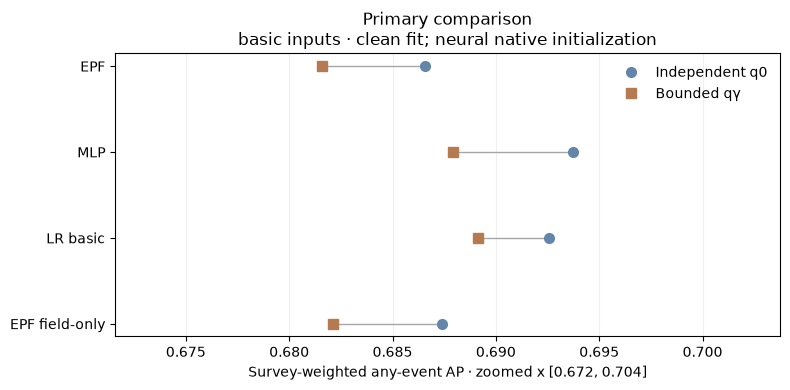

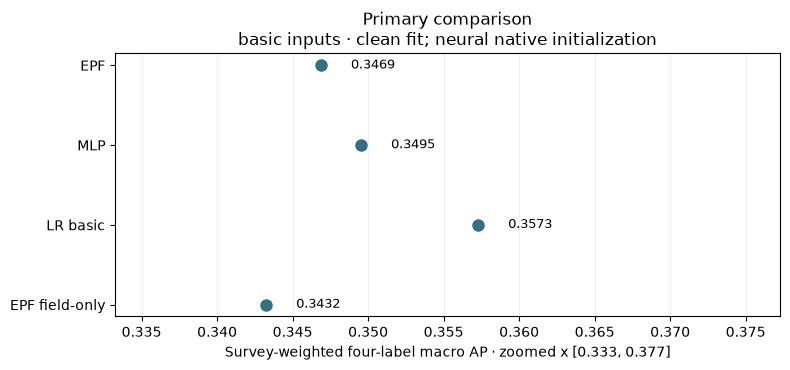

In [2]:

short = {
    'EPF@basic_clean_native': 'EPF',
    'MLP@basic_clean_native': 'MLP',
    'LR@basic_clean': 'LR basic',
    'EPF_field_only@basic_clean_native': 'EPF field-only',
}
rows = []
for model_id, label in short.items():
    p = M[model_id]['performance']['clean']
    rows.append({'model': label, 'component_macro_AP': p['components']['macro_ap'],
                 'component_macro_Brier': p['components']['macro_brier'],
                 'raw_any_AP': p['raw_any']['ap'], 'adjusted_any_AP': p['adjusted_any']['ap'],
                 'raw_any_Brier': p['raw_any']['brier'], 'adjusted_any_Brier': p['adjusted_any']['brier']})
primary = pd.DataFrame(rows).set_index('model')
display(primary.round(6))

any_values = primary[['raw_any_AP', 'adjusted_any_AP']].to_numpy()
any_left = max(0, float(any_values.min()) - .01)
any_right = min(1, float(any_values.max()) + .01)
fig, ax = plt.subplots(figsize=(8, 4))
for i, row in enumerate(any_values):
    ax.plot(row, [i, i], color='#a6a6a6', linewidth=1)
    ax.plot(row[0], i, 'o', color='#6385a9', markersize=7,
            label='Independent q0' if i == 0 else None)
    ax.plot(row[1], i, 's', color='#b67a50', markersize=7,
            label='Bounded qγ' if i == 0 else None)
ax.set_yticks(range(len(primary)), primary.index)
ax.invert_yaxis()
ax.set_xlim(any_left, any_right)
ax.set_xlabel(f'Survey-weighted any-event AP · zoomed x [{any_left:.3f}, {any_right:.3f}]')
ax.set_title('Primary comparison\nbasic inputs · clean fit; neural native initialization')
ax.grid(axis='x', alpha=.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
component_values = primary['component_macro_AP']
component_left = max(0, float(component_values.min()) - .01)
component_right = min(1, float(component_values.max()) + .02)
for i, (label, value) in enumerate(primary['component_macro_AP'].items()):
    ax.plot(value, i, 'o', color='#346f82', markersize=8)
    ax.text(value + .002, i, f'{value:.4f}', va='center', fontsize=9)
ax.set_yticks(range(len(primary)), primary.index)
ax.invert_yaxis()
ax.set_xlim(component_left, component_right)
ax.set_xlabel(f'Survey-weighted four-label macro AP · zoomed x [{component_left:.3f}, {component_right:.3f}]')
ax.set_title('Primary comparison\nbasic inputs · clean fit; neural native initialization')
ax.grid(axis='x', alpha=.2)
fig.tight_layout()
plt.show()


## 소견별·종합 위험의 보정 진단

γ는 사람 간 종합 위험 순위를 바꿀 수 있다. γ 자체는 네 소견 확률을 바꾸지 않는다. 소견별 보정의 양수 기울기는 같은 fold의 같은 보정기 안에서만 순위를 유지하며, fold마다 다른 계수는 OOF 전체 순위와 pooled AP를 바꿀 수 있다. clean/missing20 시험 OOF와 별도 calibration 역할을 표로 나눈다. calibration 평균은 fold·seed 집계의 평균이고 표본·양성 수는 unit별 최소값이다.

In [3]:

p = M['EPF@basic_clean_native']['performance']
test_rows = []
for view in ('clean', 'missing20'):
    for kind in ('raw_any', 'adjusted_any'):
        row = p[view][kind]
        test_rows.append({'view': view, 'risk': kind,
                          **{key: row[key] for key in
                             ('observed_rate', 'predicted_mean', 'mean_risk_gap', 'ap', 'brier', 'nll')}})
print('Held-out any-event risk')
display(pd.DataFrame(test_rows).round(5))
label_rows = []
for view in ('clean', 'missing20'):
    for name, row in zip(R['labels'], p[view]['components']['per_label']):
        label_rows.append({'view': view, 'label': name, **row})
print('Held-out four-label diagnostics')
display(pd.DataFrame(label_rows).round(5))

cal = M['EPF@basic_clean_native']['calibration_role']
sample = {'units': cal['units'], 'n_min': cal['calibration_n_min'],
          'effective_n_min': cal['calibration_effective_n_min'],
          'any_positive_n_min': cal['calibration_positive_n_min']}
gamma = {'gamma_mean': cal['gamma_mean'], 'gamma_min': cal['gamma_min'],
         'gamma_max': cal['gamma_max'],
         'gamma_at_lower_boundary': cal['gamma_at_lower_boundary'],
         'gamma_at_upper_boundary': cal['gamma_at_upper_boundary']}
print('Separate calibration role: sample and gamma summary')
display(pd.DataFrame([sample]).round(5))
display(pd.DataFrame([gamma]).round(5))
role = cal['role_metrics']
boundaries = cal['component_coefficient_boundary_counts']
cal_rows = []
for j, (name, row) in enumerate(zip(R['labels'], role['components'])):
    cal_rows.append({'risk': name, 'positive_n_min': cal['component_positive_n_min'][j],
                     **{key: row[key] for key in
                        ('observed_rate', 'predicted_mean', 'mean_risk_gap', 'brier', 'nll')}})
for kind in ('raw_any', 'adjusted_any'):
    cal_rows.append({'risk': kind, 'positive_n_min': cal['calibration_positive_n_min'],
                     **{key: role[kind][key] for key in
                        ('observed_rate', 'predicted_mean', 'mean_risk_gap', 'brier', 'nll')}})
print('Separate calibration role: fold/seed mean rates and scores; counts are minima')
display(pd.DataFrame(cal_rows).round(5))
boundary_rows = [{'label': name,
                  **{f'{key}_units': values[j] for key, values in boundaries.items()}}
                 for j, name in enumerate(R['labels'])]
print('Four-label monotone coefficient boundary contacts by fold/seed unit')
display(pd.DataFrame(boundary_rows))


Held-out any-event risk


,view,risk,observed_rate,predicted_mean,mean_risk_gap,ap,brier,nll
0,clean,raw_any,0.37992,0.42903,0.04911,0.68658,0.18298,0.54668
1,clean,adjusted_any,0.37992,0.38770,0.00777,0.68157,0.18097,0.54134
2,missing20,raw_any,0.37992,0.46055,0.08063,0.61026,0.21097,0.61032
3,missing20,adjusted_any,0.37992,0.41566,0.03574,0.60162,0.20603,0.59813


Held-out four-label diagnostics


,view,label,ap,auc,brier,nll,observed_rate,predicted_mean,mean_risk_gap,absolute_mean_risk_gap
0,clean,high_glucose,0.34787,0.78160,0.09771,0.32457,0.12882,0.12795,-0.00087,0.00108
1,clean,high_blood_pressure,0.25221,0.74172,0.08466,0.29508,0.10103,0.11983,0.01880,0.01880
2,clean,high_triglyceride,0.42722,0.79472,0.12622,0.39565,0.18656,0.18633,-0.00023,0.00077
3,clean,low_hdl,0.36015,0.74283,0.12183,0.39375,0.16384,0.16755,0.00370,0.00370
4,missing20,high_glucose,0.28396,0.72958,0.10375,0.34663,0.12882,0.13728,0.00846,0.01146
5,missing20,high_blood_pressure,0.21317,0.69661,0.08807,0.30946,0.10103,0.12688,0.02585,0.02585
6,missing20,high_triglyceride,0.36978,0.72992,0.13621,0.42963,0.18656,0.18456,-0.00200,0.00964
7,missing20,low_hdl,0.30334,0.67894,0.12980,0.42079,0.16384,0.18390,0.02006,0.02006


Separate calibration role: sample and gamma summary


...

,gamma_mean,gamma_min,gamma_max,gamma_at_lower_boundary,gamma_at_upper_boundary
0,-0.20217,-0.32434,-0.08646,0,0


Separate calibration role: fold/seed mean rates and scores; counts are minima


,risk,positive_n_min,observed_rate,predicted_mean,mean_risk_gap,brier,nll
0,high_glucose,27,0.12834,0.12834,-0.00000,0.09625,0.32020
1,high_blood_pressure,29,0.11976,0.11976,0.00000,0.09401,0.31527
2,high_triglyceride,47,0.18660,0.18660,-0.00000,0.12833,0.40402
3,low_hdl,44,0.16632,0.16632,-0.00000,0.12330,0.39393
4,raw_any,107,0.39159,0.42801,0.03642,0.18871,0.56090
5,adjusted_any,107,0.39159,0.38710,-0.00449,0.18631,0.55412


Four-label monotone coefficient boundary contacts by fold/seed unit


,label,slope_zero_units,slope_twenty_units,intercept_minus_twenty_units,intercept_plus_twenty_units
0,high_glucose,0,0,0,0
1,high_blood_pressure,0,0,0,0
2,high_triglyceride,0,0,0,0
3,low_hdl,0,0,0,0


## 1단계 소견별 단조 보정 감사

네 소견의 raw sigmoid에서 각각의 단조 보정 확률로 이동한 효과를 따로 본다. 그 다음 단계에서야 q0를 만들고 γ를 적용한다. 140개 fold×소견 AP/AUC 순위 검사는 양수 기울기 아래 변화 0이었지만, fold별 사상이 달라 pooled OOF AP는 변했다. 기본 EPF−LR macro AP 차이는 raw −0.017104에서 저장 보정 후 −0.010410으로 바뀌었고 순위 역전은 없었다. 세 모델의 macro Brier/NLL은 보정 후 악화돼 한 보정 지표의 개선을 전체 품질 개선으로 부르지 않는다.

In [4]:
C=json.loads('{"scope":"Frozen basic_clean_native four-label classification only; no model retraining or selection","n":4068,"families":{"EPF":{"seedless":false,"seed_mean_raw_sigmoid":{"macro_ap":0.34728645603643765,"macro_brier":0.1074878234304452,"macro_nll":0.3518421093433921},"seed_mean_post_saved":{"macro_ap":0.34686037892501725,"macro_brier":0.1076048905424133,"macro_nll":0.3522625411144706},"seed_mean_per_label":{"high_glucose":{"raw_sigmoid":{"ap":0.3554324025535385,"auc":0.7894091842501395,"brier":0.09719993672461007,"nll":0.32203194458263007,"observed_rate":0.12882212778159,"predicted_mean":0.13353688755273682,"mean_risk_gap":0.004714759771146826},"post_saved":{"ap":0.34786553930112335,"auc":0.7815997482253646,"brier":0.097709998305774,"nll":0.3245709603876275,"observed_rate":0.12882212778159,"predicted_mean":0.12794949490615742,"mean_risk_gap":-0.0008726328754325626}},"high_blood_pressure":{"raw_sigmoid":{"ap":0.24902089208134218,"auc":0.7407392069899701,"brier":0.08443871646098909,"nll":0.29585365477736714,"observed_rate":0.10103151922765924,"predicted_mean":0.10374503599743334,"mean_risk_gap":0.0027135167697740956},"post_saved":{"ap":0.25221262103238384,"auc":0.7417241097869077,"brier":0.08465873095310657,"nll":0.29508334021645904,"observed_rate":0.10103151922765924,"predicted_mean":0.11983315919882342,"mean_risk_gap":0.018801639971164175}},"high_triglyceride":{"raw_sigmoid":{"ap":0.42869047635379004,"auc":0.7923969513332492,"brier":0.12654322418472821,"nll":0.39703508471464205,"observed_rate":0.18656404964936124,"predicted_mean":0.18153539135570065,"mean_risk_gap":-0.005028658293660587},"post_saved":{"ap":0.4272181747536883,"auc":0.7947239570398433,"brier":0.12621616380908537,"nll":0.39564735206788354,"observed_rate":0.18656404964936124,"predicted_mean":0.18633203475696428,"mean_risk_gap":-0.0002320148923969645}},"low_hdl":{"raw_sigmoid":{"ap":0.3560020531570796,"auc":0.7475386667241392,"brier":0.12176941635145344,"nll":0.39244775329892945,"observed_rate":0.1638444509303705,"predicted_mean":0.1625962179039884,"mean_risk_gap":-0.0012482330263820784},"post_saved":{"ap":0.36014518061287343,"auc":0.7428267751748351,"brier":0.12183466910168726,"nll":0.39374851178591214,"observed_rate":0.1638444509303705,"predicted_mean":0.16754702176655187,"mean_risk_gap":0.0037025708361813348}}},"maximum_post_saved_vs_v19_report_metric_difference":0.0},"MLP":{"seedless":false,"seed_mean_raw_sigmoid":{"macro_ap":0.35077065280029834,"macro_brier":0.10688331529010507,"macro_nll":0.34907976267270185},"seed_mean_post_saved":{"macro_ap":0.34951715343625334,"macro_brier":0.10709231050242246,"macro_nll":0.3502604633496489},"seed_mean_per_label":{"high_glucose":{"raw_sigmoid":{"ap":0.3532851106605562,"auc":0.793880682575136,"brier":0.0966753569336969,"nll":0.31978529373788195,"observed_rate":0.12882212778159,"predicted_mean":0.13336469151482225,"mean_risk_gap":0.004542563733232252},"post_saved":{"ap":0.3450128061057134,"auc":0.7860842076844698,"brier":0.09722375624153339,"nll":0.3228600701593736,"observed_rate":0.12882212778159,"predicted_mean":0.12925148314810966,"mean_risk_gap":0.00042935536651965883}},"high_blood_pressure":{"raw_sigmoid":{"ap":0.24555445963321446,"auc":0.7489535310487835,"brier":0.08405429862788565,"nll":0.29181875498036264,"observed_rate":0.10103151922765924,"predicted_mean":0.10465398436422768,"mean_risk_gap":0.0036224651365684563},"post_saved":{"ap":0.25043502316674965,"auc":0.7507546741887725,"brier":0.0846479430490616,"nll":0.29300314249510984,"observed_rate":0.10103151922765924,"predicted_mean":0.11996455702411117,"mean_risk_gap":0.018933037796451932}},"high_triglyceride":{"raw_sigmoid":{"ap":0.4399686788750672,"auc":0.7955874827108905,"brier":0.12588696004744945,"nll":0.3948647257328603,"observed_rate":0.18656404964936124,"predicted_mean":0.1847701653880652,"mean_risk_gap":-0.0017938842612960453},"post_saved":{"ap":0.43687753989630623,"auc":0.7987148028006911,"brier":0.12529384932069826,"nll":0.39322533623154426,"observed_rate":0.18656404964936124,"predicted_mean":0.18705283027991407,"mean_risk_gap":0.0004887806305528449}},"low_hdl":{"raw_sigmoid":{"ap":0.36427436203235547,"auc":0.7528323774105078,"brier":0.12091664555138824,"nll":0.38985027623970253,"observed_rate":0.1638444509303705,"predicted_mean":0.16568925505964813,"mean_risk_gap":0.0018448041292776218},"post_saved":{"ap":0.36574324457624413,"auc":0.7459866714960158,"brier":0.12120369339839658,"nll":0.3919533045125679,"observed_rate":0.1638444509303705,"predicted_mean":0.16653142612247648,"mean_risk_gap":0.002686975192105969}}},"maximum_post_saved_vs_v19_report_metric_difference":0.0},"LR":{"seedless":true,"seed_mean_raw_sigmoid":{"macro_ap":0.36439074646293734,"macro_brier":0.10657335335592971,"macro_nll":0.348413802876209},"seed_mean_post_saved":{"macro_ap":0.3572703075596715,"macro_brier":0.10740944107301169,"macro_nll":0.3506643224933043},"seed_mean_per_label":{"high_glucose":{"raw_sigmoid":{"ap":0.37991745556828294,"auc":0.7975718276073365,"brier":0.0954392853546858,"nll":0.31703443838466283,"observed_rate":0.12882212778159,"predicted_mean":0.13083267767423598,"mean_risk_gap":0.0020105498926459853},"post_saved":{"ap":0.3621850963927361,"auc":0.7914667555000928,"brier":0.0967478892483496,"nll":0.32086725440523495,"observed_rate":0.12882212778159,"predicted_mean":0.1292193393061238,"mean_risk_gap":0.0003972115245338137}},"high_blood_pressure":{"raw_sigmoid":{"ap":0.2762204158158846,"auc":0.7574777796766919,"brier":0.08234133342698857,"nll":0.2868191162899868,"observed_rate":0.10103151922765924,"predicted_mean":0.10028887841864118,"mean_risk_gap":-0.0007426408090180636},"post_saved":{"ap":0.26694069699106626,"auc":0.7588374423171828,"brier":0.08388300851593876,"nll":0.28993351422956926,"observed_rate":0.10103151922765924,"predicted_mean":0.12069912356431191,"mean_risk_gap":0.01966760433665267}},"high_triglyceride":{"raw_sigmoid":{"ap":0.4322468167012311,"auc":0.7921664169745737,"brier":0.12730599358681224,"nll":0.40013820889136026,"observed_rate":0.18656404964936124,"predicted_mean":0.1853458237507241,"mean_risk_gap":-0.0012182258986371541},"post_saved":{"ap":0.42850304996129246,"auc":0.7950496637989511,"brier":0.12750657909955093,"nll":0.39982715598509083,"observed_rate":0.18656404964936124,"predicted_mean":0.18742571708555955,"mean_risk_gap":0.0008616674361983101}},"low_hdl":{"raw_sigmoid":{"ap":0.3691782977663508,"auc":0.7606235976883793,"brier":0.12120680105523221,"nll":0.3896634479388261,"observed_rate":0.1638444509303705,"predicted_mean":0.164194847918397,"mean_risk_gap":0.00035039698802649677},"post_saved":{"ap":0.3714523868935911,"auc":0.7533442055802629,"brier":0.12150028742820745,"nll":0.3920293653533223,"observed_rate":0.1638444509303705,"predicted_mean":0.16743648474431683,"mean_risk_gap":0.0035920338139463215}}},"maximum_post_saved_vs_v19_report_metric_difference":5.551115123125783e-17}},"rank_preservation_summary":{"fold_label_checks":140,"zero_slope_n":0,"new_tie_rows_n":0,"max_abs_within_fold_AP_change_cpu":0.0,"max_abs_within_fold_AUC_change_cpu":0.0,"pooled_OOF_AP_can_change_across_fold_specific_calibrators":true},"cpu_reproduction":{"device":"cpu","torch_threads":1,"max_abs_component_probability_error_vs_saved":7.771764759523236e-07,"required_tolerance":1e-06,"backend_precision_caveat":"Frozen post values came from the training host; CPU reconstruction may differ at floating-point resolution."},"comparisons":{"EPF_minus_LR":{"macro_ap":{"raw_sigmoid_difference":-0.01710429042649969,"post_saved_difference":-0.01040992863465423,"calibration_stage_change_in_difference":0.00669436179184546},"macro_brier":{"raw_sigmoid_difference":0.0009144700745154916,"post_saved_difference":0.00019544946940161512,"calibration_stage_change_in_difference":-0.0007190206051138764},"macro_nll":{"raw_sigmoid_difference":0.0034283064671831176,"post_saved_difference":0.0015982186211662697,"calibration_stage_change_in_difference":-0.001830087846016848}},"MLP_minus_LR":{"macro_ap":{"raw_sigmoid_difference":-0.013620093662638999,"post_saved_difference":-0.007753154123418149,"calibration_stage_change_in_difference":0.00586693953922085},"macro_brier":{"raw_sigmoid_difference":0.00030996193417535955,"post_saved_difference":-0.00031713057058922745,"calibration_stage_change_in_difference":-0.000627092504764587},"macro_nll":{"raw_sigmoid_difference":0.0006659597964928654,"post_saved_difference":-0.0004038591436554273,"calibration_stage_change_in_difference":-0.0010698189401482927}},"EPF_minus_MLP":{"macro_ap":{"raw_sigmoid_difference":-0.003484196763860692,"post_saved_difference":-0.002656774511236082,"calibration_stage_change_in_difference":0.00082742225262461},"macro_brier":{"raw_sigmoid_difference":0.000604508140340132,"post_saved_difference":0.0005125800399908426,"calibration_stage_change_in_difference":-9.192810034928944e-05},"macro_nll":{"raw_sigmoid_difference":0.002762346670690252,"post_saved_difference":0.002002077764821697,"calibration_stage_change_in_difference":-0.0007602689058685552}}},"interpretation":["Each positive-slope fold-specific monotone calibrator preserves within-fold order unless numerical saturation adds ties.","Pooled OOF AP may change because folds use different fitted slopes/intercepts; Brier/NLL also respond to probability calibration.","Pre/post differences are descriptive on reused KNHANES folds and do not establish independent model superiority or clinical validity."],"source_sha256":{"script":"4ca4c91d67ae2c282aa55b1ed3cb0226591416dad89c5b3202d06a04605358f4","frozen_manifest":"aefe984d61ebdae15a150849f81197323a132ce774955887922d8647e4702e65","v19_report":"b820e2c09b3d481a5b2a95a95bf646ce054d410ae4076dc414f190b0769684e9"},"privacy":"Aggregate first-stage calibration metrics only; no person-level rows or scores"}')

rows = []
for family, model in C['families'].items():
    raw = model['seed_mean_raw_sigmoid']
    post = model['seed_mean_post_saved']
    rows.append({'model': family, 'raw_macro_AP': raw['macro_ap'],
                 'post_macro_AP': post['macro_ap'],
                 'raw_macro_Brier': raw['macro_brier'],
                 'post_macro_Brier': post['macro_brier'],
                 'raw_macro_NLL': raw['macro_nll'],
                 'post_macro_NLL': post['macro_nll']})
print('First-stage four-label calibration, before q0 and gamma')
display(pd.DataFrame(rows).round(6))
labels = []
for family, model in C['families'].items():
    for name, pair in model['seed_mean_per_label'].items():
        labels.append({'model': family, 'label': name,
                       'observed_rate': pair['post_saved']['observed_rate'],
                       'raw_predicted_mean': pair['raw_sigmoid']['predicted_mean'],
                       'post_predicted_mean': pair['post_saved']['predicted_mean'],
                       'raw_signed_gap': pair['raw_sigmoid']['mean_risk_gap'],
                       'post_signed_gap': pair['post_saved']['mean_risk_gap']})
display(pd.DataFrame(labels).round(5))
comparisons = []
for name, metrics in C['comparisons'].items():
    for metric, row in metrics.items():
        comparisons.append({'comparison': name, 'metric': metric,
                            'raw_difference': row['raw_sigmoid_difference'],
                            'post_difference': row['post_saved_difference'],
                            'stage_change_in_difference': row['calibration_stage_change_in_difference']})
display(pd.DataFrame(comparisons).round(6))
print('Within-fold fold-label AP/AUC checks:', C['rank_preservation_summary'],
      'CPU versus saved maximum probability difference:',
      C['cpu_reproduction']['max_abs_component_probability_error_vs_saved'])


First-stage four-label calibration, before q0 and gamma


,model,raw_macro_AP,post_macro_AP,raw_macro_Brier,post_macro_Brier,raw_macro_NLL,post_macro_NLL
0,EPF,0.347286,0.346860,0.107488,0.107605,0.351842,0.352263
1,MLP,0.350771,0.349517,0.106883,0.107092,0.349080,0.350260
2,LR,0.364391,0.357270,0.106573,0.107409,0.348414,0.350664


,model,label,observed_rate,raw_predicted_mean,post_predicted_mean,raw_signed_gap,post_signed_gap
0,EPF,high_glucose,0.12882,0.13354,0.12795,0.00471,-0.00087
1,EPF,high_blood_pressure,0.10103,0.10375,0.11983,0.00271,0.01880
2,EPF,high_triglyceride,0.18656,0.18154,0.18633,-0.00503,-0.00023
3,EPF,low_hdl,0.16384,0.16260,0.16755,-0.00125,0.00370
4,MLP,high_glucose,0.12882,0.13336,0.12925,0.00454,0.00043
5,MLP,high_blood_pressure,0.10103,0.10465,0.11996,0.00362,0.01893
6,MLP,high_triglyceride,0.18656,0.18477,0.18705,-0.00179,0.00049
7,MLP,low_hdl,0.16384,0.16569,0.16653,0.00184,0.00269
8,LR,high_glucose,0.12882,0.13083,0.12922,0.00201,0.00040
9,LR,high_blood_pressure,0.10103,0.10029,0.12070,-0.00074,0.01967


,comparison,metric,raw_difference,post_difference,stage_change_in_difference
0,EPF_minus_LR,macro_ap,-0.017104,-0.010410,0.006694
1,EPF_minus_LR,macro_brier,0.000914,0.000195,-0.000719
2,EPF_minus_LR,macro_nll,0.003428,0.001598,-0.001830
3,MLP_minus_LR,macro_ap,-0.013620,-0.007753,0.005867
4,MLP_minus_LR,macro_brier,0.000310,-0.000317,-0.000627
5,MLP_minus_LR,macro_nll,0.000666,-0.000404,-0.001070
6,EPF_minus_MLP,macro_ap,-0.003484,-0.002657,0.000827
7,EPF_minus_MLP,macro_brier,0.000605,0.000513,-0.000092
8,EPF_minus_MLP,macro_nll,0.002762,0.002002,-0.000760


Within-fold fold-label AP/AUC checks: {'fold_label_checks': 140, 'zero_slope_n': 0, 'new_tie_rows_n': 0, 'max_abs_within_fold_AP_change_cpu': 0.0, 'max_abs_within_fold_AUC_change_cpu': 0.0, 'pooled_OOF_AP_can_change_across_fold_specific_calibrators': True} CPU versus saved maximum probability difference: 7.771764759523236e-07


## v19 원결과의 별도 해석 감사

이 셀은 동결된 OOF 예측의 집계 감사다. γ 전후 종합 위험 AP/AUC의 변화는 공통 보정에 따른 순위 변화이며 학습된 EPF 구조의 이득이 아니다. model 평균과 개별 seed 방향은 다를 수 있다. 절댓값 gap의 PSU 구간은 계산 가능하지만 비대칭·다봉 가능성이 있어 우열 판단 근거로 쓰지 않는다. 기존 44개 대조와 주조건 결론은 변경하지 않는다.

In [5]:
A=json.loads('{"version":"clinical_v19_interpretation_audit","n":4068,"source_manifest_sha256":"aefe984d61ebdae15a150849f81197323a132ce774955887922d8647e4702e65","frozen_report_sha256":"b820e2c09b3d481a5b2a95a95bf646ce054d410ae4076dc414f190b0769684e9","rank_calibration":{"model_count":26,"model_view_comparisons":338,"clean_exceptions":{"ap_increased":[],"ap_unchanged":[],"auc_increased":[],"auc_unchanged":[]},"all_view_exceptions":{"ap_increased":[],"ap_unchanged":[],"auc_increased":[{"model":"MLP_joint","view":"body_missing","delta":0.00010296086070349375}],"auc_unchanged":[]},"seed_view_direction_counts":{"ap_decreased":1007,"ap_increased":7,"ap_unchanged":0,"auc_decreased":1009,"auc_increased":5,"auc_unchanged":0},"seed_view_count_note":"Seedless LR scores are repeated three times for pairing; seed-view counts are not independent experiment counts.","clean_models":[{"model":"EPF@basic_clean_native","raw_AP":0.6865783509706774,"adjusted_AP":0.6815705353097,"AP_change":-0.0050078156609774105,"raw_AUC":0.7840152532838293,"adjusted_AUC":0.7824490592806289,"AUC_change":-0.0015661940032003496},{"model":"MLP@basic_clean_native","raw_AP":0.6937462715008499,"adjusted_AP":0.6879083295701891,"AP_change":-0.005837941930660784,"raw_AUC":0.7874267206897007,"adjusted_AUC":0.7853504148739288,"AUC_change":-0.002076305815771895},{"model":"EPF@basic_clean_linear_anchor","raw_AP":0.6949938121909233,"adjusted_AP":0.6908405364358282,"AP_change":-0.004153275755095054,"raw_AUC":0.7878308045856043,"adjusted_AUC":0.7861422384234875,"AUC_change":-0.001688566162116767},{"model":"MLP@basic_clean_linear_anchor","raw_AP":0.6922017339806019,"adjusted_AP":0.6878604188886008,"AP_change":-0.004341315092001086,"raw_AUC":0.7874013196368986,"adjusted_AUC":0.785465556153436,"AUC_change":-0.0019357634834625825},{"model":"EPF@basic_paired20_native","raw_AP":0.6852014954073367,"adjusted_AP":0.6790469755559215,"AP_change":-0.00615451985141513,"raw_AUC":0.78218784716057,"adjusted_AUC":0.7800343535688429,"AUC_change":-0.002153493591727118},{"model":"MLP@basic_paired20_native","raw_AP":0.6933225408222311,"adjusted_AP":0.6869827763092117,"AP_change":-0.00633976451301943,"raw_AUC":0.7859852129484457,"adjusted_AUC":0.7836121217009184,"AUC_change":-0.0023730912475272703},{"model":"EPF@basic_paired20_linear_anchor","raw_AP":0.6887048094363276,"adjusted_AP":0.6850240309141872,"AP_change":-0.0036807785221404377,"raw_AUC":0.7825656833516986,"adjusted_AUC":0.7809607559834468,"AUC_change":-0.0016049273682517962},{"model":"MLP@basic_paired20_linear_anchor","raw_AP":0.6877428435762423,"adjusted_AP":0.6830183486134999,"AP_change":-0.004724494962742409,"raw_AUC":0.7822167200087043,"adjusted_AUC":0.7803436461249137,"AUC_change":-0.0018730738837906546},{"model":"EPF@engineered_clean_native","raw_AP":0.6945689542804715,"adjusted_AP":0.6891141501177828,"AP_change":-0.005454804162688731,"raw_AUC":0.786087645898819,"adjusted_AUC":0.7844384866604033,"AUC_change":-0.0016491592384156872},{"model":"MLP@engineered_clean_native","raw_AP":0.6937650433361605,"adjusted_AP":0.6876432014838593,"AP_change":-0.006121841852301246,"raw_AUC":0.7880021971183808,"adjusted_AUC":0.7856896866580946,"AUC_change":-0.0023125104602862434},{"model":"EPF@engineered_clean_linear_anchor","raw_AP":0.6981874880058289,"adjusted_AP":0.6932331534194572,"AP_change":-0.004954334586371623,"raw_AUC":0.7918602059903339,"adjusted_AUC":0.7903847840915228,"AUC_change":-0.0014754218988111134},{"model":"MLP@engineered_clean_linear_anchor","raw_AP":0.6958883706769518,"adjusted_AP":0.6912979129187177,"AP_change":-0.004590457758234079,"raw_AUC":0.7909590776433161,"adjusted_AUC":0.7893773862205125,"AUC_change":-0.0015816914228036216},{"model":"EPF@engineered_paired20_native","raw_AP":0.6920806835382217,"adjusted_AP":0.6879642361475419,"AP_change":-0.004116447390679845,"raw_AUC":0.7852531762001164,"adjusted_AUC":0.7838762273640268,"AUC_change":-0.00137694883608952},{"model":"MLP@engineered_paired20_native","raw_AP":0.6944985442387724,"adjusted_AP":0.6880389668583451,"AP_change":-0.00645957738042735,"raw_AUC":0.786190383846802,"adjusted_AUC":0.7838769853290186,"AUC_change":-0.0023133985177833383},{"model":"EPF@engineered_paired20_linear_anchor","raw_AP":0.6941146256439324,"adjusted_AP":0.6890678464742545,"AP_change":-0.005046779169677995,"raw_AUC":0.7868273875040641,"adjusted_AUC":0.7854641351449594,"AUC_change":-0.0013632523591047274},{"model":"MLP@engineered_paired20_linear_anchor","raw_AP":0.6923706646107798,"adjusted_AP":0.6879983389573164,"AP_change":-0.004372325653463349,"raw_AUC":0.7858542160109501,"adjusted_AUC":0.7843323064215321,"AUC_change":-0.0015219095894180024},{"model":"EPF_field_only@basic_clean_native","raw_AP":0.687376668688895,"adjusted_AP":0.6821185962771567,"AP_change":-0.005258072411738368,"raw_AUC":0.7838339588648046,"adjusted_AUC":0.7820558937940539,"AUC_change":-0.001778065070750623},{"model":"LR@basic_clean","raw_AP":0.6925896385625241,"adjusted_AP":0.6891318297710951,"AP_change":-0.0034578087914289846,"raw_AUC":0.7865076618418176,"adjusted_AUC":0.7846279912049839,"AUC_change":-0.0018796706368336968},{"model":"LR@basic_paired20","raw_AP":0.6874795160335697,"adjusted_AP":0.6836857234016116,"AP_change":-0.003793792631958115,"raw_AUC":0.7807556095053935,"adjusted_AUC":0.7788184110994418,"AUC_change":-0.0019371984059516345},{"model":"LR@engineered_clean","raw_AP":0.6956521199494491,"adjusted_AP":0.6913023491717656,"AP_change":-0.004349770777683504,"raw_AUC":0.7911079314215663,"adjusted_AUC":0.7896323003357479,"AUC_change":-0.0014756310858183852},{"model":"LR@engineered_paired20","raw_AP":0.691686182067182,"adjusted_AP":0.6875324524006429,"AP_change":-0.004153729666539152,"raw_AUC":0.7855752254478855,"adjusted_AUC":0.7840169236507567,"AUC_change":-0.0015583017971287916},{"model":"EPF_regression","raw_AP":0.6871548645898472,"adjusted_AP":0.6806734302379125,"AP_change":-0.006481434351934712,"raw_AUC":0.7812192079772368,"adjusted_AUC":0.7768420644933446,"AUC_change":-0.004377143483892176},{"model":"EPF_joint","raw_AP":0.6862938227633721,"adjusted_AP":0.6799538870747556,"AP_change":-0.006339935688616571,"raw_AUC":0.7815429990643454,"adjusted_AUC":0.7792413419971224,"AUC_change":-0.002301657067223073},{"model":"MLP_regression","raw_AP":0.694625916823901,"adjusted_AP":0.6879547336800765,"AP_change":-0.006671183143824422,"raw_AUC":0.7857422093163757,"adjusted_AUC":0.7825614625199666,"AUC_change":-0.0031807467964091174},{"model":"MLP_joint","raw_AP":0.6951321720485618,"adjusted_AP":0.6894180979401957,"AP_change":-0.005714074108366107,"raw_AUC":0.78715930860829,"adjusted_AUC":0.7851991279832774,"AUC_change":-0.0019601806250125753},{"model":"Ridge@basic_clean","raw_AP":0.68888681320611,"adjusted_AP":0.6829681571862473,"AP_change":-0.005918656019862745,"raw_AUC":0.7861903516273167,"adjusted_AUC":0.7822276127322594,"AUC_change":-0.003962738895057272}]},"seed_variation":{"models":{"EPF@basic_clean_native":{"seeds":[42,43,44],"macro_ap":[0.3469819906263063,0.35035614652960606,0.3432429996191393],"mean":0.34686037892501725,"sample_sd":0.003558132487259091,"min":0.3432429996191393,"max":0.35035614652960606,"range":0.007113146910466772,"seedless_repeated_for_pairing":false},"MLP@basic_clean_native":{"seeds":[42,43,44],"macro_ap":[0.35599763805803564,0.3405393288257921,0.35201449342493235],"mean":0.34951715343625334,"sample_sd":0.008026042695139868,"min":0.3405393288257921,"max":0.35599763805803564,"range":0.015458309232243561,"seedless_repeated_for_pairing":false},"LR@basic_clean":{"seeds":[42,43,44],"macro_ap":[0.3572703075596715,0.3572703075596715,0.3572703075596715],"mean":0.3572703075596715,"sample_sd":0.0,"min":0.3572703075596715,"max":0.3572703075596715,"range":0.0,"seedless_repeated_for_pairing":true},"EPF@engineered_clean_linear_anchor":{"seeds":[42,43,44],"macro_ap":[0.36446711443796037,0.3590564859706022,0.36172814700491723],"mean":0.36175058247115993,"sample_sd":0.002705384005193316,"min":0.3590564859706022,"max":0.36446711443796037,"range":0.005410628467358181,"seedless_repeated_for_pairing":false},"LR@engineered_clean":{"seeds":[42,43,44],"macro_ap":[0.3594734720559497,0.3594734720559497,0.3594734720559497],"mean":0.35947347205594965,"sample_sd":6.798699777552591e-17,"min":0.3594734720559497,"max":0.3594734720559497,"range":0.0,"seedless_repeated_for_pairing":true}},"paired_differences":{"primary_EPF_minus_MLP":{"models":["EPF@basic_clean_native","MLP@basic_clean_native"],"seeds":[42,43,44],"paired_macro_ap_difference":[-0.009015647431729334,0.009816817703813985,-0.008771493805793062],"mean":-0.0026567745112361374,"sample_sd":0.01080313749837443,"positive_seeds":1,"negative_seeds":2,"zero_seeds":0},"primary_EPF_minus_LR":{"models":["EPF@basic_clean_native","LR@basic_clean"],"seeds":[42,43,44],"paired_macro_ap_difference":[-0.010288316933365182,-0.006914161030065424,-0.014027307940532197],"mean":-0.010409928634654267,"sample_sd":0.003558132487259091,"positive_seeds":0,"negative_seeds":3,"zero_seeds":0},"posthoc_engineered_anchor_EPF_minus_matched_LR":{"models":["EPF@engineered_clean_linear_anchor","LR@engineered_clean"],"seeds":[42,43,44],"paired_macro_ap_difference":[0.004993642382010666,-0.0004169860853475149,0.0022546749489675277],"mean":0.002277110415210226,"sample_sd":0.002705384005193316,"positive_seeds":2,"negative_seeds":1,"zero_seeds":0}},"interpretation":"Three seed scores are repeated fits on the same five test folds, not independent cohort replicates or a retraining CI. LR has no random seed; its OOF score is repeated solely for pairing."},"multiplicity":{"prespecified_contrasts":44,"metrics_per_contrast":7,"unadjusted_intervals":308,"posthoc_matched_comparison_extra_metrics":5,"interpretation":"Intervals are descriptive and not family-wise error controlled; inspecting many conditions and metrics after prior v16/v18 exploration limits confirmatory claims."},"absolute_gap_bootstrap":{"frozen_contrast_count":44,"frozen_absolute_gap_ci_excludes_zero_count":0,"all_frozen_absolute_gap_contrasts_reproduced":true,"selected_distributions":{"primary_EPF_vs_LR":{"absolute_gap_improvement":{"estimate":0.004103967751196816,"ci95":[-0.0046013347852431425,0.0061279090304181445],"sample_skewness":-1.6265408250139617,"kde_peaks_scott_5pct_prominence":[{"location":-0.003835969539518779,"relative_height":0.1061661356217368},{"location":0.004026980406298223,"relative_height":1.0}]},"signed_gap_difference_first_minus_second":{"estimate":-0.004103967751196816,"ci95":[-0.006241406959037174,-0.0018317789103653869]},"adjusted_any_brier_improvement_frozen_report":{"estimate":-0.0005134819666469115,"ci95":[-0.0024164279139827667,0.0013749358222277016]}},"primary_EPF_vs_MLP":{"absolute_gap_improvement":{"estimate":0.0011841419398027101,"ci95":[-0.0019607301500175647,0.0031076496609184693],"sample_skewness":-0.2624946398893113,"kde_peaks_scott_5pct_prominence":[{"location":0.0008728507056747605,"relative_height":1.0}]},"signed_gap_difference_first_minus_second":{"estimate":-0.0011841419398027101,"ci95":[-0.0032890610648531825,0.0008706467731810536]},"adjusted_any_brier_improvement_frozen_report":{"estimate":-0.00163248615929526,"ci95":[-0.003190086330374267,1.5788261331079652e-05]}},"primary_EPF_vs_field_only":{"absolute_gap_improvement":{"estimate":-0.000490373149915348,"ci95":[-0.0013861396344755615,0.001437709025976871],"sample_skewness":0.3577114473240996,"kde_peaks_scott_5pct_prominence":[{"location":-0.00027992234113883587,"relative_height":1.0}]},"signed_gap_difference_first_minus_second":{"estimate":0.000490373149915348,"ci95":[-0.0005252122614804206,0.0014517302257053613]},"adjusted_any_brier_improvement_frozen_report":{"estimate":-5.672565913600325e-05,"ci95":[-0.0008180848399298126,0.0007231040614889643]}},"posthoc_engineered_anchor_EPF_vs_matched_LR":{"absolute_gap_improvement":{"estimate":0.0002948361793253893,"ci95":[-0.00042390823818113434,0.0007579494389522752],"sample_skewness":-0.351373843714146,"kde_peaks_scott_5pct_prominence":[{"location":0.0002438476731116253,"relative_height":1.0}]},"signed_gap_difference_first_minus_second":{"estimate":-0.0002948361793253893,"ci95":[-0.0007631695974143509,0.0002052108291408538]}}},"interpretation":"Absolute value has a kink at signed gap zero. Percentile PSU intervals are descriptive and may be skewed when replicate gaps cross zero; multimodality is neither mathematically necessary nor established merely by the kink. KDE peak counts are bandwidth-sensitive diagnostics, not a formal modality test.","alternatives":"Report signed calibration-in-the-large gap with its direction, and Brier score as a proper probability score; retain the frozen absolute-gap point estimates rather than replacing them post hoc."},"privacy":"Aggregate model/view/seed metrics only; no person-level predictions or role indices"}')

rank = A['rank_calibration']
clean = pd.DataFrame(rank['clean_models']).set_index('model')
print('Clean model-mean comparisons: AP decreases', int((clean.AP_change < 0).sum()),
      'of', len(clean), '; AUC decreases', int((clean.AUC_change < 0).sum()), 'of', len(clean))
print('All-view model-mean AP increases:', len(rank['all_view_exceptions']['ap_increased']),
      '; AUC increases:', rank['all_view_exceptions']['auc_increased'])
print('Individual seed-view direction counts:', rank['seed_view_direction_counts'])
with pd.option_context('display.max_rows', len(clean)):
    display(clean.round(6))

variation_rows = []
for name, row in A['seed_variation']['models'].items():
    variation_rows.append({'model': name, 'seed42': row['macro_ap'][0],
                           'seed43': row['macro_ap'][1], 'seed44': row['macro_ap'][2],
                           'seed_mean': row['mean'], 'sample_sd': row['sample_sd'],
                           'seedless_repeated': row['seedless_repeated_for_pairing']})
print('Observed seed scores on the same five held-out folds')
display(pd.DataFrame(variation_rows).round(6))
paired_rows = []
for name, row in A['seed_variation']['paired_differences'].items():
    paired_rows.append({'comparison': name,
                        'seed42': row['paired_macro_ap_difference'][0],
                        'seed43': row['paired_macro_ap_difference'][1],
                        'seed44': row['paired_macro_ap_difference'][2],
                        'mean': row['mean'], 'positive_seeds': row['positive_seeds']})
print('Paired seed differences; the engineered-anchor pair is post-hoc')
display(pd.DataFrame(paired_rows).round(6))

gap = A['absolute_gap_bootstrap']['selected_distributions']['primary_EPF_vs_LR']
gap_rows = []
for label, item in (
    ('absolute gap improvement, descriptive', gap['absolute_gap_improvement']),
    ('signed gap EPF minus LR', gap['signed_gap_difference_first_minus_second']),
    ('adjusted any-event Brier improvement', gap['adjusted_any_brier_improvement_frozen_report']),
):
    gap_rows.append({'measure': label, 'estimate': item['estimate'],
                     'ci_low': item['ci95'][0], 'ci_high': item['ci95'][1]})
print('Calibration gap and Brier, fixed-prediction PSU intervals')
display(pd.DataFrame(gap_rows).round(6))
print('Absolute-gap percentile CI is defined; its replicates may be skewed and some density estimates have multiple peaks.',
      'Primary EPF-LR skewness:', gap['absolute_gap_improvement']['sample_skewness'],
      'Scott-bandwidth 5% prominence peak count:',
      len(gap['absolute_gap_improvement']['kde_peaks_scott_5pct_prominence']))
print('Use signed gap direction and Brier for calibration interpretation; do not treat absolute gap as model superiority.',
      'Unadjusted intervals:', A['multiplicity']['unadjusted_intervals'])


Clean model-mean comparisons: AP decreases 26 of 26 ; AUC decreases 26 of 26
All-view model-mean AP increases: 0 ; AUC increases: [{'model': 'MLP_joint', 'view': 'body_missing', 'delta': 0.00010296086070349375}]
Individual seed-view direction counts: {'ap_decreased': 1007, 'ap_increased': 7, 'ap_unchanged': 0, 'auc_decreased': 1009, 'auc_increased': 5, 'auc_unchanged': 0}


,raw_AP,adjusted_AP,AP_change,raw_AUC,adjusted_AUC,AUC_change
model,,,,,,
EPF@basic_clean_native,0.686578,0.681571,-0.005008,0.784015,0.782449,-0.001566
MLP@basic_clean_native,0.693746,0.687908,-0.005838,0.787427,0.785350,-0.002076
EPF@basic_clean_linear_anchor,0.694994,0.690841,-0.004153,0.787831,0.786142,-0.001689
MLP@basic_clean_linear_anchor,0.692202,0.687860,-0.004341,0.787401,0.785466,-0.001936
EPF@basic_paired20_native,0.685201,0.679047,-0.006155,0.782188,0.780034,-0.002153
MLP@basic_paired20_native,0.693323,0.686983,-0.006340,0.785985,0.783612,-0.002373
EPF@basic_paired20_linear_anchor,0.688705,0.685024,-0.003681,0.782566,0.780961,-0.001605
MLP@basic_paired20_linear_anchor,0.687743,0.683018,-0.004724,0.782217,0.780344,-0.001873
EPF@engineered_clean_native,0.694569,0.689114,-0.005455,0.786088,0.784438,-0.001649


Observed seed scores on the same five held-out folds


,model,seed42,seed43,seed44,seed_mean,sample_sd,seedless_repeated
0,EPF@basic_clean_native,0.346982,0.350356,0.343243,0.346860,0.003558,False
1,MLP@basic_clean_native,0.355998,0.340539,0.352014,0.349517,0.008026,False
2,LR@basic_clean,0.357270,0.357270,0.357270,0.357270,0.000000,True
3,EPF@engineered_clean_linear_anchor,0.364467,0.359056,0.361728,0.361751,0.002705,False
4,LR@engineered_clean,0.359473,0.359473,0.359473,0.359473,0.000000,True


Paired seed differences; the engineered-anchor pair is post-hoc


,comparison,seed42,seed43,seed44,mean,positive_seeds
0,primary_EPF_minus_MLP,-0.009016,0.009817,-0.008771,-0.002657,1
1,primary_EPF_minus_LR,-0.010288,-0.006914,-0.014027,-0.010410,0
2,posthoc_engineered_anchor_EPF_minus_matched_LR,0.004994,-0.000417,0.002255,0.002277,2


Calibration gap and Brier, fixed-prediction PSU intervals


,measure,estimate,ci_low,ci_high
0,"absolute gap improvement, descriptive",0.004104,-0.004601,0.006128
1,signed gap EPF minus LR,-0.004104,-0.006241,-0.001832
2,adjusted any-event Brier improvement,-0.000513,-0.002416,0.001375


Absolute-gap percentile CI is defined; its replicates may be skewed and some density estimates have multiple peaks. Primary EPF-LR skewness: -1.6265408250139617 Scott-bandwidth 5% prominence peak count: 2
Use signed gap direction and Brier for calibration interpretation; do not treat absolute gap as model superiority. Unadjusted intervals: 308


## 사후 보정 방식 탐색: 원 q0·γ·양수기울기 sigmoid C

동결된 35개 모델 단위에 같은 calibration 역할의 `sigmoid(a·logit(q0)+b), a>0`을 **사후에만** 맞춘 비교다. C는 fold 안 순위를 보존하지만 fold별 사상이 달라 pooled AP/AUC는 달라질 수 있다. γ는 세 모델에서 C보다 test Brier·NLL·평균 위험 차이가 좋았으나 양수기울기 보정이 무조건 개선된다는 결론은 아니다. C는 Fréchet 합집합 경계를 일부 위반한다. 다섯 번째 직접 any head나 더 큰 cross-fit calibration은 이번에 구현하지 않은 별도 실험이다. 기존 v19 주대조와 44개 구간은 이 표로 바꾸지 않는다.

In [6]:
U=json.loads('{"version":"clinical_v19_union_calibration_probe","status":"exploratory_posthoc_calibration_only","n":4068,"units":35,"folds":5,"neural_seeds":[42,43,44],"LR_seedless":true,"variants":{"q0":"Four frozen marginal calibrators followed by 1-product(1-p)","gamma":"Original frozen Fréchet-bounded one-parameter union adjustment","positive_logit":"New calibration-role sigmoid(a*logit(q0)+b), a>0, no union-bound projection"},"models":{"EPF":{"units":15,"seed_count":3,"variants":{"q0":{"ap":0.6865783509706774,"auc":0.7840152532838293,"brier":0.1829757290858202,"nll":0.5466807832853431,"observed_rate":0.3799226528155136,"predicted_mean":0.4290340727672383,"mean_risk_gap":0.049111419951724765,"screening":{"0.9":{"sensitivity":0.8742096058852861,"specificity":0.4630653508946359,"referral_rate":0.6650730454134298},"0.95":{"sensitivity":0.9300440352987005,"specificity":0.3175501670657657,"referral_rate":0.7765164791182834}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0,0,0],"above_upper_n_per_seed":[0,0,0]}},"gamma":{"ap":0.6815705353097,"auc":0.7824490592806289,"brier":0.18097363783647072,"nll":0.5413419498134587,"observed_rate":0.3799226528155136,"predicted_mean":0.38769608940973677,"mean_risk_gap":0.007773436594223175,"screening":{"0.9":{"sensitivity":0.8738487066389148,"specificity":0.4665848456829575,"referral_rate":0.6627535726225773},"0.95":{"sensitivity":0.9299645224584228,"specificity":0.32075390516448693,"referral_rate":0.7744997049677435}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0,0,0],"above_upper_n_per_seed":[0,0,0]}},"positive_logit":{"ap":0.6789653960816207,"auc":0.7795739990024356,"brier":0.18222347963856178,"nll":0.5445466266789446,"observed_rate":0.3799226528155136,"predicted_mean":0.39342309180489493,"mean_risk_gap":0.013500438989381339,"screening":{"0.9":{"sensitivity":0.8742096058852861,"specificity":0.4630653508946359,"referral_rate":0.6650730454134298},"0.95":{"sensitivity":0.9300440352987005,"specificity":0.3175501670657657,"referral_rate":0.7765164791182834}},"frechet_violation":{"fraction":0.14626352015732547,"weighted_fraction":0.13362742550653958,"mean_excess":0.0032350972440531723,"weighted_mean_excess":0.0029319450647766997,"max_excess":0.04748409106351539,"below_lower_n_per_seed":[0,1,0],"above_upper_n_per_seed":[611,590,583]}}},"pooled_fold_specific_rank_changes":[{"seed":42,"pooled_oof_ap_change_C_minus_A":-0.007673093350268112,"pooled_oof_auc_change_C_minus_A":-0.004393406233855979},{"seed":43,"pooled_oof_ap_change_C_minus_A":-0.006504421755103573,"pooled_oof_auc_change_C_minus_A":-0.004679208991732464},{"seed":44,"pooled_oof_ap_change_C_minus_A":-0.00866134956179887,"pooled_oof_auc_change_C_minus_A":-0.004251147618592577}],"positive_logit_slope_range":[0.6859062514412039,0.9452660454475729]},"MLP":{"units":15,"seed_count":3,"variants":{"q0":{"ap":0.6937462715008499,"auc":0.7874267206897007,"brier":0.18067447591902408,"nll":0.5427892823486737,"observed_rate":0.3799226528155136,"predicted_mean":0.42673662276782864,"mean_risk_gap":0.04681396995231509,"screening":{"0.9":{"sensitivity":0.8723761377316501,"specificity":0.48258028840229117,"referral_rate":0.6522756986484298},"0.95":{"sensitivity":0.9280340262882616,"specificity":0.3244228695343132,"referral_rate":0.7714912240481692}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0,0,0],"above_upper_n_per_seed":[0,0,0]}},"gamma":{"ap":0.6879083295701891,"auc":0.7853504148739288,"brier":0.17934115167717546,"nll":0.5381906948595803,"observed_rate":0.3799226528155136,"predicted_mean":0.3888802313495394,"mean_risk_gap":0.008957578534025864,"screening":{"0.9":{"sensitivity":0.8710596009535657,"specificity":0.48614434952672675,"referral_rate":0.6495655229359274},"0.95":{"sensitivity":0.9271580592047982,"specificity":0.3303813478461591,"referral_rate":0.7674637068851751}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0,0,0],"above_upper_n_per_seed":[0,0,0]}},"positive_logit":{"ap":0.6873390353907541,"auc":0.7831875873072417,"brier":0.18017713534073762,"nll":0.5411890704007005,"observed_rate":0.3799226528155136,"predicted_mean":0.39332704459973494,"mean_risk_gap":0.01340439178422137,"screening":{"0.9":{"sensitivity":0.8723761377316501,"specificity":0.48258028840229117,"referral_rate":0.6522756986484298},"0.95":{"sensitivity":0.9280340262882616,"specificity":0.3244228695343132,"referral_rate":0.7714912240481692}},"frechet_violation":{"fraction":0.09759095378564404,"weighted_fraction":0.09077127766040101,"mean_excess":0.0014311152621004856,"weighted_mean_excess":0.001307126835894153,"max_excess":0.0324094180871857,"below_lower_n_per_seed":[0,0,0],"above_upper_n_per_seed":[519,353,319]}}},"pooled_fold_specific_rank_changes":[{"seed":42,"pooled_oof_ap_change_C_minus_A":-0.005724915985648726,"pooled_oof_auc_change_C_minus_A":-0.004540407432794491},{"seed":43,"pooled_oof_ap_change_C_minus_A":-0.007257418949229821,"pooled_oof_auc_change_C_minus_A":-0.0037679018608671733},{"seed":44,"pooled_oof_ap_change_C_minus_A":-0.006239373395408476,"pooled_oof_auc_change_C_minus_A":-0.004409090853715103}],"positive_logit_slope_range":[0.7404811860372176,1.040682096804482]},"LR":{"units":5,"seed_count":1,"variants":{"q0":{"ap":0.6925896385625241,"auc":0.7865076618418176,"brier":0.18184118663302165,"nll":0.5475321558955464,"observed_rate":0.3799226528155136,"predicted_mean":0.43309305680321314,"mean_risk_gap":0.053170403987699566,"screening":{"0.9":{"sensitivity":0.8729831863326176,"specificity":0.4758205921549858,"referral_rate":0.6566978646800994},"0.95":{"sensitivity":0.9320896069149701,"specificity":0.3220760101960044,"referral_rate":0.7744872653112893}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0],"above_upper_n_per_seed":[0]}},"gamma":{"ap":0.6891318297710951,"auc":0.784627991204984,"brier":0.18046015586982384,"nll":0.5412117310195865,"observed_rate":0.3799226528155136,"predicted_mean":0.3918000571609335,"mean_risk_gap":0.01187740434541995,"screening":{"0.9":{"sensitivity":0.8731677638598242,"specificity":0.4735419432756378,"referral_rate":0.6581809284161567},"0.95":{"sensitivity":0.929642540998602,"specificity":0.32666397982493556,"referral_rate":0.7707126735002575}},"frechet_violation":{"fraction":0.0,"weighted_fraction":0.0,"mean_excess":0.0,"weighted_mean_excess":0.0,"max_excess":0.0,"below_lower_n_per_seed":[0],"above_upper_n_per_seed":[0]}},"positive_logit":{"ap":0.6864052070774288,"auc":0.7803748676332689,"brier":0.18185922849994274,"nll":0.5462433016512307,"observed_rate":0.3799226528155136,"predicted_mean":0.39449092291992593,"mean_risk_gap":0.014568270104412362,"screening":{"0.9":{"sensitivity":0.8729831863326176,"specificity":0.4758205921549858,"referral_rate":0.6566978646800994},"0.95":{"sensitivity":0.9320896069149701,"specificity":0.3220760101960044,"referral_rate":0.7744872653112893}},"frechet_violation":{"fraction":0.05555555555555555,"weighted_fraction":0.050508242038639156,"mean_excess":0.0010321626637828892,"weighted_mean_excess":0.0009177519010949188,"max_excess":0.03604877824701316,"below_lower_n_per_seed":[4],"above_upper_n_per_seed":[222]}}},"pooled_fold_specific_rank_changes":[{"seed":null,"pooled_oof_ap_change_C_minus_A":-0.0061844314850952875,"pooled_oof_auc_change_C_minus_A":-0.006132794208548731}],"positive_logit_slope_range":[0.7224453605422794,1.1503678123925154]}},"interpretation":{"rank":"Positive slope preserves within-fold ranking absent numerical ties; pooled OOF ranking/AP/AUC can change when the five calibrators differ","coherence":"Positive-logit risk is not constrained to lie between max(component p) and min(sum(component p),1); measured violations are reported without clipping","selection":"No base retraining, neural candidate search, hyperparameter search, model promotion, bootstrap CI, or external validation","scope":"One clean test view on the same previously explored KNHANES 2021-2024 cohort; calibration-only post-hoc comparison"},"probe_source_manifest_sha256":"3b6bd09490f295a3756eb9604d11455879309b4024410e35194f7464576afe92","privacy":"Only clean-view aggregate metrics and model counts; no patient risks or role indices"}')

rows = []
for family, model in U['models'].items():
    for variant, m in model['variants'].items():
        rows.append({'model': family, 'risk_calibration': variant,
                     'clean_any_AP': m['ap'], 'clean_any_AUC': m['auc'],
                     'Brier': m['brier'], 'NLL': m['nll'],
                     'signed_mean_risk_gap': m['mean_risk_gap'],
                     'Frechet_violation_fraction': m['frechet_violation']['fraction']})
print('Post-hoc calibration-only probe on 35 frozen checkpoints')
display(pd.DataFrame(rows).round(6))
policy_rows = []
for family, model in U['models'].items():
    for target in ('0.9', '0.95'):
        raw = model['variants']['q0']['screening'][target]
        positive = model['variants']['positive_logit']['screening'][target]
        policy_rows.append({'model': family, 'target': target,
                            'sensitivity_change_C_minus_q0': positive['sensitivity'] - raw['sensitivity'],
                            'specificity_change_C_minus_q0': positive['specificity'] - raw['specificity'],
                            'referral_change_C_minus_q0': positive['referral_rate'] - raw['referral_rate']})
print('Fixed threshold-role policy differences: positive-logit C minus q0')
display(pd.DataFrame(policy_rows).round(8))
print('Within-fold positive slope preserves rank, but fold-specific maps may alter pooled AP/AUC.',
      'No NN retraining, model promotion, bootstrap CI, or external validation in this probe.')


Post-hoc calibration-only probe on 35 frozen checkpoints


,model,risk_calibration,clean_any_AP,clean_any_AUC,Brier,NLL,signed_mean_risk_gap,Frechet_violation_fraction
0,EPF,q0,0.686578,0.784015,0.182976,0.546681,0.049111,0.000000
1,EPF,gamma,0.681571,0.782449,0.180974,0.541342,0.007773,0.000000
2,EPF,positive_logit,0.678965,0.779574,0.182223,0.544547,0.013500,0.146264
3,MLP,q0,0.693746,0.787427,0.180674,0.542789,0.046814,0.000000
4,MLP,gamma,0.687908,0.785350,0.179341,0.538191,0.008958,0.000000
5,MLP,positive_logit,0.687339,0.783188,0.180177,0.541189,0.013404,0.097591
6,LR,q0,0.692590,0.786508,0.181841,0.547532,0.053170,0.000000
7,LR,gamma,0.689132,0.784628,0.180460,0.541212,0.011877,0.000000
8,LR,positive_logit,0.686405,0.780375,0.181859,0.546243,0.014568,0.055556


Fixed threshold-role policy differences: positive-logit C minus q0


,model,target,sensitivity_change_C_minus_q0,specificity_change_C_minus_q0,referral_change_C_minus_q0
0,EPF,0.9,0.0,0.0,0.0
1,EPF,0.95,0.0,0.0,0.0
2,MLP,0.9,0.0,0.0,0.0
3,MLP,0.95,0.0,0.0,0.0
4,LR,0.9,0.0,0.0,0.0
5,LR,0.95,0.0,0.0,0.0


Within-fold positive slope preserves rank, but fold-specific maps may alter pooled AP/AUC. No NN retraining, model promotion, bootstrap CI, or external validation in this probe.


## v19 역할·컷오프 보충 감사

fit/validation/calibration/threshold/test는 각 fold 안에서 행·PSU가 겹치지 않지만 사람은 다른 fold와 seed에서 재사용된다. `wt_itvex/4`의 공통배수는 가중 비율을 바꾸지 않는다. threshold 역할의 90/95 목표는 test 보장이 아니며 보정 역할의 양성 수와 구분한다.

In [7]:
Q=json.loads('{"scope":"Read-only original KNHANES 2021-24 labels, survey role and threshold audit; aggregate only","n":4068,"survey_weight":{"same_archived_values":true,"equal_duration_pooled_factor":0.25,"global_rescaling_changes_weighted_prevalence":false,"interpretation":"Each of four equally long survey years can receive wt_itvex/4; the common factor cancels in weighted prevalence and sensitivity. Year shares still follow each year\'s eligible weighted mass."},"roles":{"within_fold_row_overlap_total":0,"within_fold_psu_overlap_total":0,"test_person_coverage_once":true,"cross_fold_role_reuse_pair_counts":{"calibration_versus_threshold_across_different_folds":426,"calibration_versus_test_across_different_folds":1594,"threshold_versus_test_across_different_folds":1666},"unique_calibration_people_across_folds":1367,"unique_threshold_people_across_folds":1390,"interpretation":"Roles are disjoint inside each fold; the same cohort is intentionally reused across different folds and three seeds. Reused rows do not increase independent participant n."},"threshold":{"selection_rule":"highest unique risk with threshold-role weighted positive sensitivity >= target","decision_inequality":"risk >= cutoff","out_of_sample_guarantee":false,"recomputed_units":10,"stored_cuts_match":true,"clean_test_sensitivity":{"raw_any":{"0.9":{"model_count":26,"met_or_exceeded_n":0,"below_target_n":26,"minimum_test_sensitivity":0.8637343448600024,"maximum_test_sensitivity":0.8883187771685497},"0.95":{"model_count":26,"met_or_exceeded_n":0,"below_target_n":26,"minimum_test_sensitivity":0.9211777168209521,"maximum_test_sensitivity":0.9360789189392272}},"adjusted_any":{"0.9":{"model_count":26,"met_or_exceeded_n":0,"below_target_n":26,"minimum_test_sensitivity":0.8621520671255106,"maximum_test_sensitivity":0.8857027265293979},"0.95":{"model_count":26,"met_or_exceeded_n":0,"below_target_n":26,"minimum_test_sensitivity":0.9181830532479451,"maximum_test_sensitivity":0.9357876740155322}}}},"bp":{"test_actual_BP_weighted_prevalence":0.10103151922765924,"test_pre_component_calibration_mean":0.10374503511245993,"test_post_component_calibration_mean":0.11983315919882342,"calibration_role_pre_component_calibration_fold_seed_mean":0.10385418797006021,"calibration_role_post_component_calibration_fold_seed_mean":0.11976390997677933,"interpretation":"Pre/post is a descriptive recalculation using frozen models. Calibration fits each fold\'s separate calibration role; test prevalence differs, so a calibration-role mean need not equal OOF test prevalence."},"reported_bp":{"model_count":26,"test_BP_predicted_mean_min_across_26_models":0.11968886808665796,"test_BP_predicted_mean_max_across_26_models":0.1220047517722833,"models_with_test_BP_predicted_mean_above_observed_n":26},"minimum_107_clarification":{"fold5_calibration_any_positive_n":107,"fold5_threshold_any_positive_n":115,"minimum_calibration_any_positive_n_across_folds":107,"minimum_threshold_any_positive_n_across_folds":113,"meaning":"The cited minimum 107 is a calibration-role count, not the threshold-role positive count."},"limits":["This audit does not change any frozen model or split.","Cross-fold and cross-seed reuse means role counts are not independent additions to cohort n.","Weighted empirical threshold-role sensitivity has no automatic out-of-sample 90/95% guarantee.","Fixed test scores cannot by themselves identify a causal mechanism for calibration transport differences."],"privacy":"Aggregate survey-role and threshold checks only; no participant rows or split indices"}')

overlap = Q['roles']
role_summary = {'within_fold_row_overlap': overlap['within_fold_row_overlap_total'],
                'within_fold_PSU_overlap': overlap['within_fold_psu_overlap_total'],
                'test_person_coverage_once': overlap['test_person_coverage_once'],
                'unique_calibration_people_across_folds': overlap['unique_calibration_people_across_folds'],
                'unique_threshold_people_across_folds': overlap['unique_threshold_people_across_folds']}
print('Roles are disjoint within each fold; people are reused across different folds and seeds')
display(pd.DataFrame([role_summary]))
print('Cross-fold role reuse counts')
display(pd.DataFrame([overlap['cross_fold_role_reuse_pair_counts']]))
print('Common wt_itvex/4 rescaling changes weighted prevalence:',
      Q['survey_weight']['global_rescaling_changes_weighted_prevalence'])

threshold = Q['threshold']
print('Threshold rule:', threshold['selection_rule'], '; decision:', threshold['decision_inequality'],
      '; reproduced cuts:', threshold['recomputed_units'],
      '; exact match:', threshold['stored_cuts_match'])
rows = []
for kind, policies in threshold['clean_test_sensitivity'].items():
    for target, row in policies.items():
        rows.append({'risk': kind, 'development_target': target,
                     'models_meeting_target_on_test': row['met_or_exceeded_n'],
                     'models_below_target_on_test': row['below_target_n'],
                     'test_sensitivity_min': row['minimum_test_sensitivity'],
                     'test_sensitivity_max': row['maximum_test_sensitivity']})
display(pd.DataFrame(rows).round(5))

bp = Q['bp']
bp_summary = {'test_observed_BP_rate': bp['test_actual_BP_weighted_prevalence'],
              'test_pre_component_calibration_mean': bp['test_pre_component_calibration_mean'],
              'test_post_component_calibration_mean': bp['test_post_component_calibration_mean'],
              'calibration_role_post_mean': bp['calibration_role_post_component_calibration_fold_seed_mean'],
              'min_post_mean_across_26_models': Q['reported_bp']['test_BP_predicted_mean_min_across_26_models'],
              'max_post_mean_across_26_models': Q['reported_bp']['test_BP_predicted_mean_max_across_26_models']}
print('BP prevalence and component calibration across distinct roles')
display(pd.DataFrame([bp_summary]).round(5))
print('Minimum 107 positive people is calibration-role fold5; threshold-role fold5 has',
      Q['minimum_107_clarification']['fold5_threshold_any_positive_n'])


Roles are disjoint within each fold; people are reused across different folds and seeds


,within_fold_row_overlap,within_fold_PSU_overlap,test_person_coverage_once,unique_calibration_people_across_folds,unique_threshold_people_across_folds
0,0,0,True,1367,1390


Cross-fold role reuse counts


,calibration_versus_threshold_across_different_folds,calibration_versus_test_across_different_folds,threshold_versus_test_across_different_folds
0,426,1594,1666


Common wt_itvex/4 rescaling changes weighted prevalence: False
Threshold rule: highest unique risk with threshold-role weighted positive sensitivity >= target ; decision: risk >= cutoff ; reproduced cuts: 10 ; exact match: True


,risk,development_target,models_meeting_target_on_test,models_below_target_on_test,test_sensitivity_min,test_sensitivity_max
0,raw_any,0.9,0,26,0.86373,0.88832
1,raw_any,0.95,0,26,0.92118,0.93608
2,adjusted_any,0.9,0,26,0.86215,0.88570
3,adjusted_any,0.95,0,26,0.91818,0.93579


BP prevalence and component calibration across distinct roles


,test_observed_BP_rate,test_pre_component_calibration_mean,test_post_component_calibration_mean,calibration_role_post_mean,min_post_mean_across_26_models,max_post_mean_across_26_models
0,0.10103,0.10375,0.11983,0.11976,0.11969,0.122


Minimum 107 positive people is calibration-role fold5; threshold-role fold5 has 115


## v19 누락 강도 감사와 v20 교정 경계

기존 `missing20`은 모든 변수에 동일한 20% 누락이 아니다. 허리둘레(WC)와 파생 WHtR의 두 독립 20% 추첨을 OR로 합쳐 이 그룹의 이론적 누락 확률이 36%였다. 아래 `legacyWCp`는 v19에서 실제 평가한 view이고 `corrected_one_draw_untrained`는 한 번의 허리 추첨을 공유한 교정 view의 **마스크 강도만** 보여준다. 아직 새 모델 성능이 아니며 같은 강도 개선으로 비교하지 않는다.

In [8]:
V=json.loads('{"version":"clinical_v19_missingness_audit","n":4068,"frozen_report_sha256":"b820e2c09b3d481a5b2a95a95bf646ce054d410ae4076dc414f190b0769684e9","legacy_view_generator_sha256":"7aabd906abc68e4dcf8f279b25e7f31a7a7b509ab7dca411369639ca636f07c1","corrected_view_generator_sha256":"85ccea1b29486e64f247a1e10c7392794036ec929a2bf579a2700d81686849a8","stochastic_views":{"missing20_0":{"nominal_group_probability":0.2,"legacy_waist_theoretical_probability":0.3599999999999999,"corrected_waist_theoretical_probability":0.2,"legacy_waist_draw_fraction":0.3581612586037365,"corrected_waist_draw_fraction":0.19321533923303835,"legacy_newly_missing_fraction_initial_observed":0.35914786967418544,"corrected_newly_missing_fraction_initial_observed":0.19473684210526315,"nonwaist_draws_identical":true},"missing20_1":{"nominal_group_probability":0.2,"legacy_waist_theoretical_probability":0.3599999999999999,"corrected_waist_theoretical_probability":0.2,"legacy_waist_draw_fraction":0.3466076696165192,"corrected_waist_draw_fraction":0.19665683382497542,"legacy_newly_missing_fraction_initial_observed":0.34786967418546366,"corrected_newly_missing_fraction_initial_observed":0.19699248120300752,"nonwaist_draws_identical":true},"missing20_2":{"nominal_group_probability":0.2,"legacy_waist_theoretical_probability":0.3599999999999999,"corrected_waist_theoretical_probability":0.2,"legacy_waist_draw_fraction":0.3608652900688299,"corrected_waist_draw_fraction":0.20329400196656833,"legacy_newly_missing_fraction_initial_observed":0.3609022556390977,"corrected_newly_missing_fraction_initial_observed":0.20300751879699247,"nonwaist_draws_identical":true},"missing10":{"nominal_group_probability":0.1,"legacy_waist_theoretical_probability":0.18999999999999995,"corrected_waist_theoretical_probability":0.1,"legacy_waist_draw_fraction":0.18977384464110128,"corrected_waist_draw_fraction":0.102015732546706,"legacy_newly_missing_fraction_initial_observed":0.18947368421052632,"corrected_newly_missing_fraction_initial_observed":0.10200501253132832,"nonwaist_draws_identical":true},"missing30":{"nominal_group_probability":0.3,"legacy_waist_theoretical_probability":0.51,"corrected_waist_theoretical_probability":0.3,"legacy_waist_draw_fraction":0.5049164208456244,"corrected_waist_draw_fraction":0.2947394296951819,"legacy_newly_missing_fraction_initial_observed":0.5040100250626567,"corrected_newly_missing_fraction_initial_observed":0.2942355889724311,"nonwaist_draws_identical":true},"missing40":{"nominal_group_probability":0.4,"legacy_waist_theoretical_probability":0.64,"corrected_waist_theoretical_probability":0.4,"legacy_waist_draw_fraction":0.6364306784660767,"corrected_waist_draw_fraction":0.3928220255653884,"legacy_newly_missing_fraction_initial_observed":0.6370927318295739,"corrected_newly_missing_fraction_initial_observed":0.3919799498746867,"nonwaist_draws_identical":true}},"BMI_noise25":{"meaning":"Gaussian sigma = 25% of clean fit-role BMI SD; all observed BMI rows targeted","not_a_fraction_of_people_selected":true,"feature_units":"kg/m^2","fit_role_sd_original_units":4.286845446021203,"specified_noise_sigma_original_units":1.0717113615053007,"originally_observed_n":4055,"finite_value_changed_n":4055,"finite_value_changed_fraction":1.0},"findings":{"confirmed_v19_waist_mask_bug":"WC and WHtR used two independent Bernoulli(p) draws combined by OR; group probability was 1-(1-p)^2, not p","corrected_v20_mask":"One WC draw is shared with derived WHtR; all nonwaist draws and legacy clean/block/noise numerical values remain unchanged","BMI_noise25_interpretation":"Gaussian sigma 0.25 x clean fit-role BMI SD applied to every observed BMI; 25 does not mean 25 percent of people","missingness_provenance":"Natural missing and artificial MCAR are both NaN before encoding; no provenance flag separates them","observation_vs_hypothesis":"Mask probability and encoding alias are verified code/data facts. Any MNAR or spurious-signal explanation for test metrics remains a hypothesis, not a demonstrated cause.","retraining_boundary":"Corrected stress on clean-trained checkpoints needs new evaluation only; paired20-trained v19 checkpoints saw legacy waist masking and require new fit, calibration, thresholds and test predictions before attributing a corrected-training effect."},"privacy":"Aggregate mask fractions and code hashes only; no raw rows or predictions"}')

rows = []
for name, item in V['stochastic_views'].items():
    rows.append({'view': name + ' (v19 legacyWCp)',
                 'nominal_nonwaist_probability': item['nominal_group_probability'],
                 'legacyWCp_theoretical': item['legacy_waist_theoretical_probability'],
                 'legacyWCp_draw_observed': item['legacy_waist_draw_fraction'],
                 'corrected_one_draw_theoretical': item['corrected_waist_theoretical_probability'],
                 'corrected_one_draw_observed_untrained': item['corrected_waist_draw_fraction'],
                 'legacy_newly_missing_observed': item['legacy_newly_missing_fraction_initial_observed'],
                 'corrected_newly_missing_observed_untrained': item['corrected_newly_missing_fraction_initial_observed']})
print('Waist/WHtR mask probability: legacy v19 versus corrected untrained view')
display(pd.DataFrame(rows).round(5))
bmi = V['BMI_noise25']
print('BMI_noise25 is Gaussian noise on every observed BMI, not 25% of people')
display(pd.DataFrame([{'observed_BMI_n': bmi['originally_observed_n'],
                       'perturbed_BMI_n': bmi['finite_value_changed_n'],
                       'fit_BMI_SD_kg_m2': bmi['fit_role_sd_original_units'],
                       'Gaussian_sigma_kg_m2': bmi['specified_noise_sigma_original_units']}]).round(5))
print('Corrected mask results require separate training for paired20 arms; this v19 notebook retains legacy-mask outcomes.')


Waist/WHtR mask probability: legacy v19 versus corrected untrained view


,view,nominal_nonwaist_probability,legacyWCp_theoretical,legacyWCp_draw_observed,corrected_one_draw_theoretical,corrected_one_draw_observed_untrained,legacy_newly_missing_observed,corrected_newly_missing_observed_untrained
0,missing20_0 (v19 legacyWCp),0.2,0.36,0.35816,0.2,0.19322,0.35915,0.19474
1,missing20_1 (v19 legacyWCp),0.2,0.36,0.34661,0.2,0.19666,0.34787,0.19699
2,missing20_2 (v19 legacyWCp),0.2,0.36,0.36087,0.2,0.20329,0.36090,0.20301
3,missing10 (v19 legacyWCp),0.1,0.19,0.18977,0.1,0.10202,0.18947,0.10201
4,missing30 (v19 legacyWCp),0.3,0.51,0.50492,0.3,0.29474,0.50401,0.29424
5,missing40 (v19 legacyWCp),0.4,0.64,0.63643,0.4,0.39282,0.63709,0.39198


BMI_noise25 is Gaussian noise on every observed BMI, not 25% of people


,observed_BMI_n,perturbed_BMI_n,fit_BMI_SD_kg_m2,Gaussian_sigma_kg_m2
0,4055,4055,4.28685,1.07171


Corrected mask results require separate training for paired20 arms; this v19 notebook retains legacy-mask outcomes.


## 별도 체격측정 일관성 스트레스 probe

공개 합성 추첨으로 source-only 체중·키에 고정 상대 CV를 부여하고 BMI·WHtR을 다시 계산한 **사후 스트레스**다. 원래 raw19 입력에 체중·키를 추가하지 않았고 세 기본 모델을 재학습하지 않았다. 표의 `weight_relative_CV25`는 체중 상대 변동이며 v19 `BMI_noise25`의 fit-BMI-SD×0.25 가산 잡음이나 v20 허리 누락 교정과 다르다. CV 수치는 실제 자가측정 오류의 관측 분포가 아니며 이 표로 현장 성능을 주장하지 않는다.

In [9]:
H=json.loads('{"version":"anthropometric_noise_probe_v1","scope":"Same 4068 KNHANES 2021-24 people; primary basic_clean_native EPF, MLP and basic_clean LR only","plan_sha256":"8afdd715a096c3dccc7fc69ba6105441865e4e0c8d18b3059ed15888d741b605","sources_sha256":"d6215f21525218dff9608834db13f36b9b4631c501bf36eb0bd134b41bef24dd","device":"cpu","threads":1,"unperturbed_identity":{"observed_BMI_n":4055,"observed_WHtR_n":3985,"BMI_reconstruction_max_abs":0.0,"WHtR_reconstruction_max_abs":0.0},"severe_weight25_seed202609239":{"BMI_absolute_delta_kg_m2":{"n":4055,"mean":4.684205699293972,"sd":3.8723749128339833,"median":3.868234452713942,"p05":0.40131597962122856,"p95":11.886417450268958,"min":0.0014975019074832119,"max":38.68431057543207},"BMI_absolute_relative_percent":{"n":4055,"mean":19.863824230161033,"sd":15.679446710624465,"median":16.802063277317462,"p05":1.750244659424071,"p95":48.1188392278887,"min":0.00625614886925893,"max":134.7202520403402},"BMI_formula_max_abs_residual":0.0,"WHtR_formula_max_abs_residual":0.0},"performance":{"EPF":{"clean":{"macro_ap":0.34686036961612277,"raw_any":{"ap":0.6865783509706774,"brier":0.18297572851443958,"mean_risk_gap":0.04911141469842497,"screening":{"0.9":{"sensitivity":0.8742096058852861,"referral_rate":0.6650730454134298},"0.95":{"sensitivity":0.9300440352987005,"referral_rate":0.7765164791182834}}},"adjusted_any":{"ap":0.6815705353097,"brier":0.1809736377869637,"mean_risk_gap":0.007773432074941078,"screening":{"0.9":{"sensitivity":0.8738487066389148,"referral_rate":0.6627535726225773},"0.95":{"sensitivity":0.9299645224584228,"referral_rate":0.7744997049677435}}}},"stress":{"weight_relative_CV10":{"macro_ap":0.3450053493264579,"raw_any":{"ap":0.6843815060043401,"brier":0.18343798445417714,"mean_risk_gap":0.04956259969634445,"screening":{"0.9":{"sensitivity":0.8725673657422874,"referral_rate":0.663687619645123},"0.95":{"sensitivity":0.9318518944877455,"referral_rate":0.7784127356257766}},"delta_ap_vs_clean":-0.002196844966337319,"delta_brier_vs_clean":0.0004622559397375603,"delta_mean_risk_gap_vs_clean":0.00045118499791948347},"adjusted_any":{"ap":0.6795260922520968,"brier":0.1813985014625179,"mean_risk_gap":0.008218409018796292,"screening":{"0.9":{"sensitivity":0.8722819102866388,"referral_rate":0.6618263625577949},"0.95":{"sensitivity":0.9313123833107806,"referral_rate":0.7765644113806763}},"delta_ap_vs_clean":-0.002044443057603207,"delta_brier_vs_clean":0.00042486367555419347,"delta_mean_risk_gap_vs_clean":0.0004449769438552142},"delta_macro_ap_vs_clean":-0.0018550202896648882},"weight_relative_CV25":{"macro_ap":0.3348496372079994,"raw_any":{"ap":0.6734948648343053,"brier":0.18649086080950156,"mean_risk_gap":0.05196041059009963,"screening":{"0.9":{"sensitivity":0.8735269989796287,"referral_rate":0.6668742302979767},"0.95":{"sensitivity":0.9290935375405529,"referral_rate":0.7789049948964163}},"delta_ap_vs_clean":-0.013083486136372113,"delta_brier_vs_clean":0.003515132295061979,"delta_mean_risk_gap_vs_clean":0.0028489958916746577},"adjusted_any":{"ap":0.6692214797731902,"brier":0.18406246118622938,"mean_risk_gap":0.010675226458762503,"screening":{"0.9":{"sensitivity":0.8730431193794645,"referral_rate":0.6654660875415055},"0.95":{"sensitivity":0.9286691821333964,"referral_rate":0.7772830488150712}},"delta_ap_vs_clean":-0.012349055536509779,"delta_brier_vs_clean":0.0030888233992656666,"delta_mean_risk_gap_vs_clean":0.0029017943838214252},"delta_macro_ap_vs_clean":-0.012010732408123392},"height_relative_CV1":{"macro_ap":0.34710953856976423,"raw_any":{"ap":0.6870183640594527,"brier":0.18299204526615684,"mean_risk_gap":0.04911032205941934,"screening":{"0.9":{"sensitivity":0.8723293043815432,"referral_rate":0.6632868100817148},"0.95":{"sensitivity":0.9304513542104372,"referral_rate":0.7767562825295431}},"delta_ap_vs_clean":0.0004400130887752818,"delta_brier_vs_clean":1.6316751717260214e-05,"delta_mean_risk_gap_vs_clean":-1.0926390056273383e-06},"adjusted_any":{"ap":0.6821664092479732,"brier":0.18098123060798954,"mean_risk_gap":0.007766798646517014,"screening":{"0.9":{"sensitivity":0.8716232029893702,"referral_rate":0.6617691050547098},"0.95":{"sensitivity":0.9309377778509069,"referral_rate":0.7754233860727067}},"delta_ap_vs_clean":0.0005958739382732059,"delta_brier_vs_clean":7.592821025831364e-06,"delta_mean_risk_gap_vs_clean":-6.633428424064267e-06},"delta_macro_ap_vs_clean":0.0002491689536414654},"height_relative_CV3":{"macro_ap":0.346227871387482,"raw_any":{"ap":0.6854197597373978,"brier":0.18385700710152408,"mean_risk_gap":0.04972788408297377,"screening":{"0.9":{"sensitivity":0.8734556925509346,"referral_rate":0.6650237463156038},"0.95":{"sensitivity":0.9299684649100316,"referral_rate":0.7764806925444323}},"delta_ap_vs_clean":-0.00115859123327966,"delta_brier_vs_clean":0.0008812785870845052,"delta_mean_risk_gap_vs_clean":0.000616469384548797},"adjusted_any":{"ap":0.6808214356750679,"brier":0.1816923104641174,"mean_risk_gap":0.008350713258814098,"screening":{"0.9":{"sensitivity":0.8724356145551635,"referral_rate":0.6627165983949534},"0.95":{"sensitivity":0.9297499369375976,"referral_rate":0.7748916184635156}},"delta_ap_vs_clean":-0.0007490996346320999,"delta_brier_vs_clean":0.0007186726771536978,"delta_mean_risk_gap_vs_clean":0.0005772811838730199},"delta_macro_ap_vs_clean":-0.0006324982286407543},"joint_weightCV10_heightCV1":{"macro_ap":0.3452272003232347,"raw_any":{"ap":0.6846773365361548,"brier":0.18349576204396406,"mean_risk_gap":0.049569563136460104,"screening":{"0.9":{"sensitivity":0.8728433355469104,"referral_rate":0.6633269481440739},"0.95":{"sensitivity":0.9310283572046048,"referral_rate":0.7781923050448434}},"delta_ap_vs_clean":-0.0019010144345226188,"delta_brier_vs_clean":0.0005200335295244829,"delta_mean_risk_gap_vs_clean":0.00045814843803513444},"adjusted_any":{"ap":0.6799654840854731,"brier":0.1814387881313547,"mean_risk_gap":0.008226873978316236,"screening":{"0.9":{"sensitivity":0.8724791760490627,"referral_rate":0.6614474204763641},"0.95":{"sensitivity":0.931249023898943,"referral_rate":0.7767947155730626}},"delta_ap_vs_clean":-0.0016050512242269388,"delta_brier_vs_clean":0.00046515034439098546,"delta_mean_risk_gap_vs_clean":0.00045344190337515827},"delta_macro_ap_vs_clean":-0.0016331692928880925},"joint_weightCV25_heightCV3":{"macro_ap":0.33295320084231556,"raw_any":{"ap":0.6706181779290614,"brier":0.18756259204084866,"mean_risk_gap":0.05248547516468858,"screening":{"0.9":{"sensitivity":0.8730517934465569,"referral_rate":0.6672951746462829},"0.95":{"sensitivity":0.9288888307464676,"referral_rate":0.7793665627055588}},"delta_ap_vs_clean":-0.01596017304161601,"delta_brier_vs_clean":0.00458686352640908,"delta_mean_risk_gap_vs_clean":0.0033740604662636092},"adjusted_any":{"ap":0.6665051327055566,"brier":0.1849644939977529,"mean_risk_gap":0.011209135108527897,"screening":{"0.9":{"sensitivity":0.87154058876182,"referral_rate":0.6643197802030397},"0.95":{"sensitivity":0.9281336034739461,"referral_rate":0.7777998302783954}},"delta_ap_vs_clean":-0.015065402604143463,"delta_brier_vs_clean":0.003990856210789179,"delta_mean_risk_gap_vs_clean":0.003435703033586819},"delta_macro_ap_vs_clean":-0.01390716877380721}},"clean_cpu_vs_saved_cuda_max_abs":{"components":7.771764759523236e-07,"raw_any":6.222101160968663e-07,"adjusted_any":5.678779317896954e-07}},"MLP":{"clean":{"macro_ap":0.34951715343625334,"raw_any":{"ap":0.6937462715008499,"brier":0.18067447545805695,"mean_risk_gap":0.046813967160525195,"screening":{"0.9":{"sensitivity":0.8723761377316501,"referral_rate":0.6522756986484298},"0.95":{"sensitivity":0.9280340262882616,"referral_rate":0.7714912240481692}}},"adjusted_any":{"ap":0.6879083295701891,"brier":0.17934115139313056,"mean_risk_gap":0.008957576055464156,"screening":{"0.9":{"sensitivity":0.8710596009535657,"referral_rate":0.6495655229359274},"0.95":{"sensitivity":0.9271580592047982,"referral_rate":0.7674637068851751}}}},"stress":{"weight_relative_CV10":{"macro_ap":0.3489151979849079,"raw_any":{"ap":0.6927474665806839,"brier":0.1813253174030957,"mean_risk_gap":0.048264899163369894,"screening":{"0.9":{"sensitivity":0.8712276480010783,"referral_rate":0.6520551798544779},"0.95":{"sensitivity":0.9302543617957508,"referral_rate":0.774388852029176}},"delta_ap_vs_clean":-0.0009988049201660187,"delta_brier_vs_clean":0.0006508419450387548,"delta_mean_risk_gap_vs_clean":0.0014509320028446987},"adjusted_any":{"ap":0.6870414527120396,"brier":0.1798285787409253,"mean_risk_gap":0.01027543615569174,"screening":{"0.9":{"sensitivity":0.8708216527104278,"referral_rate":0.6507633730683525},"0.95":{"sensitivity":0.929289897827154,"referral_rate":0.7707684753751045}},"delta_ap_vs_clean":-0.0008668768581494568,"delta_brier_vs_clean":0.00048742734779474994,"delta_mean_risk_gap_vs_clean":0.0013178601002275837},"delta_macro_ap_vs_clean":-0.0006019554513454484},"weight_relative_CV25":{"macro_ap":0.34082415143560996,"raw_any":{"ap":0.6823264394316578,"brier":0.18564564078611936,"mean_risk_gap":0.054098843381392016,"screening":{"0.9":{"sensitivity":0.8720317120371761,"referral_rate":0.6598777922351524},"0.95":{"sensitivity":0.9300190626268373,"referral_rate":0.7804125939705586}},"delta_ap_vs_clean":-0.01141983206919206,"delta_brier_vs_clean":0.00497116532806241,"delta_mean_risk_gap_vs_clean":0.0072848762208668205},"adjusted_any":{"ap":0.6769542104920203,"brier":0.1833306989934088,"mean_risk_gap":0.01561267318578629,"screening":{"0.9":{"sensitivity":0.8719232483278001,"referral_rate":0.6585379111641458},"0.95":{"sensitivity":0.9290733405228091,"referral_rate":0.7775616044582682}},"delta_ap_vs_clean":-0.01095411907816879,"delta_brier_vs_clean":0.003989547600278254,"delta_mean_risk_gap_vs_clean":0.006655097130322134},"delta_macro_ap_vs_clean":-0.00869300200064338},"height_relative_CV1":{"macro_ap":0.3495398759384699,"raw_any":{"ap":0.6938268417478001,"brier":0.18071195970657605,"mean_risk_gap":0.04691378201559953,"screening":{"0.9":{"sensitivity":0.8712403764028284,"referral_rate":0.6515751215878823},"0.95":{"sensitivity":0.92840915356814,"referral_rate":0.7708569041091407}},"delta_ap_vs_clean":8.057024695018455e-05,"delta_brier_vs_clean":3.7484248519098484e-05,"delta_mean_risk_gap_vs_clean":9.981485507433441e-05},"adjusted_any":{"ap":0.6882353237836382,"brier":0.17935833428734688,"mean_risk_gap":0.00905216333275952,"screening":{"0.9":{"sensitivity":0.870913473986787,"referral_rate":0.6495800624898739},"0.95":{"sensitivity":0.92863983310274,"referral_rate":0.7665732459521603}},"delta_ap_vs_clean":0.0003269942134490611,"delta_brier_vs_clean":1.718289421631658e-05,"delta_mean_risk_gap_vs_clean":9.45872772953639e-05},"delta_macro_ap_vs_clean":2.272250221657668e-05},"height_relative_CV3":{"macro_ap":0.34782515898989463,"raw_any":{"ap":0.6920991885527383,"brier":0.1816820278153758,"mean_risk_gap":0.0482718933868866,"screening":{"0.9":{"sensitivity":0.8713533833129518,"referral_rate":0.6540607920358524},"0.95":{"sensitivity":0.9292069298264352,"referral_rate":0.7706983956159962}},"delta_ap_vs_clean":-0.0016470829481115556,"delta_brier_vs_clean":0.001007552357318836,"delta_mean_risk_gap_vs_clean":0.001457926226361407},"adjusted_any":{"ap":0.6866192936080037,"brier":0.1801263771139877,"mean_risk_gap":0.010331221958886756,"screening":{"0.9":{"sensitivity":0.8698627444111257,"referral_rate":0.652242416445585},"0.95":{"sensitivity":0.9280816091008679,"referral_rate":0.7668982765843247}},"delta_ap_vs_clean":-0.0012890359621854364,"delta_brier_vs_clean":0.0007852257208571523,"delta_mean_risk_gap_vs_clean":0.0013736459034226003},"delta_macro_ap_vs_clean":-0.0016919944463587022},"joint_weightCV10_heightCV1":{"macro_ap":0.34885026653914625,"raw_any":{"ap":0.6928458684196275,"brier":0.18137554483041227,"mean_risk_gap":0.04835944805043913,"screening":{"0.9":{"sensitivity":0.8720212678372847,"referral_rate":0.6521968943711749},"0.95":{"sensitivity":0.9294963436867408,"referral_rate":0.7739095015216336}},"delta_ap_vs_clean":-0.0009004030812224117,"delta_brier_vs_clean":0.0007010693723553119,"delta_mean_risk_gap_vs_clean":0.001545480889913936},"adjusted_any":{"ap":0.6872833400678641,"brier":0.17985791244394245,"mean_risk_gap":0.010364150526635196,"screening":{"0.9":{"sensitivity":0.8720519941052159,"referral_rate":0.6503626928275793},"0.95":{"sensitivity":0.9292555302733775,"referral_rate":0.7708040149496026}},"delta_ap_vs_clean":-0.0006249895023250351,"delta_brier_vs_clean":0.000516761050811887,"delta_mean_risk_gap_vs_clean":0.0014065744711710404},"delta_macro_ap_vs_clean":-0.0006668868971070885},"joint_weightCV25_heightCV3":{"macro_ap":0.33857883182849857,"raw_any":{"ap":0.6803047412877832,"brier":0.18658192024560916,"mean_risk_gap":0.055323582350401364,"screening":{"0.9":{"sensitivity":0.870350328784015,"referral_rate":0.6621225994563078},"0.95":{"sensitivity":0.9292516218868894,"referral_rate":0.7810171211247939}},"delta_ap_vs_clean":-0.01344153021306671,"delta_brier_vs_clean":0.005907444787552202,"delta_mean_risk_gap_vs_clean":0.008509615189876168},"adjusted_any":{"ap":0.6751509581583989,"brier":0.18406744634547118,"mean_risk_gap":0.016778778456895946,"screening":{"0.9":{"sensitivity":0.8704914388227956,"referral_rate":0.6610810124604158},"0.95":{"sensitivity":0.9278937748990419,"referral_rate":0.7770368735720312}},"delta_ap_vs_clean":-0.01275737141179023,"delta_brier_vs_clean":0.004726294952340615,"delta_mean_risk_gap_vs_clean":0.00782120240143179},"delta_macro_ap_vs_clean":-0.010938321607754764}},"clean_cpu_vs_saved_cuda_max_abs":{"components":1.5018835131108688e-07,"raw_any":1.3631842477046519e-07,"adjusted_any":1.1967996760287036e-07}},"LR":{"clean":{"macro_ap":0.3572703075596715,"raw_any":{"ap":0.6925896385625241,"brier":0.18184118663302165,"mean_risk_gap":0.053170403987699566,"screening":{"0.9":{"sensitivity":0.8729831863326176,"referral_rate":0.6566978646800994},"0.95":{"sensitivity":0.9320896069149701,"referral_rate":0.7744872653112893}}},"adjusted_any":{"ap":0.6891318297710951,"brier":0.18046015586982384,"mean_risk_gap":0.01187740434541995,"screening":{"0.9":{"sensitivity":0.8731677638598242,"referral_rate":0.6581809284161567},"0.95":{"sensitivity":0.929642540998602,"referral_rate":0.7707126735002575}}}},"stress":{"weight_relative_CV10":{"macro_ap":0.3547056209320035,"raw_any":{"ap":0.6915630947940224,"brier":0.18215851150083828,"mean_risk_gap":0.054000860131384186,"screening":{"0.9":{"sensitivity":0.8757081989310117,"referral_rate":0.660383545180432},"0.95":{"sensitivity":0.9323860005492067,"referral_rate":0.7758913460672304}},"delta_ap_vs_clean":-0.001026543768501642,"delta_brier_vs_clean":0.00031732486781663183,"delta_mean_risk_gap_vs_clean":0.00083045614368462},"adjusted_any":{"ap":0.687321405347415,"brier":0.18075199779617654,"mean_risk_gap":0.012894926154006317,"screening":{"0.9":{"sensitivity":0.8742701475110267,"referral_rate":0.6611714548772497},"0.95":{"sensitivity":0.930812702271656,"referral_rate":0.773108051665068}},"delta_ap_vs_clean":-0.0018104244236800682,"delta_brier_vs_clean":0.0002918419263527039,"delta_mean_risk_gap_vs_clean":0.0010175218085863667},"delta_macro_ap_vs_clean":-0.0025646866276680114},"weight_relative_CV25":{"macro_ap":0.34561237893244856,"raw_any":{"ap":0.6879051941515034,"brier":0.1835494600253629,"mean_risk_gap":0.058251146579740155,"screening":{"0.9":{"sensitivity":0.8776542146553897,"referral_rate":0.6665272412256348},"0.95":{"sensitivity":0.9339999019695712,"referral_rate":0.7793459244283154}},"delta_ap_vs_clean":-0.004684444411020672,"delta_brier_vs_clean":0.001708273392341253,"delta_mean_risk_gap_vs_clean":0.005080742592040589},"adjusted_any":{"ap":0.6829333031704609,"brier":0.18176325888017675,"mean_risk_gap":0.018054943206492684,"screening":{"0.9":{"sensitivity":0.8761014554848807,"referral_rate":0.6675307889688372},"0.95":{"sensitivity":0.9320027639234164,"referral_rate":0.7763456697625305}},"delta_ap_vs_clean":-0.0061985266006342465,"delta_brier_vs_clean":0.0013031030103529129,"delta_mean_risk_gap_vs_clean":0.006177538861072734},"delta_macro_ap_vs_clean":-0.011657928627222924},"height_relative_CV1":{"macro_ap":0.3571789399530599,"raw_any":{"ap":0.6928463032406968,"brier":0.18183707738346708,"mean_risk_gap":0.05321004006423189,"screening":{"0.9":{"sensitivity":0.8732800034391053,"referral_rate":0.659204861178189},"0.95":{"sensitivity":0.9308002969127337,"referral_rate":0.7747994436437741}},"delta_ap_vs_clean":0.00025666467817275773,"delta_brier_vs_clean":-4.109249554573591e-06,"delta_mean_risk_gap_vs_clean":3.963607653232476e-05},"adjusted_any":{"ap":0.6894714427911994,"brier":0.18043859266923154,"mean_risk_gap":0.01191480808227017,"screening":{"0.9":{"sensitivity":0.8727319437492257,"referral_rate":0.6602107670849392},"0.95":{"sensitivity":0.9276818616081295,"referral_rate":0.7707195435582483}},"delta_ap_vs_clean":0.0003396130201043235,"delta_brier_vs_clean":-2.1563200592294995e-05,"delta_mean_risk_gap_vs_clean":3.740373685021982e-05},"delta_macro_ap_vs_clean":-9.136760661160315e-05},"height_relative_CV3":{"macro_ap":0.3560382435590044,"raw_any":{"ap":0.6923486502805334,"brier":0.18215303724441526,"mean_risk_gap":0.053784196942787375,"screening":{"0.9":{"sensitivity":0.8737733036015704,"referral_rate":0.6622429511616834},"0.95":{"sensitivity":0.9313351931094992,"referral_rate":0.7758923307883373}},"delta_ap_vs_clean":-0.0002409882819907061,"delta_brier_vs_clean":0.0003118506113936048,"delta_mean_risk_gap_vs_clean":0.0006137929550878093},"adjusted_any":{"ap":0.6892246000564279,"brier":0.18063964501936192,"mean_risk_gap":0.012479067892444832,"screening":{"0.9":{"sensitivity":0.8735022269522785,"referral_rate":0.662313220877115},"0.95":{"sensitivity":0.9276495353075164,"referral_rate":0.7730609667796076}},"delta_ap_vs_clean":9.277028533283271e-05,"delta_brier_vs_clean":0.00017948914953808126,"delta_mean_risk_gap_vs_clean":0.0006016635470248808},"delta_macro_ap_vs_clean":-0.0012320640006671102},"joint_weightCV10_heightCV1":{"macro_ap":0.35467874226654555,"raw_any":{"ap":0.6917855864828892,"brier":0.18215562704908494,"mean_risk_gap":0.054036980154897475,"screening":{"0.9":{"sensitivity":0.8759073334036765,"referral_rate":0.6618210685743098},"0.95":{"sensitivity":0.9327097887404742,"referral_rate":0.7769406823945807}},"delta_ap_vs_clean":-0.0008040520796348538,"delta_brier_vs_clean":0.0003144404160632941,"delta_mean_risk_gap_vs_clean":0.0008665761671979091},"adjusted_any":{"ap":0.687721884377161,"brier":0.18073649627315705,"mean_risk_gap":0.01293685582435237,"screening":{"0.9":{"sensitivity":0.8746826900938047,"referral_rate":0.6619068111545093},"0.95":{"sensitivity":0.9303995394127416,"referral_rate":0.7733752858887849}},"delta_ap_vs_clean":-0.001409945393934131,"delta_brier_vs_clean":0.00027634040333321397,"delta_mean_risk_gap_vs_clean":0.0010594514789324192},"delta_macro_ap_vs_clean":-0.0025915652931259303},"joint_weightCV25_heightCV3":{"macro_ap":0.34435033051942954,"raw_any":{"ap":0.6870942539879955,"brier":0.18388962161427927,"mean_risk_gap":0.05883658602973835,"screening":{"0.9":{"sensitivity":0.876681003035555,"referral_rate":0.6673553038135408},"0.95":{"sensitivity":0.933113177236435,"referral_rate":0.7770846944112035}},"delta_ap_vs_clean":-0.005495384574528583,"delta_brier_vs_clean":0.0020484349812576186,"delta_mean_risk_gap_vs_clean":0.005666182042038781},"adjusted_any":{"ap":0.6824421236795063,"brier":0.18200702771626961,"mean_risk_gap":0.01866473342063237,"screening":{"0.9":{"sensitivity":0.8766300527517391,"referral_rate":0.6685645013972352},"0.95":{"sensitivity":0.9312302403166396,"referral_rate":0.7763788286235916}},"delta_ap_vs_clean":-0.00668970609158881,"delta_brier_vs_clean":0.0015468718464457798,"delta_mean_risk_gap_vs_clean":0.006787329075212418},"delta_macro_ap_vs_clean":-0.012919977040241948}},"clean_cpu_vs_saved_cuda_max_abs":{"components":0.0,"raw_any":0.0,"adjusted_any":0.0}}},"interpretation":"Fixed synthetic relative measurement-CV stress on all prespecified clean models; no refit or test-selected winner, no claim of realistic measurement-error prevalence","privacy":"Aggregate synthetic stress summaries only; no participant rows or risks"}')

rows = []
for family, performance in H['performance'].items():
    clean = performance['clean']
    for name, item in [('clean', clean), *performance['stress'].items()]:
        risk = item['adjusted_any']
        rows.append({'model': family, 'synthetic_stress': name,
                     'four_label_macro_AP': item['macro_ap'],
                     'adjusted_any_AP': risk['ap'],
                     'delta_any_AP_vs_clean': risk['ap'] - clean['adjusted_any']['ap'],
                     'adjusted_any_Brier': risk['brier'],
                     'delta_Brier_vs_clean': risk['brier'] - clean['adjusted_any']['brier'],
                     'signed_mean_risk_gap': risk['mean_risk_gap'],
                     'fixed_cut_sensitivity90': risk['screening']['0.9']['sensitivity'],
                     'fixed_cut_referral90': risk['screening']['0.9']['referral_rate']})
print('Fixed synthetic weight/height relative-CV stress; no model refit')
with pd.option_context('display.max_rows', len(rows)):
    display(pd.DataFrame(rows).round(5))
severe = H['severe_weight25_seed202609239']
print('One weight-CV25 draw: absolute BMI change median/p95 kg/m²',
      severe['BMI_absolute_delta_kg_m2']['median'],
      severe['BMI_absolute_delta_kg_m2']['p95'],
      '; relative p95 percent', severe['BMI_absolute_relative_percent']['p95'])
print('BMI/WHtR formula maximum residuals',
      severe['BMI_formula_max_abs_residual'], severe['WHtR_formula_max_abs_residual'])


Fixed synthetic weight/height relative-CV stress; no model refit


,model,synthetic_stress,four_label_macro_AP,adjusted_any_AP,delta_any_AP_vs_clean,adjusted_any_Brier,delta_Brier_vs_clean,signed_mean_risk_gap,fixed_cut_sensitivity90,fixed_cut_referral90
0,EPF,clean,0.34686,0.68157,0.00000,0.18097,0.00000,0.00777,0.87385,0.66275
1,EPF,weight_relative_CV10,0.34501,0.67953,-0.00204,0.18140,0.00042,0.00822,0.87228,0.66183
2,EPF,weight_relative_CV25,0.33485,0.66922,-0.01235,0.18406,0.00309,0.01068,0.87304,0.66547
3,EPF,height_relative_CV1,0.34711,0.68217,0.00060,0.18098,0.00001,0.00777,0.87162,0.66177
4,EPF,height_relative_CV3,0.34623,0.68082,-0.00075,0.18169,0.00072,0.00835,0.87244,0.66272
5,EPF,joint_weightCV10_heightCV1,0.34523,0.67997,-0.00161,0.18144,0.00047,0.00823,0.87248,0.66145
6,EPF,joint_weightCV25_heightCV3,0.33295,0.66651,-0.01507,0.18496,0.00399,0.01121,0.87154,0.66432
7,MLP,clean,0.34952,0.68791,0.00000,0.17934,0.00000,0.00896,0.87106,0.64957
8,MLP,weight_relative_CV10,0.34892,0.68704,-0.00087,0.17983,0.00049,0.01028,0.87082,0.65076
9,MLP,weight_relative_CV25,0.34082,0.67695,-0.01095,0.18333,0.00399,0.01561,0.87192,0.65854


One weight-CV25 draw: absolute BMI change median/p95 kg/m² 3.868234452713942 11.886417450268958 ; relative p95 percent 48.1188392278887
BMI/WHtR formula maximum residuals 0.0 0.0


## 여덟 조건의 clean 및 누락 시험 집계

,EPF,MLP
condition,,
basic_clean_native,0.346860,0.349517
basic_clean_linear_anchor,0.355378,0.355756
basic_paired20_native,0.349780,0.352656
basic_paired20_linear_anchor,0.355166,0.356361
engineered_clean_native,0.349475,0.350439
engineered_clean_linear_anchor,0.361751,0.359582
engineered_paired20_native,0.350648,0.353182
engineered_paired20_linear_anchor,0.361551,0.360462


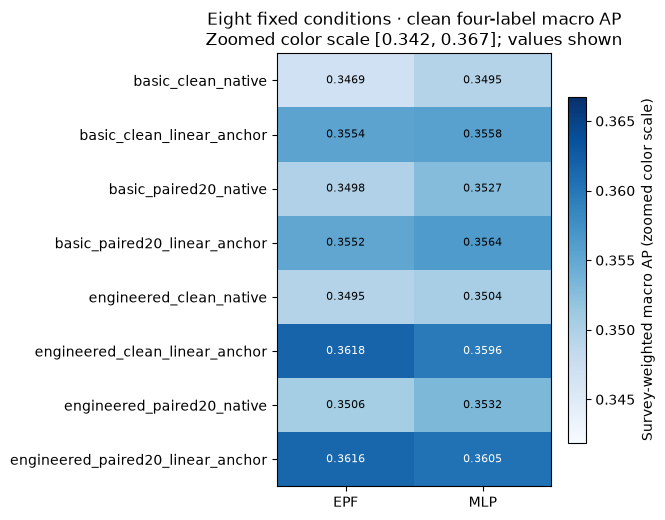

In [10]:

conditions = [f'{basis}_{aug}_{init}'
              for basis in ('basic', 'engineered')
              for aug in ('clean', 'paired20')
              for init in ('native', 'linear_anchor')]
factor = pd.DataFrame({
    family: [M[f'{family}@{condition}']['performance']['clean']['components']['macro_ap']
             for condition in conditions]
    for family in ('EPF', 'MLP')}, index=conditions)
factor.index.name = 'condition'
display(factor.round(6))
fig, ax = plt.subplots(figsize=(6.5, 5.3))
observed_min = float(factor.to_numpy().min())
observed_max = float(factor.to_numpy().max())
margin = max(.005, (observed_max - observed_min) * .1)
color_min = max(0, observed_min - margin)
color_max = min(1, observed_max + margin)
image = ax.imshow(factor.to_numpy(), vmin=color_min, vmax=color_max,
                  cmap='Blues', aspect='auto')
ax.set_xticks(range(2), factor.columns)
ax.set_yticks(range(len(factor)), factor.index)
for i in range(len(factor)):
    for j in range(2):
        value = factor.iat[i, j]
        ink = 'white' if (value - color_min) / (color_max - color_min) > .6 else 'black'
        ax.text(j, i, f'{value:.4f}', ha='center', va='center', fontsize=8, color=ink)
ax.set_title('Eight fixed conditions · clean four-label macro AP\n'
             f'Zoomed color scale [{color_min:.3f}, {color_max:.3f}]; values shown')
fig.colorbar(image, ax=ax, label='Survey-weighted macro AP (zoomed color scale)', shrink=.8)
fig.tight_layout()
plt.show()


## LR의 기본·파생변수 네 조건

각 LR 조건은 clean validation에서 C를 선택한다. 시험 점수로 최적 조건을 고르지 않는다.

In [11]:
names=('LR@basic_clean', 'LR@engineered_clean', 'LR@basic_paired20', 'LR@engineered_paired20')
rows=[]
for name in names:
 p=M[name]['performance'];rows.append({'model':name,'clean_macro_AP':p['clean']['components']['macro_ap'],'clean_macro_Brier':p['clean']['components']['macro_brier'],'clean_raw_any_AP':p['clean']['raw_any']['ap'],'clean_adjusted_any_AP':p['clean']['adjusted_any']['ap'],'missing20_macro_AP':p['missing20']['components']['macro_ap']})
display(pd.DataFrame(rows).set_index('model').round(6))
rows=[]
for aug in ('clean','paired20'):
 for metric in ('component_macro_ap_difference','adjusted_any_ap_difference'):
  row=R['contrasts'][f'factor/LR/basis/{aug}']['metrics'][metric];rows.append({'fit':aug,'metric':metric,'engineered_minus_basic':row['estimate'],'ci_low':row['ci95'][0],'ci_high':row['ci95'][1]})
display(pd.DataFrame(rows).round(6))

,clean_macro_AP,clean_macro_Brier,clean_raw_any_AP,clean_adjusted_any_AP,missing20_macro_AP
model,,,,,
LR@basic_clean,0.357270,0.107409,0.692590,0.689132,0.316833
LR@engineered_clean,0.359473,0.106657,0.695652,0.691302,0.319110
LR@basic_paired20,0.357659,0.107590,0.687480,0.683686,0.336580
LR@engineered_paired20,0.359566,0.106864,0.691686,0.687532,0.339695


,fit,metric,engineered_minus_basic,ci_low,ci_high
0,clean,component_macro_ap_difference,0.002203,-0.003726,0.007822
1,clean,adjusted_any_ap_difference,0.002171,-0.004412,0.008465
2,paired20,component_macro_ap_difference,0.001906,-0.003942,0.007659
3,paired20,adjusted_any_ap_difference,0.003847,-0.002292,0.010115


## 고정 컷오프와 paired PSU 구간

실제 컷오프는 별도 threshold 역할에서 선택했다. 같은 민감도의 시험 ROC 비교는 기술적 지표다.

,risk,target,sensitivity,specificity,referral_rate
0,raw_any,0.9,0.8742,0.4631,0.6651
1,raw_any,0.95,0.9300,0.3176,0.7765
2,adjusted_any,0.9,0.8738,0.4666,0.6628
3,adjusted_any,0.95,0.9300,0.3208,0.7745


Prespecified primary contrasts


,contrast,metric,estimate,ci_low,ci_high
0,EPF − LR basic,component_macro_ap_difference,-0.010410,-0.020556,-0.000433
1,EPF − LR basic,component_brier_improvement,-0.000195,-0.001117,0.000738
2,EPF − LR basic,raw_any_ap_difference,-0.006011,-0.015219,0.003469
3,EPF − LR basic,adjusted_any_ap_difference,-0.007561,-0.016479,0.001632
4,EPF − LR basic,adjusted_any_brier_improvement,-0.000513,-0.002416,0.001375
5,EPF − LR basic,adjusted_any_gap_abs_improvement,0.004104,-0.004601,0.006128
6,EPF − LR basic,matched95_specificity_difference,0.001342,-0.031585,0.025458
7,EPF − MLP,component_macro_ap_difference,-0.002657,-0.011400,0.005573
8,EPF − MLP,component_brier_improvement,-0.000513,-0.001133,0.000104
9,EPF − MLP,raw_any_ap_difference,-0.007168,-0.015848,0.002013


Prespecified factor and interaction contrasts


,contrast,component_AP_diff,component_low,component_high,any_AP_diff,any_low,any_high
0,factor/LR/basis/clean,0.002203,-0.003726,0.007822,0.002171,-0.004412,0.008465
1,factor/LR/basis/paired20,0.001906,-0.003942,0.007659,0.003847,-0.002292,0.010115
2,factor/LR/augmentation/basic,0.000389,-0.003633,0.004086,-0.005446,-0.009889,-0.001162
3,factor/LR/augmentation/engineered,0.000092,-0.004794,0.004350,-0.003770,-0.008668,0.000782
4,interaction/LR/basis_x_augmentation,-0.000297,-0.003002,0.002364,0.001676,-0.000733,0.003885
5,factor/EPF/basis/clean/native,0.002615,-0.003759,0.010119,0.007544,0.000881,0.014055
6,factor/EPF/basis/clean/linear_anchor,0.006372,0.000737,0.011461,0.002393,-0.002787,0.007523
7,factor/EPF/basis/paired20/native,0.000868,-0.005670,0.008070,0.008917,0.002537,0.014857
8,factor/EPF/basis/paired20/linear_anchor,0.006384,-0.000243,0.012224,0.004044,-0.002624,0.010524
9,factor/EPF/augmentation/basic/native,0.002919,-0.002734,0.007941,-0.002524,-0.007428,0.002578


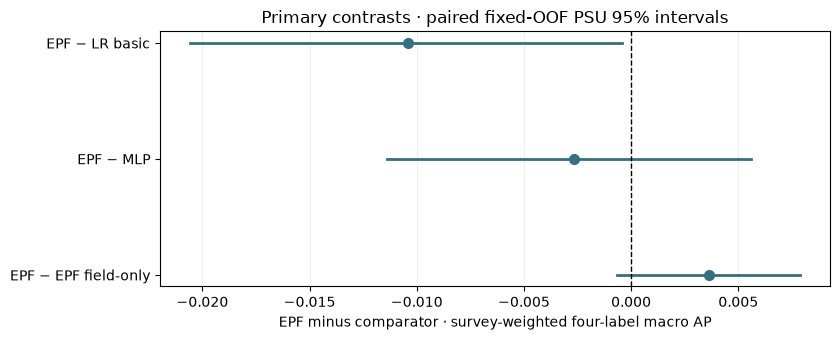

In [12]:

m = M['EPF@basic_clean_native']['performance']
screening = []
for kind, policies in m['screening'].items():
    for policy, views in policies.items():
        screening.append({'risk': kind, 'target': policy, **views['clean']})
display(pd.DataFrame(screening).round(4))

labels = {
    'primary_EPF_vs_LR': 'EPF − LR basic',
    'primary_EPF_vs_MLP': 'EPF − MLP',
    'primary_EPF_vs_field_only': 'EPF − EPF field-only',
}
primary_rows = []
for key, label in labels.items():
    for metric, row in R['contrasts'][key]['metrics'].items():
        primary_rows.append({'contrast': label, 'metric': metric,
                             'estimate': row['estimate'], 'ci_low': row['ci95'][0],
                             'ci_high': row['ci95'][1]})
print('Prespecified primary contrasts')
with pd.option_context('display.max_rows', len(primary_rows)):
    display(pd.DataFrame(primary_rows).round(6))

factor_rows = []
for key, comparison in R['contrasts'].items():
    if key.startswith('primary_'):
        continue
    component = comparison['metrics']['component_macro_ap_difference']
    any_event = comparison['metrics']['adjusted_any_ap_difference']
    factor_rows.append({'contrast': key, 'component_AP_diff': component['estimate'],
                        'component_low': component['ci95'][0], 'component_high': component['ci95'][1],
                        'any_AP_diff': any_event['estimate'],
                        'any_low': any_event['ci95'][0], 'any_high': any_event['ci95'][1]})
print('Prespecified factor and interaction contrasts')
with pd.option_context('display.max_rows', len(factor_rows)):
    display(pd.DataFrame(factor_rows).round(6))

fig, ax = plt.subplots(figsize=(8.5, 3.5))
for i, (key, label) in enumerate(labels.items()):
    row = R['contrasts'][key]['metrics']['component_macro_ap_difference']
    ax.plot(row['ci95'], [i, i], color='#346f82', linewidth=2)
    ax.plot(row['estimate'], i, 'o', color='#346f82', markersize=7)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(range(len(labels)), labels.values())
ax.invert_yaxis()
ax.set_xlabel('EPF minus comparator · survey-weighted four-label macro AP')
ax.set_title('Primary contrasts · paired fixed-OOF PSU 95% intervals')
ax.grid(axis='x', alpha=.2)
fig.tight_layout()
plt.show()


## 다섯 검사 수치와 선별 확장

회귀 전용과 공동 학습은 **basic_clean_native**에서 분류용으로 선택한 backbone 설정을 재사용하지만 별도로 학습했다. 분류·회귀·공동 출력은 각각 4·5·9개이므로 목적함수만 바꾼 비교가 아니다. 혈당·혈압·TG·HDL 실측값은 입력이 아니라 정답이며, TG는 학습에서 log1p, 다섯 수치는 fit 역할의 조사 가중 평균·척도로 표준화한 뒤 원 단위로 되돌려 오차를 계산한다. 아래 4소견 AP는 설명용 점추정이다. 모드 간 paired CI를 새 주대조로 간주하지 않는다.

In [13]:

modes = ('EPF_regression', 'EPF_joint', 'MLP_regression', 'MLP_joint', 'Ridge@basic_clean')
screening_rows = []
numeric_rows = []
for name in modes:
    performance = M[name]['performance']
    screening_rows.append({
        'model': name,
        'clean_four_label_macro_AP': performance['clean']['components']['macro_ap'],
        'clean_adjusted_any_AP': performance['clean']['adjusted_any']['ap'],
        'physical_macro_NMSE': performance['regression']['clean']['macro_NMSE'],
    })
    for row in performance['regression']['clean']['per_target']:
        numeric_rows.append({'model': name, **{key: row[key] for key in
                                             ('target', 'MAE', 'RMSE', 'near_MAE', 'NMSE')}})
print('Basic-clean-native extensions and basic-clean Ridge: descriptive screening scores')
display(pd.DataFrame(screening_rows).set_index('model').round(6))
print('Five measured targets: errors in physical units')
display(pd.DataFrame(numeric_rows).round(4))
print('No paired model-mode contrast was prespecified here; these are descriptive point estimates.')


Basic-clean-native extensions and basic-clean Ridge: descriptive screening scores


,clean_four_label_macro_AP,clean_adjusted_any_AP,physical_macro_NMSE
model,,,
EPF_regression,0.352331,0.680673,0.774541
EPF_joint,0.348976,0.679954,0.771282
MLP_regression,0.362404,0.687955,0.762148
MLP_joint,0.355949,0.689418,0.764107
Ridge@basic_clean,0.358386,0.682968,0.764008


Five measured targets: errors in physical units


,model,target,MAE,RMSE,near_MAE,NMSE
0,EPF_regression,HE_glu,6.4263,12.2938,5.1599,0.9127
1,EPF_regression,HE_sbp,7.1617,9.2787,9.1216,0.6489
2,EPF_regression,HE_dbp,6.0357,7.8201,9.9580,0.7999
3,EPF_regression,HE_TG,41.1825,73.7907,39.8647,0.8279
4,EPF_regression,HE_HDL_st2,9.3284,11.9747,9.5230,0.6834
5,EPF_joint,HE_glu,6.4497,12.2623,5.2382,0.9081
6,EPF_joint,HE_sbp,7.0893,9.2106,9.0471,0.6394
7,EPF_joint,HE_dbp,6.0349,7.8220,10.0154,0.8003
8,EPF_joint,HE_TG,41.2503,73.7798,40.1554,0.8277
9,EPF_joint,HE_HDL_st2,9.3097,11.9546,9.4066,0.6811


No paired model-mode contrast was prespecified here; these are descriptive point estimates.


## 학습 및 계산 자원 집계

학습 가능한 파라미터 수와 실제 업데이트를 함께 본다. 코어 활동은 선택 checkpoint의 clean fit 부분집합 기술값이다. 공유 장치 fit_seconds는 공정한 모델 속도 순위가 아니다.

In [14]:
rows=[]
for name,m in M.items():
 t=m['training'];a=t.get('best_fit_activity',{});rows.append({'model':name,**{k:t.get(k) for k in ('units','fit_seconds_sum','trainable_parameters_min','trainable_parameters_max','initial_model_selected_units','selected_epoch_median','stop_reason_counts','actual_updates_sum','clipped_step_fraction')},**{k:a.get(k) for k in ('event_rate_mean','field_energy_mean','plastic_norm_mean','linear_skip_rms_mean','field_or_mlp_readout_rms_mean')}})
display(pd.DataFrame(rows).set_index('model').round(4))
print('fit_seconds: shared-device execution time; not a fair model speed ranking. Max concurrent tuning workers:',R.get('execution',{}).get('max_concurrent_workers'))

,units,fit_seconds_sum,trainable_parameters_min,trainable_parameters_max,initial_model_selected_units,selected_epoch_median,stop_reason_counts,actual_updates_sum,clipped_step_fraction,event_rate_mean,field_energy_mean,plastic_norm_mean,linear_skip_rms_mean,field_or_mlp_readout_rms_mean
model,,,,,,,,,,,,,,
EPF@basic_clean_native,15,235.1296,4043,16267,0.0,26.0,{'validation_plateau': 15},8166.0,0.0,0.2911,0.0295,0.0957,0.3488,2.6548
MLP@basic_clean_native,15,16.0946,4264,4264,0.0,25.0,{'validation_plateau': 15},4790.0,0.0,NaN,NaN,NaN,0.6355,1.9317
EPF@basic_clean_linear_anchor,15,174.1838,4043,16267,1.0,11.0,{'validation_plateau': 15},5964.0,0.0,0.1834,0.0188,0.0628,2.5040,0.2666
MLP@basic_clean_linear_anchor,15,11.3039,4264,4264,1.0,12.0,{'validation_plateau': 15},3305.0,0.0,NaN,NaN,NaN,2.5161,0.2211
EPF@basic_paired20_native,15,240.5110,4043,16267,0.0,28.0,{'validation_plateau': 15},8281.0,0.0,0.2866,0.0290,0.0965,0.3421,2.6964
MLP@basic_paired20_native,15,17.7641,4264,4264,0.0,23.0,{'validation_plateau': 15},5095.0,0.0,NaN,NaN,NaN,0.6366,1.9546
EPF@basic_paired20_linear_anchor,15,164.3867,4043,16267,3.0,6.0,{'validation_plateau': 15},5700.0,0.0,0.1735,0.0180,0.0578,2.5168,0.1989
MLP@basic_paired20_linear_anchor,15,11.6955,4264,4264,2.0,12.0,{'validation_plateau': 15},3360.0,0.0,NaN,NaN,NaN,2.5279,0.2524
EPF@engineered_clean_native,15,240.2484,4491,17099,0.0,26.0,{'validation_plateau': 15},8334.0,0.0,0.2913,0.0391,0.0947,0.4448,2.4745


fit_seconds: shared-device execution time; not a fair model speed ranking. Max concurrent tuning workers: 2


## 수치 확장의 별도 사후 paired 비교

아래 여섯 대조와 26개 구간은 동결된 clean OOF에서 추가로 계산한 **사후 탐색**이다. 분류 전용은 4개 출력, 수치 전용은 다섯 연속 정답과 5개 출력이며 선택 backbone 설정을 재사용해도 목적함수만 달라진 실험은 아니다. MLP 수치 전용은 MLP 분류 전용보다 4소견 AP가 높았지만 보정 any Brier는 악화됐다. MLP 수치 전용과 Ridge의 macro NMSE 차이 구간은 0을 포함한다. 원래 44개 대조·기본 조건 결론에 합치지 않는다.

In [15]:
E=json.loads('{"version":"clinical_v19_extension_comparison_probe","status":"exploratory_posthoc_not_prespecified_primary","n":4068,"test_rows_unique":4068,"comparison_table":[{"contrast":"MLP_regression_minus_MLP_classification","first_model":"MLP_regression","second_model":"MLP@basic_clean_native","metrics":{"component_macro_ap_difference":{"estimate":0.012887136015806933,"ci95":[0.00374356809723666,0.02140924269034029],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.00040763662290105307,"ci95":[-0.00034247620794993183,0.0011859361685287212],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":4.6404109887432377e-05,"ci95":[-0.00853104457870561,0.008778259646612037],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0024730522770602115,"ci95":[-0.004437559719628093,-0.0004666422207179704],"valid_replicates":2000}}},{"contrast":"EPF_regression_minus_EPF_classification","first_model":"EPF_regression","second_model":"EPF@basic_clean_native","metrics":{"component_macro_ap_difference":{"estimate":0.005470183181590482,"ci95":[-0.00263595758146251,0.014904278496841629],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0002586557859079325,"ci95":[-0.0009733079304676234,0.00046923471412310956],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0008971050717876405,"ci95":[-0.009502460895555866,0.007988033297153458],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.0035299860397471072,"ci95":[-0.005768964542547091,-0.0013535737225741594],"valid_replicates":2000}}},{"contrast":"MLP_regression_minus_Ridge","first_model":"MLP_regression","second_model":"Ridge@basic_clean","metrics":{"component_macro_ap_difference":{"estimate":0.004018234047070912,"ci95":[-0.004749870849690721,0.011856243135365032],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0006872750213751389,"ci95":[0.00010231543218834905,0.0012439896764840188],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":0.0049865764938290535,"ci95":[-0.0019299745955804384,0.011809383785331508],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":0.0020505114635445687,"ci95":[0.0008467174656110035,0.003268109471220706],"valid_replicates":2000},"macro_NMSE_improvement":{"estimate":0.0018594135970079195,"ci95":[-0.002352259509670939,0.005762959706871681],"valid_replicates":2000}}},{"contrast":"EPF_regression_minus_Ridge","first_model":"EPF_regression","second_model":"Ridge@basic_clean","metrics":{"component_macro_ap_difference":{"estimate":-0.00605549329838162,"ci95":[-0.01615885626862809,0.003981023994452518],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0004915974274247031,"ci95":[-0.0012595480802723336,0.00022216154159893073],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.002294726948335102,"ci95":[-0.01355903941553042,0.00845450370412637],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.000638908458437587,"ci95":[-0.002128407672279606,0.0008737512662097697],"valid_replicates":2000},"macro_NMSE_improvement":{"estimate":-0.010533609870818564,"ci95":[-0.016441499432529927,-0.00549695819090689],"valid_replicates":2000}}},{"contrast":"MLP_regression_minus_LR","first_model":"MLP_regression","second_model":"LR@basic_clean","metrics":{"component_macro_ap_difference":{"estimate":0.005133981892388895,"ci95":[-0.005811204073928695,0.014931510272346411],"valid_replicates":2000},"component_brier_improvement":{"estimate":0.0007247671934902944,"ci95":[-0.0002351571637962041,0.0016553208000932016],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.0011770960910186812,"ci95":[-0.00940805773998303,0.0075056116107487325],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.001354048084411863,"ci95":[-0.0031173098742684714,0.0005209959285928654],"valid_replicates":2000}}},{"contrast":"EPF_regression_minus_LR","first_model":"EPF_regression","second_model":"LR@basic_clean","metrics":{"component_macro_ap_difference":{"estimate":-0.0049397454530636375,"ci95":[-0.015869998904821044,0.005287676106452768],"valid_replicates":2000},"component_brier_improvement":{"estimate":-0.0004541052553095476,"ci95":[-0.0014493287236355477,0.0005490374354427644],"valid_replicates":2000},"adjusted_any_ap_difference":{"estimate":-0.008458399533182837,"ci95":[-0.01943006870902995,0.002142442744560751],"valid_replicates":2000},"adjusted_any_brier_improvement":{"estimate":-0.004043468006394019,"ci95":[-0.006202028470843264,-0.0019034800002637566],"valid_replicates":2000}}}],"uncertainty":{"replicates":2000,"rng_seed":202609238,"survey":{"full_frame_psus":768,"domain_psus":699,"strata":108,"singleton_strata":0,"method":"n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"},"scope":"Paired full-frame PSU bootstrap of fixed clean OOF predictions, conditional on fitted models","limits":"Six post-hoc contrasts and 26 displayed intervals have no multiplicity adjustment, full retraining uncertainty, or independent cohort"},"design_limits":"All models use basic clean inputs and the original five PSU test folds. Regression-only NN uses five continuous targets with a 5-output head; classification NN and LR use four binary targets with 4-output heads. The selected NN backbone/config is reused, but the task labels and output structure change, so these contrasts do not identify a pure objective effect. Ridge alpha and LR C were each selected separately on clean validation.","validation":{"frozen_report_point_max_abs_error":3.3306690738754696e-16,"source_manifest_sha256":"116eef71232537cdb143a5b9134ca1eba209d28da68e90c56bef09c6e9f9bddc","frozen_report_sha256":"b820e2c09b3d481a5b2a95a95bf646ce054d410ae4076dc414f190b0769684e9"},"privacy":"Six aggregate fixed-OOF contrasts only; no participant predictions or role indices"}')

rows = []
for comparison in E['comparison_table']:
    for metric, item in comparison['metrics'].items():
        rows.append({'posthoc_contrast': comparison['contrast'],
                     'metric': metric, 'estimate': item['estimate'],
                     'ci_low': item['ci95'][0], 'ci_high': item['ci95'][1],
                     'valid_PSU_replicates': item['valid_replicates']})
print('Six additional post-hoc contrasts; fixed clean OOF, not original primary comparisons')
with pd.option_context('display.max_rows', len(rows)):
    display(pd.DataFrame(rows).round(6))
print('Continuous targets and output dimensions differ from classification-only models.',
      'No multiplicity adjustment, full retraining CI, or external cohort.')


Six additional post-hoc contrasts; fixed clean OOF, not original primary comparisons


,posthoc_contrast,metric,estimate,ci_low,ci_high,valid_PSU_replicates
0,MLP_regression_minus_MLP_classification,component_macro_ap_difference,0.012887,0.003744,0.021409,2000
1,MLP_regression_minus_MLP_classification,component_brier_improvement,0.000408,-0.000342,0.001186,2000
2,MLP_regression_minus_MLP_classification,adjusted_any_ap_difference,0.000046,-0.008531,0.008778,2000
3,MLP_regression_minus_MLP_classification,adjusted_any_brier_improvement,-0.002473,-0.004438,-0.000467,2000
4,EPF_regression_minus_EPF_classification,component_macro_ap_difference,0.005470,-0.002636,0.014904,2000
5,EPF_regression_minus_EPF_classification,component_brier_improvement,-0.000259,-0.000973,0.000469,2000
6,EPF_regression_minus_EPF_classification,adjusted_any_ap_difference,-0.000897,-0.009502,0.007988,2000
7,EPF_regression_minus_EPF_classification,adjusted_any_brier_improvement,-0.003530,-0.005769,-0.001354,2000
8,MLP_regression_minus_Ridge,component_macro_ap_difference,0.004018,-0.004750,0.011856,2000
9,MLP_regression_minus_Ridge,component_brier_improvement,0.000687,0.000102,0.001244,2000


Continuous targets and output dimensions differ from classification-only models. No multiplicity adjustment, full retraining CI, or external cohort.
